<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGGF_intermediate_generation_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Reconstruct coards generation for G0

STEP 2: RECONSTRUCT G0 -> COARSE GENERATION

Using:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub4.npz

Number of G0 cells:
2562

Undirected G0 edges:
7680

G0 degree distribution:
  degree 5: 12 cells
  degree 6: 2550 cells

Pentagonal cells:
12

Selected parent centers:
519

Reduction factor N0/N1:
4.936416184971098

AGGREGATION VALIDATION

All fine cells assigned:
True

Child-count distribution:
  1 children : 21 parents
  2 children : 32 parents
  3 children : 57 parents
  4 children : 74 parents
  5 children : 122 parents
  6 children : 91 parents
  7 children : 122 parents

Minimum children per parent:
1

Maximum children per parent:
7

Mean children per parent:
4.936416184971098

Disconnected aggregates:
0

AREA CONSERVATION

Fine total area:
510099699070761.6

Coarse total area:
510099699070761.6

Absolute area error:
0.0

Relative area error:
0.0

COARSE GRAPH

Number of coarse vertices:
519

Number of coarse edges:
1551

Coarse degree distribution:
  degre

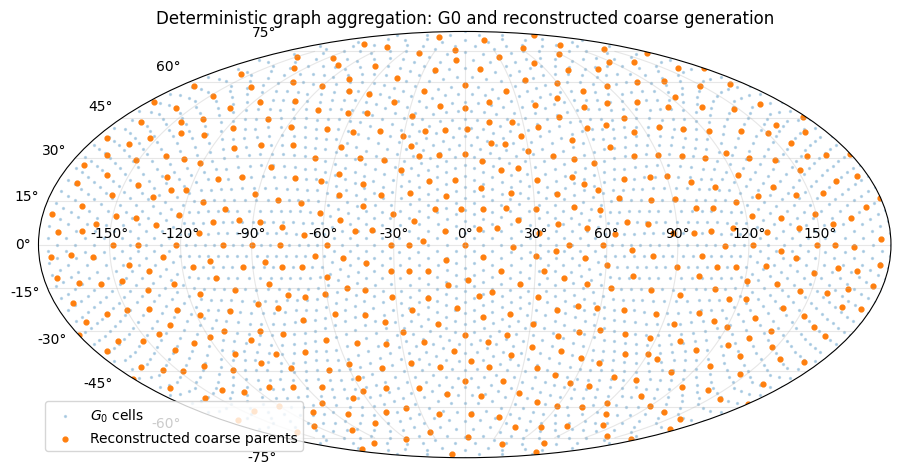


STEP 2 SUMMARY
G0 cells                    : 2562
Selected coarse parents     : 519
Reduction factor            : 4.9364
Minimum children            : 1
Maximum children            : 7
Mean children               : 4.9364
Disconnected aggregates     : 0
Relative area error         : 0.000e+00
Maximum assignment distance : 1
Coarse graph edges          : 1551
Coarse degree range         : 3-9

No files have been overwritten.
STEP 2 COMPLETE.


In [ ]:
# ============================================================
# MGGF intermediate-generation development
#
# STEP 2
#
# Reconstruct a conventional coarse generation from G0
# using deterministic graph aggregation.
#
# Goals:
#   1. Build the G0 cell-adjacency graph.
#   2. Construct connected coarse aggregates.
#   3. Obtain approximately the expected G0 -> G1 reduction.
#   4. Verify complete/nonoverlapping aggregation.
#   5. Verify parent-area conservation.
#   6. Construct coarse graph connectivity.
#   7. Report diagnostics and visualize parent locations.
#
# IMPORTANT:
#   This does NOT overwrite any existing hierarchy files.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from collections import deque, Counter
from scipy.sparse import coo_matrix


# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = os.path.join(PROJECT_ROOT, "grid")

G0_FILE = os.path.join(
    GRID_DIR,
    "global_hex_ico_grid_nsub4.npz"
)

if not os.path.exists(G0_FILE):
    raise FileNotFoundError(G0_FILE)

print("=" * 78)
print("STEP 2: RECONSTRUCT G0 -> COARSE GENERATION")
print("=" * 78)

print("\nUsing:")
print(G0_FILE)


# ============================================================
# Load G0
# ============================================================

g0 = np.load(
    G0_FILE,
    allow_pickle=True
)

area0 = g0["cell_area"].astype(np.float64)

xyz0 = g0["cell_center_xyz"].astype(np.float64)

xyz0 /= np.linalg.norm(
    xyz0,
    axis=1,
    keepdims=True
)

faces = g0["primal_faces"]

N0 = len(area0)

print("\nNumber of G0 cells:")
print(N0)


# ============================================================
# Build G0 adjacency
#
# Each primal triangular face contains three dual cells.
# Each pair of cells belonging to the same primal face
# shares a dual-grid edge.
# ============================================================

edge_set = set()

for face in faces:

    vals = [
        int(v)
        for v in face
        if int(v) >= 0
    ]

    for ia in range(len(vals)):

        for ib in range(ia + 1, len(vals)):

            i = vals[ia]
            j = vals[ib]

            if i == j:
                continue

            edge_set.add(
                (
                    min(i, j),
                    max(i, j)
                )
            )


edges0 = np.asarray(
    sorted(edge_set),
    dtype=np.int64
)

print("\nUndirected G0 edges:")
print(len(edges0))


# ============================================================
# Neighbor lists
# ============================================================

neighbors0 = [
    []
    for _ in range(N0)
]

for i, j in edges0:

    neighbors0[i].append(j)
    neighbors0[j].append(i)

neighbors0 = [
    np.asarray(
        sorted(v),
        dtype=np.int64
    )
    for v in neighbors0
]


degree0 = np.array(
    [
        len(v)
        for v in neighbors0
    ],
    dtype=np.int64
)


print("\nG0 degree distribution:")

for d, n in sorted(
    Counter(degree0).items()
):
    print(
        f"  degree {d}: {n} cells"
    )


# ============================================================
# Sanity checks
# ============================================================

if np.min(degree0) < 5:
    print(
        "\nWARNING: unexpected degree < 5."
    )

if np.max(degree0) > 6:
    print(
        "\nWARNING: unexpected degree > 6."
    )


# ============================================================
# Deterministic parent-center selection
#
# We construct a maximal independent set (MIS):
#
#   - a selected parent cannot be adjacent to another parent;
#   - every unselected node will eventually be associated
#     with a nearby selected parent.
#
# To make the construction deterministic and spatially
# distributed, we start with pentagons and then greedily
# select cells that are not adjacent to an existing parent.
#
# This is a reconstruction experiment. We are NOT yet
# claiming that this is identical to the historical code.
# ============================================================

selected = np.zeros(
    N0,
    dtype=bool
)

blocked = np.zeros(
    N0,
    dtype=bool
)


# ------------------------------------------------------------
# Start with the 12 pentagons
# ------------------------------------------------------------

pentagons = np.where(
    degree0 == 5
)[0]

print("\nPentagonal cells:")
print(len(pentagons))


for p in pentagons:

    if blocked[p]:
        continue

    selected[p] = True
    blocked[p] = True

    for j in neighbors0[p]:
        blocked[j] = True


# ============================================================
# Greedy spatially balanced ordering
#
# Rather than simply scanning index order, choose the
# unblocked node farthest from the current selected set.
#
# For this small graph N=2562 this direct implementation
# is perfectly adequate.
# ============================================================

if np.any(selected):

    parent_xyz = xyz0[selected]

    max_dot = np.max(
        xyz0 @ parent_xyz.T,
        axis=1
    )

else:

    max_dot = np.full(
        N0,
        -1.0
    )


iteration = 0

while np.any(~blocked):

    candidates = np.where(
        ~blocked
    )[0]

    # Smallest max-dot = largest angular distance
    # from current selected parent set.
    k = candidates[
        np.argmin(
            max_dot[candidates]
        )
    ]

    selected[k] = True
    blocked[k] = True

    for j in neighbors0[k]:
        blocked[j] = True

    # Update distance-to-parent diagnostic
    dot_new = xyz0 @ xyz0[k]

    max_dot = np.maximum(
        max_dot,
        dot_new
    )

    iteration += 1


parent_nodes = np.where(
    selected
)[0]

N1 = len(parent_nodes)


print("\nSelected parent centers:")
print(N1)

print("\nReduction factor N0/N1:")
print(N0 / N1)


# ============================================================
# Map selected G0 node -> coarse parent index
# ============================================================

parent_index_from_node = {
    int(node): ip
    for ip, node in enumerate(parent_nodes)
}


# ============================================================
# Assign every fine cell to a selected parent
#
# Parent centers assign to themselves.
#
# Remaining cells are assigned to the closest selected
# parent in GRAPH DISTANCE.
#
# A multi-source BFS guarantees connected graph-distance
# Voronoi regions.
# ============================================================

parent_of = np.full(
    N0,
    -1,
    dtype=np.int64
)

graph_distance = np.full(
    N0,
    -1,
    dtype=np.int64
)

queue = deque()


for ip, node in enumerate(parent_nodes):

    parent_of[node] = ip
    graph_distance[node] = 0

    queue.append(
        int(node)
    )


while queue:

    i = queue.popleft()

    pi = parent_of[i]

    for j in neighbors0[i]:

        if graph_distance[j] < 0:

            graph_distance[j] = (
                graph_distance[i] + 1
            )

            parent_of[j] = pi

            queue.append(
                int(j)
            )

        elif (
            graph_distance[j]
            ==
            graph_distance[i] + 1
        ):

            # Deterministic tie-breaking:
            # choose lower parent index.
            parent_of[j] = min(
                parent_of[j],
                pi
            )


# ============================================================
# Basic aggregation validation
# ============================================================

print("\n" + "=" * 78)
print("AGGREGATION VALIDATION")
print("=" * 78)


if np.any(parent_of < 0):

    bad = np.where(
        parent_of < 0
    )[0]

    raise RuntimeError(
        f"{len(bad)} fine cells were not assigned."
    )


if np.min(parent_of) != 0:

    raise RuntimeError(
        "Parent numbering does not start at zero."
    )


if np.max(parent_of) != N1 - 1:

    raise RuntimeError(
        "Parent numbering is inconsistent."
    )


counts = np.bincount(
    parent_of,
    minlength=N1
)


print("\nAll fine cells assigned:")
print(
    np.sum(counts) == N0
)

print("\nChild-count distribution:")

for nchild, nparent in sorted(
    Counter(counts).items()
):

    print(
        f"  {nchild} children : "
        f"{nparent} parents"
    )


print("\nMinimum children per parent:")
print(np.min(counts))

print("\nMaximum children per parent:")
print(np.max(counts))

print("\nMean children per parent:")
print(np.mean(counts))


# ============================================================
# Verify aggregate connectivity
#
# Each parent's children should form one connected subgraph.
# ============================================================

def aggregate_is_connected(
    members,
    neighbors
):

    members = np.asarray(
        members,
        dtype=np.int64
    )

    if len(members) <= 1:
        return True

    member_set = set(
        int(i)
        for i in members
    )

    start = int(
        members[0]
    )

    visited = {
        start
    }

    q = deque([
        start
    ])

    while q:

        i = q.popleft()

        for j in neighbors[i]:

            jj = int(j)

            if (
                jj in member_set
                and
                jj not in visited
            ):

                visited.add(jj)
                q.append(jj)

    return (
        len(visited)
        ==
        len(member_set)
    )


disconnected = []

for p in range(N1):

    members = np.where(
        parent_of == p
    )[0]

    if not aggregate_is_connected(
        members,
        neighbors0
    ):

        disconnected.append(p)


print("\nDisconnected aggregates:")
print(len(disconnected))


# ============================================================
# Parent areas
# ============================================================

area1 = np.zeros(
    N1,
    dtype=np.float64
)

np.add.at(
    area1,
    parent_of,
    area0
)


area_error = (
    np.sum(area1)
    -
    np.sum(area0)
)


relative_area_error = (
    abs(area_error)
    /
    abs(np.sum(area0))
)


print("\n" + "=" * 78)
print("AREA CONSERVATION")
print("=" * 78)

print("\nFine total area:")
print(
    np.sum(area0)
)

print("\nCoarse total area:")
print(
    np.sum(area1)
)

print("\nAbsolute area error:")
print(
    area_error
)

print("\nRelative area error:")
print(
    relative_area_error
)


# ============================================================
# Coarse cell centers
#
# Area-weighted Cartesian centroid, projected back to sphere.
# ============================================================

xyz1 = np.zeros(
    (N1, 3),
    dtype=np.float64
)

for p in range(N1):

    members = np.where(
        parent_of == p
    )[0]

    vec = np.sum(
        area0[members, None]
        * xyz0[members],
        axis=0
    )

    norm = np.linalg.norm(
        vec
    )

    if norm <= 0.0:
        raise RuntimeError(
            f"Zero centroid norm for parent {p}"
        )

    xyz1[p] = (
        vec / norm
    )


# ============================================================
# Construct coarse graph
#
# Two coarse parents are adjacent whenever at least one
# G0 edge crosses between their aggregates.
# ============================================================

coarse_edge_set = set()


for i, j in edges0:

    pi = int(
        parent_of[i]
    )

    pj = int(
        parent_of[j]
    )

    if pi == pj:
        continue

    coarse_edge_set.add(
        (
            min(pi, pj),
            max(pi, pj)
        )
    )


edges1 = np.asarray(
    sorted(coarse_edge_set),
    dtype=np.int64
)


print("\n" + "=" * 78)
print("COARSE GRAPH")
print("=" * 78)

print("\nNumber of coarse vertices:")
print(N1)

print("\nNumber of coarse edges:")
print(len(edges1))


degree1 = np.zeros(
    N1,
    dtype=np.int64
)

for i, j in edges1:

    degree1[i] += 1
    degree1[j] += 1


print("\nCoarse degree distribution:")

for d, n in sorted(
    Counter(degree1).items()
):

    print(
        f"  degree {d}: {n} vertices"
    )


print("\nCoarse degree range:")
print(
    np.min(degree1),
    "to",
    np.max(degree1)
)


# ============================================================
# Construct sparse restriction membership matrix
#
# H[p,i] = 1 if fine cell i belongs to parent p.
#
# This is NOT yet the final normalized restriction operator.
# It is simply the aggregation/membership matrix.
# ============================================================

rows = parent_of.copy()

cols = np.arange(
    N0,
    dtype=np.int64
)

vals = np.ones(
    N0,
    dtype=np.float64
)


H = coo_matrix(
    (
        vals,
        (rows, cols)
    ),
    shape=(N1, N0)
).tocsr()


print("\nMembership matrix shape:")
print(H.shape)

print("\nMembership matrix nnz:")
print(H.nnz)


# ============================================================
# Graph-distance assignment diagnostics
# ============================================================

print("\n" + "=" * 78)
print("GRAPH-DISTANCE ASSIGNMENT")
print("=" * 78)

for d, n in sorted(
    Counter(graph_distance).items()
):

    print(
        f"  distance {d}: {n} cells"
    )


print("\nMaximum fine-to-parent graph distance:")
print(
    np.max(graph_distance)
)


# ============================================================
# Visualize parent centers
#
# Mollweide projection using parent-center coordinates.
# ============================================================

lon0 = np.arctan2(
    xyz0[:, 1],
    xyz0[:, 0]
)

lat0 = np.arcsin(
    np.clip(
        xyz0[:, 2],
        -1.0,
        1.0
    )
)

lon1 = np.arctan2(
    xyz1[:, 1],
    xyz1[:, 0]
)

lat1 = np.arcsin(
    np.clip(
        xyz1[:, 2],
        -1.0,
        1.0
    )
)


fig = plt.figure(
    figsize=(11, 5.8)
)

ax = fig.add_subplot(
    111,
    projection="mollweide"
)

ax.scatter(
    lon0,
    lat0,
    s=2,
    alpha=0.25,
    label=r"$G_0$ cells"
)

ax.scatter(
    lon1,
    lat1,
    s=12,
    label="Reconstructed coarse parents"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend(
    loc="lower left"
)

ax.set_title(
    "Deterministic graph aggregation: G0 and reconstructed coarse generation"
)

plt.show()


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 78)
print("STEP 2 SUMMARY")
print("=" * 78)

print(
    f"G0 cells                    : {N0}"
)

print(
    f"Selected coarse parents     : {N1}"
)

print(
    f"Reduction factor            : {N0/N1:.4f}"
)

print(
    f"Minimum children            : {np.min(counts)}"
)

print(
    f"Maximum children            : {np.max(counts)}"
)

print(
    f"Mean children               : {np.mean(counts):.4f}"
)

print(
    f"Disconnected aggregates     : {len(disconnected)}"
)

print(
    f"Relative area error         : {relative_area_error:.3e}"
)

print(
    f"Maximum assignment distance : {np.max(graph_distance)}"
)

print(
    f"Coarse graph edges          : {len(edges1)}"
)

print(
    f"Coarse degree range         : "
    f"{np.min(degree1)}-{np.max(degree1)}"
)

print("\nNo files have been overwritten.")
print("STEP 2 COMPLETE.")

# MGGF intermediate generation development

STEP 3: CONSTRUCT INTERMEDIATE GENERATION G0.5

G0 cells: 2562
G0 edges: 7680
G0 degree range: 5 to 6

Computing maximum-cardinality matching...
Matched pairs: 1281
Matched G0 cells: 2562
Unmatched G0 cells: 0

G0.5 AGGREGATION

G0 cells                  : 2562
G0.5 parents              : 1281
Reduction factor N0/N0.5  : 2.000000

Child-count distribution:
  2 children : 1281 parents

Disconnected aggregates: 0

AREA CONSERVATION

G0 total area   : 5.100996990707616e+14
G0.5 total area : 5.100996990707616e+14
Relative error  : 0.000e+00

G0.5 GRAPH

Vertices : 1281
Edges    : 3837
Degree range: 4 to 8

Degree distribution:
  degree 4: 20 vertices
  degree 5: 341 vertices
  degree 6: 583 vertices
  degree 7: 305 vertices
  degree 8: 32 vertices

Connected components: 1

G0.5 AREA STATISTICS

Mean area / mean G0 area: 2.0
Minimum area / mean G0 area: 1.606228240121596
Maximum area / mean G0 area: 2.39269510808316


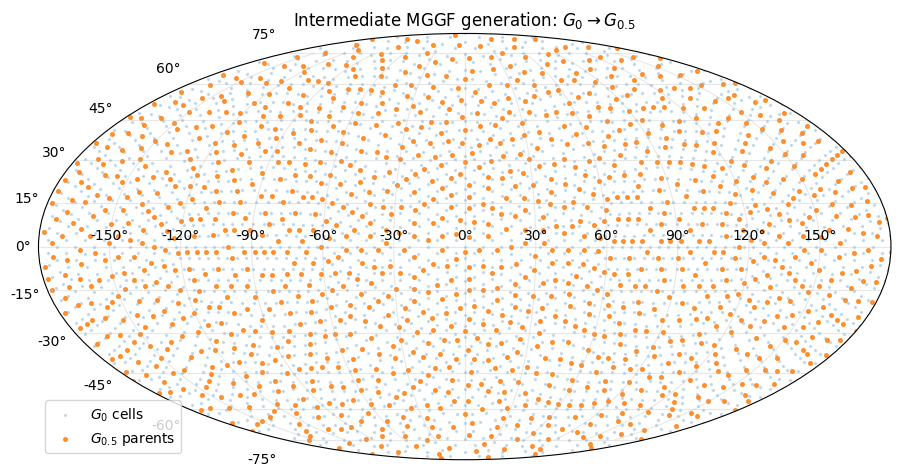


STEP 3 SUMMARY
G0 vertices                 : 2562
G0.5 vertices               : 1281
Reduction factor            : 2.000000
Matched pairs               : 1281
Unmatched cells             : 0
Disconnected aggregates     : 0
Relative area error         : 0.000e+00
G0.5 graph edges            : 3837
G0.5 degree range           : 4-8
Connected components        : 1

No files have been saved.
STEP 3 COMPLETE.


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 3
#
# Construct G0.5 by pairing neighboring G0 cells.
#
# Method:
#   Maximum-cardinality matching on the G0 adjacency graph.
#
# Desired result:
#
#       G0 = 2562
#          |
#          | predominantly 2-cell aggregates
#          v
#       G0.5 ~ 1281
#
# This produces an intermediate physical graph scale between
# G0 and the existing G1 (~642 cells).
#
# No files are saved in this step.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from collections import Counter


# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"

GRID_DIR = os.path.join(
    PROJECT_ROOT,
    "grid"
)

G0_FILE = os.path.join(
    GRID_DIR,
    "global_hex_ico_grid_nsub4.npz"
)


# ============================================================
# Load G0
# ============================================================

g0 = np.load(
    G0_FILE,
    allow_pickle=True
)

area0 = g0["cell_area"].astype(
    np.float64
)

xyz0 = g0["cell_center_xyz"].astype(
    np.float64
)

xyz0 /= np.linalg.norm(
    xyz0,
    axis=1,
    keepdims=True
)

faces = g0["primal_faces"]

N0 = len(area0)


print("=" * 78)
print("STEP 3: CONSTRUCT INTERMEDIATE GENERATION G0.5")
print("=" * 78)

print(
    f"\nG0 cells: {N0}"
)


# ============================================================
# Reconstruct G0 adjacency
# ============================================================

edge_set = set()

for face in faces:

    vals = [
        int(v)
        for v in face
        if int(v) >= 0
    ]

    for ia in range(
        len(vals)
    ):

        for ib in range(
            ia + 1,
            len(vals)
        ):

            i = vals[ia]
            j = vals[ib]

            if i == j:
                continue

            edge_set.add(
                (
                    min(i, j),
                    max(i, j)
                )
            )


edges0 = np.asarray(
    sorted(edge_set),
    dtype=np.int64
)


neighbors0 = [
    []
    for _ in range(N0)
]

for i, j in edges0:

    neighbors0[i].append(
        int(j)
    )

    neighbors0[j].append(
        int(i)
    )


neighbors0 = [
    np.asarray(
        sorted(v),
        dtype=np.int64
    )
    for v in neighbors0
]


degree0 = np.array(
    [
        len(v)
        for v in neighbors0
    ],
    dtype=np.int64
)


print(
    f"G0 edges: {len(edges0)}"
)

print(
    "G0 degree range:",
    np.min(degree0),
    "to",
    np.max(degree0)
)


# ============================================================
# Construct NetworkX graph
# ============================================================

G = nx.Graph()

G.add_nodes_from(
    range(N0)
)

G.add_edges_from(
    [
        (
            int(i),
            int(j)
        )
        for i, j in edges0
    ]
)


# ============================================================
# Maximum-cardinality matching
#
# Every matched edge becomes one G0.5 aggregate.
#
# Because all edges have equal weight, maxcardinality=True
# asks for as many disjoint neighboring pairs as possible.
# ============================================================

print(
    "\nComputing maximum-cardinality matching..."
)

matching = nx.algorithms.matching.max_weight_matching(
    G,
    maxcardinality=True,
    weight=None
)


matching = sorted(
    [
        tuple(
            sorted(
                (
                    int(i),
                    int(j)
                )
            )
        )
        for i, j in matching
    ]
)


print(
    "Matched pairs:",
    len(matching)
)


matched_nodes = set()

for i, j in matching:

    matched_nodes.add(i)
    matched_nodes.add(j)


unmatched = sorted(
    set(
        range(N0)
    )
    -
    matched_nodes
)


print(
    "Matched G0 cells:",
    len(matched_nodes)
)

print(
    "Unmatched G0 cells:",
    len(unmatched)
)


# ============================================================
# Construct parent mapping
#
# First:
#   each matched pair -> one parent
#
# Any unmatched cells initially receive their own parent.
#
# If the matching is perfect, there will be no singletons.
# ============================================================

parent_of = np.full(
    N0,
    -1,
    dtype=np.int64
)


parent_members = []


for pair in matching:

    p = len(
        parent_members
    )

    members = list(
        pair
    )

    parent_members.append(
        members
    )

    for i in members:

        parent_of[i] = p


# ------------------------------------------------------------
# Unmatched cells become singleton aggregates.
# ------------------------------------------------------------

for i in unmatched:

    p = len(
        parent_members
    )

    parent_members.append(
        [int(i)]
    )

    parent_of[i] = p


N05 = len(
    parent_members
)


# ============================================================
# Validate mapping
# ============================================================

if np.any(
    parent_of < 0
):

    raise RuntimeError(
        "Some G0 cells were not assigned."
    )


counts = np.array(
    [
        len(members)
        for members in parent_members
    ],
    dtype=np.int64
)


print("\n" + "=" * 78)
print("G0.5 AGGREGATION")
print("=" * 78)

print(
    f"\nG0 cells                  : {N0}"
)

print(
    f"G0.5 parents              : {N05}"
)

print(
    f"Reduction factor N0/N0.5  : {N0/N05:.6f}"
)


print(
    "\nChild-count distribution:"
)

for nchild, nparent in sorted(
    Counter(counts).items()
):

    print(
        f"  {nchild} children : "
        f"{nparent} parents"
    )


# ============================================================
# Verify all aggregates are connected
#
# Pairs are connected by construction.
# Singletons are trivially connected.
# ============================================================

n_disconnected = 0

for members in parent_members:

    if len(members) <= 1:
        continue

    if len(members) == 2:

        i, j = members

        if j not in neighbors0[i]:

            n_disconnected += 1


print(
    "\nDisconnected aggregates:",
    n_disconnected
)


# ============================================================
# Parent areas
# ============================================================

area05 = np.zeros(
    N05,
    dtype=np.float64
)

np.add.at(
    area05,
    parent_of,
    area0
)


fine_total = np.sum(
    area0
)

coarse_total = np.sum(
    area05
)

relative_area_error = (
    abs(
        coarse_total
        -
        fine_total
    )
    /
    abs(
        fine_total
    )
)


print("\n" + "=" * 78)
print("AREA CONSERVATION")
print("=" * 78)

print(
    f"\nG0 total area   : {fine_total:.15e}"
)

print(
    f"G0.5 total area : {coarse_total:.15e}"
)

print(
    f"Relative error  : {relative_area_error:.3e}"
)


# ============================================================
# G0.5 cell centers
#
# Area-weighted Cartesian mean, projected to sphere.
# ============================================================

xyz05 = np.zeros(
    (
        N05,
        3
    ),
    dtype=np.float64
)


for p, members in enumerate(
    parent_members
):

    members = np.asarray(
        members,
        dtype=np.int64
    )

    vec = np.sum(
        area0[members, None]
        *
        xyz0[members],
        axis=0
    )

    norm = np.linalg.norm(
        vec
    )

    if norm <= 0.0:

        raise RuntimeError(
            f"Bad centroid for parent {p}"
        )

    xyz05[p] = (
        vec
        /
        norm
    )


# ============================================================
# Construct G0.5 graph
#
# Two G0.5 aggregates are neighbors whenever a G0 edge
# connects cells belonging to the two different aggregates.
# ============================================================

edge05_set = set()


for i, j in edges0:

    pi = int(
        parent_of[i]
    )

    pj = int(
        parent_of[j]
    )

    if pi == pj:
        continue

    edge05_set.add(
        (
            min(pi, pj),
            max(pi, pj)
        )
    )


edges05 = np.asarray(
    sorted(edge05_set),
    dtype=np.int64
)


degree05 = np.zeros(
    N05,
    dtype=np.int64
)

for i, j in edges05:

    degree05[i] += 1
    degree05[j] += 1


print("\n" + "=" * 78)
print("G0.5 GRAPH")
print("=" * 78)

print(
    f"\nVertices : {N05}"
)

print(
    f"Edges    : {len(edges05)}"
)

print(
    "Degree range:",
    np.min(degree05),
    "to",
    np.max(degree05)
)


print(
    "\nDegree distribution:"
)

for d, n in sorted(
    Counter(degree05).items()
):

    print(
        f"  degree {d}: {n} vertices"
    )


# ============================================================
# Verify graph connectivity
# ============================================================

G05 = nx.Graph()

G05.add_nodes_from(
    range(N05)
)

G05.add_edges_from(
    [
        (
            int(i),
            int(j)
        )
        for i, j in edges05
    ]
)


n_components = nx.number_connected_components(
    G05
)


print(
    "\nConnected components:",
    n_components
)


# ============================================================
# Parent area statistics
# ============================================================

print("\n" + "=" * 78)
print("G0.5 AREA STATISTICS")
print("=" * 78)

print(
    "\nMean area / mean G0 area:",
    np.mean(area05)
    /
    np.mean(area0)
)

print(
    "Minimum area / mean G0 area:",
    np.min(area05)
    /
    np.mean(area0)
)

print(
    "Maximum area / mean G0 area:",
    np.max(area05)
    /
    np.mean(area0)
)


# ============================================================
# Plot G0 and G0.5 centers
# ============================================================

lon0 = np.arctan2(
    xyz0[:, 1],
    xyz0[:, 0]
)

lat0 = np.arcsin(
    np.clip(
        xyz0[:, 2],
        -1.0,
        1.0
    )
)


lon05 = np.arctan2(
    xyz05[:, 1],
    xyz05[:, 0]
)

lat05 = np.arcsin(
    np.clip(
        xyz05[:, 2],
        -1.0,
        1.0
    )
)


fig = plt.figure(
    figsize=(11, 5.8)
)

ax = fig.add_subplot(
    111,
    projection="mollweide"
)


ax.scatter(
    lon0,
    lat0,
    s=2,
    alpha=0.20,
    label=r"$G_0$ cells"
)


ax.scatter(
    lon05,
    lat05,
    s=7,
    alpha=0.80,
    label=r"$G_{0.5}$ parents"
)


ax.grid(
    True,
    alpha=0.3
)

ax.legend(
    loc="lower left"
)

ax.set_title(
    r"Intermediate MGGF generation: "
    r"$G_0 \rightarrow G_{0.5}$"
)

plt.show()


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 78)
print("STEP 3 SUMMARY")
print("=" * 78)

print(
    f"G0 vertices                 : {N0}"
)

print(
    f"G0.5 vertices               : {N05}"
)

print(
    f"Reduction factor            : {N0/N05:.6f}"
)

print(
    f"Matched pairs               : {len(matching)}"
)

print(
    f"Unmatched cells             : {len(unmatched)}"
)

print(
    f"Disconnected aggregates     : {n_disconnected}"
)

print(
    f"Relative area error         : {relative_area_error:.3e}"
)

print(
    f"G0.5 graph edges            : {len(edges05)}"
)

print(
    f"G0.5 degree range           : "
    f"{np.min(degree05)}-{np.max(degree05)}"
)

print(
    f"Connected components        : {n_components}"
)

print("\nNo files have been saved.")
print("STEP 3 COMPLETE.")

# Checking new generation

In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 4
#
# Rigorous verification of G0.5
#
# Assumes STEP 3 has already been executed and provides:
#
#   N0
#   N05
#   parent_of
#   area0
#   area05
#   xyz0
#   xyz05
#   edges05
#
# Tests:
#
#   A. Hierarchy validity
#      - complete/nonoverlapping aggregation
#      - positive parent areas
#      - exact total-area conservation
#
#   B. Transfer operators
#      - constant preservation by P
#      - constant preservation by R
#      - R P = I
#      - fine -> coarse integral conservation
#      - coarse -> fine integral conservation
#      - weighted adjointness
#
#   C. G0.5 graph Laplacian
#      - symmetry of graph stiffness matrix
#      - constant nullspace
#      - positive semidefiniteness
#      - graph connectedness / single zero mode
#
#   D. Conservative weighted graph operator
#      - weighted self-adjointness
#      - constant nullspace
#      - weighted conservation
#
#   E. Implicit graph filter
#      F = (I + gamma L)^(-1)
#
#      - constant preservation
#      - integrated-magnitude conservation
#      - weighted self-adjointness
#      - positive quadratic form
#
# If all essential tests pass:
#      save G0.5 hierarchy to a NEW NPZ file.
# ============================================================

import os
import numpy as np

from scipy.sparse import (
    coo_matrix,
    csr_matrix,
    diags,
    eye
)

from scipy.sparse.linalg import (
    eigsh,
    splu
)


# ============================================================
# Utility
# ============================================================

def relerr(a, b, eps=1.0e-30):
    return (
        abs(a - b)
        /
        max(
            abs(a),
            abs(b),
            eps
        )
    )


def vec_relerr(a, b, eps=1.0e-30):
    return (
        np.linalg.norm(a - b)
        /
        max(
            np.linalg.norm(a),
            np.linalg.norm(b),
            eps
        )
    )


def weighted_inner(x, y, w):
    return np.dot(
        x,
        w * y
    )


print("=" * 78)
print("STEP 4: RIGOROUS VERIFICATION OF G0.5")
print("=" * 78)


# ============================================================
# Basic prerequisites
# ============================================================

required_names = [
    "N0",
    "N05",
    "parent_of",
    "area0",
    "area05",
    "xyz0",
    "xyz05",
    "edges05",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "STEP 3 objects missing: "
        + ", ".join(missing)
    )


# ============================================================
# A. HIERARCHY VALIDITY
# ============================================================

print("\n" + "=" * 78)
print("A. HIERARCHY VALIDITY")
print("=" * 78)


# ------------------------------------------------------------
# Every fine cell must have exactly one valid parent
# ------------------------------------------------------------

valid_parent_numbers = (
    np.all(parent_of >= 0)
    and
    np.all(parent_of < N05)
)


counts05 = np.bincount(
    parent_of,
    minlength=N05
)


all_cells_accounted = (
    np.sum(counts05) == N0
)


no_empty_parents = (
    np.all(counts05 > 0)
)


all_pairs = (
    np.all(counts05 == 2)
)


positive_parent_areas = (
    np.all(area05 > 0.0)
)


fine_total_area = np.sum(
    area0
)

coarse_total_area = np.sum(
    area05
)


area_conservation_error = (
    abs(
        coarse_total_area
        -
        fine_total_area
    )
    /
    abs(
        fine_total_area
    )
)


print(
    "Valid parent numbering          :",
    valid_parent_numbers
)

print(
    "All fine cells accounted for    :",
    all_cells_accounted
)

print(
    "No empty parents                :",
    no_empty_parents
)

print(
    "Every parent has 2 children     :",
    all_pairs
)

print(
    "All parent areas positive       :",
    positive_parent_areas
)

print(
    "Relative total-area error       :",
    f"{area_conservation_error:.3e}"
)


# ============================================================
# B. TRANSFER OPERATORS
# ============================================================

print("\n" + "=" * 78)
print("B. TRANSFER OPERATORS")
print("=" * 78)


# ------------------------------------------------------------
# Piecewise-constant prolongation
#
# P : G0.5 -> G0
#
# P[i,p] = 1 if fine cell i belongs to parent p.
# ------------------------------------------------------------

rows = np.arange(
    N0,
    dtype=np.int64
)

cols = parent_of.astype(
    np.int64
)

vals = np.ones(
    N0,
    dtype=np.float64
)


P = coo_matrix(
    (
        vals,
        (rows, cols)
    ),
    shape=(
        N0,
        N05
    )
).tocsr()


# ------------------------------------------------------------
# Conservative area-weighted restriction
#
# R = A_c^(-1) P^T A_f
#
# R : G0 -> G0.5
# ------------------------------------------------------------

Af = diags(
    area0
)

Ac = diags(
    area05
)


R = (
    diags(
        1.0 / area05
    )
    @
    P.T
    @
    Af
).tocsr()


print(
    "\nP shape:",
    P.shape,
    "nnz:",
    P.nnz
)

print(
    "R shape:",
    R.shape,
    "nnz:",
    R.nnz
)


# ------------------------------------------------------------
# Constant preservation
# ------------------------------------------------------------

one_f = np.ones(
    N0,
    dtype=np.float64
)

one_c = np.ones(
    N05,
    dtype=np.float64
)


P_const_error = np.max(
    np.abs(
        P @ one_c
        -
        one_f
    )
)


R_const_error = np.max(
    np.abs(
        R @ one_f
        -
        one_c
    )
)


print(
    "\nP constant-preservation error :",
    f"{P_const_error:.3e}"
)

print(
    "R constant-preservation error :",
    f"{R_const_error:.3e}"
)


# ------------------------------------------------------------
# R P should be exactly identity on coarse fields
# ------------------------------------------------------------

RP = (
    R @ P
).tocsr()


I05 = eye(
    N05,
    format="csr"
)


RP_error_matrix = (
    RP - I05
)


if RP_error_matrix.nnz > 0:

    RP_error = np.max(
        np.abs(
            RP_error_matrix.data
        )
    )

else:

    RP_error = 0.0


print(
    "R P - I maximum error          :",
    f"{RP_error:.3e}"
)


# ------------------------------------------------------------
# Random-vector tests
# ------------------------------------------------------------

rng = np.random.default_rng(
    12345
)

xf = rng.standard_normal(
    N0
)

yc = rng.standard_normal(
    N05
)


# Fine -> coarse conservation
Rx = R @ xf

mass_f = np.dot(
    area0,
    xf
)

mass_c = np.dot(
    area05,
    Rx
)

restriction_mass_error = relerr(
    mass_f,
    mass_c
)


# Coarse -> fine conservation
Py = P @ yc

mass_c2 = np.dot(
    area05,
    yc
)

mass_f2 = np.dot(
    area0,
    Py
)

prolongation_mass_error = relerr(
    mass_c2,
    mass_f2
)


print(
    "\nRestriction integral error     :",
    f"{restriction_mass_error:.3e}"
)

print(
    "Prolongation integral error    :",
    f"{prolongation_mass_error:.3e}"
)


# ------------------------------------------------------------
# Weighted adjointness
#
# <P yc, xf>_Af  =  <yc, R xf>_Ac
# ------------------------------------------------------------

lhs = weighted_inner(
    P @ yc,
    xf,
    area0
)

rhs = weighted_inner(
    yc,
    R @ xf,
    area05
)


transfer_adjoint_error = relerr(
    lhs,
    rhs
)


print(
    "Weighted transfer adjoint error:",
    f"{transfer_adjoint_error:.3e}"
)


# ============================================================
# C. GRAPH STIFFNESS / LAPLACIAN
# ============================================================

print("\n" + "=" * 78)
print("C. G0.5 GRAPH LAPLACIAN")
print("=" * 78)


# ------------------------------------------------------------
# Construct symmetric adjacency matrix
# ------------------------------------------------------------

ii = np.concatenate(
    [
        edges05[:, 0],
        edges05[:, 1]
    ]
)

jj = np.concatenate(
    [
        edges05[:, 1],
        edges05[:, 0]
    ]
)

vv = np.ones(
    len(ii),
    dtype=np.float64
)


Adj05 = coo_matrix(
    (
        vv,
        (ii, jj)
    ),
    shape=(
        N05,
        N05
    )
).tocsr()


degree05_float = np.asarray(
    Adj05.sum(axis=1)
).ravel()


K05 = (
    diags(
        degree05_float
    )
    -
    Adj05
).tocsr()


# ------------------------------------------------------------
# Euclidean symmetry
# ------------------------------------------------------------

symdiff = (
    K05
    -
    K05.T
)


if symdiff.nnz > 0:

    K_sym_error = np.max(
        np.abs(
            symdiff.data
        )
    )

else:

    K_sym_error = 0.0


print(
    "K symmetry error               :",
    f"{K_sym_error:.3e}"
)


# ------------------------------------------------------------
# Constant nullspace
# ------------------------------------------------------------

K_const = (
    K05 @ one_c
)


K_const_error = (
    np.linalg.norm(K_const)
    /
    np.sqrt(N05)
)


print(
    "K constant-nullspace residual  :",
    f"{K_const_error:.3e}"
)


# ------------------------------------------------------------
# Lowest eigenvalues
#
# A connected graph should have:
#
# lambda_0 ~ 0
# lambda_1 > 0
# ------------------------------------------------------------

evals = eigsh(
    K05,
    k=6,
    which="SM",
    return_eigenvectors=False,
    tol=1.0e-10
)

evals = np.sort(
    evals
)


print(
    "\nSix smallest eigenvalues:"
)

for k, val in enumerate(
    evals
):

    print(
        f"  lambda[{k}] = {val:.12e}"
    )


min_eig = evals[0]

second_eig = evals[1]


PSD_pass = (
    min_eig > -1.0e-10
)

single_zero_mode = (
    abs(min_eig) < 1.0e-8
    and
    second_eig > 1.0e-8
)


print(
    "\nPositive semidefinite          :",
    PSD_pass
)

print(
    "Single zero mode / connected   :",
    single_zero_mode
)


# ============================================================
# D. CONSERVATIVE WEIGHTED GRAPH OPERATOR
# ============================================================

print("\n" + "=" * 78)
print("D. WEIGHTED GRAPH OPERATOR")
print("=" * 78)


# ------------------------------------------------------------
# Use normalized areas as the graph inner-product weights.
#
# Normalization keeps the graph-smoothing parameter
# dimensionless and numerically well scaled.
#
# W = A / mean(A)
#
# L = W^{-1} K
#
# Then:
#
#     W L = K
#
# which is symmetric.
#
# Therefore L is self-adjoint in the W-weighted inner product.
# ------------------------------------------------------------

w05 = (
    area05
    /
    np.mean(area05)
)


W05 = diags(
    w05
)


Winv05 = diags(
    1.0 / w05
)


L05 = (
    Winv05
    @
    K05
).tocsr()


# ------------------------------------------------------------
# Weighted self-adjointness:
#
# W L should be symmetric.
# ------------------------------------------------------------

WL = (
    W05
    @
    L05
).tocsr()


WLdiff = (
    WL
    -
    WL.T
)


if WLdiff.nnz > 0:

    weighted_L_sym_error = np.max(
        np.abs(
            WLdiff.data
        )
    )

else:

    weighted_L_sym_error = 0.0


print(
    "Weighted L symmetry error      :",
    f"{weighted_L_sym_error:.3e}"
)


# ------------------------------------------------------------
# Constant nullspace
# ------------------------------------------------------------

L_const_error = (
    np.linalg.norm(
        L05 @ one_c
    )
    /
    np.sqrt(N05)
)


print(
    "L constant-nullspace residual  :",
    f"{L_const_error:.3e}"
)


# ------------------------------------------------------------
# Weighted conservation:
#
# 1^T W L x = 0
# ------------------------------------------------------------

xc = rng.standard_normal(
    N05
)


weighted_tendency = np.dot(
    w05,
    L05 @ xc
)


weighted_tendency_scale = (
    np.linalg.norm(w05)
    *
    np.linalg.norm(L05 @ xc)
    +
    1.0e-30
)


L_conservation_error = (
    abs(weighted_tendency)
    /
    weighted_tendency_scale
)


print(
    "L weighted-conservation error :",
    f"{L_conservation_error:.3e}"
)


# ============================================================
# E. IMPLICIT GRAPH FILTER
# ============================================================

print("\n" + "=" * 78)
print("E. IMPLICIT G0.5 GRAPH FILTER")
print("=" * 78)


# ------------------------------------------------------------
# This gamma is ONLY for mathematical verification.
#
# We will determine the scientifically appropriate gamma_0.5
# later from the Gaussian-scale experiment.
# ------------------------------------------------------------

gamma_test = 1.0


M = (
    eye(
        N05,
        format="csc"
    )
    +
    gamma_test
    *
    L05.tocsc()
)


solver = splu(
    M
)


def apply_filter(v):

    return solver.solve(
        np.asarray(
            v,
            dtype=np.float64
        )
    )


# ------------------------------------------------------------
# Constant preservation
# ------------------------------------------------------------

F_one = apply_filter(
    one_c
)


filter_const_error = vec_relerr(
    F_one,
    one_c
)


print(
    "Filter constant error          :",
    f"{filter_const_error:.3e}"
)


# ------------------------------------------------------------
# Weighted integral conservation
# ------------------------------------------------------------

x1 = rng.standard_normal(
    N05
)

Fx1 = apply_filter(
    x1
)


mass_before = np.dot(
    w05,
    x1
)

mass_after = np.dot(
    w05,
    Fx1
)


filter_mass_error = relerr(
    mass_before,
    mass_after
)


print(
    "Filter weighted-mass error     :",
    f"{filter_mass_error:.3e}"
)


# ------------------------------------------------------------
# Weighted self-adjointness of filter
# ------------------------------------------------------------

x2 = rng.standard_normal(
    N05
)

y2 = rng.standard_normal(
    N05
)


Fx2 = apply_filter(
    x2
)

Fy2 = apply_filter(
    y2
)


lhs_F = weighted_inner(
    x2,
    Fy2,
    w05
)

rhs_F = weighted_inner(
    Fx2,
    y2,
    w05
)


filter_adjoint_error = relerr(
    lhs_F,
    rhs_F
)


print(
    "Filter weighted-adjoint error :",
    f"{filter_adjoint_error:.3e}"
)


# ------------------------------------------------------------
# Positive quadratic form
# ------------------------------------------------------------

qF = weighted_inner(
    x2,
    Fx2,
    w05
)


filter_positive = (
    qF > 0.0
)


print(
    "Filter quadratic form          :",
    f"{qF:.12e}"
)

print(
    "Filter positive                :",
    filter_positive
)


# ============================================================
# F. FINAL PASS / FAIL SUMMARY
# ============================================================

print("\n" + "=" * 78)
print("F. FINAL VERIFICATION SUMMARY")
print("=" * 78)


tests = {

    "Valid parent numbering":
        valid_parent_numbers,

    "All fine cells accounted":
        all_cells_accounted,

    "No empty parents":
        no_empty_parents,

    "All aggregates are pairs":
        all_pairs,

    "Positive parent areas":
        positive_parent_areas,

    "Area conservation":
        area_conservation_error < 1.0e-13,

    "P preserves constants":
        P_const_error < 1.0e-13,

    "R preserves constants":
        R_const_error < 1.0e-13,

    "R P = I":
        RP_error < 1.0e-13,

    "Restriction conserves integral":
        restriction_mass_error < 1.0e-12,

    "Prolongation conserves integral":
        prolongation_mass_error < 1.0e-12,

    "Transfers are weighted adjoints":
        transfer_adjoint_error < 1.0e-12,

    "Graph stiffness symmetric":
        K_sym_error < 1.0e-13,

    "Graph constant nullspace":
        K_const_error < 1.0e-12,

    "Graph PSD":
        PSD_pass,

    "Graph has one zero mode":
        single_zero_mode,

    "Weighted L self-adjoint":
        weighted_L_sym_error < 1.0e-12,

    "Weighted L constant nullspace":
        L_const_error < 1.0e-12,

    "Weighted L conservative":
        L_conservation_error < 1.0e-12,

    "Filter preserves constants":
        filter_const_error < 1.0e-11,

    "Filter conserves weighted integral":
        filter_mass_error < 1.0e-11,

    "Filter weighted self-adjoint":
        filter_adjoint_error < 1.0e-11,

    "Filter positive":
        filter_positive,
}


all_pass = True


for name, passed in tests.items():

    status = (
        "PASS"
        if passed
        else
        "FAIL"
    )

    print(
        f"{name:40s} : {status}"
    )

    all_pass = (
        all_pass
        and
        bool(passed)
    )


print("\n" + "-" * 78)

print(
    "OVERALL RESULT:",
    "PASS"
    if all_pass
    else
    "FAIL"
)

print("-" * 78)


# ============================================================
# G. SAVE VERIFIED HIERARCHY
# ============================================================

INTERMEDIATE_DIR = os.path.join(
    PROJECT_ROOT,
    "intermediate_generations"
)

os.makedirs(
    INTERMEDIATE_DIR,
    exist_ok=True
)


SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "mggf_G0p5_pair_hierarchy_v0.npz"
)


if all_pass:

    if os.path.exists(
        SAVE_FILE
    ):

        print(
            "\nVerified hierarchy NOT overwritten."
        )

        print(
            "File already exists:"
        )

        print(
            SAVE_FILE
        )

    else:

        np.savez_compressed(

            SAVE_FILE,

            parent_of_G0=parent_of,

            cell_area_G0=area0,

            cell_area_G0p5=area05,

            cell_center_xyz_G0=xyz0,

            cell_center_xyz_G0p5=xyz05,

            edges_G0p5=edges05,

            child_count_G0p5=counts05,

            N_G0=np.int64(N0),

            N_G0p5=np.int64(N05),
        )


        print(
            "\nVerified hierarchy saved:"
        )

        print(
            SAVE_FILE
        )

else:

    print(
        "\nHierarchy was NOT saved because "
        "one or more verification tests failed."
    )


print("\nSTEP 4 COMPLETE.")

STEP 4: RIGOROUS VERIFICATION OF G0.5

A. HIERARCHY VALIDITY
Valid parent numbering          : True
All fine cells accounted for    : True
No empty parents                : True
Every parent has 2 children     : True
All parent areas positive       : True
Relative total-area error       : 0.000e+00

B. TRANSFER OPERATORS

P shape: (2562, 1281) nnz: 2562
R shape: (1281, 2562) nnz: 2562

P constant-preservation error : 0.000e+00
R constant-preservation error : 2.220e-16
R P - I maximum error          : 2.220e-16

Restriction integral error     : 1.180e-15
Prolongation integral error    : 3.668e-14
Weighted transfer adjoint error: 2.770e-16

C. G0.5 GRAPH LAPLACIAN
K symmetry error               : 0.000e+00
K constant-nullspace residual  : 0.000e+00

Six smallest eigenvalues:
  lambda[0] = 2.759822988613e-15
  lambda[1] = 3.342166856164e-02
  lambda[2] = 3.489210255076e-02
  lambda[3] = 3.672619034278e-02
  lambda[4] = 9.701308146849e-02
  lambda[5] = 1.019029707812e-01

Positive semidefi

# Matching Gaussian with G0, G1/2, G1 and G2

STEP 5: G0 + G1/2 + G1 + G2 GAUSSIAN MATCH

G0 cells: 2562
G1/2 cells: 1281
G0/G1/2 reduction: 2.000000

Available keys in old Gaussian file:
   target_sigmas_km (6,)
   gamma0 ()
   gamma1 ()
   gamma2 ()
   source ()
   source_lon ()
   source_lat ()
   distance_km (2562,)
   C0 (2562,)
   C1 (2562,)
   C2 (2562,)
   scale_integrals (3,)
   original_weights (6, 3)
   optimized_weights (6, 3)
   error_original (6,)
   error_optimized (6,)
   corr_original (6,)
   corr_optimized (6,)
   integral_original (6,)
   integral_optimized (6,)
   optimizer_success (6,)
   optimizer_iterations (6,)

Existing basis responses:
  G0 -> C0
  G1 -> C1
  G2 -> C2

Source G0 cell: 38
Source xyz: [1. 0. 0.]

Target sigma: 1500.0 km
Target discrete integral: 1.0

G1/2 RESPONSE

gamma_1/2: 1.0
G1/2 response integral: 0.999999999999999
G1/2 response min: 1.0450206530353302e-22
G1/2 response max: 5.324526758444205e-13

Basis integrals:
  G0   : 1.003571357347
  G1/2 : 1.000000000000
  G1   : 1.052691999548

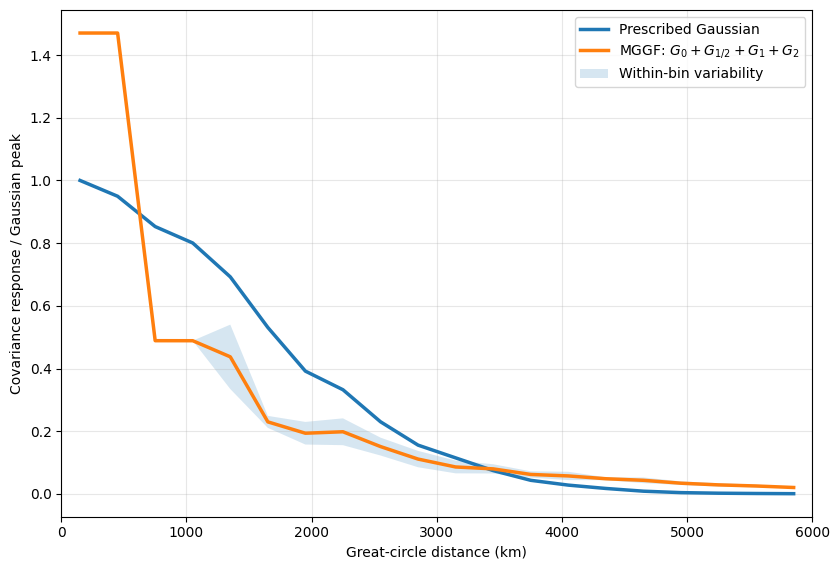

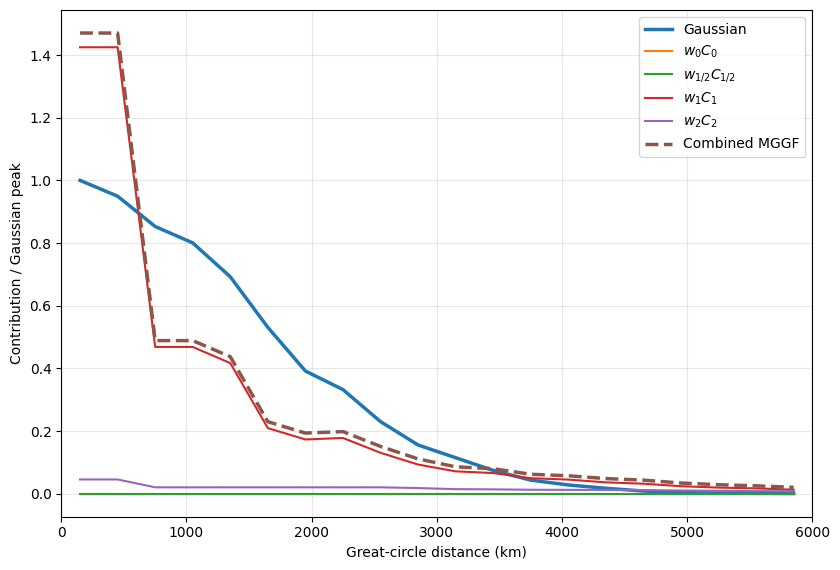

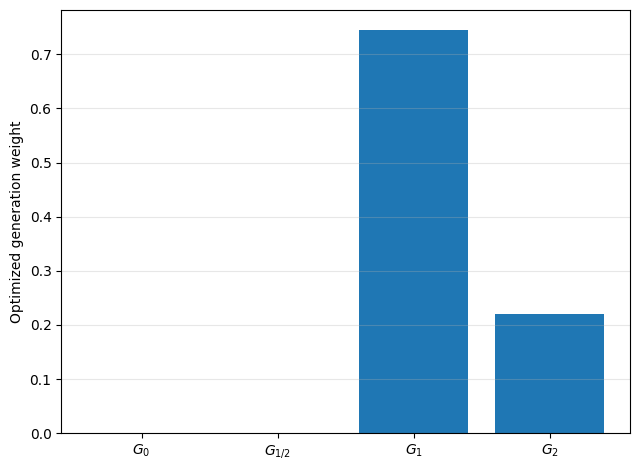


STEP 5 COMPLETE

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/gaussian_sigma1500_G0_G05_G1_G2_v0.npz


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 5
#
# Gaussian matching using
#
#       G0 + G1/2 + G1 + G2
#
# Target:
#       Gaussian sigma = 1500 km
#
# Fixed graph-filter parameters:
#
#       gamma0   = 0.5       [existing response]
#       gamma1/2 = 1.0       [new response]
#       gamma1   = 2.0       [existing response]
#       gamma2   = 6.0       [existing response]
#
# Optimization:
#       nonnegative generation weights
#
# Constraint:
#       exact integrated covariance magnitude
#
# No peak constraint.
#
# Main questions:
#
#   1. Does G1/2 receive substantial weight?
#   2. Does the Gaussian fit improve?
#   3. Does the radial profile improve?
#   4. Is coarse-grid imprint reduced?
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import (
    coo_matrix,
    diags,
    eye
)

from scipy.sparse.linalg import splu
from scipy.optimize import minimize


# ============================================================
# Configuration
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"

GRID_DIR = os.path.join(
    PROJECT_ROOT,
    "grid"
)

FIG_DIR = os.path.join(
    PROJECT_ROOT,
    "paper_figures"
)

INTERMEDIATE_DIR = os.path.join(
    PROJECT_ROOT,
    "intermediate_generations"
)


G0_FILE = os.path.join(
    GRID_DIR,
    "global_hex_ico_grid_nsub4.npz"
)


G05_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "mggf_G0p5_pair_hierarchy_v0.npz"
)


OLD_GAUSS_FILE = os.path.join(
    FIG_DIR,
    "reviewer2_gaussian_series_fixed_gamma_data.npz"
)


SIGMA_KM = 1500.0

EARTH_RADIUS_M = 6371000.0

GAMMA05 = 1.0


print("=" * 78)
print("STEP 5: G0 + G1/2 + G1 + G2 GAUSSIAN MATCH")
print("=" * 78)


# ============================================================
# Load G0 geometry
# ============================================================

g0 = np.load(
    G0_FILE,
    allow_pickle=True
)


area0 = g0["cell_area"].astype(
    np.float64
)

xyz0 = g0["cell_center_xyz"].astype(
    np.float64
)


xyz0 /= np.linalg.norm(
    xyz0,
    axis=1,
    keepdims=True
)


N0 = len(
    area0
)


print(
    f"\nG0 cells: {N0}"
)


# ============================================================
# Load verified G1/2 hierarchy
# ============================================================

if not os.path.exists(
    G05_FILE
):

    raise FileNotFoundError(
        G05_FILE
    )


h05 = np.load(
    G05_FILE,
    allow_pickle=True
)


parent05 = h05[
    "parent_of_G0"
].astype(
    np.int64
)


area05 = h05[
    "cell_area_G0p5"
].astype(
    np.float64
)


xyz05 = h05[
    "cell_center_xyz_G0p5"
].astype(
    np.float64
)


edges05 = h05[
    "edges_G0p5"
].astype(
    np.int64
)


N05 = len(
    area05
)


print(
    f"G1/2 cells: {N05}"
)

print(
    f"G0/G1/2 reduction: {N0/N05:.6f}"
)


# ============================================================
# Load previously saved G0/G1/G2 response data
# ============================================================

if not os.path.exists(
    OLD_GAUSS_FILE
):

    raise FileNotFoundError(
        OLD_GAUSS_FILE
    )


old = np.load(
    OLD_GAUSS_FILE,
    allow_pickle=True
)


print("\nAvailable keys in old Gaussian file:")

for key in old.files:

    print(
        "  ",
        key,
        old[key].shape
    )


# ============================================================
# Flexible response-key finder
#
# We expect three fine-grid basis responses from the previous
# experiment. Try several likely key names.
# ============================================================

def find_array(
    npz,
    aliases,
    expected_size=None
):

    # Exact aliases first
    for name in aliases:

        if name in npz.files:

            arr = np.asarray(
                npz[name]
            ).squeeze()

            if (
                expected_size is None
                or
                arr.size == expected_size
            ):

                return (
                    arr.astype(np.float64),
                    name
                )

    # Case-insensitive aliases
    lower_map = {
        k.lower(): k
        for k in npz.files
    }

    for name in aliases:

        low = name.lower()

        if low in lower_map:

            real_name = lower_map[low]

            arr = np.asarray(
                npz[real_name]
            ).squeeze()

            if (
                expected_size is None
                or
                arr.size == expected_size
            ):

                return (
                    arr.astype(np.float64),
                    real_name
                )

    return None, None


C0, key0 = find_array(
    old,
    [
        "C0",
        "C_0",
        "response0",
        "response_G0",
        "C_G0",
        "basis0",
        "basis_G0",
    ],
    N0
)


C1, key1 = find_array(
    old,
    [
        "C1",
        "C_1",
        "response1",
        "response_G1",
        "C_G1",
        "basis1",
        "basis_G1",
    ],
    N0
)


C2, key2 = find_array(
    old,
    [
        "C2",
        "C_2",
        "response2",
        "response_G2",
        "C_G2",
        "basis2",
        "basis_G2",
    ],
    N0
)


# ============================================================
# If aliases fail, inspect 1-D arrays of length N0.
# ============================================================

if (
    C0 is None
    or C1 is None
    or C2 is None
):

    candidates = []

    for key in old.files:

        arr = np.asarray(
            old[key]
        ).squeeze()

        if (
            arr.ndim == 1
            and
            arr.size == N0
        ):

            candidates.append(
                key
            )


    print(
        "\nCandidate fine-grid arrays:",
        candidates
    )


    if len(candidates) == 3:

        print(
            "\nExactly three N0-length arrays found."
        )

        print(
            "Using them in stored order as C0, C1, C2."
        )

        C0 = np.asarray(
            old[candidates[0]],
            dtype=np.float64
        ).squeeze()

        C1 = np.asarray(
            old[candidates[1]],
            dtype=np.float64
        ).squeeze()

        C2 = np.asarray(
            old[candidates[2]],
            dtype=np.float64
        ).squeeze()

        key0, key1, key2 = candidates

    else:

        raise RuntimeError(
            "\nCould not identify C0/C1/C2 automatically.\n"
            "Please send me the printed key list above and "
            "I will adapt the loader."
        )


print("\nExisting basis responses:")

print(
    "  G0 ->",
    key0
)

print(
    "  G1 ->",
    key1
)

print(
    "  G2 ->",
    key2
)


# ============================================================
# Determine impulse/source cell
#
# For a localized positive covariance response, the maximum
# of the fine-grid G0 response identifies the source cell.
# ============================================================

SOURCE = int(
    np.argmax(
        C0
    )
)


print(
    "\nSource G0 cell:",
    SOURCE
)


print(
    "Source xyz:",
    xyz0[SOURCE]
)


# ============================================================
# Great-circle distances from source
# ============================================================

dot = np.clip(
    xyz0
    @
    xyz0[SOURCE],
    -1.0,
    1.0
)


distance_m = (
    EARTH_RADIUS_M
    *
    np.arccos(
        dot
    )
)


distance_km = (
    distance_m
    /
    1000.0
)


# ============================================================
# Gaussian target
#
# Unit peak initially:
#
# C_G(r) = exp[-r^2/(2 sigma^2)]
#
# Then normalize its discrete area integral to exactly one.
# ============================================================

target = np.exp(
    -0.5
    *
    (
        distance_km
        /
        SIGMA_KM
    )**2
)


target_integral_raw = np.sum(
    area0
    *
    target
)


target /= (
    target_integral_raw
)


print(
    "\nTarget sigma:",
    SIGMA_KM,
    "km"
)

print(
    "Target discrete integral:",
    np.sum(
        area0
        *
        target
    )
)


# ============================================================
# Construct G0 -> G1/2 transfer operators
# ============================================================

rows = np.arange(
    N0,
    dtype=np.int64
)

cols = parent05

vals = np.ones(
    N0,
    dtype=np.float64
)


P05 = coo_matrix(
    (
        vals,
        (rows, cols)
    ),
    shape=(
        N0,
        N05
    )
).tocsr()


R05 = (
    diags(
        1.0 / area05
    )
    @
    P05.T
    @
    diags(
        area0
    )
).tocsr()


# ============================================================
# Construct G1/2 graph Laplacian
#
# Same conservative weighted formulation verified in STEP 4.
# ============================================================

ii = np.concatenate(
    [
        edges05[:, 0],
        edges05[:, 1]
    ]
)

jj = np.concatenate(
    [
        edges05[:, 1],
        edges05[:, 0]
    ]
)


Adj05 = coo_matrix(
    (
        np.ones(
            len(ii),
            dtype=np.float64
        ),
        (ii, jj)
    ),
    shape=(
        N05,
        N05
    )
).tocsr()


degree05 = np.asarray(
    Adj05.sum(
        axis=1
    )
).ravel()


K05 = (
    diags(
        degree05
    )
    -
    Adj05
).tocsr()


# Normalized area weights
warea05 = (
    area05
    /
    np.mean(
        area05
    )
)


L05 = (
    diags(
        1.0 / warea05
    )
    @
    K05
).tocsr()


# ============================================================
# Construct G1/2 basis response
#
# Start from the SAME unit-area G0 impulse:
#
# delta_i = 1/A_source at source
#
# Restrict -> filter on G1/2 -> prolong back to G0.
# ============================================================

impulse0 = np.zeros(
    N0,
    dtype=np.float64
)

impulse0[SOURCE] = (
    1.0
    /
    area0[SOURCE]
)


impulse05 = (
    R05
    @
    impulse0
)


M05 = (
    eye(
        N05,
        format="csc"
    )
    +
    GAMMA05
    *
    L05.tocsc()
)


solver05 = splu(
    M05
)


response05_coarse = solver05.solve(
    impulse05
)


C05 = (
    P05
    @
    response05_coarse
)


# ============================================================
# Check G1/2 basis integral
# ============================================================

I05 = np.sum(
    area0
    *
    C05
)


print("\n" + "=" * 78)
print("G1/2 RESPONSE")
print("=" * 78)

print(
    "\ngamma_1/2:",
    GAMMA05
)

print(
    "G1/2 response integral:",
    f"{I05:.15f}"
)

print(
    "G1/2 response min:",
    np.min(C05)
)

print(
    "G1/2 response max:",
    np.max(C05)
)


# ============================================================
# Basis integrals
# ============================================================

I0 = np.sum(
    area0
    *
    C0
)

I1 = np.sum(
    area0
    *
    C1
)

I2 = np.sum(
    area0
    *
    C2
)


basis_integrals = np.array(
    [
        I0,
        I05,
        I1,
        I2
    ],
    dtype=np.float64
)


print("\nBasis integrals:")

print(
    f"  G0   : {I0:.12f}"
)

print(
    f"  G1/2 : {I05:.12f}"
)

print(
    f"  G1   : {I1:.12f}"
)

print(
    f"  G2   : {I2:.12f}"
)


# ============================================================
# Stack basis vectors
# ============================================================

B = np.column_stack(
    [
        C0,
        C05,
        C1,
        C2
    ]
)


# ============================================================
# Area-weighted objective
#
# J =
#
#   sum A_i (Cfit-Ctarget)^2
#   ------------------------
#   sum A_i Ctarget^2
#
# Exact magnitude constraint:
#
#   sum_g I_g w_g = 1
# ============================================================

target_norm2 = np.sum(
    area0
    *
    target**2
)


def objective(weights):

    fit = (
        B
        @
        weights
    )

    residual = (
        fit
        -
        target
    )

    return (
        np.sum(
            area0
            *
            residual**2
        )
        /
        target_norm2
    )


def magnitude_constraint(weights):

    return (
        np.dot(
            basis_integrals,
            weights
        )
        -
        1.0
    )


# ============================================================
# Initial weights
#
# Start near previous three-generation solution:
#
#   old:
#       w0 ~ 0
#       w1 ~ 0.7445
#       w2 ~ 0.2205
#
# Give G1/2 a modest initial contribution.
# ============================================================

w_init = np.array(
    [
        0.05,
        0.25,
        0.50,
        0.20
    ],
    dtype=np.float64
)


# Normalize initial weights to exact integrated magnitude
w_init /= np.dot(
    basis_integrals,
    w_init
)


constraints = [
    {
        "type": "eq",
        "fun": magnitude_constraint
    }
]


bounds = [
    (0.0, None),
    (0.0, None),
    (0.0, None),
    (0.0, None),
]


result = minimize(
    objective,
    w_init,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1.0e-13,
        "maxiter": 5000,
        "disp": True
    }
)


if not result.success:

    print(
        "\nWARNING: optimizer message:"
    )

    print(
        result.message
    )


weights = result.x


w0_opt = weights[0]
w05_opt = weights[1]
w1_opt = weights[2]
w2_opt = weights[3]


fit = (
    B
    @
    weights
)


# ============================================================
# Metrics
# ============================================================

residual = (
    fit
    -
    target
)


E_L2 = np.sqrt(
    np.sum(
        area0
        *
        residual**2
    )
    /
    target_norm2
)


# Area-weighted pattern correlation
def weighted_correlation(
    x,
    y,
    area
):

    w = (
        area
        /
        np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    dx = x - mx
    dy = y - my

    numerator = np.sum(
        w
        *
        dx
        *
        dy
    )

    denominator = np.sqrt(
        np.sum(
            w
            *
            dx**2
        )
        *
        np.sum(
            w
            *
            dy**2
        )
    )

    return (
        numerator
        /
        denominator
    )


rho = weighted_correlation(
    fit,
    target,
    area0
)


fit_integral = np.sum(
    area0
    *
    fit
)


peak_ratio = (
    np.max(fit)
    /
    np.max(target)
)


print("\n" + "=" * 78)
print("FOUR-GENERATION GAUSSIAN FIT")
print("=" * 78)

print(
    "\nOptimization success:",
    result.success
)

print(
    "\nOptimized weights:"
)

print(
    f"  w0   = {w0_opt:.12f}"
)

print(
    f"  w1/2 = {w05_opt:.12f}"
)

print(
    f"  w1   = {w1_opt:.12f}"
)

print(
    f"  w2   = {w2_opt:.12f}"
)


print(
    "\nIntegrated magnitude:",
    f"{fit_integral:.15f}"
)

print(
    "Relative area-weighted L2:",
    f"{E_L2:.12f}"
)

print(
    "Area-weighted correlation:",
    f"{rho:.12f}"
)

print(
    "Peak ratio MGGF/Gaussian:",
    f"{peak_ratio:.12f}"
)


# ============================================================
# Compare against previous three-generation fit
#
# Values from our established sigma=1500 km experiment:
#
# E_L2 = 0.4826007712
# rho  = 0.8761983155
# ============================================================

E_OLD = 0.4826007712423832

RHO_OLD = 0.8761983155298049


print("\n" + "=" * 78)
print("COMPARISON WITH PREVIOUS G0 + G1 + G2 FIT")
print("=" * 78)


print(
    "\nOld E_L2:",
    f"{E_OLD:.12f}"
)

print(
    "New E_L2:",
    f"{E_L2:.12f}"
)

print(
    "Relative E_L2 improvement:",
    f"{100.0*(E_OLD-E_L2)/E_OLD:.3f} %"
)


print(
    "\nOld rho:",
    f"{RHO_OLD:.12f}"
)

print(
    "New rho:",
    f"{rho:.12f}"
)

print(
    "rho increase:",
    f"{rho-RHO_OLD:.12f}"
)


# ============================================================
# Radial averages
# ============================================================

BIN_WIDTH_KM = 300.0

RMAX_KM = 6000.0


bin_edges = np.arange(
    0.0,
    RMAX_KM + BIN_WIDTH_KM,
    BIN_WIDTH_KM
)


bin_centers = 0.5 * (
    bin_edges[:-1]
    +
    bin_edges[1:]
)


rad_target = np.full(
    len(bin_centers),
    np.nan
)

rad_fit = np.full(
    len(bin_centers),
    np.nan
)

rad_C0 = np.full(
    len(bin_centers),
    np.nan
)

rad_C05 = np.full(
    len(bin_centers),
    np.nan
)

rad_C1 = np.full(
    len(bin_centers),
    np.nan
)

rad_C2 = np.full(
    len(bin_centers),
    np.nan
)

rad_std_fit = np.full(
    len(bin_centers),
    np.nan
)


for k in range(
    len(bin_centers)
):

    mask = (
        (distance_km >= bin_edges[k])
        &
        (distance_km < bin_edges[k + 1])
    )

    if not np.any(mask):
        continue

    # Area-weighted radial means
    aa = area0[mask]

    aa_sum = np.sum(
        aa
    )

    rad_target[k] = np.sum(
        aa
        *
        target[mask]
    ) / aa_sum

    rad_fit[k] = np.sum(
        aa
        *
        fit[mask]
    ) / aa_sum

    rad_C0[k] = np.sum(
        aa
        *
        C0[mask]
    ) / aa_sum

    rad_C05[k] = np.sum(
        aa
        *
        C05[mask]
    ) / aa_sum

    rad_C1[k] = np.sum(
        aa
        *
        C1[mask]
    ) / aa_sum

    rad_C2[k] = np.sum(
        aa
        *
        C2[mask]
    ) / aa_sum

    rad_std_fit[k] = np.sqrt(
        np.sum(
            aa
            *
            (
                fit[mask]
                -
                rad_fit[k]
            )**2
        )
        /
        aa_sum
    )


# ============================================================
# Normalize radial curves by Gaussian peak
# ============================================================

target_peak = np.max(
    target
)


# ============================================================
# FIGURE 1:
# Gaussian target vs new four-generation fit
# ============================================================

plt.figure(
    figsize=(8.5, 5.8)
)


plt.plot(
    bin_centers,
    rad_target / target_peak,
    linewidth=2.5,
    label="Prescribed Gaussian"
)


plt.plot(
    bin_centers,
    rad_fit / target_peak,
    linewidth=2.5,
    label=r"MGGF: $G_0+G_{1/2}+G_1+G_2$"
)


plt.fill_between(
    bin_centers,
    (
        rad_fit
        -
        rad_std_fit
    )
    /
    target_peak,
    (
        rad_fit
        +
        rad_std_fit
    )
    /
    target_peak,
    alpha=0.18,
    label="Within-bin variability"
)


plt.xlabel(
    "Great-circle distance (km)"
)

plt.ylabel(
    "Covariance response / Gaussian peak"
)

plt.xlim(
    0,
    RMAX_KM
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# FIGURE 2:
# Contributions from individual generations
# ============================================================

plt.figure(
    figsize=(8.5, 5.8)
)


plt.plot(
    bin_centers,
    rad_target / target_peak,
    linewidth=2.5,
    label="Gaussian"
)


plt.plot(
    bin_centers,
    w0_opt * rad_C0 / target_peak,
    label=r"$w_0 C_0$"
)


plt.plot(
    bin_centers,
    w05_opt * rad_C05 / target_peak,
    label=r"$w_{1/2} C_{1/2}$"
)


plt.plot(
    bin_centers,
    w1_opt * rad_C1 / target_peak,
    label=r"$w_1 C_1$"
)


plt.plot(
    bin_centers,
    w2_opt * rad_C2 / target_peak,
    label=r"$w_2 C_2$"
)


plt.plot(
    bin_centers,
    rad_fit / target_peak,
    linewidth=2.5,
    linestyle="--",
    label="Combined MGGF"
)


plt.xlabel(
    "Great-circle distance (km)"
)

plt.ylabel(
    "Contribution / Gaussian peak"
)

plt.xlim(
    0,
    RMAX_KM
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# FIGURE 3:
# Weight bar plot
# ============================================================

labels = [
    r"$G_0$",
    r"$G_{1/2}$",
    r"$G_1$",
    r"$G_2$"
]


plt.figure(
    figsize=(6.5, 4.8)
)


plt.bar(
    labels,
    weights
)


plt.ylabel(
    "Optimized generation weight"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Save experiment results
# ============================================================

SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "gaussian_sigma1500_G0_G05_G1_G2_v0.npz"
)


np.savez_compressed(

    SAVE_FILE,

    sigma_km=np.float64(
        SIGMA_KM
    ),

    gamma05=np.float64(
        GAMMA05
    ),

    source_G0=np.int64(
        SOURCE
    ),

    distance_km=distance_km,

    target=target,

    C0=C0,

    C05=C05,

    C1=C1,

    C2=C2,

    weights=weights,

    fit=fit,

    E_L2=np.float64(
        E_L2
    ),

    rho=np.float64(
        rho
    ),

    peak_ratio=np.float64(
        peak_ratio
    ),

    integral=np.float64(
        fit_integral
    ),

    bin_centers_km=bin_centers,

    radial_target=rad_target,

    radial_fit=rad_fit,

    radial_std_fit=rad_std_fit,
)


print("\n" + "=" * 78)
print("STEP 5 COMPLETE")
print("=" * 78)

print(
    "\nSaved:"
)

print(
    SAVE_FILE
)

STEP 6: SWEEP gamma_{1/2}

------------------------------------------------------------------------------
gamma_1/2 = 0.5
  success      = True
  I_G1/2       = 1.000000000000
  w0           = 0.000000000000
  w1/2         = 0.000000000000
  w1           = 0.744516454816
  w2           = 0.220506162372
  E_L2         = 0.482600771242
  rho          = 0.868643654594
  peak ratio   = 1.470395565164
  integral     = 1.000000000000000

------------------------------------------------------------------------------
gamma_1/2 = 1
  success      = True
  I_G1/2       = 1.000000000000
  w0           = 0.000000000000
  w1/2         = 0.000000000000
  w1           = 0.744516451277
  w2           = 0.220506166170
  E_L2         = 0.482600771242
  rho          = 0.868643654697
  peak ratio   = 1.470395559172
  integral     = 1.000000000000000

------------------------------------------------------------------------------
gamma_1/2 = 2
  success      = True
  I_G1/2       = 1.000000000000
  w0      

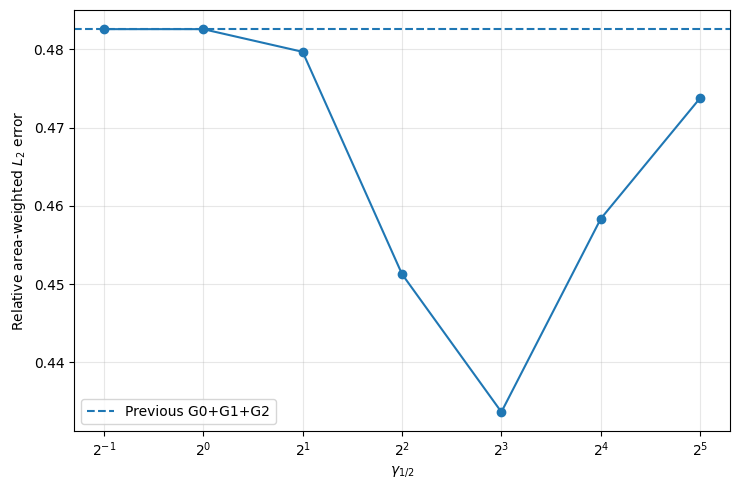

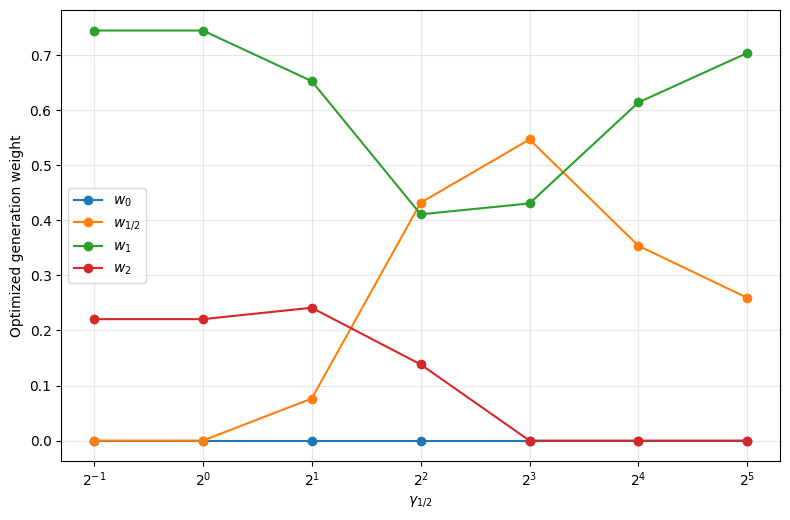

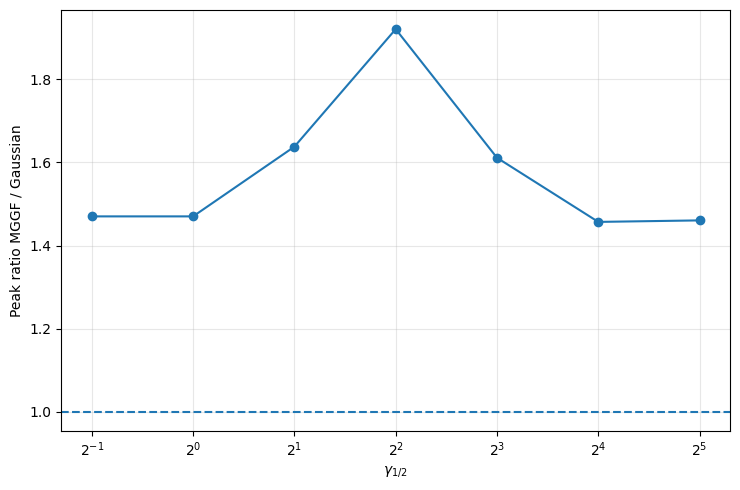

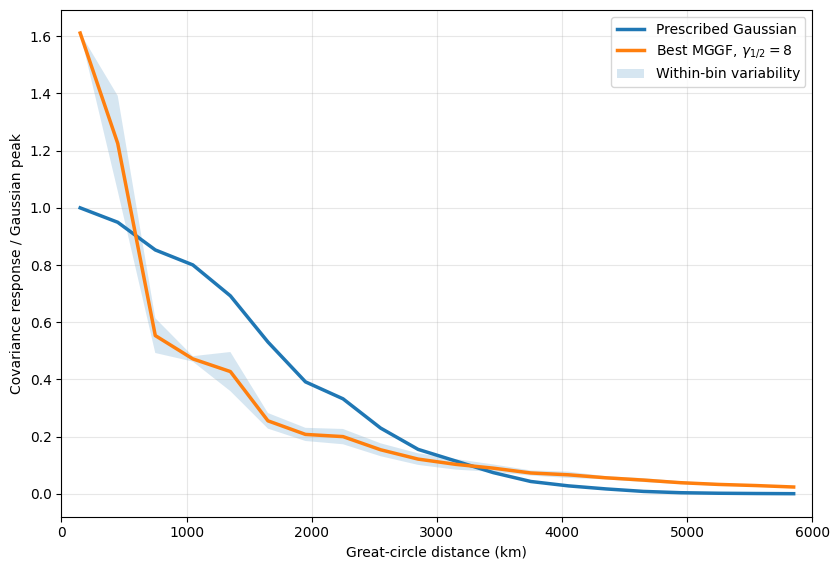


STEP 6 COMPLETE

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/gaussian_sigma1500_gamma05_sweep_v0.npz


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 6
#
# Sweep gamma_{1/2} for the new intermediate generation.
#
# Fixed:
#   C0 : existing G0 response, gamma0 = 0.5
#   C1 : existing G1 response, gamma1 = 2.0
#   C2 : existing G2 response, gamma2 = 6.0
#
# Varied:
#   gamma_{1/2} = 0.5, 1, 2, 4, 8, 16, 32
#
# For every gamma_{1/2}:
#   - construct C_{1/2}
#   - optimize nonnegative weights
#   - enforce exact integrated covariance magnitude
#   - compute E_L2
#   - compute peak ratio
#
# Goal:
#   Determine whether the intermediate generation becomes
#   useful at an appropriate graph-filter strength.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import eye
from scipy.sparse.linalg import splu
from scipy.optimize import minimize


print("=" * 78)
print("STEP 6: SWEEP gamma_{1/2}")
print("=" * 78)


# ============================================================
# Required objects from STEP 5
# ============================================================

required = [
    "N0",
    "N05",
    "area0",
    "area05",
    "P05",
    "R05",
    "L05",
    "impulse0",
    "C0",
    "C1",
    "C2",
    "target",
    "target_norm2",
    "I0",
    "I1",
    "I2",
    "SIGMA_KM",
    "INTERMEDIATE_DIR",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing STEP 5 objects: "
        + ", ".join(missing)
    )


# ============================================================
# Configuration
# ============================================================

gamma05_values = np.array(
    [
        0.5,
        1.0,
        2.0,
        4.0,
        8.0,
        16.0,
        32.0,
    ],
    dtype=np.float64
)


# ============================================================
# Helper: weighted correlation
#
# This is included for internal comparison.
# The primary metric for this sweep is E_L2.
# ============================================================

def weighted_correlation(
    x,
    y,
    area
):

    w = (
        area
        /
        np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    dx = x - mx
    dy = y - my

    num = np.sum(
        w * dx * dy
    )

    den = np.sqrt(
        np.sum(
            w * dx**2
        )
        *
        np.sum(
            w * dy**2
        )
    )

    return num / den


# ============================================================
# Helper: build C1/2 for chosen gamma
# ============================================================

impulse05 = (
    R05
    @
    impulse0
)


def build_C05(gamma05):

    M05 = (
        eye(
            N05,
            format="csc"
        )
        +
        gamma05
        *
        L05.tocsc()
    )

    solver = splu(
        M05
    )

    response05_coarse = solver.solve(
        impulse05
    )

    C05 = (
        P05
        @
        response05_coarse
    )

    return np.asarray(
        C05,
        dtype=np.float64
    ).ravel()


# ============================================================
# Storage
# ============================================================

ncase = len(
    gamma05_values
)

weights_all = np.zeros(
    (
        ncase,
        4
    ),
    dtype=np.float64
)

E_all = np.zeros(
    ncase,
    dtype=np.float64
)

rho_all = np.zeros(
    ncase,
    dtype=np.float64
)

peak_all = np.zeros(
    ncase,
    dtype=np.float64
)

integral_all = np.zeros(
    ncase,
    dtype=np.float64
)

I05_all = np.zeros(
    ncase,
    dtype=np.float64
)

success_all = np.zeros(
    ncase,
    dtype=bool
)

iterations_all = np.zeros(
    ncase,
    dtype=np.int64
)

C05_all = np.zeros(
    (
        ncase,
        N0
    ),
    dtype=np.float64
)


# ============================================================
# Previous reference result
# ============================================================

E_OLD = 0.4826007712423832


# ============================================================
# Sweep
# ============================================================

for icase, gamma05 in enumerate(
    gamma05_values
):

    print("\n" + "-" * 78)

    print(
        f"gamma_1/2 = {gamma05:g}"
    )

    # --------------------------------------------------------
    # Construct intermediate-generation basis response
    # --------------------------------------------------------

    C05 = build_C05(
        gamma05
    )

    C05_all[
        icase,
        :
    ] = C05


    I05 = np.sum(
        area0
        *
        C05
    )

    I05_all[
        icase
    ] = I05


    # --------------------------------------------------------
    # Four basis functions
    # --------------------------------------------------------

    B = np.column_stack(
        [
            C0,
            C05,
            C1,
            C2
        ]
    )


    basis_integrals = np.array(
        [
            I0,
            I05,
            I1,
            I2
        ],
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Objective
    # --------------------------------------------------------

    def objective(weights):

        fit = (
            B
            @
            weights
        )

        residual = (
            fit
            -
            target
        )

        return (
            np.sum(
                area0
                *
                residual**2
            )
            /
            target_norm2
        )


    # --------------------------------------------------------
    # Exact integrated-magnitude constraint
    # --------------------------------------------------------

    def constraint_mag(weights):

        return (
            np.dot(
                basis_integrals,
                weights
            )
            -
            1.0
        )


    # --------------------------------------------------------
    # Initial guess
    #
    # Start from the old optimum but give the new level a
    # small positive contribution.
    # --------------------------------------------------------

    w_init = np.array(
        [
            0.02,
            0.10,
            0.65,
            0.20
        ],
        dtype=np.float64
    )


    w_init /= np.dot(
        basis_integrals,
        w_init
    )


    result = minimize(

        objective,

        w_init,

        method="SLSQP",

        bounds=[
            (0.0, None),
            (0.0, None),
            (0.0, None),
            (0.0, None),
        ],

        constraints=[
            {
                "type": "eq",
                "fun": constraint_mag
            }
        ],

        options={
            "ftol": 1.0e-13,
            "maxiter": 5000,
            "disp": False
        }
    )


    weights = result.x

    fit = (
        B
        @
        weights
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    residual = (
        fit
        -
        target
    )


    E_L2 = np.sqrt(
        np.sum(
            area0
            *
            residual**2
        )
        /
        target_norm2
    )


    rho = weighted_correlation(
        fit,
        target,
        area0
    )


    peak_ratio = (
        np.max(fit)
        /
        np.max(target)
    )


    integral = np.sum(
        area0
        *
        fit
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    weights_all[
        icase,
        :
    ] = weights

    E_all[
        icase
    ] = E_L2

    rho_all[
        icase
    ] = rho

    peak_all[
        icase
    ] = peak_ratio

    integral_all[
        icase
    ] = integral

    success_all[
        icase
    ] = result.success

    iterations_all[
        icase
    ] = result.nit


    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print(
        f"  success      = {result.success}"
    )

    print(
        f"  I_G1/2       = {I05:.12f}"
    )

    print(
        f"  w0           = {weights[0]:.12f}"
    )

    print(
        f"  w1/2         = {weights[1]:.12f}"
    )

    print(
        f"  w1           = {weights[2]:.12f}"
    )

    print(
        f"  w2           = {weights[3]:.12f}"
    )

    print(
        f"  E_L2         = {E_L2:.12f}"
    )

    print(
        f"  rho          = {rho:.12f}"
    )

    print(
        f"  peak ratio   = {peak_ratio:.12f}"
    )

    print(
        f"  integral     = {integral:.15f}"
    )


# ============================================================
# Summary table
# ============================================================

print("\n" + "=" * 78)
print("SWEEP SUMMARY")
print("=" * 78)

header = (
    " gamma05"
    "       w0"
    "      w05"
    "       w1"
    "       w2"
    "      E_L2"
    "       rho"
    "      peak"
)

print(
    header
)

print(
    "-" * len(header)
)


for i in range(
    ncase
):

    print(
        f"{gamma05_values[i]:8.2f}"
        f" {weights_all[i,0]:8.4f}"
        f" {weights_all[i,1]:8.4f}"
        f" {weights_all[i,2]:8.4f}"
        f" {weights_all[i,3]:8.4f}"
        f" {E_all[i]:9.5f}"
        f" {rho_all[i]:9.5f}"
        f" {peak_all[i]:9.5f}"
    )


# ============================================================
# Best E_L2 case
# ============================================================

ibest = int(
    np.argmin(
        E_all
    )
)


gamma_best = gamma05_values[
    ibest
]

weights_best = weights_all[
    ibest
]

E_best = E_all[
    ibest
]

rho_best = rho_all[
    ibest
]

peak_best = peak_all[
    ibest
]


print("\n" + "=" * 78)
print("BEST CASE BY E_L2")
print("=" * 78)

print(
    f"\ngamma_1/2 = {gamma_best:g}"
)

print(
    f"w0         = {weights_best[0]:.12f}"
)

print(
    f"w1/2       = {weights_best[1]:.12f}"
)

print(
    f"w1         = {weights_best[2]:.12f}"
)

print(
    f"w2         = {weights_best[3]:.12f}"
)

print(
    f"E_L2       = {E_best:.12f}"
)

print(
    f"rho        = {rho_best:.12f}"
)

print(
    f"peak ratio = {peak_best:.12f}"
)


print(
    "\nRelative E_L2 improvement vs old 3-generation fit:"
)

print(
    f"{100.0*(E_OLD-E_best)/E_OLD:.3f} %"
)


# ============================================================
# Figure 1:
# E_L2 versus gamma_1/2
# ============================================================

plt.figure(
    figsize=(7.5, 5.0)
)

plt.plot(
    gamma05_values,
    E_all,
    marker="o"
)

plt.axhline(
    E_OLD,
    linestyle="--",
    label="Previous G0+G1+G2"
)

plt.xscale(
    "log",
    base=2
)

plt.xlabel(
    r"$\gamma_{1/2}$"
)

plt.ylabel(
    r"Relative area-weighted $L_2$ error"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# Figure 2:
# Optimized weights versus gamma_1/2
# ============================================================

plt.figure(
    figsize=(8.0, 5.3)
)

plt.plot(
    gamma05_values,
    weights_all[:, 0],
    marker="o",
    label=r"$w_0$"
)

plt.plot(
    gamma05_values,
    weights_all[:, 1],
    marker="o",
    label=r"$w_{1/2}$"
)

plt.plot(
    gamma05_values,
    weights_all[:, 2],
    marker="o",
    label=r"$w_1$"
)

plt.plot(
    gamma05_values,
    weights_all[:, 3],
    marker="o",
    label=r"$w_2$"
)

plt.xscale(
    "log",
    base=2
)

plt.xlabel(
    r"$\gamma_{1/2}$"
)

plt.ylabel(
    "Optimized generation weight"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# Figure 3:
# Peak ratio versus gamma_1/2
# ============================================================

plt.figure(
    figsize=(7.5, 5.0)
)

plt.plot(
    gamma05_values,
    peak_all,
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xscale(
    "log",
    base=2
)

plt.xlabel(
    r"$\gamma_{1/2}$"
)

plt.ylabel(
    "Peak ratio MGGF / Gaussian"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Best-case radial profile
# ============================================================

C05_best = C05_all[
    ibest
]


B_best = np.column_stack(
    [
        C0,
        C05_best,
        C1,
        C2
    ]
)


fit_best = (
    B_best
    @
    weights_best
)


# Reuse radial bins if STEP 5 created them
if (
    "bin_edges" in globals()
    and
    "bin_centers" in globals()
):

    rad_target_best = np.full(
        len(bin_centers),
        np.nan
    )

    rad_fit_best = np.full(
        len(bin_centers),
        np.nan
    )

    rad_std_best = np.full(
        len(bin_centers),
        np.nan
    )


    for k in range(
        len(bin_centers)
    ):

        mask = (
            (distance_km >= bin_edges[k])
            &
            (distance_km < bin_edges[k + 1])
        )

        if not np.any(mask):
            continue


        aa = area0[
            mask
        ]

        aa_sum = np.sum(
            aa
        )


        rad_target_best[k] = (
            np.sum(
                aa
                *
                target[mask]
            )
            /
            aa_sum
        )


        rad_fit_best[k] = (
            np.sum(
                aa
                *
                fit_best[mask]
            )
            /
            aa_sum
        )


        rad_std_best[k] = np.sqrt(

            np.sum(
                aa
                *
                (
                    fit_best[mask]
                    -
                    rad_fit_best[k]
                )**2
            )
            /
            aa_sum
        )


    target_peak = np.max(
        target
    )


    plt.figure(
        figsize=(8.5, 5.8)
    )

    plt.plot(
        bin_centers,
        rad_target_best
        /
        target_peak,
        linewidth=2.5,
        label="Prescribed Gaussian"
    )

    plt.plot(
        bin_centers,
        rad_fit_best
        /
        target_peak,
        linewidth=2.5,
        label=(
            rf"Best MGGF, "
            rf"$\gamma_{{1/2}}={gamma_best:g}$"
        )
    )

    plt.fill_between(
        bin_centers,
        (
            rad_fit_best
            -
            rad_std_best
        )
        /
        target_peak,
        (
            rad_fit_best
            +
            rad_std_best
        )
        /
        target_peak,
        alpha=0.18,
        label="Within-bin variability"
    )

    plt.xlabel(
        "Great-circle distance (km)"
    )

    plt.ylabel(
        "Covariance response / Gaussian peak"
    )

    plt.xlim(
        0,
        6000
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# Save sweep
# ============================================================

SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "gaussian_sigma1500_gamma05_sweep_v0.npz"
)


np.savez_compressed(

    SAVE_FILE,

    sigma_km=np.float64(
        SIGMA_KM
    ),

    gamma05_values=gamma05_values,

    weights=weights_all,

    E_L2=E_all,

    rho=rho_all,

    peak_ratio=peak_all,

    integral=integral_all,

    I05=I05_all,

    success=success_all,

    iterations=iterations_all,

    best_index=np.int64(
        ibest
    ),

    best_gamma05=np.float64(
        gamma_best
    ),

    best_weights=weights_best,

    best_fit=fit_best,

    C05_all=C05_all,
)


print("\n" + "=" * 78)
print("STEP 6 COMPLETE")
print("=" * 78)

print(
    "\nSaved:"
)

print(
    SAVE_FILE
)

# Step 7

STEP 7: JOINT SWEEP OF gamma0 AND gamma1/2

Building G0 response bank...
  gamma0=  0.50 integral=1.000000000000
  gamma0=  2.00 integral=1.000000000000
  gamma0=  4.00 integral=1.000000000000
  gamma0=  8.00 integral=1.000000000000
  gamma0= 16.00 integral=1.000000000000
  gamma0= 24.00 integral=1.000000000000
  gamma0= 32.00 integral=1.000000000000

Building G1/2 response bank...
  gamma1/2=  2.00 integral=1.000000000000
  gamma1/2=  4.00 integral=1.000000000000
  gamma1/2=  8.00 integral=1.000000000000
  gamma1/2= 16.00 integral=1.000000000000
  gamma1/2= 32.00 integral=1.000000000000

JOINT OPTIMIZATION
gamma0=  0.50  gamma05=  2.00  E=0.479702  peak=1.6380  w=[0.000, 0.076, 0.653, 0.241]
gamma0=  0.50  gamma05=  4.00  E=0.451289  peak=1.9207  w=[0.000, 0.432, 0.411, 0.138]
gamma0=  0.50  gamma05=  8.00  E=0.433665  peak=1.6113  w=[0.000, 0.547, 0.431, 0.000]
gamma0=  0.50  gamma05= 16.00  E=0.458370  peak=1.4571  w=[0.000, 0.354, 0.614, 0.000]
gamma0=  0.50  gamma05= 32.00  E=0.47

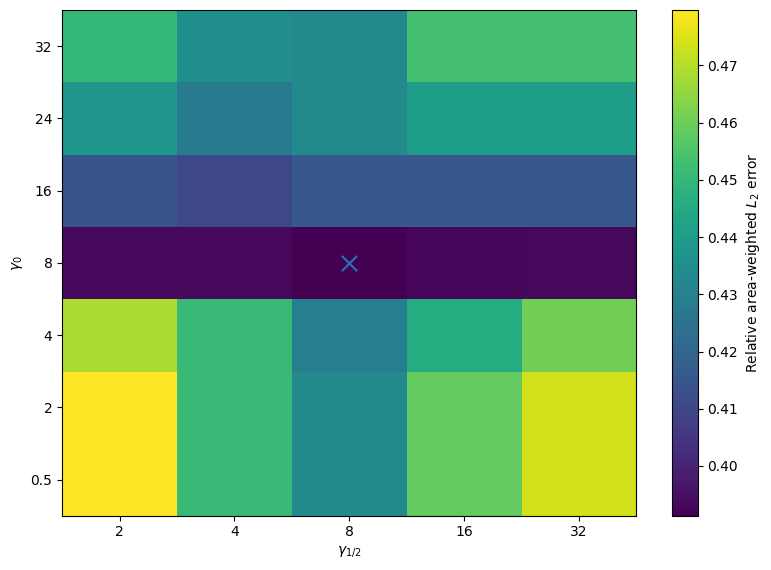

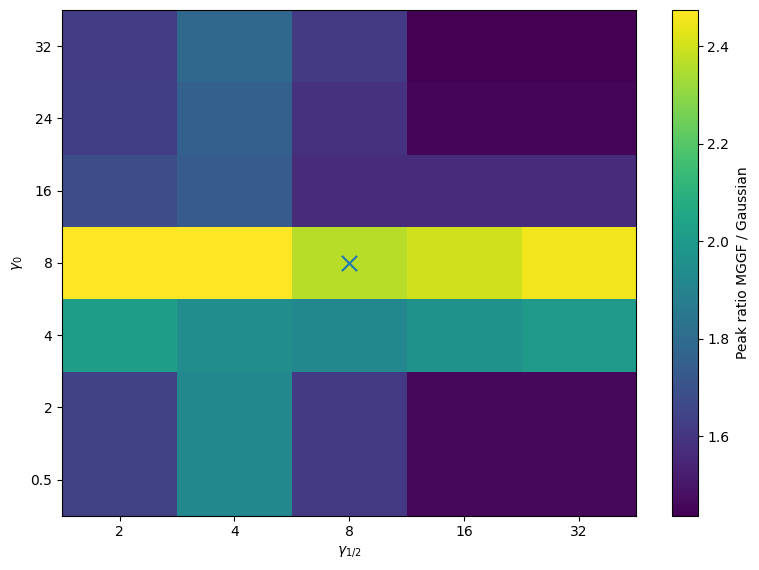

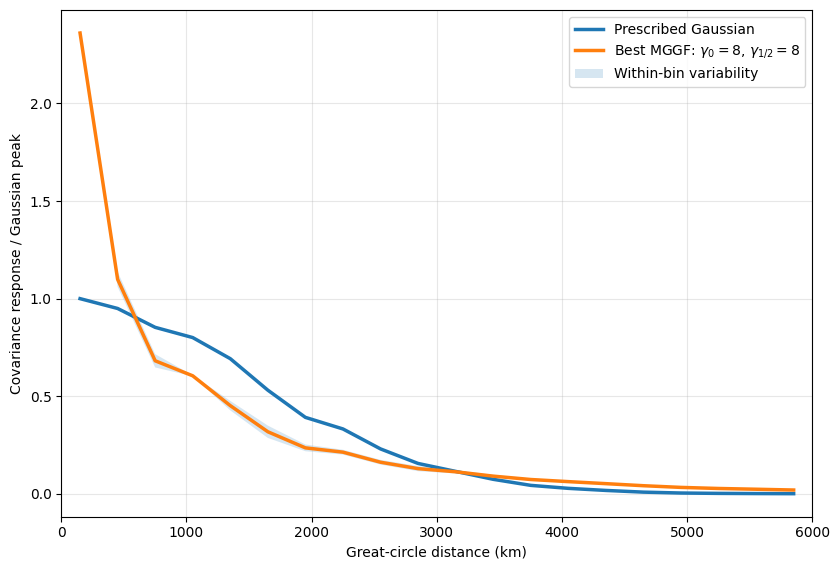

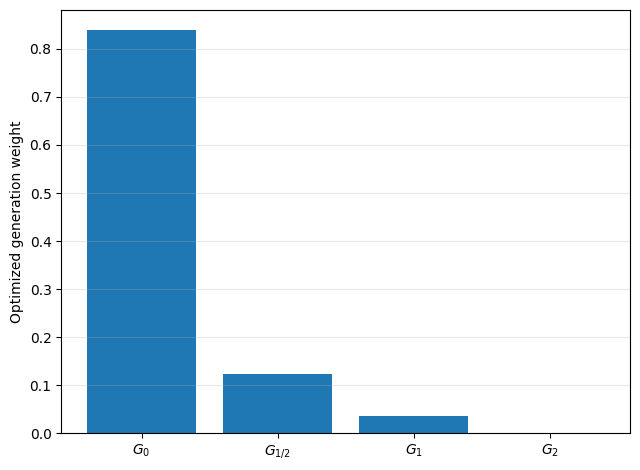


STEP 7 COMPLETE

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/gaussian_sigma1500_joint_gamma0_gamma05_sweep_v0.npz


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 7
#
# Joint sweep of gamma0 and gamma1/2
#
# Fixed:
#   gamma1 = 2
#   gamma2 = 6
#
# Varied:
#   gamma0   = 0.5, 2, 4, 8, 16, 24, 32
#   gamma1/2 = 2, 4, 8, 16, 32
#
# For each pair:
#   - rebuild C0 at chosen gamma0
#   - rebuild C1/2 at chosen gamma1/2
#   - keep existing C1 and C2
#   - optimize nonnegative weights
#   - enforce exact integrated covariance magnitude
#
# Primary metrics:
#   E_L2
#   peak ratio
#   optimized weights
#   correlation
#
# No peak constraint.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import (
    coo_matrix,
    diags,
    eye
)
from scipy.sparse.linalg import splu
from scipy.optimize import minimize


print("=" * 78)
print("STEP 7: JOINT SWEEP OF gamma0 AND gamma1/2")
print("=" * 78)


# ============================================================
# Required objects from previous steps
# ============================================================

required = [
    "N0",
    "N05",
    "area0",
    "area05",
    "xyz0",
    "P05",
    "R05",
    "L05",
    "impulse0",
    "C1",
    "C2",
    "target",
    "target_norm2",
    "I1",
    "I2",
    "SIGMA_KM",
    "INTERMEDIATE_DIR",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing objects from previous steps: "
        + ", ".join(missing)
    )


# ============================================================
# Reconstruct the fine-grid G0 graph operator
#
# This reproduces the same operator used previously when
# varying gamma0.
# ============================================================

if "edges0" not in globals():

    # Reconstruct from primal_faces if necessary
    if "g0" not in globals():
        raise RuntimeError(
            "Need either edges0 or loaded G0 object."
        )

    faces = g0["primal_faces"]

    edge_set = set()

    for face in faces:

        vals = [
            int(v)
            for v in face
            if int(v) >= 0
        ]

        for ia in range(len(vals)):

            for ib in range(ia + 1, len(vals)):

                i = vals[ia]
                j = vals[ib]

                if i == j:
                    continue

                edge_set.add(
                    (
                        min(i, j),
                        max(i, j)
                    )
                )

    edges0 = np.asarray(
        sorted(edge_set),
        dtype=np.int64
    )


ii0 = np.concatenate(
    [
        edges0[:, 0],
        edges0[:, 1]
    ]
)

jj0 = np.concatenate(
    [
        edges0[:, 1],
        edges0[:, 0]
    ]
)


Adj0 = coo_matrix(
    (
        np.ones(
            len(ii0),
            dtype=np.float64
        ),
        (ii0, jj0)
    ),
    shape=(
        N0,
        N0
    )
).tocsr()


degree0 = np.asarray(
    Adj0.sum(axis=1)
).ravel()


K0 = (
    diags(
        degree0
    )
    -
    Adj0
).tocsr()


warea0 = (
    area0
    /
    np.mean(area0)
)


L0 = (
    diags(
        1.0 / warea0
    )
    @
    K0
).tocsr()


# ============================================================
# Configuration
# ============================================================

gamma0_values = np.array(
    [
        0.5,
        2.0,
        4.0,
        8.0,
        16.0,
        24.0,
        32.0,
    ],
    dtype=np.float64
)


gamma05_values = np.array(
    [
        2.0,
        4.0,
        8.0,
        16.0,
        32.0,
    ],
    dtype=np.float64
)


# ============================================================
# Helper functions
# ============================================================

def build_response(
    L,
    impulse,
    gamma
):

    M = (
        eye(
            L.shape[0],
            format="csc"
        )
        +
        gamma
        *
        L.tocsc()
    )

    solver = splu(
        M
    )

    return solver.solve(
        impulse
    )


def weighted_correlation(
    x,
    y,
    area
):

    w = (
        area
        /
        np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    dx = x - mx
    dy = y - my

    num = np.sum(
        w * dx * dy
    )

    den = np.sqrt(
        np.sum(
            w * dx**2
        )
        *
        np.sum(
            w * dy**2
        )
    )

    return num / den


# ============================================================
# Build all G0 responses first
# ============================================================

print("\nBuilding G0 response bank...")


C0_bank = []

I0_bank = []


for gamma0 in gamma0_values:

    C0_case = build_response(
        L0,
        impulse0,
        gamma0
    )

    C0_case = np.asarray(
        C0_case,
        dtype=np.float64
    ).ravel()

    I0_case = np.sum(
        area0
        *
        C0_case
    )

    C0_bank.append(
        C0_case
    )

    I0_bank.append(
        I0_case
    )

    print(
        f"  gamma0={gamma0:6.2f} "
        f"integral={I0_case:.12f}"
    )


C0_bank = np.asarray(
    C0_bank
)

I0_bank = np.asarray(
    I0_bank
)


# ============================================================
# Build all G1/2 responses
# ============================================================

print("\nBuilding G1/2 response bank...")


impulse05 = (
    R05
    @
    impulse0
)


C05_bank = []

I05_bank = []


for gamma05 in gamma05_values:

    response05_coarse = build_response(
        L05,
        impulse05,
        gamma05
    )

    C05_case = (
        P05
        @
        response05_coarse
    )

    C05_case = np.asarray(
        C05_case,
        dtype=np.float64
    ).ravel()

    I05_case = np.sum(
        area0
        *
        C05_case
    )

    C05_bank.append(
        C05_case
    )

    I05_bank.append(
        I05_case
    )

    print(
        f"  gamma1/2={gamma05:6.2f} "
        f"integral={I05_case:.12f}"
    )


C05_bank = np.asarray(
    C05_bank
)

I05_bank = np.asarray(
    I05_bank
)


# ============================================================
# Storage
# ============================================================

shape2 = (
    len(gamma0_values),
    len(gamma05_values)
)


E_grid = np.zeros(
    shape2,
    dtype=np.float64
)

rho_grid = np.zeros(
    shape2,
    dtype=np.float64
)

peak_grid = np.zeros(
    shape2,
    dtype=np.float64
)

integral_grid = np.zeros(
    shape2,
    dtype=np.float64
)

success_grid = np.zeros(
    shape2,
    dtype=bool
)

weights_grid = np.zeros(
    (
        len(gamma0_values),
        len(gamma05_values),
        4
    ),
    dtype=np.float64
)


# ============================================================
# Joint optimization
# ============================================================

print("\n" + "=" * 78)
print("JOINT OPTIMIZATION")
print("=" * 78)


for i0, gamma0 in enumerate(
    gamma0_values
):

    C0_case = C0_bank[
        i0
    ]

    I0_case = I0_bank[
        i0
    ]


    for i05, gamma05 in enumerate(
        gamma05_values
    ):

        C05_case = C05_bank[
            i05
        ]

        I05_case = I05_bank[
            i05
        ]


        B = np.column_stack(
            [
                C0_case,
                C05_case,
                C1,
                C2
            ]
        )


        basis_integrals = np.array(
            [
                I0_case,
                I05_case,
                I1,
                I2
            ],
            dtype=np.float64
        )


        def objective(weights):

            fit = (
                B
                @
                weights
            )

            residual = (
                fit
                -
                target
            )

            return (
                np.sum(
                    area0
                    *
                    residual**2
                )
                /
                target_norm2
            )


        def magnitude_constraint(weights):

            return (
                np.dot(
                    basis_integrals,
                    weights
                )
                -
                1.0
            )


        # ----------------------------------------------------
        # Use a neutral starting point.
        # ----------------------------------------------------

        w_init = np.array(
            [
                0.25,
                0.25,
                0.35,
                0.15
            ],
            dtype=np.float64
        )


        w_init /= np.dot(
            basis_integrals,
            w_init
        )


        result = minimize(

            objective,

            w_init,

            method="SLSQP",

            bounds=[
                (0.0, None),
                (0.0, None),
                (0.0, None),
                (0.0, None),
            ],

            constraints=[
                {
                    "type": "eq",
                    "fun": magnitude_constraint
                }
            ],

            options={
                "ftol": 1.0e-13,
                "maxiter": 5000,
                "disp": False
            }
        )


        weights = result.x


        fit = (
            B
            @
            weights
        )


        residual = (
            fit
            -
            target
        )


        E_L2 = np.sqrt(
            np.sum(
                area0
                *
                residual**2
            )
            /
            target_norm2
        )


        rho = weighted_correlation(
            fit,
            target,
            area0
        )


        peak_ratio = (
            np.max(fit)
            /
            np.max(target)
        )


        integral = np.sum(
            area0
            *
            fit
        )


        E_grid[
            i0,
            i05
        ] = E_L2

        rho_grid[
            i0,
            i05
        ] = rho

        peak_grid[
            i0,
            i05
        ] = peak_ratio

        integral_grid[
            i0,
            i05
        ] = integral

        success_grid[
            i0,
            i05
        ] = result.success

        weights_grid[
            i0,
            i05,
            :
        ] = weights


        print(
            f"gamma0={gamma0:6.2f}  "
            f"gamma05={gamma05:6.2f}  "
            f"E={E_L2:.6f}  "
            f"peak={peak_ratio:.4f}  "
            f"w=["
            f"{weights[0]:.3f}, "
            f"{weights[1]:.3f}, "
            f"{weights[2]:.3f}, "
            f"{weights[3]:.3f}]"
        )


# ============================================================
# Best case by E_L2
# ============================================================

flat_best = int(
    np.argmin(
        E_grid
    )
)


ibest0, ibest05 = np.unravel_index(
    flat_best,
    E_grid.shape
)


gamma0_best = gamma0_values[
    ibest0
]

gamma05_best = gamma05_values[
    ibest05
]


E_best = E_grid[
    ibest0,
    ibest05
]


rho_best = rho_grid[
    ibest0,
    ibest05
]


peak_best = peak_grid[
    ibest0,
    ibest05
]


weights_best = weights_grid[
    ibest0,
    ibest05,
    :
]


print("\n" + "=" * 78)
print("BEST CASE BY E_L2")
print("=" * 78)

print(
    f"\ngamma0   = {gamma0_best:g}"
)

print(
    f"gamma1/2 = {gamma05_best:g}"
)

print(
    "\nOptimized weights:"
)

print(
    f"  w0   = {weights_best[0]:.12f}"
)

print(
    f"  w1/2 = {weights_best[1]:.12f}"
)

print(
    f"  w1   = {weights_best[2]:.12f}"
)

print(
    f"  w2   = {weights_best[3]:.12f}"
)

print(
    f"\nE_L2       = {E_best:.12f}"
)

print(
    f"rho        = {rho_best:.12f}"
)

print(
    f"peak ratio = {peak_best:.12f}"
)


# ============================================================
# Reference comparisons
# ============================================================

E_OLD_3GEN = 0.4826007712423832

E_PREV_G0 = 0.42052906


print("\n" + "=" * 78)
print("REFERENCE COMPARISON")
print("=" * 78)

print(
    f"\nOriginal 3-generation E_L2 : {E_OLD_3GEN:.8f}"
)

print(
    f"Variable-gamma0 reference  : {E_PREV_G0:.8f}"
)

print(
    f"New joint-sweep best       : {E_best:.8f}"
)


print(
    "\nImprovement vs original 3-generation:"
)

print(
    f"{100.0*(E_OLD_3GEN-E_best)/E_OLD_3GEN:.3f} %"
)


print(
    "\nImprovement vs variable-gamma0 reference:"
)

print(
    f"{100.0*(E_PREV_G0-E_best)/E_PREV_G0:.3f} %"
)


# ============================================================
# Build best fit
# ============================================================

C0_best = C0_bank[
    ibest0
]

C05_best = C05_bank[
    ibest05
]


B_best = np.column_stack(
    [
        C0_best,
        C05_best,
        C1,
        C2
    ]
)


fit_best = (
    B_best
    @
    weights_best
)


# ============================================================
# Figure 1:
# Heatmap of E_L2
# ============================================================

plt.figure(
    figsize=(8.0, 5.8)
)


im = plt.imshow(
    E_grid,
    origin="lower",
    aspect="auto"
)


plt.colorbar(
    im,
    label=r"Relative area-weighted $L_2$ error"
)


plt.xticks(
    np.arange(
        len(gamma05_values)
    ),
    [
        f"{g:g}"
        for g in gamma05_values
    ]
)


plt.yticks(
    np.arange(
        len(gamma0_values)
    ),
    [
        f"{g:g}"
        for g in gamma0_values
    ]
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)

plt.ylabel(
    r"$\gamma_0$"
)


plt.scatter(
    ibest05,
    ibest0,
    marker="x",
    s=120
)


plt.tight_layout()

plt.show()


# ============================================================
# Figure 2:
# Heatmap of peak ratio
# ============================================================

plt.figure(
    figsize=(8.0, 5.8)
)


im = plt.imshow(
    peak_grid,
    origin="lower",
    aspect="auto"
)


plt.colorbar(
    im,
    label="Peak ratio MGGF / Gaussian"
)


plt.xticks(
    np.arange(
        len(gamma05_values)
    ),
    [
        f"{g:g}"
        for g in gamma05_values
    ]
)


plt.yticks(
    np.arange(
        len(gamma0_values)
    ),
    [
        f"{g:g}"
        for g in gamma0_values
    ]
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)

plt.ylabel(
    r"$\gamma_0$"
)


plt.scatter(
    ibest05,
    ibest0,
    marker="x",
    s=120
)


plt.tight_layout()

plt.show()


# ============================================================
# Radial profile for best case
# ============================================================

if (
    "bin_edges" in globals()
    and
    "bin_centers" in globals()
    and
    "distance_km" in globals()
):

    rad_target = np.full(
        len(bin_centers),
        np.nan
    )

    rad_fit = np.full(
        len(bin_centers),
        np.nan
    )

    rad_std = np.full(
        len(bin_centers),
        np.nan
    )


    for k in range(
        len(bin_centers)
    ):

        mask = (
            (distance_km >= bin_edges[k])
            &
            (distance_km < bin_edges[k + 1])
        )


        if not np.any(mask):
            continue


        aa = area0[
            mask
        ]

        aa_sum = np.sum(
            aa
        )


        rad_target[k] = (
            np.sum(
                aa
                *
                target[mask]
            )
            /
            aa_sum
        )


        rad_fit[k] = (
            np.sum(
                aa
                *
                fit_best[mask]
            )
            /
            aa_sum
        )


        rad_std[k] = np.sqrt(

            np.sum(
                aa
                *
                (
                    fit_best[mask]
                    -
                    rad_fit[k]
                )**2
            )
            /
            aa_sum
        )


    target_peak = np.max(
        target
    )


    plt.figure(
        figsize=(8.5, 5.8)
    )


    plt.plot(
        bin_centers,
        rad_target
        /
        target_peak,
        linewidth=2.5,
        label="Prescribed Gaussian"
    )


    plt.plot(
        bin_centers,
        rad_fit
        /
        target_peak,
        linewidth=2.5,
        label=(
            rf"Best MGGF: "
            rf"$\gamma_0={gamma0_best:g}$, "
            rf"$\gamma_{{1/2}}={gamma05_best:g}$"
        )
    )


    plt.fill_between(
        bin_centers,
        (
            rad_fit
            -
            rad_std
        )
        /
        target_peak,
        (
            rad_fit
            +
            rad_std
        )
        /
        target_peak,
        alpha=0.18,
        label="Within-bin variability"
    )


    plt.xlabel(
        "Great-circle distance (km)"
    )

    plt.ylabel(
        "Covariance response / Gaussian peak"
    )

    plt.xlim(
        0,
        6000
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# Weight plot for best case
# ============================================================

plt.figure(
    figsize=(6.5, 4.8)
)


plt.bar(
    [
        r"$G_0$",
        r"$G_{1/2}$",
        r"$G_1$",
        r"$G_2$"
    ],
    weights_best
)


plt.ylabel(
    "Optimized generation weight"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Save joint sweep
# ============================================================

SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "gaussian_sigma1500_joint_gamma0_gamma05_sweep_v0.npz"
)


np.savez_compressed(

    SAVE_FILE,

    sigma_km=np.float64(
        SIGMA_KM
    ),

    gamma0_values=gamma0_values,

    gamma05_values=gamma05_values,

    E_L2=E_grid,

    rho=rho_grid,

    peak_ratio=peak_grid,

    integral=integral_grid,

    success=success_grid,

    weights=weights_grid,

    C0_bank=C0_bank,

    C05_bank=C05_bank,

    best_index0=np.int64(
        ibest0
    ),

    best_index05=np.int64(
        ibest05
    ),

    best_gamma0=np.float64(
        gamma0_best
    ),

    best_gamma05=np.float64(
        gamma05_best
    ),

    best_weights=weights_best,

    best_E_L2=np.float64(
        E_best
    ),

    best_rho=np.float64(
        rho_best
    ),

    best_peak_ratio=np.float64(
        peak_best
    ),

    best_fit=fit_best,
)


print("\n" + "=" * 78)
print("STEP 7 COMPLETE")
print("=" * 78)

print(
    "\nSaved:"
)

print(
    SAVE_FILE
)

# Small diagnostic test

In [ ]:
# ============================================================
# STEP 7A
#
# Check whether reconstructed G0 at gamma0=0.5 is identical
# to the original saved G0 response.
# ============================================================

import numpy as np


# Original response loaded in STEP 5
C0_original = np.asarray(
    C0,
    dtype=np.float64
)


# Reconstructed response from STEP 7
# gamma0_values[0] = 0.5
C0_reconstructed = np.asarray(
    C0_bank[0],
    dtype=np.float64
)


# ------------------------------------------------------------
# Integral comparison
# ------------------------------------------------------------

I_original = np.sum(
    area0 * C0_original
)

I_reconstructed = np.sum(
    area0 * C0_reconstructed
)


# ------------------------------------------------------------
# Relative area-weighted L2 difference
# ------------------------------------------------------------

diff = (
    C0_reconstructed
    -
    C0_original
)


rel_area_L2 = np.sqrt(
    np.sum(
        area0 * diff**2
    )
    /
    np.sum(
        area0 * C0_original**2
    )
)


# ------------------------------------------------------------
# Ordinary relative Euclidean difference
# ------------------------------------------------------------

rel_L2 = (
    np.linalg.norm(diff)
    /
    np.linalg.norm(C0_original)
)


# ------------------------------------------------------------
# Maximum difference
# ------------------------------------------------------------

max_abs = np.max(
    np.abs(diff)
)

max_rel_peak = (
    max_abs
    /
    np.max(np.abs(C0_original))
)


# ------------------------------------------------------------
# Pattern correlation
# ------------------------------------------------------------

corr = np.dot(
    C0_original,
    C0_reconstructed
) / (
    np.linalg.norm(C0_original)
    *
    np.linalg.norm(C0_reconstructed)
)


print("=" * 78)
print("G0 OPERATOR CONSISTENCY CHECK")
print("=" * 78)

print(
    f"\nOriginal integral       : {I_original:.15f}"
)

print(
    f"Reconstructed integral  : {I_reconstructed:.15f}"
)

print(
    f"Integral difference     : "
    f"{I_reconstructed-I_original:+.15e}"
)

print(
    f"\nRelative area-L2 diff   : {rel_area_L2:.12e}"
)

print(
    f"Relative ordinary L2    : {rel_L2:.12e}"
)

print(
    f"Max/peak difference     : {max_rel_peak:.12e}"
)

print(
    f"Pattern correlation     : {corr:.15f}"
)


if rel_area_L2 < 1.0e-10:

    print(
        "\nRESULT: ORIGINAL AND RECONSTRUCTED G0 MATCH."
    )

else:

    print(
        "\nRESULT: G0 OPERATORS DO NOT MATCH."
    )

G0 OPERATOR CONSISTENCY CHECK

Original integral       : 1.003571357346653
Reconstructed integral  : 1.000000000000000
Integral difference     : -3.571357346653481e-03

Relative area-L2 diff   : 8.940413567637e-03
Relative ordinary L2    : 8.801767934083e-03
Max/peak difference     : 3.247857065472e-03
Pattern correlation     : 0.999962944534262

RESULT: G0 OPERATORS DO NOT MATCH.


# Small diagnostics 2

In [ ]:
# ============================================================
# STEP 7B
#
# Reconstruct the ORIGINAL G0 graph-filter operator exactly
# as used in MGBF_hexa_v0.ipynb and compare with saved C0.
# ============================================================

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla


print("=" * 78)
print("STEP 7B: EXACT HISTORICAL G0 OPERATOR CHECK")
print("=" * 78)


# ============================================================
# Historical combinatorial graph Laplacian
#
# We already have edges0 in the present notebook.
# ============================================================

rows = []
cols = []
vals = []

degree_hist = np.zeros(
    N0,
    dtype=np.float64
)


neighbors_hist = [
    []
    for _ in range(N0)
]


for i, j in edges0:

    i = int(i)
    j = int(j)

    neighbors_hist[i].append(j)
    neighbors_hist[j].append(i)


for i, ns in enumerate(
    neighbors_hist
):

    degree_hist[i] = len(ns)

    rows.append(i)
    cols.append(i)
    vals.append(float(len(ns)))

    for j in ns:

        rows.append(i)
        cols.append(j)
        vals.append(-1.0)


L0_hist = sp.coo_matrix(
    (
        vals,
        (rows, cols)
    ),
    shape=(
        N0,
        N0
    )
).tocsr()


# ============================================================
# Original filter
# ============================================================

gamma0_test = 0.5


A0_hist = (
    sp.eye(
        N0,
        format="csr"
    )
    +
    gamma0_test
    *
    L0_hist
)


C0_hist = spla.spsolve(
    A0_hist,
    impulse0
)


# ============================================================
# Compare with original saved C0
# ============================================================

C0_saved = np.asarray(
    C0,
    dtype=np.float64
)


diff = (
    C0_hist
    -
    C0_saved
)


I_saved = np.sum(
    area0
    *
    C0_saved
)


I_hist = np.sum(
    area0
    *
    C0_hist
)


rel_area_L2 = np.sqrt(
    np.sum(
        area0
        *
        diff**2
    )
    /
    np.sum(
        area0
        *
        C0_saved**2
    )
)


rel_L2 = (
    np.linalg.norm(diff)
    /
    np.linalg.norm(C0_saved)
)


corr = (
    np.dot(
        C0_saved,
        C0_hist
    )
    /
    (
        np.linalg.norm(C0_saved)
        *
        np.linalg.norm(C0_hist)
    )
)


print(
    f"\nSaved C0 integral       : {I_saved:.15f}"
)

print(
    f"Historical reconstruction: {I_hist:.15f}"
)

print(
    f"Integral difference     : {I_hist-I_saved:+.15e}"
)

print(
    f"\nRelative area-L2 diff   : {rel_area_L2:.12e}"
)

print(
    f"Relative ordinary L2    : {rel_L2:.12e}"
)

print(
    f"Pattern correlation     : {corr:.15f}"
)


if rel_area_L2 < 1.0e-10:

    print(
        "\nRESULT: EXACT HISTORICAL G0 OPERATOR REPRODUCED."
    )

else:

    print(
        "\nRESULT: STILL NOT AN EXACT MATCH."
    )

STEP 7B: EXACT HISTORICAL G0 OPERATOR CHECK

Saved C0 integral       : 1.003571357346653
Historical reconstruction: 1.003571357346653
Integral difference     : +0.000000000000000e+00

Relative area-L2 diff   : 0.000000000000e+00
Relative ordinary L2    : 0.000000000000e+00
Pattern correlation     : 1.000000000000000

RESULT: EXACT HISTORICAL G0 OPERATOR REPRODUCED.


# Corrected script

STEP 8: CORRECTED HISTORICAL-OPERATOR G1/2 SWEEP

G1/2 historical graph degree diagnostics:
  min  = 4.0
  mean = 5.990632318501171
  max  = 8.0

L1/2 constant-nullspace residual: 0.000e+00
L1/2 symmetry error: 0.000e+00

Restricted impulse integral on G1/2: 1.0000000000000002

CORRECTED G1/2 GAMMA SWEEP

------------------------------------------------------------------------------
gamma_1/2 = 0.5
  success      = True
  I_G1/2       = 1.025297019918
  w0           = 0.000000000000
  w1/2         = 0.000000000000
  w1           = 0.744516453215
  w2           = 0.220506164090
  E_L2         = 0.482600771242
  rho          = 0.868643654641
  peak ratio   = 1.470395562454
  integral     = 1.000000000000000

------------------------------------------------------------------------------
gamma_1/2 = 1
  success      = True
  I_G1/2       = 1.030299244436
  w0           = 0.000000000000
  w1/2         = 0.000000000000
  w1           = 0.744516452360
  w2           = 0.220506165008
  E_L2   

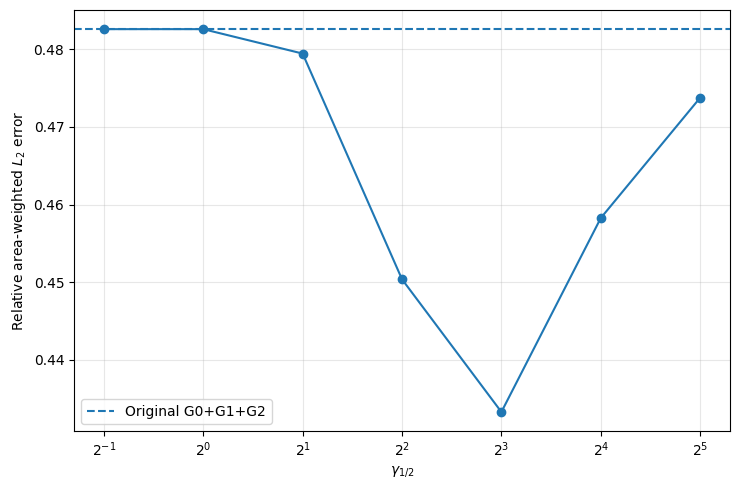

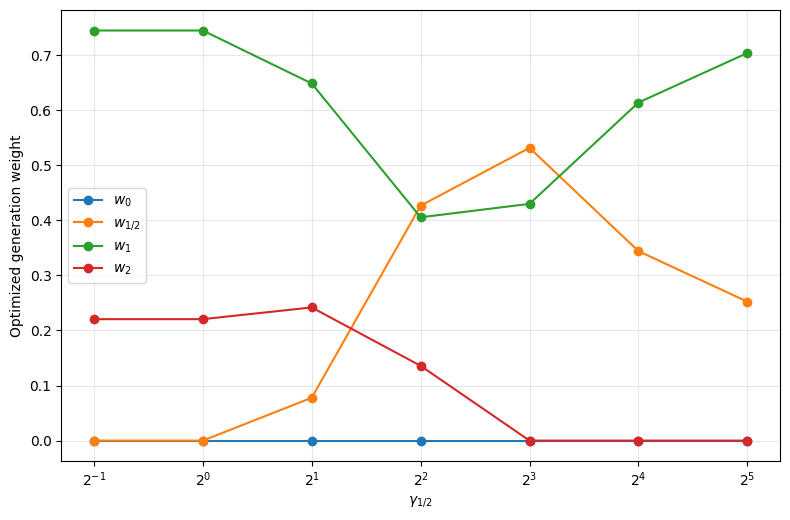

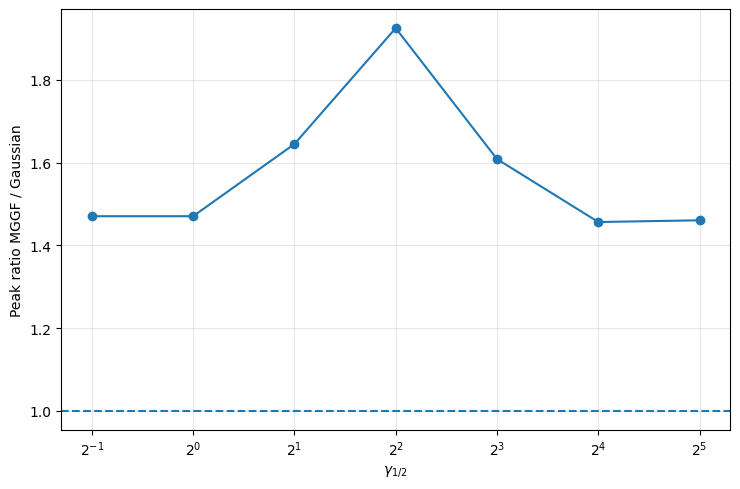

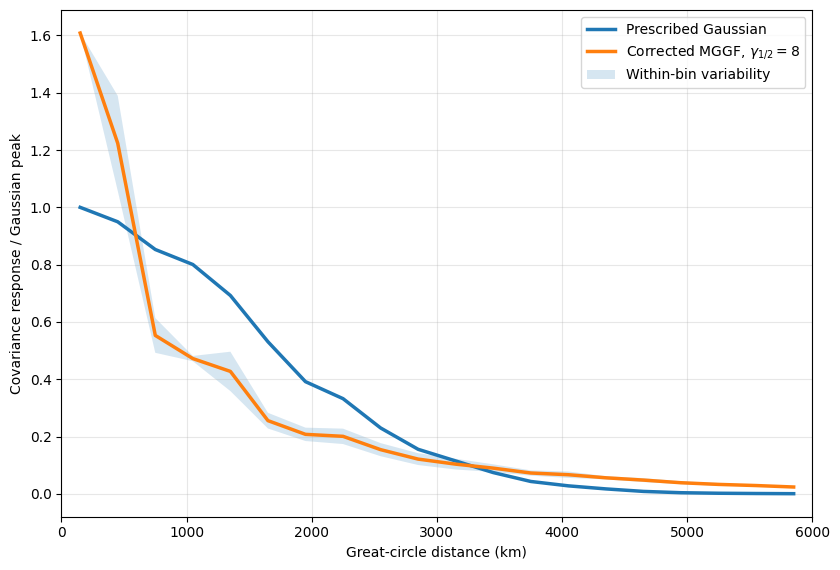


STEP 8 COMPLETE

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/gaussian_sigma1500_gamma05_sweep_historical_operator_v0.npz


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 8
#
# CORRECTED Gaussian matching with
#
#       G0 + G1/2 + G1 + G2
#
# IMPORTANT:
#   All single-level graph filters now use the SAME historical
#   combinatorial graph Laplacian formulation:
#
#       B_g = (I + gamma_g L_g)^(-1)
#
#   where L_g = D_g - A_g.
#
# Existing responses:
#   C0 : historical G0 response, gamma0 = 0.5
#   C1 : historical G1 response, gamma1 = 2.0
#   C2 : historical G2 response, gamma2 = 6.0
#
# New response:
#   C1/2 constructed with the SAME formulation.
#
# Sweep:
#   gamma1/2 = 0.5, 1, 2, 4, 8, 16, 32
#
# Optimization:
#   nonnegative weights
#   exact integrated covariance magnitude
#
# No peak constraint.
# ============================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

from scipy.optimize import minimize


print("=" * 78)
print("STEP 8: CORRECTED HISTORICAL-OPERATOR G1/2 SWEEP")
print("=" * 78)


# ============================================================
# Required objects from previous steps
# ============================================================

required = [
    "N0",
    "N05",
    "area0",
    "area05",
    "edges05",
    "P05",
    "R05",
    "impulse0",
    "C0",
    "C1",
    "C2",
    "target",
    "target_norm2",
    "I0",
    "I1",
    "I2",
    "SIGMA_KM",
    "distance_km",
    "INTERMEDIATE_DIR",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
    )


# ============================================================
# Sweep values
# ============================================================

gamma05_values = np.array(
    [
        0.5,
        1.0,
        2.0,
        4.0,
        8.0,
        16.0,
        32.0,
    ],
    dtype=np.float64
)


# ============================================================
# Construct HISTORICAL combinatorial Laplacian on G1/2
#
# L = D - A
#
# No area weighting inside L.
# ============================================================

neighbors05 = [
    []
    for _ in range(N05)
]

for i, j in edges05:

    i = int(i)
    j = int(j)

    neighbors05[i].append(j)
    neighbors05[j].append(i)


rows = []
cols = []
vals = []

deg05_hist = np.zeros(
    N05,
    dtype=np.float64
)


for i, ns in enumerate(
    neighbors05
):

    deg05_hist[i] = len(ns)

    rows.append(i)
    cols.append(i)
    vals.append(float(len(ns)))

    for j in ns:

        rows.append(i)
        cols.append(j)
        vals.append(-1.0)


L05_hist = sp.coo_matrix(
    (
        vals,
        (rows, cols)
    ),
    shape=(
        N05,
        N05
    )
).tocsr()


print("\nG1/2 historical graph degree diagnostics:")

print(
    "  min  =",
    deg05_hist.min()
)

print(
    "  mean =",
    deg05_hist.mean()
)

print(
    "  max  =",
    deg05_hist.max()
)


# ============================================================
# Verify graph Laplacian properties
# ============================================================

one05 = np.ones(
    N05,
    dtype=np.float64
)


const_resid = np.linalg.norm(
    L05_hist @ one05
)


symdiff = (
    L05_hist
    -
    L05_hist.T
)


if symdiff.nnz > 0:

    sym_error = np.max(
        np.abs(
            symdiff.data
        )
    )

else:

    sym_error = 0.0


print(
    "\nL1/2 constant-nullspace residual:",
    f"{const_resid:.3e}"
)

print(
    "L1/2 symmetry error:",
    f"{sym_error:.3e}"
)


# ============================================================
# Construct restricted impulse once
# ============================================================

impulse05 = (
    R05
    @
    impulse0
)


print(
    "\nRestricted impulse integral on G1/2:",
    np.sum(
        area05
        *
        impulse05
    )
)


# ============================================================
# Helper: historical graph filter
# ============================================================

def historical_filter(
    L,
    gamma,
    x
):

    A = (
        sp.eye(
            L.shape[0],
            format="csr"
        )
        +
        gamma
        *
        L
    )

    return spla.spsolve(
        A,
        x
    )


# ============================================================
# Helper: centered area-weighted correlation
#
# For consistency within this notebook.
# E_L2 remains the primary comparison metric.
# ============================================================

def weighted_correlation(
    x,
    y,
    area
):

    w = (
        area
        /
        np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    dx = x - mx
    dy = y - my

    numerator = np.sum(
        w
        *
        dx
        *
        dy
    )

    denominator = np.sqrt(
        np.sum(
            w
            *
            dx**2
        )
        *
        np.sum(
            w
            *
            dy**2
        )
    )

    return (
        numerator
        /
        denominator
    )


# ============================================================
# Storage
# ============================================================

ncase = len(
    gamma05_values
)


weights_all = np.zeros(
    (
        ncase,
        4
    ),
    dtype=np.float64
)


E_all = np.zeros(
    ncase,
    dtype=np.float64
)


rho_all = np.zeros(
    ncase,
    dtype=np.float64
)


peak_all = np.zeros(
    ncase,
    dtype=np.float64
)


integral_all = np.zeros(
    ncase,
    dtype=np.float64
)


I05_all = np.zeros(
    ncase,
    dtype=np.float64
)


success_all = np.zeros(
    ncase,
    dtype=bool
)


iterations_all = np.zeros(
    ncase,
    dtype=np.int64
)


C05_all = np.zeros(
    (
        ncase,
        N0
    ),
    dtype=np.float64
)


# ============================================================
# Original three-generation benchmark
# ============================================================

E_OLD = 0.4826007712423832


# ============================================================
# Sweep
# ============================================================

print("\n" + "=" * 78)
print("CORRECTED G1/2 GAMMA SWEEP")
print("=" * 78)


for icase, gamma05 in enumerate(
    gamma05_values
):

    print("\n" + "-" * 78)

    print(
        f"gamma_1/2 = {gamma05:g}"
    )


    # --------------------------------------------------------
    # Filter on G1/2 using historical formulation
    # --------------------------------------------------------

    response05_coarse = historical_filter(
        L05_hist,
        gamma05,
        impulse05
    )


    # --------------------------------------------------------
    # Prolong back to G0
    # --------------------------------------------------------

    C05 = (
        P05
        @
        response05_coarse
    )


    C05 = np.asarray(
        C05,
        dtype=np.float64
    ).ravel()


    C05_all[
        icase,
        :
    ] = C05


    # --------------------------------------------------------
    # Integrated magnitude of basis response
    # --------------------------------------------------------

    I05 = np.sum(
        area0
        *
        C05
    )


    I05_all[
        icase
    ] = I05


    # --------------------------------------------------------
    # Four basis functions
    # --------------------------------------------------------

    B = np.column_stack(
        [
            C0,
            C05,
            C1,
            C2
        ]
    )


    basis_integrals = np.array(
        [
            I0,
            I05,
            I1,
            I2
        ],
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Objective
    # --------------------------------------------------------

    def objective(weights):

        fit = (
            B
            @
            weights
        )

        residual = (
            fit
            -
            target
        )

        return (
            np.sum(
                area0
                *
                residual**2
            )
            /
            target_norm2
        )


    # --------------------------------------------------------
    # Exact integrated covariance magnitude
    # --------------------------------------------------------

    def magnitude_constraint(weights):

        return (
            np.dot(
                basis_integrals,
                weights
            )
            -
            1.0
        )


    # --------------------------------------------------------
    # Initial weights
    # --------------------------------------------------------

    w_init = np.array(
        [
            0.02,
            0.15,
            0.62,
            0.20
        ],
        dtype=np.float64
    )


    w_init /= np.dot(
        basis_integrals,
        w_init
    )


    result = minimize(

        objective,

        w_init,

        method="SLSQP",

        bounds=[
            (0.0, None),
            (0.0, None),
            (0.0, None),
            (0.0, None),
        ],

        constraints=[
            {
                "type": "eq",
                "fun": magnitude_constraint
            }
        ],

        options={
            "ftol": 1.0e-13,
            "maxiter": 5000,
            "disp": False
        }
    )


    weights = result.x


    fit = (
        B
        @
        weights
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    residual = (
        fit
        -
        target
    )


    E_L2 = np.sqrt(
        np.sum(
            area0
            *
            residual**2
        )
        /
        target_norm2
    )


    rho = weighted_correlation(
        fit,
        target,
        area0
    )


    peak_ratio = (
        np.max(fit)
        /
        np.max(target)
    )


    integral = np.sum(
        area0
        *
        fit
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    weights_all[
        icase,
        :
    ] = weights


    E_all[
        icase
    ] = E_L2


    rho_all[
        icase
    ] = rho


    peak_all[
        icase
    ] = peak_ratio


    integral_all[
        icase
    ] = integral


    success_all[
        icase
    ] = result.success


    iterations_all[
        icase
    ] = result.nit


    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print(
        f"  success      = {result.success}"
    )

    print(
        f"  I_G1/2       = {I05:.12f}"
    )

    print(
        f"  w0           = {weights[0]:.12f}"
    )

    print(
        f"  w1/2         = {weights[1]:.12f}"
    )

    print(
        f"  w1           = {weights[2]:.12f}"
    )

    print(
        f"  w2           = {weights[3]:.12f}"
    )

    print(
        f"  E_L2         = {E_L2:.12f}"
    )

    print(
        f"  rho          = {rho:.12f}"
    )

    print(
        f"  peak ratio   = {peak_ratio:.12f}"
    )

    print(
        f"  integral     = {integral:.15f}"
    )


# ============================================================
# Summary table
# ============================================================

print("\n" + "=" * 78)
print("CORRECTED SWEEP SUMMARY")
print("=" * 78)


header = (
    " gamma05"
    "       w0"
    "      w05"
    "       w1"
    "       w2"
    "      E_L2"
    "       rho"
    "      peak"
    "       I05"
)


print(
    header
)

print(
    "-" * len(header)
)


for i in range(
    ncase
):

    print(
        f"{gamma05_values[i]:8.2f}"
        f" {weights_all[i,0]:8.4f}"
        f" {weights_all[i,1]:8.4f}"
        f" {weights_all[i,2]:8.4f}"
        f" {weights_all[i,3]:8.4f}"
        f" {E_all[i]:9.5f}"
        f" {rho_all[i]:9.5f}"
        f" {peak_all[i]:9.5f}"
        f" {I05_all[i]:9.5f}"
    )


# ============================================================
# Best case
# ============================================================

ibest = int(
    np.argmin(
        E_all
    )
)


gamma_best = gamma05_values[
    ibest
]


weights_best = weights_all[
    ibest
]


E_best = E_all[
    ibest
]


rho_best = rho_all[
    ibest
]


peak_best = peak_all[
    ibest
]


print("\n" + "=" * 78)
print("BEST CORRECTED CASE BY E_L2")
print("=" * 78)

print(
    f"\ngamma_1/2 = {gamma_best:g}"
)

print(
    f"w0         = {weights_best[0]:.12f}"
)

print(
    f"w1/2       = {weights_best[1]:.12f}"
)

print(
    f"w1         = {weights_best[2]:.12f}"
)

print(
    f"w2         = {weights_best[3]:.12f}"
)

print(
    f"E_L2       = {E_best:.12f}"
)

print(
    f"rho        = {rho_best:.12f}"
)

print(
    f"peak ratio = {peak_best:.12f}"
)


print(
    "\nRelative E_L2 improvement vs original 3-generation fit:"
)

print(
    f"{100.0*(E_OLD-E_best)/E_OLD:.3f} %"
)


# ============================================================
# Best fit
# ============================================================

C05_best = C05_all[
    ibest
]


B_best = np.column_stack(
    [
        C0,
        C05_best,
        C1,
        C2
    ]
)


fit_best = (
    B_best
    @
    weights_best
)


# ============================================================
# Figure 1:
# E_L2 versus gamma1/2
# ============================================================

plt.figure(
    figsize=(7.5, 5.0)
)


plt.plot(
    gamma05_values,
    E_all,
    marker="o"
)


plt.axhline(
    E_OLD,
    linestyle="--",
    label="Original G0+G1+G2"
)


plt.xscale(
    "log",
    base=2
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)


plt.ylabel(
    r"Relative area-weighted $L_2$ error"
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# Figure 2:
# Optimized weights
# ============================================================

plt.figure(
    figsize=(8.0, 5.3)
)


plt.plot(
    gamma05_values,
    weights_all[:, 0],
    marker="o",
    label=r"$w_0$"
)


plt.plot(
    gamma05_values,
    weights_all[:, 1],
    marker="o",
    label=r"$w_{1/2}$"
)


plt.plot(
    gamma05_values,
    weights_all[:, 2],
    marker="o",
    label=r"$w_1$"
)


plt.plot(
    gamma05_values,
    weights_all[:, 3],
    marker="o",
    label=r"$w_2$"
)


plt.xscale(
    "log",
    base=2
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)


plt.ylabel(
    "Optimized generation weight"
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# Figure 3:
# Peak ratio
# ============================================================

plt.figure(
    figsize=(7.5, 5.0)
)


plt.plot(
    gamma05_values,
    peak_all,
    marker="o"
)


plt.axhline(
    1.0,
    linestyle="--"
)


plt.xscale(
    "log",
    base=2
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)


plt.ylabel(
    "Peak ratio MGGF / Gaussian"
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# Radial profile of best case
# ============================================================

BIN_WIDTH_KM = 300.0
RMAX_KM = 6000.0


bin_edges = np.arange(
    0.0,
    RMAX_KM + BIN_WIDTH_KM,
    BIN_WIDTH_KM
)


bin_centers = 0.5 * (
    bin_edges[:-1]
    +
    bin_edges[1:]
)


rad_target = np.full(
    len(bin_centers),
    np.nan
)


rad_fit = np.full(
    len(bin_centers),
    np.nan
)


rad_std = np.full(
    len(bin_centers),
    np.nan
)


for k in range(
    len(bin_centers)
):

    mask = (
        (distance_km >= bin_edges[k])
        &
        (distance_km < bin_edges[k + 1])
    )


    if not np.any(mask):
        continue


    aa = area0[
        mask
    ]


    aa_sum = np.sum(
        aa
    )


    rad_target[k] = (
        np.sum(
            aa
            *
            target[mask]
        )
        /
        aa_sum
    )


    rad_fit[k] = (
        np.sum(
            aa
            *
            fit_best[mask]
        )
        /
        aa_sum
    )


    rad_std[k] = np.sqrt(
        np.sum(
            aa
            *
            (
                fit_best[mask]
                -
                rad_fit[k]
            )**2
        )
        /
        aa_sum
    )


target_peak = np.max(
    target
)


plt.figure(
    figsize=(8.5, 5.8)
)


plt.plot(
    bin_centers,
    rad_target
    /
    target_peak,
    linewidth=2.5,
    label="Prescribed Gaussian"
)


plt.plot(
    bin_centers,
    rad_fit
    /
    target_peak,
    linewidth=2.5,
    label=(
        rf"Corrected MGGF, "
        rf"$\gamma_{{1/2}}={gamma_best:g}$"
    )
)


plt.fill_between(
    bin_centers,
    (
        rad_fit
        -
        rad_std
    )
    /
    target_peak,
    (
        rad_fit
        +
        rad_std
    )
    /
    target_peak,
    alpha=0.18,
    label="Within-bin variability"
)


plt.xlabel(
    "Great-circle distance (km)"
)


plt.ylabel(
    "Covariance response / Gaussian peak"
)


plt.xlim(
    0,
    RMAX_KM
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# Save corrected results
# ============================================================

SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "gaussian_sigma1500_gamma05_sweep_historical_operator_v0.npz"
)


np.savez_compressed(

    SAVE_FILE,

    sigma_km=np.float64(
        SIGMA_KM
    ),

    gamma05_values=gamma05_values,

    weights=weights_all,

    E_L2=E_all,

    rho=rho_all,

    peak_ratio=peak_all,

    integral=integral_all,

    I05=I05_all,

    success=success_all,

    iterations=iterations_all,

    C05_all=C05_all,

    best_index=np.int64(
        ibest
    ),

    best_gamma05=np.float64(
        gamma_best
    ),

    best_weights=weights_best,

    best_E_L2=np.float64(
        E_best
    ),

    best_rho=np.float64(
        rho_best
    ),

    best_peak_ratio=np.float64(
        peak_best
    ),

    best_fit=fit_best,
)


print("\n" + "=" * 78)
print("STEP 8 COMPLETE")
print("=" * 78)

print(
    "\nSaved:"
)

print(
    SAVE_FILE
)

# Step 9

STEP 9: CORRECTED JOINT gamma0 + gamma1/2 SWEEP

G0 degree range:
5.0 5.995316159250586 6.0

G1/2 degree range:
4.0 5.990632318501171 8.0

Historical G0 validation at gamma0=0.5:
  relative area-L2 difference = 0.000e+00

Building G0 response bank...
  gamma0=  0.50   integral=1.003571357347
  gamma0=  1.00   integral=1.005579206325
  gamma0=  2.00   integral=1.006562596580
  gamma0=  4.00   integral=1.005473927517
  gamma0=  8.00   integral=1.002946559625
  gamma0= 12.00   integral=1.001372064163
  gamma0= 16.00   integral=1.000361264809
  gamma0= 24.00   integral=0.999159291800
  gamma0= 32.00   integral=0.998473819699

Building G1/2 response bank...
  gamma05=  2.00   integral=1.032280408823
  gamma05=  4.00   integral=1.031742033395
  gamma05=  8.00   integral=1.030201720253
  gamma05= 12.00   integral=1.029323482625
  gamma05= 16.00   integral=1.028790721672
  gamma05= 24.00   integral=1.028187975912
  gamma05= 32.00   integral=1.027859614869

JOINT OPTIMIZATION
gamma0=  0.5 gamma

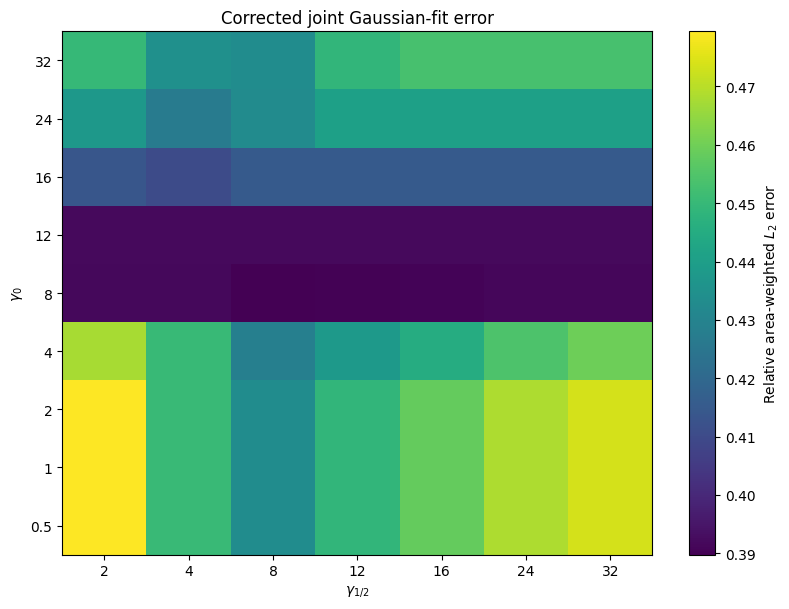

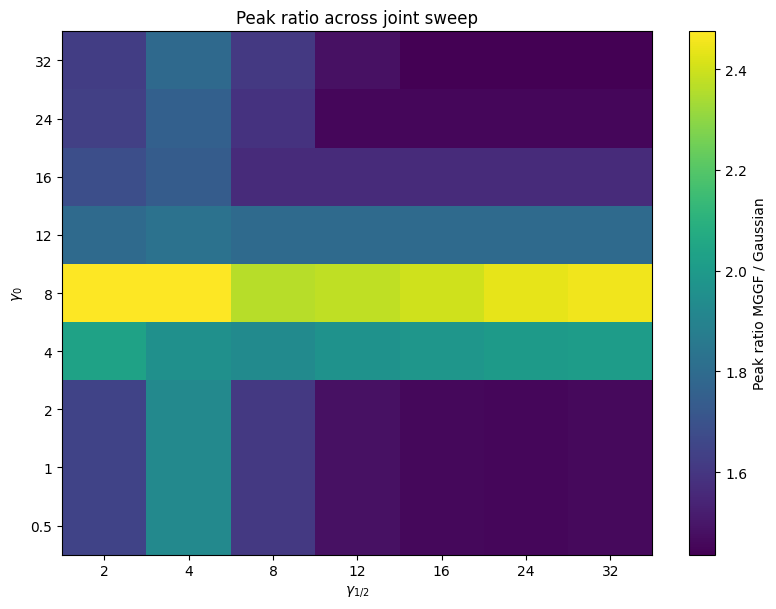

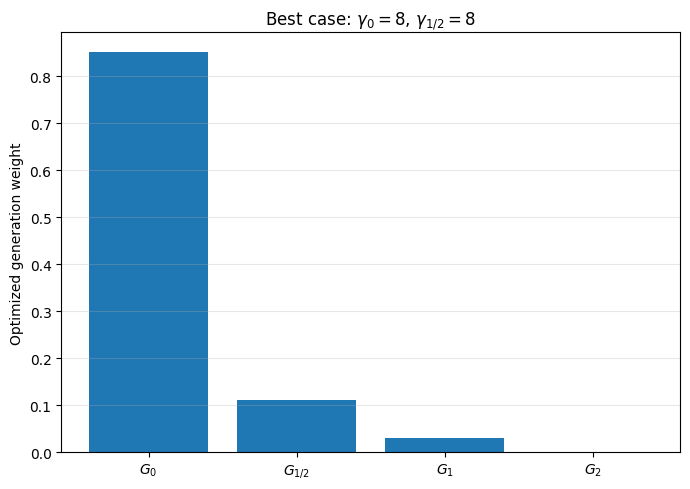

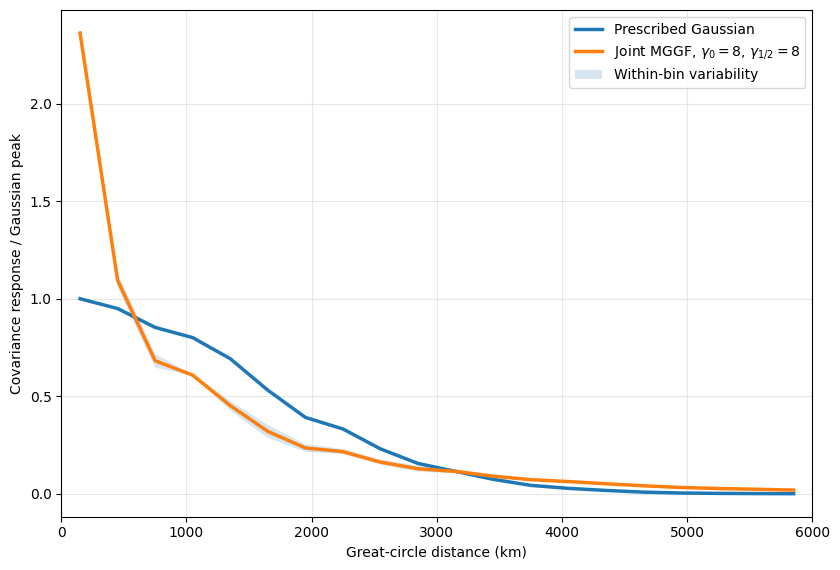


STEP 9 COMPLETE

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/gaussian_sigma1500_joint_gamma0_gamma05_historical_operator_v0.npz


In [ ]:
# ============================================================
# MGGF INTERMEDIATE-GENERATION DEVELOPMENT
#
# STEP 9
#
# CORRECTED JOINT SWEEP:
#
#       gamma0 + gamma1/2
#
# using the SAME historical combinatorial graph Laplacian
# formulation on both G0 and G1/2:
#
#       B_g = (I + gamma_g L_g)^(-1)
#
# G1 and G2 remain the original historical saved responses:
#
#       gamma1 = 2
#       gamma2 = 6
#
# Target:
#       Gaussian sigma = 1500 km
#
# Optimization:
#       nonnegative weights
#       exact integrated covariance magnitude
#
# Primary metric:
#       relative area-weighted L2 error
#
# Secondary diagnostics:
#       centered area-weighted correlation
#       peak ratio
# ============================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

from scipy.optimize import minimize


print("=" * 78)
print("STEP 9: CORRECTED JOINT gamma0 + gamma1/2 SWEEP")
print("=" * 78)


# ============================================================
# Required objects
# ============================================================

required = [
    "N0",
    "N05",
    "area0",
    "area05",
    "edges0",
    "edges05",
    "P05",
    "R05",
    "impulse0",
    "C0",
    "C1",
    "C2",
    "target",
    "target_norm2",
    "I1",
    "I2",
    "SIGMA_KM",
    "distance_km",
    "INTERMEDIATE_DIR",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
    )


# ============================================================
# Sweep values
# ============================================================

gamma0_values = np.array(
    [
        0.5,
        1.0,
        2.0,
        4.0,
        8.0,
        12.0,
        16.0,
        24.0,
        32.0,
    ],
    dtype=np.float64
)


gamma05_values = np.array(
    [
        2.0,
        4.0,
        8.0,
        12.0,
        16.0,
        24.0,
        32.0,
    ],
    dtype=np.float64
)


# ============================================================
# Helper: build historical combinatorial Laplacian
# ============================================================

def build_historical_laplacian(
    n,
    edges
):

    neighbors = [
        []
        for _ in range(n)
    ]

    for i, j in edges:

        i = int(i)
        j = int(j)

        neighbors[i].append(j)
        neighbors[j].append(i)

    rows = []
    cols = []
    vals = []

    degree = np.zeros(
        n,
        dtype=np.float64
    )

    for i, ns in enumerate(neighbors):

        degree[i] = len(ns)

        rows.append(i)
        cols.append(i)
        vals.append(float(len(ns)))

        for j in ns:

            rows.append(i)
            cols.append(j)
            vals.append(-1.0)

    L = sp.coo_matrix(
        (
            vals,
            (rows, cols)
        ),
        shape=(n, n)
    ).tocsr()

    return L, degree


# ============================================================
# Build historical L0 and L1/2
# ============================================================

L0_hist, deg0_hist = build_historical_laplacian(
    N0,
    edges0
)

L05_hist, deg05_hist = build_historical_laplacian(
    N05,
    edges05
)


print("\nG0 degree range:")
print(
    deg0_hist.min(),
    deg0_hist.mean(),
    deg0_hist.max()
)

print("\nG1/2 degree range:")
print(
    deg05_hist.min(),
    deg05_hist.mean(),
    deg05_hist.max()
)


# ============================================================
# Historical filter
# ============================================================

def historical_filter(
    L,
    gamma,
    x
):

    A = (
        sp.eye(
            L.shape[0],
            format="csr"
        )
        +
        gamma
        *
        L
    )

    return spla.spsolve(
        A,
        x
    )


# ============================================================
# Weighted centered correlation
# ============================================================

def weighted_correlation(
    x,
    y,
    area
):

    w = (
        area
        /
        np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    dx = x - mx
    dy = y - my

    num = np.sum(
        w
        *
        dx
        *
        dy
    )

    den = np.sqrt(
        np.sum(
            w
            *
            dx**2
        )
        *
        np.sum(
            w
            *
            dy**2
        )
    )

    return num / den


# ============================================================
# Restricted impulse on G1/2
# ============================================================

impulse05 = (
    R05
    @
    impulse0
)


# ============================================================
# Validate G0 historical reconstruction at gamma0 = 0.5
# ============================================================

C0_check = historical_filter(
    L0_hist,
    0.5,
    impulse0
)


diff0 = (
    C0_check
    -
    C0
)


rel0 = np.sqrt(
    np.sum(
        area0
        *
        diff0**2
    )
    /
    np.sum(
        area0
        *
        C0**2
    )
)


print(
    "\nHistorical G0 validation at gamma0=0.5:"
)

print(
    f"  relative area-L2 difference = {rel0:.3e}"
)

if rel0 > 1.0e-10:
    raise RuntimeError(
        "Historical G0 operator does not reproduce saved C0."
    )


# ============================================================
# Precompute G0 response bank
# ============================================================

C0_bank = []
I0_bank = []


print("\nBuilding G0 response bank...")


for gamma0 in gamma0_values:

    Cg = historical_filter(
        L0_hist,
        gamma0,
        impulse0
    )

    Cg = np.asarray(
        Cg,
        dtype=np.float64
    ).ravel()

    Ig = np.sum(
        area0
        *
        Cg
    )

    C0_bank.append(
        Cg
    )

    I0_bank.append(
        Ig
    )

    print(
        f"  gamma0={gamma0:6.2f}"
        f"   integral={Ig:.12f}"
    )


C0_bank = np.asarray(
    C0_bank
)

I0_bank = np.asarray(
    I0_bank
)


# ============================================================
# Precompute G1/2 response bank
# ============================================================

C05_bank = []
I05_bank = []


print("\nBuilding G1/2 response bank...")


for gamma05 in gamma05_values:

    coarse = historical_filter(
        L05_hist,
        gamma05,
        impulse05
    )

    Cg = (
        P05
        @
        coarse
    )

    Cg = np.asarray(
        Cg,
        dtype=np.float64
    ).ravel()

    Ig = np.sum(
        area0
        *
        Cg
    )

    C05_bank.append(
        Cg
    )

    I05_bank.append(
        Ig
    )

    print(
        f"  gamma05={gamma05:6.2f}"
        f"   integral={Ig:.12f}"
    )


C05_bank = np.asarray(
    C05_bank
)

I05_bank = np.asarray(
    I05_bank
)


# ============================================================
# Storage
# ============================================================

shape2 = (
    len(gamma0_values),
    len(gamma05_values)
)


E_grid = np.full(
    shape2,
    np.nan
)


rho_grid = np.full(
    shape2,
    np.nan
)


peak_grid = np.full(
    shape2,
    np.nan
)


success_grid = np.zeros(
    shape2,
    dtype=bool
)


weights_grid = np.zeros(
    shape2 + (4,),
    dtype=np.float64
)


integral_grid = np.full(
    shape2,
    np.nan
)


# ============================================================
# Benchmark
# ============================================================

E_OLD = 0.4826007712423832

E_G05_ONLY_BEST = 0.433294458251


# ============================================================
# Joint sweep
# ============================================================

print("\n" + "=" * 78)
print("JOINT OPTIMIZATION")
print("=" * 78)


for i0, gamma0 in enumerate(
    gamma0_values
):

    for i05, gamma05 in enumerate(
        gamma05_values
    ):

        C0g = C0_bank[
            i0
        ]

        C05g = C05_bank[
            i05
        ]

        I0g = I0_bank[
            i0
        ]

        I05g = I05_bank[
            i05
        ]


        B = np.column_stack(
            [
                C0g,
                C05g,
                C1,
                C2
            ]
        )


        basis_integrals = np.array(
            [
                I0g,
                I05g,
                I1,
                I2
            ],
            dtype=np.float64
        )


        def objective(weights):

            fit = (
                B
                @
                weights
            )

            residual = (
                fit
                -
                target
            )

            return (
                np.sum(
                    area0
                    *
                    residual**2
                )
                /
                target_norm2
            )


        def magnitude_constraint(weights):

            return (
                np.dot(
                    basis_integrals,
                    weights
                )
                -
                1.0
            )


        # ----------------------------------------------------
        # Several starts for robustness
        # ----------------------------------------------------

        starting_guesses = [

            np.array(
                [0.25, 0.35, 0.35, 0.05],
                dtype=np.float64
            ),

            np.array(
                [0.50, 0.25, 0.20, 0.05],
                dtype=np.float64
            ),

            np.array(
                [0.10, 0.55, 0.30, 0.05],
                dtype=np.float64
            ),

            np.array(
                [0.60, 0.35, 0.05, 0.00],
                dtype=np.float64
            ),
        ]


        best_result = None
        best_fun = np.inf


        for w_init in starting_guesses:

            normalization = np.dot(
                basis_integrals,
                w_init
            )

            if normalization <= 0:
                continue

            w_init = (
                w_init
                /
                normalization
            )


            result = minimize(

                objective,

                w_init,

                method="SLSQP",

                bounds=[
                    (0.0, None),
                    (0.0, None),
                    (0.0, None),
                    (0.0, None),
                ],

                constraints=[
                    {
                        "type": "eq",
                        "fun": magnitude_constraint
                    }
                ],

                options={
                    "ftol": 1.0e-13,
                    "maxiter": 5000,
                    "disp": False
                }
            )


            if (
                result.success
                and
                result.fun < best_fun
            ):

                best_fun = result.fun
                best_result = result


        if best_result is None:

            print(
                f"FAILED: "
                f"gamma0={gamma0:g}, "
                f"gamma05={gamma05:g}"
            )

            continue


        weights = best_result.x


        fit = (
            B
            @
            weights
        )


        residual = (
            fit
            -
            target
        )


        E_L2 = np.sqrt(
            np.sum(
                area0
                *
                residual**2
            )
            /
            target_norm2
        )


        rho = weighted_correlation(
            fit,
            target,
            area0
        )


        peak_ratio = (
            np.max(fit)
            /
            np.max(target)
        )


        integral = np.sum(
            area0
            *
            fit
        )


        E_grid[
            i0,
            i05
        ] = E_L2


        rho_grid[
            i0,
            i05
        ] = rho


        peak_grid[
            i0,
            i05
        ] = peak_ratio


        weights_grid[
            i0,
            i05,
            :
        ] = weights


        integral_grid[
            i0,
            i05
        ] = integral


        success_grid[
            i0,
            i05
        ] = True


        print(
            f"gamma0={gamma0:5.1f}"
            f" gamma05={gamma05:5.1f}"
            f"  "
            f"E={E_L2:.6f}"
            f"  "
            f"rho={rho:.6f}"
            f"  "
            f"peak={peak_ratio:.4f}"
            f"  "
            f"w="
            f"[{weights[0]:.3f},"
            f"{weights[1]:.3f},"
            f"{weights[2]:.3f},"
            f"{weights[3]:.3f}]"
        )


# ============================================================
# Best case by E_L2
# ============================================================

valid_E = np.where(
    success_grid,
    E_grid,
    np.inf
)


flat_best = int(
    np.argmin(
        valid_E
    )
)


ibest0, ibest05 = np.unravel_index(
    flat_best,
    valid_E.shape
)


gamma0_best = gamma0_values[
    ibest0
]


gamma05_best = gamma05_values[
    ibest05
]


E_best = E_grid[
    ibest0,
    ibest05
]


rho_best = rho_grid[
    ibest0,
    ibest05
]


peak_best = peak_grid[
    ibest0,
    ibest05
]


weights_best = weights_grid[
    ibest0,
    ibest05,
    :
]


print("\n" + "=" * 78)
print("BEST CORRECTED JOINT CASE")
print("=" * 78)


print(
    f"\ngamma0     = {gamma0_best:g}"
)

print(
    f"gamma1/2   = {gamma05_best:g}"
)

print(
    f"w0         = {weights_best[0]:.12f}"
)

print(
    f"w1/2       = {weights_best[1]:.12f}"
)

print(
    f"w1         = {weights_best[2]:.12f}"
)

print(
    f"w2         = {weights_best[3]:.12f}"
)

print(
    f"E_L2       = {E_best:.12f}"
)

print(
    f"rho        = {rho_best:.12f}"
)

print(
    f"peak ratio = {peak_best:.12f}"
)


print(
    "\nImprovement vs original 3-generation fit:"
)

print(
    f"{100.0*(E_OLD-E_best)/E_OLD:.3f} %"
)


print(
    "\nImprovement vs corrected fixed-gamma0 G1/2 result:"
)

print(
    f"{100.0*(E_G05_ONLY_BEST-E_best)/E_G05_ONLY_BEST:.3f} %"
)


# ============================================================
# Best fit field
# ============================================================

C0_best = C0_bank[
    ibest0
]


C05_best = C05_bank[
    ibest05
]


B_best = np.column_stack(
    [
        C0_best,
        C05_best,
        C1,
        C2
    ]
)


fit_best = (
    B_best
    @
    weights_best
)


# ============================================================
# Print useful best-case basis diagnostics
# ============================================================

print("\nBest-case basis integrals:")

print(
    f"  I0   = {I0_bank[ibest0]:.12f}"
)

print(
    f"  I1/2 = {I05_bank[ibest05]:.12f}"
)

print(
    f"  I1   = {I1:.12f}"
)

print(
    f"  I2   = {I2:.12f}"
)

print(
    "\nBest-case final integral =",
    np.sum(
        area0
        *
        fit_best
    )
)


# ============================================================
# Figure 1:
# E_L2 heat map
# ============================================================

plt.figure(
    figsize=(8.2, 6.2)
)


im = plt.imshow(
    E_grid,
    origin="lower",
    aspect="auto"
)


plt.colorbar(
    im,
    label=r"Relative area-weighted $L_2$ error"
)


plt.xticks(
    np.arange(
        len(gamma05_values)
    ),
    [
        f"{x:g}"
        for x in gamma05_values
    ]
)


plt.yticks(
    np.arange(
        len(gamma0_values)
    ),
    [
        f"{x:g}"
        for x in gamma0_values
    ]
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)


plt.ylabel(
    r"$\gamma_0$"
)


plt.title(
    "Corrected joint Gaussian-fit error"
)


plt.tight_layout()

plt.show()


# ============================================================
# Figure 2:
# peak-ratio heat map
# ============================================================

plt.figure(
    figsize=(8.2, 6.2)
)


im = plt.imshow(
    peak_grid,
    origin="lower",
    aspect="auto"
)


plt.colorbar(
    im,
    label="Peak ratio MGGF / Gaussian"
)


plt.xticks(
    np.arange(
        len(gamma05_values)
    ),
    [
        f"{x:g}"
        for x in gamma05_values
    ]
)


plt.yticks(
    np.arange(
        len(gamma0_values)
    ),
    [
        f"{x:g}"
        for x in gamma0_values
    ]
)


plt.xlabel(
    r"$\gamma_{1/2}$"
)


plt.ylabel(
    r"$\gamma_0$"
)


plt.title(
    "Peak ratio across joint sweep"
)


plt.tight_layout()

plt.show()


# ============================================================
# Figure 3:
# best optimized weights
# ============================================================

labels = [
    r"$G_0$",
    r"$G_{1/2}$",
    r"$G_1$",
    r"$G_2$"
]


plt.figure(
    figsize=(7.0, 5.0)
)


plt.bar(
    labels,
    weights_best
)


plt.ylabel(
    "Optimized generation weight"
)


plt.title(
    rf"Best case: "
    rf"$\gamma_0={gamma0_best:g}$, "
    rf"$\gamma_{{1/2}}={gamma05_best:g}$"
)


plt.grid(
    True,
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# Radial profile
# ============================================================

BIN_WIDTH_KM = 300.0
RMAX_KM = 6000.0


bin_edges = np.arange(
    0.0,
    RMAX_KM + BIN_WIDTH_KM,
    BIN_WIDTH_KM
)


bin_centers = 0.5 * (
    bin_edges[:-1]
    +
    bin_edges[1:]
)


rad_target = np.full(
    len(bin_centers),
    np.nan
)


rad_fit = np.full(
    len(bin_centers),
    np.nan
)


rad_std = np.full(
    len(bin_centers),
    np.nan
)


for k in range(
    len(bin_centers)
):

    mask = (
        (distance_km >= bin_edges[k])
        &
        (distance_km < bin_edges[k + 1])
    )


    if not np.any(mask):
        continue


    aa = area0[
        mask
    ]


    aa_sum = np.sum(
        aa
    )


    rad_target[k] = (
        np.sum(
            aa
            *
            target[mask]
        )
        /
        aa_sum
    )


    rad_fit[k] = (
        np.sum(
            aa
            *
            fit_best[mask]
        )
        /
        aa_sum
    )


    rad_std[k] = np.sqrt(
        np.sum(
            aa
            *
            (
                fit_best[mask]
                -
                rad_fit[k]
            )**2
        )
        /
        aa_sum
    )


target_peak = np.max(
    target
)


plt.figure(
    figsize=(8.5, 5.8)
)


plt.plot(
    bin_centers,
    rad_target
    /
    target_peak,
    linewidth=2.5,
    label="Prescribed Gaussian"
)


plt.plot(
    bin_centers,
    rad_fit
    /
    target_peak,
    linewidth=2.5,
    label=(
        rf"Joint MGGF, "
        rf"$\gamma_0={gamma0_best:g}$, "
        rf"$\gamma_{{1/2}}={gamma05_best:g}$"
    )
)


plt.fill_between(
    bin_centers,
    (
        rad_fit
        -
        rad_std
    )
    /
    target_peak,
    (
        rad_fit
        +
        rad_std
    )
    /
    target_peak,
    alpha=0.18,
    label="Within-bin variability"
)


plt.xlabel(
    "Great-circle distance (km)"
)


plt.ylabel(
    "Covariance response / Gaussian peak"
)


plt.xlim(
    0,
    RMAX_KM
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# Save
# ============================================================

SAVE_FILE = os.path.join(
    INTERMEDIATE_DIR,
    "gaussian_sigma1500_joint_gamma0_gamma05_historical_operator_v0.npz"
)


np.savez_compressed(

    SAVE_FILE,

    sigma_km=np.float64(
        SIGMA_KM
    ),

    gamma0_values=gamma0_values,

    gamma05_values=gamma05_values,

    E_L2=E_grid,

    rho=rho_grid,

    peak_ratio=peak_grid,

    success=success_grid,

    weights=weights_grid,

    integral=integral_grid,

    C0_bank=C0_bank,

    C05_bank=C05_bank,

    I0_bank=I0_bank,

    I05_bank=I05_bank,

    best_gamma0=np.float64(
        gamma0_best
    ),

    best_gamma05=np.float64(
        gamma05_best
    ),

    best_weights=weights_best,

    best_E_L2=np.float64(
        E_best
    ),

    best_rho=np.float64(
        rho_best
    ),

    best_peak_ratio=np.float64(
        peak_best
    ),

    best_fit=fit_best,
)


print("\n" + "=" * 78)
print("STEP 9 COMPLETE")
print("=" * 78)

print(
    "\nSaved:"
)

print(
    SAVE_FILE
)

# Fixed scale length and more weak constraints

In [ ]:
# ============================================================
# test_fixed_common_gamma_two_constraints_v0.py
#
# NEW MGGF CONCEPT TEST
#
#   1. Historical combinatorial graph Laplacian on every level
#   2. ONE COMMON gamma = Gamma for all generations
#   3. Optimize ONLY nonnegative generation weights
#   4. Exact source/variance constraint:
#          C_MGGF(source) = C_G(source) = 1
#   5. Exact integrated covariance-magnitude constraint:
#          sum_i A_i C_MGGF(i)
#        = sum_i A_i C_G(i)
#   6. Shape is optimized using area-weighted L2 error
#
# First experiment:
#   sigma = 1500 km
#   Gamma = 4, 8, 12, 16, 24, 32
#
# Generations:
#   G0, G0.5, G1, G2
#
# IMPORTANT:
# This cell assumes the corrected historical-operator notebook
# has already constructed the graph Laplacians and transfer
# operators.
# ============================================================

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 0. USER CONFIGURATION
# ============================================================

SIGMA_KM = 1500.0

COMMON_GAMMAS = [
    4.0,
    8.0,
    12.0,
    16.0,
    24.0,
    32.0,
]

OUTDIR = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations"
)
OUTDIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. SMALL VARIABLE-FINDER UTILITY
#
# This allows several likely names from our previous notebook.
# If your notebook uses a different name, simply add it to the
# corresponding candidate list.
# ============================================================

def get_existing(names, required=True):
    for name in names:
        if name in globals():
            print(f"Using {name}")
            return globals()[name]

    if required:
        raise KeyError(
            "Could not find any of these variables:\n    "
            + ", ".join(names)
        )

    return None


# ------------------------------------------------------------
# Fine-grid quantities
# ------------------------------------------------------------

area0 = get_existing([
    "area0",
    "cell_area",
    "area",
    "A0",
])

xyz0 = get_existing([
    "xyz0",
    "cell_center_xyz",
    "cell_xyz",
    "centers_xyz",
], required=False)


# ------------------------------------------------------------
# Historical combinatorial Laplacians
# ------------------------------------------------------------

L0 = get_existing([
    "L0_hist",
    "L0",
])

L05 = get_existing([
    "L05_hist",
    "L0p5_hist",
    "L_half_hist",
    "L05",
    "L0p5",
])

L1 = get_existing([
    "L1_hist",
    "L1",
])

L2 = get_existing([
    "L2_hist",
    "L2",
])


# ------------------------------------------------------------
# Fine -> generation restriction operators
#
# We need direct mappings from G0 to each generation.
# If only successive operators exist, we construct them below.
# ------------------------------------------------------------

R005 = get_existing([
    "R005",
    "R0_05",
    "R0p5_0",
    "R05",
], required=False)

P050 = get_existing([
    "P050",
    "P05_0",
    "P0p5_to_0",
    "P05",
], required=False)


R01 = get_existing([
    "R01",
    "R10",
    "R0_to_1",
], required=False)

P10 = get_existing([
    "P10",
    "P1_to_0",
], required=False)


R12 = get_existing([
    "R12",
    "R1_to_2",
], required=False)

P21 = get_existing([
    "P21",
    "P2_to_1",
], required=False)


# Optional direct G0 <-> G2 operators
R02 = get_existing([
    "R02",
    "R0_to_2",
], required=False)

P20 = get_existing([
    "P20",
    "P2_to_0",
], required=False)


# ============================================================
# 2. CONSTRUCT DIRECT TRANSFERS IF NEEDED
# ============================================================

# G0.5 must exist for this experiment.
if R005 is None or P050 is None:
    raise RuntimeError(
        "\nNeed restriction/prolongation between G0 and G0.5.\n"
        "Please map your existing G0.5 operators to R005 and P050."
    )


if R01 is None or P10 is None:
    raise RuntimeError(
        "\nNeed direct G0<->G1 transfers R01 and P10.\n"
        "If your notebook stores them under other names, add those "
        "names to the candidate lists above."
    )


if R02 is None:
    if R12 is None:
        raise RuntimeError(
            "Need either direct R02 or successive R01 and R12."
        )
    R02 = R12 @ R01
    print("Constructed R02 = R12 @ R01")


if P20 is None:
    if P21 is None:
        raise RuntimeError(
            "Need either direct P20 or successive P10 and P21."
        )
    P20 = P10 @ P21
    print("Constructed P20 = P10 @ P21")


# Convert to CSR
L0  = sp.csr_matrix(L0)
L05 = sp.csr_matrix(L05)
L1  = sp.csr_matrix(L1)
L2  = sp.csr_matrix(L2)

R005 = sp.csr_matrix(R005)
P050 = sp.csr_matrix(P050)
R01  = sp.csr_matrix(R01)
P10  = sp.csr_matrix(P10)
R02  = sp.csr_matrix(R02)
P20  = sp.csr_matrix(P20)

area0 = np.asarray(area0, dtype=np.float64)


# ============================================================
# 3. SOURCE CELL AND GREAT-CIRCLE DISTANCE
# ============================================================

if xyz0 is None:
    # Try loading directly from standard grid file.
    grid_path = (
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/"
        "global_hex_ico_grid_nsub4.npz"
    )

    grid = np.load(grid_path)

    xyz0 = grid["cell_center_xyz"]

    if "cell_area" in grid.files:
        area0 = np.asarray(grid["cell_area"], dtype=np.float64)

xyz0 = np.asarray(xyz0, dtype=np.float64)

# Normalize xyz in case coordinates are not exactly unit vectors.
xyz_unit = xyz0 / np.linalg.norm(xyz0, axis=1)[:, None]


# ------------------------------------------------------------
# Select a representative near-equatorial HEXAGON.
#
# Degree 6 from L0 identifies a hexagon.
# Among those, choose the cell closest to the equator.
# ------------------------------------------------------------

degree0 = np.asarray(L0.diagonal())

hex_mask = np.isclose(degree0, 6.0)

lat_proxy = np.abs(xyz_unit[:, 2])

candidates = np.where(hex_mask)[0]

source_idx = candidates[np.argmin(lat_proxy[candidates])]

print("\nSelected source cell:", source_idx)
print("G0 degree:", degree0[source_idx])
print("z coordinate:", xyz_unit[source_idx, 2])


# Great-circle angular distance
dots = np.clip(
    xyz_unit @ xyz_unit[source_idx],
    -1.0,
    1.0
)

theta = np.arccos(dots)

EARTH_RADIUS_KM = 6371.0

dist_km = EARTH_RADIUS_KM * theta


# ============================================================
# 4. PRESCRIBED GAUSSIAN
#
# IMPORTANT:
# Peak is exactly 1 at source.
# We DO NOT normalize its area integral.
# ============================================================

target = np.exp(
    -0.5 * (dist_km / SIGMA_KM)**2
)

# Force exact source value against roundoff.
target[source_idx] = 1.0

target_integral = np.sum(area0 * target)

target_norm2 = np.sum(area0 * target**2)


print("\nTarget Gaussian")
print("----------------")
print(f"sigma                 = {SIGMA_KM:.1f} km")
print(f"source value          = {target[source_idx]:.16e}")
print(f"integrated magnitude  = {target_integral:.16e}")


# ============================================================
# 5. FINE-GRID UNIT-AREA IMPULSE
# ============================================================

delta0 = np.zeros(L0.shape[0], dtype=np.float64)

delta0[source_idx] = 1.0 / area0[source_idx]

print(
    "Impulse area integral =",
    np.sum(area0 * delta0)
)


# ============================================================
# 6. HISTORICAL GRAPH FILTER
#
# B = (I + Gamma L)^(-1)
# ============================================================

def graph_filter(L, gamma, rhs):
    n = L.shape[0]

    A = (
        sp.eye(n, format="csr", dtype=np.float64)
        + gamma * L
    )

    return spla.spsolve(A, rhs)


# ============================================================
# 7. BUILD FOUR BASIS RESPONSES FOR ONE COMMON GAMMA
# ============================================================

def build_basis(common_gamma):

    # ---------------- G0 ----------------
    C0 = graph_filter(
        L0,
        common_gamma,
        delta0
    )

    # ---------------- G0.5 ----------------
    impulse05 = R005 @ delta0

    C05_coarse = graph_filter(
        L05,
        common_gamma,
        impulse05
    )

    C05 = P050 @ C05_coarse

    # ---------------- G1 ----------------
    impulse1 = R01 @ delta0

    C1_coarse = graph_filter(
        L1,
        common_gamma,
        impulse1
    )

    C1 = P10 @ C1_coarse

    # ---------------- G2 ----------------
    impulse2 = R02 @ delta0

    C2_coarse = graph_filter(
        L2,
        common_gamma,
        impulse2
    )

    C2 = P20 @ C2_coarse

    B = np.column_stack([
        np.asarray(C0).ravel(),
        np.asarray(C05).ravel(),
        np.asarray(C1).ravel(),
        np.asarray(C2).ravel(),
    ])

    return B


# ============================================================
# 8. METRICS
# ============================================================

def area_l2_relative(fit):
    num = np.sum(
        area0 * (fit - target)**2
    )

    den = target_norm2

    return np.sqrt(num / den)


def weighted_centered_corr(x, y, area):
    w = area / np.sum(area)

    mx = np.sum(w * x)
    my = np.sum(w * y)

    xa = x - mx
    ya = y - my

    num = np.sum(w * xa * ya)

    den = np.sqrt(
        np.sum(w * xa**2)
        *
        np.sum(w * ya**2)
    )

    return num / den


# ============================================================
# 9. TWO-CONSTRAINT WEIGHT OPTIMIZATION
#
# Constraints:
#
#   sum_g w_g C_g(source) = 1
#
#   sum_g w_g Integral(C_g)
#       = Integral(Gaussian)
#
# All w_g >= 0
# ============================================================

def optimize_weights(B):

    source_basis = B[source_idx, :]

    basis_integrals = (
        area0[:, None] * B
    ).sum(axis=0)

    # --------------------------------------------------------
    # Objective is squared relative area-weighted L2.
    # --------------------------------------------------------

    def objective(w):
        fit = B @ w

        return (
            np.sum(
                area0 * (fit - target)**2
            )
            / target_norm2
        )

    # Exact linear equality constraints
    constraints = [
        {
            "type": "eq",
            "fun": lambda w:
                np.dot(source_basis, w) - 1.0,
        },
        {
            "type": "eq",
            "fun": lambda w:
                np.dot(basis_integrals, w)
                - target_integral,
        },
    ]

    bounds = [
        (0.0, None)
        for _ in range(B.shape[1])
    ]

    # --------------------------------------------------------
    # Multiple starts.
    #
    # Since two equality constraints are active, starting from
    # several positive combinations is useful.
    # --------------------------------------------------------

    starts = [
        np.ones(4),
        np.array([1.0, 0.2, 0.1, 0.05]),
        np.array([0.5, 0.5, 0.2, 0.1]),
        np.array([0.2, 0.8, 0.5, 0.2]),
        np.array([0.1, 0.4, 0.8, 0.4]),
        np.array([0.05, 0.2, 0.5, 1.0]),
    ]

    best = None

    for x0 in starts:

        result = minimize(
            objective,
            x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "ftol": 1.0e-12,
                "maxiter": 3000,
                "disp": False,
            },
        )

        if not result.success:
            continue

        w = result.x

        # Check constraints independently.
        source_resid = (
            np.dot(source_basis, w) - 1.0
        )

        integral_resid = (
            np.dot(basis_integrals, w)
            - target_integral
        )

        feasible = (
            np.min(w) >= -1.0e-10
            and abs(source_resid) <= 1.0e-8
            and abs(integral_resid)
                <= max(
                    1.0e-8,
                    1.0e-10 * abs(target_integral)
                )
        )

        if not feasible:
            continue

        if (
            best is None
            or result.fun < best.fun
        ):
            best = result

    return best, source_basis, basis_integrals


# ============================================================
# 10. COMMON-GAMMA SWEEP
# ============================================================

results = []

fits = {}

print("\n")
print("=" * 100)
print("COMMON-GAMMA / TWO-CONSTRAINT EXPERIMENT")
print("=" * 100)

for gamma in COMMON_GAMMAS:

    print(f"\nGamma = {gamma:g}")
    print("-" * 60)

    B = build_basis(gamma)

    # Individual basis diagnostics
    source_basis = B[source_idx, :]
    basis_integrals = (
        area0[:, None] * B
    ).sum(axis=0)

    print(
        "Basis source values  :",
        source_basis
    )

    print(
        "Basis integrals      :",
        basis_integrals
    )

    result, source_basis, basis_integrals = (
        optimize_weights(B)
    )

    if result is None:

        print(
            "*** No feasible nonnegative solution found ***"
        )

        results.append({
            "gamma": gamma,
            "feasible": False,
        })

        continue

    w = result.x

    fit = B @ w

    source_value = fit[source_idx]

    fit_integral = np.sum(
        area0 * fit
    )

    e_l2 = area_l2_relative(fit)

    rho = weighted_centered_corr(
        fit,
        target,
        area0
    )

    source_ratio = (
        fit[source_idx]
        / target[source_idx]
    )

    global_max_ratio = (
        np.max(fit)
        / np.max(target)
    )

    max_idx = int(np.argmax(fit))

    print("FEASIBLE")
    print(
        "weights [G0,G0.5,G1,G2] =",
        w
    )
    print(f"E_L2                 = {e_l2:.12f}")
    print(f"rho centered          = {rho:.12f}")
    print(f"source value           = {source_value:.12e}")
    print(f"source ratio           = {source_ratio:.12e}")
    print(f"target integral        = {target_integral:.12e}")
    print(f"MGGF integral          = {fit_integral:.12e}")
    print(
        f"relative integral err = "
        f"{(fit_integral-target_integral)/target_integral:.3e}"
    )
    print(f"global max ratio       = {global_max_ratio:.12f}")
    print(f"global max cell        = {max_idx}")
    print(
        "max at source?        =",
        max_idx == source_idx
    )

    results.append({
        "gamma": gamma,
        "feasible": True,
        "w0": w[0],
        "w05": w[1],
        "w1": w[2],
        "w2": w[3],
        "E_L2": e_l2,
        "rho": rho,
        "source_value": source_value,
        "source_ratio": source_ratio,
        "integral": fit_integral,
        "target_integral": target_integral,
        "global_max_ratio": global_max_ratio,
        "max_idx": max_idx,
    })

    fits[gamma] = fit


# ============================================================
# 11. PRINT COMPACT SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 140)

print(
    f"{'Gamma':>7s} "
    f"{'feas':>5s} "
    f"{'w0':>10s} "
    f"{'w05':>10s} "
    f"{'w1':>10s} "
    f"{'w2':>10s} "
    f"{'E_L2':>10s} "
    f"{'rho':>10s} "
    f"{'src':>10s} "
    f"{'I/Iref':>10s} "
    f"{'max/ref':>10s}"
)

print("=" * 140)

for r in results:

    if not r["feasible"]:

        print(
            f"{r['gamma']:7.1f} "
            f"{'NO':>5s}"
        )

        continue

    print(
        f"{r['gamma']:7.1f} "
        f"{'YES':>5s} "
        f"{r['w0']:10.5f} "
        f"{r['w05']:10.5f} "
        f"{r['w1']:10.5f} "
        f"{r['w2']:10.5f} "
        f"{r['E_L2']:10.5f} "
        f"{r['rho']:10.5f} "
        f"{r['source_ratio']:10.5f} "
        f"{r['integral']/r['target_integral']:10.5f} "
        f"{r['global_max_ratio']:10.5f}"
    )


# ============================================================
# 12. IDENTIFY BEST FEASIBLE RESULT BY SHAPE ERROR
#
# This is diagnostic only.
# We will NOT automatically declare this Gamma to be the final
# common value until we inspect behavior across all sigma.
# ============================================================

feasible_results = [
    r for r in results
    if r["feasible"]
]

if len(feasible_results) == 0:
    raise RuntimeError(
        "No common Gamma produced a feasible two-constraint solution."
    )

best = min(
    feasible_results,
    key=lambda r: r["E_L2"]
)

best_gamma = best["gamma"]

print("\nBest sigma=1500 diagnostic result")
print("---------------------------------")
print(f"Gamma = {best_gamma}")
print(
    "weights =",
    best["w0"],
    best["w05"],
    best["w1"],
    best["w2"],
)
print(f"E_L2 = {best['E_L2']:.8f}")
print(f"rho  = {best['rho']:.8f}")
print(
    f"global max ratio = "
    f"{best['global_max_ratio']:.8f}"
)


# ============================================================
# 13. RADIAL-MEAN DIAGNOSTIC
# ============================================================

def radial_stats(field, bin_width_km=150.0):

    bins = np.arange(
        0.0,
        dist_km.max() + bin_width_km,
        bin_width_km
    )

    centers = 0.5 * (
        bins[:-1] + bins[1:]
    )

    mean = np.full(
        len(centers),
        np.nan
    )

    std = np.full(
        len(centers),
        np.nan
    )

    for k in range(len(centers)):

        mask = (
            (dist_km >= bins[k])
            &
            (dist_km < bins[k + 1])
        )

        if np.any(mask):

            ww = area0[mask]

            ff = field[mask]

            wsum = np.sum(ww)

            mu = np.sum(
                ww * ff
            ) / wsum

            var = np.sum(
                ww * (ff - mu)**2
            ) / wsum

            mean[k] = mu

            std[k] = np.sqrt(
                max(var, 0.0)
            )

    return centers, mean, std


best_fit = fits[best_gamma]

r, target_mean, _ = radial_stats(
    target
)

_, fit_mean, fit_std = radial_stats(
    best_fit
)


plt.figure(figsize=(8.0, 5.2))

plt.plot(
    r,
    target_mean,
    linewidth=2.0,
    label="Target Gaussian"
)

plt.plot(
    r,
    fit_mean,
    linewidth=2.0,
    label=f"MGGF, common Gamma={best_gamma:g}"
)

plt.fill_between(
    r,
    fit_mean - fit_std,
    fit_mean + fit_std,
    alpha=0.20,
    label="Within-bin variability"
)

plt.xlabel("Great-circle distance (km)")
plt.ylabel("Covariance response")
plt.xlim(0, 6000)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

png_path = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_radial_v0.png"
)

pdf_path = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_radial_v0.pdf"
)

plt.savefig(
    png_path,
    dpi=200,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. WEIGHT-VERSUS-GAMMA PLOT
# ============================================================

gammas_plot = []
weights_plot = []

for r0 in feasible_results:

    gammas_plot.append(
        r0["gamma"]
    )

    weights_plot.append([
        r0["w0"],
        r0["w05"],
        r0["w1"],
        r0["w2"],
    ])

gammas_plot = np.asarray(
    gammas_plot
)

weights_plot = np.asarray(
    weights_plot
)


plt.figure(figsize=(8.0, 5.2))

labels = [
    "G0",
    "G0.5",
    "G1",
    "G2",
]

for j, label in enumerate(labels):

    plt.plot(
        gammas_plot,
        weights_plot[:, j],
        marker="o",
        label=label
    )

plt.xlabel("Common Gamma")
plt.ylabel("Optimized generation weight")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

weight_png = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_weights_v0.png"
)

weight_pdf = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_weights_v0.pdf"
)

plt.savefig(
    weight_png,
    dpi=200,
    bbox_inches="tight"
)

plt.savefig(
    weight_pdf,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. SAVE NUMERICAL RESULTS
# ============================================================

table_rows = []

for r0 in results:

    if r0["feasible"]:

        table_rows.append([
            r0["gamma"],
            1.0,
            r0["w0"],
            r0["w05"],
            r0["w1"],
            r0["w2"],
            r0["E_L2"],
            r0["rho"],
            r0["source_ratio"],
            r0["integral"]
                / r0["target_integral"],
            r0["global_max_ratio"],
        ])

    else:

        table_rows.append([
            r0["gamma"],
            0.0,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        ])


table_rows = np.asarray(
    table_rows,
    dtype=np.float64
)

npz_path = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_v0.npz"
)

np.savez(
    npz_path,
    sigma_km=SIGMA_KM,
    common_gammas=np.asarray(COMMON_GAMMAS),
    table=table_rows,
    table_columns=np.array([
        "gamma",
        "feasible",
        "w0",
        "w05",
        "w1",
        "w2",
        "E_L2",
        "rho_centered",
        "source_ratio",
        "integral_ratio",
        "global_max_ratio",
    ]),
    source_idx=source_idx,
    dist_km=dist_km,
    target=target,
    target_integral=target_integral,
    best_gamma=best_gamma,
    best_fit=best_fit,
)


txt_path = (
    OUTDIR
    / "fixed_common_gamma_two_constraints_sigma1500_table_v0.txt"
)

header = (
    "gamma feasible w0 w05 w1 w2 "
    "E_L2 rho_centered source_ratio "
    "integral_ratio global_max_ratio"
)

np.savetxt(
    txt_path,
    table_rows,
    header=header,
    fmt="%.12e"
)


print("\nSaved:")
print(npz_path)
print(txt_path)
print(png_path)
print(pdf_path)
print(weight_png)
print(weight_pdf)

print("\nDONE.")

Using area0
Using xyz0
Using L0_hist
Using L05_hist


KeyError: 'Could not find any of these variables:\n    L1_hist, L1'

# New Diagnostics for G1 and G2

In [ ]:
# ============================================================
# DIAGNOSTIC: inspect available level-1 / level-2 variables
# ============================================================

names = sorted(globals().keys())

patterns = [
    "L1", "L2",
    "lap", "graph",
    "dual_cells",
    "area1", "area2",
    "R01", "R12", "R02",
    "P10", "P21", "P20",
]

for pat in patterns:
    print(f"\n--- {pat} ---")
    for name in names:
        if pat.lower() in name.lower():
            obj = globals()[name]
            try:
                shape = obj.shape
            except Exception:
                shape = ""
            print(f"{name:40s} {shape}")


--- L1 ---

--- L2 ---
E_L2                                     ()
rel_L2                                   ()
rel_area_L2                              ()

--- lap ---
build_historical_laplacian               

--- graph ---

--- dual_cells ---

--- area1 ---

--- area2 ---

--- R01 ---

--- R12 ---

--- R02 ---

--- P10 ---

--- P21 ---

--- P20 ---


In [ ]:
# Diagnostics 2

In [ ]:
# ============================================================
# DIAGNOSTIC 2:
# Find hierarchy-related objects by type and dimensions
# ============================================================

import numpy as np
import scipy.sparse as sp

print("=" * 90)
print("SPARSE MATRICES IN MEMORY")
print("=" * 90)

for name, obj in sorted(globals().items()):
    try:
        if sp.issparse(obj):
            print(
                f"{name:45s} "
                f"shape={str(obj.shape):18s} "
                f"nnz={obj.nnz}"
            )
    except Exception:
        pass


print("\n" + "=" * 90)
print("NUMPY ARRAYS POTENTIALLY RELATED TO HIERARCHY")
print("=" * 90)

# Expected hierarchy sizes are likely near:
# G0   = 2562
# G0.5 = 1281
# G1   ~ 642
# G2   ~ 162
#
# We print arrays having any dimension near these values.

interesting_sizes = {
    2562, 1281,
    642, 641, 643,
    162, 161, 163,
    5120, 7680
}

for name, obj in sorted(globals().items()):
    try:
        if isinstance(obj, np.ndarray):

            shape = obj.shape

            if any(
                int(d) in interesting_sizes
                for d in shape
            ):
                print(
                    f"{name:45s} "
                    f"shape={str(shape):20s} "
                    f"dtype={obj.dtype}"
                )

    except Exception:
        pass


print("\n" + "=" * 90)
print("LISTS / TUPLES WITH POSSIBLE GENERATION LENGTHS")
print("=" * 90)

for name, obj in sorted(globals().items()):
    try:
        if isinstance(obj, (list, tuple)):

            n = len(obj)

            if n in interesting_sizes:
                print(
                    f"{name:45s} "
                    f"type={type(obj).__name__:10s} "
                    f"len={n}"
                )

    except Exception:
        pass


print("\n" + "=" * 90)
print("DICTIONARIES / NPZ-LIKE OBJECTS")
print("=" * 90)

for name, obj in sorted(globals().items()):

    try:
        if isinstance(obj, dict):
            print(f"\n{name}:")
            print("  keys =", list(obj.keys())[:50])

        elif isinstance(obj, np.lib.npyio.NpzFile):
            print(f"\n{name}:")
            print("  files =", obj.files)

    except Exception:
        pass

SPARSE MATRICES IN MEMORY
A0_hist                                       shape=(2562, 2562)       nnz=17922
Adj0                                          shape=(2562, 2562)       nnz=15360
Adj05                                         shape=(1281, 1281)       nnz=7674
K0                                            shape=(2562, 2562)       nnz=17922
K05                                           shape=(1281, 1281)       nnz=8955
L0                                            shape=(2562, 2562)       nnz=17922
L05                                           shape=(1281, 1281)       nnz=8955
L05_hist                                      shape=(1281, 1281)       nnz=8955
L0_hist                                       shape=(2562, 2562)       nnz=17922
M05                                           shape=(1281, 1281)       nnz=8955
P05                                           shape=(2562, 1281)       nnz=2562
R05                                           shape=(1281, 2562)       nnz=2562
symdiff  

# Diagnostics 3

In [ ]:
# ============================================================
# DIAGNOSTIC 3:
# Locate original G1 / G2 hierarchy files on Google Drive
# ============================================================

from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

print("Searching under:")
print(ROOT)

# Terms that are likely to identify hierarchy/grid files
terms = [
    "hier",
    "grid",
    "generation",
    "coarse",
    "parent",
    "multigrid",
    "mggf",
    "mg",
]

all_npz = list(ROOT.rglob("*.npz"))

print(f"\nFound {len(all_npz)} NPZ files total.")

candidates = []

for path in all_npz:
    s = str(path).lower()

    if any(term in s for term in terms):
        candidates.append(path)

print(f"Potential hierarchy/grid candidates: {len(candidates)}")


def summarize_npz(path):
    try:
        f = np.load(path, allow_pickle=True)

        print("\n" + "=" * 100)
        print(path)
        print("-" * 100)

        for key in f.files:

            try:
                obj = f[key]
                shape = getattr(obj, "shape", None)
                dtype = getattr(obj, "dtype", None)

                # Highlight dimensions suggestive of G0/G1/G2
                interesting = False

                if shape is not None:
                    for d in shape:
                        if d in [
                            2562, 1281,
                            642, 641, 643,
                            162, 161, 163,
                            42, 41, 43
                        ]:
                            interesting = True

                mark = " ***" if interesting else ""

                print(
                    f"{key:40s} "
                    f"shape={str(shape):20s} "
                    f"dtype={str(dtype):12s}"
                    f"{mark}"
                )

            except Exception as e:
                print(f"{key:40s} <could not inspect: {e}>")

        f.close()

    except Exception as e:
        print(f"\nCould not open {path}")
        print("  ", e)


# Avoid dumping hundreds of irrelevant files.
# First print filenames.
print("\nCandidate filenames:")
print("-" * 100)

for i, path in enumerate(candidates):
    print(f"{i:4d}: {path}")


# Then inspect candidates that look especially promising.
priority_terms = [
    "hier",
    "generation",
    "coarse",
    "parent",
    "mggf",
    "multigrid",
]

priority = [
    p for p in candidates
    if any(t in str(p).lower() for t in priority_terms)
]

print(
    f"\n\nInspecting {len(priority)} higher-priority files..."
)

for path in priority:
    summarize_npz(path)

Searching under:
/content/drive/MyDrive/GLOBAL_SW_FV

Found 42 NPZ files total.
Potential hierarchy/grid candidates: 21

Candidate filenames:
----------------------------------------------------------------------------------------------------
   0: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
   1: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_operators_v1.npz
   2: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_operators_v2.npz
   3: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub2.npz
   4: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub3.npz
   5: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub4.npz
   6: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_hierarchy_nsub4_3_2_v0.npz
   7: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_geometric_communication_v0.npz
   8: /content/drive/MyDrive/GLOBAL_SW_FV/grid/multilevel_beta_filter_test_v0.npz
   9: /content/drive/MyDrive/G

# test_mggf_common_gamma_constrained_gaussian_v0.py

In [ ]:
# ============================================================
# test_mggf_common_gamma_constrained_gaussian_v0.py
#
# PURPOSE
# -------
# Test the new MGGF concept:
#
#   * one COMMON graph-filter parameter Gamma on every level
#   * covariance scale represented by the graph hierarchy
#   * optimize ONLY nonnegative generation weights
#   * exact prescribed source variance:
#
#         C_MGGF(source) = 1
#
#   * exact prescribed integrated covariance magnitude:
#
#         Integral(C_MGGF) = Integral(C_Gaussian)
#
#   * minimize only the remaining covariance-shape mismatch
#
# Generations:
#
#       G0      : 2562
#       G0.5    : 1281
#       G1      : 642
#       G2      : 162
#
# Historical single-level graph operator:
#
#       L = D - A
#       B = (I + Gamma L)^(-1)
#
# Historical transfers:
#
#       P : piecewise-constant prolongation
#       R = Ac^{-1} P^T Af
#
# First target:
#
#       Gaussian sigma = 1500 km
#
# Common-Gamma sweep:
#
#       4, 8, 12, 16, 24, 32
#
# The script first reconstructs the historical G1/G2 responses
# and compares them with previously saved C1/C2.
#
# Only after successful verification does it run the new test.
# ============================================================


import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import minimize, linprog

import matplotlib.pyplot as plt

from pathlib import Path


# ============================================================
# 0. CONFIGURATION
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV"
)

GRID_FILE = (
    ROOT
    / "grid/global_hex_ico_grid_nsub4.npz"
)

HIERARCHY_FILE = (
    ROOT
    / "grid/global_hex_ico_hierarchy_nsub4_3_2_v0.npz"
)

G05_FILE = (
    ROOT
    / "intermediate_generations/"
      "mggf_G0p5_pair_hierarchy_v0.npz"
)

# This file contains the previously saved fine-grid
# C0, C05, C1, C2 responses and source location.
REFERENCE_FILE = (
    ROOT
    / "intermediate_generations/"
      "gaussian_sigma1500_G0_G05_G1_G2_v0.npz"
)

OUTDIR = (
    ROOT
    / "intermediate_generations/"
      "common_gamma_constrained_gaussian"
)

OUTDIR.mkdir(
    parents=True,
    exist_ok=True
)


SIGMA_KM = 1500.0

COMMON_GAMMAS = np.array(
    [
        4.0,
        8.0,
        12.0,
        16.0,
        24.0,
        32.0,
    ],
    dtype=np.float64
)


EARTH_RADIUS_KM = 6371.0


# Historical parameters used for validation of the
# previously saved G1/G2 responses.
HIST_GAMMA1 = 2.0
HIST_GAMMA2 = 6.0


# Tight but realistic verification tolerance.
VERIFY_TOL = 1.0e-10


# ============================================================
# 1. BASIC UTILITIES
# ============================================================

def unique_edges_from_triangles(faces):
    """
    Construct undirected cell-to-cell graph edges from triangular
    primal faces.

    Each triangular primal face contains three neighboring
    finite-volume cell centers.
    """

    faces = np.asarray(
        faces,
        dtype=np.int64
    )

    e01 = faces[:, [0, 1]]
    e12 = faces[:, [1, 2]]
    e20 = faces[:, [2, 0]]

    edges = np.vstack(
        [e01, e12, e20]
    )

    edges = np.sort(
        edges,
        axis=1
    )

    # Remove self edges if any.
    edges = edges[
        edges[:, 0] != edges[:, 1]
    ]

    edges = np.unique(
        edges,
        axis=0
    )

    return edges


def coarse_edges_from_parent(
    fine_edges,
    parent
):
    """
    Construct coarse graph connectivity by inheriting adjacency
    from the fine graph.

    Two coarse cells are adjacent if any of their children are
    adjacent on the fine graph.
    """

    parent = np.asarray(
        parent,
        dtype=np.int64
    )

    a = parent[
        fine_edges[:, 0]
    ]

    b = parent[
        fine_edges[:, 1]
    ]

    mask = (
        a != b
    )

    edges = np.column_stack(
        [
            a[mask],
            b[mask]
        ]
    )

    edges = np.sort(
        edges,
        axis=1
    )

    edges = np.unique(
        edges,
        axis=0
    )

    return edges


def build_historical_laplacian(
    ncell,
    edges
):
    """
    Historical MGGF graph Laplacian:

        L = D - A

    with one unweighted graph edge between neighboring cells.
    """

    edges = np.asarray(
        edges,
        dtype=np.int64
    )

    i = edges[:, 0]
    j = edges[:, 1]

    data = np.ones(
        len(edges),
        dtype=np.float64
    )

    Adj = sp.coo_matrix(
        (
            np.concatenate(
                [data, data]
            ),
            (
                np.concatenate(
                    [i, j]
                ),
                np.concatenate(
                    [j, i]
                )
            )
        ),
        shape=(ncell, ncell)
    ).tocsr()

    degree = np.asarray(
        Adj.sum(axis=1)
    ).ravel()

    L = (
        sp.diags(
            degree,
            format="csr"
        )
        - Adj
    )

    return L, Adj, degree


def build_transfers(
    parent,
    area_fine,
    area_coarse
):
    """
    Historical transfer pair.

    P : coarse -> fine piecewise-constant prolongation

    R : fine -> coarse area-weighted restriction

        R = Ac^{-1} P^T Af
    """

    parent = np.asarray(
        parent,
        dtype=np.int64
    )

    area_fine = np.asarray(
        area_fine,
        dtype=np.float64
    )

    area_coarse = np.asarray(
        area_coarse,
        dtype=np.float64
    )

    nf = len(parent)
    nc = len(area_coarse)

    rows_f = np.arange(
        nf,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # P: fine rows, coarse columns
    # --------------------------------------------------------

    P = sp.coo_matrix(
        (
            np.ones(
                nf,
                dtype=np.float64
            ),
            (
                rows_f,
                parent
            )
        ),
        shape=(nf, nc)
    ).tocsr()

    # --------------------------------------------------------
    # R: coarse rows, fine columns
    # --------------------------------------------------------

    R_data = (
        area_fine
        / area_coarse[parent]
    )

    R = sp.coo_matrix(
        (
            R_data,
            (
                parent,
                rows_f
            )
        ),
        shape=(nc, nf)
    ).tocsr()

    return P, R


def graph_filter(
    L,
    gamma,
    rhs
):
    """
    Apply historical single-level graph filter

        (I + gamma L)^(-1) rhs
    """

    n = L.shape[0]

    M = (
        sp.eye(
            n,
            format="csr",
            dtype=np.float64
        )
        + gamma * L
    )

    return spla.spsolve(
        M,
        rhs
    )


def relative_area_l2(
    x,
    y,
    area
):
    """
    sqrt[
        sum A (x-y)^2
        /
        sum A y^2
    ]
    """

    num = np.sum(
        area
        * (x - y)**2
    )

    den = np.sum(
        area
        * y**2
    )

    return np.sqrt(
        num / den
    )


def centered_area_corr(
    x,
    y,
    area
):
    """
    Centered area-weighted correlation.
    """

    w = (
        area
        / np.sum(area)
    )

    mx = np.sum(
        w * x
    )

    my = np.sum(
        w * y
    )

    xa = x - mx
    ya = y - my

    num = np.sum(
        w * xa * ya
    )

    den = np.sqrt(
        np.sum(
            w * xa**2
        )
        *
        np.sum(
            w * ya**2
        )
    )

    if den == 0.0:
        return np.nan

    return (
        num / den
    )


def radial_statistics(
    distance_km,
    field,
    area,
    bin_width_km=150.0
):
    """
    Area-weighted radial mean and within-bin std.
    """

    maxdist = np.max(
        distance_km
    )

    bins = np.arange(
        0.0,
        maxdist + bin_width_km,
        bin_width_km
    )

    centers = (
        0.5
        * (
            bins[:-1]
            + bins[1:]
        )
    )

    mean = np.full(
        len(centers),
        np.nan
    )

    std = np.full(
        len(centers),
        np.nan
    )

    for k in range(
        len(centers)
    ):

        mask = (
            (distance_km >= bins[k])
            &
            (distance_km < bins[k + 1])
        )

        if not np.any(mask):
            continue

        aa = area[mask]
        ff = field[mask]

        asum = np.sum(aa)

        mu = (
            np.sum(
                aa * ff
            )
            / asum
        )

        var = (
            np.sum(
                aa
                * (ff - mu)**2
            )
            / asum
        )

        mean[k] = mu
        std[k] = np.sqrt(
            max(
                var,
                0.0
            )
        )

    return (
        centers,
        mean,
        std
    )


# ============================================================
# 2. LOAD ALL SAVED DATA
# ============================================================

print("=" * 80)
print("LOADING SAVED MGGF DATA")
print("=" * 80)


g0 = np.load(
    GRID_FILE,
    allow_pickle=True
)

hier = np.load(
    HIERARCHY_FILE,
    allow_pickle=True
)

h05 = np.load(
    G05_FILE,
    allow_pickle=True
)

ref = np.load(
    REFERENCE_FILE,
    allow_pickle=True
)


# ------------------------------------------------------------
# Fine grid
# ------------------------------------------------------------

area0 = np.asarray(
    hier["area0"],
    dtype=np.float64
)

xyz0 = np.asarray(
    hier["xyz0"],
    dtype=np.float64
)

faces0 = np.asarray(
    g0["primal_faces"],
    dtype=np.int64
)


# ------------------------------------------------------------
# Original hierarchy
# ------------------------------------------------------------

parent01 = np.asarray(
    hier["parent01"],
    dtype=np.int64
)

parent12 = np.asarray(
    hier["parent12"],
    dtype=np.int64
)

area1 = np.asarray(
    hier["area1"],
    dtype=np.float64
)

area2 = np.asarray(
    hier["area2"],
    dtype=np.float64
)

xyz1 = np.asarray(
    hier["xyz1"],
    dtype=np.float64
)

xyz2 = np.asarray(
    hier["xyz2"],
    dtype=np.float64
)


# ------------------------------------------------------------
# Intermediate G0.5 hierarchy
# ------------------------------------------------------------

parent05 = np.asarray(
    h05["parent_of_G0"],
    dtype=np.int64
)

area05 = np.asarray(
    h05["cell_area_G0p5"],
    dtype=np.float64
)

xyz05 = np.asarray(
    h05["cell_center_xyz_G0p5"],
    dtype=np.float64
)

edges05_saved = np.asarray(
    h05["edges_G0p5"],
    dtype=np.int64
)


# ------------------------------------------------------------
# Reference source and responses
# ------------------------------------------------------------

source_idx = int(
    ref["source_G0"]
)

C1_saved = np.asarray(
    ref["C1"],
    dtype=np.float64
)

C2_saved = np.asarray(
    ref["C2"],
    dtype=np.float64
)


print(
    f"G0   cells = {len(area0)}"
)

print(
    f"G0.5 cells = {len(area05)}"
)

print(
    f"G1   cells = {len(area1)}"
)

print(
    f"G2   cells = {len(area2)}"
)

print(
    f"Historical source cell = {source_idx}"
)


# ============================================================
# 3. BASIC HIERARCHY VALIDATION
# ============================================================

print("\n")
print("=" * 80)
print("VALIDATING HIERARCHY")
print("=" * 80)


assert len(area0) == 2562
assert len(area05) == 1281
assert len(area1) == 642
assert len(area2) == 162


assert parent01.shape == (
    len(area0),
)

assert parent05.shape == (
    len(area0),
)

assert parent12.shape == (
    len(area1),
)


assert np.min(parent01) >= 0
assert np.max(parent01) < len(area1)

assert np.min(parent05) >= 0
assert np.max(parent05) < len(area05)

assert np.min(parent12) >= 0
assert np.max(parent12) < len(area2)


# ------------------------------------------------------------
# Area conservation
# ------------------------------------------------------------

area0_sum = np.sum(area0)
area05_sum = np.sum(area05)
area1_sum = np.sum(area1)
area2_sum = np.sum(area2)


print(
    "Total areas:"
)

print(
    "  G0   =",
    area0_sum
)

print(
    "  G0.5 =",
    area05_sum
)

print(
    "  G1   =",
    area1_sum
)

print(
    "  G2   =",
    area2_sum
)


print(
    "Relative area errors:"
)

print(
    "  G0.5:",
    (area05_sum - area0_sum)
    / area0_sum
)

print(
    "  G1  :",
    (area1_sum - area0_sum)
    / area0_sum
)

print(
    "  G2  :",
    (area2_sum - area0_sum)
    / area0_sum
)


# ============================================================
# 4. CONSTRUCT GRAPH CONNECTIVITY
# ============================================================

print("\n")
print("=" * 80)
print("CONSTRUCTING GRAPH CONNECTIVITY")
print("=" * 80)


# ------------------------------------------------------------
# G0 graph from primal triangular faces
# ------------------------------------------------------------

edges0 = unique_edges_from_triangles(
    faces0
)

print(
    f"G0 edges reconstructed = {len(edges0)}"
)


# ------------------------------------------------------------
# G0.5 graph: reconstruct from parent map
# and compare with saved edges.
# ------------------------------------------------------------

edges05 = coarse_edges_from_parent(
    edges0,
    parent05
)

print(
    f"G0.5 edges reconstructed = {len(edges05)}"
)

print(
    f"G0.5 edges saved         = {len(edges05_saved)}"
)


# Compare edge sets exactly.
e05_a = np.unique(
    np.sort(
        edges05,
        axis=1
    ),
    axis=0
)

e05_b = np.unique(
    np.sort(
        edges05_saved,
        axis=1
    ),
    axis=0
)


same_edges05 = (
    e05_a.shape == e05_b.shape
    and np.array_equal(
        e05_a,
        e05_b
    )
)

print(
    "G0.5 reconstructed edges exactly match saved:",
    same_edges05
)

if not same_edges05:
    raise RuntimeError(
        "G0.5 edge reconstruction does not match saved hierarchy."
    )


# ------------------------------------------------------------
# G1 inherited from G0
# ------------------------------------------------------------

edges1 = coarse_edges_from_parent(
    edges0,
    parent01
)

print(
    f"G1 edges = {len(edges1)}"
)


# ------------------------------------------------------------
# G2 inherited from G1
# ------------------------------------------------------------

edges2 = coarse_edges_from_parent(
    edges1,
    parent12
)

print(
    f"G2 edges = {len(edges2)}"
)


# ============================================================
# 5. HISTORICAL COMBINATORIAL LAPLACIANS
# ============================================================

print("\n")
print("=" * 80)
print("BUILDING HISTORICAL LAPLACIANS")
print("=" * 80)


L0, Adj0, deg0 = (
    build_historical_laplacian(
        len(area0),
        edges0
    )
)

L05, Adj05, deg05 = (
    build_historical_laplacian(
        len(area05),
        edges05
    )
)

L1, Adj1, deg1 = (
    build_historical_laplacian(
        len(area1),
        edges1
    )
)

L2, Adj2, deg2 = (
    build_historical_laplacian(
        len(area2),
        edges2
    )
)


for label, L, degree in [
    ("G0",   L0,  deg0),
    ("G0.5", L05, deg05),
    ("G1",   L1,  deg1),
    ("G2",   L2,  deg2),
]:

    null_resid = np.max(
        np.abs(
            L
            @ np.ones(
                L.shape[0]
            )
        )
    )

    sym_err = (
        spla.norm(
            L - L.T
        )
        /
        max(
            spla.norm(L),
            1.0
        )
    )

    print(
        f"{label:4s}: "
        f"N={L.shape[0]:4d}, "
        f"edges={(L.nnz-L.shape[0])//2:5d}, "
        f"degree=[{degree.min():.0f}, "
        f"{degree.mean():.3f}, "
        f"{degree.max():.0f}], "
        f"null={null_resid:.3e}, "
        f"sym={sym_err:.3e}"
    )


# ============================================================
# 6. HISTORICAL TRANSFER OPERATORS
# ============================================================

print("\n")
print("=" * 80)
print("BUILDING HISTORICAL TRANSFERS")
print("=" * 80)


# G0 <-> G0.5
P05, R05 = build_transfers(
    parent05,
    area0,
    area05
)


# G0 <-> G1
P01, R01 = build_transfers(
    parent01,
    area0,
    area1
)


# G1 <-> G2
P12, R12 = build_transfers(
    parent12,
    area1,
    area2
)


# ------------------------------------------------------------
# Transfer consistency checks
# ------------------------------------------------------------

ones0 = np.ones(
    len(area0)
)

ones05 = np.ones(
    len(area05)
)

ones1 = np.ones(
    len(area1)
)

ones2 = np.ones(
    len(area2)
)


checks = {
    "P05 const":
        np.max(
            np.abs(
                P05 @ ones05
                - ones0
            )
        ),

    "R05 const":
        np.max(
            np.abs(
                R05 @ ones0
                - ones05
            )
        ),

    "P01 const":
        np.max(
            np.abs(
                P01 @ ones1
                - ones0
            )
        ),

    "R01 const":
        np.max(
            np.abs(
                R01 @ ones0
                - ones1
            )
        ),

    "P12 const":
        np.max(
            np.abs(
                P12 @ ones2
                - ones1
            )
        ),

    "R12 const":
        np.max(
            np.abs(
                R12 @ ones1
                - ones2
            )
        ),
}


for name, value in checks.items():
    print(
        f"{name:12s}: "
        f"{value:.3e}"
    )


# ============================================================
# 7. HISTORICAL UNIT-AREA IMPULSE
# ============================================================

delta0 = np.zeros(
    len(area0),
    dtype=np.float64
)

delta0[source_idx] = (
    1.0
    / area0[source_idx]
)


impulse_integral = np.sum(
    area0 * delta0
)

print(
    "\nUnit-area impulse integral =",
    impulse_integral
)


# Restricted impulses
delta05 = R05 @ delta0

delta1 = R01 @ delta0

delta2 = R12 @ delta1


# ============================================================
# 8. VALIDATE RECONSTRUCTED G1/G2 AGAINST SAVED RESPONSES
# ============================================================

print("\n")
print("=" * 80)
print("HISTORICAL G1/G2 RECONSTRUCTION CHECK")
print("=" * 80)


# ------------------------------------------------------------
# Historical G1 response, gamma1=2
# ------------------------------------------------------------

C1_coarse_check = graph_filter(
    L1,
    HIST_GAMMA1,
    delta1
)

C1_check = (
    P01
    @ C1_coarse_check
)


# ------------------------------------------------------------
# Historical G2 response, gamma2=6
# ------------------------------------------------------------

C2_coarse_check = graph_filter(
    L2,
    HIST_GAMMA2,
    delta2
)

C2_check = (
    P01
    @ (
        P12
        @ C2_coarse_check
    )
)


def verification_stats(
    reconstructed,
    saved,
    area
):

    diff = (
        reconstructed
        - saved
    )

    rel_area = (
        np.sqrt(
            np.sum(
                area * diff**2
            )
            /
            np.sum(
                area * saved**2
            )
        )
    )

    rel_plain = (
        np.linalg.norm(diff)
        /
        np.linalg.norm(saved)
    )

    max_abs = np.max(
        np.abs(diff)
    )

    return (
        rel_area,
        rel_plain,
        max_abs
    )


v1 = verification_stats(
    C1_check,
    C1_saved,
    area0
)

v2 = verification_stats(
    C2_check,
    C2_saved,
    area0
)


print(
    "G1 reconstruction:"
)

print(
    f"  relative area-L2 = {v1[0]:.16e}"
)

print(
    f"  relative L2      = {v1[1]:.16e}"
)

print(
    f"  max abs diff     = {v1[2]:.16e}"
)


print(
    "\nG2 reconstruction:"
)

print(
    f"  relative area-L2 = {v2[0]:.16e}"
)

print(
    f"  relative L2      = {v2[1]:.16e}"
)

print(
    f"  max abs diff     = {v2[2]:.16e}"
)


if (
    v1[0] > VERIFY_TOL
    or
    v2[0] > VERIFY_TOL
):
    raise RuntimeError(
        "\nHistorical G1/G2 reconstruction did NOT match "
        "the saved reference closely enough.\n"
        "Stop here before running the new experiment."
    )


print(
    "\nPASS: historical G1/G2 responses reproduced."
)


# ============================================================
# 9. GREAT-CIRCLE DISTANCE FROM HISTORICAL SOURCE
# ============================================================

xyz_unit = (
    xyz0
    /
    np.linalg.norm(
        xyz0,
        axis=1
    )[:, None]
)

source_xyz = (
    xyz_unit[source_idx]
)

dot = np.clip(
    xyz_unit
    @ source_xyz,
    -1.0,
    1.0
)

angular_distance = (
    np.arccos(dot)
)

distance_km = (
    EARTH_RADIUS_KM
    * angular_distance
)


print("\n")
print(
    "Source xyz =",
    source_xyz
)

print(
    "Source distance to itself =",
    distance_km[source_idx],
    "km"
)


# ============================================================
# 10. PRESCRIBED GAUSSIAN
#
# IMPORTANT:
#
# Unlike the previous unit-integral target, this Gaussian
# represents a covariance correlation shape with
#
#       C_G(source) = 1.
#
# Its integral is therefore NOT normalized to one.
# ============================================================

target = np.exp(
    -0.5
    * (
        distance_km
        / SIGMA_KM
    )**2
)

target[source_idx] = 1.0


target_integral = np.sum(
    area0
    * target
)

target_norm2 = np.sum(
    area0
    * target**2
)


print("\n")
print("=" * 80)
print("TARGET GAUSSIAN")
print("=" * 80)

print(
    f"sigma                  = {SIGMA_KM:.1f} km"
)

print(
    f"source value           = "
    f"{target[source_idx]:.16e}"
)

print(
    f"integrated magnitude   = "
    f"{target_integral:.16e}"
)


# ============================================================
# 11. BUILD FOUR LEVEL RESPONSES FOR ONE COMMON GAMMA
# ============================================================

def build_common_gamma_basis(
    gamma
):
    """
    Return fine-grid responses from

        G0, G0.5, G1, G2

    using the SAME gamma on every generation.
    """

    # --------------------------------------------------------
    # G0
    # --------------------------------------------------------

    C0 = graph_filter(
        L0,
        gamma,
        delta0
    )


    # --------------------------------------------------------
    # G0.5
    # --------------------------------------------------------

    C05_coarse = graph_filter(
        L05,
        gamma,
        delta05
    )

    C05 = (
        P05
        @ C05_coarse
    )


    # --------------------------------------------------------
    # G1
    # --------------------------------------------------------

    C1_coarse = graph_filter(
        L1,
        gamma,
        delta1
    )

    C1 = (
        P01
        @ C1_coarse
    )


    # --------------------------------------------------------
    # G2
    # --------------------------------------------------------

    C2_coarse = graph_filter(
        L2,
        gamma,
        delta2
    )

    C2 = (
        P01
        @ (
            P12
            @ C2_coarse
        )
    )


    B = np.column_stack(
        [
            np.asarray(C0).ravel(),
            np.asarray(C05).ravel(),
            np.asarray(C1).ravel(),
            np.asarray(C2).ravel(),
        ]
    )

    return B


# ============================================================
# 12. CONSTRAINED WEIGHT OPTIMIZATION
#
# IMPORTANT NUMERICAL SCALING
# ---------------------------
#
# The unit-area impulse responses have units 1/area.
#
# The target Gaussian has peak 1 and a large physical-area
# integral I_G.
#
# Define
#
#       physical weight W_g = I_G * a_g
#
# and optimize dimensionless a_g.
#
# Then
#
#   C_MGGF =
#       I_G * sum_g a_g C_g
#
# The integral constraint becomes approximately
#
#       sum_g a_g I_g = 1
#
# because each basis integral I_g is near unity.
#
# This gives much better numerical conditioning and makes
# a_g interpretable as relative generation contributions.
# ============================================================

def optimize_relative_weights(
    B
):
    """
    Optimize nonnegative dimensionless relative weights a_g.

    Physical weights:
        W_g = target_integral * a_g

    Exact constraints:

      1. source value = 1

      2. integrated covariance magnitude =
         target Gaussian integral
    """

    # --------------------------------------------------------
    # Scaled basis:
    #
    # fit = target_integral * B @ a
    # --------------------------------------------------------

    Bs = (
        target_integral
        * B
    )


    # --------------------------------------------------------
    # Constraint 1:
    #
    # Bs[source,:] @ a = 1
    # --------------------------------------------------------

    source_coeff = (
        Bs[source_idx, :]
    )


    # --------------------------------------------------------
    # Constraint 2:
    #
    # Integral(Bs @ a) / target_integral = 1
    #
    # Equivalent to:
    #
    # basis_integrals @ a = 1
    # --------------------------------------------------------

    basis_integrals = (
        area0[:, None]
        * B
    ).sum(
        axis=0
    )


    Aeq = np.vstack(
        [
            source_coeff,
            basis_integrals
        ]
    )

    beq = np.array(
        [
            1.0,
            1.0
        ],
        dtype=np.float64
    )


    # --------------------------------------------------------
    # First solve a pure feasibility LP.
    #
    # This is useful because the two exact constraints plus
    # nonnegativity may not be achievable for every Gamma.
    # --------------------------------------------------------

    lp = linprog(
        c=np.zeros(
            B.shape[1]
        ),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[
            (0.0, None)
            for _ in range(
                B.shape[1]
            )
        ],
        method="highs"
    )


    if not lp.success:

        return {
            "feasible": False,
            "lp_message": lp.message,
            "source_coeff": source_coeff,
            "basis_integrals":
                basis_integrals,
        }


    a0 = lp.x


    # --------------------------------------------------------
    # Relative area-weighted squared L2 objective.
    # --------------------------------------------------------

    def objective(a):

        fit = (
            Bs @ a
        )

        d = (
            fit - target
        )

        return (
            np.sum(
                area0 * d**2
            )
            / target_norm2
        )


    # Analytic gradient
    def gradient(a):

        fit = (
            Bs @ a
        )

        d = (
            fit - target
        )

        return (
            2.0
            * (
                Bs.T
                @ (
                    area0 * d
                )
            )
            / target_norm2
        )


    # Exact linear equality constraints.
    constraint = {
        "type": "eq",

        "fun":
            lambda a:
                Aeq @ a
                - beq,

        "jac":
            lambda a:
                Aeq,
    }


    # --------------------------------------------------------
    # Several starts:
    #
    # first is guaranteed feasible from linprog.
    # Additional starts help avoid any numerical sensitivity.
    # --------------------------------------------------------

    starts = [
        a0,
    ]


    # Add convex combinations with equal weights,
    # then project only through SLSQP.
    equal = np.full(
        B.shape[1],
        1.0 / B.shape[1]
    )

    starts.append(
        0.90 * a0
        + 0.10 * equal
    )

    starts.append(
        0.75 * a0
        + 0.25 * equal
    )


    best = None


    for start in starts:

        res = minimize(
            objective,
            start,
            jac=gradient,
            method="SLSQP",

            bounds=[
                (0.0, None)
                for _ in range(
                    B.shape[1]
                )
            ],

            constraints=[
                constraint
            ],

            options={
                "ftol": 1.0e-13,
                "maxiter": 5000,
                "disp": False,
            }
        )


        if not res.success:
            continue


        a = np.maximum(
            res.x,
            0.0
        )


        cres = (
            Aeq @ a
            - beq
        )


        feasible = (
            np.max(
                np.abs(cres)
            )
            < 1.0e-8
        )


        if not feasible:
            continue


        if (
            best is None
            or res.fun < best.fun
        ):
            best = res


    if best is None:

        return {
            "feasible": False,
            "lp_message":
                "LP feasible, but SLSQP "
                "did not return a valid optimum.",
            "source_coeff":
                source_coeff,
            "basis_integrals":
                basis_integrals,
        }


    a = np.maximum(
        best.x,
        0.0
    )


    # Physical covariance weights
    W = (
        target_integral
        * a
    )


    fit = (
        Bs @ a
    )


    return {
        "feasible": True,

        "result": best,

        "a": a,

        "physical_weights":
            W,

        "fit":
            fit,

        "source_coeff":
            source_coeff,

        "basis_integrals":
            basis_integrals,
    }


# ============================================================
# 13. COMMON-GAMMA SWEEP
# ============================================================

print("\n")
print("=" * 100)
print("NEW MGGF COMMON-GAMMA CONSTRAINED TEST")
print("=" * 100)


results = []

fits = {}

bases = {}


for gamma in COMMON_GAMMAS:

    print("\n")
    print("-" * 80)

    print(
        f"COMMON GAMMA = {gamma:g}"
    )

    print("-" * 80)


    B = build_common_gamma_basis(
        gamma
    )

    bases[gamma] = B


    # Individual level diagnostics
    basis_integrals = (
        area0[:, None]
        * B
    ).sum(
        axis=0
    )

    basis_source = (
        B[source_idx, :]
    )


    print(
        "Raw basis integrals:"
    )

    print(
        "  G0   = %.12e"
        % basis_integrals[0]
    )

    print(
        "  G0.5 = %.12e"
        % basis_integrals[1]
    )

    print(
        "  G1   = %.12e"
        % basis_integrals[2]
    )

    print(
        "  G2   = %.12e"
        % basis_integrals[3]
    )


    print(
        "Raw source responses:"
    )

    print(
        " ",
        basis_source
    )


    out = (
        optimize_relative_weights(
            B
        )
    )


    if not out["feasible"]:

        print(
            "NO FEASIBLE NONNEGATIVE SOLUTION"
        )

        print(
            out["lp_message"]
        )

        results.append(
            {
                "gamma": gamma,
                "feasible": False,
            }
        )

        continue


    a = out["a"]

    W = out[
        "physical_weights"
    ]

    fit = out["fit"]


    fit_integral = np.sum(
        area0
        * fit
    )


    source_value = (
        fit[source_idx]
    )


    E_L2 = (
        relative_area_l2(
            fit,
            target,
            area0
        )
    )


    rho = (
        centered_area_corr(
            fit,
            target,
            area0
        )
    )


    max_idx = int(
        np.argmax(fit)
    )


    global_max = float(
        np.max(fit)
    )


    global_max_ratio = (
        global_max
        / np.max(target)
    )


    source_ratio = (
        source_value
        / target[source_idx]
    )


    integral_ratio = (
        fit_integral
        / target_integral
    )


    print(
        "\nFEASIBLE"
    )


    print(
        "Relative weights "
        "[G0,G0.5,G1,G2]:"
    )

    print(
        a
    )


    print(
        "Sum relative weights =",
        np.sum(a)
    )


    print(
        "\nPhysical weights:"
    )

    print(
        W
    )


    print(
        f"\nE_L2             = "
        f"{E_L2:.12f}"
    )

    print(
        f"rho centered      = "
        f"{rho:.12f}"
    )

    print(
        f"source value       = "
        f"{source_value:.12e}"
    )

    print(
        f"source ratio       = "
        f"{source_ratio:.12e}"
    )

    print(
        f"integral ratio     = "
        f"{integral_ratio:.12e}"
    )

    print(
        f"global max ratio   = "
        f"{global_max_ratio:.12f}"
    )

    print(
        f"global max cell    = "
        f"{max_idx}"
    )

    print(
        f"maximum at source? = "
        f"{max_idx == source_idx}"
    )


    results.append(
        {
            "gamma":
                gamma,

            "feasible":
                True,

            "a0":
                a[0],

            "a05":
                a[1],

            "a1":
                a[2],

            "a2":
                a[3],

            "E_L2":
                E_L2,

            "rho":
                rho,

            "source_ratio":
                source_ratio,

            "integral_ratio":
                integral_ratio,

            "global_max_ratio":
                global_max_ratio,

            "max_idx":
                max_idx,
        }
    )


    fits[gamma] = fit


# ============================================================
# 14. SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 145)

print(
    f"{'Gamma':>7s}"
    f"{' Feas':>7s}"
    f"{' a0':>11s}"
    f"{' a05':>11s}"
    f"{' a1':>11s}"
    f"{' a2':>11s}"
    f"{' E_L2':>11s}"
    f"{' rho':>11s}"
    f"{' source':>11s}"
    f"{' I/Iref':>11s}"
    f"{' max/ref':>11s}"
)

print("=" * 145)


for r in results:

    if not r["feasible"]:

        print(
            f"{r['gamma']:7.1f}"
            f"{' NO':>7s}"
        )

        continue


    print(
        f"{r['gamma']:7.1f}"
        f"{' YES':>7s}"
        f"{r['a0']:11.6f}"
        f"{r['a05']:11.6f}"
        f"{r['a1']:11.6f}"
        f"{r['a2']:11.6f}"
        f"{r['E_L2']:11.6f}"
        f"{r['rho']:11.6f}"
        f"{r['source_ratio']:11.6f}"
        f"{r['integral_ratio']:11.6f}"
        f"{r['global_max_ratio']:11.6f}"
    )


# ============================================================
# 15. BEST DIAGNOSTIC CASE
#
# "Best" here means minimum shape L2 at sigma=1500.
#
# We are NOT yet declaring this the final common Gamma.
# Final Gamma should be judged over the complete Gaussian
# scale family.
# ============================================================

feasible_results = [
    r
    for r in results
    if r["feasible"]
]


if len(
    feasible_results
) == 0:

    raise RuntimeError(
        "No Gamma produced a feasible "
        "two-constraint solution."
    )


best = min(
    feasible_results,
    key=lambda r:
        r["E_L2"]
)


best_gamma = (
    best["gamma"]
)

best_fit = (
    fits[best_gamma]
)

best_B = (
    bases[best_gamma]
)


print("\n")
print("=" * 80)
print("BEST SIGMA=1500 DIAGNOSTIC CASE")
print("=" * 80)

print(
    f"Gamma = {best_gamma:g}"
)

print(
    "relative weights =",
    [
        best["a0"],
        best["a05"],
        best["a1"],
        best["a2"],
    ]
)

print(
    f"E_L2 = "
    f"{best['E_L2']:.8f}"
)

print(
    f"rho  = "
    f"{best['rho']:.8f}"
)

print(
    f"source ratio = "
    f"{best['source_ratio']:.12f}"
)

print(
    f"integral ratio = "
    f"{best['integral_ratio']:.12f}"
)

print(
    f"global max ratio = "
    f"{best['global_max_ratio']:.8f}"
)


# ============================================================
# 16. RADIAL PROFILE OF BEST CASE
# ============================================================

rbin, target_mean, target_std = (
    radial_statistics(
        distance_km,
        target,
        area0
    )
)

_, fit_mean, fit_std = (
    radial_statistics(
        distance_km,
        best_fit,
        area0
    )
)


plt.figure(
    figsize=(8.2, 5.2)
)

plt.plot(
    rbin,
    target_mean,
    linewidth=2.2,
    label="Target Gaussian"
)

plt.plot(
    rbin,
    fit_mean,
    linewidth=2.2,
    label=(
        f"MGGF, common "
        f"Gamma={best_gamma:g}"
    )
)

plt.fill_between(
    rbin,
    fit_mean - fit_std,
    fit_mean + fit_std,
    alpha=0.20,
    label="Within-bin variability"
)

plt.xlabel(
    "Great-circle distance (km)"
)

plt.ylabel(
    "Covariance response"
)

plt.xlim(
    0.0,
    6000.0
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


radial_png = (
    OUTDIR
    / "common_gamma_sigma1500_best_radial_v0.png"
)

radial_pdf = (
    OUTDIR
    / "common_gamma_sigma1500_best_radial_v0.pdf"
)


plt.savefig(
    radial_png,
    dpi=220,
    bbox_inches="tight"
)

plt.savefig(
    radial_pdf,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. WEIGHTS VERSUS COMMON GAMMA
# ============================================================

gamma_plot = []

weights_plot = []


for r in feasible_results:

    gamma_plot.append(
        r["gamma"]
    )

    weights_plot.append(
        [
            r["a0"],
            r["a05"],
            r["a1"],
            r["a2"],
        ]
    )


gamma_plot = np.asarray(
    gamma_plot
)

weights_plot = np.asarray(
    weights_plot
)


plt.figure(
    figsize=(8.2, 5.2)
)


labels = [
    "G0",
    "G0.5",
    "G1",
    "G2",
]


for j in range(4):

    plt.plot(
        gamma_plot,
        weights_plot[:, j],
        marker="o",
        linewidth=2.0,
        label=labels[j]
    )


plt.xlabel(
    "Common graph-filter parameter Gamma"
)

plt.ylabel(
    "Optimized relative scale weight"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


weights_png = (
    OUTDIR
    / "common_gamma_sigma1500_weights_v0.png"
)

weights_pdf = (
    OUTDIR
    / "common_gamma_sigma1500_weights_v0.pdf"
)


plt.savefig(
    weights_png,
    dpi=220,
    bbox_inches="tight"
)

plt.savefig(
    weights_pdf,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. ERROR / CORRELATION VERSUS COMMON GAMMA
# ============================================================

E_plot = np.array(
    [
        r["E_L2"]
        for r in feasible_results
    ]
)

rho_plot = np.array(
    [
        r["rho"]
        for r in feasible_results
    ]
)


plt.figure(
    figsize=(8.2, 5.2)
)

plt.plot(
    gamma_plot,
    E_plot,
    marker="o",
    linewidth=2.0,
    label="Relative area-weighted L2"
)

plt.xlabel(
    "Common graph-filter parameter Gamma"
)

plt.ylabel(
    "Relative area-weighted L2 error"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


error_png = (
    OUTDIR
    / "common_gamma_sigma1500_error_v0.png"
)

error_pdf = (
    OUTDIR
    / "common_gamma_sigma1500_error_v0.pdf"
)


plt.savefig(
    error_png,
    dpi=220,
    bbox_inches="tight"
)

plt.savefig(
    error_pdf,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. SAVE NUMERICAL RESULTS
# ============================================================

rows = []


for r in results:

    if r["feasible"]:

        rows.append(
            [
                r["gamma"],
                1.0,
                r["a0"],
                r["a05"],
                r["a1"],
                r["a2"],
                r["E_L2"],
                r["rho"],
                r["source_ratio"],
                r["integral_ratio"],
                r["global_max_ratio"],
            ]
        )

    else:

        rows.append(
            [
                r["gamma"],
                0.0,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
            ]
        )


rows = np.asarray(
    rows,
    dtype=np.float64
)


npz_out = (
    OUTDIR
    / "common_gamma_constrained_sigma1500_v0.npz"
)


np.savez(
    npz_out,

    sigma_km=
        SIGMA_KM,

    common_gammas=
        COMMON_GAMMAS,

    source_idx=
        source_idx,

    distance_km=
        distance_km,

    target=
        target,

    target_integral=
        target_integral,

    table=
        rows,

    table_columns=
        np.array(
            [
                "gamma",
                "feasible",
                "a0",
                "a05",
                "a1",
                "a2",
                "E_L2",
                "rho_centered",
                "source_ratio",
                "integral_ratio",
                "global_max_ratio",
            ]
        ),

    best_gamma=
        best_gamma,

    best_fit=
        best_fit,

    best_basis=
        best_B,

    reconstructed_C1_check=
        C1_check,

    reconstructed_C2_check=
        C2_check,

    verification_G1_area_L2=
        v1[0],

    verification_G2_area_L2=
        v2[0],
)


txt_out = (
    OUTDIR
    / "common_gamma_constrained_sigma1500_table_v0.txt"
)


header = (
    "gamma feasible "
    "a0 a05 a1 a2 "
    "E_L2 rho_centered "
    "source_ratio integral_ratio "
    "global_max_ratio"
)


np.savetxt(
    txt_out,
    rows,
    header=header,
    fmt="%.12e"
)


print("\n")
print("=" * 80)
print("SAVED OUTPUT")
print("=" * 80)

print(
    npz_out
)

print(
    txt_out
)

print(
    radial_png
)

print(
    radial_pdf
)

print(
    weights_png
)

print(
    weights_pdf
)

print(
    error_png
)

print(
    error_pdf
)


print("\nDONE.")

LOADING SAVED MGGF DATA
G0   cells = 2562
G0.5 cells = 1281
G1   cells = 642
G2   cells = 162
Historical source cell = 38


VALIDATING HIERARCHY
Total areas:
  G0   = 510099699070761.6
  G0.5 = 510099699070761.6
  G1   = 510099699070761.6
  G2   = 510099699070761.7
Relative area errors:
  G0.5: 0.0
  G1  : 0.0
  G2  : 1.2252506738164127e-16


CONSTRUCTING GRAPH CONNECTIVITY
G0 edges reconstructed = 7680
G0.5 edges reconstructed = 3837
G0.5 edges saved         = 3837
G0.5 reconstructed edges exactly match saved: True
G1 edges = 1920
G2 edges = 480


BUILDING HISTORICAL LAPLACIANS
G0  : N=2562, edges= 7680, degree=[5, 5.995, 6], null=0.000e+00, sym=0.000e+00
G0.5: N=1281, edges= 3837, degree=[4, 5.991, 8], null=0.000e+00, sym=0.000e+00
G1  : N= 642, edges= 1920, degree=[5, 5.981, 6], null=0.000e+00, sym=0.000e+00
G2  : N= 162, edges=  480, degree=[5, 5.926, 6], null=0.000e+00, sym=0.000e+00


BUILDING HISTORICAL TRANSFERS
P05 const   : 0.000e+00
R05 const   : 2.220e-16
P01 const   : 0.00

RuntimeError: 
Historical G1/G2 reconstruction did NOT match the saved reference closely enough.
Stop here before running the new experiment.

# Diagnostics

In [ ]:
# ============================================================
# DIAGNOSTIC:
# Compare stored coarse areas with aggregate child areas
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Reconstruct coarse areas directly from parent maps
# ------------------------------------------------------------

area1_agg = np.bincount(
    parent01,
    weights=area0,
    minlength=len(area1)
)

area2_agg_from_stored1 = np.bincount(
    parent12,
    weights=area1,
    minlength=len(area2)
)

area2_agg_from_agg1 = np.bincount(
    parent12,
    weights=area1_agg,
    minlength=len(area2)
)


def report_area_comparison(name, stored, aggregated):

    stored = np.asarray(stored)
    aggregated = np.asarray(aggregated)

    diff = aggregated - stored

    rel = diff / stored

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print("stored total      =", stored.sum())
    print("aggregated total  =", aggregated.sum())

    print(
        "max abs diff      =",
        np.max(np.abs(diff))
    )

    print(
        "max relative diff =",
        np.max(np.abs(rel))
    )

    print(
        "mean relative diff=",
        np.mean(np.abs(rel))
    )

    print(
        "min agg/stored    =",
        np.min(aggregated / stored)
    )

    print(
        "max agg/stored    =",
        np.max(aggregated / stored)
    )

    imax = np.argmax(np.abs(rel))

    print("\nWorst cell index =", imax)
    print("stored area      =", stored[imax])
    print("aggregate area   =", aggregated[imax])
    print(
        "ratio aggregate/stored =",
        aggregated[imax] / stored[imax]
    )


report_area_comparison(
    "G1: stored area1 vs sum of G0 child areas",
    area1,
    area1_agg
)

report_area_comparison(
    "G2: stored area2 vs sum of STORED G1 areas",
    area2,
    area2_agg_from_stored1
)

report_area_comparison(
    "G2: stored area2 vs sum of AGGREGATED G1 areas",
    area2,
    area2_agg_from_agg1
)


# ------------------------------------------------------------
# Child-count diagnostics
# ------------------------------------------------------------

count01_calc = np.bincount(
    parent01,
    minlength=len(area1)
)

count12_calc = np.bincount(
    parent12,
    minlength=len(area2)
)

print("\n" + "=" * 80)
print("CHILD COUNTS")
print("=" * 80)

print(
    "G1 children per parent:",
    "min =", count01_calc.min(),
    "mean =", count01_calc.mean(),
    "max =", count01_calc.max()
)

print(
    "G2 children per parent:",
    "min =", count12_calc.min(),
    "mean =", count12_calc.mean(),
    "max =", count12_calc.max()
)

print(
    "Any empty G1 parents?",
    np.any(count01_calc == 0)
)

print(
    "Any empty G2 parents?",
    np.any(count12_calc == 0)
)


G1: stored area1 vs sum of G0 child areas
stored total      = 510099699070761.6
aggregated total  = 510099699070761.6
max abs diff      = 696422825469.5066
max relative diff = 0.9666610144277227
mean relative diff= 0.3837601467115195
min agg/stored    = 0.2493834605594704
max agg/stored    = 1.9666610144277228

Worst cell index = 1
stored area      = 539427598350.8018
aggregate area   = 1060871227782.8981
ratio aggregate/stored = 1.9666610144277228

G2: stored area2 vs sum of STORED G1 areas
stored total      = 510099699070761.7
aggregated total  = 510099699070761.6
max abs diff      = 2547519475717.569
max relative diff = 0.7522430503285414
mean relative diff= 0.4128058665609412
min agg/stored    = 0.24775694967145853
max agg/stored    = 1.7415083464469168

Worst cell index = 58
stored area      = 3386564322003.2964
aggregate area   = 839044846285.7281
ratio aggregate/stored = 0.24775694967145864

G2: stored area2 vs sum of AGGREGATED G1 areas
stored total      = 510099699070761.7
ag

# Correction

In [ ]:
# ============================================================
# CORRECTION:
# Rebuild G0->G1->G2 transfers using AGGREGATED parent areas
#
# Run this after the previous diagnostic / graph construction.
# ============================================================

import numpy as np
import scipy.sparse as sp


# ============================================================
# 1. AGGREGATED CONTROL-VOLUME AREAS
# ============================================================

area1_mg = np.bincount(
    parent01,
    weights=area0,
    minlength=len(area1)
).astype(np.float64)


area2_mg = np.bincount(
    parent12,
    weights=area1_mg,
    minlength=len(area2)
).astype(np.float64)


print("=" * 80)
print("AGGREGATED MULTIGRID AREAS")
print("=" * 80)

print("G0 total     =", np.sum(area0))
print("G1 MG total  =", np.sum(area1_mg))
print("G2 MG total  =", np.sum(area2_mg))

print(
    "G1 relative total error =",
    (
        np.sum(area1_mg)
        - np.sum(area0)
    )
    / np.sum(area0)
)

print(
    "G2 relative total error =",
    (
        np.sum(area2_mg)
        - np.sum(area0)
    )
    / np.sum(area0)
)


# ============================================================
# 2. REBUILD TRANSFER OPERATORS
# ============================================================

def build_mg_transfers(
    parent,
    area_fine,
    area_coarse
):
    """
    Piecewise-constant prolongation P and conservative
    area-weighted restriction R:

        R = Ac^{-1} P^T Af

    where Ac is the AGGREGATED parent area.
    """

    parent = np.asarray(
        parent,
        dtype=np.int64
    )

    area_fine = np.asarray(
        area_fine,
        dtype=np.float64
    )

    area_coarse = np.asarray(
        area_coarse,
        dtype=np.float64
    )

    nf = len(parent)
    nc = len(area_coarse)

    fine_idx = np.arange(
        nf,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # Prolongation:
    # every fine child receives its parent value
    # --------------------------------------------------------

    P = sp.coo_matrix(
        (
            np.ones(
                nf,
                dtype=np.float64
            ),
            (
                fine_idx,
                parent
            )
        ),
        shape=(nf, nc)
    ).tocsr()


    # --------------------------------------------------------
    # Restriction:
    #
    # R_{parent(i),i} = A_i / A_parent
    # --------------------------------------------------------

    R = sp.coo_matrix(
        (
            area_fine
            / area_coarse[parent],
            (
                parent,
                fine_idx
            )
        ),
        shape=(nc, nf)
    ).tocsr()

    return P, R


# ------------------------------------------------------------
# G0 <-> G0.5
#
# G0.5 already has aggregate areas from the pairing hierarchy,
# but rebuild it here for consistency.
# ------------------------------------------------------------

P05, R05 = build_mg_transfers(
    parent05,
    area0,
    area05
)


# ------------------------------------------------------------
# G0 <-> G1
# ------------------------------------------------------------

P01, R01 = build_mg_transfers(
    parent01,
    area0,
    area1_mg
)


# ------------------------------------------------------------
# G1 <-> G2
#
# IMPORTANT:
# the fine-level area here is area1_mg, NOT stored area1.
# ------------------------------------------------------------

P12, R12 = build_mg_transfers(
    parent12,
    area1_mg,
    area2_mg
)


# ============================================================
# 3. CONSTANT-PRESERVATION CHECK
# ============================================================

ones0  = np.ones(len(area0))
ones05 = np.ones(len(area05))
ones1  = np.ones(len(area1_mg))
ones2  = np.ones(len(area2_mg))


print("\n" + "=" * 80)
print("TRANSFER CONSTANT-PRESERVATION CHECK")
print("=" * 80)

print(
    "P05 const =",
    np.max(
        np.abs(
            P05 @ ones05 - ones0
        )
    )
)

print(
    "R05 const =",
    np.max(
        np.abs(
            R05 @ ones0 - ones05
        )
    )
)

print(
    "P01 const =",
    np.max(
        np.abs(
            P01 @ ones1 - ones0
        )
    )
)

print(
    "R01 const =",
    np.max(
        np.abs(
            R01 @ ones0 - ones1
        )
    )
)

print(
    "P12 const =",
    np.max(
        np.abs(
            P12 @ ones2 - ones1
        )
    )
)

print(
    "R12 const =",
    np.max(
        np.abs(
            R12 @ ones1 - ones2
        )
    )
)


# ============================================================
# 4. ADJOINT / CONSERVATION CHECK
# ============================================================

rng = np.random.default_rng(12345)

x0 = rng.standard_normal(
    len(area0)
)

x1 = rng.standard_normal(
    len(area1_mg)
)

x2 = rng.standard_normal(
    len(area2_mg)
)


# ------------------------------------------------------------
# G0/G1 weighted adjoint:
#
# <x0, P x1>_A0 = <R x0, x1>_A1
# ------------------------------------------------------------

lhs01 = np.sum(
    area0
    * x0
    * (P01 @ x1)
)

rhs01 = np.sum(
    area1_mg
    * (R01 @ x0)
    * x1
)

adj01 = (
    abs(lhs01-rhs01)
    /
    max(
        abs(lhs01),
        abs(rhs01),
        1.0
    )
)


# ------------------------------------------------------------
# G1/G2 weighted adjoint
# ------------------------------------------------------------

lhs12 = np.sum(
    area1_mg
    * x1
    * (P12 @ x2)
)

rhs12 = np.sum(
    area2_mg
    * (R12 @ x1)
    * x2
)

adj12 = (
    abs(lhs12-rhs12)
    /
    max(
        abs(lhs12),
        abs(rhs12),
        1.0
    )
)


print("\nWeighted adjoint errors:")
print("G0/G1 =", adj01)
print("G1/G2 =", adj12)


# ============================================================
# 5. RESTRICT HISTORICAL UNIT-AREA IMPULSE AGAIN
# ============================================================

delta0 = np.zeros(
    len(area0),
    dtype=np.float64
)

delta0[source_idx] = (
    1.0
    / area0[source_idx]
)


delta05 = (
    R05 @ delta0
)

delta1 = (
    R01 @ delta0
)

delta2 = (
    R12 @ delta1
)


print("\n" + "=" * 80)
print("IMPULSE INTEGRAL CHECK")
print("=" * 80)

print(
    "G0 integral =",
    np.sum(
        area0
        * delta0
    )
)

print(
    "G0.5 integral =",
    np.sum(
        area05
        * delta05
    )
)

print(
    "G1 integral =",
    np.sum(
        area1_mg
        * delta1
    )
)

print(
    "G2 integral =",
    np.sum(
        area2_mg
        * delta2
    )
)


# ============================================================
# 6. REPEAT HISTORICAL G1/G2 RESPONSE CHECK
# ============================================================

C1_coarse_check = graph_filter(
    L1,
    HIST_GAMMA1,
    delta1
)

C1_check = (
    P01
    @ C1_coarse_check
)


C2_coarse_check = graph_filter(
    L2,
    HIST_GAMMA2,
    delta2
)

C2_check = (
    P01
    @ (
        P12
        @ C2_coarse_check
    )
)


def verification_stats(
    reconstructed,
    saved,
    area
):

    diff = (
        reconstructed
        - saved
    )

    rel_area = np.sqrt(
        np.sum(
            area
            * diff**2
        )
        /
        np.sum(
            area
            * saved**2
        )
    )

    rel_plain = (
        np.linalg.norm(diff)
        /
        np.linalg.norm(saved)
    )

    max_abs = np.max(
        np.abs(diff)
    )

    corr = np.corrcoef(
        reconstructed,
        saved
    )[0, 1]

    return (
        rel_area,
        rel_plain,
        max_abs,
        corr
    )


v1 = verification_stats(
    C1_check,
    C1_saved,
    area0
)

v2 = verification_stats(
    C2_check,
    C2_saved,
    area0
)


print("\n" + "=" * 80)
print("CORRECTED HISTORICAL RECONSTRUCTION")
print("=" * 80)


print("\nG1:")
print(
    "relative area-L2 =",
    f"{v1[0]:.16e}"
)
print(
    "relative L2      =",
    f"{v1[1]:.16e}"
)
print(
    "max abs diff     =",
    f"{v1[2]:.16e}"
)
print(
    "correlation      =",
    f"{v1[3]:.16e}"
)


print("\nG2:")
print(
    "relative area-L2 =",
    f"{v2[0]:.16e}"
)
print(
    "relative L2      =",
    f"{v2[1]:.16e}"
)
print(
    "max abs diff     =",
    f"{v2[2]:.16e}"
)
print(
    "correlation      =",
    f"{v2[3]:.16e}"
)


print("\nDONE.")

AGGREGATED MULTIGRID AREAS
G0 total     = 510099699070761.6
G1 MG total  = 510099699070761.6
G2 MG total  = 510099699070761.6
G1 relative total error = 0.0
G2 relative total error = 0.0

TRANSFER CONSTANT-PRESERVATION CHECK
P05 const = 0.0
R05 const = 2.220446049250313e-16
P01 const = 0.0
R01 const = 2.220446049250313e-16
P12 const = 0.0
R12 const = 2.220446049250313e-16

Weighted adjoint errors:
G0/G1 = 2.1627732612740083e-16
G1/G2 = 2.499341870161594e-16

IMPULSE INTEGRAL CHECK
G0 integral = 1.0
G0.5 integral = 1.0000000000000002
G1 integral = 0.9999999999999999
G2 integral = 0.9999999999999999

CORRECTED HISTORICAL RECONSTRUCTION

G1:
relative area-L2 = 4.2899159580805546e-01
relative L2      = 4.2905276443249685e-01
max abs diff     = 5.8962356774577159e-14
correlation      = 9.9896654841556953e-01

G2:
relative area-L2 = 1.3046030299283371e+00
relative L2      = 1.3049721749903185e+00
max abs diff     = 1.9393348227045922e-14
correlation      = 9.9130449246809116e-01

DONE.


In [ ]:
# ============================================================
# DIAGNOSTIC 4:
# Inspect the original geometric-communication and
# multilevel-filter files used by the historical experiment
# ============================================================

from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV/grid")

FILES = [
    ROOT / "global_hex_ico_geometric_communication_v0.npz",
    ROOT / "multilevel_beta_filter_test_v0.npz",
    ROOT / "multilevel_beta_filter_test_v1.npz",
    ROOT / "multilevel_beta_filter_test_v2.npz",
]


for path in FILES:

    print("\n" + "=" * 100)
    print(path)
    print("=" * 100)

    if not path.exists():
        print("FILE NOT FOUND")
        continue

    f = np.load(
        path,
        allow_pickle=True
    )

    print("Keys:")

    for key in f.files:

        try:
            obj = f[key]

            print(
                f"{key:45s} "
                f"shape={str(obj.shape):20s} "
                f"dtype={obj.dtype}"
            )

            # For small scalar/vector metadata,
            # print values too.
            if obj.ndim == 0:
                print(
                    "    value =",
                    obj
                )

            elif (
                obj.ndim == 1
                and len(obj) <= 20
            ):
                print(
                    "    values =",
                    obj
                )

        except Exception as e:

            print(
                f"{key:45s} "
                f"<inspection failed: {e}>"
            )

    f.close()


/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_geometric_communication_v0.npz
Keys:
parent01                                      shape=(2562,)              dtype=int64
parent12                                      shape=(642,)               dtype=int64
parent02                                      shape=(2562,)              dtype=int64
count01                                       shape=(642,)               dtype=int64
count12                                       shape=(162,)               dtype=int64
count02                                       shape=(162,)               dtype=int64
area0                                         shape=(2562,)              dtype=float64
area1                                         shape=(642,)               dtype=float64
area2                                         shape=(162,)               dtype=float64
xyz0                                          shape=(2562, 3)            dtype=float64
xyz1                                          sh

# Diagnostics 5

In [ ]:
# ============================================================
# DIAGNOSTIC 5:
# Test AREA-CORRECTED GEOMETRIC COMMUNICATION
# against saved historical G1/G2 responses
# ============================================================

import numpy as np
import scipy.sparse as sp


# ============================================================
# 1. AREA-CORRECTED GEOMETRIC TRANSFER
# ============================================================

def build_geometric_transfer(
    parent,
    area_fine_geom,
    area_coarse_geom
):
    """
    Historical geometric communication candidate.

    For coarse parent J:

        Aagg_J = sum_{i in J} A_fine_i

    Restriction:

        R[J,i] = A_fine_i / Aagg_J

    Prolongation:

        P[i,J] = A_coarse_J / Aagg_J

    This gives:

        R 1 = 1

    and weighted adjointness:

        Af P = R^T Ac

    while preserving integrated mass under prolongation.
    """

    parent = np.asarray(parent, dtype=np.int64)

    area_fine_geom = np.asarray(
        area_fine_geom,
        dtype=np.float64
    )

    area_coarse_geom = np.asarray(
        area_coarse_geom,
        dtype=np.float64
    )

    nf = len(parent)
    nc = len(area_coarse_geom)

    fine_index = np.arange(
        nf,
        dtype=np.int64
    )

    # Aggregate child area associated with each parent
    area_agg = np.bincount(
        parent,
        weights=area_fine_geom,
        minlength=nc
    ).astype(np.float64)

    # ------------------------------------------
    # Restriction
    # ------------------------------------------

    R_data = (
        area_fine_geom
        / area_agg[parent]
    )

    R = sp.coo_matrix(
        (
            R_data,
            (
                parent,
                fine_index
            )
        ),
        shape=(nc, nf)
    ).tocsr()

    # ------------------------------------------
    # Prolongation with geometric-area scaling
    # ------------------------------------------

    P_data = (
        area_coarse_geom[parent]
        / area_agg[parent]
    )

    P = sp.coo_matrix(
        (
            P_data,
            (
                fine_index,
                parent
            )
        ),
        shape=(nf, nc)
    ).tocsr()

    return P, R, area_agg


# ============================================================
# 2. CONSTRUCT HISTORICAL CANDIDATE TRANSFERS
# ============================================================

P01_geo, R01_geo, area1_agg_check = (
    build_geometric_transfer(
        parent01,
        area0,
        area1
    )
)


P12_geo, R12_geo, area2_agg_check = (
    build_geometric_transfer(
        parent12,
        area1,
        area2
    )
)


# ============================================================
# 3. CHECK MATHEMATICAL PROPERTIES
# ============================================================

print("=" * 80)
print("GEOMETRIC COMMUNICATION CHECK")
print("=" * 80)


ones0 = np.ones(len(area0))
ones1 = np.ones(len(area1))
ones2 = np.ones(len(area2))


print("\nConstant restriction:")

print(
    "R01 1 error =",
    np.max(
        np.abs(
            R01_geo @ ones0
            - ones1
        )
    )
)

print(
    "R12 1 error =",
    np.max(
        np.abs(
            R12_geo @ ones1
            - ones2
        )
    )
)


print("\nProlongation of constant field:")

print(
    "P01 1 error =",
    np.max(
        np.abs(
            P01_geo @ ones1
            - ones0
        )
    )
)

print(
    "P12 1 error =",
    np.max(
        np.abs(
            P12_geo @ ones2
            - ones1
        )
    )
)


# ============================================================
# 4. WEIGHTED ADJOINTNESS
# ============================================================

rng = np.random.default_rng(12345)

x0 = rng.standard_normal(
    len(area0)
)

x1 = rng.standard_normal(
    len(area1)
)

x2 = rng.standard_normal(
    len(area2)
)


lhs01 = np.sum(
    area0
    * x0
    * (P01_geo @ x1)
)

rhs01 = np.sum(
    area1
    * (R01_geo @ x0)
    * x1
)

err_adj01 = (
    abs(lhs01-rhs01)
    /
    max(
        abs(lhs01),
        abs(rhs01),
        1.0
    )
)


lhs12 = np.sum(
    area1
    * x1
    * (P12_geo @ x2)
)

rhs12 = np.sum(
    area2
    * (R12_geo @ x1)
    * x2
)

err_adj12 = (
    abs(lhs12-rhs12)
    /
    max(
        abs(lhs12),
        abs(rhs12),
        1.0
    )
)


print("\nWeighted adjoint errors:")

print(
    "G0/G1 =",
    err_adj01
)

print(
    "G1/G2 =",
    err_adj12
)


# ============================================================
# 5. MASS PRESERVATION OF PROLONGATION
# ============================================================

q1 = rng.standard_normal(
    len(area1)
)

q2 = rng.standard_normal(
    len(area2)
)


mass1_coarse = np.sum(
    area1 * q1
)

mass1_fine = np.sum(
    area0
    * (P01_geo @ q1)
)


mass2_coarse = np.sum(
    area2 * q2
)

mass2_fine = np.sum(
    area1
    * (P12_geo @ q2)
)


masserr01 = (
    abs(
        mass1_fine
        - mass1_coarse
    )
    /
    max(
        abs(mass1_coarse),
        1.0
    )
)


masserr12 = (
    abs(
        mass2_fine
        - mass2_coarse
    )
    /
    max(
        abs(mass2_coarse),
        1.0
    )
)


print("\nMass-preservation errors:")

print(
    "G0/G1 =",
    masserr01
)

print(
    "G1/G2 =",
    masserr12
)


# ============================================================
# 6. UNIT-AREA IMPULSE
# ============================================================

delta0_geo = np.zeros(
    len(area0),
    dtype=np.float64
)

delta0_geo[source_idx] = (
    1.0
    / area0[source_idx]
)


delta1_geo = (
    R01_geo
    @ delta0_geo
)

delta2_geo = (
    R12_geo
    @ delta1_geo
)


print("\nImpulse integrals:")

print(
    "G0 =",
    np.sum(
        area0
        * delta0_geo
    )
)

print(
    "G1 =",
    np.sum(
        area1
        * delta1_geo
    )
)

print(
    "G2 =",
    np.sum(
        area2
        * delta2_geo
    )
)


# ============================================================
# 7. HISTORICAL FILTER RESPONSES
# ============================================================

C1_coarse_geo = graph_filter(
    L1,
    HIST_GAMMA1,
    delta1_geo
)

C1_geo = (
    P01_geo
    @ C1_coarse_geo
)


C2_coarse_geo = graph_filter(
    L2,
    HIST_GAMMA2,
    delta2_geo
)

C2_geo = (
    P01_geo
    @ (
        P12_geo
        @ C2_coarse_geo
    )
)


# ============================================================
# 8. COMPARE WITH SAVED C1 / C2
# ============================================================

def compare_response(
    name,
    reconstructed,
    saved
):

    diff = (
        reconstructed
        - saved
    )

    rel_area = np.sqrt(
        np.sum(
            area0 * diff**2
        )
        /
        np.sum(
            area0 * saved**2
        )
    )

    rel_plain = (
        np.linalg.norm(diff)
        /
        np.linalg.norm(saved)
    )

    max_abs = np.max(
        np.abs(diff)
    )

    corr = np.corrcoef(
        reconstructed,
        saved
    )[0, 1]


    # Best scalar amplitude match:
    # useful diagnostic if pattern agrees but normalization differs.
    scale = (
        np.sum(
            area0
            * reconstructed
            * saved
        )
        /
        np.sum(
            area0
            * reconstructed**2
        )
    )

    scaled = (
        scale
        * reconstructed
    )

    rel_area_scaled = np.sqrt(
        np.sum(
            area0
            * (scaled-saved)**2
        )
        /
        np.sum(
            area0
            * saved**2
        )
    )


    print("\n" + name)

    print(
        "relative area-L2       =",
        f"{rel_area:.16e}"
    )

    print(
        "relative ordinary L2   =",
        f"{rel_plain:.16e}"
    )

    print(
        "max abs difference     =",
        f"{max_abs:.16e}"
    )

    print(
        "correlation            =",
        f"{corr:.16e}"
    )

    print(
        "best amplitude factor  =",
        f"{scale:.16e}"
    )

    print(
        "L2 after amplitude fit =",
        f"{rel_area_scaled:.16e}"
    )


print("\n")
print("=" * 80)
print("HISTORICAL RESPONSE COMPARISON")
print("=" * 80)


compare_response(
    "G1",
    C1_geo,
    C1_saved
)


compare_response(
    "G2",
    C2_geo,
    C2_saved
)


# ============================================================
# 9. ALSO COMPARE AGAINST ORIGINAL MULTILEVEL TEST FILE
# ============================================================

test_v2 = np.load(
    ROOT / "grid/multilevel_beta_filter_test_v2.npz",
    allow_pickle=True
)

saved_v2_G1 = np.asarray(
    test_v2["d0_from1"],
    dtype=np.float64
)

saved_v2_G2 = np.asarray(
    test_v2["d0_from2"],
    dtype=np.float64
)


print("\n")
print("=" * 80)
print("COMPARISON WITH ORIGINAL multilevel_beta_filter_test_v2")
print("=" * 80)


compare_response(
    "G1 versus v2 d0_from1",
    C1_geo,
    saved_v2_G1
)


compare_response(
    "G2 versus v2 d0_from2",
    C2_geo,
    saved_v2_G2
)


print("\nDONE.")

GEOMETRIC COMMUNICATION CHECK

Constant restriction:
R01 1 error = 2.220446049250313e-16
R12 1 error = 2.220446049250313e-16

Prolongation of constant field:
P01 1 error = 3.0098890189292664
P12 1 error = 3.0362137220613334

Weighted adjoint errors:
G0/G1 = 1.6549608515875475e-16
G1/G2 = 1.590055710345689e-16

Mass-preservation errors:
G0/G1 = 2.25019312748273e-16
G1/G2 = 3.2500417858183344e-16

Impulse integrals:
G0 = 1.0
G1 = 0.5721592191414321
G2 = 2.3082105201931116


HISTORICAL RESPONSE COMPARISON

G1
relative area-L2       = 6.2615092722724519e-01
relative ordinary L2   = 6.2600095205834250e-01
max abs difference     = 9.2698212785457802e-14
correlation            = 8.4439035245719340e-01
best amplitude factor  = 1.6807896130575639e+00
L2 after amplitude fit = 5.2225854223277224e-01

G2
relative area-L2       = 2.2875289644217758e+00
relative ordinary L2   = 2.2824875104759954e+00
max abs difference     = 6.4157278626481776e-14
correlation            = 6.7483576763482178e-01
best

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GLOBAL_SW_FV/grid/grid/multilevel_beta_filter_test_v2.npz'

# Diagnostics 6

In [ ]:
# ============================================================
# DIAGNOSTIC 6
#
# Reconstruct the ORIGINAL historical G1/G2 impulse responses
# using:
#
#   P = piecewise constant
#   R = Ac^{-1} P^T Af
#
# with the STORED geometric coarse-grid areas.
#
# Compare directly against:
#
#   multilevel_beta_filter_test_v2.npz
#       d0_from1
#       d0_from2
#
# ============================================================

from pathlib import Path
import numpy as np
import scipy.sparse as sp


GRIDDIR = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV/grid"
)

TEST_V2_FILE = (
    GRIDDIR
    / "multilevel_beta_filter_test_v2.npz"
)


# ============================================================
# 1. HISTORICAL TRANSFER
# ============================================================

def build_historical_transfer(
    parent,
    area_fine,
    area_coarse
):
    """
    Historical implementation:

      P = piecewise-constant prolongation

      R = Ac^{-1} P^T Af

    IMPORTANT:
    area_coarse is the STORED geometric coarse-grid area.
    """

    parent = np.asarray(
        parent,
        dtype=np.int64
    )

    area_fine = np.asarray(
        area_fine,
        dtype=np.float64
    )

    area_coarse = np.asarray(
        area_coarse,
        dtype=np.float64
    )

    nf = len(parent)
    nc = len(area_coarse)

    ii = np.arange(
        nf,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # Piecewise-constant P
    # --------------------------------------------------------

    P = sp.coo_matrix(
        (
            np.ones(
                nf,
                dtype=np.float64
            ),
            (
                ii,
                parent
            )
        ),
        shape=(nf, nc)
    ).tocsr()


    # --------------------------------------------------------
    # R = Ac^{-1} P^T Af
    # --------------------------------------------------------

    R = sp.coo_matrix(
        (
            area_fine
            / area_coarse[parent],
            (
                parent,
                ii
            )
        ),
        shape=(nc, nf)
    ).tocsr()


    return P, R


# ============================================================
# 2. REBUILD ORIGINAL TRANSFERS
# ============================================================

P01_hist, R01_hist = (
    build_historical_transfer(
        parent01,
        area0,
        area1
    )
)

P12_hist, R12_hist = (
    build_historical_transfer(
        parent12,
        area1,
        area2
    )
)


# ============================================================
# 3. REBUILD ORIGINAL UNIT-AREA IMPULSE
# ============================================================

delta0_hist = np.zeros(
    len(area0),
    dtype=np.float64
)

delta0_hist[source_idx] = (
    1.0
    / area0[source_idx]
)


delta1_hist = (
    R01_hist
    @ delta0_hist
)

delta2_hist = (
    R12_hist
    @ delta1_hist
)


# ============================================================
# 4. FILTER WITH HISTORICAL GAMMAS
# ============================================================

C1_coarse_hist = graph_filter(
    L1,
    2.0,
    delta1_hist
)

C1_hist = (
    P01_hist
    @ C1_coarse_hist
)


C2_coarse_hist = graph_filter(
    L2,
    6.0,
    delta2_hist
)

C2_hist = (
    P01_hist
    @ (
        P12_hist
        @ C2_coarse_hist
    )
)


# ============================================================
# 5. LOAD ORIGINAL v2 EXPERIMENT
# ============================================================

v2 = np.load(
    TEST_V2_FILE,
    allow_pickle=True
)

print("=" * 80)
print("ORIGINAL V2 FILE")
print("=" * 80)

print(
    "target =",
    int(v2["target"])
)

print(
    "beta0 =",
    float(v2["beta0"])
)

print(
    "beta1 =",
    float(v2["beta1"])
)

print(
    "beta2 =",
    float(v2["beta2"])
)

print(
    "w0 =",
    float(v2["w0"])
)

print(
    "w1 =",
    float(v2["w1"])
)

print(
    "w2 =",
    float(v2["w2"])
)

print(
    "mass_ML_before =",
    float(v2["mass_ML_before"])
)


d0_v2 = np.asarray(
    v2["d0_from0"],
    dtype=np.float64
)

d1_v2 = np.asarray(
    v2["d0_from1"],
    dtype=np.float64
)

d2_v2 = np.asarray(
    v2["d0_from2"],
    dtype=np.float64
)


# ============================================================
# 6. COMPARISON UTILITY
# ============================================================

def compare(
    name,
    x,
    ref
):

    diff = (
        x - ref
    )

    rel_area = np.sqrt(
        np.sum(
            area0 * diff**2
        )
        /
        np.sum(
            area0 * ref**2
        )
    )

    rel_plain = (
        np.linalg.norm(diff)
        /
        np.linalg.norm(ref)
    )

    max_abs = np.max(
        np.abs(diff)
    )

    corr = np.corrcoef(
        x,
        ref
    )[0, 1]

    # Best scalar amplitude match
    scale = (
        np.sum(
            area0 * x * ref
        )
        /
        np.sum(
            area0 * x**2
        )
    )

    rel_scaled = np.sqrt(
        np.sum(
            area0
            * (scale*x-ref)**2
        )
        /
        np.sum(
            area0 * ref**2
        )
    )

    print("\n" + name)

    print(
        "relative area-L2       =",
        f"{rel_area:.16e}"
    )

    print(
        "relative ordinary L2   =",
        f"{rel_plain:.16e}"
    )

    print(
        "max abs difference     =",
        f"{max_abs:.16e}"
    )

    print(
        "correlation            =",
        f"{corr:.16e}"
    )

    print(
        "best amplitude factor  =",
        f"{scale:.16e}"
    )

    print(
        "L2 after amplitude fit =",
        f"{rel_scaled:.16e}"
    )


# ============================================================
# 7. DIRECT HISTORICAL COMPARISON
# ============================================================

print("\n")
print("=" * 80)
print("DIRECT COMPARISON WITH multilevel_beta_filter_test_v2")
print("=" * 80)


compare(
    "G1 reconstructed vs v2 d0_from1",
    C1_hist,
    d1_v2
)


compare(
    "G2 reconstructed vs v2 d0_from2",
    C2_hist,
    d2_v2
)


# ============================================================
# 8. CHECK G0 TOO
# ============================================================

C0_hist = graph_filter(
    L0,
    0.5,
    delta0_hist
)


compare(
    "G0 reconstructed vs v2 d0_from0",
    C0_hist,
    d0_v2
)


# ============================================================
# 9. COMPARE V2 RESPONSES TO THE LATER GAUSSIAN BASIS FILE
# ============================================================

print("\n")
print("=" * 80)
print("V2 RESPONSES VERSUS LATER GAUSSIAN C1/C2")
print("=" * 80)


compare(
    "v2 d0_from1 vs later C1",
    d1_v2,
    C1_saved
)


compare(
    "v2 d0_from2 vs later C2",
    d2_v2,
    C2_saved
)


print("\nDONE.")

ORIGINAL V2 FILE
target = 38
beta0 = 0.5
beta1 = 2.0
beta2 = 6.0
w0 = 1.0
w1 = 0.5
w2 = 0.25
mass_ML_before = 1.014340492348454


DIRECT COMPARISON WITH multilevel_beta_filter_test_v2

G1 reconstructed vs v2 d0_from1
relative area-L2       = 4.3164890908141608e-02
relative ordinary L2   = 4.4304112569735016e-02
max abs difference     = 5.7612813555156138e-15
correlation            = 9.9896654841557042e-01
best amplitude factor  = 9.9890535861888508e-01
L2 after amplitude fit = 4.3151004342718131e-02

G2 reconstructed vs v2 d0_from2
relative area-L2       = 8.3788723540279469e-02
relative ordinary L2   = 8.4967544288757871e-02
max abs difference     = 2.7449517964640125e-15
correlation            = 9.9130449246809071e-01
best amplitude factor  = 1.0007400107307791e+00
L2 after amplitude fit = 8.3785483377470382e-02

G0 reconstructed vs v2 d0_from0
relative area-L2       = 0.0000000000000000e+00
relative ordinary L2   = 0.0000000000000000e+00
max abs difference     = 0.0000000000000000e+

# Diangostics 7

In [ ]:
# ============================================================
# DIAGNOSTIC 7
#
# Identify the missing historical coarse-generation
# communication/correction using multilevel_beta_filter_test_v1.
#
# We compare:
#
#   our reconstructed G1/G2
#   v1 d_from1 / d_from2
#   v1 dc1 / dc2
#   v1 c1 / c2
#   v2 d0_from1 / d0_from2
#
# and test simple algebraic relations.
# ============================================================

from pathlib import Path
import numpy as np


GRIDDIR = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV/grid"
)

V1_FILE = (
    GRIDDIR
    / "multilevel_beta_filter_test_v1.npz"
)

V2_FILE = (
    GRIDDIR
    / "multilevel_beta_filter_test_v2.npz"
)


v1 = np.load(
    V1_FILE,
    allow_pickle=True
)

v2 = np.load(
    V2_FILE,
    allow_pickle=True
)


# ============================================================
# 1. LOAD RELEVANT ARRAYS
# ============================================================

v1_d1 = np.asarray(
    v1["d_from1"],
    dtype=np.float64
)

v1_d2 = np.asarray(
    v1["d_from2"],
    dtype=np.float64
)

v1_c1 = np.asarray(
    v1["c1"],
    dtype=np.float64
)

v1_c2 = np.asarray(
    v1["c2"],
    dtype=np.float64
)

v1_dc1 = np.asarray(
    v1["dc1"],
    dtype=np.float64
)

v1_dc2 = np.asarray(
    v1["dc2"],
    dtype=np.float64
)


v2_d1 = np.asarray(
    v2["d0_from1"],
    dtype=np.float64
)

v2_d2 = np.asarray(
    v2["d0_from2"],
    dtype=np.float64
)


# ============================================================
# 2. COMPARISON UTILITY
# ============================================================

def rel_area_l2(x, y):

    num = np.sum(
        area0
        * (x-y)**2
    )

    den = np.sum(
        area0
        * y**2
    )

    if den == 0.0:
        return np.nan

    return np.sqrt(
        num / den
    )


def compare(name, x, y):

    diff = x-y

    relA = rel_area_l2(
        x,
        y
    )

    rel = (
        np.linalg.norm(diff)
        /
        max(
            np.linalg.norm(y),
            1.0e-300
        )
    )

    maxabs = np.max(
        np.abs(diff)
    )

    if (
        np.std(x) > 0.0
        and
        np.std(y) > 0.0
    ):

        corr = np.corrcoef(
            x,
            y
        )[0, 1]

    else:

        corr = np.nan


    print("\n" + name)

    print(
        "  rel area-L2 =",
        f"{relA:.16e}"
    )

    print(
        "  rel L2      =",
        f"{rel:.16e}"
    )

    print(
        "  max abs     =",
        f"{maxabs:.16e}"
    )

    print(
        "  correlation =",
        f"{corr:.16e}"
    )


# ============================================================
# 3. BASIC STATISTICS OF v1 CORRECTION ARRAYS
# ============================================================

print("=" * 80)
print("V1 ARRAY STATISTICS")
print("=" * 80)


for name, x in [

    ("d_from1", v1_d1),
    ("d_from2", v1_d2),

    ("c1", v1_c1),
    ("c2", v1_c2),

    ("dc1", v1_dc1),
    ("dc2", v1_dc2),

]:

    print(
        f"{name:10s}"
        f" min={np.min(x): .8e}"
        f" max={np.max(x): .8e}"
        f" mean={np.mean(x): .8e}"
        f" std={np.std(x): .8e}"
        f" integral={np.sum(area0*x): .8e}"
    )


# ============================================================
# 4. WHERE DOES OUR RECONSTRUCTION MATCH v1?
# ============================================================

print("\n")
print("=" * 80)
print("OUR RECONSTRUCTION VERSUS V1")
print("=" * 80)


compare(
    "Our G1 vs v1 d_from1",
    C1_hist,
    v1_d1
)

compare(
    "Our G1 vs v1 dc1",
    C1_hist,
    v1_dc1
)


compare(
    "Our G2 vs v1 d_from2",
    C2_hist,
    v1_d2
)

compare(
    "Our G2 vs v1 dc2",
    C2_hist,
    v1_dc2
)


# ============================================================
# 5. WHICH v1 ARRAYS BECAME v2?
# ============================================================

print("\n")
print("=" * 80)
print("V1 VERSUS FINAL V2")
print("=" * 80)


compare(
    "v1 d_from1 vs v2 d0_from1",
    v1_d1,
    v2_d1
)

compare(
    "v1 dc1 vs v2 d0_from1",
    v1_dc1,
    v2_d1
)


compare(
    "v1 d_from2 vs v2 d0_from2",
    v1_d2,
    v2_d2
)

compare(
    "v1 dc2 vs v2 d0_from2",
    v1_dc2,
    v2_d2
)


# ============================================================
# 6. TEST LIKELY ALGEBRAIC RELATIONS
# ============================================================

print("\n")
print("=" * 80)
print("TEST SIMPLE CORRECTION RELATIONS")
print("=" * 80)


relations = [

    (
        "dc1 vs d1*c1",
        v1_dc1,
        v1_d1 * v1_c1
    ),

    (
        "dc2 vs d2*c2",
        v1_dc2,
        v1_d2 * v1_c2
    ),

    (
        "dc1 vs d1+c1",
        v1_dc1,
        v1_d1 + v1_c1
    ),

    (
        "dc2 vs d2+c2",
        v1_dc2,
        v1_d2 + v1_c2
    ),

]


# Division tests only where denominator safely nonzero.
eps = 1.0e-30


safe_c1 = (
    np.abs(v1_c1) > eps
)

safe_c2 = (
    np.abs(v1_c2) > eps
)


for name, lhs, rhs in relations:

    compare(
        name,
        lhs,
        rhs
    )


if np.all(safe_c1):

    compare(
        "dc1 vs d1/c1",
        v1_dc1,
        v1_d1 / v1_c1
    )

else:

    print(
        "\ndc1 vs d1/c1 skipped:"
        " c1 contains zeros."
    )


if np.all(safe_c2):

    compare(
        "dc2 vs d2/c2",
        v1_dc2,
        v1_d2 / v1_c2
    )

else:

    print(
        "\ndc2 vs d2/c2 skipped:"
        " c2 contains zeros."
    )


# ============================================================
# 7. DIRECT DIFFERENCE ARRAYS
# ============================================================

corr1_needed = (
    v2_d1
    - C1_hist
)

corr2_needed = (
    v2_d2
    - C2_hist
)


print("\n")
print("=" * 80)
print("REQUIRED HISTORICAL CORRECTION")
print("=" * 80)


for name, x in [

    (
        "needed correction G1",
        corr1_needed
    ),

    (
        "needed correction G2",
        corr2_needed
    ),

]:

    print(
        f"\n{name}"
    )

    print(
        "  min      =",
        np.min(x)
    )

    print(
        "  max      =",
        np.max(x)
    )

    print(
        "  mean     =",
        np.mean(x)
    )

    print(
        "  std      =",
        np.std(x)
    )

    print(
        "  integral =",
        np.sum(
            area0 * x
        )
    )


# Compare needed correction directly with c1/c2.
compare(
    "needed G1 correction vs c1",
    corr1_needed,
    v1_c1
)

compare(
    "needed G2 correction vs c2",
    corr2_needed,
    v1_c2
)


print("\nDONE.")

V1 ARRAY STATISTICS
d_from1    min= 1.33708029e-18 max= 1.37813784e-13 mean= 2.04871630e-15 std= 8.88388138e-15 integral= 1.05269200e+00
d_from2    min= 6.54500793e-16 max= 1.48243329e-14 mean= 1.91961638e-15 std= 1.61958504e-15 integral= 9.80714018e-01
c1         min=-1.51610529e+00 max= 1.54172592e+00 mean=-2.97710722e-03 std= 4.69304307e-01 integral=-1.57061491e+12
c2         min=-2.16394710e+00 max= 1.80761018e+00 mean=-3.13070151e-03 std= 7.50434139e-01 integral=-1.73315447e+12
dc1        min=-4.53124374e-14 max= 1.11014478e-12 mean= 1.36100655e-15 std= 5.82807643e-14 integral= 6.95073249e-01
dc2        min=-6.68719146e-15 max= 2.94519634e-13 mean=-1.07441428e-15 std= 1.55419648e-14 integral=-5.47477972e-01


OUR RECONSTRUCTION VERSUS V1

Our G1 vs v1 d_from1
  rel area-L2 = 4.3164890908141608e-02
  rel L2      = 4.4304112569735016e-02
  max abs     = 5.7612813555156138e-15
  correlation = 9.9896654841557042e-01

Our G1 vs v1 dc1
  rel area-L2 = 8.9280542736513546e-01
  rel L2    

# Diagnostcs 8

In [ ]:
# ============================================================
# DIAGNOSTIC 8
#
# Find native G1 (642-cell) and G2 (162-cell) grid files,
# reconstruct their graph edges, and compare with the
# parent-aggregated edges currently used.
# ============================================================

from pathlib import Path
import numpy as np


ROOT_ALL = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV"
)


# ============================================================
# 1. EDGE UTILITIES
# ============================================================

def edges_from_primal_faces(faces):
    """
    Each triangular primal face connects three neighboring
    dual cells.
    """

    faces = np.asarray(
        faces,
        dtype=np.int64
    )

    e01 = faces[:, [0, 1]]
    e12 = faces[:, [1, 2]]
    e20 = faces[:, [2, 0]]

    edges = np.vstack(
        [e01, e12, e20]
    )

    edges = np.sort(
        edges,
        axis=1
    )

    edges = np.unique(
        edges,
        axis=0
    )

    return edges


def normalize_edges(edges):

    edges = np.asarray(
        edges,
        dtype=np.int64
    )

    edges = np.sort(
        edges,
        axis=1
    )

    edges = np.unique(
        edges,
        axis=0
    )

    order = np.lexsort(
        (
            edges[:, 1],
            edges[:, 0]
        )
    )

    return edges[order]


def compare_edge_sets(
    name,
    native,
    reconstructed
):

    native = normalize_edges(
        native
    )

    reconstructed = normalize_edges(
        reconstructed
    )

    sn = {
        tuple(x)
        for x in native.tolist()
    }

    sr = {
        tuple(x)
        for x in reconstructed.tolist()
    }

    only_native = sorted(
        sn - sr
    )

    only_recon = sorted(
        sr - sn
    )

    common = sn & sr

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(
        "native edges        =",
        len(sn)
    )

    print(
        "reconstructed edges =",
        len(sr)
    )

    print(
        "common edges        =",
        len(common)
    )

    print(
        "native only         =",
        len(only_native)
    )

    print(
        "reconstructed only  =",
        len(only_recon)
    )

    union = sn | sr

    print(
        "edge-set Jaccard    =",
        len(common) / len(union)
    )

    print(
        "exact match         =",
        sn == sr
    )

    if only_native:

        print(
            "\nFirst native-only edges:"
        )

        for e in only_native[:10]:
            print(" ", e)

    if only_recon:

        print(
            "\nFirst reconstructed-only edges:"
        )

        for e in only_recon[:10]:
            print(" ", e)


# ============================================================
# 2. SEARCH ALL NPZ FILES FOR POSSIBLE NATIVE COARSE GRIDS
# ============================================================

print("=" * 80)
print("SEARCHING FOR NATIVE COARSE GRID FILES")
print("=" * 80)


candidates = []


for path in sorted(
    ROOT_ALL.rglob("*.npz")
):

    try:

        with np.load(
            path,
            allow_pickle=True
        ) as f:

            keys = set(
                f.files
            )

            # ----------------------------------------------
            # Candidate if it contains primal_faces
            # or dual_cells / cell_center_xyz.
            # ----------------------------------------------

            ncell = None

            for key in [
                "cell_center_xyz",
                "cell_area",
                "dual_cells"
            ]:

                if key in keys:

                    a = f[key]

                    if a.ndim >= 1:
                        ncell = a.shape[0]
                        break

            # xyz can sometimes use another name
            if ncell is None:

                for key in [
                    "xyz",
                    "xyz0",
                    "xyz1",
                    "xyz2"
                ]:

                    if key in keys:

                        a = f[key]

                        if (
                            a.ndim == 2
                            and
                            a.shape[1] == 3
                        ):
                            ncell = a.shape[0]
                            break


            has_pf = (
                "primal_faces"
                in keys
            )

            has_dc = (
                "dual_cells"
                in keys
            )


            # ----------------------------------------------
            # Native 642 or 162 cell files are of interest.
            # Also retain files whose primal-face counts are
            # 1280 or 320.
            # ----------------------------------------------

            pf_shape = None

            if has_pf:
                pf_shape = f[
                    "primal_faces"
                ].shape


            interesting = (
                ncell in (642, 162)
                or
                (
                    pf_shape is not None
                    and
                    pf_shape[0] in (1280, 320)
                )
            )


            if interesting:

                candidates.append(
                    (
                        str(path),
                        ncell,
                        pf_shape,
                        has_pf,
                        has_dc,
                        sorted(keys)
                    )
                )

    except Exception:
        pass


print(
    "\nNumber of candidates =",
    len(candidates)
)


for k, item in enumerate(
    candidates
):

    path, ncell, pf_shape, has_pf, has_dc, keys = item

    print("\n" + "-" * 80)

    print(
        f"[{k}] {path}"
    )

    print(
        "ncell        =",
        ncell
    )

    print(
        "primal_faces =",
        pf_shape
    )

    print(
        "has dual_cells =",
        has_dc
    )

    print(
        "keys =",
        keys
    )


# ============================================================
# 3. AUTOMATICALLY TEST CANDIDATES WITH primal_faces
# ============================================================

print("\n")
print("=" * 80)
print("COMPARING NATIVE AND PARENT-DERIVED CONNECTIVITY")
print("=" * 80)


found_G1 = False
found_G2 = False


for item in candidates:

    path, ncell, pf_shape, has_pf, has_dc, keys = item

    if not has_pf:
        continue

    with np.load(
        path,
        allow_pickle=True
    ) as f:

        faces = np.asarray(
            f["primal_faces"],
            dtype=np.int64
        )


    native_edges = (
        edges_from_primal_faces(
            faces
        )
    )


    # ----------------------------------------------
    # infer native grid size from maximum cell index
    # ----------------------------------------------

    native_ncell = (
        int(
            native_edges.max()
        )
        + 1
    )


    if native_ncell == 642:

        found_G1 = True

        compare_edge_sets(
            f"G1 native connectivity\n{path}",
            native_edges,
            edges1
        )


    elif native_ncell == 162:

        found_G2 = True

        compare_edge_sets(
            f"G2 native connectivity\n{path}",
            native_edges,
            edges2
        )


print("\n")
print("=" * 80)
print("SEARCH SUMMARY")
print("=" * 80)

print(
    "Native G1 primal-face grid found:",
    found_G1
)

print(
    "Native G2 primal-face grid found:",
    found_G2
)

print("\nDONE.")

SEARCHING FOR NATIVE COARSE GRID FILES

Number of candidates = 4

--------------------------------------------------------------------------------
[0] /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub2.npz
ncell        = 162
primal_faces = (320, 3)
has dual_cells = True
keys = ['cell_area', 'cell_center_lat', 'cell_center_lon', 'cell_center_xyz', 'dual_cells', 'dual_vertex_lat', 'dual_vertex_lon', 'dual_vertex_xyz', 'primal_faces']

--------------------------------------------------------------------------------
[1] /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub3.npz
ncell        = 642
primal_faces = (1280, 3)
has dual_cells = True
keys = ['cell_area', 'cell_center_lat', 'cell_center_lon', 'cell_center_xyz', 'dual_cells', 'dual_vertex_lat', 'dual_vertex_lon', 'dual_vertex_xyz', 'primal_faces']

--------------------------------------------------------------------------------
[2] /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_irregular_voronoi_graph_G1

In [ ]:
# Diagnostics 9

In [ ]:
# ============================================================
# DIAGNOSTIC 9
#
# Infer the EXACT historical coarse-level RHS from the
# saved final responses d0_from1 and d0_from2.
#
# Since historical prolongation appears piecewise constant,
# recover the coarse filtered field from the saved fine field,
# then apply:
#
#       rhs = (I + gamma L) y
#
# Compare inferred rhs with our current restricted impulse.
# ============================================================

import numpy as np
import scipy.sparse as sp


# ------------------------------------------------------------
# Saved final historical responses
# ------------------------------------------------------------

d1_saved = np.asarray(
    v2["d0_from1"],
    dtype=np.float64
)

d2_saved = np.asarray(
    v2["d0_from2"],
    dtype=np.float64
)


# ============================================================
# 1. RECOVER COARSE G1 FIELD FROM SAVED FINE RESPONSE
# ============================================================

# Pick one fine child belonging to each G1 parent.
first_child_01 = np.full(
    len(area1),
    -1,
    dtype=np.int64
)

for i, p in enumerate(parent01):
    if first_child_01[p] < 0:
        first_child_01[p] = i

assert np.all(first_child_01 >= 0)


y1_saved_coarse = d1_saved[
    first_child_01
]


# Verify piecewise-constant prolongation hypothesis
d1_repro_from_sampling = (
    P01_hist @ y1_saved_coarse
)

err_p1 = (
    np.linalg.norm(
        d1_repro_from_sampling
        - d1_saved
    )
    /
    np.linalg.norm(d1_saved)
)


print("=" * 80)
print("G1 PIECEWISE-CONSTANT CHECK")
print("=" * 80)

print(
    "relative reconstruction error =",
    f"{err_p1:.16e}"
)


# ============================================================
# 2. INFER HISTORICAL G1 RHS
# ============================================================

A1_filter = (
    sp.eye(
        len(area1),
        format="csr"
    )
    +
    2.0 * L1
)

rhs1_inferred = (
    A1_filter
    @ y1_saved_coarse
)


rhs1_current = (
    R01_hist
    @ delta0_hist
)


def compare_coarse(
    name,
    x,
    y,
    area
):

    diff = x-y

    rel_area = np.sqrt(
        np.sum(
            area * diff**2
        )
        /
        np.sum(
            area * y**2
        )
    )

    rel_plain = (
        np.linalg.norm(diff)
        /
        np.linalg.norm(y)
    )

    maxabs = np.max(
        np.abs(diff)
    )

    corr = np.corrcoef(
        x,
        y
    )[0, 1]

    print("\n" + name)

    print(
        "relative area-L2 =",
        f"{rel_area:.16e}"
    )

    print(
        "relative L2      =",
        f"{rel_plain:.16e}"
    )

    print(
        "max abs diff     =",
        f"{maxabs:.16e}"
    )

    print(
        "correlation      =",
        f"{corr:.16e}"
    )

    print(
        "integral x       =",
        np.sum(area*x)
    )

    print(
        "integral y       =",
        np.sum(area*y)
    )


compare_coarse(
    "G1 inferred historical RHS vs current R01*delta0",
    rhs1_inferred,
    rhs1_current,
    area1
)


# ============================================================
# 3. RECOVER COARSE G2 FIELD FROM SAVED d0_from2
# ============================================================

# First recover G1-level representation of the saved G2 branch.
d2_on_G1 = d2_saved[
    first_child_01
]


# Pick one G1 child per G2 parent.
first_child_12 = np.full(
    len(area2),
    -1,
    dtype=np.int64
)

for j, p in enumerate(parent12):
    if first_child_12[p] < 0:
        first_child_12[p] = j

assert np.all(first_child_12 >= 0)


y2_saved_coarse = d2_on_G1[
    first_child_12
]


# Reconstruct full fine field from sampled coarse G2 values
d2_repro_from_sampling = (
    P01_hist
    @ (
        P12_hist
        @ y2_saved_coarse
    )
)


err_p2 = (
    np.linalg.norm(
        d2_repro_from_sampling
        - d2_saved
    )
    /
    np.linalg.norm(d2_saved)
)


print("\n" + "=" * 80)
print("G2 PIECEWISE-CONSTANT CHECK")
print("=" * 80)

print(
    "relative reconstruction error =",
    f"{err_p2:.16e}"
)


# ============================================================
# 4. INFER HISTORICAL G2 RHS
# ============================================================

A2_filter = (
    sp.eye(
        len(area2),
        format="csr"
    )
    +
    6.0 * L2
)


rhs2_inferred = (
    A2_filter
    @ y2_saved_coarse
)


rhs2_current = (
    R12_hist
    @ (
        R01_hist
        @ delta0_hist
    )
)


compare_coarse(
    "G2 inferred historical RHS vs current R12*R01*delta0",
    rhs2_inferred,
    rhs2_current,
    area2
)


# ============================================================
# 5. LOCATE NONZERO STRUCTURE OF INFERRED RHS
# ============================================================

def rhs_structure(
    name,
    rhs
):

    absrhs = np.abs(rhs)

    maxv = absrhs.max()

    thresh = (
        maxv * 1.0e-12
        if maxv > 0
        else 0.0
    )

    nz = np.where(
        absrhs > thresh
    )[0]


    print("\n" + name)

    print(
        "number significant entries =",
        len(nz)
    )

    print(
        "indices =",
        nz[:30]
    )

    if len(nz) > 0:

        print(
            "values =",
            rhs[nz[:30]]
        )


rhs_structure(
    "G1 inferred historical RHS structure",
    rhs1_inferred
)

rhs_structure(
    "G1 current RHS structure",
    rhs1_current
)

rhs_structure(
    "G2 inferred historical RHS structure",
    rhs2_inferred
)

rhs_structure(
    "G2 current RHS structure",
    rhs2_current
)


# ============================================================
# 6. RATIOS AT SIGNIFICANT CELLS
# ============================================================

def ratio_report(
    name,
    inferred,
    current
):

    mask = (
        np.abs(current)
        >
        np.max(np.abs(current))
        * 1.0e-12
    )

    print("\n" + name)

    if not np.any(mask):
        print("No significant current entries.")
        return

    ratio = (
        inferred[mask]
        / current[mask]
    )

    print(
        "number compared =",
        len(ratio)
    )

    print(
        "ratio min  =",
        np.min(ratio)
    )

    print(
        "ratio mean =",
        np.mean(ratio)
    )

    print(
        "ratio max  =",
        np.max(ratio)
    )

    print(
        "ratio values =",
        ratio
    )


ratio_report(
    "G1 inferred/current RHS ratio",
    rhs1_inferred,
    rhs1_current
)

ratio_report(
    "G2 inferred/current RHS ratio",
    rhs2_inferred,
    rhs2_current
)


print("\nDONE.")

G1 PIECEWISE-CONSTANT CHECK
relative reconstruction error = 4.4304112569735016e-02

G1 inferred historical RHS vs current R01*delta0
relative area-L2 = 1.0035229807981669e-15
relative L2      = 1.0055659131760323e-15
max abs diff     = 1.0097419586828951e-27
correlation      = 9.9999999999999989e-01
integral x       = 1.0000000000000004
integral y       = 1.0

G2 PIECEWISE-CONSTANT CHECK
relative reconstruction error = 8.4967544288757885e-02

G2 inferred historical RHS vs current R12*R01*delta0
relative area-L2 = 1.0419588190631185e-15
relative L2      = 1.0486748673310819e-15
max abs diff     = 2.5243548967072378e-28
correlation      = 1.0000000000000000e+00
integral x       = 1.0000000000000002
integral y       = 1.0

G1 inferred historical RHS structure
number significant entries = 1
indices = [38]
values = [1.24795857e-12]

G1 current RHS structure
number significant entries = 1
indices = [38]
values = [1.24795857e-12]

G2 inferred historical RHS structure
number significant entrie

# Diagnostics 9

In [ ]:
# ============================================================
# DIAGNOSTIC 10
#
# Find the ORIGINAL CODE that created:
#
#     d0_from1
#     d0_from2
#     y0_from1
#     y0_from2
#
# This should identify the historical coarse-to-fine
# interpolation / upsending operation directly.
# ============================================================

from pathlib import Path
import json


ROOT = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV"
)


SEARCH_TERMS = [
    "d0_from1",
    "d0_from2",
    "y0_from1",
    "y0_from2",
    "multilevel_beta_filter_test_v2",
    "multilevel_beta_filter_test_v1",
]


TEXT_SUFFIXES = {
    ".py",
    ".txt",
    ".md",
    ".tex",
    ".ipynb",
}


print("=" * 90)
print("SEARCHING ORIGINAL SOURCE CODE")
print("=" * 90)


hits = []


for path in ROOT.rglob("*"):

    if (
        not path.is_file()
        or path.suffix.lower() not in TEXT_SUFFIXES
    ):
        continue

    try:

        # ----------------------------------------------------
        # Colab / Jupyter notebook
        # ----------------------------------------------------

        if path.suffix.lower() == ".ipynb":

            with open(
                path,
                "r",
                encoding="utf-8",
                errors="ignore"
            ) as f:

                nb = json.load(f)

            for icell, cell in enumerate(
                nb.get("cells", [])
            ):

                source = "".join(
                    cell.get(
                        "source",
                        []
                    )
                )

                matched = [
                    term
                    for term in SEARCH_TERMS
                    if term in source
                ]

                if matched:

                    hits.append(
                        (
                            str(path),
                            f"cell {icell}",
                            matched,
                            source
                        )
                    )

        # ----------------------------------------------------
        # Ordinary text / Python file
        # ----------------------------------------------------

        else:

            text = path.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            matched = [
                term
                for term in SEARCH_TERMS
                if term in text
            ]

            if matched:

                hits.append(
                    (
                        str(path),
                        "text file",
                        matched,
                        text
                    )
                )

    except Exception:
        pass


print(
    "\nNumber of source hits =",
    len(hits)
)


# ============================================================
# PRINT CONTEXT AROUND EACH HIT
# ============================================================

for ihit, (
    path,
    location,
    matched,
    text
) in enumerate(hits):

    print("\n")
    print("=" * 90)
    print(
        f"HIT {ihit}"
    )
    print("=" * 90)

    print(
        "FILE:",
        path
    )

    print(
        "LOCATION:",
        location
    )

    print(
        "MATCHED:",
        matched
    )


    lines = text.splitlines()


    interesting_lines = []

    for iline, line in enumerate(lines):

        if any(
            term in line
            for term in SEARCH_TERMS
        ):

            interesting_lines.append(
                iline
            )


    # --------------------------------------------------------
    # Show +/- 20 lines around every match.
    # --------------------------------------------------------

    shown = set()

    for center in interesting_lines:

        lo = max(
            0,
            center - 20
        )

        hi = min(
            len(lines),
            center + 21
        )


        print(
            "\n--- context around line",
            center + 1,
            "---"
        )


        for j in range(
            lo,
            hi
        ):

            if j in shown:
                continue

            shown.add(j)

            marker = (
                ">>>"
                if j == center
                else "   "
            )

            print(
                f"{marker} {j+1:5d}: "
                f"{lines[j]}"
            )


print("\n")
print("=" * 90)
print("DONE")
print("=" * 90)

SEARCHING ORIGINAL SOURCE CODE

Number of source hits = 0


DONE


# Short cell

In [ ]:
import numpy as np

GRID_DIR = "/content/drive/MyDrive/GLOBAL_SW_FV/grid"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

HIER_FILE = (
    f"{GRID_DIR}/global_hex_ico_hierarchy_nsub4_3_2_v0.npz"
)

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

hier = np.load(
    HIER_FILE,
    allow_pickle=True
)

p01_comm = comm["parent01"].astype(np.int64)
p12_comm = comm["parent12"].astype(np.int64)

p01_hier = hier["parent01"].astype(np.int64)
p12_hier = hier["parent12"].astype(np.int64)


print("=" * 72)
print("PARENT-MAP COMPARISON")
print("=" * 72)

print("\nG0 -> G1")
print("shape COMM =", p01_comm.shape)
print("shape HIER =", p01_hier.shape)
print(
    "exact equal =",
    np.array_equal(
        p01_comm,
        p01_hier
    )
)
print(
    "different cells =",
    np.count_nonzero(
        p01_comm != p01_hier
    )
)
print(
    "fraction different =",
    np.mean(
        p01_comm != p01_hier
    )
)


print("\nG1 -> G2")
print("shape COMM =", p12_comm.shape)
print("shape HIER =", p12_hier.shape)
print(
    "exact equal =",
    np.array_equal(
        p12_comm,
        p12_hier
    )
)
print(
    "different cells =",
    np.count_nonzero(
        p12_comm != p12_hier
    )
)
print(
    "fraction different =",
    np.mean(
        p12_comm != p12_hier
    )
)


# Source mapping
source = 38

print("\nSource mapping for G0 cell", source)

print(
    "COMM G1 parent =",
    p01_comm[source]
)

print(
    "HIER G1 parent =",
    p01_hier[source]
)

print(
    "COMM G2 parent =",
    p12_comm[
        p01_comm[source]
    ]
)

print(
    "HIER G2 parent =",
    p12_hier[
        p01_hier[source]
    ]
)


# First differing assignments
idx01 = np.where(
    p01_comm != p01_hier
)[0]

idx12 = np.where(
    p12_comm != p12_hier
)[0]


print("\nFirst G0->G1 differences:")

for i in idx01[:20]:
    print(
        i,
        "COMM =", p01_comm[i],
        "HIER =", p01_hier[i]
    )


print("\nFirst G1->G2 differences:")

for i in idx12[:20]:
    print(
        i,
        "COMM =", p12_comm[i],
        "HIER =", p12_hier[i]
    )

PARENT-MAP COMPARISON

G0 -> G1
shape COMM = (2562,)
shape HIER = (2562,)
exact equal = False
different cells = 495
fraction different = 0.19320843091334894

G1 -> G2
shape COMM = (642,)
shape HIER = (642,)
exact equal = False
different cells = 46
fraction different = 0.07165109034267912

Source mapping for G0 cell 38
COMM G1 parent = 38
HIER G1 parent = 38
COMM G2 parent = 38
HIER G2 parent = 38

First G0->G1 differences:
643 COMM = 164 HIER = 162
644 COMM = 164 HIER = 6
645 COMM = 42 HIER = 163
647 COMM = 42 HIER = 162
648 COMM = 164 HIER = 44
650 COMM = 163 HIER = 44
651 COMM = 12 HIER = 165
652 COMM = 167 HIER = 165
653 COMM = 12 HIER = 167
657 COMM = 42 HIER = 167
659 COMM = 166 HIER = 42
672 COMM = 171 HIER = 2
674 COMM = 173 HIER = 2
678 COMM = 173 HIER = 47
682 COMM = 176 HIER = 174
684 COMM = 46 HIER = 175
685 COMM = 174 HIER = 175
689 COMM = 45 HIER = 175
692 COMM = 12 HIER = 179
696 COMM = 46 HIER = 179

First G1->G2 differences:
163 COMM = 42 HIER = 44
165 COMM = 12 HIER = 

# Final Diangostics

In [ ]:
# ============================================================
# FINAL HISTORICAL RECONSTRUCTION CHECK
# ============================================================

comm = np.load(
    "/content/drive/MyDrive/GLOBAL_SW_FV/grid/"
    "global_hex_ico_geometric_communication_v0.npz",
    allow_pickle=True
)

parent01 = comm["parent01"].astype(np.int64)
parent12 = comm["parent12"].astype(np.int64)

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"]
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"]
)

P02 = P01 @ P12
R20 = R21 @ R10

delta = np.zeros(G0["ncells"])
delta[target] = 1.0 / G0["area"][target]

d1 = R10 @ delta
d2 = R20 @ delta

bd1 = beta_apply(L1, 2.0, d1)
bd2 = beta_apply(L2, 6.0, d2)

C1_check = P01 @ bd1
C2_check = P02 @ bd2

def rel_l2(x, y):
    return np.linalg.norm(x-y) / np.linalg.norm(y)

print("G1 relative L2 =", rel_l2(C1_check, v2["d0_from1"]))
print("G2 relative L2 =", rel_l2(C2_check, v2["d0_from2"]))
print("G1 max abs     =", np.max(np.abs(C1_check-v2["d0_from1"])))
print("G2 max abs     =", np.max(np.abs(C2_check-v2["d0_from2"])))

NameError: name 'build_PR' is not defined

# Correction

In [ ]:
import numpy as np
import scipy.sparse as sp

# ============================================================
# FINAL HISTORICAL RECONSTRUCTION CHECK - SELF CONTAINED
# ============================================================

GRID_DIR = "/content/drive/MyDrive/GLOBAL_SW_FV/grid"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

V2_FILE = (
    f"{GRID_DIR}/multilevel_beta_filter_test_v2.npz"
)


def build_PR(parent, area_f, area_c):
    nf = len(parent)
    nc = len(area_c)

    rows = np.arange(nf)
    cols = parent
    vals = np.ones(nf)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    )

    return P, R.tocsr()


# ------------------------------------------------------------
# Load historical parent maps
# ------------------------------------------------------------

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

parent01 = comm["parent01"].astype(np.int64)
parent12 = comm["parent12"].astype(np.int64)


# ------------------------------------------------------------
# Build historical transfers
# ------------------------------------------------------------

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"]
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"]
)

P02 = P01 @ P12
R20 = R21 @ R10


# ------------------------------------------------------------
# Load saved historical v2 experiment
# ------------------------------------------------------------

v2_check = np.load(
    V2_FILE,
    allow_pickle=True
)

target_check = int(v2_check["target"])


# ------------------------------------------------------------
# Unit-area impulse
# ------------------------------------------------------------

delta = np.zeros(
    G0["ncells"],
    dtype=np.float64
)

delta[target_check] = (
    1.0
    / G0["area"][target_check]
)


# ------------------------------------------------------------
# Historical coarse restriction
# ------------------------------------------------------------

d1 = R10 @ delta
d2 = R20 @ delta


# ------------------------------------------------------------
# Historical filtering
# beta_apply, L1, and L2 should already exist in current notebook
# ------------------------------------------------------------

bd1 = beta_apply(
    L1,
    2.0,
    d1
)

bd2 = beta_apply(
    L2,
    6.0,
    d2
)


# ------------------------------------------------------------
# Historical upsending
# ------------------------------------------------------------

C1_check = P01 @ bd1
C2_check = P02 @ bd2


# ------------------------------------------------------------
# Compare against saved v2 arrays
# ------------------------------------------------------------

C1_saved_v2 = np.asarray(
    v2_check["d0_from1"],
    dtype=np.float64
)

C2_saved_v2 = np.asarray(
    v2_check["d0_from2"],
    dtype=np.float64
)


def rel_l2(x, y):
    return (
        np.linalg.norm(x - y)
        /
        np.linalg.norm(y)
    )


print("=" * 72)
print("FINAL HISTORICAL RECONSTRUCTION CHECK")
print("=" * 72)

print(
    "G1 relative L2 =",
    f"{rel_l2(C1_check, C1_saved_v2):.16e}"
)

print(
    "G2 relative L2 =",
    f"{rel_l2(C2_check, C2_saved_v2):.16e}"
)

print(
    "G1 max abs     =",
    f"{np.max(np.abs(C1_check - C1_saved_v2)):.16e}"
)

print(
    "G2 max abs     =",
    f"{np.max(np.abs(C2_check - C2_saved_v2)):.16e}"
)

print(
    "G1 correlation =",
    np.corrcoef(
        C1_check,
        C1_saved_v2
    )[0, 1]
)

print(
    "G2 correlation =",
    np.corrcoef(
        C2_check,
        C2_saved_v2
    )[0, 1]
)

print("\nDONE.")

NameError: name 'G0' is not defined

# Maybe this one

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ============================================================
# FULLY STANDALONE HISTORICAL RECONSTRUCTION CHECK
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"
G1_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub3.npz"
G2_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

V2_FILE = (
    f"{GRID_DIR}/multilevel_beta_filter_test_v2.npz"
)


# ============================================================
# 1. LOAD GRID
# ============================================================

def load_grid(path):
    g = np.load(path, allow_pickle=True)

    return {
        "area": g["cell_area"].astype(np.float64),
        "dual_cells": g["dual_cells"],
        "ncells": len(g["cell_area"]),
    }


# ============================================================
# 2. HISTORICAL TRANSFER
# ============================================================

def build_PR(parent, area_f, area_c):
    nf = len(parent)
    nc = len(area_c)

    rows = np.arange(nf)
    cols = parent
    vals = np.ones(nf)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    )

    return P, R.tocsr()


# ============================================================
# 3. HISTORICAL GRAPH LAPLACIAN
# ============================================================

def build_neighbors_from_dual_cells(dual_cells):
    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))

            edge_to_cells.setdefault(
                key,
                []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells

            neighbors[i].add(j)
            neighbors[j].add(i)

    return [
        sorted(s)
        for s in neighbors
    ]


def build_graph_laplacian(dual_cells):
    neighbors = build_neighbors_from_dual_cells(
        dual_cells
    )

    n = len(neighbors)

    rows = []
    cols = []
    vals = []

    for i, ns in enumerate(neighbors):

        rows.append(i)
        cols.append(i)
        vals.append(float(len(ns)))

        for j in ns:
            rows.append(i)
            cols.append(j)
            vals.append(-1.0)

    L = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    return L


# ============================================================
# 4. HISTORICAL FILTER
# ============================================================

def beta_apply(L, beta, x):
    A = (
        sp.eye(
            L.shape[0],
            format="csr"
        )
        +
        beta * L
    )

    return spla.spsolve(
        A,
        x
    )


# ============================================================
# 5. LOAD EVERYTHING
# ============================================================

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

v2 = np.load(
    V2_FILE,
    allow_pickle=True
)


parent01 = comm["parent01"].astype(np.int64)
parent12 = comm["parent12"].astype(np.int64)


# ============================================================
# 6. BUILD HISTORICAL COMMUNICATION
# ============================================================

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"]
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"]
)

P02 = P01 @ P12
R20 = R21 @ R10


# ============================================================
# 7. BUILD HISTORICAL LAPLACIANS
# ============================================================

L0 = build_graph_laplacian(
    G0["dual_cells"]
)

L1 = build_graph_laplacian(
    G1["dual_cells"]
)

L2 = build_graph_laplacian(
    G2["dual_cells"]
)


# ============================================================
# 8. RECONSTRUCT HISTORICAL IMPULSE RESPONSES
# ============================================================

target = int(v2["target"])

delta = np.zeros(
    G0["ncells"],
    dtype=np.float64
)

delta[target] = (
    1.0
    / G0["area"][target]
)


# Level 0
C0_check = beta_apply(
    L0,
    float(v2["beta0"]),
    delta
)


# Level 1
d1 = R10 @ delta

bd1 = beta_apply(
    L1,
    float(v2["beta1"]),
    d1
)

C1_check = (
    P01
    @ bd1
)


# Level 2
d2 = R20 @ delta

bd2 = beta_apply(
    L2,
    float(v2["beta2"]),
    d2
)

C2_check = (
    P02
    @ bd2
)


# ============================================================
# 9. SAVED HISTORICAL RESPONSES
# ============================================================

C0_saved = np.asarray(
    v2["d0_from0"],
    dtype=np.float64
)

C1_saved = np.asarray(
    v2["d0_from1"],
    dtype=np.float64
)

C2_saved = np.asarray(
    v2["d0_from2"],
    dtype=np.float64
)


# ============================================================
# 10. COMPARISON
# ============================================================

def rel_l2(x, y):
    return (
        np.linalg.norm(x-y)
        /
        np.linalg.norm(y)
    )


def rel_area_l2(x, y, area):
    return np.sqrt(
        np.sum(
            area * (x-y)**2
        )
        /
        np.sum(
            area * y**2
        )
    )


print("=" * 78)
print("FULL HISTORICAL RECONSTRUCTION CHECK")
print("=" * 78)

for name, x, y in [
    ("G0", C0_check, C0_saved),
    ("G1", C1_check, C1_saved),
    ("G2", C2_check, C2_saved),
]:

    print(f"\n{name}")

    print(
        "relative L2      =",
        f"{rel_l2(x, y):.16e}"
    )

    print(
        "relative area-L2 =",
        f"{rel_area_l2(x, y, G0['area']):.16e}"
    )

    print(
        "max abs diff     =",
        f"{np.max(np.abs(x-y)):.16e}"
    )

    print(
        "correlation      =",
        f"{np.corrcoef(x, y)[0,1]:.16e}"
    )


print("\nTarget cell =", target)

print("\nDONE.")

FULL HISTORICAL RECONSTRUCTION CHECK

G0
relative L2      = 0.0000000000000000e+00
relative area-L2 = 0.0000000000000000e+00
max abs diff     = 0.0000000000000000e+00
correlation      = 1.0000000000000000e+00

G1
relative L2      = 0.0000000000000000e+00
relative area-L2 = 0.0000000000000000e+00
max abs diff     = 0.0000000000000000e+00
correlation      = 1.0000000000000000e+00

G2
relative L2      = 0.0000000000000000e+00
relative area-L2 = 0.0000000000000000e+00
max abs diff     = 0.0000000000000000e+00
correlation      = 1.0000000000000000e+00

Target cell = 38

DONE.


# test_mggf_common_gamma_G05_constrained_v1.py

In [ ]:

import csv
from pathlib import Path
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================
ROOT = Path('/content/drive/MyDrive/GLOBAL_SW_FV')
GRID = ROOT / 'grid'
INT = ROOT / 'intermediate_generations'
OUT = INT / 'common_gamma_G05_constrained_v1'
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / 'global_hex_ico_grid_nsub4.npz'
G1_FILE = GRID / 'global_hex_ico_grid_nsub3.npz'
G2_FILE = GRID / 'global_hex_ico_grid_nsub2.npz'
COMM_FILE = GRID / 'global_hex_ico_geometric_communication_v0.npz'
V2_FILE = GRID / 'multilevel_beta_filter_test_v2.npz'
G05_FILE = INT / 'mggf_G0p5_pair_hierarchy_v0.npz'

SIGMA_KM = 1500.0
EARTH_RADIUS_M = 6_371_220.0
GAMMAS = np.array([4., 8., 12., 16., 24., 32.])
RECON_TOL = 1.0e-12
EQ_TOL = 5.0e-10
RADIAL_BIN_KM = 150.0
RNG_SEED = 20260909

# ============================================================
# Utilities
# ============================================================
def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z['cell_center_xyz'], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    lon = np.asarray(z['cell_center_lon'], float)
    lat = np.asarray(z['cell_center_lat'], float)
    if np.max(np.abs(lon)) <= 2*np.pi + 1e-6:
        lon = np.rad2deg(lon); lat = np.rad2deg(lat)
    return dict(
        xyz=xyz, lon=lon, lat=lat,
        area=np.asarray(z['cell_area'], float),
        dual_cells=z['dual_cells'],
        ncells=len(z['cell_area'])
    )


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, np.int64)
    nf, nc = len(parent), len(area_c)
    rows = np.arange(nf)
    P = sp.coo_matrix(
        (np.ones(nf), (rows, parent)), shape=(nf, nc)
    ).tocsr()
    R = (sp.diags(1.0/area_c) @ P.T @ sp.diags(area_f)).tocsr()
    return P, R


def neighbors_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, np.int64)
        for k in range(len(poly)):
            a = int(poly[k]); b = int(poly[(k+1) % len(poly)])
            edge_to_cells.setdefault(tuple(sorted((a,b))), []).append(ci)
    nbr = [set() for _ in range(len(dual_cells))]
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i,j = cells; nbr[i].add(j); nbr[j].add(i)
    return [sorted(s) for s in nbr]


def laplacian_from_dual_cells(dual_cells):
    nbr = neighbors_from_dual_cells(dual_cells)
    n = len(nbr); rows=[]; cols=[]; vals=[]; deg=np.zeros(n, int)
    for i, ns in enumerate(nbr):
        deg[i] = len(ns)
        rows.append(i); cols.append(i); vals.append(float(deg[i]))
        for j in ns:
            rows.append(i); cols.append(j); vals.append(-1.0)
    L = sp.coo_matrix((vals,(rows,cols)), shape=(n,n)).tocsr()
    return L, deg


def laplacian_from_edges(n, edges):
    e = np.asarray(edges, np.int64)
    e = e[e[:,0] != e[:,1]]
    e = np.unique(np.sort(e, axis=1), axis=0)
    i,j = e[:,0], e[:,1]
    deg = np.bincount(np.r_[i,j], minlength=n)
    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(e)), -np.ones(len(e))]
    L = sp.coo_matrix((vals,(rows,cols)), shape=(n,n)).tocsr()
    return L, deg, e


def apply_filter(L, gamma, x):
    return spla.spsolve(sp.eye(L.shape[0], format='csr') + gamma*L, x)


def rel_l2(x,y):
    return np.linalg.norm(x-y)/np.linalg.norm(y)


def rel_area_l2(x,y,a):
    return np.sqrt(np.sum(a*(x-y)**2)/np.sum(a*y*y))


def area_corr(x,y,a):
    mx=np.sum(a*x)/np.sum(a); my=np.sum(a*y)/np.sum(a)
    dx=x-mx; dy=y-my
    den=np.sqrt(np.sum(a*dx*dx)*np.sum(a*dy*dy))
    return np.sum(a*dx*dy)/den


def gc_distance_km(xyz, source):
    q=np.clip(xyz @ xyz[source], -1., 1.)
    return EARTH_RADIUS_M*np.arccos(q)/1000.0


def first_key(z, candidates):
    for k in candidates:
        if k in z.files: return k
    raise KeyError(f'None of {candidates} found. Available keys: {z.files}')


def solve_weights(Phi, target, area, source, I_basis):
    # Phi[:,g] = I_target * C_g ; optimized a is dimensionless.
    # Exact constraints: Phi(source) a = 1; I_basis a = 1.
    Aeq=np.vstack([Phi[source,:], I_basis])
    beq=np.array([1.,1.])
    bounds=[(0,None)]*Phi.shape[1]
    lp=linprog(np.zeros(Phi.shape[1]), A_eq=Aeq, b_eq=beq,
               bounds=bounds, method='highs')
    if not lp.success:
        return None, f'linprog infeasible: {lp.message}'

    norm2=np.sum(area*target*target)
    def fun(a):
        r=Phi@a-target
        return np.sum(area*r*r)/norm2
    def jac(a):
        r=Phi@a-target
        return 2.0*(Phi.T@(area*r))/norm2
    cons=[
        {'type':'eq','fun':lambda a:Aeq[0]@a-1.,'jac':lambda a:Aeq[0]},
        {'type':'eq','fun':lambda a:Aeq[1]@a-1.,'jac':lambda a:Aeq[1]},
    ]

    rng=np.random.default_rng(RNG_SEED)
    starts=[lp.x]
    for _ in range(12):
        lp2=linprog(rng.normal(size=Phi.shape[1]), A_eq=Aeq, b_eq=beq,
                    bounds=bounds, method='highs')
        if lp2.success: starts.append(lp2.x)

    best=None
    for x0 in starts:
        opt=minimize(fun, x0, jac=jac, method='SLSQP', bounds=bounds,
                     constraints=cons,
                     options={'ftol':1e-13,'maxiter':3000,'disp':False})
        x=np.maximum(opt.x,0.)
        if np.max(np.abs(Aeq@x-beq)) > EQ_TOL: continue
        f=fun(x)
        if best is None or f < best[0]:
            best=(f,x,opt.success,opt.message,np.max(np.abs(Aeq@x-beq)))
    if best is None:
        return None, 'No SLSQP solution satisfied equality tolerance.'
    return best, None


def radial_stats(r, x, dr=150.):
    edges=np.arange(0., np.max(r)+dr, dr)
    ib=np.digitize(r,edges)-1
    rc=0.5*(edges[:-1]+edges[1:])
    mean=np.full(len(rc),np.nan); std=np.full(len(rc),np.nan)
    for k in range(len(rc)):
        m=ib==k
        if np.any(m):
            mean[k]=np.mean(x[m]); std[k]=np.std(x[m])
    return rc,mean,std

# ============================================================
# Load historical grids/operators
# ============================================================
print('='*88)
print('COMMON-GAMMA G0/G05/G1/G2 CONSTRAINED GAUSSIAN TEST')
print('='*88)
G0=load_grid(G0_FILE); G1=load_grid(G1_FILE); G2=load_grid(G2_FILE)
comm=np.load(COMM_FILE,allow_pickle=True)
p01=np.asarray(comm['parent01'],np.int64)
p12=np.asarray(comm['parent12'],np.int64)
P01,R10=build_PR(p01,G0['area'],G1['area'])
P12,R21=build_PR(p12,G1['area'],G2['area'])
P02=P01@P12; R20=R21@R10
L0,d0=laplacian_from_dual_cells(G0['dual_cells'])
L1,d1=laplacian_from_dual_cells(G1['dual_cells'])
L2,d2=laplacian_from_dual_cells(G2['dual_cells'])
print(f'G0/G1/G2 cells: {G0["ncells"]}/{G1["ncells"]}/{G2["ncells"]}')
print(f'G0 degree: {d0.min()} {d0.mean():.6f} {d0.max()}')
print(f'G1 degree: {d1.min()} {d1.mean():.6f} {d1.max()}')
print(f'G2 degree: {d2.min()} {d2.mean():.6f} {d2.max()}')

# ============================================================
# Load new G05 hierarchy robustly
# ============================================================
z05=np.load(G05_FILE,allow_pickle=True)
print('\nG05 keys:',z05.files)
k_parent=first_key(z05,['parent_of_G0','parent05','parent0p5','parent_G0_to_G0p5','parent'])
k_area = first_key(
    z05,
    [
        'cell_area_G0p5',
        'area_G0p5',
        'area05',
        'area0p5',
        'areas_G0p5',
        'areas05',
        'area_coarse'
    ]
)
k_edges=first_key(z05,['edges_G0p5','edges05','edges0p5','coarse_edges','edges'])
p05=np.asarray(z05[k_parent],np.int64)
a05=np.asarray(z05[k_area],float)
e05=np.asarray(z05[k_edges],np.int64)
P05,R50=build_PR(p05,G0['area'],a05)
L05,d05,e05=laplacian_from_edges(len(a05),e05)
print(f'G05 cells/edges: {len(a05)}/{len(e05)}')
print(f'G05 degree: {d05.min()} {d05.mean():.6f} {d05.max()}')
print('G05 P*1 error =',np.max(np.abs(P05@np.ones(len(a05))-1.)))
print('G05 R*1 error =',np.max(np.abs(R50@np.ones(G0['ncells'])-1.)))
print('G05 area totals G0/G05 =',np.sum(G0['area']),np.sum(a05))

# ============================================================
# Verify historical v2 exactly before proceeding
# ============================================================
v2=np.load(V2_FILE,allow_pickle=True)
source=int(v2['target'])
delta=np.zeros(G0['ncells']); delta[source]=1.0/G0['area'][source]
C0h=apply_filter(L0,0.5,delta)
C1h=P01@apply_filter(L1,2.0,R10@delta)
C2h=P02@apply_filter(L2,6.0,R20@delta)
ehist=[rel_l2(C0h,v2['d0_from0']),rel_l2(C1h,v2['d0_from1']),rel_l2(C2h,v2['d0_from2'])]
print('\nHistorical reconstruction L2 errors:',ehist)
if max(ehist)>RECON_TOL:
    raise RuntimeError('Historical reconstruction failed; aborting experiment.')
print('Historical reconstruction: PASS')

# ============================================================
# Raw Gaussian target: source=1, unnormalized integral
# ============================================================
rkm=gc_distance_km(G0['xyz'],source)
target=np.exp(-0.5*(rkm/SIGMA_KM)**2)
target[source]=1.0
Itarget=np.sum(G0['area']*target)
print(f'\nGaussian sigma = {SIGMA_KM:.1f} km')
print('source cell/lon/lat =',source,G0['lon'][source],G0['lat'][source])
print('target source =',target[source])
print('target integral = %.16e'%Itarget)

# ============================================================
# Sweep common Gamma
# ============================================================
rows=[]; fits={}; bases={}
for gamma in GAMMAS:
    C0=apply_filter(L0,gamma,delta)
    C05=P05@apply_filter(L05,gamma,R50@delta)
    C1=P01@apply_filter(L1,gamma,R10@delta)
    C2=P02@apply_filter(L2,gamma,R20@delta)
    C=np.column_stack([C0,C05,C1,C2])
    I=np.array([np.sum(G0['area']*C[:,j]) for j in range(4)])
    Phi=Itarget*C
    sol,err=solve_weights(Phi,target,G0['area'],source,I)
    if sol is None:
        print(f'\nGamma={gamma:g}: INFEASIBLE/FAILED: {err}')
        rows.append(dict(Gamma=gamma,feasible=False,message=err))
        continue
    obj,a,success,msg,eqres=sol
    W=Itarget*a
    fit=Phi@a
    E=rel_area_l2(fit,target,G0['area'])
    rho=area_corr(fit,target,G0['area'])
    source_ratio=fit[source]
    integral_ratio=np.sum(G0['area']*fit)/Itarget
    imax=int(np.argmax(fit)); maxratio=float(fit[imax])
    rec=dict(
        Gamma=float(gamma),feasible=True,success=bool(success),message=str(msg),
        a0=a[0],a05=a[1],a1=a[2],a2=a[3],
        W0=W[0],W05=W[1],W1=W[2],W2=W[3],
        I0=I[0],I05=I[1],I1=I[2],I2=I[3],
        E_L2=E,rho=rho,source_ratio=source_ratio,
        integral_ratio=integral_ratio,global_max_ratio=maxratio,
        max_idx=imax,max_at_source=(imax==source),min_fit=float(np.min(fit)),
        eq_resid=eqres
    )
    rows.append(rec); fits[float(gamma)]=fit; bases[float(gamma)]=C
    print('\n'+'-'*88)
    print(f'Gamma = {gamma:g}')
    print('a =',a)
    print('W =',W)
    print('basis integrals =',I)
    print(f'E_L2             = {E:.12f}')
    print(f'rho centered     = {rho:.12f}')
    print(f'source ratio     = {source_ratio:.12f}')
    print(f'integral ratio   = {integral_ratio:.12f}')
    print(f'global max ratio = {maxratio:.12f}')
    print(f'max cell/source? = {imax} / {imax==source}')
    print(f'min fit          = {np.min(fit):.6e}')
    print(f'optimizer        = {success} : {msg}')

valid=[r for r in rows if r.get('feasible',False)]
if not valid: raise RuntimeError('No feasible common-Gamma case.')
best=min(valid,key=lambda r:r['E_L2'])
bg=float(best['Gamma']); bestfit=fits[bg]; bestbasis=bases[bg]
print('\n'+'='*88)
print('BEST CASE BY RELATIVE AREA-WEIGHTED L2')
print('='*88)
for k in ['Gamma','a0','a05','a1','a2','E_L2','rho','source_ratio','integral_ratio','global_max_ratio','max_idx','max_at_source','min_fit']:
    print(f'{k:20s} = {best[k]}')

# ============================================================
# Save tables/data
# ============================================================
csvfile=OUT/'common_gamma_sigma1500_summary.csv'
fields=['Gamma','feasible','success','message','a0','a05','a1','a2','W0','W05','W1','W2','I0','I05','I1','I2','E_L2','rho','source_ratio','integral_ratio','global_max_ratio','max_idx','max_at_source','min_fit','eq_resid']
with open(csvfile,'w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=fields,extrasaction='ignore'); w.writeheader()
    for r in rows: w.writerow(r)

npzfile=OUT/'common_gamma_sigma1500_results.npz'
np.savez(npzfile,
    sigma_km=SIGMA_KM,source=source,rkm=rkm,target=target,area0=G0['area'],
    target_integral=Itarget,gammas=GAMMAS,best_gamma=bg,best_fit=bestfit,
    best_basis=bestbasis,best_a=np.array([best['a0'],best['a05'],best['a1'],best['a2']]),
    historical_reconstruction_errors=np.array(ehist))

# ============================================================
# Plots
# ============================================================
g=np.array([r['Gamma'] for r in valid])
E=np.array([r['E_L2'] for r in valid]); rho=np.array([r['rho'] for r in valid])
a=np.array([[r['a0'],r['a05'],r['a1'],r['a2']] for r in valid])
peak=np.array([r['global_max_ratio'] for r in valid])

plt.figure(figsize=(8.5,5.5)); plt.plot(g,E,'o-',label='relative area-L2'); plt.plot(g,1-rho,'s-',label='1 - centered correlation'); plt.xlabel('Common Gamma'); plt.ylabel('Error metric'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(OUT/'common_gamma_sigma1500_metrics.png',dpi=220); plt.savefig(OUT/'common_gamma_sigma1500_metrics.pdf'); plt.close()

plt.figure(figsize=(8.5,5.5))
for j,name in enumerate(['G0','G0.5','G1','G2']): plt.plot(g,a[:,j],'o-',label=name)
plt.xlabel('Common Gamma'); plt.ylabel('Optimized dimensionless coefficient a'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(OUT/'common_gamma_sigma1500_weights.png',dpi=220); plt.savefig(OUT/'common_gamma_sigma1500_weights.pdf'); plt.close()

plt.figure(figsize=(8.5,5.5)); plt.plot(g,peak,'o-'); plt.axhline(1.,ls='--'); plt.xlabel('Common Gamma'); plt.ylabel('Global maximum / target source amplitude'); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(OUT/'common_gamma_sigma1500_global_max.png',dpi=220); plt.savefig(OUT/'common_gamma_sigma1500_global_max.pdf'); plt.close()

rt,mt,st=radial_stats(rkm,target,RADIAL_BIN_KM); rf,mf,sf=radial_stats(rkm,bestfit,RADIAL_BIN_KM)
mtm=np.isfinite(mt); mfm=np.isfinite(mf)
plt.figure(figsize=(8.5,5.5)); plt.plot(rt[mtm],mt[mtm],lw=2,label=f'Gaussian target, sigma={SIGMA_KM:g} km'); plt.plot(rf[mfm],mf[mfm],lw=2,label=f'MGGF, common Gamma={bg:g}'); plt.fill_between(rf[mfm],mf[mfm]-sf[mfm],mf[mfm]+sf[mfm],alpha=.2,label='within-bin variability'); plt.xlabel('Great-circle distance from source (km)'); plt.ylabel('Covariance response'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(OUT/'common_gamma_sigma1500_best_radial.png',dpi=220); plt.savefig(OUT/'common_gamma_sigma1500_best_radial.pdf'); plt.close()

print('\nFiles written to:',OUT)
print(' ',csvfile)
print(' ',npzfile)
print('DONE.')


COMMON-GAMMA G0/G05/G1/G2 CONSTRAINED GAUSSIAN TEST
G0/G1/G2 cells: 2562/642/162
G0 degree: 5 5.995316 6
G1 degree: 5 5.981308 6
G2 degree: 5 5.925926 6

G05 keys: ['parent_of_G0', 'cell_area_G0', 'cell_area_G0p5', 'cell_center_xyz_G0', 'cell_center_xyz_G0p5', 'edges_G0p5', 'child_count_G0p5', 'N_G0', 'N_G0p5']
G05 cells/edges: 1281/3837
G05 degree: 4 5.990632 8
G05 P*1 error = 0.0
G05 R*1 error = 2.220446049250313e-16
G05 area totals G0/G05 = 510099699070761.6 510099699070761.6

Historical reconstruction L2 errors: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Historical reconstruction: PASS

Gaussian sigma = 1500.0 km
source cell/lon/lat = 38 0.0 0.0
target source = 1.0
target integral = 1.3887291858415736e+13

----------------------------------------------------------------------------------------
Gamma = 4
a = [0.00000000e+00 6.93889390e-17 8.73126731e-01 1.08763624e-01]
W = [0.00000000e+00 9.63624448e-04 1.21253657e+13 1.51043219e+12]
basis integrals = [1.00547393 1.03174203

# test_mggf_fixed_gamma4_gaussian_series_G05_v1.py

In [ ]:

"""
test_mggf_fixed_gamma4_gaussian_series_G05_v1.py

Purpose
-------
Test whether a fixed common graph-filter parameter Gamma=4, combined with
nonnegative generation weights, can reproduce a family of prescribed Gaussian
covariance scales on the global icosahedral mesh.

Levels:
    G0   = 2562 cells
    G05  = 1281 cells
    G1   =  642 cells
    G2   =  162 cells

Historical implementation:
    B_g = (I + Gamma L_g)^(-1)
with the ordinary combinatorial graph Laplacian L = D - A.

Communication:
    Historical G0<->G1<->G2 parent maps are loaded from
    global_hex_ico_geometric_communication_v0.npz.

    The new G05 level is loaded from
    mggf_G0p5_pair_hierarchy_v0.npz.

For every prescribed Gaussian target:
    C_G(r) = exp[-r^2 / (2 sigma^2)]

the optimization uses the SAME Gamma=4 on all generations and changes only the
nonnegative generation coefficients.

Constraints:
    C_MGGF(source) = 1
    integral(C_MGGF) = integral(C_G)

Objective:
    relative area-weighted L2 error.

Targets:
    sigma = 750, 1000, 1250, 1500, 2000, 2500 km

Outputs:
    - console table
    - CSV summary
    - NPZ results
    - weight-migration figure
    - error/correlation figure
    - source/global-max diagnostic figure
    - radial comparison figures for each sigma
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt


# =============================================================================
# USER SETTINGS
# =============================================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID_DIR = PROJECT_ROOT / "grid"
INT_DIR = PROJECT_ROOT / "intermediate_generations"

OUT_DIR = INT_DIR / "fixed_gamma4_gaussian_series_G05_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID_DIR / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID_DIR / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID_DIR / "global_hex_ico_grid_nsub2.npz"

COMM_FILE = GRID_DIR / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID_DIR / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT_DIR / "mggf_G0p5_pair_hierarchy_v0.npz"

COMMON_GAMMA = 4.0

SIGMA_SERIES_KM = np.array(
    [750.0, 1000.0, 1250.0, 1500.0, 2000.0, 2500.0],
    dtype=np.float64,
)

EARTH_RADIUS_M = 6_371_220.0

HIST_BETA0 = 0.5
HIST_BETA1 = 2.0
HIST_BETA2 = 6.0

RECON_TOL = 1.0e-12
EQ_TOL = 5.0e-10
N_RANDOM_LP_STARTS = 12
RNG_SEED = 20260909

RADIAL_BIN_KM = 150.0


# =============================================================================
# UTILITIES
# =============================================================================

def first_existing(npz_obj, names):
    for name in names:
        if name in npz_obj.files:
            return name
    raise KeyError(
        "None of these keys was found:\n  "
        + "\n  ".join(names)
        + "\nAvailable keys:\n  "
        + "\n  ".join(npz_obj.files)
    )


def load_grid(path):
    g = np.load(path, allow_pickle=True)

    xyz = np.asarray(g["cell_center_xyz"], dtype=np.float64)
    xyz = xyz / np.linalg.norm(xyz, axis=1)[:, None]

    area = np.asarray(g["cell_area"], dtype=np.float64)
    dual_cells = g["dual_cells"]

    lon = np.asarray(g["cell_center_lon"], dtype=np.float64)
    lat = np.asarray(g["cell_center_lat"], dtype=np.float64)

    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return {
        "xyz": xyz,
        "lon": lon,
        "lat": lat,
        "area": area,
        "dual_cells": dual_cells,
        "ncells": len(area),
    }


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, dtype=np.int64)
    area_f = np.asarray(area_f, dtype=np.float64)
    area_c = np.asarray(area_c, dtype=np.float64)

    nf = len(parent)
    nc = len(area_c)

    rows = np.arange(nf, dtype=np.int64)
    cols = parent
    vals = np.ones(nf, dtype=np.float64)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc),
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


def build_neighbors_from_dual_cells(dual_cells):
    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])
            key = tuple(sorted((a, b)))
            edge_to_cells.setdefault(key, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]

    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            neighbors[i].add(j)
            neighbors[j].add(i)

    return [sorted(s) for s in neighbors]


def build_graph_laplacian_from_dual_cells(dual_cells):
    neighbors = build_neighbors_from_dual_cells(dual_cells)
    n = len(neighbors)

    rows, cols, vals = [], [], []
    degree = np.zeros(n, dtype=np.int64)

    for i, ns in enumerate(neighbors):
        degree[i] = len(ns)

        rows.append(i)
        cols.append(i)
        vals.append(float(degree[i]))

        for j in ns:
            rows.append(i)
            cols.append(j)
            vals.append(-1.0)

    L = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n),
    ).tocsr()

    return L, degree


def build_graph_laplacian_from_edges(ncells, edges):
    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2 or edges.shape[1] != 2:
        raise ValueError(
            f"Expected edges shape (nedges,2), got {edges.shape}"
        )

    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.sort(edges, axis=1)
    edges = np.unique(edges, axis=0)

    i = edges[:, 0]
    j = edges[:, 1]

    degree = np.bincount(
        np.concatenate([i, j]),
        minlength=ncells,
    ).astype(np.int64)

    rows = np.concatenate([
        np.arange(ncells, dtype=np.int64),
        i,
        j,
    ])

    cols = np.concatenate([
        np.arange(ncells, dtype=np.int64),
        j,
        i,
    ])

    vals = np.concatenate([
        degree.astype(np.float64),
        -np.ones(len(edges), dtype=np.float64),
        -np.ones(len(edges), dtype=np.float64),
    ])

    L = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(ncells, ncells),
    ).tocsr()

    return L, degree, edges


def graph_filter(L, gamma, rhs):
    A = sp.eye(L.shape[0], format="csr") + float(gamma) * L
    return spla.spsolve(A, rhs)


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def relative_area_l2(x, y, area):
    num = np.sum(area * (x - y) ** 2)
    den = np.sum(area * y ** 2)
    return np.sqrt(num / den)


def centered_area_corr(x, y, area):
    mx = np.sum(area * x) / np.sum(area)
    my = np.sum(area * y) / np.sum(area)

    dx = x - mx
    dy = y - my

    num = np.sum(area * dx * dy)
    den = np.sqrt(
        np.sum(area * dx * dx)
        * np.sum(area * dy * dy)
    )

    if den == 0.0:
        return np.nan

    return num / den


def great_circle_distance_m(xyz, source_idx, radius_m):
    dots = xyz @ xyz[source_idx]
    dots = np.clip(dots, -1.0, 1.0)
    angle = np.arccos(dots)
    return radius_m * angle


def weighted_objective_and_grad(a, Phi, target, area, target_norm2):
    residual = Phi @ a - target

    f = np.sum(area * residual * residual) / target_norm2

    grad = (
        2.0
        * Phi.T
        @ (area * residual)
        / target_norm2
    )

    return f, grad


def solve_nonnegative_equality_qp(
    Phi,
    target,
    area,
    source_idx,
    I_basis,
    eq_tol=EQ_TOL,
):
    """
    Optimize dimensionless coefficients a >= 0.

    Phi_g = I_target * C_g

    Constraints:
      sum_g a_g Phi_g(source) = 1
      sum_g a_g I_g = 1

    because:
      integral(Phi_g) = I_target * I_g.
    """

    ngen = Phi.shape[1]

    Aeq = np.vstack([
        Phi[source_idx, :],
        I_basis,
    ])

    beq = np.array([1.0, 1.0], dtype=np.float64)

    lp = linprog(
        c=np.zeros(ngen, dtype=np.float64),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * ngen,
        method="highs",
    )

    if not lp.success:
        return {
            "feasible": False,
            "success": False,
            "message": f"linprog infeasible: {lp.message}",
        }

    target_norm2 = np.sum(area * target * target)

    def fun(a):
        f, _ = weighted_objective_and_grad(
            a,
            Phi,
            target,
            area,
            target_norm2,
        )
        return f

    def jac(a):
        _, g = weighted_objective_and_grad(
            a,
            Phi,
            target,
            area,
            target_norm2,
        )
        return g

    constraints = [
        {
            "type": "eq",
            "fun": lambda a, row=Aeq[0], b=beq[0]:
                np.dot(row, a) - b,
            "jac": lambda a, row=Aeq[0]: row,
        },
        {
            "type": "eq",
            "fun": lambda a, row=Aeq[1], b=beq[1]:
                np.dot(row, a) - b,
            "jac": lambda a, row=Aeq[1]: row,
        },
    ]

    bounds = [(0.0, None)] * ngen

    rng = np.random.default_rng(RNG_SEED)
    starts = [lp.x.copy()]

    for _ in range(N_RANDOM_LP_STARTS):
        c = rng.normal(size=ngen)

        lp2 = linprog(
            c=c,
            A_eq=Aeq,
            b_eq=beq,
            bounds=bounds,
            method="highs",
        )

        if lp2.success:
            starts.append(lp2.x.copy())

    best = None

    for x0 in starts:
        opt = minimize(
            fun=fun,
            x0=x0,
            jac=jac,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "ftol": 1.0e-13,
                "maxiter": 3000,
                "disp": False,
            },
        )

        a = np.maximum(opt.x, 0.0)

        eq_resid = Aeq @ a - beq
        max_eq = np.max(np.abs(eq_resid))

        if max_eq > eq_tol:
            continue

        f = fun(a)

        candidate = {
            "a": a,
            "objective": f,
            "success": bool(opt.success),
            "message": str(opt.message),
            "max_eq_resid": float(max_eq),
        }

        if best is None or f < best["objective"]:
            best = candidate

    if best is None:
        return {
            "feasible": True,
            "success": False,
            "message":
                "Feasible LP exists, but no SLSQP solution satisfied equality tolerance.",
        }

    best["feasible"] = True
    return best


def radial_stats(distance_km, values, bin_km):
    rmax = np.max(distance_km)
    edges = np.arange(0.0, rmax + bin_km, bin_km)

    ibin = np.digitize(distance_km, edges) - 1

    centers = 0.5 * (edges[:-1] + edges[1:])
    mean = np.full(len(centers), np.nan)
    std = np.full(len(centers), np.nan)
    count = np.zeros(len(centers), dtype=np.int64)

    for k in range(len(centers)):
        m = ibin == k
        count[k] = np.count_nonzero(m)

        if count[k] > 0:
            mean[k] = np.mean(values[m])
            std[k] = np.std(values[m])

    return centers, mean, std, count


# =============================================================================
# LOAD GRIDS
# =============================================================================

print("=" * 92)
print("FIXED-GAMMA=4 G0/G05/G1/G2 GAUSSIAN-SERIES TEST")
print("=" * 92)

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

print(
    f"G0/G1/G2 cells: "
    f"{G0['ncells']}/{G1['ncells']}/{G2['ncells']}"
)


# =============================================================================
# HISTORICAL COMMUNICATION
# =============================================================================

comm = np.load(COMM_FILE, allow_pickle=True)

parent01 = np.asarray(comm["parent01"], dtype=np.int64)
parent12 = np.asarray(comm["parent12"], dtype=np.int64)

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"],
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"],
)

P02 = P01 @ P12
R20 = R21 @ R10


# =============================================================================
# HISTORICAL LAPLACIANS
# =============================================================================

L0, deg0 = build_graph_laplacian_from_dual_cells(G0["dual_cells"])
L1, deg1 = build_graph_laplacian_from_dual_cells(G1["dual_cells"])
L2, deg2 = build_graph_laplacian_from_dual_cells(G2["dual_cells"])

print(
    f"G0 degree: {deg0.min()} {deg0.mean():.6f} {deg0.max()}"
)
print(
    f"G1 degree: {deg1.min()} {deg1.mean():.6f} {deg1.max()}"
)
print(
    f"G2 degree: {deg2.min()} {deg2.mean():.6f} {deg2.max()}"
)


# =============================================================================
# LOAD G05
# =============================================================================

z05 = np.load(G05_FILE, allow_pickle=True)

print("\nG05 keys:", z05.files)

k_parent = first_existing(
    z05,
    [
        "parent_of_G0",
        "parent05",
        "parent0p5",
        "parent_G0_to_G0p5",
        "parent",
    ],
)

k_area = first_existing(
    z05,
    [
        "cell_area_G0p5",
        "area_G0p5",
        "area05",
        "area0p5",
        "areas_G0p5",
        "areas05",
        "area_coarse",
    ],
)

k_edges = first_existing(
    z05,
    [
        "edges_G0p5",
        "edges05",
        "edges0p5",
        "coarse_edges",
        "edges",
    ],
)

parent05 = np.asarray(z05[k_parent], dtype=np.int64)
area05 = np.asarray(z05[k_area], dtype=np.float64)
edges05 = np.asarray(z05[k_edges], dtype=np.int64)

n05 = len(area05)

P05, R50 = build_PR(
    parent05,
    G0["area"],
    area05,
)

L05, deg05, edges05 = build_graph_laplacian_from_edges(
    n05,
    edges05,
)

print(
    f"G05 cells/edges: {n05}/{len(edges05)}"
)

print(
    f"G05 degree: "
    f"{deg05.min()} {deg05.mean():.6f} {deg05.max()}"
)

print(
    "G05 P*1 error =",
    np.max(np.abs(P05 @ np.ones(n05) - 1.0)),
)

print(
    "G05 R*1 error =",
    np.max(np.abs(R50 @ np.ones(G0["ncells"]) - 1.0)),
)

print(
    "G05 area totals G0/G05 =",
    np.sum(G0["area"]),
    np.sum(area05),
)


# =============================================================================
# VERIFY HISTORICAL V2 EXACTLY
# =============================================================================

v2 = np.load(V2_FILE, allow_pickle=True)

target_idx = int(v2["target"])

delta = np.zeros(G0["ncells"], dtype=np.float64)
delta[target_idx] = 1.0 / G0["area"][target_idx]

C0_hist = graph_filter(
    L0,
    HIST_BETA0,
    delta,
)

C1_hist = P01 @ graph_filter(
    L1,
    HIST_BETA1,
    R10 @ delta,
)

C2_hist = P02 @ graph_filter(
    L2,
    HIST_BETA2,
    R20 @ delta,
)

e0 = relative_l2(
    C0_hist,
    np.asarray(v2["d0_from0"], dtype=np.float64),
)

e1 = relative_l2(
    C1_hist,
    np.asarray(v2["d0_from1"], dtype=np.float64),
)

e2 = relative_l2(
    C2_hist,
    np.asarray(v2["d0_from2"], dtype=np.float64),
)

print(
    "\nHistorical reconstruction L2 errors:",
    [e0, e1, e2],
)

if max(e0, e1, e2) > RECON_TOL:
    raise RuntimeError(
        "Historical reconstruction failed. "
        "Do not continue."
    )

print("Historical reconstruction: PASS")


# =============================================================================
# DISTANCES AND FIXED-GAMMA BASIS RESPONSES
# =============================================================================

distance_m = great_circle_distance_m(
    G0["xyz"],
    target_idx,
    EARTH_RADIUS_M,
)

distance_km = distance_m / 1000.0

print("\nBuilding fixed common-Gamma basis...")
print("COMMON_GAMMA =", COMMON_GAMMA)

C0 = graph_filter(
    L0,
    COMMON_GAMMA,
    delta,
)

C05 = P05 @ graph_filter(
    L05,
    COMMON_GAMMA,
    R50 @ delta,
)

C1 = P01 @ graph_filter(
    L1,
    COMMON_GAMMA,
    R10 @ delta,
)

C2 = P02 @ graph_filter(
    L2,
    COMMON_GAMMA,
    R20 @ delta,
)

Cbasis = np.column_stack([
    C0,
    C05,
    C1,
    C2,
])

I_basis = np.array(
    [
        np.sum(G0["area"] * Cbasis[:, j])
        for j in range(Cbasis.shape[1])
    ],
    dtype=np.float64,
)

source_basis = Cbasis[target_idx, :]

print("\nFixed basis integrals:")
print("  G0  =", I_basis[0])
print("  G05 =", I_basis[1])
print("  G1  =", I_basis[2])
print("  G2  =", I_basis[3])

print("\nFixed basis source amplitudes:")
print("  G0  =", source_basis[0])
print("  G05 =", source_basis[1])
print("  G1  =", source_basis[2])
print("  G2  =", source_basis[3])


# =============================================================================
# GAUSSIAN SERIES
# =============================================================================

generation_names = ["G0", "G05", "G1", "G2"]

results = []
targets = {}
fits = {}

print("\n" + "=" * 92)
print("GAUSSIAN SERIES")
print("=" * 92)

for sigma_km in SIGMA_SERIES_KM:

    sigma_m = sigma_km * 1000.0

    target = np.exp(
        -0.5 * (distance_m / sigma_m) ** 2
    )

    target[target_idx] = 1.0

    I_target = np.sum(
        G0["area"] * target
    )

    # Dimensionless basis used by optimizer.
    Phi = I_target * Cbasis

    sol = solve_nonnegative_equality_qp(
        Phi=Phi,
        target=target,
        area=G0["area"],
        source_idx=target_idx,
        I_basis=I_basis,
    )

    if not sol["feasible"] or "a" not in sol:
        print(
            f"\nsigma={sigma_km:g} km: "
            f"INFEASIBLE/FAILED: {sol['message']}"
        )

        results.append({
            "sigma_km": float(sigma_km),
            "feasible": False,
            "success": False,
            "message": sol["message"],
        })

        continue

    a = sol["a"]
    W = I_target * a

    fit = Phi @ a

    E = relative_area_l2(
        fit,
        target,
        G0["area"],
    )

    rho = centered_area_corr(
        fit,
        target,
        G0["area"],
    )

    source_ratio = fit[target_idx] / target[target_idx]

    integral_fit = np.sum(
        G0["area"] * fit
    )

    integral_ratio = integral_fit / I_target

    max_idx = int(np.argmax(fit))
    global_max_ratio = fit[max_idx] / target[target_idx]
    max_at_source = (max_idx == target_idx)

    min_fit = float(np.min(fit))

    # Convex-hull source-feasibility diagnostic:
    # under the integral constraint, source=1 is feasible only if
    # 1 lies between these per-generation normalized source values.
    q = I_target * source_basis / I_basis

    qmin = float(np.min(q))
    qmax = float(np.max(q))

    rec = {
        "sigma_km": float(sigma_km),
        "feasible": True,
        "success": bool(sol["success"]),
        "message": sol["message"],
        "a0": float(a[0]),
        "a05": float(a[1]),
        "a1": float(a[2]),
        "a2": float(a[3]),
        "W0": float(W[0]),
        "W05": float(W[1]),
        "W1": float(W[2]),
        "W2": float(W[3]),
        "I_target": float(I_target),
        "E_L2": float(E),
        "rho": float(rho),
        "source_ratio": float(source_ratio),
        "integral_ratio": float(integral_ratio),
        "global_max_ratio": float(global_max_ratio),
        "max_idx": int(max_idx),
        "max_at_source": bool(max_at_source),
        "min_fit": min_fit,
        "q0": float(q[0]),
        "q05": float(q[1]),
        "q1": float(q[2]),
        "q2": float(q[3]),
        "qmin": qmin,
        "qmax": qmax,
        "max_eq_resid_optimizer": float(sol["max_eq_resid"]),
    }

    results.append(rec)

    targets[float(sigma_km)] = target
    fits[float(sigma_km)] = fit

    print("\n" + "-" * 92)
    print(f"sigma = {sigma_km:g} km")
    print("-" * 92)

    print(
        "a =",
        np.array2string(
            a,
            precision=10,
            suppress_small=False,
        ),
    )

    print(f"E_L2             = {E:.12f}")
    print(f"rho centered     = {rho:.12f}")
    print(f"source ratio     = {source_ratio:.12f}")
    print(f"integral ratio   = {integral_ratio:.12f}")
    print(f"global max ratio = {global_max_ratio:.12f}")
    print(
        f"max cell/source? = "
        f"{max_idx} / {max_at_source}"
    )
    print(
        "q range          =",
        f"[{qmin:.8f}, {qmax:.8f}]",
    )
    print(
        "optimizer        =",
        sol["success"],
        ":",
        sol["message"],
    )


# =============================================================================
# SUMMARY
# =============================================================================

valid = [
    r for r in results
    if r.get("feasible", False)
]

print("\n" + "=" * 92)
print("FIXED-GAMMA=4 GAUSSIAN-SERIES SUMMARY")
print("=" * 92)

header = (
    "sigma      a0        a05       a1        a2"
    "        E_L2      rho       source    integral"
    "   maxratio   maxsrc"
)

print(header)

for r in results:
    if not r.get("feasible", False):
        print(
            f"{r['sigma_km']:5.0f}   INFEASIBLE"
        )
        continue

    print(
        f"{r['sigma_km']:5.0f}  "
        f"{r['a0']:8.5f}  "
        f"{r['a05']:8.5f}  "
        f"{r['a1']:8.5f}  "
        f"{r['a2']:8.5f}  "
        f"{r['E_L2']:9.5f}  "
        f"{r['rho']:8.5f}  "
        f"{r['source_ratio']:9.6f}  "
        f"{r['integral_ratio']:9.6f}  "
        f"{r['global_max_ratio']:9.6f}  "
        f"{str(r['max_at_source']):>6s}"
    )


# =============================================================================
# SAVE CSV
# =============================================================================

csv_file = OUT_DIR / "fixed_gamma4_gaussian_series_summary.csv"

fieldnames = [
    "sigma_km",
    "feasible",
    "success",
    "message",
    "a0",
    "a05",
    "a1",
    "a2",
    "W0",
    "W05",
    "W1",
    "W2",
    "I_target",
    "E_L2",
    "rho",
    "source_ratio",
    "integral_ratio",
    "global_max_ratio",
    "max_idx",
    "max_at_source",
    "min_fit",
    "q0",
    "q05",
    "q1",
    "q2",
    "qmin",
    "qmax",
    "max_eq_resid_optimizer",
]

with open(csv_file, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=fieldnames,
        extrasaction="ignore",
    )

    writer.writeheader()

    for rec in results:
        writer.writerow(rec)


# =============================================================================
# SAVE NPZ
# =============================================================================

summary_matrix = []

for r in results:
    if r.get("feasible", False):
        summary_matrix.append([
            r["sigma_km"],
            r["a0"],
            r["a05"],
            r["a1"],
            r["a2"],
            r["E_L2"],
            r["rho"],
            r["source_ratio"],
            r["integral_ratio"],
            r["global_max_ratio"],
            float(r["max_idx"]),
            float(r["max_at_source"]),
            r["qmin"],
            r["qmax"],
        ])

summary_matrix = np.asarray(
    summary_matrix,
    dtype=np.float64,
)

npz_file = OUT_DIR / "fixed_gamma4_gaussian_series_results.npz"

save_dict = dict(
    common_gamma=COMMON_GAMMA,
    sigma_series_km=SIGMA_SERIES_KM,
    target_idx=target_idx,
    distance_km=distance_km,
    area0=G0["area"],
    basis=Cbasis,
    basis_integrals=I_basis,
    basis_source=source_basis,
    summary_matrix=summary_matrix,
    summary_columns=np.array([
        "sigma_km",
        "a0",
        "a05",
        "a1",
        "a2",
        "E_L2",
        "rho",
        "source_ratio",
        "integral_ratio",
        "global_max_ratio",
        "max_idx",
        "max_at_source",
        "qmin",
        "qmax",
    ]),
)

for sigma_km in targets:
    tag = str(int(round(sigma_km)))
    save_dict[f"target_sigma{tag}"] = targets[sigma_km]
    save_dict[f"fit_sigma{tag}"] = fits[sigma_km]

np.savez(
    npz_file,
    **save_dict,
)


# =============================================================================
# FIGURE 1: WEIGHT MIGRATION WITH TARGET SCALE
# =============================================================================

if valid:
    sig = np.array(
        [r["sigma_km"] for r in valid],
        dtype=np.float64,
    )

    avec = np.array(
        [
            [r["a0"], r["a05"], r["a1"], r["a2"]]
            for r in valid
        ],
        dtype=np.float64,
    )

    plt.figure(figsize=(8.5, 5.5))

    for j, name in enumerate(generation_names):
        plt.plot(
            sig,
            avec[:, j],
            marker="o",
            label=name,
        )

    plt.xlabel("Gaussian target scale sigma (km)")
    plt.ylabel("Optimized dimensionless coefficient a")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUT_DIR / "fixed_gamma4_weight_migration.png",
        dpi=220,
    )

    plt.savefig(
        OUT_DIR / "fixed_gamma4_weight_migration.pdf",
    )

    plt.close()


# =============================================================================
# FIGURE 2: ERROR AND CORRELATION
# =============================================================================

if valid:
    sig = np.array(
        [r["sigma_km"] for r in valid],
        dtype=np.float64,
    )

    Eval = np.array(
        [r["E_L2"] for r in valid],
        dtype=np.float64,
    )

    rho = np.array(
        [r["rho"] for r in valid],
        dtype=np.float64,
    )

    plt.figure(figsize=(8.5, 5.5))

    plt.plot(
        sig,
        Eval,
        marker="o",
        label="Relative area-weighted L2",
    )

    plt.plot(
        sig,
        1.0 - rho,
        marker="s",
        label="1 - centered correlation",
    )

    plt.xlabel("Gaussian target scale sigma (km)")
    plt.ylabel("Error metric")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUT_DIR / "fixed_gamma4_fit_metrics.png",
        dpi=220,
    )

    plt.savefig(
        OUT_DIR / "fixed_gamma4_fit_metrics.pdf",
    )

    plt.close()


# =============================================================================
# FIGURE 3: SOURCE / GLOBAL MAX DIAGNOSTICS
# =============================================================================

if valid:
    sig = np.array(
        [r["sigma_km"] for r in valid],
        dtype=np.float64,
    )

    source_ratio = np.array(
        [r["source_ratio"] for r in valid],
        dtype=np.float64,
    )

    max_ratio = np.array(
        [r["global_max_ratio"] for r in valid],
        dtype=np.float64,
    )

    plt.figure(figsize=(8.5, 5.5))

    plt.plot(
        sig,
        source_ratio,
        marker="o",
        label="Source ratio",
    )

    plt.plot(
        sig,
        max_ratio,
        marker="s",
        label="Global maximum ratio",
    )

    plt.axhline(
        1.0,
        linestyle="--",
    )

    plt.xlabel("Gaussian target scale sigma (km)")
    plt.ylabel("Amplitude ratio")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUT_DIR / "fixed_gamma4_source_max_diagnostics.png",
        dpi=220,
    )

    plt.savefig(
        OUT_DIR / "fixed_gamma4_source_max_diagnostics.pdf",
    )

    plt.close()


# =============================================================================
# FIGURE 4+: RADIAL COMPARISON FOR EACH FEASIBLE SIGMA
# =============================================================================

for r in valid:
    sigma_km = r["sigma_km"]

    target = targets[float(sigma_km)]
    fit = fits[float(sigma_km)]

    rt, mt, st, nt = radial_stats(
        distance_km,
        target,
        RADIAL_BIN_KM,
    )

    rf, mf, sf, nf = radial_stats(
        distance_km,
        fit,
        RADIAL_BIN_KM,
    )

    mask_t = np.isfinite(mt)
    mask_f = np.isfinite(mf)

    plt.figure(figsize=(8.5, 5.5))

    plt.plot(
        rt[mask_t],
        mt[mask_t],
        linewidth=2.0,
        label=f"Gaussian target, sigma={sigma_km:g} km",
    )

    plt.plot(
        rf[mask_f],
        mf[mask_f],
        linewidth=2.0,
        label=f"MGGF, Gamma={COMMON_GAMMA:g}",
    )

    plt.fill_between(
        rf[mask_f],
        mf[mask_f] - sf[mask_f],
        mf[mask_f] + sf[mask_f],
        alpha=0.20,
        label="MGGF within-bin variability",
    )

    plt.xlabel("Great-circle distance from source (km)")
    plt.ylabel("Covariance response")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    tag = str(int(round(sigma_km)))

    plt.savefig(
        OUT_DIR / f"radial_sigma{tag}.png",
        dpi=220,
    )

    plt.savefig(
        OUT_DIR / f"radial_sigma{tag}.pdf",
    )

    plt.close()


# =============================================================================
# TEXT SUMMARY
# =============================================================================

txt_file = OUT_DIR / "fixed_gamma4_gaussian_series_summary.txt"

with open(txt_file, "w") as f:

    f.write("FIXED-GAMMA=4 G0/G05/G1/G2 GAUSSIAN-SERIES TEST\n")
    f.write("=" * 86 + "\n\n")

    f.write(f"COMMON_GAMMA = {COMMON_GAMMA}\n")
    f.write(f"target_idx = {target_idx}\n")
    f.write(
        "sigma series [km] = "
        + ", ".join(str(x) for x in SIGMA_SERIES_KM)
        + "\n\n"
    )

    f.write("Historical reconstruction errors:\n")
    f.write(f"  G0 = {e0:.16e}\n")
    f.write(f"  G1 = {e1:.16e}\n")
    f.write(f"  G2 = {e2:.16e}\n\n")

    f.write("Fixed-basis integrals:\n")
    for name, val in zip(generation_names, I_basis):
        f.write(f"  {name} = {val:.16e}\n")

    f.write("\nFixed-basis source amplitudes:\n")
    for name, val in zip(generation_names, source_basis):
        f.write(f"  {name} = {val:.16e}\n")

    f.write("\n")
    f.write(
        "sigma      a0        a05       a1        a2"
        "        E_L2      rho       source    integral"
        "   maxratio   maxsrc\n"
    )

    for r in results:
        if not r.get("feasible", False):
            f.write(
                f"{r['sigma_km']:5.0f}   "
                f"INFEASIBLE: {r['message']}\n"
            )
            continue

        f.write(
            f"{r['sigma_km']:5.0f}  "
            f"{r['a0']:8.5f}  "
            f"{r['a05']:8.5f}  "
            f"{r['a1']:8.5f}  "
            f"{r['a2']:8.5f}  "
            f"{r['E_L2']:9.5f}  "
            f"{r['rho']:8.5f}  "
            f"{r['source_ratio']:9.6f}  "
            f"{r['integral_ratio']:9.6f}  "
            f"{r['global_max_ratio']:9.6f}  "
            f"{str(r['max_at_source']):>6s}\n"
        )


# =============================================================================
# FINAL REPORT
# =============================================================================

print("\n" + "=" * 92)
print("FILES WRITTEN")
print("=" * 92)

print(" ", csv_file)
print(" ", npz_file)
print(" ", txt_file)

print("\nOutput directory:")
print(" ", OUT_DIR)

print("\nDONE.")


FIXED-GAMMA=4 G0/G05/G1/G2 GAUSSIAN-SERIES TEST
G0/G1/G2 cells: 2562/642/162
G0 degree: 5 5.995316 6
G1 degree: 5 5.981308 6
G2 degree: 5 5.925926 6

G05 keys: ['parent_of_G0', 'cell_area_G0', 'cell_area_G0p5', 'cell_center_xyz_G0', 'cell_center_xyz_G0p5', 'edges_G0p5', 'child_count_G0p5', 'N_G0', 'N_G0p5']
G05 cells/edges: 1281/3837
G05 degree: 4 5.990632 8
G05 P*1 error = 0.0
G05 R*1 error = 2.220446049250313e-16
G05 area totals G0/G05 = 510099699070761.6 510099699070761.6

Historical reconstruction L2 errors: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Historical reconstruction: PASS

Building fixed common-Gamma basis...
COMMON_GAMMA = 4.0

Fixed basis integrals:
  G0  = 1.0054739275169822
  G05 = 1.0317420333952372
  G1  = 1.0229400886541615
  G2  = 0.9823474068689039

Fixed basis source amplitudes:
  G0  = 3.197465572425325e-13
  G05 = 1.8919128544545644e-13
  G1  = 7.994602695448827e-14
  G2  = 2.027577492110042e-14

GAUSSIAN SERIES

--------------------------------------

# Plot for paper

# plot_mggf_fixed_gamma4_basis_responses_v1.py

In [ ]:
#!/usr/bin/env python3
"""
plot_mggf_fixed_gamma4_basis_responses_v1.py

Plot and diagnose the four individual MGGF basis responses
G0, G1/2, G1, G2 using one common Gamma=4.

Historical G0/G1/G2 reconstruction is checked first.
No smoothing is applied.

Outputs:
- absolute radial basis responses
- source-normalized radial basis responses
- core zoom with within-bin variability
- scale-diagnostic figure
- CSV/NPZ/TXT diagnostics

Diagnostics:
- source amplitude
- area integral
- half-amplitude radius
- 1/e radius
- 10% amplitude radius
- second-moment scale
- radius containing 90% of integrated response
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID_DIR = PROJECT_ROOT / "grid"
INT_DIR = PROJECT_ROOT / "intermediate_generations"

OUT_DIR = INT_DIR / "fixed_gamma4_basis_responses_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID_DIR / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID_DIR / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID_DIR / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID_DIR / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID_DIR / "multilevel_beta_filter_test_v2.npz"
G05_FILE = INT_DIR / "mggf_G0p5_pair_hierarchy_v0.npz"

COMMON_GAMMA = 4.0
EARTH_RADIUS_M = 6_371_220.0

HIST_BETA0 = 0.5
HIST_BETA1 = 2.0
HIST_BETA2 = 6.0

RECON_TOL = 1.0e-12
RADIAL_BIN_KM = 150.0
PLOT_RMAX_KM = 8000.0
CORE_RMAX_KM = 4000.0


def first_existing(npz_obj, names):
    for name in names:
        if name in npz_obj.files:
            return name
    raise KeyError(
        "None of these keys was found:\n  "
        + "\n  ".join(names)
        + "\nAvailable keys:\n  "
        + "\n  ".join(npz_obj.files)
    )


def load_grid(path):
    g = np.load(path, allow_pickle=True)
    xyz = np.asarray(g["cell_center_xyz"], dtype=np.float64)
    xyz = xyz / np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(g["cell_area"], dtype=np.float64)
    dual_cells = g["dual_cells"]

    lon = np.asarray(g["cell_center_lon"], dtype=np.float64)
    lat = np.asarray(g["cell_center_lat"], dtype=np.float64)
    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return dict(
        xyz=xyz, area=area, dual_cells=dual_cells,
        lon=lon, lat=lat, ncells=len(area)
    )


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, dtype=np.int64)
    nf = len(parent)
    nc = len(area_c)
    rows = np.arange(nf)
    cols = parent
    vals = np.ones(nf)
    P = sp.coo_matrix((vals, (rows, cols)), shape=(nf, nc)).tocsr()
    R = sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)
    return P, R.tocsr()


def build_neighbors_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64)
        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])
            key = tuple(sorted((a, b)))
            edge_to_cells.setdefault(key, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            neighbors[i].add(j)
            neighbors[j].add(i)

    return [sorted(x) for x in neighbors]


def build_graph_laplacian_from_dual_cells(dual_cells):
    neighbors = build_neighbors_from_dual_cells(dual_cells)
    n = len(neighbors)
    rows, cols, vals = [], [], []
    degree = np.zeros(n, dtype=np.int64)

    for i, ns in enumerate(neighbors):
        degree[i] = len(ns)
        rows.append(i); cols.append(i); vals.append(float(degree[i]))
        for j in ns:
            rows.append(i); cols.append(j); vals.append(-1.0)

    L = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return L, degree


def build_graph_laplacian_from_edges(ncells, edges):
    edges = np.asarray(edges, dtype=np.int64)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.sort(edges, axis=1)
    edges = np.unique(edges, axis=0)

    i = edges[:, 0]
    j = edges[:, 1]
    degree = np.bincount(np.concatenate([i, j]), minlength=ncells)

    rows = np.concatenate([np.arange(ncells), i, j])
    cols = np.concatenate([np.arange(ncells), j, i])
    vals = np.concatenate([
        degree.astype(np.float64),
        -np.ones(len(edges)),
        -np.ones(len(edges)),
    ])

    L = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
    return L, degree, edges


def graph_filter(L, gamma, rhs):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, rhs)


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def great_circle_distance_m(xyz, source_idx):
    dots = xyz @ xyz[source_idx]
    dots = np.clip(dots, -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(dots)


def radial_stats(distance_km, values, bin_km):
    edges = np.arange(0.0, np.max(distance_km) + bin_km, bin_km)
    ibin = np.digitize(distance_km, edges) - 1
    centers = 0.5 * (edges[:-1] + edges[1:])
    mean = np.full(len(centers), np.nan)
    std = np.full(len(centers), np.nan)
    count = np.zeros(len(centers), dtype=int)

    for k in range(len(centers)):
        m = ibin == k
        count[k] = np.count_nonzero(m)
        if count[k]:
            mean[k] = np.mean(values[m])
            std[k] = np.std(values[m])

    return centers, mean, std, count


def first_crossing_radius(r, y, level):
    good = np.isfinite(r) & np.isfinite(y)
    r = r[good]
    y = y[good]

    if len(r) < 2:
        return np.nan

    for k in range(1, len(r)):
        if y[k] <= level < y[k - 1]:
            r0, r1 = r[k - 1], r[k]
            y0, y1 = y[k - 1], y[k]
            if y1 == y0:
                return r1
            return r0 + (level - y0) * (r1 - r0) / (y1 - y0)

    return np.nan


def second_moment_scale_km(distance_m, response, area):
    den = np.sum(area * response)
    if den <= 0:
        return np.nan
    val = np.sum(area * distance_m**2 * response) / den
    return np.sqrt(val) / 1000.0


def cumulative_integral_radius_km(distance_m, response, area, fraction=0.90):
    idx = np.argsort(distance_m)
    r = distance_m[idx]
    contrib = area[idx] * response[idx]
    total = np.sum(contrib)
    c = np.cumsum(contrib) / total
    j = np.searchsorted(c, fraction)
    return r[min(j, len(r)-1)] / 1000.0


print("=" * 92)
print("FIXED-GAMMA=4 INDIVIDUAL MGGF BASIS-RESPONSE DIAGNOSTIC")
print("=" * 92)

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

print(f"G0/G1/G2 cells: {G0['ncells']}/{G1['ncells']}/{G2['ncells']}")

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], dtype=np.int64)
parent12 = np.asarray(comm["parent12"], dtype=np.int64)

P01, R10 = build_PR(parent01, G0["area"], G1["area"])
P12, R21 = build_PR(parent12, G1["area"], G2["area"])
P02 = P01 @ P12
R20 = R21 @ R10

L0, deg0 = build_graph_laplacian_from_dual_cells(G0["dual_cells"])
L1, deg1 = build_graph_laplacian_from_dual_cells(G1["dual_cells"])
L2, deg2 = build_graph_laplacian_from_dual_cells(G2["dual_cells"])

z05 = np.load(G05_FILE, allow_pickle=True)
k_parent = first_existing(z05, ["parent_of_G0", "parent05", "parent0p5", "parent"])
k_area = first_existing(z05, ["cell_area_G0p5", "area_G0p5", "area05", "area0p5"])
k_edges = first_existing(z05, ["edges_G0p5", "edges05", "edges0p5", "edges"])

parent05 = np.asarray(z05[k_parent], dtype=np.int64)
area05 = np.asarray(z05[k_area], dtype=np.float64)
edges05 = np.asarray(z05[k_edges], dtype=np.int64)

P05, R50 = build_PR(parent05, G0["area"], area05)
L05, deg05, edges05 = build_graph_laplacian_from_edges(len(area05), edges05)

print(f"G05 cells/edges: {len(area05)}/{len(edges05)}")
print("G05 P*1 error =", np.max(np.abs(P05 @ np.ones(len(area05)) - 1.0)))
print("G05 R*1 error =", np.max(np.abs(R50 @ np.ones(G0["ncells"]) - 1.0)))

v2 = np.load(V2_FILE, allow_pickle=True)
target_idx = int(v2["target"])

delta = np.zeros(G0["ncells"])
delta[target_idx] = 1.0 / G0["area"][target_idx]

C0_hist = graph_filter(L0, HIST_BETA0, delta)
C1_hist = P01 @ graph_filter(L1, HIST_BETA1, R10 @ delta)
C2_hist = P02 @ graph_filter(L2, HIST_BETA2, R20 @ delta)

e0 = relative_l2(C0_hist, np.asarray(v2["d0_from0"]))
e1 = relative_l2(C1_hist, np.asarray(v2["d0_from1"]))
e2 = relative_l2(C2_hist, np.asarray(v2["d0_from2"]))

print("Historical reconstruction L2 errors:", [e0, e1, e2])

if max(e0, e1, e2) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

print("Historical reconstruction: PASS")

C0 = graph_filter(L0, COMMON_GAMMA, delta)
C05 = P05 @ graph_filter(L05, COMMON_GAMMA, R50 @ delta)
C1 = P01 @ graph_filter(L1, COMMON_GAMMA, R10 @ delta)
C2 = P02 @ graph_filter(L2, COMMON_GAMMA, R20 @ delta)

names = ["G0", "G1/2", "G1", "G2"]
responses = {"G0": C0, "G1/2": C05, "G1": C1, "G2": C2}

distance_m = great_circle_distance_m(G0["xyz"], target_idx)
distance_km = distance_m / 1000.0

radial = {}
diagnostics = []

for name in names:
    C = responses[name]
    Cn = C / C[target_idx]

    r, mean, std, count = radial_stats(distance_km, C, RADIAL_BIN_KM)
    rn, mean_n, std_n, count_n = radial_stats(distance_km, Cn, RADIAL_BIN_KM)

    diag = {
        "generation": name,
        "ncells": {"G0": G0["ncells"], "G1/2": len(area05), "G1": G1["ncells"], "G2": G2["ncells"]}[name],
        "source_amplitude": float(C[target_idx]),
        "area_integral": float(np.sum(G0["area"] * C)),
        "half_amplitude_radius_km": float(first_crossing_radius(rn, mean_n, 0.5)),
        "one_over_e_radius_km": float(first_crossing_radius(rn, mean_n, 1.0 / np.e)),
        "ten_percent_radius_km": float(first_crossing_radius(rn, mean_n, 0.1)),
        "second_moment_scale_km": float(second_moment_scale_km(distance_m, C, G0["area"])),
        "r90_integral_km": float(cumulative_integral_radius_km(distance_m, C, G0["area"], 0.90)),
    }

    diagnostics.append(diag)
    radial[name] = dict(r=r, mean=mean, std=std, rn=rn, mean_n=mean_n, std_n=std_n)

print("\n" + "=" * 92)
print("FIXED-GAMMA=4 BASIS-SCALE DIAGNOSTICS")
print("=" * 92)
print("gen    cells   source_amp       integral       r50(km)   r1/e(km)   r10%(km)   L2nd(km)   r90int(km)")
for d in diagnostics:
    print(
        f"{d['generation']:<5s} "
        f"{d['ncells']:6d}  "
        f"{d['source_amplitude']:13.6e}  "
        f"{d['area_integral']:11.6f}  "
        f"{d['half_amplitude_radius_km']:9.1f}  "
        f"{d['one_over_e_radius_km']:9.1f}  "
        f"{d['ten_percent_radius_km']:9.1f}  "
        f"{d['second_moment_scale_km']:9.1f}  "
        f"{d['r90_integral_km']:10.1f}"
    )

# Figure 1: absolute
plt.figure(figsize=(8.5, 5.5))
for name in names:
    rr = radial[name]["r"]
    mm = radial[name]["mean"]
    m = np.isfinite(mm) & (rr <= PLOT_RMAX_KM)
    plt.plot(rr[m], mm[m], linewidth=2.0, label=name)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Radially averaged basis response")
plt.xlim(0, PLOT_RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fixed_gamma4_basis_absolute.png", dpi=220)
plt.savefig(OUT_DIR / "fixed_gamma4_basis_absolute.pdf")
plt.close()

# Figure 2: normalized
plt.figure(figsize=(8.5, 5.5))
for name in names:
    rr = radial[name]["rn"]
    mm = radial[name]["mean_n"]
    m = np.isfinite(mm) & (rr <= PLOT_RMAX_KM)
    plt.plot(rr[m], mm[m], linewidth=2.0, label=name)
plt.axhline(0.5, linestyle="--", linewidth=1.0)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Source-normalized radial response")
plt.xlim(0, PLOT_RMAX_KM)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fixed_gamma4_basis_normalized.png", dpi=220)
plt.savefig(OUT_DIR / "fixed_gamma4_basis_normalized.pdf")
plt.close()

# Figure 3: core + variability
plt.figure(figsize=(8.5, 5.5))
for name in names:
    rr = radial[name]["rn"]
    mm = radial[name]["mean_n"]
    ss = radial[name]["std_n"]
    m = np.isfinite(mm) & np.isfinite(ss) & (rr <= CORE_RMAX_KM)
    plt.plot(rr[m], mm[m], linewidth=2.0, label=name)
    plt.fill_between(rr[m], mm[m] - ss[m], mm[m] + ss[m], alpha=0.10)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Source-normalized radial response")
plt.xlim(0, CORE_RMAX_KM)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fixed_gamma4_basis_core_variability.png", dpi=220)
plt.savefig(OUT_DIR / "fixed_gamma4_basis_core_variability.pdf")
plt.close()

# Figure 4: scale metrics
x = np.arange(len(names))
r50 = np.array([d["half_amplitude_radius_km"] for d in diagnostics])
re = np.array([d["one_over_e_radius_km"] for d in diagnostics])
r10 = np.array([d["ten_percent_radius_km"] for d in diagnostics])

plt.figure(figsize=(8.5, 5.5))
plt.plot(x, r50, marker="o", label="50% amplitude radius")
plt.plot(x, re, marker="s", label="1/e amplitude radius")
plt.plot(x, r10, marker="^", label="10% amplitude radius")
plt.xticks(x, names)
plt.xlabel("Graph generation")
plt.ylabel("Characteristic radial scale (km)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fixed_gamma4_basis_scale_metrics.png", dpi=220)
plt.savefig(OUT_DIR / "fixed_gamma4_basis_scale_metrics.pdf")
plt.close()

# Save diagnostics
csv_file = OUT_DIR / "fixed_gamma4_basis_scale_diagnostics.csv"
fieldnames = list(diagnostics[0].keys())
with open(csv_file, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(diagnostics)

np.savez(
    OUT_DIR / "fixed_gamma4_basis_responses.npz",
    common_gamma=COMMON_GAMMA,
    target_idx=target_idx,
    distance_km=distance_km,
    response_G0=C0,
    response_G05=C05,
    response_G1=C1,
    response_G2=C2,
)

txt_file = OUT_DIR / "fixed_gamma4_basis_scale_diagnostics.txt"
with open(txt_file, "w") as f:
    f.write("FIXED-GAMMA=4 BASIS-SCALE DIAGNOSTICS\n")
    f.write("=" * 80 + "\n")
    for d in diagnostics:
        f.write(str(d) + "\n")

print("\nFiles written to:", OUT_DIR)
print("DONE.")


FIXED-GAMMA=4 INDIVIDUAL MGGF BASIS-RESPONSE DIAGNOSTIC
G0/G1/G2 cells: 2562/642/162
G05 cells/edges: 1281/3837
G05 P*1 error = 0.0
G05 R*1 error = 2.220446049250313e-16
Historical reconstruction L2 errors: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Historical reconstruction: PASS

FIXED-GAMMA=4 BASIS-SCALE DIAGNOSTICS
gen    cells   source_amp       integral       r50(km)   r1/e(km)   r10%(km)   L2nd(km)   r90int(km)
G0      2562   3.197466e-13     1.005474      320.8      564.1     1622.4     2350.5      3802.2
G1/2    1281   1.891913e-13     1.031742      462.6      524.7     1934.3     3346.4      5444.0
G1       642   7.994603e-14     1.022940      771.4     1155.5     3024.8     4430.4      7196.1
G2       162   2.027577e-14     0.982347      777.4     2841.8     6805.4     7442.2     12178.5

Files written to: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/fixed_gamma4_basis_responses_v1
DONE.


# More figures for paper

In [ ]:
#!/usr/bin/env python3
"""
plot_mggf_covariance_without_imprint_v1.py

Construct a spatial covariance-response figure with the angular/grid imprint
removed by radial averaging.

IMPORTANT
---------
This does NOT modify or smooth the actual MGGF solution and should not be
presented as the raw covariance field.

Instead, it constructs an isotropized diagnostic

    C_iso(i) = \bar{C}(r_i),

where \bar{C}(r) is the radially averaged MGGF response as a function of
great-circle distance from the source.

Thus:
- the measured MGGF radial profile is preserved;
- angular variation caused by graph geometry / prolongation is removed;
- the figure shows the underlying isotropic covariance scale implied by
  the MGGF response.

Default case:
    fixed Gamma = 4
    Gaussian target sigma = 1500 km

Outputs:
    1. actual MGGF covariance field
    2. isotropized MGGF covariance field ("without imprint")
    3. difference field actual - isotropized
    4. radial-profile verification
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# -------------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID_DIR = PROJECT_ROOT / "grid"
INT_DIR = PROJECT_ROOT / "intermediate_generations"

GRID_FILE = GRID_DIR / "global_hex_ico_grid_nsub4.npz"

RESULTS_FILE = (
    INT_DIR
    / "fixed_gamma4_gaussian_series_G05_v1"
    / "fixed_gamma4_gaussian_series_results.npz"
)

OUT_DIR = (
    INT_DIR
    / "fixed_gamma4_gaussian_series_G05_v1"
    / "isotropized_covariance"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SIGMA_KM = 1500
RADIAL_BIN_KM = 150.0
PLOT_RMAX_KM = 10000.0


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------

def radial_mean(distance_km, values, bin_km):
    edges = np.arange(0.0, np.max(distance_km) + bin_km, bin_km)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ibin = np.digitize(distance_km, edges) - 1

    mean = np.full(len(centers), np.nan)
    std = np.full(len(centers), np.nan)
    count = np.zeros(len(centers), dtype=int)

    for k in range(len(centers)):
        m = ibin == k
        count[k] = np.count_nonzero(m)
        if count[k] > 0:
            mean[k] = np.mean(values[m])
            std[k] = np.std(values[m])

    return centers, mean, std, count


def fill_nan_1d(x, y):
    good = np.isfinite(y)
    if np.count_nonzero(good) < 2:
        raise RuntimeError("Not enough valid radial bins.")
    return np.interp(x, x[good], y[good])


# -------------------------------------------------------------------------
# Load grid and result
# -------------------------------------------------------------------------

grid = np.load(GRID_FILE, allow_pickle=True)
res = np.load(RESULTS_FILE, allow_pickle=True)

lon = np.asarray(grid["cell_center_lon"], dtype=float)
lat = np.asarray(grid["cell_center_lat"], dtype=float)

if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
    lon = np.rad2deg(lon)
    lat = np.rad2deg(lat)

# Convert longitude to [-180,180) for cleaner plotting.
lon_plot = ((lon + 180.0) % 360.0) - 180.0

distance_km = np.asarray(res["distance_km"], dtype=float)

tag = str(int(SIGMA_KM))
fit_key = f"fit_sigma{tag}"
target_key = f"target_sigma{tag}"

if fit_key not in res.files:
    raise KeyError(
        f"{fit_key} not found in {RESULTS_FILE}\n"
        f"Available keys:\n{res.files}"
    )

fit = np.asarray(res[fit_key], dtype=float)
target = np.asarray(res[target_key], dtype=float)

source_idx = int(res["target_idx"])

print("=" * 88)
print("ISOTROPIZED MGGF COVARIANCE RESPONSE")
print("=" * 88)
print("sigma [km] =", SIGMA_KM)
print("source idx =", source_idx)
print("source lon/lat =", lon_plot[source_idx], lat[source_idx])
print("raw fit source =", fit[source_idx])


# -------------------------------------------------------------------------
# Radially averaged response and isotropic reconstruction
# -------------------------------------------------------------------------

rbin, mean_fit, std_fit, count = radial_mean(
    distance_km,
    fit,
    RADIAL_BIN_KM,
)

mean_fit_filled = fill_nan_1d(rbin, mean_fit)

# Interpolate the measured radial mean back to every cell.
fit_iso = np.interp(
    distance_km,
    rbin,
    mean_fit_filled,
    left=mean_fit_filled[0],
    right=mean_fit_filled[-1],
)

# Preserve exact source amplitude.
fit_iso[source_idx] = fit[source_idx]

difference = fit - fit_iso

print("isotropic source =", fit_iso[source_idx])
print("actual global max =", np.max(fit))
print("isotropic global max =", np.max(fit_iso))
print("RMS imprint residual =", np.sqrt(np.mean(difference**2)))
print("max abs imprint residual =", np.max(np.abs(difference)))


# -------------------------------------------------------------------------
# Triangulation for visualization
# -------------------------------------------------------------------------

triang = mtri.Triangulation(lon_plot, lat)

# Mask triangles crossing the longitude seam.
tri_lon = lon_plot[triang.triangles]
seam = np.ptp(tri_lon, axis=1) > 180.0
triang.set_mask(seam)


def plot_field(values, filename, title, cbar_label):
    plt.figure(figsize=(10.0, 5.4))
    levels = 40
    h = plt.tricontourf(
        triang,
        values,
        levels=levels,
    )
    plt.plot(
        lon_plot[source_idx],
        lat[source_idx],
        marker="*",
        markersize=10,
        markeredgecolor="k",
        markerfacecolor="white",
    )
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    cb = plt.colorbar(h)
    cb.set_label(cbar_label)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=240)
    plt.savefig(OUT_DIR / filename.replace(".png", ".pdf"))
    plt.close()


# -------------------------------------------------------------------------
# 1. Raw MGGF response
# -------------------------------------------------------------------------

plot_field(
    fit,
    f"mggf_sigma{tag}_actual.png",
    rf"Actual MGGF covariance response, $\sigma={SIGMA_KM}$ km",
    "Covariance response",
)

# -------------------------------------------------------------------------
# 2. Isotropized response -- "without imprint"
# -------------------------------------------------------------------------

plot_field(
    fit_iso,
    f"mggf_sigma{tag}_isotropized.png",
    rf"Radially isotropized MGGF covariance response, $\sigma={SIGMA_KM}$ km",
    "Covariance response",
)

# -------------------------------------------------------------------------
# 3. Imprint residual
# -------------------------------------------------------------------------

plot_field(
    difference,
    f"mggf_sigma{tag}_imprint_residual.png",
    rf"Angular/grid-imprint residual, actual minus isotropized",
    "Response difference",
)

# -------------------------------------------------------------------------
# 4. Radial-profile verification
# -------------------------------------------------------------------------

r_iso, mean_iso, _, _ = radial_mean(
    distance_km,
    fit_iso,
    RADIAL_BIN_KM,
)

r_target, mean_target, _, _ = radial_mean(
    distance_km,
    target,
    RADIAL_BIN_KM,
)

m1 = np.isfinite(mean_fit) & (rbin <= PLOT_RMAX_KM)
m2 = np.isfinite(mean_iso) & (r_iso <= PLOT_RMAX_KM)
m3 = np.isfinite(mean_target) & (r_target <= PLOT_RMAX_KM)

plt.figure(figsize=(8.5, 5.5))
plt.plot(
    r_target[m3],
    mean_target[m3],
    linewidth=2.0,
    label="Gaussian target",
)
plt.plot(
    rbin[m1],
    mean_fit[m1],
    linewidth=2.0,
    label="Actual MGGF radial mean",
)
plt.plot(
    r_iso[m2],
    mean_iso[m2],
    linestyle="--",
    linewidth=2.0,
    label="Isotropized field radial mean",
)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, PLOT_RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT_DIR / f"mggf_sigma{tag}_isotropization_radial_check.png",
    dpi=240,
)
plt.savefig(
    OUT_DIR / f"mggf_sigma{tag}_isotropization_radial_check.pdf",
)
plt.close()


# -------------------------------------------------------------------------
# Save data
# -------------------------------------------------------------------------

np.savez(
    OUT_DIR / f"mggf_sigma{tag}_isotropized_data.npz",
    sigma_km=SIGMA_KM,
    source_idx=source_idx,
    lon=lon_plot,
    lat=lat,
    distance_km=distance_km,
    actual=fit,
    isotropized=fit_iso,
    residual=difference,
    target=target,
    radial_bin_km=RADIAL_BIN_KM,
    radial_center_km=rbin,
    radial_mean_actual=mean_fit,
    radial_std_actual=std_fit,
)

print("\nFiles written to:")
print(OUT_DIR)
print("\nPrimary figure:")
print(OUT_DIR / f"mggf_sigma{tag}_isotropized.png")
print("DONE.")


ISOTROPIZED MGGF COVARIANCE RESPONSE
sigma [km] = 1500
source idx = 38
source lon/lat = 0.0 0.0
raw fit source = 1.0000000000000007
isotropic source = 1.0000000000000007
actual global max = 1.0000000000000007
isotropic global max = 1.0000000000000007
RMS imprint residual = 0.007822457119888184
max abs imprint residual = 0.12461046745354346

Files written to:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/fixed_gamma4_gaussian_series_G05_v1/isotropized_covariance

Primary figure:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/fixed_gamma4_gaussian_series_G05_v1/isotropized_covariance/mggf_sigma1500_isotropized.png
DONE.


# Allowing negative weights

In [ ]:
#!/usr/bin/env python3
import numpy as np, scipy.sparse as sp, scipy.sparse.linalg as spla
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt
from pathlib import Path

ROOT=Path("/content/drive/MyDrive/GLOBAL_SW_FV"); GRID=ROOT/"grid"; INT=ROOT/"intermediate_generations"
OUT=INT/"signed_weights_sigma1500_v1"; OUT.mkdir(parents=True,exist_ok=True)
GAMMA=4.; SIGMA=1500e3; R=6371220.; BIN=150.; RMAX=10000.
def grid(fn):
 z=np.load(fn,allow_pickle=True); x=z["cell_center_xyz"].astype(float); x/=np.linalg.norm(x,axis=1)[:,None]
 return x,z["cell_area"].astype(float),z["dual_cells"]
def PR(p,af,ac):
 P=sp.coo_matrix((np.ones(len(p)),(np.arange(len(p)),p)),shape=(len(p),len(ac))).tocsr()
 return P,(sp.diags(1/ac)@P.T@sp.diags(af)).tocsr()
def Ldual(dc):
 e={}
 for c,poly in enumerate(dc):
  poly=np.asarray(poly,int)
  for k in range(len(poly)): e.setdefault(tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)])))),[]).append(c)
 nb=[set() for _ in dc]
 for cs in e.values():
  if len(cs)==2: i,j=cs; nb[i].add(j); nb[j].add(i)
 rr=[];cc=[];vv=[]
 for i,ns in enumerate(nb):
  rr.append(i);cc.append(i);vv.append(float(len(ns)))
  for j in ns: rr.append(i);cc.append(j);vv.append(-1.)
 return sp.coo_matrix((vv,(rr,cc)),shape=(len(nb),len(nb))).tocsr()
def Ledges(n,e):
 e=np.unique(np.sort(np.asarray(e,int),axis=1),axis=0); e=e[e[:,0]!=e[:,1]]; i,j=e[:,0],e[:,1]
 d=np.bincount(np.r_[i,j],minlength=n)
 return sp.coo_matrix((np.r_[d,-np.ones(len(i)),-np.ones(len(i))],
  (np.r_[np.arange(n),i,j],np.r_[np.arange(n),j,i])),shape=(n,n)).tocsr()
def filt(L,g,x): return spla.spsolve(sp.eye(L.shape[0],format="csr")+g*L,x)
def err(x,y,a): return np.sqrt(np.sum(a*(x-y)**2)/np.sum(a*y*y))
def corr(x,y,a):
 x=x-np.sum(a*x)/np.sum(a); y=y-np.sum(a*y)/np.sum(a)
 return np.sum(a*x*y)/np.sqrt(np.sum(a*x*x)*np.sum(a*y*y))
def radial(r,v):
 ed=np.arange(0,r.max()+BIN,BIN); cen=(ed[:-1]+ed[1:])/2; ib=np.digitize(r,ed)-1; m=np.full(len(cen),np.nan)
 for k in range(len(cen)):
  q=ib==k
  if q.any(): m[k]=v[q].mean()
 return cen,m

x0,a0,d0=grid(GRID/"global_hex_ico_grid_nsub4.npz")
x1,a1,d1=grid(GRID/"global_hex_ico_grid_nsub3.npz")
x2,a2,d2=grid(GRID/"global_hex_ico_grid_nsub2.npz")
L0,L1,L2=Ldual(d0),Ldual(d1),Ldual(d2)
c=np.load(GRID/"global_hex_ico_geometric_communication_v0.npz",allow_pickle=True)
P01,R10=PR(c["parent01"].astype(int),a0,a1); P12,R21=PR(c["parent12"].astype(int),a1,a2)
P02=P01@P12; R20=R21@R10
z=np.load(INT/"mggf_G0p5_pair_hierarchy_v0.npz",allow_pickle=True)
p05=z["parent_of_G0"].astype(int); ar05=z["cell_area_G0p5"].astype(float); P05,R50=PR(p05,a0,ar05)
L05=Ledges(len(ar05),z["edges_G0p5"])
v2=np.load(GRID/"multilevel_beta_filter_test_v2.npz",allow_pickle=True); s=int(v2["target"])
delta=np.zeros(len(a0)); delta[s]=1/a0[s]
hist=[filt(L0,.5,delta),P01@filt(L1,2,R10@delta),P02@filt(L2,6,R20@delta)]
keys=["d0_from0","d0_from1","d0_from2"]
re=[np.linalg.norm(hist[i]-v2[keys[i]])/np.linalg.norm(v2[keys[i]]) for i in range(3)]
print("="*86); print("SIGNED-WEIGHT TEST: sigma=1500 km, common Gamma=4"); print("="*86)
print("Historical reconstruction errors:",re)
if max(re)>1e-12: raise RuntimeError("Historical reconstruction failed")
C=np.column_stack([filt(L0,GAMMA,delta),P05@filt(L05,GAMMA,R50@delta),
                   P01@filt(L1,GAMMA,R10@delta),P02@filt(L2,GAMMA,R20@delta)])
Ib=np.array([np.sum(a0*C[:,j]) for j in range(4)])
dist=R*np.arccos(np.clip(x0@x0[s],-1,1)); target=np.exp(-.5*(dist/SIGMA)**2); target[s]=1.
It=np.sum(a0*target); Phi=It*C
Aeq=np.vstack([Phi[s,:],Ib]); beq=np.ones(2); norm=np.sum(a0*target**2)
def fun(q): d=Phi@q-target; return np.sum(a0*d*d)/norm
def jac(q): d=Phi@q-target; return 2*Phi.T@(a0*d)/norm
lp=linprog(np.zeros(4),A_eq=Aeq,b_eq=beq,bounds=[(0,None)]*4,method="highs")
cons=[{"type":"eq","fun":lambda q:Aeq[0]@q-1,"jac":lambda q:Aeq[0]},
      {"type":"eq","fun":lambda q:Aeq[1]@q-1,"jac":lambda q:Aeq[1]}]
op=minimize(fun,lp.x,jac=jac,method="SLSQP",bounds=[(0,None)]*4,constraints=cons,
            options={"ftol":1e-14,"maxiter":3000})
apos=op.x; fpos=Phi@apos
# signed equality-constrained least squares via KKT
H=Phi.T@(a0[:,None]*Phi); b=Phi.T@(a0*target); sc=np.max(np.abs(H))
K=np.block([[H/sc,Aeq.T],[Aeq,np.zeros((2,2))]]); rhs=np.r_[b/sc,beq]
asol=np.linalg.solve(K,rhs)[:4]; fsig=Phi@asol
def metrics(f):
 return err(f,target,a0),corr(f,target,a0),f[s],np.sum(a0*f)/It,np.max(f),np.min(f),int(np.argmax(f))
mp=metrics(fpos); ms=metrics(fsig)
print("\nNONNEGATIVE a =",apos); print("E,rho,source,integral,max,min,maxidx =",mp)
print("\nSIGNED      a =",asol); print("E,rho,source,integral,max,min,maxidx =",ms)
print("\nRelative E improvement (%) =",100*(mp[0]-ms[0])/mp[0])
print("Signed equality residuals =",Aeq@asol-beq)
# radial comparison
rk=dist/1000; rr,mt=radial(rk,target); _,mpv=radial(rk,fpos); _,msv=radial(rk,fsig)
m=np.isfinite(mt)&np.isfinite(mpv)&np.isfinite(msv)&(rr<=RMAX)
plt.figure(figsize=(8.5,5.5)); plt.plot(rr[m],mt[m],label="Gaussian target",lw=2)
plt.plot(rr[m],mpv[m],label="Nonnegative weights",lw=2); plt.plot(rr[m],msv[m],label="Signed weights",lw=2)
plt.xlabel("Great-circle distance from source (km)"); plt.ylabel("Covariance response"); plt.xlim(0,RMAX)
plt.grid(True,alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(OUT/"signed_vs_nonnegative_radial.png",dpi=240); plt.savefig(OUT/"signed_vs_nonnegative_radial.pdf"); plt.close()
np.savez(OUT/"signed_vs_nonnegative_results.npz",a_nonnegative=apos,a_signed=asol,fit_nonnegative=fpos,
 fit_signed=fsig,target=target,distance_km=rk,E_nonnegative=mp[0],E_signed=ms[0],rho_nonnegative=mp[1],rho_signed=ms[1])
print("\nFiles written to:",OUT); print("DONE.")


SIGNED-WEIGHT TEST: sigma=1500 km, common Gamma=4
Historical reconstruction errors: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]

NONNEGATIVE a = [1.38777878e-17 5.55111512e-17 8.73126731e-01 1.08763624e-01]
E,rho,source,integral,max,min,maxidx = (np.float64(0.49049415713965955), np.float64(0.9024554450316508), np.float64(1.0000000000000002), np.float64(1.0000000000000002), np.float64(1.0000000000000002), np.float64(0.0008968973072491437), 38)

SIGNED      a = [-0.29645971  0.30628858  1.50568422 -0.56818294]
E,rho,source,integral,max,min,maxidx = (np.float64(0.4281177870350473), np.float64(0.89863940119066), np.float64(1.0), np.float64(1.0), np.float64(1.8032804245269678), np.float64(-0.004053477225802654), 2167)

Relative E improvement (%) = 12.717046512513635
Signed equality residuals = [0. 0.]

Files written to: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/signed_weights_sigma1500_v1
DONE.


# Construct $G_{3/2}$

In [ ]:
#!/usr/bin/env python3
"""
build_mggf_G1p5_pair_hierarchy_v1.py

Construct and verify an intermediate MGGF generation G_{3/2}
between the existing historical G1 and G2 grids.

Design:
    G1  : 642 cells
    G3/2: ~321 cells, built by connected 2-cell pairing on G1
    G2  : 162 cells (historical grid, left unchanged)

IMPORTANT:
- The historical COMM_FILE G1->G2 mapping is NOT modified.
- G3/2 is an additional covariance-basis route, analogous to the
  previously constructed G1/2 route from G0.
- Single-level filtering uses the historical combinatorial
  graph Laplacian L = D - A.
- Restriction/prolongation use the historical MGGF formulas:
      P : piecewise-constant prolongation
      R = A_c^{-1} P^T A_f

The script:
1. loads the historical G1 and G2 grids;
2. builds the G1 graph from dual-cell connectivity;
3. finds a maximum-cardinality matching;
4. requires a perfect matching of the 642 G1 cells;
5. creates 321 connected G3/2 parent cells;
6. builds the coarse graph by contracting matched G1 pairs;
7. computes area-weighted parent centers;
8. rigorously verifies hierarchy and transfer properties;
9. computes Gamma=4 impulse responses for G1, G3/2, and G2;
10. reports physical-scale diagnostics to confirm G3/2 lies
    between G1 and G2;
11. saves the hierarchy and diagnostic plots.

Output:
  /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/
      mggf_G1p5_pair_hierarchy_v1.npz
      G1_G1p5_G2_gamma4_basis_scale_diagnostics_v1.txt
      G1_G1p5_G2_gamma4_basis_radial_v1.png
"""

from pathlib import Path
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError as e:
    raise ImportError(
        "This script requires networkx. In Colab run: pip install networkx"
    ) from e


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID_DIR = ROOT / "grid"
OUT_DIR = ROOT / "intermediate_generations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

G1_FILE = GRID_DIR / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID_DIR / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID_DIR / "global_hex_ico_geometric_communication_v0.npz"

OUT_NPZ = OUT_DIR / "mggf_G1p5_pair_hierarchy_v1.npz"
OUT_TXT = OUT_DIR / "G1_G1p5_G2_gamma4_basis_scale_diagnostics_v1.txt"
OUT_PNG = OUT_DIR / "G1_G1p5_G2_gamma4_basis_radial_v1.png"

EARTH_RADIUS_M = 6_371_220.0
GAMMA = 4.0
RADIAL_BIN_KM = 150.0

ATOL = 1.0e-12
RTOL = 1.0e-12


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def graph_edges_from_dual_cells(dual_cells):
    """
    Recover cell adjacency from shared dual-cell polygon edges.
    """
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=int)
        m = len(poly)
        for k in range(m):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % m]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    edges = np.unique(np.asarray(edges, dtype=int), axis=0)
    return edges


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, dtype=int)
    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    L = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return L, deg


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, dtype=int)
    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


def connected_components(n, edges):
    rows = np.r_[edges[:, 0], edges[:, 1]]
    cols = np.r_[edges[:, 1], edges[:, 0]]
    A = sp.coo_matrix(
        (np.ones(len(rows)), (rows, cols)),
        shape=(n, n)
    ).tocsr()
    ncomp, labels = sp.csgraph.connected_components(A, directed=False)
    return ncomp, labels


def area_weighted_parent_centers(parent, xyz_f, area_f, nc):
    """
    Area-weighted Euclidean average projected back to unit sphere.
    """
    accum = np.zeros((nc, 3), dtype=float)
    for d in range(3):
        accum[:, d] = np.bincount(
            parent,
            weights=area_f * xyz_f[:, d],
            minlength=nc
        )
    norms = np.linalg.norm(accum, axis=1)
    if np.any(norms <= 0):
        raise RuntimeError("Invalid zero parent-center norm.")
    return accum / norms[:, None]


def contract_edges(edges_f, parent):
    pe = np.column_stack([parent[edges_f[:, 0]], parent[edges_f[:, 1]]])
    pe = pe[pe[:, 0] != pe[:, 1]]
    pe = np.sort(pe, axis=1)
    return np.unique(pe, axis=0)


def apply_filter(L, gamma, rhs):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, rhs)


def great_circle_km(xyz, source):
    dot = np.clip(xyz @ xyz[source], -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(dot) / 1000.0


def radial_mean(rkm, values, bin_km):
    edges = np.arange(0.0, np.max(rkm) + bin_km, bin_km)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(rkm, edges) - 1

    mean = np.full(len(centers), np.nan)
    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])
    return centers, mean


def threshold_radius(rkm, values, frac):
    """
    First radial-bin location where source-normalized radial mean
    falls below frac. Intended only as a coarse diagnostic.
    """
    rr, mm = radial_mean(rkm, values / values.max(), RADIAL_BIN_KM)
    good = np.isfinite(mm)
    rr = rr[good]
    mm = mm[good]
    idx = np.where(mm <= frac)[0]
    return np.nan if len(idx) == 0 else float(rr[idx[0]])


def second_moment_scale_km(rkm, values, area):
    w = area * np.maximum(values, 0.0)
    den = np.sum(w)
    if den <= 0:
        return np.nan
    return float(np.sqrt(np.sum(w * rkm**2) / den))


def r90_integrated_km(rkm, values, area):
    w = area * np.maximum(values, 0.0)
    order = np.argsort(rkm)
    rs = rkm[order]
    ws = w[order]
    cs = np.cumsum(ws)
    if cs[-1] <= 0:
        return np.nan
    k = np.searchsorted(cs, 0.90 * cs[-1])
    return float(rs[min(k, len(rs)-1)])


# ---------------------------------------------------------------------
# Load grids and historical G1->G2 mapping
# ---------------------------------------------------------------------

xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N1 = len(area1)
N2 = len(area2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent12 = np.asarray(comm["parent12"], dtype=int)

if len(parent12) != N1:
    raise RuntimeError("COMM parent12 length does not match G1 size.")

edges1 = graph_edges_from_dual_cells(dual1)
edges2 = graph_edges_from_dual_cells(dual2)

print("=" * 88)
print("CONSTRUCT G3/2 INTERMEDIATE GENERATION")
print("=" * 88)
print(f"G1 cells  = {N1}")
print(f"G1 edges  = {len(edges1)}")
print(f"G2 cells  = {N2}")
print(f"G2 edges  = {len(edges2)}")


# ---------------------------------------------------------------------
# Maximum-cardinality matching on G1
# ---------------------------------------------------------------------

G = nx.Graph()
G.add_nodes_from(range(N1))
G.add_edges_from((int(i), int(j)) for i, j in edges1)

matching = nx.algorithms.matching.max_weight_matching(
    G,
    maxcardinality=True,
    weight=None
)

pairs = [tuple(sorted((int(i), int(j)))) for i, j in matching]
pairs = sorted(pairs)

matched_nodes = set()
for i, j in pairs:
    matched_nodes.add(i)
    matched_nodes.add(j)

unmatched = sorted(set(range(N1)) - matched_nodes)

print(f"Matched pairs = {len(pairs)}")
print(f"Matched cells = {2*len(pairs)} / {N1}")
print(f"Unmatched     = {len(unmatched)}")

if len(unmatched) != 0:
    raise RuntimeError(
        "Perfect matching was not found. "
        f"{len(unmatched)} G1 cells remain unmatched."
    )

N15 = len(pairs)

if N15 * 2 != N1:
    raise RuntimeError("Expected exact 2:1 reduction.")

parent15 = np.empty(N1, dtype=int)
for p, (i, j) in enumerate(pairs):
    parent15[i] = p
    parent15[j] = p

child_count15 = np.bincount(parent15, minlength=N15)

if not np.all(child_count15 == 2):
    raise RuntimeError("Every G3/2 parent must have exactly two children.")


# ---------------------------------------------------------------------
# Build coarse geometry / graph
# ---------------------------------------------------------------------

area15 = np.bincount(parent15, weights=area1, minlength=N15)
xyz15 = area_weighted_parent_centers(parent15, xyz1, area1, N15)
edges15 = contract_edges(edges1, parent15)

L1, deg1 = laplacian_from_edges(N1, edges1)
L15, deg15 = laplacian_from_edges(N15, edges15)
L2, deg2 = laplacian_from_edges(N2, edges2)

ncomp15, labels15 = connected_components(N15, edges15)


# ---------------------------------------------------------------------
# Hierarchy / transfer verification
# ---------------------------------------------------------------------

P15, R51 = build_PR(parent15, area1, area15)

one1 = np.ones(N1)
one15 = np.ones(N15)

area_sum_rel = abs(np.sum(area15) - np.sum(area1)) / np.sum(area1)
p_const_err = np.max(np.abs(P15 @ one15 - one1))
r_const_err = np.max(np.abs(R51 @ one1 - one15))
rp_err = spla.norm(R51 @ P15 - sp.eye(N15, format="csr"))

rng = np.random.default_rng(20260909)

xc = rng.standard_normal(N15)
xf = rng.standard_normal(N1)

# integral conservation under restriction
int_f = np.sum(area1 * xf)
int_c = np.sum(area15 * (R51 @ xf))
restrict_integral_rel = abs(int_c - int_f) / max(abs(int_f), 1.0)

# weighted adjointness: <P xc, xf>_A1 = <xc, R xf>_A15
lhs = np.sum(area1 * (P15 @ xc) * xf)
rhs = np.sum(area15 * xc * (R51 @ xf))
adj_rel = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1.0)

# Graph-Laplacian checks
sym_err15 = spla.norm(L15 - L15.T)
null_err15 = np.max(np.abs(L15 @ np.ones(N15)))

eig_small = spla.eigsh(L15.astype(float), k=4, which="SM", return_eigenvectors=False)
eig_small = np.sort(eig_small)

print("\n" + "=" * 88)
print("HIERARCHY VERIFICATION")
print("=" * 88)
print(f"G3/2 cells                  = {N15}")
print(f"G3/2 edges                  = {len(edges15)}")
print(f"Reduction G1/G3/2           = {N1/N15:.6f}")
print(f"Connected components        = {ncomp15}")
print(f"Child count min/max         = {child_count15.min()} / {child_count15.max()}")
print(f"Area conservation rel err   = {area_sum_rel:.3e}")
print(f"P*1 error                   = {p_const_err:.3e}")
print(f"R*1 error                   = {r_const_err:.3e}")
print(f"||RP-I||                    = {rp_err:.3e}")
print(f"Restriction integral relerr = {restrict_integral_rel:.3e}")
print(f"Weighted adjoint relerr     = {adj_rel:.3e}")
print(f"L symmetry error            = {sym_err15:.3e}")
print(f"L constant-null error       = {null_err15:.3e}")
print(f"Lowest L eigenvalues        = {eig_small}")
print(f"Degree min/mean/max         = {deg15.min()} / {deg15.mean():.3f} / {deg15.max()}")

if ncomp15 != 1:
    raise RuntimeError("G3/2 graph is not connected.")
if area_sum_rel > ATOL:
    raise RuntimeError("Area conservation failed.")
if p_const_err > ATOL or r_const_err > ATOL:
    raise RuntimeError("Constant preservation failed.")
if rp_err > 1e-10:
    raise RuntimeError("R P = I check failed.")
if adj_rel > 1e-10:
    raise RuntimeError("Weighted transfer adjointness failed.")
if sym_err15 > 1e-10 or null_err15 > 1e-10:
    raise RuntimeError("Graph Laplacian verification failed.")
if eig_small[0] < -1e-10:
    raise RuntimeError("Graph Laplacian is not PSD within tolerance.")


# ---------------------------------------------------------------------
# Compare Gamma=4 physical basis scales: G1, G3/2, G2
# ---------------------------------------------------------------------
#
# Use the historical source cell from the existing v2 experiment if present.
# Otherwise default to 38.
# ---------------------------------------------------------------------

V2_FILE = GRID_DIR / "multilevel_beta_filter_test_v2.npz"
if V2_FILE.exists():
    z = np.load(V2_FILE, allow_pickle=True)
    source1_fine = int(z["target"])
else:
    source1_fine = 38

# source1_fine is a G0 cell index in the historical experiment.
# For this G1/G3/2/G2 diagnostic, use the historical G1 parent of that source.
# Need parent01 from COMM.
parent01 = np.asarray(comm["parent01"], dtype=int)
source1 = int(parent01[source1_fine])
source15 = int(parent15[source1])
source2 = int(parent12[source1])

# Unit-area impulse on G1
delta1 = np.zeros(N1)
delta1[source1] = 1.0 / area1[source1]

# G1 response represented on G1
resp1 = apply_filter(L1, GAMMA, delta1)

# G3/2 response prolonged back to G1
resp15 = P15 @ apply_filter(L15, GAMMA, R51 @ delta1)

# Historical G2 response prolonged back to G1
P12_hist, R21_hist = build_PR(parent12, area1, area2)
resp2 = P12_hist @ apply_filter(L2, GAMMA, R21_hist @ delta1)

# Great-circle distances on G1
rkm = great_circle_km(xyz1, source1)

def scale_metrics(name, resp):
    r10 = threshold_radius(rkm, resp, 0.10)
    l2nd = second_moment_scale_km(rkm, resp, area1)
    r90 = r90_integrated_km(rkm, resp, area1)
    integ = np.sum(area1 * resp)
    srcamp = resp[source1]
    return {
        "name": name,
        "source_amp": srcamp,
        "integral": integ,
        "r10": r10,
        "l2nd": l2nd,
        "r90": r90
    }

m1 = scale_metrics("G1", resp1)
m15 = scale_metrics("G3/2", resp15)
m2 = scale_metrics("G2", resp2)

print("\n" + "=" * 88)
print(f"COMMON-GAMMA BASIS SCALE DIAGNOSTIC (Gamma={GAMMA:g})")
print("=" * 88)
print("Generation   source_amp       integral       r10(km)    L2nd(km)    r90int(km)")
for m in [m1, m15, m2]:
    print(
        f"{m['name']:8s}   "
        f"{m['source_amp']: .6e}   "
        f"{m['integral']: .6f}   "
        f"{m['r10']:9.1f}   "
        f"{m['l2nd']:10.1f}   "
        f"{m['r90']:11.1f}"
    )

ordered_r10 = m1["r10"] < m15["r10"] < m2["r10"]
ordered_l2 = m1["l2nd"] < m15["l2nd"] < m2["l2nd"]
ordered_r90 = m1["r90"] < m15["r90"] < m2["r90"]

print("\nIntermediate-scale checks:")
print("r10 ordering  G1 < G3/2 < G2 :", ordered_r10)
print("L2nd ordering G1 < G3/2 < G2 :", ordered_l2)
print("r90 ordering  G1 < G3/2 < G2 :", ordered_r90)

if not (ordered_l2 and ordered_r90):
    print(
        "\nWARNING: G3/2 is not strictly intermediate under all robust scale "
        "metrics. Inspect the radial plot before using it in the Gaussian fit."
    )


# ---------------------------------------------------------------------
# Radial plot
# ---------------------------------------------------------------------

rr, rm1 = radial_mean(rkm, resp1 / resp1[source1], RADIAL_BIN_KM)
_, rm15 = radial_mean(rkm, resp15 / resp15[source1], RADIAL_BIN_KM)
_, rm2 = radial_mean(rkm, resp2 / resp2[source1], RADIAL_BIN_KM)

mask = np.isfinite(rm1) & np.isfinite(rm15) & np.isfinite(rm2)

plt.figure(figsize=(8.5, 5.7))
plt.plot(rr[mask], rm1[mask], lw=2, label="G1")
plt.plot(rr[mask], rm15[mask], lw=2, label="G3/2")
plt.plot(rr[mask], rm2[mask], lw=2, label="G2")
plt.axhline(0.1, ls="--", lw=1)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Source-normalized radial response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=240)
plt.close()


# ---------------------------------------------------------------------
# Save hierarchy
# ---------------------------------------------------------------------

np.savez(
    OUT_NPZ,
    parent_of_G1=parent15,
    cell_area_G1=area1,
    cell_area_G1p5=area15,
    cell_center_xyz_G1=xyz1,
    cell_center_xyz_G1p5=xyz15,
    edges_G1p5=edges15,
    child_count_G1p5=child_count15,
    matched_pairs_G1=np.asarray(pairs, dtype=int),
    N_G1=np.array(N1),
    N_G1p5=np.array(N15),
    gamma_diagnostic=np.array(GAMMA),
    source_G1=np.array(source1),
    source_G1p5=np.array(source15),
    source_G2=np.array(source2),
)

with open(OUT_TXT, "w") as f:
    f.write("G3/2 hierarchy and Gamma=4 scale diagnostic\n")
    f.write("="*72 + "\n")
    f.write(f"G1 cells: {N1}\n")
    f.write(f"G3/2 cells: {N15}\n")
    f.write(f"G2 cells: {N2}\n")
    f.write(f"G3/2 edges: {len(edges15)}\n")
    f.write(f"Connected components: {ncomp15}\n")
    f.write(f"Area conservation rel err: {area_sum_rel:.16e}\n")
    f.write(f"P*1 error: {p_const_err:.16e}\n")
    f.write(f"R*1 error: {r_const_err:.16e}\n")
    f.write(f"||RP-I||: {rp_err:.16e}\n")
    f.write(f"Weighted adjoint rel err: {adj_rel:.16e}\n")
    f.write("\n")
    f.write("Generation source_amp integral r10_km L2nd_km r90int_km\n")
    for m in [m1, m15, m2]:
        f.write(
            f"{m['name']} "
            f"{m['source_amp']:.16e} "
            f"{m['integral']:.16e} "
            f"{m['r10']:.6f} "
            f"{m['l2nd']:.6f} "
            f"{m['r90']:.6f}\n"
        )
    f.write("\n")
    f.write(f"r10 ordered: {ordered_r10}\n")
    f.write(f"L2nd ordered: {ordered_l2}\n")
    f.write(f"r90 ordered: {ordered_r90}\n")

print("\n" + "=" * 88)
print("FILES WRITTEN")
print("=" * 88)
print(OUT_NPZ)
print(OUT_TXT)
print(OUT_PNG)
print("\nDONE.")


CONSTRUCT G3/2 INTERMEDIATE GENERATION
G1 cells  = 642
G1 edges  = 1920
G2 cells  = 162
G2 edges  = 480
Matched pairs = 321
Matched cells = 642 / 642
Unmatched     = 0

HIERARCHY VERIFICATION
G3/2 cells                  = 321
G3/2 edges                  = 957
Reduction G1/G3/2           = 2.000000
Connected components        = 1
Child count min/max         = 2 / 2
Area conservation rel err   = 1.225e-16
P*1 error                   = 0.000e+00
R*1 error                   = 2.220e-16
||RP-I||                    = 1.299e-15
Restriction integral relerr = 1.624e-15
Weighted adjoint relerr     = 0.000e+00
L symmetry error            = 0.000e+00
L constant-null error       = 0.000e+00
Lowest L eigenvalues        = [-8.93710677e-16  1.30466948e-01  1.36595252e-01  1.49775882e-01]
Degree min/mean/max         = 4 / 5.963 / 8

COMMON-GAMMA BASIS SCALE DIAGNOSTIC (Gamma=4)
Generation   source_amp       integral       r10(km)    L2nd(km)    r90int(km)
G1          7.994603e-14    0.996967      3375.

# fit_mggf_gaussian_sigma1500_5gen_v1.py

In [ ]:
#!/usr/bin/env python3
"""
fit_mggf_gaussian_sigma1500_5gen_v1.py

Controlled prescribed-Gaussian experiment with a fixed common graph-filter
parameter Gamma=4 and nonnegative generation coefficients.

Compares:

    3-generation basis:
        G0, G1, G2

    4-generation basis:
        G0, G1/2, G1, G2

    5-generation basis:
        G0, G1/2, G1, G3/2, G2

Target:
    Gaussian covariance with sigma = 1500 km

All fits enforce EXACTLY:
    (1) C_MGGF(source) = 1
    (2) integral(C_MGGF) = integral(C_Gaussian)

The historical G0/G1/G2 hierarchy is reconstructed from COMM_FILE and checked
against multilevel_beta_filter_test_v2.npz before any new fit is performed.

The new intermediate generations are additional covariance-basis routes:
    G1/2 is built directly from G0
    G3/2 is built from G1
The historical COMM G0->G1->G2 hierarchy is not altered.

Outputs:
    - printed comparison of 3-, 4-, and 5-generation fits
    - coefficient table
    - radial target/fit comparison
    - radial error comparison
    - NPZ and CSV summary
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

OUT = INT / "gaussian_sigma1500_5gen_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

GAMMA = 4.0
SIGMA_KM = 1500.0
EARTH_RADIUS_M = 6_371_220.0
RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0
RECON_TOL = 1.0e-12


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()


def laplacian_from_dual_cells(dual_cells):
    edges = edges_from_dual_cells(dual_cells)
    return laplacian_from_edges(len(dual_cells), edges)


def apply_filter(L, gamma, rhs):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, rhs)


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(
        np.sum(area * (x - y)**2) /
        np.sum(area * y**2)
    )


def centered_area_corr(x, y, area):
    mx = np.sum(area * x) / np.sum(area)
    my = np.sum(area * y) / np.sum(area)

    dx = x - mx
    dy = y - my

    return (
        np.sum(area * dx * dy) /
        np.sqrt(np.sum(area * dx**2) * np.sum(area * dy**2))
    )


def radial_mean(rkm, values):
    edges = np.arange(0.0, np.max(rkm) + RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(rkm, edges) - 1

    mean = np.full(len(centers), np.nan)
    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


def constrained_nonnegative_fit(Phi, target, area, source_idx, I_basis):
    """
    Minimize area-weighted relative squared error subject to:
        Phi[source] . a = 1
        I_basis      . a = 1
        a >= 0

    Here Phi_g = I_target * C_g and
         I_basis_g = integral(C_g).
    """

    Aeq = np.vstack([Phi[source_idx, :], I_basis])
    beq = np.ones(2)

    # Obtain a guaranteed feasible nonnegative starting point.
    lp = linprog(
        np.zeros(Phi.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * Phi.shape[1],
        method="highs"
    )
    if not lp.success:
        raise RuntimeError("Nonnegative equality constraints are infeasible: "
                           + lp.message)

    denom = np.sum(area * target**2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d**2) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    constraints = [
        {
            "type": "eq",
            "fun": lambda a: Aeq[0] @ a - 1.0,
            "jac": lambda a: Aeq[0]
        },
        {
            "type": "eq",
            "fun": lambda a: Aeq[1] @ a - 1.0,
            "jac": lambda a: Aeq[1]
        }
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0.0, None)] * Phi.shape[1],
        constraints=constraints,
        options={
            "ftol": 1.0e-14,
            "maxiter": 5000,
            "disp": False
        }
    )

    if not sol.success:
        raise RuntimeError("SLSQP failed: " + sol.message)

    return sol.x


def fit_metrics(fit, target, area, source):
    It = np.sum(area * target)
    return {
        "E_L2": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source] / target[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_ratio": np.max(fit) / target[source],
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit)),
    }


# ---------------------------------------------------------------------
# Load native grids
# ---------------------------------------------------------------------

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N0, N1, N2 = len(area0), len(area1), len(area2)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], int)
parent12 = np.asarray(comm["parent12"], int)

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10


# ---------------------------------------------------------------------
# Load G1/2 additional basis route from G0
# ---------------------------------------------------------------------

z05 = np.load(G05_FILE, allow_pickle=True)

parent05 = np.asarray(z05["parent_of_G0"], int)
area05 = np.asarray(z05["cell_area_G0p5"], float)
edges05 = np.asarray(z05["edges_G0p5"], int)

P05, R50 = build_PR(parent05, area0, area05)
L05 = laplacian_from_edges(len(area05), edges05)


# ---------------------------------------------------------------------
# Load G3/2 additional basis route from G1
# ---------------------------------------------------------------------

z15 = np.load(G15_FILE, allow_pickle=True)

parent15 = np.asarray(z15["parent_of_G1"], int)
area15 = np.asarray(z15["cell_area_G1p5"], float)
edges15 = np.asarray(z15["edges_G1p5"], int)

P15, R51 = build_PR(parent15, area1, area15)
L15 = laplacian_from_edges(len(area15), edges15)

# Full route G0 -> G1 -> G3/2 and back.
P015 = P01 @ P15
R150 = R51 @ R10


# ---------------------------------------------------------------------
# Historical reconstruction check
# ---------------------------------------------------------------------

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])

delta = np.zeros(N0)
delta[source] = 1.0 / area0[source]

hist0 = apply_filter(L0, 0.5, delta)
hist1 = P01 @ apply_filter(L1, 2.0, R10 @ delta)
hist2 = P02 @ apply_filter(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(hist0, np.asarray(v2["d0_from0"])),
    relative_l2(hist1, np.asarray(v2["d0_from1"])),
    relative_l2(hist2, np.asarray(v2["d0_from2"]))
])

print("=" * 94)
print("PRESCRIBED GAUSSIAN MATCH: 3 vs 4 vs 5 GENERATIONS")
print("=" * 94)
print(f"G0 cells   = {N0}")
print(f"G1/2 cells = {len(area05)}")
print(f"G1 cells   = {N1}")
print(f"G3/2 cells = {len(area15)}")
print(f"G2 cells   = {N2}")
print(f"Common Gamma = {GAMMA}")
print(f"Gaussian sigma = {SIGMA_KM} km")
print(f"Source cell = {source}")
print("\nHistorical reconstruction errors:", recon)

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical G0/G1/G2 reconstruction failed.")

print("Historical reconstruction: PASS")


# ---------------------------------------------------------------------
# Build the five fixed-Gamma basis responses on G0
# ---------------------------------------------------------------------

C0 = apply_filter(L0, GAMMA, delta)

C05 = (
    P05
    @ apply_filter(L05, GAMMA, R50 @ delta)
)

C1 = (
    P01
    @ apply_filter(L1, GAMMA, R10 @ delta)
)

C15 = (
    P015
    @ apply_filter(L15, GAMMA, R150 @ delta)
)

C2 = (
    P02
    @ apply_filter(L2, GAMMA, R20 @ delta)
)

basis_names = ["G0", "G1/2", "G1", "G3/2", "G2"]
C_all = np.column_stack([C0, C05, C1, C15, C2])

I_basis_all = np.array([
    np.sum(area0 * C_all[:, j])
    for j in range(C_all.shape[1])
])

source_amp_all = C_all[source, :]

print("\n" + "=" * 94)
print("FIXED-GAMMA BASIS")
print("=" * 94)
print("Generation     source_amp          integral")
for name, src, integ in zip(basis_names, source_amp_all, I_basis_all):
    print(f"{name:8s}     {src: .8e}      {integ: .8f}")


# ---------------------------------------------------------------------
# Gaussian target
# ---------------------------------------------------------------------

dot = np.clip(xyz0 @ xyz0[source], -1.0, 1.0)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

sigma_m = SIGMA_KM * 1000.0
target = np.exp(-0.5 * (distance_m / sigma_m)**2)
target[source] = 1.0

I_target = np.sum(area0 * target)

# Same conditioning convention used in previous experiments:
#     Phi_g = I_target * C_g
Phi_all = I_target * C_all


# ---------------------------------------------------------------------
# Fit 3, 4, and 5 generations
# ---------------------------------------------------------------------

cases = {
    "3gen": [0, 2, 4],          # G0, G1, G2
    "4gen": [0, 1, 2, 4],       # + G1/2
    "5gen": [0, 1, 2, 3, 4],    # + G3/2
}

results = {}

for case, idx in cases.items():
    idx = np.asarray(idx, int)

    Phi = Phi_all[:, idx]
    I_basis = I_basis_all[idx]

    a_small = constrained_nonnegative_fit(
        Phi,
        target,
        area0,
        source,
        I_basis
    )

    fit = Phi @ a_small
    metrics = fit_metrics(fit, target, area0, source)

    # Expand coefficients to common 5-generation vector for easy comparison.
    a_full = np.zeros(5)
    a_full[idx] = a_small

    results[case] = {
        "a": a_full,
        "fit": fit,
        **metrics
    }


# ---------------------------------------------------------------------
# Print comparison
# ---------------------------------------------------------------------

print("\n" + "=" * 94)
print("FIT COMPARISON")
print("=" * 94)
print(
    "Case      a0        a05       a1        a15       a2"
    "        E_L2      rho      src      int      max"
)

for case in ["3gen", "4gen", "5gen"]:
    r = results[case]
    a = r["a"]
    print(
        f"{case:5s}  "
        f"{a[0]:8.5f}  {a[1]:8.5f}  {a[2]:8.5f}  "
        f"{a[3]:8.5f}  {a[4]:8.5f}   "
        f"{r['E_L2']:8.5f}  {r['rho']:8.5f}  "
        f"{r['source_ratio']:7.5f}  {r['integral_ratio']:7.5f}  "
        f"{r['max_ratio']:7.5f}"
    )

E3 = results["3gen"]["E_L2"]
E4 = results["4gen"]["E_L2"]
E5 = results["5gen"]["E_L2"]

print("\nError reductions:")
print(f"3gen -> 4gen : {100.0 * (E3 - E4) / E3:.6f} %")
print(f"4gen -> 5gen : {100.0 * (E4 - E5) / E4:.6f} %")
print(f"3gen -> 5gen : {100.0 * (E3 - E5) / E3:.6f} %")

print("\n5-generation diagnostics:")
print("source ratio =", results["5gen"]["source_ratio"])
print("integral ratio =", results["5gen"]["integral_ratio"])
print("global max ratio =", results["5gen"]["max_ratio"])
print("global max cell =", results["5gen"]["max_idx"])
print("minimum covariance =", results["5gen"]["min_value"])


# ---------------------------------------------------------------------
# Radial comparison
# ---------------------------------------------------------------------

rr, rt = radial_mean(distance_km, target)
_, r3 = radial_mean(distance_km, results["3gen"]["fit"])
_, r4 = radial_mean(distance_km, results["4gen"]["fit"])
_, r5 = radial_mean(distance_km, results["5gen"]["fit"])

mask = (
    np.isfinite(rt)
    & np.isfinite(r3)
    & np.isfinite(r4)
    & np.isfinite(r5)
    & (rr <= RMAX_KM)
)

plt.figure(figsize=(8.8, 5.8))
plt.plot(rr[mask], rt[mask], lw=2.5, label="Gaussian target")
plt.plot(rr[mask], r3[mask], lw=1.8, label="3 generations")
plt.plot(rr[mask], r4[mask], lw=1.8, label="4 generations")
plt.plot(rr[mask], r5[mask], lw=2.2, label="5 generations")
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial.png", dpi=250)
plt.savefig(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial.pdf")
plt.close()


# ---------------------------------------------------------------------
# Radial error comparison
# ---------------------------------------------------------------------

plt.figure(figsize=(8.8, 5.8))
plt.plot(rr[mask], (r3 - rt)[mask], lw=1.8, label="3 gen - target")
plt.plot(rr[mask], (r4 - rt)[mask], lw=1.8, label="4 gen - target")
plt.plot(rr[mask], (r5 - rt)[mask], lw=2.2, label="5 gen - target")
plt.axhline(0.0, ls="--", lw=1.0)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Radial covariance error")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial_error.png", dpi=250)
plt.savefig(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial_error.pdf")
plt.close()


# ---------------------------------------------------------------------
# Coefficient bar plot
# ---------------------------------------------------------------------

x = np.arange(5)
width = 0.24

plt.figure(figsize=(8.8, 5.5))
plt.bar(x - width, results["3gen"]["a"], width, label="3 generations")
plt.bar(x,         results["4gen"]["a"], width, label="4 generations")
plt.bar(x + width, results["5gen"]["a"], width, label="5 generations")
plt.xticks(x, basis_names)
plt.ylabel("Optimized dimensionless coefficient")
plt.xlabel("Graph generation")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "gaussian_sigma1500_coefficients_3gen_4gen_5gen.png", dpi=250)
plt.savefig(OUT / "gaussian_sigma1500_coefficients_3gen_4gen_5gen.pdf")
plt.close()


# ---------------------------------------------------------------------
# Save numerical results
# ---------------------------------------------------------------------

csv_file = OUT / "gaussian_sigma1500_3gen_4gen_5gen_summary.csv"
with open(csv_file, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "case",
        "a0", "a05", "a1", "a15", "a2",
        "E_L2", "rho",
        "source_ratio", "integral_ratio",
        "max_ratio", "max_idx", "min_value"
    ])
    for case in ["3gen", "4gen", "5gen"]:
        r = results[case]
        w.writerow([
            case,
            *r["a"],
            r["E_L2"],
            r["rho"],
            r["source_ratio"],
            r["integral_ratio"],
            r["max_ratio"],
            r["max_idx"],
            r["min_value"]
        ])

np.savez(
    OUT / "gaussian_sigma1500_3gen_4gen_5gen_results.npz",
    gamma=GAMMA,
    sigma_km=SIGMA_KM,
    source=source,
    distance_km=distance_km,
    target=target,
    basis_names=np.asarray(basis_names),
    basis=C_all,
    basis_integrals=I_basis_all,
    basis_source_amplitudes=source_amp_all,
    a_3gen=results["3gen"]["a"],
    a_4gen=results["4gen"]["a"],
    a_5gen=results["5gen"]["a"],
    fit_3gen=results["3gen"]["fit"],
    fit_4gen=results["4gen"]["fit"],
    fit_5gen=results["5gen"]["fit"],
    E_3gen=results["3gen"]["E_L2"],
    E_4gen=results["4gen"]["E_L2"],
    E_5gen=results["5gen"]["E_L2"],
    rho_3gen=results["3gen"]["rho"],
    rho_4gen=results["4gen"]["rho"],
    rho_5gen=results["5gen"]["rho"],
)

print("\n" + "=" * 94)
print("FILES WRITTEN")
print("=" * 94)
print(OUT / "gaussian_sigma1500_3gen_4gen_5gen_summary.csv")
print(OUT / "gaussian_sigma1500_3gen_4gen_5gen_results.npz")
print(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial.png")
print(OUT / "gaussian_sigma1500_3gen_4gen_5gen_radial_error.png")
print(OUT / "gaussian_sigma1500_coefficients_3gen_4gen_5gen.png")
print("\nDONE.")


PRESCRIBED GAUSSIAN MATCH: 3 vs 4 vs 5 GENERATIONS
G0 cells   = 2562
G1/2 cells = 1281
G1 cells   = 642
G3/2 cells = 321
G2 cells   = 162
Common Gamma = 4.0
Gaussian sigma = 1500.0 km
Source cell = 38

Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS

FIXED-GAMMA BASIS
Generation     source_amp          integral
G0            3.19746557e-13       1.00547393
G1/2          1.89191285e-13       1.03174203
G1            7.99460270e-14       1.02294009
G3/2          5.59837736e-14       1.03277435
G2            2.02757749e-14       0.98234741

FIT COMPARISON
Case      a0        a05       a1        a15       a2        E_L2      rho      src      int      max
3gen    0.00000   0.00000   0.87313   0.00000   0.10876    0.49049   0.90246  1.00000  1.00000  1.00000
4gen    0.00000   0.00000   0.87313   0.00000   0.10876    0.49049   0.90246  1.00000  1.00000  1.00000
5gen    0.00000   0.00000   0.87313   0.00000   0.10876    0.49049   0.90246  1.00000  1.00000  1.00000

# Modification of GFF function (exponent p=4 )

# compare_mggf_filter_order_p1_p2_p4_sigma1500_v1.py

In [ ]:
#!/usr/bin/env python3
"""
compare_mggf_filter_order_p1_p2_p4_sigma1500_v1.py

Controlled experiment for prescribed Gaussian covariance matching on the
icosahedral MGGF hierarchy using repeated graph-resolvent filtering:

    B_g^(p) = ( I + (Gamma/p) L_g )^(-p)

with:
    p = 1, 2, 4
    Gamma = 4
    Gaussian target sigma = 1500 km

For each p:
  1. Build the five basis responses
       G0, G1/2, G1, G3/2, G2
     on the fine G0 grid.
  2. Optimize NONNEGATIVE generation coefficients.
  3. Enforce exactly:
       C_fit(source) = 1
       integral(C_fit) = integral(C_Gaussian)
  4. Report area-weighted relative L2 error and centered
     area-weighted correlation.
  5. Save actual radial basis profiles and fitted covariance profiles.

The historical G0/G1/G2 hierarchy is reconstructed from COMM_FILE and checked
against multilevel_beta_filter_test_v2.npz before the experiment.

IMPORTANT:
- Historical p=1 reconstruction check uses the manuscript/original parameters
  gamma = [0.5, 2.0, 6.0], exactly as before.
- The NEW controlled comparison uses common total smoothing strength Gamma=4
  and gamma_step = Gamma/p for every generation.
- Repeated application is implemented literally as p sparse solves:
      y <- (I + gamma_step L)^(-1) y
  repeated p times.
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

OUT = INT / "filter_order_p1_p2_p4_sigma1500_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0

GAMMA_TOTAL = 4.0
P_VALUES = [1, 2, 4]
SIGMA_KM = 1500.0

RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0

RECON_TOL = 1.0e-12


# ---------------------------------------------------------------------
# Grid / graph utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], dtype=float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], dtype=float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=int)
        m = len(poly)

        for k in range(m):
            e = tuple(sorted((int(poly[k]), int(poly[(k + 1) % m]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, dtype=int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, dtype=int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i = edges[:, 0]
    j = edges[:, 1]

    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(
        len(dual_cells),
        edges_from_dual_cells(dual_cells)
    )


def build_PR(parent, area_f, area_c):
    """
    Historical transfer construction:
        P = piecewise constant
        R = A_c^{-1} P^T A_f
    """
    parent = np.asarray(parent, dtype=int)

    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


# ---------------------------------------------------------------------
# Filter utilities
# ---------------------------------------------------------------------

def apply_one_resolvent(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, x)


def apply_repeated_resolvent(L, gamma_total, p, x):
    """
    B^(p) x = [I + (Gamma/p)L]^(-p) x
    """
    gamma_step = gamma_total / float(p)
    A = sp.eye(L.shape[0], format="csr") + gamma_step * L

    y = np.asarray(x, dtype=float).copy()
    for _ in range(p):
        y = spla.spsolve(A, y)

    return y


# ---------------------------------------------------------------------
# Metrics / optimization
# ---------------------------------------------------------------------

def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(
        np.sum(area * (x - y) ** 2)
        /
        np.sum(area * y ** 2)
    )


def centered_area_corr(x, y, area):
    area_sum = np.sum(area)

    mx = np.sum(area * x) / area_sum
    my = np.sum(area * y) / area_sum

    dx = x - mx
    dy = y - my

    return (
        np.sum(area * dx * dy)
        /
        np.sqrt(
            np.sum(area * dx ** 2)
            * np.sum(area * dy ** 2)
        )
    )


def constrained_nonnegative_fit(Phi, target, area, source_idx, basis_integrals):
    """
    Solve:

        min_a sum_i A_i (Phi a - target)^2 / sum_i A_i target^2

    subject to:
        Phi[source,:] a = 1
        basis_integrals a = 1
        a >= 0

    Here:
        Phi_g = I_target * C_g
        basis_integrals_g = integral(C_g)
    """

    Aeq = np.vstack([
        Phi[source_idx, :],
        basis_integrals
    ])
    beq = np.ones(2)

    # First find a feasible point.
    lp = linprog(
        np.zeros(Phi.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * Phi.shape[1],
        method="highs"
    )

    if not lp.success:
        raise RuntimeError(
            "Nonnegative equality constraints infeasible: " + lp.message
        )

    denom = np.sum(area * target ** 2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d ** 2) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    cons = [
        {
            "type": "eq",
            "fun": lambda a: Aeq[0] @ a - 1.0,
            "jac": lambda a: Aeq[0]
        },
        {
            "type": "eq",
            "fun": lambda a: Aeq[1] @ a - 1.0,
            "jac": lambda a: Aeq[1]
        }
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0.0, None)] * Phi.shape[1],
        constraints=cons,
        options={
            "ftol": 1.0e-14,
            "maxiter": 5000,
            "disp": False
        }
    )

    if not sol.success:
        raise RuntimeError("SLSQP failed: " + sol.message)

    return sol.x


def fit_metrics(fit, target, area, source):
    It = np.sum(area * target)

    return {
        "E_L2": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source] / target[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_ratio": np.max(fit) / target[source],
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit))
    }


def radial_mean(distance_km, values):
    edges = np.arange(
        0.0,
        np.max(distance_km) + RADIAL_BIN_KM,
        RADIAL_BIN_KM
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(distance_km, edges) - 1

    mean = np.full(len(centers), np.nan)

    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


# ---------------------------------------------------------------------
# Load grids and hierarchy
# ---------------------------------------------------------------------

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N0 = len(area0)
N1 = len(area1)
N2 = len(area2)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], dtype=int)
parent12 = np.asarray(comm["parent12"], dtype=int)

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10


# G1/2
z05 = np.load(G05_FILE, allow_pickle=True)
parent05 = np.asarray(z05["parent_of_G0"], dtype=int)
area05 = np.asarray(z05["cell_area_G0p5"], dtype=float)
edges05 = np.asarray(z05["edges_G0p5"], dtype=int)

P05, R50 = build_PR(parent05, area0, area05)
L05 = laplacian_from_edges(len(area05), edges05)


# G3/2
z15 = np.load(G15_FILE, allow_pickle=True)
parent15 = np.asarray(z15["parent_of_G1"], dtype=int)
area15 = np.asarray(z15["cell_area_G1p5"], dtype=float)
edges15 = np.asarray(z15["edges_G1p5"], dtype=int)

P15, R51 = build_PR(parent15, area1, area15)
L15 = laplacian_from_edges(len(area15), edges15)

P015 = P01 @ P15
R150 = R51 @ R10


# ---------------------------------------------------------------------
# Historical reconstruction check
# ---------------------------------------------------------------------

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])

delta = np.zeros(N0)
delta[source] = 1.0 / area0[source]

hist0 = apply_one_resolvent(L0, 0.5, delta)
hist1 = P01 @ apply_one_resolvent(L1, 2.0, R10 @ delta)
hist2 = P02 @ apply_one_resolvent(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(hist0, np.asarray(v2["d0_from0"])),
    relative_l2(hist1, np.asarray(v2["d0_from1"])),
    relative_l2(hist2, np.asarray(v2["d0_from2"]))
])

print("=" * 100)
print("MGGF FILTER-ORDER COMPARISON: p = 1, 2, 4")
print("=" * 100)
print(f"G0 cells   = {N0}")
print(f"G1/2 cells = {len(area05)}")
print(f"G1 cells   = {N1}")
print(f"G3/2 cells = {len(area15)}")
print(f"G2 cells   = {N2}")
print(f"Total Gamma = {GAMMA_TOTAL}")
print(f"Gaussian sigma = {SIGMA_KM} km")
print(f"Source cell = {source}")
print("\nHistorical reconstruction errors:", recon)

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

print("Historical reconstruction: PASS")


# ---------------------------------------------------------------------
# Gaussian target
# ---------------------------------------------------------------------

dot = np.clip(xyz0 @ xyz0[source], -1.0, 1.0)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

sigma_m = SIGMA_KM * 1000.0

target = np.exp(
    -0.5 * (distance_m / sigma_m) ** 2
)
target[source] = 1.0

I_target = np.sum(area0 * target)


# ---------------------------------------------------------------------
# Run p = 1,2,4 experiment
# ---------------------------------------------------------------------

basis_names = ["G0", "G1/2", "G1", "G3/2", "G2"]
results = {}

for p in P_VALUES:

    gamma_step = GAMMA_TOTAL / p

    print("\n" + "=" * 100)
    print(f"FILTER ORDER p = {p}   gamma_step = Gamma/p = {gamma_step}")
    print("=" * 100)

    # Fine-level basis responses
    C0 = apply_repeated_resolvent(
        L0, GAMMA_TOTAL, p, delta
    )

    C05 = (
        P05
        @ apply_repeated_resolvent(
            L05, GAMMA_TOTAL, p, R50 @ delta
        )
    )

    C1 = (
        P01
        @ apply_repeated_resolvent(
            L1, GAMMA_TOTAL, p, R10 @ delta
        )
    )

    C15 = (
        P015
        @ apply_repeated_resolvent(
            L15, GAMMA_TOTAL, p, R150 @ delta
        )
    )

    C2 = (
        P02
        @ apply_repeated_resolvent(
            L2, GAMMA_TOTAL, p, R20 @ delta
        )
    )

    C = np.column_stack([C0, C05, C1, C15, C2])

    basis_integrals = np.array([
        np.sum(area0 * C[:, j])
        for j in range(C.shape[1])
    ])

    source_amp = C[source, :]

    print("Generation     source_amp          integral")
    for name, src, integ in zip(
        basis_names, source_amp, basis_integrals
    ):
        print(
            f"{name:8s}     "
            f"{src: .8e}      "
            f"{integ: .8f}"
        )

    # Conditioning convention
    Phi = I_target * C

    a = constrained_nonnegative_fit(
        Phi,
        target,
        area0,
        source,
        basis_integrals
    )

    fit = Phi @ a
    metrics = fit_metrics(
        fit,
        target,
        area0,
        source
    )

    results[p] = {
        "gamma_step": gamma_step,
        "basis": C,
        "basis_integrals": basis_integrals,
        "source_amp": source_amp,
        "a": a,
        "fit": fit,
        **metrics
    }

    print("\nOptimized coefficients:")
    for name, coeff in zip(basis_names, a):
        print(f"  {name:8s}: {coeff:.8f}")

    print("\nFit metrics:")
    print(f"  E_L2           = {metrics['E_L2']:.10f}")
    print(f"  rho            = {metrics['rho']:.10f}")
    print(f"  source ratio   = {metrics['source_ratio']:.16f}")
    print(f"  integral ratio = {metrics['integral_ratio']:.16f}")
    print(f"  global max     = {metrics['max_ratio']:.10f}")
    print(f"  max cell       = {metrics['max_idx']}")
    print(f"  minimum value  = {metrics['min_value']:.10e}")


# ---------------------------------------------------------------------
# Summary comparison
# ---------------------------------------------------------------------

print("\n" + "=" * 100)
print("SUMMARY: p = 1, 2, 4")
print("=" * 100)

print(
    "p   gamma_step    a0        a05       a1        a15       a2"
    "       E_L2       rho       src       int       max"
)

for p in P_VALUES:
    r = results[p]
    a = r["a"]

    print(
        f"{p:<1d}   "
        f"{r['gamma_step']:9.5f}  "
        f"{a[0]:8.5f}  "
        f"{a[1]:8.5f}  "
        f"{a[2]:8.5f}  "
        f"{a[3]:8.5f}  "
        f"{a[4]:8.5f}  "
        f"{r['E_L2']:9.6f}  "
        f"{r['rho']:9.6f}  "
        f"{r['source_ratio']:8.6f}  "
        f"{r['integral_ratio']:8.6f}  "
        f"{r['max_ratio']:8.6f}"
    )

E1 = results[1]["E_L2"]
E2 = results[2]["E_L2"]
E4 = results[4]["E_L2"]

print("\nRelative E_L2 improvement:")
print(f"p=1 -> p=2 : {100.0 * (E1 - E2) / E1:.6f} %")
print(f"p=1 -> p=4 : {100.0 * (E1 - E4) / E1:.6f} %")
print(f"p=2 -> p=4 : {100.0 * (E2 - E4) / E2:.6f} %")


# ---------------------------------------------------------------------
# Plot 1: optimized fitted radial covariance
# ---------------------------------------------------------------------

rr, rt = radial_mean(distance_km, target)

radial_fit = {}
for p in P_VALUES:
    _, radial_fit[p] = radial_mean(
        distance_km,
        results[p]["fit"]
    )

mask = np.isfinite(rt) & (rr <= RMAX_KM)
for p in P_VALUES:
    mask &= np.isfinite(radial_fit[p])

plt.figure(figsize=(8.8, 5.8))
plt.plot(
    rr[mask],
    rt[mask],
    lw=2.6,
    label="Gaussian target"
)
for p in P_VALUES:
    plt.plot(
        rr[mask],
        radial_fit[p][mask],
        lw=2.0,
        label=f"MGGF p={p}"
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT / "gaussian_sigma1500_fit_radial_p1_p2_p4.png",
    dpi=250
)
plt.savefig(
    OUT / "gaussian_sigma1500_fit_radial_p1_p2_p4.pdf"
)
plt.close()


# ---------------------------------------------------------------------
# Plot 2: radial fit error
# ---------------------------------------------------------------------

plt.figure(figsize=(8.8, 5.8))
for p in P_VALUES:
    plt.plot(
        rr[mask],
        (radial_fit[p] - rt)[mask],
        lw=2.0,
        label=f"p={p}"
    )

plt.axhline(0.0, ls="--", lw=1.0)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Radial covariance error")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT / "gaussian_sigma1500_fit_radial_error_p1_p2_p4.png",
    dpi=250
)
plt.savefig(
    OUT / "gaussian_sigma1500_fit_radial_error_p1_p2_p4.pdf"
)
plt.close()


# ---------------------------------------------------------------------
# Plot 3: ACTUAL basis radial profiles, p=1,2,4
# One figure per p to avoid overcrowding.
# ---------------------------------------------------------------------

for p in P_VALUES:

    C = results[p]["basis"]

    plt.figure(figsize=(8.8, 5.8))

    for j, name in enumerate(basis_names):
        # Normalize each basis by its source value to compare kernel shape.
        profile = C[:, j] / C[source, j]
        rr_b, rm_b = radial_mean(distance_km, profile)

        m = np.isfinite(rm_b) & (rr_b <= RMAX_KM)

        plt.plot(
            rr_b[m],
            rm_b[m],
            lw=1.9,
            label=name
        )

    # Gaussian shown for reference, already source-normalized.
    plt.plot(
        rr[mask],
        rt[mask],
        lw=2.5,
        ls="--",
        label="Gaussian target"
    )

    plt.xlabel("Great-circle distance from source (km)")
    plt.ylabel("Source-normalized basis response")
    plt.xlim(0.0, RMAX_KM)
    plt.ylim(bottom=0.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUT / f"actual_basis_radial_p{p}.png",
        dpi=250
    )
    plt.savefig(
        OUT / f"actual_basis_radial_p{p}.pdf"
    )
    plt.close()


# ---------------------------------------------------------------------
# Plot 4: optimized coefficients
# ---------------------------------------------------------------------

x = np.arange(len(basis_names))
width = 0.23

plt.figure(figsize=(8.8, 5.5))

for k, p in enumerate(P_VALUES):
    offset = (k - 1) * width
    plt.bar(
        x + offset,
        results[p]["a"],
        width,
        label=f"p={p}"
    )

plt.xticks(x, basis_names)
plt.ylabel("Optimized dimensionless coefficient")
plt.xlabel("Graph generation")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT / "optimized_coefficients_p1_p2_p4.png",
    dpi=250
)
plt.savefig(
    OUT / "optimized_coefficients_p1_p2_p4.pdf"
)
plt.close()


# ---------------------------------------------------------------------
# Save CSV summary
# ---------------------------------------------------------------------

csv_file = OUT / "filter_order_p1_p2_p4_summary.csv"

with open(csv_file, "w", newline="") as f:

    w = csv.writer(f)

    w.writerow([
        "p",
        "gamma_step",
        "a0",
        "a05",
        "a1",
        "a15",
        "a2",
        "E_L2",
        "rho",
        "source_ratio",
        "integral_ratio",
        "max_ratio",
        "max_idx",
        "min_value"
    ])

    for p in P_VALUES:
        r = results[p]

        w.writerow([
            p,
            r["gamma_step"],
            *r["a"],
            r["E_L2"],
            r["rho"],
            r["source_ratio"],
            r["integral_ratio"],
            r["max_ratio"],
            r["max_idx"],
            r["min_value"]
        ])


# ---------------------------------------------------------------------
# Save NPZ
# ---------------------------------------------------------------------

np.savez(
    OUT / "filter_order_p1_p2_p4_results.npz",

    gamma_total=np.array(GAMMA_TOTAL),
    p_values=np.asarray(P_VALUES),
    sigma_km=np.array(SIGMA_KM),
    source=np.array(source),

    distance_km=distance_km,
    target=target,

    basis_names=np.asarray(basis_names),

    basis_p1=results[1]["basis"],
    basis_p2=results[2]["basis"],
    basis_p4=results[4]["basis"],

    coeff_p1=results[1]["a"],
    coeff_p2=results[2]["a"],
    coeff_p4=results[4]["a"],

    fit_p1=results[1]["fit"],
    fit_p2=results[2]["fit"],
    fit_p4=results[4]["fit"],

    E_p1=np.array(results[1]["E_L2"]),
    E_p2=np.array(results[2]["E_L2"]),
    E_p4=np.array(results[4]["E_L2"]),

    rho_p1=np.array(results[1]["rho"]),
    rho_p2=np.array(results[2]["rho"]),
    rho_p4=np.array(results[4]["rho"])
)


print("\n" + "=" * 100)
print("FILES WRITTEN")
print("=" * 100)
print(csv_file)
print(OUT / "filter_order_p1_p2_p4_results.npz")
print(OUT / "gaussian_sigma1500_fit_radial_p1_p2_p4.png")
print(OUT / "gaussian_sigma1500_fit_radial_error_p1_p2_p4.png")
print(OUT / "actual_basis_radial_p1.png")
print(OUT / "actual_basis_radial_p2.png")
print(OUT / "actual_basis_radial_p4.png")
print(OUT / "optimized_coefficients_p1_p2_p4.png")
print("\nDONE.")


MGGF FILTER-ORDER COMPARISON: p = 1, 2, 4
G0 cells   = 2562
G1/2 cells = 1281
G1 cells   = 642
G3/2 cells = 321
G2 cells   = 162
Total Gamma = 4.0
Gaussian sigma = 1500.0 km
Source cell = 38

Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS

FILTER ORDER p = 1   gamma_step = Gamma/p = 4.0
Generation     source_amp          integral
G0            3.19746557e-13       1.00547393
G1/2          1.89191285e-13       1.03174203
G1            7.99460270e-14       1.02294009
G3/2          5.59837736e-14       1.03277435
G2            2.02757749e-14       0.98234741

Optimized coefficients:
  G0      : 0.00000000
  G1/2    : 0.00000000
  G1      : 0.87312673
  G3/2    : 0.00000000
  G2      : 0.10876362

Fit metrics:
  E_L2           = 0.4904941571
  rho            = 0.9024554450
  source ratio   = 1.0000000000000013
  integral ratio = 1.0000000000000002
  global max     = 1.0000000000
  max cell       = 38
  minimum value  = 8.9689730725e-04

FILTER ORDER p = 2   ga

# Test more exponents

In [ ]:
#!/usr/bin/env python3
"""
sweep_mggf_filter_order_p1_to_p16_sigma1500_v1.py

Systematic filter-order convergence experiment for the prescribed Gaussian
covariance test.

Filter family:
    B_g^(p) = [ I + (Gamma/p) L_g ]^(-p)

with:
    Gamma = 4
    sigma = 1500 km
    p in [1, 2, 3, 4, 5, 6, 8, 12, 16]

Hierarchy:
    G0, G1/2, G1, G3/2, G2

For each p:
  - compute all five basis responses on G0;
  - optimize nonnegative generation coefficients;
  - enforce exact source amplitude and exact integrated covariance;
  - report E_L2, centered area-weighted correlation, coefficients,
    maximum/minimum response, and simple computational cost proxies.

Outputs:
  - CSV summary
  - NPZ results
  - E_L2 versus p
  - correlation versus p
  - optimized coefficients versus p
  - error improvement versus p
  - selected radial fits for p = 1,2,4,8,16

Historical G0/G1/G2 reconstruction is checked exactly before the sweep.
"""

from pathlib import Path
import csv
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

OUT = INT / "filter_order_sweep_p1_to_p16_sigma1500_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0

GAMMA_TOTAL = 4.0
SIGMA_KM = 1500.0
P_VALUES = [1, 2, 3, 4, 5, 6, 8, 12, 16]
P_RADIAL = [1, 2, 4, 8, 16]

RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0
RECON_TOL = 1.0e-12


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k + 1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)).tocsr()

    return P, R


def apply_one_resolvent(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, x)


def apply_repeated_resolvent(L, gamma_total, p, x):
    gamma_step = gamma_total / float(p)
    A = sp.eye(L.shape[0], format="csr") + gamma_step * L

    y = np.asarray(x, float).copy()
    for _ in range(p):
        y = spla.spsolve(A, y)

    return y


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(
        np.sum(area * (x - y) ** 2)
        /
        np.sum(area * y ** 2)
    )


def centered_area_corr(x, y, area):
    asum = np.sum(area)
    mx = np.sum(area * x) / asum
    my = np.sum(area * y) / asum

    dx = x - mx
    dy = y - my

    return np.sum(area * dx * dy) / np.sqrt(
        np.sum(area * dx ** 2) * np.sum(area * dy ** 2)
    )


def constrained_nonnegative_fit(Phi, target, area, source_idx, basis_integrals):
    Aeq = np.vstack([Phi[source_idx, :], basis_integrals])
    beq = np.ones(2)

    lp = linprog(
        np.zeros(Phi.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * Phi.shape[1],
        method="highs"
    )

    if not lp.success:
        raise RuntimeError("Feasibility LP failed: " + lp.message)

    denom = np.sum(area * target ** 2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d ** 2) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    constraints = [
        {
            "type": "eq",
            "fun": lambda a: Aeq[0] @ a - 1.0,
            "jac": lambda a: Aeq[0]
        },
        {
            "type": "eq",
            "fun": lambda a: Aeq[1] @ a - 1.0,
            "jac": lambda a: Aeq[1]
        }
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0.0, None)] * Phi.shape[1],
        constraints=constraints,
        options={
            "ftol": 1.0e-14,
            "maxiter": 5000,
            "disp": False
        }
    )

    if not sol.success:
        raise RuntimeError("SLSQP failed: " + sol.message)

    return sol.x


def fit_metrics(fit, target, area, source):
    It = np.sum(area * target)

    return {
        "E_L2": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source] / target[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_ratio": np.max(fit) / target[source],
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit))
    }


def radial_mean(distance_km, values):
    edges = np.arange(0.0, np.max(distance_km) + RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(distance_km, edges) - 1

    mean = np.full(len(centers), np.nan)
    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


# ---------------------------------------------------------------------
# Load grids and hierarchy
# ---------------------------------------------------------------------

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N0, N1, N2 = len(area0), len(area1), len(area2)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], int)
parent12 = np.asarray(comm["parent12"], int)

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10

# G1/2
z05 = np.load(G05_FILE, allow_pickle=True)
parent05 = np.asarray(z05["parent_of_G0"], int)
area05 = np.asarray(z05["cell_area_G0p5"], float)
edges05 = np.asarray(z05["edges_G0p5"], int)

P05, R50 = build_PR(parent05, area0, area05)
L05 = laplacian_from_edges(len(area05), edges05)

# G3/2
z15 = np.load(G15_FILE, allow_pickle=True)
parent15 = np.asarray(z15["parent_of_G1"], int)
area15 = np.asarray(z15["cell_area_G1p5"], float)
edges15 = np.asarray(z15["edges_G1p5"], int)

P15, R51 = build_PR(parent15, area1, area15)
L15 = laplacian_from_edges(len(area15), edges15)

P015 = P01 @ P15
R150 = R51 @ R10


# ---------------------------------------------------------------------
# Historical reconstruction
# ---------------------------------------------------------------------

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])

delta = np.zeros(N0)
delta[source] = 1.0 / area0[source]

hist0 = apply_one_resolvent(L0, 0.5, delta)
hist1 = P01 @ apply_one_resolvent(L1, 2.0, R10 @ delta)
hist2 = P02 @ apply_one_resolvent(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(hist0, np.asarray(v2["d0_from0"])),
    relative_l2(hist1, np.asarray(v2["d0_from1"])),
    relative_l2(hist2, np.asarray(v2["d0_from2"]))
])

print("=" * 104)
print("MGGF FILTER-ORDER CONVERGENCE SWEEP")
print("=" * 104)
print(f"G0 cells   = {N0}")
print(f"G1/2 cells = {len(area05)}")
print(f"G1 cells   = {N1}")
print(f"G3/2 cells = {len(area15)}")
print(f"G2 cells   = {N2}")
print(f"Gamma total = {GAMMA_TOTAL}")
print(f"Gaussian sigma = {SIGMA_KM} km")
print(f"p values = {P_VALUES}")
print(f"Source cell = {source}")
print("\nHistorical reconstruction errors:", recon)

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

print("Historical reconstruction: PASS")


# ---------------------------------------------------------------------
# Gaussian target
# ---------------------------------------------------------------------

dot = np.clip(xyz0 @ xyz0[source], -1.0, 1.0)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

sigma_m = SIGMA_KM * 1000.0
target = np.exp(-0.5 * (distance_m / sigma_m) ** 2)
target[source] = 1.0

I_target = np.sum(area0 * target)

basis_names = ["G0", "G1/2", "G1", "G3/2", "G2"]

results = {}


# ---------------------------------------------------------------------
# Sweep
# ---------------------------------------------------------------------

for p in P_VALUES:

    t0 = time.perf_counter()

    C0 = apply_repeated_resolvent(L0, GAMMA_TOTAL, p, delta)

    C05 = P05 @ apply_repeated_resolvent(
        L05, GAMMA_TOTAL, p, R50 @ delta
    )

    C1 = P01 @ apply_repeated_resolvent(
        L1, GAMMA_TOTAL, p, R10 @ delta
    )

    C15 = P015 @ apply_repeated_resolvent(
        L15, GAMMA_TOTAL, p, R150 @ delta
    )

    C2 = P02 @ apply_repeated_resolvent(
        L2, GAMMA_TOTAL, p, R20 @ delta
    )

    basis_time = time.perf_counter() - t0

    C = np.column_stack([C0, C05, C1, C15, C2])

    basis_integrals = np.array([
        np.sum(area0 * C[:, j]) for j in range(C.shape[1])
    ])

    source_amp = C[source, :]

    Phi = I_target * C

    t1 = time.perf_counter()

    a = constrained_nonnegative_fit(
        Phi,
        target,
        area0,
        source,
        basis_integrals
    )

    fit_time = time.perf_counter() - t1

    fit = Phi @ a
    metrics = fit_metrics(fit, target, area0, source)

    results[p] = {
        "gamma_step": GAMMA_TOTAL / p,
        "basis_time": basis_time,
        "fit_time": fit_time,
        "basis": C,
        "basis_integrals": basis_integrals,
        "source_amp": source_amp,
        "a": a,
        "fit": fit,
        **metrics
    }

    print("\n" + "-" * 104)
    print(f"p={p:2d}   gamma_step={GAMMA_TOTAL/p:.8f}")
    print("-" * 104)
    print(
        "a = [" +
        ", ".join(f"{x:.8f}" for x in a) +
        "]"
    )
    print(
        f"E_L2={metrics['E_L2']:.10f}   "
        f"rho={metrics['rho']:.10f}   "
        f"src={metrics['source_ratio']:.16f}   "
        f"int={metrics['integral_ratio']:.16f}"
    )
    print(
        f"max={metrics['max_ratio']:.10f} at {metrics['max_idx']}   "
        f"min={metrics['min_value']:.6e}"
    )
    print(
        f"basis_time={basis_time:.3f} s   "
        f"fit_time={fit_time:.3f} s   "
        f"solve-count proxy={5*p}"
    )


# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------

print("\n" + "=" * 104)
print("SUMMARY")
print("=" * 104)
print(
    "p  gamma_step    a0       a05      a1       a15      a2       "
    "E_L2      rho       src      int      max      basis_s  solves"
)

for p in P_VALUES:
    r = results[p]
    a = r["a"]

    print(
        f"{p:2d} "
        f"{r['gamma_step']:10.6f} "
        f"{a[0]:8.5f} "
        f"{a[1]:8.5f} "
        f"{a[2]:8.5f} "
        f"{a[3]:8.5f} "
        f"{a[4]:8.5f} "
        f"{r['E_L2']:9.6f} "
        f"{r['rho']:9.6f} "
        f"{r['source_ratio']:8.6f} "
        f"{r['integral_ratio']:8.6f} "
        f"{r['max_ratio']:8.6f} "
        f"{r['basis_time']:8.3f} "
        f"{5*p:6d}"
    )


# ---------------------------------------------------------------------
# Derived improvements / best p
# ---------------------------------------------------------------------

E1 = results[1]["E_L2"]

print("\nImprovement relative to p=1:")
for p in P_VALUES:
    Ep = results[p]["E_L2"]
    imp = 100.0 * (E1 - Ep) / E1
    print(f"p={p:2d}: {imp:10.6f} %")

best_p = min(P_VALUES, key=lambda p: results[p]["E_L2"])
best_E = results[best_p]["E_L2"]

print("\nBest tested order:")
print(f"p = {best_p}")
print(f"E_L2 = {best_E:.10f}")
print(f"rho = {results[best_p]['rho']:.10f}")

print("\nIncremental improvement between successive tested p values:")
for p0, p1 in zip(P_VALUES[:-1], P_VALUES[1:]):
    E0 = results[p0]["E_L2"]
    E1p = results[p1]["E_L2"]
    imp = 100.0 * (E0 - E1p) / E0
    print(f"p={p0:2d} -> p={p1:2d}: {imp:10.6f} %")


# ---------------------------------------------------------------------
# Plot: E_L2 versus p
# ---------------------------------------------------------------------

ps = np.asarray(P_VALUES, int)
Es = np.asarray([results[p]["E_L2"] for p in P_VALUES])
rhos = np.asarray([results[p]["rho"] for p in P_VALUES])

plt.figure(figsize=(8.4, 5.5))
plt.plot(ps, Es, marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Area-weighted relative L2 error")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "E_L2_vs_filter_order_p.png", dpi=250)
plt.savefig(OUT / "E_L2_vs_filter_order_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot: rho versus p
# ---------------------------------------------------------------------

plt.figure(figsize=(8.4, 5.5))
plt.plot(ps, rhos, marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Centered area-weighted correlation")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "rho_vs_filter_order_p.png", dpi=250)
plt.savefig(OUT / "rho_vs_filter_order_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot: coefficients versus p
# ---------------------------------------------------------------------

Acoef = np.vstack([results[p]["a"] for p in P_VALUES])

plt.figure(figsize=(8.8, 5.8))
for j, name in enumerate(basis_names):
    plt.plot(ps, Acoef[:, j], marker="o", lw=1.8, label=name)

plt.xlabel("Filter order p")
plt.ylabel("Optimized dimensionless coefficient")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "coefficients_vs_filter_order_p.png", dpi=250)
plt.savefig(OUT / "coefficients_vs_filter_order_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot: improvement vs p relative to p=1
# ---------------------------------------------------------------------

improvements = 100.0 * (Es[0] - Es) / Es[0]

plt.figure(figsize=(8.4, 5.5))
plt.plot(ps, improvements, marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("E_L2 improvement relative to p=1 (%)")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "improvement_vs_filter_order_p.png", dpi=250)
plt.savefig(OUT / "improvement_vs_filter_order_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot: selected radial fits
# ---------------------------------------------------------------------

rr, rt = radial_mean(distance_km, target)

radials = {}
mask = np.isfinite(rt) & (rr <= RMAX_KM)

for p in P_RADIAL:
    _, rm = radial_mean(distance_km, results[p]["fit"])
    radials[p] = rm
    mask &= np.isfinite(rm)

plt.figure(figsize=(8.8, 5.8))
plt.plot(rr[mask], rt[mask], lw=2.6, label="Gaussian target")

for p in P_RADIAL:
    plt.plot(
        rr[mask],
        radials[p][mask],
        lw=1.8,
        label=f"p={p}"
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "selected_radial_fits_p1_p2_p4_p8_p16.png", dpi=250)
plt.savefig(OUT / "selected_radial_fits_p1_p2_p4_p8_p16.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot: computational cost proxy vs error
# ---------------------------------------------------------------------

solve_counts = np.asarray([5 * p for p in P_VALUES], int)

plt.figure(figsize=(8.4, 5.5))
plt.plot(solve_counts, Es, marker="o", lw=2)
for p, x, y in zip(P_VALUES, solve_counts, Es):
    plt.annotate(f"p={p}", (x, y), xytext=(5, 5), textcoords="offset points")
plt.xlabel("Sparse-solve count proxy per five-generation basis evaluation")
plt.ylabel("Area-weighted relative L2 error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "error_vs_solve_count_proxy.png", dpi=250)
plt.savefig(OUT / "error_vs_solve_count_proxy.pdf")
plt.close()


# ---------------------------------------------------------------------
# Save CSV
# ---------------------------------------------------------------------

csv_file = OUT / "filter_order_sweep_summary.csv"

with open(csv_file, "w", newline="") as f:
    w = csv.writer(f)

    w.writerow([
        "p",
        "gamma_step",
        "a0",
        "a05",
        "a1",
        "a15",
        "a2",
        "E_L2",
        "rho",
        "source_ratio",
        "integral_ratio",
        "max_ratio",
        "max_idx",
        "min_value",
        "basis_time_s",
        "fit_time_s",
        "solve_count_proxy",
        "improvement_vs_p1_percent"
    ])

    for p in P_VALUES:
        r = results[p]
        improvement = 100.0 * (results[1]["E_L2"] - r["E_L2"]) / results[1]["E_L2"]

        w.writerow([
            p,
            r["gamma_step"],
            *r["a"],
            r["E_L2"],
            r["rho"],
            r["source_ratio"],
            r["integral_ratio"],
            r["max_ratio"],
            r["max_idx"],
            r["min_value"],
            r["basis_time"],
            r["fit_time"],
            5 * p,
            improvement
        ])


# ---------------------------------------------------------------------
# Save NPZ
# ---------------------------------------------------------------------

np.savez(
    OUT / "filter_order_sweep_results.npz",
    p_values=ps,
    gamma_total=np.array(GAMMA_TOTAL),
    sigma_km=np.array(SIGMA_KM),
    source=np.array(source),
    distance_km=distance_km,
    target=target,
    basis_names=np.asarray(basis_names),
    coefficients=Acoef,
    E_L2=Es,
    rho=rhos,
    improvements_percent=improvements,
    basis_times=np.asarray([results[p]["basis_time"] for p in P_VALUES]),
    fit_times=np.asarray([results[p]["fit_time"] for p in P_VALUES]),
    solve_count_proxy=solve_counts,
    best_p=np.array(best_p),
    best_E_L2=np.array(best_E)
)


print("\n" + "=" * 104)
print("FILES WRITTEN")
print("=" * 104)
print(csv_file)
print(OUT / "filter_order_sweep_results.npz")
print(OUT / "E_L2_vs_filter_order_p.png")
print(OUT / "rho_vs_filter_order_p.png")
print(OUT / "coefficients_vs_filter_order_p.png")
print(OUT / "improvement_vs_filter_order_p.png")
print(OUT / "selected_radial_fits_p1_p2_p4_p8_p16.png")
print(OUT / "error_vs_solve_count_proxy.png")
print("\nDONE.")


MGGF FILTER-ORDER CONVERGENCE SWEEP
G0 cells   = 2562
G1/2 cells = 1281
G1 cells   = 642
G3/2 cells = 321
G2 cells   = 162
Gamma total = 4.0
Gaussian sigma = 1500.0 km
p values = [1, 2, 3, 4, 5, 6, 8, 12, 16]
Source cell = 38

Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS

--------------------------------------------------------------------------------------------------------
p= 1   gamma_step=4.00000000
--------------------------------------------------------------------------------------------------------
a = [0.00000000, 0.00000000, 0.87312673, 0.00000000, 0.10876362]
E_L2=0.4904941571   rho=0.9024554450   src=1.0000000000000013   int=1.0000000000000002
max=1.0000000000 at 38   min=8.968973e-04
basis_time=0.026 s   fit_time=0.004 s   solve-count proxy=5

--------------------------------------------------------------------------------------------------------
p= 2   gamma_step=2.00000000
-------------------------------------------------------------------

RuntimeError: Feasibility LP failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is Infeasible)

# Modified sweep

In [ ]:
#!/usr/bin/env python3
"""
sweep_mggf_filter_order_p1_to_p16_sigma1500_v1.py

Systematic filter-order convergence experiment for the prescribed Gaussian
covariance test.

Filter family:
    B_g^(p) = [ I + (Gamma/p) L_g ]^(-p)

with:
    Gamma = 4
    sigma = 1500 km
    p in [1, 2, 3, 4, 5, 6, 8, 12, 16]

Hierarchy:
    G0, G1/2, G1, G3/2, G2

For each p:
  - compute all five basis responses on G0;
  - optimize nonnegative generation coefficients;
  - enforce exact source amplitude and exact integrated covariance;
  - report E_L2, centered area-weighted correlation, coefficients,
    maximum/minimum response, and simple computational cost proxies.

Outputs:
  - CSV summary
  - NPZ results
  - E_L2 versus p
  - correlation versus p
  - optimized coefficients versus p
  - error improvement versus p
  - selected radial fits for p = 1,2,4,8,16

Historical G0/G1/G2 reconstruction is checked exactly before the sweep.
"""

from pathlib import Path
import csv
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

OUT = INT / "filter_order_sweep_p1_to_p16_sigma1500_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0

GAMMA_TOTAL = 4.0
SIGMA_KM = 1500.0
P_VALUES = [1, 2, 3, 4, 5, 6, 8, 12, 16]
P_RADIAL = [1, 2, 4, 8, 16]

RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0
RECON_TOL = 1.0e-12


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k + 1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)).tocsr()

    return P, R


def apply_one_resolvent(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, x)


def apply_repeated_resolvent(L, gamma_total, p, x):
    gamma_step = gamma_total / float(p)
    A = sp.eye(L.shape[0], format="csr") + gamma_step * L

    y = np.asarray(x, float).copy()
    for _ in range(p):
        y = spla.spsolve(A, y)

    return y


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(
        np.sum(area * (x - y) ** 2)
        /
        np.sum(area * y ** 2)
    )


def centered_area_corr(x, y, area):
    asum = np.sum(area)
    mx = np.sum(area * x) / asum
    my = np.sum(area * y) / asum

    dx = x - mx
    dy = y - my

    return np.sum(area * dx * dy) / np.sqrt(
        np.sum(area * dx ** 2) * np.sum(area * dy ** 2)
    )


def constrained_nonnegative_fit(Phi, target, area, source_idx, basis_integrals):
    """
    Return (a, feasible, message).

    The equality constraints are:
        Phi[source,:] a = 1
        basis_integrals a = 1
        a >= 0

    If infeasible, return None rather than aborting the p sweep.
    """
    Aeq = np.vstack([Phi[source_idx, :], basis_integrals])
    beq = np.ones(2)

    lp = linprog(
        np.zeros(Phi.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * Phi.shape[1],
        method="highs"
    )

    if not lp.success:
        return None, False, lp.message

    denom = np.sum(area * target ** 2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d ** 2) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    constraints = [
        {
            "type": "eq",
            "fun": lambda a: Aeq[0] @ a - 1.0,
            "jac": lambda a: Aeq[0]
        },
        {
            "type": "eq",
            "fun": lambda a: Aeq[1] @ a - 1.0,
            "jac": lambda a: Aeq[1]
        }
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0.0, None)] * Phi.shape[1],
        constraints=constraints,
        options={"ftol": 1.0e-14, "maxiter": 5000, "disp": False}
    )

    if not sol.success:
        return None, False, "SLSQP: " + sol.message

    return sol.x, True, "OK"

def fit_metrics(fit, target, area, source):
    It = np.sum(area * target)

    return {
        "E_L2": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source] / target[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_ratio": np.max(fit) / target[source],
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit))
    }


def radial_mean(distance_km, values):
    edges = np.arange(0.0, np.max(distance_km) + RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(distance_km, edges) - 1

    mean = np.full(len(centers), np.nan)
    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


# ---------------------------------------------------------------------
# Load grids and hierarchy
# ---------------------------------------------------------------------

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N0, N1, N2 = len(area0), len(area1), len(area2)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], int)
parent12 = np.asarray(comm["parent12"], int)

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10

# G1/2
z05 = np.load(G05_FILE, allow_pickle=True)
parent05 = np.asarray(z05["parent_of_G0"], int)
area05 = np.asarray(z05["cell_area_G0p5"], float)
edges05 = np.asarray(z05["edges_G0p5"], int)

P05, R50 = build_PR(parent05, area0, area05)
L05 = laplacian_from_edges(len(area05), edges05)

# G3/2
z15 = np.load(G15_FILE, allow_pickle=True)
parent15 = np.asarray(z15["parent_of_G1"], int)
area15 = np.asarray(z15["cell_area_G1p5"], float)
edges15 = np.asarray(z15["edges_G1p5"], int)

P15, R51 = build_PR(parent15, area1, area15)
L15 = laplacian_from_edges(len(area15), edges15)

P015 = P01 @ P15
R150 = R51 @ R10


# ---------------------------------------------------------------------
# Historical reconstruction
# ---------------------------------------------------------------------

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])

delta = np.zeros(N0)
delta[source] = 1.0 / area0[source]

hist0 = apply_one_resolvent(L0, 0.5, delta)
hist1 = P01 @ apply_one_resolvent(L1, 2.0, R10 @ delta)
hist2 = P02 @ apply_one_resolvent(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(hist0, np.asarray(v2["d0_from0"])),
    relative_l2(hist1, np.asarray(v2["d0_from1"])),
    relative_l2(hist2, np.asarray(v2["d0_from2"]))
])

print("=" * 104)
print("MGGF FILTER-ORDER CONVERGENCE SWEEP")
print("=" * 104)
print(f"G0 cells   = {N0}")
print(f"G1/2 cells = {len(area05)}")
print(f"G1 cells   = {N1}")
print(f"G3/2 cells = {len(area15)}")
print(f"G2 cells   = {N2}")
print(f"Gamma total = {GAMMA_TOTAL}")
print(f"Gaussian sigma = {SIGMA_KM} km")
print(f"p values = {P_VALUES}")
print(f"Source cell = {source}")
print("\nHistorical reconstruction errors:", recon)

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

print("Historical reconstruction: PASS")


# ---------------------------------------------------------------------
# Gaussian target
# ---------------------------------------------------------------------

dot = np.clip(xyz0 @ xyz0[source], -1.0, 1.0)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

sigma_m = SIGMA_KM * 1000.0
target = np.exp(-0.5 * (distance_m / sigma_m) ** 2)
target[source] = 1.0

I_target = np.sum(area0 * target)

basis_names = ["G0", "G1/2", "G1", "G3/2", "G2"]

results = {}


# ---------------------------------------------------------------------
# Sweep with explicit feasibility diagnostics
# ---------------------------------------------------------------------

for p in P_VALUES:

    t0 = time.perf_counter()

    C0 = apply_repeated_resolvent(L0, GAMMA_TOTAL, p, delta)
    C05 = P05 @ apply_repeated_resolvent(L05, GAMMA_TOTAL, p, R50 @ delta)
    C1 = P01 @ apply_repeated_resolvent(L1, GAMMA_TOTAL, p, R10 @ delta)
    C15 = P015 @ apply_repeated_resolvent(L15, GAMMA_TOTAL, p, R150 @ delta)
    C2 = P02 @ apply_repeated_resolvent(L2, GAMMA_TOTAL, p, R20 @ delta)

    basis_time = time.perf_counter() - t0

    C = np.column_stack([C0, C05, C1, C15, C2])
    basis_integrals = np.array([np.sum(area0 * C[:, j]) for j in range(5)])
    source_amp = C[source, :]

    # Feasibility geometry.
    #
    # Phi = I_target C. Under the integral equality
    #   sum_g a_g I_g = 1,
    # define b_g = a_g I_g >= 0, sum b_g = 1.
    # The source equality becomes
    #   sum_g b_g q_g = 1,
    # where q_g = I_target C_g(source)/I_g.
    # Therefore exact nonnegative feasibility requires
    #   min(q_g) <= 1 <= max(q_g).
    q = I_target * source_amp / basis_integrals
    qmin = float(np.min(q))
    qmax = float(np.max(q))
    convex_feasible = (qmin <= 1.0 + 1e-12) and (qmax >= 1.0 - 1e-12)

    Phi = I_target * C

    t1 = time.perf_counter()
    a, feasible, message = constrained_nonnegative_fit(
        Phi, target, area0, source, basis_integrals
    )
    fit_time = time.perf_counter() - t1

    # LP result is authoritative; convex interval is an independent check.
    if feasible:
        fit = Phi @ a
        metrics = fit_metrics(fit, target, area0, source)
    else:
        fit = np.full_like(target, np.nan)
        a = np.full(5, np.nan)
        metrics = {
            "E_L2": np.nan,
            "rho": np.nan,
            "source_ratio": np.nan,
            "integral_ratio": np.nan,
            "max_ratio": np.nan,
            "max_idx": -1,
            "min_value": np.nan
        }

    results[p] = {
        "gamma_step": GAMMA_TOTAL / p,
        "basis_time": basis_time,
        "fit_time": fit_time,
        "basis": C,
        "basis_integrals": basis_integrals,
        "source_amp": source_amp,
        "q": q,
        "qmin": qmin,
        "qmax": qmax,
        "convex_feasible": convex_feasible,
        "feasible": feasible,
        "message": message,
        "a": a,
        "fit": fit,
        **metrics
    }

    print("\n" + "-" * 108)
    print(f"p={p:2d}   gamma_step={GAMMA_TOTAL/p:.8f}")
    print("-" * 108)
    print("q_g = [" + ", ".join(f"{x:.8f}" for x in q) + "]")
    print(f"feasibility interval = [{qmin:.8f}, {qmax:.8f}]")
    print(f"contains target q=1? {convex_feasible}")
    print(f"LP/SLSQP status      = {'FEASIBLE' if feasible else 'INFEASIBLE'}")

    if feasible:
        print("a = [" + ", ".join(f"{x:.8f}" for x in a) + "]")
        print(
            f"E_L2={metrics['E_L2']:.10f}   rho={metrics['rho']:.10f}   "
            f"src={metrics['source_ratio']:.16f}   int={metrics['integral_ratio']:.16f}"
        )
        print(
            f"max={metrics['max_ratio']:.10f} at {metrics['max_idx']}   "
            f"min={metrics['min_value']:.6e}"
        )
    else:
        print("optimizer message:", message)

    print(
        f"basis_time={basis_time:.3f} s   fit_time={fit_time:.3f} s   "
        f"solve-count proxy={5*p}"
    )


# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------

print("\n" + "=" * 108)
print("SUMMARY")
print("=" * 108)
print(
    "p gamma_step status       qmin      qmax      "
    "a0       a05      a1       a15      a2       E_L2      rho"
)

for p in P_VALUES:
    r = results[p]
    status = "FEASIBLE" if r["feasible"] else "INFEASIBLE"
    if r["feasible"]:
        a = r["a"]
        print(
            f"{p:2d} {r['gamma_step']:10.6f} {status:10s} "
            f"{r['qmin']:9.6f} {r['qmax']:9.6f} "
            f"{a[0]:8.5f} {a[1]:8.5f} {a[2]:8.5f} "
            f"{a[3]:8.5f} {a[4]:8.5f} "
            f"{r['E_L2']:9.6f} {r['rho']:9.6f}"
        )
    else:
        print(
            f"{p:2d} {r['gamma_step']:10.6f} {status:10s} "
            f"{r['qmin']:9.6f} {r['qmax']:9.6f} "
            f"{'-':>8s} {'-':>8s} {'-':>8s} {'-':>8s} {'-':>8s} "
            f"{'-':>9s} {'-':>9s}"
        )

feasible_ps = [p for p in P_VALUES if results[p]["feasible"]]
if not feasible_ps:
    raise RuntimeError("No feasible p values found.")

best_p = min(feasible_ps, key=lambda p: results[p]["E_L2"])
best_E = results[best_p]["E_L2"]
E_base = results[feasible_ps[0]]["E_L2"]

print("\nBest feasible tested order:")
print(f"p = {best_p}")
print(f"E_L2 = {best_E:.10f}")
print(f"rho = {results[best_p]['rho']:.10f}")

print("\nImprovement relative to p=1 (feasible cases only):")
E1 = results[1]["E_L2"] if results[1]["feasible"] else E_base
for p in feasible_ps:
    imp = 100.0 * (E1 - results[p]["E_L2"]) / E1
    print(f"p={p:2d}: {imp:10.6f} %")


# ---------------------------------------------------------------------
# Arrays for plots
# ---------------------------------------------------------------------

ps = np.asarray(P_VALUES, dtype=int)
qmins = np.asarray([results[p]["qmin"] for p in P_VALUES])
qmaxs = np.asarray([results[p]["qmax"] for p in P_VALUES])
feasible_mask = np.asarray([results[p]["feasible"] for p in P_VALUES], dtype=bool)

Es = np.asarray([results[p]["E_L2"] for p in P_VALUES], dtype=float)
rhos = np.asarray([results[p]["rho"] for p in P_VALUES], dtype=float)

Acoef = np.vstack([results[p]["a"] for p in P_VALUES])


# ---------------------------------------------------------------------
# Plot 1: feasibility interval
# ---------------------------------------------------------------------

plt.figure(figsize=(8.6, 5.7))
plt.fill_between(ps, qmins, qmaxs, alpha=0.25, label="Attainable q interval")
plt.plot(ps, qmins, marker="o", lw=1.7, label="min q_g")
plt.plot(ps, qmaxs, marker="o", lw=1.7, label="max q_g")
plt.axhline(1.0, ls="--", lw=1.5, label="Required q = 1")

for p in P_VALUES:
    y = 1.0
    marker = "o" if results[p]["feasible"] else "x"
    plt.plot(p, y, marker=marker, ms=8)

plt.xlabel("Filter order p")
plt.ylabel("Source-to-integral feasibility ratio q")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "feasibility_interval_vs_filter_order_p.png", dpi=250)
plt.savefig(OUT / "feasibility_interval_vs_filter_order_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot 2: E_L2 versus p for feasible cases
# ---------------------------------------------------------------------

plt.figure(figsize=(8.4, 5.5))
plt.plot(ps[feasible_mask], Es[feasible_mask], marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Area-weighted relative L2 error")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "E_L2_vs_filter_order_p_feasible.png", dpi=250)
plt.savefig(OUT / "E_L2_vs_filter_order_p_feasible.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot 3: rho versus p
# ---------------------------------------------------------------------

plt.figure(figsize=(8.4, 5.5))
plt.plot(ps[feasible_mask], rhos[feasible_mask], marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Centered area-weighted correlation")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "rho_vs_filter_order_p_feasible.png", dpi=250)
plt.savefig(OUT / "rho_vs_filter_order_p_feasible.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot 4: coefficients versus p for feasible cases
# ---------------------------------------------------------------------

plt.figure(figsize=(8.8, 5.8))
for j, name in enumerate(basis_names):
    plt.plot(
        ps[feasible_mask],
        Acoef[feasible_mask, j],
        marker="o",
        lw=1.8,
        label=name
    )

plt.xlabel("Filter order p")
plt.ylabel("Optimized dimensionless coefficient")
plt.xticks(ps)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "coefficients_vs_filter_order_p_feasible.png", dpi=250)
plt.savefig(OUT / "coefficients_vs_filter_order_p_feasible.pdf")
plt.close()


# ---------------------------------------------------------------------
# Plot 5: selected radial fits, only if feasible
# ---------------------------------------------------------------------

selected = [p for p in P_RADIAL if p in results and results[p]["feasible"]]
rr, rt = radial_mean(distance_km, target)

mask = np.isfinite(rt) & (rr <= RMAX_KM)
radials = {}

for p in selected:
    _, rm = radial_mean(distance_km, results[p]["fit"])
    radials[p] = rm
    mask &= np.isfinite(rm)

plt.figure(figsize=(8.8, 5.8))
plt.plot(rr[mask], rt[mask], lw=2.6, label="Gaussian target")

for p in selected:
    plt.plot(rr[mask], radials[p][mask], lw=1.9, label=f"p={p}")

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "selected_feasible_radial_fits.png", dpi=250)
plt.savefig(OUT / "selected_feasible_radial_fits.pdf")
plt.close()


# ---------------------------------------------------------------------
# CSV
# ---------------------------------------------------------------------

csv_file = OUT / "filter_order_sweep_feasibility_summary.csv"

with open(csv_file, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "p", "gamma_step", "status",
        "q_G0", "q_G05", "q_G1", "q_G15", "q_G2",
        "qmin", "qmax",
        "a0", "a05", "a1", "a15", "a2",
        "E_L2", "rho",
        "source_ratio", "integral_ratio",
        "max_ratio", "max_idx", "min_value",
        "basis_time_s", "fit_time_s", "solve_count_proxy",
        "optimizer_message"
    ])

    for p in P_VALUES:
        r = results[p]
        w.writerow([
            p,
            r["gamma_step"],
            "FEASIBLE" if r["feasible"] else "INFEASIBLE",
            *r["q"],
            r["qmin"],
            r["qmax"],
            *r["a"],
            r["E_L2"],
            r["rho"],
            r["source_ratio"],
            r["integral_ratio"],
            r["max_ratio"],
            r["max_idx"],
            r["min_value"],
            r["basis_time"],
            r["fit_time"],
            5 * p,
            r["message"]
        ])


# ---------------------------------------------------------------------
# NPZ
# ---------------------------------------------------------------------

np.savez(
    OUT / "filter_order_sweep_feasibility_results.npz",
    p_values=ps,
    gamma_total=np.array(GAMMA_TOTAL),
    sigma_km=np.array(SIGMA_KM),
    source=np.array(source),
    basis_names=np.asarray(basis_names),
    q_values=np.vstack([results[p]["q"] for p in P_VALUES]),
    qmin=qmins,
    qmax=qmaxs,
    feasible=feasible_mask,
    coefficients=Acoef,
    E_L2=Es,
    rho=rhos,
    best_p=np.array(best_p),
    best_E_L2=np.array(best_E)
)


print("\n" + "=" * 108)
print("FILES WRITTEN")
print("=" * 108)
print(csv_file)
print(OUT / "filter_order_sweep_feasibility_results.npz")
print(OUT / "feasibility_interval_vs_filter_order_p.png")
print(OUT / "E_L2_vs_filter_order_p_feasible.png")
print(OUT / "rho_vs_filter_order_p_feasible.png")
print(OUT / "coefficients_vs_filter_order_p_feasible.png")
print(OUT / "selected_feasible_radial_fits.png")
print("\nDONE.")


MGGF FILTER-ORDER CONVERGENCE SWEEP
G0 cells   = 2562
G1/2 cells = 1281
G1 cells   = 642
G3/2 cells = 321
G2 cells   = 162
Gamma total = 4.0
Gaussian sigma = 1500.0 km
p values = [1, 2, 3, 4, 5, 6, 8, 12, 16]
Source cell = 38

Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS

------------------------------------------------------------------------------------------------------------
p= 1   gamma_step=4.00000000
------------------------------------------------------------------------------------------------------------
q_g = [4.41623959, 2.54652279, 1.08533610, 0.75279078, 0.28663546]
feasibility interval = [0.28663546, 4.41623959]
contains target q=1? True
LP/SLSQP status      = FEASIBLE
a = [0.00000000, 0.00000000, 0.87312673, 0.00000000, 0.10876362]
E_L2=0.4904941571   rho=0.9024554450   src=1.0000000000000013   int=1.0000000000000002
max=1.0000000000 at 38   min=8.968973e-04
basis_time=0.040 s   fit_time=0.006 s   solve-count proxy=5

--------------------

# Two directional sweep

In [ ]:
#!/usr/bin/env python3
"""
scan_mggf_p_gamma_sigma1500_v1.py

Two-dimensional scan of graph-filter order p and total smoothing strength Gamma
for the prescribed Gaussian covariance test.

Filter family:
    B_g^(p) = [ I + (Gamma/p) L_g ]^(-p)

Scan:
    p     = [2, 3, 4, 5, 6, 8]
    Gamma = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0]

Target:
    Gaussian sigma = 1500 km

Hierarchy:
    G0, G1/2, G1, G3/2, G2

For each (p, Gamma):
  1. Build five basis responses.
  2. Compute exact nonnegative feasibility interval using
         q_g = I_target * C_g(source) / integral(C_g).
  3. Skip optimization if 1 is outside [min(q_g), max(q_g)].
  4. If feasible, solve nonnegative constrained least squares with:
         source amplitude = 1
         integrated covariance = target integral.
  5. Report E_L2, centered area-weighted correlation, coefficients,
     response extrema, and computational cost proxy.

Outputs:
  - complete CSV table
  - NPZ results
  - E_L2 heatmap over (p, Gamma)
  - rho heatmap
  - feasibility map
  - best feasible E_L2 vs p
  - best Gamma vs p
  - radial comparison of best cases
  - coefficient table for best global case

The script also reconstructs the historical p=1 G0/G1/G2 experiment exactly
before starting the scan.
"""

from pathlib import Path
import csv
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Paths / constants
# ---------------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

OUT = INT / "scan_p_gamma_sigma1500_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0
SIGMA_KM = 1500.0

P_VALUES = [2, 3, 4, 5, 6, 8]
GAMMA_VALUES = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0]

RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0
RECON_TOL = 1.0e-12


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    dual_cells = z["dual_cells"]
    return xyz, area, dual_cells


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k + 1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)).tocsr()

    return P, R


def apply_one_resolvent(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, x)


def apply_repeated_resolvent(L, gamma_total, p, x):
    gamma_step = gamma_total / float(p)
    A = sp.eye(L.shape[0], format="csr") + gamma_step * L

    y = np.asarray(x, float).copy()
    for _ in range(p):
        y = spla.spsolve(A, y)
    return y


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(np.sum(area * (x - y) ** 2) / np.sum(area * y ** 2))


def centered_area_corr(x, y, area):
    asum = np.sum(area)
    mx = np.sum(area * x) / asum
    my = np.sum(area * y) / asum
    dx = x - mx
    dy = y - my
    return np.sum(area * dx * dy) / np.sqrt(
        np.sum(area * dx ** 2) * np.sum(area * dy ** 2)
    )


def constrained_nonnegative_fit(Phi, target, area, source_idx, basis_integrals):
    Aeq = np.vstack([Phi[source_idx, :], basis_integrals])
    beq = np.ones(2)

    lp = linprog(
        np.zeros(Phi.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * Phi.shape[1],
        method="highs"
    )

    if not lp.success:
        return None, False, lp.message

    denom = np.sum(area * target ** 2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d ** 2) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    constraints = [
        {"type": "eq", "fun": lambda a: Aeq[0] @ a - 1.0,
         "jac": lambda a: Aeq[0]},
        {"type": "eq", "fun": lambda a: Aeq[1] @ a - 1.0,
         "jac": lambda a: Aeq[1]},
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0.0, None)] * Phi.shape[1],
        constraints=constraints,
        options={"ftol": 1.0e-14, "maxiter": 5000, "disp": False}
    )

    if not sol.success:
        return None, False, "SLSQP: " + sol.message

    return sol.x, True, "OK"


def fit_metrics(fit, target, area, source):
    It = np.sum(area * target)
    return {
        "E_L2": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source] / target[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_ratio": np.max(fit) / target[source],
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit)),
    }


def radial_mean(distance_km, values):
    edges = np.arange(0.0, np.max(distance_km) + RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ib = np.digitize(distance_km, edges) - 1
    mean = np.full(len(centers), np.nan)

    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


# ---------------------------------------------------------------------
# Load grids / hierarchy
# ---------------------------------------------------------------------

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

N0, N1, N2 = len(area0), len(area1), len(area2)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
parent01 = np.asarray(comm["parent01"], int)
parent12 = np.asarray(comm["parent12"], int)

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)
P02 = P01 @ P12
R20 = R21 @ R10

z05 = np.load(G05_FILE, allow_pickle=True)
parent05 = np.asarray(z05["parent_of_G0"], int)
area05 = np.asarray(z05["cell_area_G0p5"], float)
edges05 = np.asarray(z05["edges_G0p5"], int)
P05, R50 = build_PR(parent05, area0, area05)
L05 = laplacian_from_edges(len(area05), edges05)

z15 = np.load(G15_FILE, allow_pickle=True)
parent15 = np.asarray(z15["parent_of_G1"], int)
area15 = np.asarray(z15["cell_area_G1p5"], float)
edges15 = np.asarray(z15["edges_G1p5"], int)
P15, R51 = build_PR(parent15, area1, area15)
L15 = laplacian_from_edges(len(area15), edges15)
P015 = P01 @ P15
R150 = R51 @ R10


# ---------------------------------------------------------------------
# Historical reconstruction
# ---------------------------------------------------------------------

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])

delta = np.zeros(N0)
delta[source] = 1.0 / area0[source]

hist0 = apply_one_resolvent(L0, 0.5, delta)
hist1 = P01 @ apply_one_resolvent(L1, 2.0, R10 @ delta)
hist2 = P02 @ apply_one_resolvent(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(hist0, np.asarray(v2["d0_from0"])),
    relative_l2(hist1, np.asarray(v2["d0_from1"])),
    relative_l2(hist2, np.asarray(v2["d0_from2"])),
])

print("=" * 112)
print("MGGF TWO-DIMENSIONAL (p, Gamma) SCAN")
print("=" * 112)
print(f"G0 cells   = {N0}")
print(f"G1/2 cells = {len(area05)}")
print(f"G1 cells   = {N1}")
print(f"G3/2 cells = {len(area15)}")
print(f"G2 cells   = {N2}")
print(f"Gaussian sigma = {SIGMA_KM} km")
print(f"p values = {P_VALUES}")
print(f"Gamma values = {GAMMA_VALUES}")
print(f"Source cell = {source}")
print("\nHistorical reconstruction errors:", recon)

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

print("Historical reconstruction: PASS")


# ---------------------------------------------------------------------
# Target
# ---------------------------------------------------------------------

dot = np.clip(xyz0 @ xyz0[source], -1.0, 1.0)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

sigma_m = SIGMA_KM * 1000.0
target = np.exp(-0.5 * (distance_m / sigma_m) ** 2)
target[source] = 1.0
I_target = np.sum(area0 * target)

basis_names = ["G0", "G1/2", "G1", "G3/2", "G2"]
results = {}


# ---------------------------------------------------------------------
# Scan
# ---------------------------------------------------------------------

for p in P_VALUES:
    for Gamma in GAMMA_VALUES:

        t0 = time.perf_counter()

        C0 = apply_repeated_resolvent(L0, Gamma, p, delta)
        C05 = P05 @ apply_repeated_resolvent(L05, Gamma, p, R50 @ delta)
        C1 = P01 @ apply_repeated_resolvent(L1, Gamma, p, R10 @ delta)
        C15 = P015 @ apply_repeated_resolvent(L15, Gamma, p, R150 @ delta)
        C2 = P02 @ apply_repeated_resolvent(L2, Gamma, p, R20 @ delta)

        basis_time = time.perf_counter() - t0

        C = np.column_stack([C0, C05, C1, C15, C2])
        basis_integrals = np.array([np.sum(area0 * C[:, j]) for j in range(5)])
        source_amp = C[source, :]

        q = I_target * source_amp / basis_integrals
        qmin = float(np.min(q))
        qmax = float(np.max(q))
        convex_feasible = (qmin <= 1.0 + 1e-12) and (qmax >= 1.0 - 1e-12)

        Phi = I_target * C

        t1 = time.perf_counter()
        a, feasible, message = constrained_nonnegative_fit(
            Phi, target, area0, source, basis_integrals
        )
        fit_time = time.perf_counter() - t1

        if feasible:
            fit = Phi @ a
            metrics = fit_metrics(fit, target, area0, source)
        else:
            fit = np.full_like(target, np.nan)
            a = np.full(5, np.nan)
            metrics = {
                "E_L2": np.nan,
                "rho": np.nan,
                "source_ratio": np.nan,
                "integral_ratio": np.nan,
                "max_ratio": np.nan,
                "max_idx": -1,
                "min_value": np.nan,
            }

        results[(p, Gamma)] = {
            "p": p,
            "Gamma": Gamma,
            "gamma_step": Gamma / p,
            "basis_time": basis_time,
            "fit_time": fit_time,
            "basis_integrals": basis_integrals,
            "source_amp": source_amp,
            "q": q,
            "qmin": qmin,
            "qmax": qmax,
            "convex_feasible": convex_feasible,
            "feasible": feasible,
            "message": message,
            "a": a,
            "fit": fit,
            **metrics,
        }

        status = "FEASIBLE" if feasible else "INFEASIBLE"

        if feasible:
            print(
                f"p={p:2d} Gamma={Gamma:4.1f} step={Gamma/p:7.4f} "
                f"{status:10s} q=[{qmin:7.4f},{qmax:7.4f}] "
                f"E={metrics['E_L2']:.6f} rho={metrics['rho']:.6f}"
            )
        else:
            print(
                f"p={p:2d} Gamma={Gamma:4.1f} step={Gamma/p:7.4f} "
                f"{status:10s} q=[{qmin:7.4f},{qmax:7.4f}]"
            )


# ---------------------------------------------------------------------
# Global best
# ---------------------------------------------------------------------

feasible_keys = [k for k, r in results.items() if r["feasible"]]
if not feasible_keys:
    raise RuntimeError("No feasible (p, Gamma) combinations found.")

best_key = min(feasible_keys, key=lambda k: results[k]["E_L2"])
best = results[best_key]

print("\n" + "=" * 112)
print("GLOBAL BEST FEASIBLE CASE")
print("=" * 112)
print(f"p = {best['p']}")
print(f"Gamma = {best['Gamma']}")
print(f"gamma_step = {best['gamma_step']}")
print(f"E_L2 = {best['E_L2']:.10f}")
print(f"rho = {best['rho']:.10f}")
print(f"source ratio = {best['source_ratio']:.16f}")
print(f"integral ratio = {best['integral_ratio']:.16f}")
print(f"global max = {best['max_ratio']:.10f} at cell {best['max_idx']}")
print(f"minimum = {best['min_value']:.6e}")
print("coefficients:")
for name, val in zip(basis_names, best["a"]):
    print(f"  {name:5s}: {val:.10f}")


# ---------------------------------------------------------------------
# Best Gamma for each p
# ---------------------------------------------------------------------

best_by_p = {}

print("\n" + "=" * 112)
print("BEST FEASIBLE Gamma FOR EACH p")
print("=" * 112)
print("p   Gamma   gamma_step    E_L2       rho        qmin       qmax")

for p in P_VALUES:
    keys = [(p, G) for G in GAMMA_VALUES if results[(p, G)]["feasible"]]
    if not keys:
        print(f"{p:2d}   NONE")
        continue

    kbest = min(keys, key=lambda k: results[k]["E_L2"])
    r = results[kbest]
    best_by_p[p] = r

    print(
        f"{p:2d}  {r['Gamma']:6.2f}  {r['gamma_step']:10.6f}  "
        f"{r['E_L2']:9.6f}  {r['rho']:9.6f}  "
        f"{r['qmin']:9.6f}  {r['qmax']:9.6f}"
    )


# ---------------------------------------------------------------------
# Matrices
# ---------------------------------------------------------------------

P = np.asarray(P_VALUES, int)
G = np.asarray(GAMMA_VALUES, float)

E = np.full((len(P), len(G)), np.nan)
RHO = np.full_like(E, np.nan)
FEAS = np.zeros_like(E, dtype=int)

for ip, p in enumerate(P_VALUES):
    for ig, Gamma in enumerate(GAMMA_VALUES):
        r = results[(p, Gamma)]
        FEAS[ip, ig] = int(r["feasible"])
        if r["feasible"]:
            E[ip, ig] = r["E_L2"]
            RHO[ip, ig] = r["rho"]


# ---------------------------------------------------------------------
# Heatmap helper
# ---------------------------------------------------------------------

def save_heatmap(M, title, cbar_label, filename):
    plt.figure(figsize=(9.2, 5.8))
    im = plt.imshow(M, origin="lower", aspect="auto")
    plt.xticks(np.arange(len(G)), [f"{x:g}" for x in G])
    plt.yticks(np.arange(len(P)), [str(x) for x in P])
    plt.xlabel("Total smoothing strength Gamma")
    plt.ylabel("Filter order p")
    plt.title(title)
    cbar = plt.colorbar(im)
    cbar.set_label(cbar_label)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(M[i, j]):
                plt.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", fontsize=8)
            else:
                plt.text(j, i, "X", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(OUT / f"{filename}.png", dpi=250)
    plt.savefig(OUT / f"{filename}.pdf")
    plt.close()


save_heatmap(E, "Gaussian-fit error over (p, Gamma)", "E_L2", "E_L2_heatmap_p_Gamma")
save_heatmap(RHO, "Centered correlation over (p, Gamma)", "rho", "rho_heatmap_p_Gamma")


# ---------------------------------------------------------------------
# Feasibility map
# ---------------------------------------------------------------------

plt.figure(figsize=(9.2, 5.8))
plt.imshow(FEAS, origin="lower", aspect="auto", vmin=0, vmax=1)
plt.xticks(np.arange(len(G)), [f"{x:g}" for x in G])
plt.yticks(np.arange(len(P)), [str(x) for x in P])
plt.xlabel("Total smoothing strength Gamma")
plt.ylabel("Filter order p")
plt.title("Nonnegative exact-constraint feasibility")

for i in range(FEAS.shape[0]):
    for j in range(FEAS.shape[1]):
        plt.text(j, i, "F" if FEAS[i, j] else "X", ha="center", va="center")

plt.tight_layout()
plt.savefig(OUT / "feasibility_map_p_Gamma.png", dpi=250)
plt.savefig(OUT / "feasibility_map_p_Gamma.pdf")
plt.close()


# ---------------------------------------------------------------------
# Best E versus p / best Gamma versus p
# ---------------------------------------------------------------------

pb = sorted(best_by_p)
best_E = np.array([best_by_p[p]["E_L2"] for p in pb])
best_G = np.array([best_by_p[p]["Gamma"] for p in pb])

plt.figure(figsize=(8.4, 5.5))
plt.plot(pb, best_E, marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Best feasible E_L2")
plt.xticks(pb)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "best_E_L2_vs_p.png", dpi=250)
plt.savefig(OUT / "best_E_L2_vs_p.pdf")
plt.close()

plt.figure(figsize=(8.4, 5.5))
plt.plot(pb, best_G, marker="o", lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Gamma giving best feasible fit")
plt.xticks(pb)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "best_Gamma_vs_p.png", dpi=250)
plt.savefig(OUT / "best_Gamma_vs_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# Radial comparison: best case for each p
# ---------------------------------------------------------------------

rr, rt = radial_mean(distance_km, target)

radials = {}
mask = np.isfinite(rt) & (rr <= RMAX_KM)

for p in pb:
    _, rm = radial_mean(distance_km, best_by_p[p]["fit"])
    radials[p] = rm
    mask &= np.isfinite(rm)

plt.figure(figsize=(9.0, 5.8))
plt.plot(rr[mask], rt[mask], lw=2.6, label="Gaussian target")

for p in pb:
    r = best_by_p[p]
    plt.plot(
        rr[mask],
        radials[p][mask],
        lw=1.7,
        label=f"p={p}, Gamma={r['Gamma']:g}"
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0.0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "radial_best_case_each_p.png", dpi=250)
plt.savefig(OUT / "radial_best_case_each_p.pdf")
plt.close()


# ---------------------------------------------------------------------
# CSV
# ---------------------------------------------------------------------

csv_file = OUT / "scan_p_gamma_summary.csv"

with open(csv_file, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "p", "Gamma", "gamma_step", "status",
        "q_G0", "q_G05", "q_G1", "q_G15", "q_G2",
        "qmin", "qmax",
        "a0", "a05", "a1", "a15", "a2",
        "E_L2", "rho",
        "source_ratio", "integral_ratio",
        "max_ratio", "max_idx", "min_value",
        "basis_time_s", "fit_time_s",
        "solve_count_proxy", "optimizer_message"
    ])

    for p in P_VALUES:
        for Gamma in GAMMA_VALUES:
            r = results[(p, Gamma)]
            w.writerow([
                p, Gamma, r["gamma_step"],
                "FEASIBLE" if r["feasible"] else "INFEASIBLE",
                *r["q"],
                r["qmin"], r["qmax"],
                *r["a"],
                r["E_L2"], r["rho"],
                r["source_ratio"], r["integral_ratio"],
                r["max_ratio"], r["max_idx"], r["min_value"],
                r["basis_time"], r["fit_time"],
                5 * p,
                r["message"]
            ])


# ---------------------------------------------------------------------
# NPZ
# ---------------------------------------------------------------------

np.savez(
    OUT / "scan_p_gamma_results.npz",
    p_values=P,
    gamma_values=G,
    E_L2=E,
    rho=RHO,
    feasible=FEAS,
    sigma_km=np.array(SIGMA_KM),
    source=np.array(source),
    best_p=np.array(best["p"]),
    best_Gamma=np.array(best["Gamma"]),
    best_E_L2=np.array(best["E_L2"]),
    best_rho=np.array(best["rho"]),
    best_coefficients=np.asarray(best["a"]),
)


print("\n" + "=" * 112)
print("FILES WRITTEN")
print("=" * 112)
print(csv_file)
print(OUT / "scan_p_gamma_results.npz")
print(OUT / "E_L2_heatmap_p_Gamma.png")
print(OUT / "rho_heatmap_p_Gamma.png")
print(OUT / "feasibility_map_p_Gamma.png")
print(OUT / "best_E_L2_vs_p.png")
print(OUT / "best_Gamma_vs_p.png")
print(OUT / "radial_best_case_each_p.png")
print("\nDONE.")


MGGF TWO-DIMENSIONAL (p, Gamma) SCAN
G0 cells   = 2562
G1/2 cells = 1281
G1 cells   = 642
G3/2 cells = 321
G2 cells   = 162
Gaussian sigma = 1500.0 km
p values = [2, 3, 4, 5, 6, 8]
Gamma values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0]
Source cell = 38

Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS
p= 2 Gamma= 2.0 step= 1.0000 FEASIBLE   q=[ 0.2355, 3.6943] E=0.321257 rho=0.962403
p= 2 Gamma= 2.5 step= 1.2500 FEASIBLE   q=[ 0.1888, 2.9169] E=0.340179 rho=0.965556
p= 2 Gamma= 3.0 step= 1.5000 FEASIBLE   q=[ 0.1580, 2.4042] E=0.350348 rho=0.967624
p= 2 Gamma= 3.5 step= 1.7500 FEASIBLE   q=[ 0.1361, 2.0420] E=0.350595 rho=0.970363
p= 2 Gamma= 4.0 step= 2.0000 FEASIBLE   q=[ 0.1199, 1.7730] E=0.344267 rho=0.973378
p= 2 Gamma= 4.5 step= 2.2500 FEASIBLE   q=[ 0.1074, 1.5658] E=0.333758 rho=0.976321
p= 2 Gamma= 5.0 step= 2.5000 FEASIBLE   q=[ 0.0975, 1.4013] E=0.320708 rho=0.978973
p= 2 Gamma= 6.0 step= 3.0000 FEASIBLE   q=[ 0.0829, 1.1572] E=0.291522 rho=0.982

# Fixing even further parameters of GGF

In [ ]:

"""
trace_mggf_gamma_critical_vs_p_sigma1500_v1.py

Boundary-following experiment for the prescribed Gaussian covariance test.

For each filter order p, determine the critical total smoothing strength
Gamma_crit at which the exact nonnegative source/integral constraints reach
their feasibility boundary:

    q_max(p, Gamma_crit) = 1,

where
    q_g = I_target * C_g(source) / integral(C_g).

Then evaluate the Gaussian fit:
  (a) at a slightly subcritical Gamma = (1-eps) Gamma_crit
  (b) optionally at Gamma_crit itself if numerically feasible.

Filter:
    B_g^(p) = [I + (Gamma/p) L_g]^(-p)

Target:
    Gaussian sigma = 1500 km

Hierarchy:
    G0, G1/2, G1, G3/2, G2

Orders:
    p = [4, 5, 6, 8, 10, 12, 16, 24, 32]

Outputs include Gamma_crit(p), E_L2(p), rho(p), optimized coefficients,
and radial profiles. Historical reconstruction is checked first.
"""

from pathlib import Path
import csv
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import brentq, linprog, minimize
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
OUT = INT / "gamma_critical_vs_p_sigma1500_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"
G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0
SIGMA_KM = 1500.0
P_VALUES = [4, 5, 6, 8, 10, 12, 16, 24, 32]

# Boundary search bracket. It expands automatically if necessary.
GAMMA_LO_INIT = 0.25
GAMMA_HI_INIT = 8.0
GAMMA_MAX = 64.0

# Evaluate just inside the feasible region to avoid roundoff exactly at qmax=1.
SUBCRITICAL_FRACTION = 0.999

RADIAL_BIN_KM = 150.0
RMAX_KM = 10000.0
RECON_TOL = 1e-12


def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    return xyz, area, z["dual_cells"]


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)
    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i,j), max(i,j)))
    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:,0] != edges[:,1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    i, j = edges[:,0], edges[:,1]
    deg = np.bincount(np.r_[i,j], minlength=n)
    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]
    return sp.coo_matrix((vals,(rows,cols)), shape=(n,n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    P = sp.coo_matrix(
        (np.ones(len(parent)), (np.arange(len(parent)), parent)),
        shape=(len(parent), len(area_c))
    ).tocsr()
    R = (sp.diags(1.0/area_c) @ P.T @ sp.diags(area_f)).tocsr()
    return P, R


def apply_repeated(L, Gamma, p, x):
    A = sp.eye(L.shape[0], format="csr") + (Gamma/float(p))*L
    y = np.asarray(x, float).copy()
    # Factor once, apply p times. This is mathematically identical to p spsolve
    # calls but much faster for the boundary search.
    solve = spla.factorized(A.tocsc())
    for _ in range(p):
        y = solve(y)
    return y


def apply_one(L, gamma, x):
    return spla.spsolve(sp.eye(L.shape[0],format="csr") + gamma*L, x)


def relative_l2(x,y):
    return np.linalg.norm(x-y)/np.linalg.norm(y)


def area_l2(x,y,area):
    return np.sqrt(np.sum(area*(x-y)**2)/np.sum(area*y**2))


def centered_area_corr(x,y,area):
    asum = np.sum(area)
    mx = np.sum(area*x)/asum
    my = np.sum(area*y)/asum
    dx, dy = x-mx, y-my
    return np.sum(area*dx*dy)/np.sqrt(np.sum(area*dx**2)*np.sum(area*dy**2))


def radial_mean(rkm, values):
    edges = np.arange(0, np.max(rkm)+RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5*(edges[:-1]+edges[1:])
    ib = np.digitize(rkm, edges)-1
    mean = np.full(len(centers), np.nan)
    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])
    return centers, mean


# ----- grids/hierarchy -----
xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)
P01,R10 = build_PR(np.asarray(comm["parent01"],int), area0, area1)
P12,R21 = build_PR(np.asarray(comm["parent12"],int), area1, area2)
P02 = P01 @ P12
R20 = R21 @ R10

z05 = np.load(G05_FILE, allow_pickle=True)
area05 = np.asarray(z05["cell_area_G0p5"],float)
P05,R50 = build_PR(np.asarray(z05["parent_of_G0"],int), area0, area05)
L05 = laplacian_from_edges(len(area05), np.asarray(z05["edges_G0p5"],int))

z15 = np.load(G15_FILE, allow_pickle=True)
area15 = np.asarray(z15["cell_area_G1p5"],float)
P15,R51 = build_PR(np.asarray(z15["parent_of_G1"],int), area1, area15)
L15 = laplacian_from_edges(len(area15), np.asarray(z15["edges_G1p5"],int))
P015 = P01 @ P15
R150 = R51 @ R10

v2 = np.load(V2_FILE, allow_pickle=True)
source = int(v2["target"])
delta = np.zeros(len(area0))
delta[source] = 1.0/area0[source]

# Historical reconstruction
h0 = apply_one(L0,0.5,delta)
h1 = P01 @ apply_one(L1,2.0,R10@delta)
h2 = P02 @ apply_one(L2,6.0,R20@delta)
recon = np.array([
    relative_l2(h0,np.asarray(v2["d0_from0"])),
    relative_l2(h1,np.asarray(v2["d0_from1"])),
    relative_l2(h2,np.asarray(v2["d0_from2"]))
])
if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

dot = np.clip(xyz0 @ xyz0[source], -1, 1)
distance_m = EARTH_RADIUS_M*np.arccos(dot)
distance_km = distance_m/1000.0
target = np.exp(-0.5*(distance_m/(SIGMA_KM*1000.0))**2)
target[source] = 1.0
I_target = np.sum(area0*target)

basis_names = ["G0","G1/2","G1","G3/2","G2"]


def compute_basis(p, Gamma):
    C0 = apply_repeated(L0,Gamma,p,delta)
    C05 = P05 @ apply_repeated(L05,Gamma,p,R50@delta)
    C1 = P01 @ apply_repeated(L1,Gamma,p,R10@delta)
    C15 = P015 @ apply_repeated(L15,Gamma,p,R150@delta)
    C2 = P02 @ apply_repeated(L2,Gamma,p,R20@delta)
    return np.column_stack([C0,C05,C1,C15,C2])


# Cache q evaluations because brentq revisits nearby values.
q_cache = {}

def q_info(p, Gamma):
    key = (int(p), float(Gamma))
    if key not in q_cache:
        C = compute_basis(p,Gamma)
        integ = np.array([np.sum(area0*C[:,j]) for j in range(5)])
        q = I_target*C[source,:]/integ
        q_cache[key] = (q,C,integ)
    q,C,integ = q_cache[key]
    return q,C,integ


def boundary_function(Gamma,p):
    q,_,_ = q_info(p,Gamma)
    return np.max(q)-1.0


def fit_at(p,Gamma):
    q,C,integ = q_info(p,Gamma)
    Phi = I_target*C
    Aeq = np.vstack([Phi[source,:], integ])
    beq = np.ones(2)

    lp = linprog(np.zeros(5), A_eq=Aeq, b_eq=beq,
                 bounds=[(0,None)]*5, method="highs")
    if not lp.success:
        return None

    denom = np.sum(area0*target**2)
    def fun(a):
        d = Phi@a-target
        return np.sum(area0*d*d)/denom
    def jac(a):
        d = Phi@a-target
        return 2*Phi.T@(area0*d)/denom

    cons = [
        {"type":"eq","fun":lambda a:Aeq[0]@a-1,"jac":lambda a:Aeq[0]},
        {"type":"eq","fun":lambda a:Aeq[1]@a-1,"jac":lambda a:Aeq[1]},
    ]
    sol = minimize(fun,lp.x,jac=jac,method="SLSQP",
                   bounds=[(0,None)]*5,constraints=cons,
                   options={"ftol":1e-14,"maxiter":5000})
    if not sol.success:
        return None

    a = sol.x
    fit = Phi@a
    return {
        "a":a, "fit":fit, "q":q,
        "qmin":float(np.min(q)), "qmax":float(np.max(q)),
        "E_L2":area_l2(fit,target,area0),
        "rho":centered_area_corr(fit,target,area0),
        "source_ratio":fit[source],
        "integral_ratio":np.sum(area0*fit)/I_target,
        "max_ratio":np.max(fit),
        "max_idx":int(np.argmax(fit)),
        "min_value":float(np.min(fit)),
    }


print("="*112)
print("MGGF CRITICAL-GAMMA BOUNDARY EXPERIMENT")
print("="*112)
print("Historical reconstruction errors:", recon)
print("Historical reconstruction: PASS")
print("p values:", P_VALUES)
print("sigma =",SIGMA_KM,"km")
print("subcritical fraction =",SUBCRITICAL_FRACTION)

results = {}

for p in P_VALUES:
    print("\n"+"-"*112)
    print("p =",p)
    print("-"*112)

    lo = GAMMA_LO_INIT
    hi = GAMMA_HI_INIT
    flo = boundary_function(lo,p)
    fhi = boundary_function(hi,p)

    # At small Gamma qmax should exceed 1; at sufficiently large Gamma it
    # should fall below 1. Expand the upper bracket if needed.
    while fhi > 0 and hi < GAMMA_MAX:
        hi *= 2.0
        fhi = boundary_function(hi,p)

    if flo <= 0:
        raise RuntimeError(f"Lower bracket already infeasible for p={p}: Gamma={lo}")
    if fhi > 0:
        raise RuntimeError(f"Could not bracket Gamma_crit for p={p} up to Gamma={hi}")

    Gamma_crit = brentq(lambda g: boundary_function(g,p),lo,hi,
                        xtol=1e-10,rtol=1e-10,maxiter=100)

    qcrit,_,_ = q_info(p,Gamma_crit)
    Gamma_sub = SUBCRITICAL_FRACTION*Gamma_crit
    sub = fit_at(p,Gamma_sub)

    # Try exact boundary too, but do not require it because roundoff can make
    # the LP classify the equality boundary as infeasible.
    exact = fit_at(p,Gamma_crit)

    if sub is None:
        raise RuntimeError(f"Subcritical fit unexpectedly infeasible for p={p}")

    results[p] = {
        "Gamma_crit":Gamma_crit,
        "Gamma_sub":Gamma_sub,
        "qcrit":qcrit,
        "sub":sub,
        "exact":exact,
    }

    print(f"Gamma_crit       = {Gamma_crit:.10f}")
    print(f"gamma_step_crit  = {Gamma_crit/p:.10f}")
    print(f"qmax at boundary = {np.max(qcrit):.12f}")
    print(f"Gamma evaluated  = {Gamma_sub:.10f}")
    print(f"E_L2             = {sub['E_L2']:.10f}")
    print(f"rho              = {sub['rho']:.10f}")
    print(f"source ratio     = {sub['source_ratio']:.16f}")
    print(f"integral ratio   = {sub['integral_ratio']:.16f}")
    print(f"max              = {sub['max_ratio']:.10f} at cell {sub['max_idx']}")
    print(f"min              = {sub['min_value']:.6e}")
    print("coefficients =",np.array2string(sub["a"],precision=8))
    print("exact-boundary fit =", "FEASIBLE" if exact is not None else "numerically infeasible")


# Best boundary-following result
best_p = min(P_VALUES,key=lambda p:results[p]["sub"]["E_L2"])
best = results[best_p]["sub"]

print("\n"+"="*112)
print("BEST SUBCRITICAL BOUNDARY-FOLLOWING RESULT")
print("="*112)
print("p =",best_p)
print("Gamma_crit =",results[best_p]["Gamma_crit"])
print("Gamma_eval =",results[best_p]["Gamma_sub"])
print("E_L2 =",best["E_L2"])
print("rho =",best["rho"])
print("coefficients:")
for n,a in zip(basis_names,best["a"]):
    print(f"  {n:5s}: {a:.10f}")


# CSV
csv_file = OUT/"gamma_critical_vs_p_summary.csv"
with open(csv_file,"w",newline="") as f:
    w=csv.writer(f)
    w.writerow([
        "p","Gamma_crit","gamma_step_crit","Gamma_eval",
        "E_L2","rho","source_ratio","integral_ratio","max_ratio","max_idx","min_value",
        "a0","a05","a1","a15","a2",
        "qcrit_G0","qcrit_G05","qcrit_G1","qcrit_G15","qcrit_G2",
        "exact_boundary_fit_feasible"
    ])
    for p in P_VALUES:
        r=results[p]; s=r["sub"]
        w.writerow([
            p,r["Gamma_crit"],r["Gamma_crit"]/p,r["Gamma_sub"],
            s["E_L2"],s["rho"],s["source_ratio"],s["integral_ratio"],
            s["max_ratio"],s["max_idx"],s["min_value"],
            *s["a"],*r["qcrit"],int(r["exact"] is not None)
        ])

# Plots
ps=np.asarray(P_VALUES)
gc=np.asarray([results[p]["Gamma_crit"] for p in P_VALUES])
ee=np.asarray([results[p]["sub"]["E_L2"] for p in P_VALUES])
rrho=np.asarray([results[p]["sub"]["rho"] for p in P_VALUES])
AA=np.vstack([results[p]["sub"]["a"] for p in P_VALUES])

plt.figure(figsize=(8.4,5.5))
plt.plot(ps,gc,marker="o",lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Critical total smoothing strength Gamma_crit")
plt.xticks(ps)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"Gamma_critical_vs_p.png",dpi=250)
plt.savefig(OUT/"Gamma_critical_vs_p.pdf")
plt.close()

plt.figure(figsize=(8.4,5.5))
plt.plot(ps,ee,marker="o",lw=2)
plt.xlabel("Filter order p")
plt.ylabel("E_L2 just inside feasibility boundary")
plt.xticks(ps)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"E_L2_along_critical_boundary_vs_p.png",dpi=250)
plt.savefig(OUT/"E_L2_along_critical_boundary_vs_p.pdf")
plt.close()

plt.figure(figsize=(8.4,5.5))
plt.plot(ps,rrho,marker="o",lw=2)
plt.xlabel("Filter order p")
plt.ylabel("Centered area-weighted correlation")
plt.xticks(ps)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"rho_along_critical_boundary_vs_p.png",dpi=250)
plt.savefig(OUT/"rho_along_critical_boundary_vs_p.pdf")
plt.close()

plt.figure(figsize=(8.8,5.8))
for j,n in enumerate(basis_names):
    plt.plot(ps,AA[:,j],marker="o",lw=1.7,label=n)
plt.xlabel("Filter order p")
plt.ylabel("Optimized dimensionless coefficient")
plt.xticks(ps)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"coefficients_along_critical_boundary_vs_p.png",dpi=250)
plt.savefig(OUT/"coefficients_along_critical_boundary_vs_p.pdf")
plt.close()

# Radial target and selected boundary fits
rbin,tbin=radial_mean(distance_km,target)
selected=[p for p in [4,5,8,12,16,32] if p in results]
mask=np.isfinite(tbin)&(rbin<=RMAX_KM)
rmeans={}
for p in selected:
    _,rm=radial_mean(distance_km,results[p]["sub"]["fit"])
    rmeans[p]=rm
    mask &= np.isfinite(rm)

plt.figure(figsize=(9.0,5.8))
plt.plot(rbin[mask],tbin[mask],lw=2.6,label="Gaussian target")
for p in selected:
    plt.plot(rbin[mask],rmeans[p][mask],lw=1.6,
             label=f"p={p}, Gcrit={results[p]['Gamma_crit']:.3f}")
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0,RMAX_KM)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"radial_fits_along_critical_boundary.png",dpi=250)
plt.savefig(OUT/"radial_fits_along_critical_boundary.pdf")
plt.close()

np.savez(
    OUT/"gamma_critical_vs_p_results.npz",
    p_values=ps,
    Gamma_critical=gc,
    Gamma_eval=np.asarray([results[p]["Gamma_sub"] for p in P_VALUES]),
    E_L2=ee,
    rho=rrho,
    coefficients=AA,
    best_p=np.array(best_p),
    sigma_km=np.array(SIGMA_KM)
)

print("\n"+"="*112)
print("FILES WRITTEN")
print("="*112)
print(csv_file)
print(OUT/"gamma_critical_vs_p_results.npz")
print(OUT/"Gamma_critical_vs_p.png")
print(OUT/"E_L2_along_critical_boundary_vs_p.png")
print(OUT/"rho_along_critical_boundary_vs_p.png")
print(OUT/"coefficients_along_critical_boundary_vs_p.png")
print(OUT/"radial_fits_along_critical_boundary.png")
print("\nDONE.")


MGGF CRITICAL-GAMMA BOUNDARY EXPERIMENT
Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS
p values: [4, 5, 6, 8, 10, 12, 16, 24, 32]
sigma = 1500.0 km
subcritical fraction = 0.999

----------------------------------------------------------------------------------------------------------------
p = 4
----------------------------------------------------------------------------------------------------------------
Gamma_crit       = 4.4211831245
gamma_step_crit  = 1.1052957811
qmax at boundary = 0.999999999988
Gamma evaluated  = 4.4167619413
E_L2             = 0.1304284310
rho              = 0.9952431828
source ratio     = 1.0000000000000002
integral ratio   = 1.0000000000000002
max              = 1.0000000000 at cell 38
min              = 2.104808e-09
coefficients = [9.91272534e-01 2.21727047e-03 2.71050543e-18 0.00000000e+00
 0.00000000e+00]
exact-boundary fit = numerically infeasible

-----------------------------------------------------------------------------

# Matching Gaussian with p=5

In [ ]:
#!/usr/bin/env python3
"""
match_gaussian_multiscale_p5_v1.py

Prescribed-Gaussian covariance matching over multiple target length scales
using a fixed practical graph-filter order p=5.

Targets:
    sigma = [750, 1000, 1250, 1500, 2000, 2500] km

Filter on each generation:
    B_g^(p) = [I + (Gamma/p) L_g]^(-p),  p=5

For each sigma:
  1. Search Gamma continuously over the feasible region.
  2. For every Gamma, fit nonnegative generation coefficients subject to:
       C_MGGF(source) = 1
       integral(C_MGGF) = integral(C_Gaussian)
  3. Minimize area-weighted relative L2 error.
  4. Report centered area-weighted correlation, exact constraints,
     coefficients, extrema, and computational diagnostics.

The historical G0/G1/G2 p=1 reconstruction is checked before any experiment.

Outputs:
  - multiscale_gaussian_p5_summary.csv
  - multiscale_gaussian_p5_results.npz
  - E_L2_vs_sigma.png/pdf
  - rho_vs_sigma.png/pdf
  - Gamma_opt_vs_sigma.png/pdf
  - coefficients_vs_sigma.png/pdf
  - radial_fits_all_sigma.png/pdf
"""

from pathlib import Path
import csv
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize, minimize_scalar
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
OUT = INT / "gaussian_multiscale_p5_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"
G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0
P_ORDER = 5
SIGMA_VALUES_KM = [750., 1000., 1250., 1500., 2000., 2500.]

# Broad Gamma search. A coarse scan first locates feasible minima; then
# bounded scalar minimization refines Gamma locally.
GAMMA_GRID = np.linspace(0.25, 12.0, 48)
GAMMA_XTOL = 2.0e-4

RADIAL_BIN_KM = 150.0
RMAX_KM = 12000.0
RECON_TOL = 1e-12


def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    return xyz, area, z["dual_cells"]


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)
    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i,j = cells
            if i != j:
                edges.append((min(i,j),max(i,j)))
    return np.unique(np.asarray(edges,int),axis=0)


def laplacian_from_edges(n, edges):
    edges=np.asarray(edges,int)
    edges=edges[edges[:,0]!=edges[:,1]]
    edges=np.unique(np.sort(edges,axis=1),axis=0)
    i,j=edges[:,0],edges[:,1]
    deg=np.bincount(np.r_[i,j],minlength=n)
    rows=np.r_[np.arange(n),i,j]
    cols=np.r_[np.arange(n),j,i]
    vals=np.r_[deg.astype(float),-np.ones(len(i)),-np.ones(len(i))]
    return sp.coo_matrix((vals,(rows,cols)),shape=(n,n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells),edges_from_dual_cells(dual_cells))


def build_PR(parent,area_f,area_c):
    parent=np.asarray(parent,int)
    P=sp.coo_matrix(
        (np.ones(len(parent)),(np.arange(len(parent)),parent)),
        shape=(len(parent),len(area_c))
    ).tocsr()
    R=(sp.diags(1.0/area_c)@P.T@sp.diags(area_f)).tocsr()
    return P,R


def apply_one(L,gamma,x):
    return spla.spsolve(sp.eye(L.shape[0],format="csr")+gamma*L,x)


def apply_repeated(L,Gamma,p,x):
    A=sp.eye(L.shape[0],format="csr")+(Gamma/float(p))*L
    solve=spla.factorized(A.tocsc())
    y=np.asarray(x,float).copy()
    for _ in range(p):
        y=solve(y)
    return y


def relative_l2(x,y):
    return np.linalg.norm(x-y)/np.linalg.norm(y)


def area_l2(x,y,area):
    return np.sqrt(np.sum(area*(x-y)**2)/np.sum(area*y**2))


def centered_area_corr(x,y,area):
    asum=np.sum(area)
    mx=np.sum(area*x)/asum
    my=np.sum(area*y)/asum
    dx=x-mx
    dy=y-my
    return np.sum(area*dx*dy)/np.sqrt(np.sum(area*dx**2)*np.sum(area*dy**2))


def radial_mean(rkm,values):
    edges=np.arange(0,np.max(rkm)+RADIAL_BIN_KM,RADIAL_BIN_KM)
    centers=0.5*(edges[:-1]+edges[1:])
    ib=np.digitize(rkm,edges)-1
    mean=np.full(len(centers),np.nan)
    for k in range(len(centers)):
        m=ib==k
        if np.any(m):
            mean[k]=np.mean(values[m])
    return centers,mean


# ------------------------------------------------------------------
# Load hierarchy
# ------------------------------------------------------------------

xyz0,area0,dual0=load_grid(G0_FILE)
xyz1,area1,dual1=load_grid(G1_FILE)
xyz2,area2,dual2=load_grid(G2_FILE)

L0=laplacian_from_dual_cells(dual0)
L1=laplacian_from_dual_cells(dual1)
L2=laplacian_from_dual_cells(dual2)

comm=np.load(COMM_FILE,allow_pickle=True)
P01,R10=build_PR(np.asarray(comm["parent01"],int),area0,area1)
P12,R21=build_PR(np.asarray(comm["parent12"],int),area1,area2)
P02=P01@P12
R20=R21@R10

z05=np.load(G05_FILE,allow_pickle=True)
area05=np.asarray(z05["cell_area_G0p5"],float)
P05,R50=build_PR(np.asarray(z05["parent_of_G0"],int),area0,area05)
L05=laplacian_from_edges(len(area05),np.asarray(z05["edges_G0p5"],int))

z15=np.load(G15_FILE,allow_pickle=True)
area15=np.asarray(z15["cell_area_G1p5"],float)
P15,R51=build_PR(np.asarray(z15["parent_of_G1"],int),area1,area15)
L15=laplacian_from_edges(len(area15),np.asarray(z15["edges_G1p5"],int))
P015=P01@P15
R150=R51@R10

v2=np.load(V2_FILE,allow_pickle=True)
source=int(v2["target"])
delta=np.zeros(len(area0))
delta[source]=1.0/area0[source]

# Historical check
h0=apply_one(L0,0.5,delta)
h1=P01@apply_one(L1,2.0,R10@delta)
h2=P02@apply_one(L2,6.0,R20@delta)
recon=np.array([
    relative_l2(h0,np.asarray(v2["d0_from0"])),
    relative_l2(h1,np.asarray(v2["d0_from1"])),
    relative_l2(h2,np.asarray(v2["d0_from2"]))
])
if np.max(recon)>RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

dot=np.clip(xyz0@xyz0[source],-1,1)
distance_m=EARTH_RADIUS_M*np.arccos(dot)
distance_km=distance_m/1000.0

basis_names=["G0","G1/2","G1","G3/2","G2"]

# Basis depends on Gamma but not sigma, so cache it.
basis_cache={}

def compute_basis(Gamma):
    key=round(float(Gamma),12)
    if key not in basis_cache:
        C0=apply_repeated(L0,Gamma,P_ORDER,delta)
        C05=P05@apply_repeated(L05,Gamma,P_ORDER,R50@delta)
        C1=P01@apply_repeated(L1,Gamma,P_ORDER,R10@delta)
        C15=P015@apply_repeated(L15,Gamma,P_ORDER,R150@delta)
        C2=P02@apply_repeated(L2,Gamma,P_ORDER,R20@delta)
        C=np.column_stack([C0,C05,C1,C15,C2])
        integ=np.array([np.sum(area0*C[:,j]) for j in range(5)])
        basis_cache[key]=(C,integ)
    return basis_cache[key]


def fit_sigma_gamma(sigma_km,Gamma,return_fit=False):
    sigma_m=sigma_km*1000.0
    target=np.exp(-0.5*(distance_m/sigma_m)**2)
    target[source]=1.0
    It=np.sum(area0*target)

    C,integ=compute_basis(Gamma)
    q=It*C[source,:]/integ
    qmin=float(np.min(q)); qmax=float(np.max(q))

    # Fast exact feasibility test.
    if not (qmin <= 1.0+1e-11 and qmax >= 1.0-1e-11):
        return {"feasible":False,"qmin":qmin,"qmax":qmax}

    Phi=It*C
    Aeq=np.vstack([Phi[source,:],integ])
    beq=np.ones(2)

    lp=linprog(np.zeros(5),A_eq=Aeq,b_eq=beq,
               bounds=[(0,None)]*5,method="highs")
    if not lp.success:
        return {"feasible":False,"qmin":qmin,"qmax":qmax}

    denom=np.sum(area0*target**2)

    def fun(a):
        d=Phi@a-target
        return np.sum(area0*d*d)/denom

    def jac(a):
        d=Phi@a-target
        return 2*Phi.T@(area0*d)/denom

    cons=[
        {"type":"eq","fun":lambda a:Aeq[0]@a-1.0,"jac":lambda a:Aeq[0]},
        {"type":"eq","fun":lambda a:Aeq[1]@a-1.0,"jac":lambda a:Aeq[1]},
    ]

    sol=minimize(fun,lp.x,jac=jac,method="SLSQP",
                 bounds=[(0,None)]*5,constraints=cons,
                 options={"ftol":1e-14,"maxiter":5000,"disp":False})

    if not sol.success:
        return {"feasible":False,"qmin":qmin,"qmax":qmax}

    a=sol.x
    fit=Phi@a
    out={
        "feasible":True,
        "E_L2":area_l2(fit,target,area0),
        "rho":centered_area_corr(fit,target,area0),
        "a":a,
        "q":q,
        "qmin":qmin,
        "qmax":qmax,
        "source_ratio":fit[source],
        "integral_ratio":np.sum(area0*fit)/It,
        "max_ratio":np.max(fit),
        "max_idx":int(np.argmax(fit)),
        "min_value":float(np.min(fit)),
    }
    if return_fit:
        out["fit"]=fit
        out["target"]=target
    return out


print("="*116)
print("MGGF MULTISCALE PRESCRIBED-GAUSSIAN MATCHING")
print("="*116)
print("Historical reconstruction errors:",recon)
print("Historical reconstruction: PASS")
print("Fixed filter order p =",P_ORDER)
print("Sigma values (km) =",SIGMA_VALUES_KM)
print("Gamma coarse grid =",GAMMA_GRID[0],"to",GAMMA_GRID[-1],
      "with",len(GAMMA_GRID),"points")

results={}

for sigma in SIGMA_VALUES_KM:
    print("\n"+"-"*116)
    print(f"sigma = {sigma:.1f} km")
    print("-"*116)

    coarse=[]
    for Gamma in GAMMA_GRID:
        r=fit_sigma_gamma(sigma,float(Gamma),False)
        if r["feasible"]:
            coarse.append((float(Gamma),r["E_L2"]))

    if not coarse:
        raise RuntimeError(f"No feasible Gamma found for sigma={sigma}")

    Gc=np.array([x[0] for x in coarse])
    Ec=np.array([x[1] for x in coarse])
    j=int(np.argmin(Ec))
    Gbest0=Gc[j]

    # Local bracket from neighboring feasible coarse points.
    allG=GAMMA_GRID
    idx=int(np.argmin(np.abs(allG-Gbest0)))
    left=allG[max(0,idx-1)]
    right=allG[min(len(allG)-1,idx+1)]

    # Objective returns a large penalty outside exact feasibility.
    def objective(Gamma):
        r=fit_sigma_gamma(sigma,float(Gamma),False)
        return r["E_L2"] if r["feasible"] else 1.0e3

    opt=minimize_scalar(objective,bounds=(left,right),method="bounded",
                        options={"xatol":GAMMA_XTOL,"maxiter":100})

    candidates=[(Gbest0,objective(Gbest0))]
    if np.isfinite(opt.fun) and opt.fun < 100:
        candidates.append((float(opt.x),float(opt.fun)))

    Gamma_opt=min(candidates,key=lambda x:x[1])[0]
    final=fit_sigma_gamma(sigma,Gamma_opt,True)

    if not final["feasible"]:
        raise RuntimeError(f"Final fit infeasible for sigma={sigma}")

    results[sigma]={"Gamma":Gamma_opt,**final}

    print(f"Gamma_opt       = {Gamma_opt:.8f}")
    print(f"gamma_step      = {Gamma_opt/P_ORDER:.8f}")
    print(f"E_L2            = {final['E_L2']:.10f}")
    print(f"rho             = {final['rho']:.10f}")
    print(f"q interval      = [{final['qmin']:.8f}, {final['qmax']:.8f}]")
    print(f"source ratio    = {final['source_ratio']:.16f}")
    print(f"integral ratio  = {final['integral_ratio']:.16f}")
    print(f"global max      = {final['max_ratio']:.10f} at cell {final['max_idx']}")
    print(f"minimum         = {final['min_value']:.6e}")
    print("coefficients:")
    for name,val in zip(basis_names,final["a"]):
        print(f"  {name:5s}: {val:.10f}")


print("\n"+"="*116)
print("SUMMARY")
print("="*116)
print(" sigma_km   Gamma_opt   gamma_step     E_L2       rho")
for sigma in SIGMA_VALUES_KM:
    r=results[sigma]
    print(f"{sigma:9.1f}  {r['Gamma']:10.6f}  {r['Gamma']/P_ORDER:10.6f}  "
          f"{r['E_L2']:9.6f}  {r['rho']:9.6f}")


# CSV
csv_file=OUT/"multiscale_gaussian_p5_summary.csv"
with open(csv_file,"w",newline="") as f:
    w=csv.writer(f)
    w.writerow([
        "sigma_km","p","Gamma_opt","gamma_step",
        "E_L2","rho","qmin","qmax",
        "source_ratio","integral_ratio","max_ratio","max_idx","min_value",
        "a0","a05","a1","a15","a2"
    ])
    for sigma in SIGMA_VALUES_KM:
        r=results[sigma]
        w.writerow([
            sigma,P_ORDER,r["Gamma"],r["Gamma"]/P_ORDER,
            r["E_L2"],r["rho"],r["qmin"],r["qmax"],
            r["source_ratio"],r["integral_ratio"],r["max_ratio"],r["max_idx"],
            r["min_value"],*r["a"]
        ])


sig=np.asarray(SIGMA_VALUES_KM)
Gam=np.asarray([results[s]["Gamma"] for s in SIGMA_VALUES_KM])
Err=np.asarray([results[s]["E_L2"] for s in SIGMA_VALUES_KM])
Rho=np.asarray([results[s]["rho"] for s in SIGMA_VALUES_KM])
A=np.vstack([results[s]["a"] for s in SIGMA_VALUES_KM])

plt.figure(figsize=(8.4,5.5))
plt.plot(sig,Err,marker="o",lw=2)
plt.xlabel("Prescribed Gaussian sigma (km)")
plt.ylabel("Area-weighted relative L2 error")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"E_L2_vs_sigma.png",dpi=250)
plt.savefig(OUT/"E_L2_vs_sigma.pdf")
plt.close()

plt.figure(figsize=(8.4,5.5))
plt.plot(sig,Rho,marker="o",lw=2)
plt.xlabel("Prescribed Gaussian sigma (km)")
plt.ylabel("Centered area-weighted correlation")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"rho_vs_sigma.png",dpi=250)
plt.savefig(OUT/"rho_vs_sigma.pdf")
plt.close()

plt.figure(figsize=(8.4,5.5))
plt.plot(sig,Gam,marker="o",lw=2)
plt.xlabel("Prescribed Gaussian sigma (km)")
plt.ylabel("Optimized total smoothing strength Gamma")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"Gamma_opt_vs_sigma.png",dpi=250)
plt.savefig(OUT/"Gamma_opt_vs_sigma.pdf")
plt.close()

plt.figure(figsize=(8.8,5.8))
for j,name in enumerate(basis_names):
    plt.plot(sig,A[:,j],marker="o",lw=1.7,label=name)
plt.xlabel("Prescribed Gaussian sigma (km)")
plt.ylabel("Optimized dimensionless coefficient")
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"coefficients_vs_sigma.png",dpi=250)
plt.savefig(OUT/"coefficients_vs_sigma.pdf")
plt.close()

# Radial fits
radial_target={}
radial_fit={}
mask=None
rbin=None
for sigma in SIGMA_VALUES_KM:
    rb,rt=radial_mean(distance_km,results[sigma]["target"])
    _,rf=radial_mean(distance_km,results[sigma]["fit"])
    radial_target[sigma]=rt
    radial_fit[sigma]=rf
    if rbin is None:
        rbin=rb
        mask=(rbin<=RMAX_KM)
    mask &= np.isfinite(rt)&np.isfinite(rf)

plt.figure(figsize=(9.4,6.2))
for sigma in SIGMA_VALUES_KM:
    plt.plot(rbin[mask],radial_target[sigma][mask],lw=1.8,
             label=f"Gaussian {sigma:.0f} km")
    plt.plot(rbin[mask],radial_fit[sigma][mask],lw=1.2,ls="--",
             label=f"MGGF {sigma:.0f} km")
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0,RMAX_KM)
plt.grid(True,alpha=0.3)
plt.legend(ncol=2,fontsize=8)
plt.tight_layout()
plt.savefig(OUT/"radial_fits_all_sigma.png",dpi=250)
plt.savefig(OUT/"radial_fits_all_sigma.pdf")
plt.close()

np.savez(
    OUT/"multiscale_gaussian_p5_results.npz",
    sigma_km=sig,
    p=np.array(P_ORDER),
    Gamma_opt=Gam,
    E_L2=Err,
    rho=Rho,
    coefficients=A,
    source=np.array(source)
)

print("\n"+"="*116)
print("FILES WRITTEN")
print("="*116)
print(csv_file)
print(OUT/"multiscale_gaussian_p5_results.npz")
print(OUT/"E_L2_vs_sigma.png")
print(OUT/"rho_vs_sigma.png")
print(OUT/"Gamma_opt_vs_sigma.png")
print(OUT/"coefficients_vs_sigma.png")
print(OUT/"radial_fits_all_sigma.png")
print("\nDONE.")


MGGF MULTISCALE PRESCRIBED-GAUSSIAN MATCHING
Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS
Fixed filter order p = 5
Sigma values (km) = [750.0, 1000.0, 1250.0, 1500.0, 2000.0, 2500.0]
Gamma coarse grid = 0.25 to 12.0 with 48 points

--------------------------------------------------------------------------------------------------------------------
sigma = 750.0 km
--------------------------------------------------------------------------------------------------------------------
Gamma_opt       = 1.18052317
gamma_step      = 0.23610463
E_L2            = 0.1542025508
rho             = 0.9935973599
q interval      = [0.06214816, 1.00004407]
source ratio    = 1.0000000000000000
integral ratio  = 0.9999999999999998
global max      = 1.0000000000 at cell 38
minimum         = 5.693329e-15
coefficients:
  G0   : 0.9920842556
  G1/2 : 0.0000000000
  G1   : 0.0000583790
  G3/2 : 0.0000000000
  G2   : 0.0000000000

--------------------------------------------------

# Two scale Gaussian

In [ ]:
#!/usr/bin/env python3
"""
match_two_scale_gaussian_mggf_p5_v1.py

Controlled test of whether the multigrid hierarchy adds value for a genuinely
two-scale prescribed covariance target.

Target:
    C_target(r) =
        alpha * exp[-r^2/(2 sigma_s^2)]
      + (1-alpha) * exp[-r^2/(2 sigma_L^2)]

Default:
    sigma_s = 750 km
    sigma_L = 2500 km
    alpha   = 0.5
    p       = 5

Two fits are compared:

A) Best single-grid G0 fit
   - optimize Gamma_0
   - exact source amplitude and target integral are enforced through the
     single coefficient whenever feasible.

B) Full five-generation MGGF fit
   - G0, G1/2, G1, G3/2, G2
   - each generation receives its own Gamma_g
   - nonnegative coefficients
   - exact source amplitude and target integral
   - optimize Gamma_g and coefficients jointly, using a robust multistart
     differential-evolution outer search plus exact constrained coefficient fit.

This is deliberately a diagnostic experiment, not yet a production parameterization.

Outputs:
    two_scale_gaussian_p5_summary.txt
    two_scale_gaussian_p5_results.npz
    radial_two_scale_comparison.png/pdf
    spatial_target.png
    spatial_G0_fit.png
    spatial_MGGF_fit.png
    generation_contributions.png/pdf
"""

from pathlib import Path
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize, minimize_scalar, differential_evolution
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
OUT = INT / "two_scale_gaussian_p5_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"
G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0
P_ORDER = 5
SIGMA_S_KM = 750.0
SIGMA_L_KM = 2500.0
ALPHA = 0.5

# Gamma ranges chosen broadly enough to include the single-scale p=5 optima
# already found (~1.18 for 750 km and ~10.91 for 2500 km).
GAMMA_BOUNDS = (0.15, 14.0)

# Differential evolution settings. Increase POPSIZE/MAXITER if desired.
DE_POPSIZE = 10
DE_MAXITER = 35
DE_TOL = 2e-4
SEED = 20260909

RADIAL_BIN_KM = 150.0
RMAX_KM = 12000.0
RECON_TOL = 1e-12


def load_grid(path):
    z=np.load(path,allow_pickle=True)
    xyz=np.asarray(z["cell_center_xyz"],float)
    xyz/=np.linalg.norm(xyz,axis=1)[:,None]
    area=np.asarray(z["cell_area"],float)
    return xyz,area,z["dual_cells"]


def edges_from_dual_cells(dual_cells):
    edge_to_cells={}
    for ci,poly in enumerate(dual_cells):
        poly=np.asarray(poly,int)
        for k in range(len(poly)):
            e=tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)]))))
            edge_to_cells.setdefault(e,[]).append(ci)
    edges=[]
    for cells in edge_to_cells.values():
        if len(cells)==2:
            i,j=cells
            if i!=j:
                edges.append((min(i,j),max(i,j)))
    return np.unique(np.asarray(edges,int),axis=0)


def laplacian_from_edges(n,edges):
    edges=np.asarray(edges,int)
    edges=edges[edges[:,0]!=edges[:,1]]
    edges=np.unique(np.sort(edges,axis=1),axis=0)
    i,j=edges[:,0],edges[:,1]
    deg=np.bincount(np.r_[i,j],minlength=n)
    rows=np.r_[np.arange(n),i,j]
    cols=np.r_[np.arange(n),j,i]
    vals=np.r_[deg.astype(float),-np.ones(len(i)),-np.ones(len(i))]
    return sp.coo_matrix((vals,(rows,cols)),shape=(n,n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells),edges_from_dual_cells(dual_cells))


def build_PR(parent,area_f,area_c):
    parent=np.asarray(parent,int)
    P=sp.coo_matrix(
        (np.ones(len(parent)),(np.arange(len(parent)),parent)),
        shape=(len(parent),len(area_c))
    ).tocsr()
    R=(sp.diags(1.0/area_c)@P.T@sp.diags(area_f)).tocsr()
    return P,R


def apply_one(L,gamma,x):
    return spla.spsolve(sp.eye(L.shape[0],format="csr")+gamma*L,x)


def apply_repeated(L,Gamma,p,x):
    A=sp.eye(L.shape[0],format="csr")+(Gamma/float(p))*L
    solve=spla.factorized(A.tocsc())
    y=np.asarray(x,float).copy()
    for _ in range(p):
        y=solve(y)
    return y


def relative_l2(x,y):
    return np.linalg.norm(x-y)/np.linalg.norm(y)


def area_l2(x,y,area):
    return np.sqrt(np.sum(area*(x-y)**2)/np.sum(area*y**2))


def centered_area_corr(x,y,area):
    asum=np.sum(area)
    mx=np.sum(area*x)/asum
    my=np.sum(area*y)/asum
    dx=x-mx
    dy=y-my
    return np.sum(area*dx*dy)/np.sqrt(np.sum(area*dx**2)*np.sum(area*dy**2))


def radial_mean(rkm,values):
    edges=np.arange(0,np.max(rkm)+RADIAL_BIN_KM,RADIAL_BIN_KM)
    centers=0.5*(edges[:-1]+edges[1:])
    ib=np.digitize(rkm,edges)-1
    mean=np.full(len(centers),np.nan)
    for k in range(len(centers)):
        m=ib==k
        if np.any(m):
            mean[k]=np.mean(values[m])
    return centers,mean


# ---------------------------------------------------------------
# Load exact historical hierarchy
# ---------------------------------------------------------------
xyz0,area0,dual0=load_grid(G0_FILE)
xyz1,area1,dual1=load_grid(G1_FILE)
xyz2,area2,dual2=load_grid(G2_FILE)

L0=laplacian_from_dual_cells(dual0)
L1=laplacian_from_dual_cells(dual1)
L2=laplacian_from_dual_cells(dual2)

comm=np.load(COMM_FILE,allow_pickle=True)
P01,R10=build_PR(np.asarray(comm["parent01"],int),area0,area1)
P12,R21=build_PR(np.asarray(comm["parent12"],int),area1,area2)
P02=P01@P12
R20=R21@R10

z05=np.load(G05_FILE,allow_pickle=True)
area05=np.asarray(z05["cell_area_G0p5"],float)
P05,R50=build_PR(np.asarray(z05["parent_of_G0"],int),area0,area05)
L05=laplacian_from_edges(len(area05),np.asarray(z05["edges_G0p5"],int))

z15=np.load(G15_FILE,allow_pickle=True)
area15=np.asarray(z15["cell_area_G1p5"],float)
P15,R51=build_PR(np.asarray(z15["parent_of_G1"],int),area1,area15)
L15=laplacian_from_edges(len(area15),np.asarray(z15["edges_G1p5"],int))
P015=P01@P15
R150=R51@R10

v2=np.load(V2_FILE,allow_pickle=True)
source=int(v2["target"])
delta=np.zeros(len(area0))
delta[source]=1.0/area0[source]

# Historical reconstruction check
h0=apply_one(L0,0.5,delta)
h1=P01@apply_one(L1,2.0,R10@delta)
h2=P02@apply_one(L2,6.0,R20@delta)
recon=np.array([
    relative_l2(h0,np.asarray(v2["d0_from0"])),
    relative_l2(h1,np.asarray(v2["d0_from1"])),
    relative_l2(h2,np.asarray(v2["d0_from2"]))
])
if np.max(recon)>RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

dot=np.clip(xyz0@xyz0[source],-1,1)
distance_m=EARTH_RADIUS_M*np.arccos(dot)
distance_km=distance_m/1000.0

Gs=np.exp(-0.5*(distance_km/SIGMA_S_KM)**2)
Gl=np.exp(-0.5*(distance_km/SIGMA_L_KM)**2)
target=ALPHA*Gs+(1.0-ALPHA)*Gl
target[source]=1.0
It=np.sum(area0*target)

names=["G0","G1/2","G1","G3/2","G2"]
Ls=[L0,L05,L1,L15,L2]
restrictors=[
    lambda x:x,
    lambda x:R50@x,
    lambda x:R10@x,
    lambda x:R150@x,
    lambda x:R20@x,
]
prolongators=[
    lambda x:x,
    lambda x:P05@x,
    lambda x:P01@x,
    lambda x:P015@x,
    lambda x:P02@x,
]

# Cache individual generation responses by (generation,Gamma).
cache={}

def generation_response(j,Gamma):
    key=(j,round(float(Gamma),10))
    if key not in cache:
        rhs=restrictors[j](delta)
        y=apply_repeated(Ls[j],float(Gamma),P_ORDER,rhs)
        cache[key]=np.asarray(prolongators[j](y),float)
    return cache[key]


# ---------------------------------------------------------------
# A) Single-grid G0 fit
# ---------------------------------------------------------------
# With one coefficient and two exact constraints, exact feasibility requires
# the normalized source/integral ratio q(Gamma)=1. We find that Gamma first.

def g0_q(Gamma):
    C=generation_response(0,Gamma)
    I=np.sum(area0*C)
    return It*C[source]/I

# Scan for q=1 crossing.
scan=np.linspace(GAMMA_BOUNDS[0],GAMMA_BOUNDS[1],120)
qscan=np.array([g0_q(g) for g in scan])
cross=[]
for k in range(len(scan)-1):
    if (qscan[k]-1.0)*(qscan[k+1]-1.0)<=0:
        cross.append((scan[k],scan[k+1]))

if not cross:
    raise RuntimeError("No exact G0 Gamma satisfying both source and integral constraints.")

from scipy.optimize import brentq
g0_candidates=[]
for lo,hi in cross:
    G=brentq(lambda x:g0_q(x)-1.0,lo,hi,xtol=1e-12)
    C=generation_response(0,G)
    # coefficient from source normalization
    W=1.0/C[source]
    fit=W*C
    g0_candidates.append((area_l2(fit,target,area0),G,W,fit))

E0,Gamma0,W0,fit0=min(g0_candidates,key=lambda x:x[0])
rho0=centered_area_corr(fit0,target,area0)


# ---------------------------------------------------------------
# B) Full five-generation fit
# ---------------------------------------------------------------
# For fixed Gamma_g, solve the nonnegative coefficient problem exactly
# under source and integral constraints.
def coefficient_fit(Gammas,return_full=False):
    C=np.column_stack([generation_response(j,Gammas[j]) for j in range(5)])
    integrals=np.array([np.sum(area0*C[:,j]) for j in range(5)])

    # Use scaled basis Phi = It*C, dimensionless coefficients a.
    Phi=It*C
    Aeq=np.vstack([Phi[source,:],integrals])
    beq=np.ones(2)

    q=It*C[source,:]/integrals
    if not (np.min(q)<=1.0+1e-10 and np.max(q)>=1.0-1e-10):
        return None

    lp=linprog(np.zeros(5),A_eq=Aeq,b_eq=beq,
               bounds=[(0,None)]*5,method="highs")
    if not lp.success:
        return None

    denom=np.sum(area0*target**2)
    def fun(a):
        d=Phi@a-target
        return np.sum(area0*d*d)/denom
    def jac(a):
        d=Phi@a-target
        return 2.0*Phi.T@(area0*d)/denom

    cons=[
        {"type":"eq","fun":lambda a:Aeq[0]@a-1.0,"jac":lambda a:Aeq[0]},
        {"type":"eq","fun":lambda a:Aeq[1]@a-1.0,"jac":lambda a:Aeq[1]},
    ]
    sol=minimize(fun,lp.x,jac=jac,method="SLSQP",
                 bounds=[(0,None)]*5,constraints=cons,
                 options={"ftol":1e-13,"maxiter":3000,"disp":False})
    if not sol.success:
        return None

    fit=Phi@sol.x
    out={
        "E":area_l2(fit,target,area0),
        "rho":centered_area_corr(fit,target,area0),
        "a":sol.x,
        "fit":fit,
        "C":C,
        "q":q,
        "source_ratio":fit[source],
        "integral_ratio":np.sum(area0*fit)/It,
        "max_value":float(np.max(fit)),
        "max_idx":int(np.argmax(fit)),
        "min_value":float(np.min(fit)),
    }
    return out


eval_count=0
def outer_objective(logG):
    global eval_count
    eval_count+=1
    Gammas=np.exp(logG)
    r=coefficient_fit(Gammas,False)
    if r is None:
        return 10.0
    return r["E"]


bounds_log=[(np.log(GAMMA_BOUNDS[0]),np.log(GAMMA_BOUNDS[1]))]*5

print("="*112)
print("TWO-SCALE GAUSSIAN MGGF TEST")
print("="*112)
print("Historical reconstruction errors:",recon)
print("Historical reconstruction: PASS")
print(f"p = {P_ORDER}")
print(f"Target = {ALPHA:.3f}*G({SIGMA_S_KM:.0f} km) + "
      f"{1-ALPHA:.3f}*G({SIGMA_L_KM:.0f} km)")
print(f"Target integral = {It:.12e}")
print("\nA) SINGLE-GRID G0")
print(f"Gamma0         = {Gamma0:.10f}")
print(f"coefficient W0 = {W0:.10e}")
print(f"E_L2           = {E0:.10f}")
print(f"rho            = {rho0:.10f}")
print(f"source ratio   = {fit0[source]:.16f}")
print(f"integral ratio = {np.sum(area0*fit0)/It:.16f}")
print(f"global max     = {np.max(fit0):.10f} at cell {np.argmax(fit0)}")
print(f"minimum        = {np.min(fit0):.6e}")

print("\nB) FIVE-GENERATION MGGF")
print("Starting differential-evolution search over generation-dependent Gamma_g ...")
t0=time.time()
de=differential_evolution(
    outer_objective,bounds_log,
    seed=SEED,popsize=DE_POPSIZE,maxiter=DE_MAXITER,
    tol=DE_TOL,polish=True,workers=1,updating="immediate",
    disp=True
)
wall=time.time()-t0

Gammas=np.exp(de.x)
best=coefficient_fit(Gammas,True)
if best is None:
    raise RuntimeError("Final MGGF solution infeasible.")

print("\nOPTIMIZED MGGF")
for name,G,a,q in zip(names,Gammas,best["a"],best["q"]):
    print(f"{name:5s}: Gamma={G:12.7f}  gamma_step={G/P_ORDER:11.7f}  "
          f"a={a:13.9f}  q={q:11.7f}")
print(f"E_L2           = {best['E']:.10f}")
print(f"rho            = {best['rho']:.10f}")
print(f"source ratio   = {best['source_ratio']:.16f}")
print(f"integral ratio = {best['integral_ratio']:.16f}")
print(f"global max     = {best['max_value']:.10f} at cell {best['max_idx']}")
print(f"minimum        = {best['min_value']:.6e}")
print(f"outer evals    = {eval_count}")
print(f"search wall s  = {wall:.3f}")

improvement=100.0*(E0-best["E"])/E0
print("\nCONTROLLED COMPARISON")
print(f"G0-only E_L2       = {E0:.10f}")
print(f"Full MGGF E_L2     = {best['E']:.10f}")
print(f"Error reduction    = {improvement:.6f} %")
print(f"G0-only rho        = {rho0:.10f}")
print(f"Full MGGF rho      = {best['rho']:.10f}")


# ---------------------------------------------------------------
# Save summary/results
# ---------------------------------------------------------------
summary=OUT/"two_scale_gaussian_p5_summary.txt"
with open(summary,"w") as f:
    f.write("TWO-SCALE GAUSSIAN MGGF TEST\n")
    f.write(f"p = {P_ORDER}\n")
    f.write(f"sigma_s_km = {SIGMA_S_KM}\n")
    f.write(f"sigma_L_km = {SIGMA_L_KM}\n")
    f.write(f"alpha = {ALPHA}\n\n")
    f.write("G0 ONLY\n")
    f.write(f"Gamma0 = {Gamma0:.12g}\n")
    f.write(f"E_L2 = {E0:.12g}\n")
    f.write(f"rho = {rho0:.12g}\n\n")
    f.write("FULL MGGF\n")
    for name,G,a,q in zip(names,Gammas,best["a"],best["q"]):
        f.write(f"{name}: Gamma={G:.12g} a={a:.12g} q={q:.12g}\n")
    f.write(f"E_L2 = {best['E']:.12g}\n")
    f.write(f"rho = {best['rho']:.12g}\n")
    f.write(f"error_reduction_percent = {improvement:.12g}\n")
    f.write(f"source_ratio = {best['source_ratio']:.16g}\n")
    f.write(f"integral_ratio = {best['integral_ratio']:.16g}\n")

np.savez(
    OUT/"two_scale_gaussian_p5_results.npz",
    sigma_s_km=np.array(SIGMA_S_KM),
    sigma_L_km=np.array(SIGMA_L_KM),
    alpha=np.array(ALPHA),
    p=np.array(P_ORDER),
    source=np.array(source),
    distance_km=distance_km,
    target=target,
    G0_Gamma=np.array(Gamma0),
    G0_fit=fit0,
    G0_E=np.array(E0),
    G0_rho=np.array(rho0),
    MGGF_Gammas=Gammas,
    MGGF_coefficients=best["a"],
    MGGF_fit=best["fit"],
    MGGF_E=np.array(best["E"]),
    MGGF_rho=np.array(best["rho"]),
    generation_basis=best["C"],
    q=best["q"]
)


# ---------------------------------------------------------------
# Plots
# ---------------------------------------------------------------
rb,rt=radial_mean(distance_km,target)
_,r0=radial_mean(distance_km,fit0)
_,rm=radial_mean(distance_km,best["fit"])
mask=(rb<=RMAX_KM)&np.isfinite(rt)&np.isfinite(r0)&np.isfinite(rm)

plt.figure(figsize=(8.8,5.8))
plt.plot(rb[mask],rt[mask],lw=2.4,label="Two-scale target")
plt.plot(rb[mask],r0[mask],lw=1.8,ls="--",label="Best G0-only")
plt.plot(rb[mask],rm[mask],lw=1.8,ls="-.",label="Full MGGF")
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0,RMAX_KM)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"radial_two_scale_comparison.png",dpi=250)
plt.savefig(OUT/"radial_two_scale_comparison.pdf")
plt.close()

# Generation contributions to final fit.
Phi=It*best["C"]
plt.figure(figsize=(8.8,5.8))
for j,name in enumerate(names):
    contribution=best["a"][j]*Phi[:,j]
    _,rr=radial_mean(distance_km,contribution)
    plt.plot(rb[mask],rr[mask],lw=1.6,label=name)
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Contribution to fitted covariance")
plt.xlim(0,RMAX_KM)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"generation_contributions.png",dpi=250)
plt.savefig(OUT/"generation_contributions.pdf")
plt.close()

# Simple lon/lat scatter diagnostics if xyz only.
lon=np.degrees(np.arctan2(xyz0[:,1],xyz0[:,0]))
lat=np.degrees(np.arcsin(np.clip(xyz0[:,2],-1,1)))

for fname,title,field in [
    ("spatial_target.png","Two-scale prescribed covariance",target),
    ("spatial_G0_fit.png","Best G0-only fit",fit0),
    ("spatial_MGGF_fit.png","Full MGGF fit",best["fit"]),
]:
    plt.figure(figsize=(9.0,4.8))
    sc=plt.scatter(lon,lat,c=field,s=8)
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(title)
    plt.colorbar(sc,label="Covariance response")
    plt.tight_layout()
    plt.savefig(OUT/fname,dpi=250)
    plt.close()

print("\nFILES WRITTEN")
for fn in [
    "two_scale_gaussian_p5_summary.txt",
    "two_scale_gaussian_p5_results.npz",
    "radial_two_scale_comparison.png",
    "generation_contributions.png",
    "spatial_target.png",
    "spatial_G0_fit.png",
    "spatial_MGGF_fit.png",
]:
    print(OUT/fn)
print("\nDONE.")


TWO-SCALE GAUSSIAN MGGF TEST
Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS
p = 5
Target = 0.500*G(750 km) + 0.500*G(2500 km)
Target integral = 2.042059394950e+13

A) SINGLE-GRID G0
Gamma0         = 5.9951478205
coefficient W0 = 2.0340535740e+13
E_L2           = 0.2279551566
rho            = 0.9866391864
source ratio   = 1.0000000000000000
integral ratio = 0.9999999999999082
global max     = 1.0000000000 at cell 38
minimum        = 4.012853e-09

B) FIVE-GENERATION MGGF
Starting differential-evolution search over generation-dependent Gamma_g ...
differential_evolution step 1: f(x)= 0.06455722282821076
differential_evolution step 2: f(x)= 0.06455722282821076
differential_evolution step 3: f(x)= 0.062321197424796144
differential_evolution step 4: f(x)= 0.062321197424796144
differential_evolution step 5: f(x)= 0.062321197424796144
differential_evolution step 6: f(x)= 0.062321197424796144
differential_evolution step 7: f(x)= 0.061558032323631565
differential_ev

# Let us finish

In [ ]:
#!/usr/bin/env python3
"""
control_multikernel_g0_vs_mggf_p5_v1.py

Purpose
-------
Test whether the strong two-scale covariance fit obtained with full MGGF is
specifically due to the multigrid hierarchy, or whether a mixture of several
diffusion-like kernels on the fine grid G0 can achieve comparable accuracy.

Target covariance
-----------------
    C_target(r) =
        alpha * exp[-r^2/(2 sigma_s^2)]
      + (1-alpha) * exp[-r^2/(2 sigma_L^2)]

Default:
    sigma_s = 750 km
    sigma_L = 2500 km
    alpha   = 0.5
    p       = 5

Controlled comparison
---------------------
A) Best single G0 kernel
B) Multiple G0 kernels, each with its own Gamma_k
C) Full five-generation MGGF, each generation with its own Gamma_g

All fits use:
    - nonnegative coefficients
    - exact source amplitude C(source)=1
    - exact target integrated covariance
    - area-weighted relative L2 objective

Important outputs
-----------------
Tables:
    control_multikernel_summary.txt
    control_multikernel_results.npz

Radial plots:
    radial_three_way_comparison.png/pdf
    radial_multikernel_G0_components.png/pdf
    radial_MGGF_components.png/pdf

ACTUAL FILTER RESPONSE FIGURES:
    response_target.png/pdf
    response_single_G0.png/pdf
    response_multi_G0.png/pdf
    response_MGGF.png/pdf

Difference/error maps:
    error_single_G0.png/pdf
    error_multi_G0.png/pdf
    error_MGGF.png/pdf

These spatial plots show the actual response over the spherical grid,
not only radial averages.
"""

from pathlib import Path
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize, differential_evolution, brentq
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
OUT = INT / "control_multikernel_g0_vs_mggf_p5_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"
G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

EARTH_RADIUS_M = 6_371_220.0

P_ORDER = 5
SIGMA_S_KM = 750.0
SIGMA_L_KM = 2500.0
ALPHA = 0.5

# Number of independent fine-grid G0 kernels in the control mixture.
N_G0_KERNELS = 4

# Wide enough to span the earlier single-scale p=5 optima.
GAMMA_BOUNDS = (0.12, 14.0)

# Global-search settings.
DE_POPSIZE = 10
DE_MAXITER_MULTI_G0 = 45
DE_MAXITER_MGGF = 45
DE_TOL = 2e-4
SEED = 20260909

RADIAL_BIN_KM = 150.0
RMAX_KM = 12000.0
RECON_TOL = 1e-12


# ================================================================
# Utility functions
# ================================================================

def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    return xyz, area, z["dual_cells"]


def edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i, j), max(i, j)))

    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    i, j = edges[:, 0], edges[:, 1]
    deg = np.bincount(np.r_[i, j], minlength=n)

    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]

    return sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)

    P = sp.coo_matrix(
        (np.ones(len(parent)), (np.arange(len(parent)), parent)),
        shape=(len(parent), len(area_c))
    ).tocsr()

    R = (sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)).tocsr()

    return P, R


def apply_one(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma * L
    return spla.spsolve(A, x)


def apply_repeated(L, Gamma, p, x):
    A = sp.eye(L.shape[0], format="csr") + (Gamma / float(p)) * L
    solve = spla.factorized(A.tocsc())

    y = np.asarray(x, float).copy()
    for _ in range(p):
        y = solve(y)

    return y


def relative_l2(x, y):
    return np.linalg.norm(x - y) / np.linalg.norm(y)


def area_l2(x, y, area):
    return np.sqrt(np.sum(area * (x - y) ** 2) / np.sum(area * y ** 2))


def centered_area_corr(x, y, area):
    asum = np.sum(area)

    mx = np.sum(area * x) / asum
    my = np.sum(area * y) / asum

    dx = x - mx
    dy = y - my

    return np.sum(area * dx * dy) / np.sqrt(
        np.sum(area * dx ** 2) * np.sum(area * dy ** 2)
    )


def radial_mean(rkm, values):
    edges = np.arange(0, np.max(rkm) + RADIAL_BIN_KM, RADIAL_BIN_KM)
    centers = 0.5 * (edges[:-1] + edges[1:])

    ib = np.digitize(rkm, edges) - 1
    mean = np.full(len(centers), np.nan)

    for k in range(len(centers)):
        m = ib == k
        if np.any(m):
            mean[k] = np.mean(values[m])

    return centers, mean


def solve_nonnegative_coefficients(C, target, area, source):
    """
    For fixed basis C[:,j], solve for nonnegative dimensionless coefficients
    using scaled basis Phi = It * C and exact constraints:
        fit(source) = 1
        integral(fit) = integral(target)
    """

    It = np.sum(area * target)
    integrals = np.array([np.sum(area * C[:, j]) for j in range(C.shape[1])])

    Phi = It * C

    Aeq = np.vstack([
        Phi[source, :],
        integrals
    ])
    beq = np.ones(2)

    q = It * C[source, :] / integrals

    if not (np.min(q) <= 1.0 + 1e-10 and np.max(q) >= 1.0 - 1e-10):
        return None

    lp = linprog(
        np.zeros(C.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0, None)] * C.shape[1],
        method="highs"
    )

    if not lp.success:
        return None

    denom = np.sum(area * target ** 2)

    def fun(a):
        d = Phi @ a - target
        return np.sum(area * d * d) / denom

    def jac(a):
        d = Phi @ a - target
        return 2.0 * Phi.T @ (area * d) / denom

    cons = [
        {
            "type": "eq",
            "fun": lambda a: Aeq[0] @ a - 1.0,
            "jac": lambda a: Aeq[0]
        },
        {
            "type": "eq",
            "fun": lambda a: Aeq[1] @ a - 1.0,
            "jac": lambda a: Aeq[1]
        }
    ]

    sol = minimize(
        fun,
        lp.x,
        jac=jac,
        method="SLSQP",
        bounds=[(0, None)] * C.shape[1],
        constraints=cons,
        options={
            "ftol": 1e-13,
            "maxiter": 4000,
            "disp": False
        }
    )

    if not sol.success:
        return None

    a = sol.x
    fit = Phi @ a

    return {
        "a": a,
        "fit": fit,
        "q": q,
        "E": area_l2(fit, target, area),
        "rho": centered_area_corr(fit, target, area),
        "source_ratio": fit[source],
        "integral_ratio": np.sum(area * fit) / It,
        "max_value": float(np.max(fit)),
        "max_idx": int(np.argmax(fit)),
        "min_value": float(np.min(fit)),
        "Phi": Phi
    }


def save_response_map(filename, title, field, lon, lat, vmin=None, vmax=None):
    plt.figure(figsize=(10.0, 5.0))
    sc = plt.scatter(
        lon, lat,
        c=field,
        s=10,
        vmin=vmin,
        vmax=vmax
    )
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(title)
    plt.colorbar(sc, label="Covariance response")
    plt.tight_layout()
    plt.savefig(OUT / f"{filename}.png", dpi=300)
    plt.savefig(OUT / f"{filename}.pdf")
    plt.close()


def save_error_map(filename, title, field, lon, lat, vmax_abs):
    plt.figure(figsize=(10.0, 5.0))
    sc = plt.scatter(
        lon, lat,
        c=field,
        s=10,
        vmin=-vmax_abs,
        vmax=vmax_abs
    )
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(title)
    plt.colorbar(sc, label="Fit minus target")
    plt.tight_layout()
    plt.savefig(OUT / f"{filename}.png", dpi=300)
    plt.savefig(OUT / f"{filename}.pdf")
    plt.close()


# ================================================================
# Load historical hierarchy
# ================================================================

xyz0, area0, dual0 = load_grid(G0_FILE)
xyz1, area1, dual1 = load_grid(G1_FILE)
xyz2, area2, dual2 = load_grid(G2_FILE)

L0 = laplacian_from_dual_cells(dual0)
L1 = laplacian_from_dual_cells(dual1)
L2 = laplacian_from_dual_cells(dual2)

comm = np.load(COMM_FILE, allow_pickle=True)

P01, R10 = build_PR(np.asarray(comm["parent01"], int), area0, area1)
P12, R21 = build_PR(np.asarray(comm["parent12"], int), area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10

z05 = np.load(G05_FILE, allow_pickle=True)

area05 = np.asarray(z05["cell_area_G0p5"], float)
P05, R50 = build_PR(np.asarray(z05["parent_of_G0"], int), area0, area05)
L05 = laplacian_from_edges(
    len(area05),
    np.asarray(z05["edges_G0p5"], int)
)

z15 = np.load(G15_FILE, allow_pickle=True)

area15 = np.asarray(z15["cell_area_G1p5"], float)
P15, R51 = build_PR(np.asarray(z15["parent_of_G1"], int), area1, area15)
L15 = laplacian_from_edges(
    len(area15),
    np.asarray(z15["edges_G1p5"], int)
)

P015 = P01 @ P15
R150 = R51 @ R10

v2 = np.load(V2_FILE, allow_pickle=True)

source = int(v2["target"])

delta = np.zeros(len(area0))
delta[source] = 1.0 / area0[source]


# ================================================================
# Historical p=1 reconstruction check
# ================================================================

h0 = apply_one(L0, 0.5, delta)
h1 = P01 @ apply_one(L1, 2.0, R10 @ delta)
h2 = P02 @ apply_one(L2, 6.0, R20 @ delta)

recon = np.array([
    relative_l2(h0, np.asarray(v2["d0_from0"])),
    relative_l2(h1, np.asarray(v2["d0_from1"])),
    relative_l2(h2, np.asarray(v2["d0_from2"]))
])

if np.max(recon) > RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")


# ================================================================
# Two-scale target
# ================================================================

dot = np.clip(xyz0 @ xyz0[source], -1, 1)
distance_m = EARTH_RADIUS_M * np.arccos(dot)
distance_km = distance_m / 1000.0

Gs = np.exp(-0.5 * (distance_km / SIGMA_S_KM) ** 2)
Gl = np.exp(-0.5 * (distance_km / SIGMA_L_KM) ** 2)

target = ALPHA * Gs + (1.0 - ALPHA) * Gl
target[source] = 1.0

It = np.sum(area0 * target)


# ================================================================
# Response caches
# ================================================================

cache_g0 = {}
cache_mggf = {}

def g0_response(Gamma):
    key = round(float(Gamma), 10)

    if key not in cache_g0:
        cache_g0[key] = apply_repeated(
            L0,
            float(Gamma),
            P_ORDER,
            delta
        )

    return cache_g0[key]


names = ["G0", "G1/2", "G1", "G3/2", "G2"]

Ls = [L0, L05, L1, L15, L2]

restrictors = [
    lambda x: x,
    lambda x: R50 @ x,
    lambda x: R10 @ x,
    lambda x: R150 @ x,
    lambda x: R20 @ x
]

prolongators = [
    lambda x: x,
    lambda x: P05 @ x,
    lambda x: P01 @ x,
    lambda x: P015 @ x,
    lambda x: P02 @ x
]


def generation_response(j, Gamma):
    key = (j, round(float(Gamma), 10))

    if key not in cache_mggf:
        rhs = restrictors[j](delta)

        y = apply_repeated(
            Ls[j],
            float(Gamma),
            P_ORDER,
            rhs
        )

        cache_mggf[key] = np.asarray(
            prolongators[j](y),
            float
        )

    return cache_mggf[key]


# ================================================================
# A) Best single G0 kernel
# ================================================================

def q_single(Gamma):
    C = g0_response(Gamma)
    I = np.sum(area0 * C)
    return It * C[source] / I


scan = np.linspace(GAMMA_BOUNDS[0], GAMMA_BOUNDS[1], 180)
qscan = np.array([q_single(g) for g in scan])

crossings = []

for k in range(len(scan) - 1):
    if (qscan[k] - 1.0) * (qscan[k + 1] - 1.0) <= 0:
        crossings.append((scan[k], scan[k + 1]))

if not crossings:
    raise RuntimeError("No exact single-G0 solution satisfying both constraints.")

single_candidates = []

for lo, hi in crossings:
    G = brentq(
        lambda x: q_single(x) - 1.0,
        lo,
        hi,
        xtol=1e-12
    )

    C = g0_response(G)

    W = 1.0 / C[source]
    fit = W * C

    E = area_l2(fit, target, area0)
    rho = centered_area_corr(fit, target, area0)

    single_candidates.append(
        (E, rho, G, W, fit)
    )

E_single, rho_single, Gamma_single, W_single, fit_single = min(
    single_candidates,
    key=lambda x: x[0]
)


# ================================================================
# B) Multi-kernel G0 mixture
# ================================================================

eval_multi_g0 = 0

def multig0_fit(Gammas):
    C = np.column_stack([
        g0_response(g)
        for g in Gammas
    ])

    return solve_nonnegative_coefficients(
        C,
        target,
        area0,
        source
    )


def objective_multig0(logG):
    global eval_multi_g0
    eval_multi_g0 += 1

    Gammas = np.exp(logG)
    r = multig0_fit(Gammas)

    if r is None:
        return 10.0

    return r["E"]


bounds_multig0 = [
    (np.log(GAMMA_BOUNDS[0]), np.log(GAMMA_BOUNDS[1]))
] * N_G0_KERNELS

print("=" * 118)
print("CONTROL: MULTIPLE G0 DIFFUSION KERNELS VS FULL MGGF")
print("=" * 118)

print("Historical reconstruction errors:", recon)
print("Historical reconstruction: PASS")

print(f"p = {P_ORDER}")
print(
    f"Target = {ALPHA:.3f}*G({SIGMA_S_KM:.0f} km)"
    f" + {1.0-ALPHA:.3f}*G({SIGMA_L_KM:.0f} km)"
)

print("\nA) SINGLE G0 KERNEL")
print(f"Gamma            = {Gamma_single:.10f}")
print(f"E_L2             = {E_single:.10f}")
print(f"rho              = {rho_single:.10f}")
print(f"source ratio     = {fit_single[source]:.16f}")
print(f"integral ratio   = {np.sum(area0 * fit_single) / It:.16f}")

print("\nB) MULTI-KERNEL G0 CONTROL")
print(
    f"Optimizing {N_G0_KERNELS} independent G0 kernels..."
)

t0 = time.time()

de_multi = differential_evolution(
    objective_multig0,
    bounds_multig0,
    seed=SEED,
    popsize=DE_POPSIZE,
    maxiter=DE_MAXITER_MULTI_G0,
    tol=DE_TOL,
    polish=True,
    workers=1,
    updating="immediate",
    disp=True
)

wall_multi = time.time() - t0

Gammas_multi = np.exp(de_multi.x)
best_multi = multig0_fit(Gammas_multi)

if best_multi is None:
    raise RuntimeError("Final multi-G0 fit infeasible.")

# Sort by Gamma for clean reporting/plotting.
order = np.argsort(Gammas_multi)
Gammas_multi = Gammas_multi[order]
a_multi = best_multi["a"][order]
Phi_multi = best_multi["Phi"][:, order]

fit_multi = Phi_multi @ a_multi

E_multi = area_l2(
    fit_multi,
    target,
    area0
)

rho_multi = centered_area_corr(
    fit_multi,
    target,
    area0
)


# ================================================================
# C) Full MGGF
# ================================================================

eval_mggf = 0

def mggf_fit(Gammas):
    C = np.column_stack([
        generation_response(j, Gammas[j])
        for j in range(5)
    ])

    return solve_nonnegative_coefficients(
        C,
        target,
        area0,
        source
    )


def objective_mggf(logG):
    global eval_mggf
    eval_mggf += 1

    Gammas = np.exp(logG)
    r = mggf_fit(Gammas)

    if r is None:
        return 10.0

    return r["E"]


bounds_mggf = [
    (np.log(GAMMA_BOUNDS[0]), np.log(GAMMA_BOUNDS[1]))
] * 5

print("\nC) FULL FIVE-GENERATION MGGF")
print("Optimizing generation-dependent Gamma_g ...")

t1 = time.time()

de_mggf = differential_evolution(
    objective_mggf,
    bounds_mggf,
    seed=SEED + 1,
    popsize=DE_POPSIZE,
    maxiter=DE_MAXITER_MGGF,
    tol=DE_TOL,
    polish=True,
    workers=1,
    updating="immediate",
    disp=True
)

wall_mggf = time.time() - t1

Gammas_mggf = np.exp(de_mggf.x)
best_mggf = mggf_fit(Gammas_mggf)

if best_mggf is None:
    raise RuntimeError("Final MGGF fit infeasible.")

fit_mggf = best_mggf["fit"]
E_mggf = best_mggf["E"]
rho_mggf = best_mggf["rho"]


# ================================================================
# Report
# ================================================================

print("\n" + "=" * 118)
print("FINAL RESULTS")
print("=" * 118)

print("\nA) SINGLE G0")
print(f"Gamma       = {Gamma_single:.10f}")
print(f"E_L2        = {E_single:.10f}")
print(f"rho         = {rho_single:.10f}")

print("\nB) MULTI-G0")
for k, (G, a) in enumerate(zip(Gammas_multi, a_multi), start=1):
    print(
        f"kernel {k}: Gamma={G:12.7f} "
        f"gamma_step={G/P_ORDER:11.7f} "
        f"a={a:13.9f}"
    )

print(f"E_L2        = {E_multi:.10f}")
print(f"rho         = {rho_multi:.10f}")
print(f"source      = {fit_multi[source]:.16f}")
print(f"integral    = {np.sum(area0 * fit_multi) / It:.16f}")
print(f"global max  = {np.max(fit_multi):.10f} at cell {np.argmax(fit_multi)}")
print(f"minimum     = {np.min(fit_multi):.6e}")
print(f"outer evals = {eval_multi_g0}")
print(f"wall s      = {wall_multi:.3f}")

print("\nC) FULL MGGF")
for name, G, a, q in zip(
    names,
    Gammas_mggf,
    best_mggf["a"],
    best_mggf["q"]
):
    print(
        f"{name:5s}: Gamma={G:12.7f} "
        f"gamma_step={G/P_ORDER:11.7f} "
        f"a={a:13.9f} "
        f"q={q:11.7f}"
    )

print(f"E_L2        = {E_mggf:.10f}")
print(f"rho         = {rho_mggf:.10f}")
print(f"source      = {fit_mggf[source]:.16f}")
print(f"integral    = {np.sum(area0 * fit_mggf) / It:.16f}")
print(f"global max  = {np.max(fit_mggf):.10f} at cell {np.argmax(fit_mggf)}")
print(f"minimum     = {np.min(fit_mggf):.6e}")
print(f"outer evals = {eval_mggf}")
print(f"wall s      = {wall_mggf:.3f}")

print("\nCOMPARISON")
print(f"Single-G0 E_L2      = {E_single:.10f}")
print(f"Multi-G0  E_L2      = {E_multi:.10f}")
print(f"Full MGGF E_L2      = {E_mggf:.10f}")

print(
    f"Multi-G0 improvement vs single G0 = "
    f"{100.0 * (E_single - E_multi) / E_single:.6f} %"
)

print(
    f"MGGF improvement vs single G0     = "
    f"{100.0 * (E_single - E_mggf) / E_single:.6f} %"
)

print(
    f"MGGF improvement vs multi-G0      = "
    f"{100.0 * (E_multi - E_mggf) / E_multi:.6f} %"
)


# ================================================================
# Save numerical output
# ================================================================

summary_file = OUT / "control_multikernel_summary.txt"

with open(summary_file, "w") as f:
    f.write("MULTI-G0 VS FULL MGGF CONTROL\n")
    f.write(f"p = {P_ORDER}\n")
    f.write(f"sigma_s_km = {SIGMA_S_KM}\n")
    f.write(f"sigma_L_km = {SIGMA_L_KM}\n")
    f.write(f"alpha = {ALPHA}\n\n")

    f.write("SINGLE G0\n")
    f.write(f"Gamma = {Gamma_single:.12g}\n")
    f.write(f"E_L2 = {E_single:.12g}\n")
    f.write(f"rho = {rho_single:.12g}\n\n")

    f.write("MULTI G0\n")
    for k, (G, a) in enumerate(zip(Gammas_multi, a_multi), start=1):
        f.write(f"kernel{k}: Gamma={G:.12g} a={a:.12g}\n")
    f.write(f"E_L2 = {E_multi:.12g}\n")
    f.write(f"rho = {rho_multi:.12g}\n\n")

    f.write("FULL MGGF\n")
    for name, G, a in zip(names, Gammas_mggf, best_mggf["a"]):
        f.write(f"{name}: Gamma={G:.12g} a={a:.12g}\n")
    f.write(f"E_L2 = {E_mggf:.12g}\n")
    f.write(f"rho = {rho_mggf:.12g}\n")

np.savez(
    OUT / "control_multikernel_results.npz",

    p=np.array(P_ORDER),
    sigma_s_km=np.array(SIGMA_S_KM),
    sigma_L_km=np.array(SIGMA_L_KM),
    alpha=np.array(ALPHA),

    source=np.array(source),
    distance_km=distance_km,

    target=target,

    single_Gamma=np.array(Gamma_single),
    single_fit=fit_single,
    single_E=np.array(E_single),
    single_rho=np.array(rho_single),

    multi_Gammas=Gammas_multi,
    multi_coefficients=a_multi,
    multi_fit=fit_multi,
    multi_E=np.array(E_multi),
    multi_rho=np.array(rho_multi),
    multi_basis=Phi_multi,

    mggf_Gammas=Gammas_mggf,
    mggf_coefficients=best_mggf["a"],
    mggf_fit=fit_mggf,
    mggf_E=np.array(E_mggf),
    mggf_rho=np.array(rho_mggf),
    mggf_basis=best_mggf["Phi"]
)


# ================================================================
# Radial plots
# ================================================================

rb, rt = radial_mean(distance_km, target)
_, rs = radial_mean(distance_km, fit_single)
_, rmulti = radial_mean(distance_km, fit_multi)
_, rmggf = radial_mean(distance_km, fit_mggf)

mask = (
    (rb <= RMAX_KM)
    & np.isfinite(rt)
    & np.isfinite(rs)
    & np.isfinite(rmulti)
    & np.isfinite(rmggf)
)

plt.figure(figsize=(9.2, 6.0))

plt.plot(
    rb[mask],
    rt[mask],
    lw=2.5,
    label="Two-scale target"
)

plt.plot(
    rb[mask],
    rs[mask],
    lw=1.8,
    ls="--",
    label="Single G0"
)

plt.plot(
    rb[mask],
    rmulti[mask],
    lw=1.8,
    ls="-.",
    label=f"{N_G0_KERNELS}-kernel G0"
)

plt.plot(
    rb[mask],
    rmggf[mask],
    lw=1.8,
    ls=":",
    label="Full MGGF"
)

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT / "radial_three_way_comparison.png",
    dpi=300
)

plt.savefig(
    OUT / "radial_three_way_comparison.pdf"
)

plt.close()


# Multi-G0 component contributions
plt.figure(figsize=(9.2, 6.0))

for k in range(N_G0_KERNELS):
    contribution = a_multi[k] * Phi_multi[:, k]

    _, rr = radial_mean(
        distance_km,
        contribution
    )

    plt.plot(
        rb[mask],
        rr[mask],
        lw=1.7,
        label=f"G0 kernel {k+1}"
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Contribution to fitted covariance")
plt.xlim(0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT / "radial_multikernel_G0_components.png",
    dpi=300
)

plt.savefig(
    OUT / "radial_multikernel_G0_components.pdf"
)

plt.close()


# MGGF generation contributions
plt.figure(figsize=(9.2, 6.0))

for j, name in enumerate(names):
    contribution = best_mggf["a"][j] * best_mggf["Phi"][:, j]

    _, rr = radial_mean(
        distance_km,
        contribution
    )

    plt.plot(
        rb[mask],
        rr[mask],
        lw=1.7,
        label=name
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Contribution to fitted covariance")
plt.xlim(0, RMAX_KM)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT / "radial_MGGF_components.png",
    dpi=300
)

plt.savefig(
    OUT / "radial_MGGF_components.pdf"
)

plt.close()


# ================================================================
# ACTUAL FILTER RESPONSE MAPS
# ================================================================

lon = np.degrees(
    np.arctan2(
        xyz0[:, 1],
        xyz0[:, 0]
    )
)

lat = np.degrees(
    np.arcsin(
        np.clip(
            xyz0[:, 2],
            -1,
            1
        )
    )
)

# Same color scale for all response maps.
resp_min = min(
    np.min(target),
    np.min(fit_single),
    np.min(fit_multi),
    np.min(fit_mggf)
)

resp_max = max(
    np.max(target),
    np.max(fit_single),
    np.max(fit_multi),
    np.max(fit_mggf)
)

save_response_map(
    "response_target",
    "Prescribed two-scale covariance",
    target,
    lon,
    lat,
    vmin=resp_min,
    vmax=resp_max
)

save_response_map(
    "response_single_G0",
    "Actual filter response: single G0",
    fit_single,
    lon,
    lat,
    vmin=resp_min,
    vmax=resp_max
)

save_response_map(
    "response_multi_G0",
    f"Actual filter response: {N_G0_KERNELS}-kernel G0 mixture",
    fit_multi,
    lon,
    lat,
    vmin=resp_min,
    vmax=resp_max
)

save_response_map(
    "response_MGGF",
    "Actual filter response: full MGGF",
    fit_mggf,
    lon,
    lat,
    vmin=resp_min,
    vmax=resp_max
)


# ================================================================
# Difference maps
# ================================================================

err_single = fit_single - target
err_multi = fit_multi - target
err_mggf = fit_mggf - target

vmax_err = max(
    np.max(np.abs(err_single)),
    np.max(np.abs(err_multi)),
    np.max(np.abs(err_mggf))
)

save_error_map(
    "error_single_G0",
    "Error: single G0 minus target",
    err_single,
    lon,
    lat,
    vmax_err
)

save_error_map(
    "error_multi_G0",
    f"Error: {N_G0_KERNELS}-kernel G0 minus target",
    err_multi,
    lon,
    lat,
    vmax_err
)

save_error_map(
    "error_MGGF",
    "Error: full MGGF minus target",
    err_mggf,
    lon,
    lat,
    vmax_err
)


# ================================================================
# Final output list
# ================================================================

print("\nFILES WRITTEN")

for fn in [
    "control_multikernel_summary.txt",
    "control_multikernel_results.npz",

    "radial_three_way_comparison.png",
    "radial_multikernel_G0_components.png",
    "radial_MGGF_components.png",

    "response_target.png",
    "response_single_G0.png",
    "response_multi_G0.png",
    "response_MGGF.png",

    "error_single_G0.png",
    "error_multi_G0.png",
    "error_MGGF.png"
]:
    print(OUT / fn)

print("\nDONE.")


CONTROL: MULTIPLE G0 DIFFUSION KERNELS VS FULL MGGF
Historical reconstruction errors: [0. 0. 0.]
Historical reconstruction: PASS
p = 5
Target = 0.500*G(750 km) + 0.500*G(2500 km)

A) SINGLE G0 KERNEL
Gamma            = 5.9951478205
E_L2             = 0.2279551566
rho              = 0.9866391864
source ratio     = 0.9999999999999999
integral ratio   = 1.0000000000000306

B) MULTI-KERNEL G0 CONTROL
Optimizing 4 independent G0 kernels...
differential_evolution step 1: f(x)= 0.05336526936858915
differential_evolution step 2: f(x)= 0.05336526936858915
differential_evolution step 3: f(x)= 0.05336526936858915
differential_evolution step 4: f(x)= 0.05308735194413125
differential_evolution step 5: f(x)= 0.05308735194413125
differential_evolution step 6: f(x)= 0.05308735194413125
differential_evolution step 7: f(x)= 0.05308735194413125
differential_evolution step 8: f(x)= 0.05308735194413125
differential_evolution step 9: f(x)= 0.05308735194413125
differential_evolution step 10: f(x)= 0.05285362

# Efficiency

In [ ]:

"""
test_scale_assigned_mggf_p5_v1.py

Final diagnostic before manuscript revision:
Compare a multiscale fine-grid diffusion mixture with a deliberately
scale-assigned MGGF realization, including BOTH accuracy and execution time.

Two-scale target:
    0.5*Gaussian(750 km) + 0.5*Gaussian(2500 km)

p = 5 throughout.

Cases
-----
A. Single G0 kernel.
B. Two-kernel G0 mixture:
      short scale -> G0
      long scale  -> G0
C. Scale-assigned MGGF:
      short scale -> G0
      long scale  -> G2
   The two Gamma values and nonnegative coefficients are optimized subject to
   exact source amplitude and exact integrated covariance.

This intentionally tests the computational multigrid proposition:
Can the broad component be moved to a much smaller coarse graph while retaining
useful covariance accuracy?

Timing
------
After optimization, each fitted operator is timed repeatedly using sparse
factorizations and p repeated solves. Timings include:
  - filtering/application only
  - restriction/prolongation for the G2 component in MGGF
They exclude one-time parameter optimization and plotting.

Figures include ACTUAL spatial filter responses and error maps.

Outputs are written to:
  /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/
      scale_assigned_mggf_p5_v1/
"""

from pathlib import Path
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linprog, minimize, differential_evolution, brentq
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
OUT = INT / "scale_assigned_mggf_p5_v1"
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
V2_FILE = GRID / "multilevel_beta_filter_test_v2.npz"

EARTH_RADIUS_M = 6_371_220.0
P_ORDER = 5
SIGMA_S_KM = 750.0
SIGMA_L_KM = 2500.0
ALPHA = 0.5
GAMMA_BOUNDS = (0.10, 20.0)

DE_POPSIZE = 12
DE_MAXITER = 50
DE_TOL = 1e-5
SEED = 20260909

N_WARMUP = 10
N_TIMING = 100

RADIAL_BIN_KM = 150.0
RMAX_KM = 12000.0
RECON_TOL = 1e-12


def load_grid(path):
    z = np.load(path, allow_pickle=True)
    xyz = np.asarray(z["cell_center_xyz"], float)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]
    area = np.asarray(z["cell_area"], float)
    return xyz, area, z["dual_cells"]


def edges_from_dual_cells(dual_cells):
    d = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, int)
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            d.setdefault(e, []).append(ci)
    edges = []
    for cells in d.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                edges.append((min(i,j), max(i,j)))
    return np.unique(np.asarray(edges, int), axis=0)


def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, int)
    edges = edges[edges[:,0] != edges[:,1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    i, j = edges[:,0], edges[:,1]
    deg = np.bincount(np.r_[i,j], minlength=n)
    rows = np.r_[np.arange(n), i, j]
    cols = np.r_[np.arange(n), j, i]
    vals = np.r_[deg.astype(float), -np.ones(len(i)), -np.ones(len(i))]
    return sp.coo_matrix((vals,(rows,cols)), shape=(n,n)).tocsr()


def laplacian_from_dual_cells(dual_cells):
    return laplacian_from_edges(len(dual_cells), edges_from_dual_cells(dual_cells))


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, int)
    P = sp.coo_matrix(
        (np.ones(len(parent)), (np.arange(len(parent)), parent)),
        shape=(len(parent), len(area_c))
    ).tocsr()
    R = (sp.diags(1.0/area_c) @ P.T @ sp.diags(area_f)).tocsr()
    return P, R


def apply_one(L, gamma, x):
    A = sp.eye(L.shape[0], format="csr") + gamma*L
    return spla.spsolve(A, x)


def apply_repeated(L, Gamma, p, x):
    A = sp.eye(L.shape[0], format="csr") + (Gamma/float(p))*L
    solve = spla.factorized(A.tocsc())
    y = np.asarray(x,float).copy()
    for _ in range(p):
        y = solve(y)
    return y


def make_solver(L, Gamma, p):
    A = sp.eye(L.shape[0], format="csr") + (Gamma/float(p))*L
    return spla.factorized(A.tocsc())


def apply_solver(solve, p, x):
    y = np.asarray(x,float).copy()
    for _ in range(p):
        y = solve(y)
    return y


def relative_l2(x,y):
    return np.linalg.norm(x-y)/np.linalg.norm(y)


def area_l2(x,y,area):
    return np.sqrt(np.sum(area*(x-y)**2)/np.sum(area*y**2))


def centered_area_corr(x,y,area):
    A = np.sum(area)
    mx = np.sum(area*x)/A
    my = np.sum(area*y)/A
    dx=x-mx; dy=y-my
    return np.sum(area*dx*dy)/np.sqrt(np.sum(area*dx**2)*np.sum(area*dy**2))


def radial_mean(rkm, values):
    edges=np.arange(0,np.max(rkm)+RADIAL_BIN_KM,RADIAL_BIN_KM)
    centers=0.5*(edges[:-1]+edges[1:])
    ib=np.digitize(rkm,edges)-1
    mean=np.full(len(centers),np.nan)
    for k in range(len(centers)):
        m=ib==k
        if np.any(m):
            mean[k]=np.mean(values[m])
    return centers,mean


def fit_coefficients(C,target,area,source):
    It=np.sum(area*target)
    integ=np.array([np.sum(area*C[:,j]) for j in range(C.shape[1])])
    Phi=It*C
    Aeq=np.vstack([Phi[source,:], integ])
    beq=np.ones(2)
    q=It*C[source,:]/integ

    if not (np.min(q)<=1+1e-10 and np.max(q)>=1-1e-10):
        return None

    lp=linprog(np.zeros(C.shape[1]),A_eq=Aeq,b_eq=beq,
               bounds=[(0,None)]*C.shape[1],method="highs")
    if not lp.success:
        return None

    denom=np.sum(area*target**2)
    def fun(a):
        d=Phi@a-target
        return np.sum(area*d*d)/denom
    def jac(a):
        d=Phi@a-target
        return 2*Phi.T@(area*d)/denom
    cons=[
        {"type":"eq","fun":lambda a:Aeq[0]@a-1,"jac":lambda a:Aeq[0]},
        {"type":"eq","fun":lambda a:Aeq[1]@a-1,"jac":lambda a:Aeq[1]},
    ]
    sol=minimize(fun,lp.x,jac=jac,method="SLSQP",
                 bounds=[(0,None)]*C.shape[1],constraints=cons,
                 options={"ftol":1e-14,"maxiter":3000,"disp":False})
    if not sol.success:
        return None
    fit=Phi@sol.x
    return dict(
        a=sol.x, Phi=Phi, fit=fit, q=q,
        E=area_l2(fit,target,area),
        rho=centered_area_corr(fit,target,area),
        source_ratio=fit[source],
        integral_ratio=np.sum(area*fit)/It,
        max_value=float(np.max(fit)),
        max_idx=int(np.argmax(fit)),
        min_value=float(np.min(fit))
    )


def time_callable(fn, warmup=N_WARMUP, n=N_TIMING):
    for _ in range(warmup):
        fn()
    vals=[]
    for _ in range(n):
        t0=time.perf_counter()
        fn()
        vals.append(time.perf_counter()-t0)
    vals=np.asarray(vals)
    return dict(
        mean_s=float(np.mean(vals)),
        median_s=float(np.median(vals)),
        min_s=float(np.min(vals)),
        std_s=float(np.std(vals))
    )


def response_map(name,title,field,lon,lat,vmin,vmax):
    plt.figure(figsize=(10,5))
    sc=plt.scatter(lon,lat,c=field,s=10,vmin=vmin,vmax=vmax)
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(title)
    plt.colorbar(sc,label="Covariance response")
    plt.tight_layout()
    plt.savefig(OUT/f"{name}.png",dpi=300)
    plt.savefig(OUT/f"{name}.pdf")
    plt.close()


def error_map(name,title,field,lon,lat,vmax):
    plt.figure(figsize=(10,5))
    sc=plt.scatter(lon,lat,c=field,s=10,vmin=-vmax,vmax=vmax)
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(title)
    plt.colorbar(sc,label="Fit minus target")
    plt.tight_layout()
    plt.savefig(OUT/f"{name}.png",dpi=300)
    plt.savefig(OUT/f"{name}.pdf")
    plt.close()


# ----------------------------------------------------------------
# Load grids and hierarchy
# ----------------------------------------------------------------
xyz0,area0,dual0=load_grid(G0_FILE)
xyz1,area1,dual1=load_grid(G1_FILE)
xyz2,area2,dual2=load_grid(G2_FILE)

L0=laplacian_from_dual_cells(dual0)
L1=laplacian_from_dual_cells(dual1)
L2=laplacian_from_dual_cells(dual2)

comm=np.load(COMM_FILE,allow_pickle=True)
P01,R10=build_PR(np.asarray(comm["parent01"],int),area0,area1)
P12,R21=build_PR(np.asarray(comm["parent12"],int),area1,area2)
P02=P01@P12
R20=R21@R10

v2=np.load(V2_FILE,allow_pickle=True)
source=int(v2["target"])
delta=np.zeros(len(area0))
delta[source]=1.0/area0[source]

# Historical exact reconstruction check
h0=apply_one(L0,0.5,delta)
h1=P01@apply_one(L1,2.0,R10@delta)
h2=P02@apply_one(L2,6.0,R20@delta)
recon=np.array([
    relative_l2(h0,np.asarray(v2["d0_from0"])),
    relative_l2(h1,np.asarray(v2["d0_from1"])),
    relative_l2(h2,np.asarray(v2["d0_from2"]))
])
if np.max(recon)>RECON_TOL:
    raise RuntimeError("Historical reconstruction failed.")

# Target
dot=np.clip(xyz0@xyz0[source],-1,1)
distance_m=EARTH_RADIUS_M*np.arccos(dot)
distance_km=distance_m/1000
Gs=np.exp(-0.5*(distance_km/SIGMA_S_KM)**2)
Gl=np.exp(-0.5*(distance_km/SIGMA_L_KM)**2)
target=ALPHA*Gs+(1-ALPHA)*Gl
target[source]=1.0
It=np.sum(area0*target)

# caches
cache0={}
cache2={}
def resp0(G):
    key=round(float(G),10)
    if key not in cache0:
        cache0[key]=apply_repeated(L0,G,P_ORDER,delta)
    return cache0[key]
def resp2(G):
    key=round(float(G),10)
    if key not in cache2:
        cache2[key]=np.asarray(P02@apply_repeated(L2,G,P_ORDER,R20@delta),float)
    return cache2[key]


# ----------------------------------------------------------------
# A) single G0
# ----------------------------------------------------------------
def q0(G):
    C=resp0(G)
    return It*C[source]/np.sum(area0*C)

scan=np.linspace(GAMMA_BOUNDS[0],GAMMA_BOUNDS[1],250)
qs=np.array([q0(g) for g in scan])
cross=[]
for k in range(len(scan)-1):
    if (qs[k]-1)*(qs[k+1]-1)<=0:
        cross.append((scan[k],scan[k+1]))
if not cross:
    raise RuntimeError("No single-G0 exact solution.")

cand=[]
for lo,hi in cross:
    G=brentq(lambda x:q0(x)-1,lo,hi,xtol=1e-12)
    C=resp0(G)
    W=1/C[source]
    fit=W*C
    cand.append((area_l2(fit,target,area0),G,W,fit))
E_single,G_single,W_single,fit_single=min(cand,key=lambda x:x[0])
rho_single=centered_area_corr(fit_single,target,area0)


# ----------------------------------------------------------------
# B) two-kernel G0: short + long both on fine grid
# ----------------------------------------------------------------
def fit_multi0(Gs_):
    C=np.column_stack([resp0(Gs_[0]),resp0(Gs_[1])])
    return fit_coefficients(C,target,area0,source)

def obj_multi0(logG):
    G=np.sort(np.exp(logG))
    r=fit_multi0(G)
    return 10.0 if r is None else r["E"]

de0=differential_evolution(
    obj_multi0,
    [(np.log(GAMMA_BOUNDS[0]),np.log(GAMMA_BOUNDS[1]))]*2,
    seed=SEED,popsize=DE_POPSIZE,maxiter=DE_MAXITER,tol=DE_TOL,
    polish=True,workers=1,updating="immediate",disp=True
)
G_multi0=np.sort(np.exp(de0.x))
multi0=fit_multi0(G_multi0)
if multi0 is None:
    raise RuntimeError("Multi-G0 final fit infeasible.")


# ----------------------------------------------------------------
# C) scale-assigned MGGF: short on G0, broad on G2
# ----------------------------------------------------------------
def fit_assigned(Gs_):
    C=np.column_stack([resp0(Gs_[0]),resp2(Gs_[1])])
    return fit_coefficients(C,target,area0,source)

def obj_assigned(logG):
    G=np.exp(logG)
    r=fit_assigned(G)
    return 10.0 if r is None else r["E"]

deA=differential_evolution(
    obj_assigned,
    [(np.log(GAMMA_BOUNDS[0]),np.log(GAMMA_BOUNDS[1]))]*2,
    seed=SEED+1,popsize=DE_POPSIZE,maxiter=DE_MAXITER,tol=DE_TOL,
    polish=True,workers=1,updating="immediate",disp=True
)
G_assigned=np.exp(deA.x)
assigned=fit_assigned(G_assigned)
if assigned is None:
    raise RuntimeError("Assigned MGGF final fit infeasible.")


# ----------------------------------------------------------------
# Application timing using PREFACTORIZED optimized operators
# ----------------------------------------------------------------
# Single G0
solve_single=make_solver(L0,G_single,P_ORDER)
def run_single():
    y=apply_solver(solve_single,P_ORDER,delta)
    return W_single*y

# Multi-G0
solve_m0a=make_solver(L0,G_multi0[0],P_ORDER)
solve_m0b=make_solver(L0,G_multi0[1],P_ORDER)
def run_multi0():
    c1=apply_solver(solve_m0a,P_ORDER,delta)
    c2=apply_solver(solve_m0b,P_ORDER,delta)
    Phi=It*np.column_stack([c1,c2])
    return Phi@multi0["a"]

# Assigned: G0 + G2, includes restriction/prolongation
solve_A0=make_solver(L0,G_assigned[0],P_ORDER)
solve_A2=make_solver(L2,G_assigned[1],P_ORDER)
rhs2=R20@delta
def run_assigned():
    c0=apply_solver(solve_A0,P_ORDER,delta)
    c2=P02@apply_solver(solve_A2,P_ORDER,rhs2)
    Phi=It*np.column_stack([c0,c2])
    return Phi@assigned["a"]

tim_single=time_callable(run_single)
tim_multi0=time_callable(run_multi0)
tim_assigned=time_callable(run_assigned)


# ----------------------------------------------------------------
# Report
# ----------------------------------------------------------------
print("\n"+"="*116)
print("SCALE-ASSIGNED MGGF: ACCURACY + COST")
print("="*116)
print("Historical reconstruction:",recon,"PASS")
print(f"G0 size={len(area0)}, G2 size={len(area2)}, size ratio G0/G2={len(area0)/len(area2):.3f}")
print(f"p={P_ORDER}")
print(f"target={ALPHA:.2f}*G({SIGMA_S_KM:.0f} km)+{1-ALPHA:.2f}*G({SIGMA_L_KM:.0f} km)")

print("\nA) SINGLE G0")
print(f"Gamma={G_single:.10f}")
print(f"E_L2={E_single:.10f} rho={rho_single:.10f}")
print(f"timing mean={1e3*tim_single['mean_s']:.6f} ms median={1e3*tim_single['median_s']:.6f} ms")

print("\nB) TWO-KERNEL G0")
for k,(G,a,q) in enumerate(zip(G_multi0,multi0["a"],multi0["q"]),1):
    print(f"kernel{k}: Gamma={G:.10f} gamma_step={G/P_ORDER:.10f} a={a:.10f} q={q:.10f}")
print(f"E_L2={multi0['E']:.10f} rho={multi0['rho']:.10f}")
print(f"source={multi0['source_ratio']:.16f} integral={multi0['integral_ratio']:.16f}")
print(f"max={multi0['max_value']:.10f} at {multi0['max_idx']} min={multi0['min_value']:.6e}")
print(f"timing mean={1e3*tim_multi0['mean_s']:.6f} ms median={1e3*tim_multi0['median_s']:.6f} ms")

print("\nC) SCALE-ASSIGNED MGGF: G0(short)+G2(long)")
print(f"G0: Gamma={G_assigned[0]:.10f} gamma_step={G_assigned[0]/P_ORDER:.10f} a={assigned['a'][0]:.10f} q={assigned['q'][0]:.10f}")
print(f"G2: Gamma={G_assigned[1]:.10f} gamma_step={G_assigned[1]/P_ORDER:.10f} a={assigned['a'][1]:.10f} q={assigned['q'][1]:.10f}")
print(f"E_L2={assigned['E']:.10f} rho={assigned['rho']:.10f}")
print(f"source={assigned['source_ratio']:.16f} integral={assigned['integral_ratio']:.16f}")
print(f"max={assigned['max_value']:.10f} at {assigned['max_idx']} min={assigned['min_value']:.6e}")
print(f"timing mean={1e3*tim_assigned['mean_s']:.6f} ms median={1e3*tim_assigned['median_s']:.6f} ms")

print("\nCOMPARISON")
print(f"E: single G0={E_single:.10f}, multi-G0={multi0['E']:.10f}, assigned MGGF={assigned['E']:.10f}")
print(f"rho: single G0={rho_single:.10f}, multi-G0={multi0['rho']:.10f}, assigned MGGF={assigned['rho']:.10f}")
print(f"mean timing ms: single={1e3*tim_single['mean_s']:.6f}, multi-G0={1e3*tim_multi0['mean_s']:.6f}, assigned={1e3*tim_assigned['mean_s']:.6f}")
print(f"assigned speedup vs multi-G0 = {tim_multi0['mean_s']/tim_assigned['mean_s']:.6f} x")
print(f"assigned E penalty vs multi-G0 = {100*(assigned['E']-multi0['E'])/multi0['E']:.6f} %")


# ----------------------------------------------------------------
# Save
# ----------------------------------------------------------------
summary=OUT/"scale_assigned_summary.txt"
with open(summary,"w") as f:
    f.write("SCALE-ASSIGNED MGGF ACCURACY + COST\n")
    f.write(f"p={P_ORDER}\nG0_N={len(area0)}\nG2_N={len(area2)}\n")
    f.write(f"single_Gamma={G_single}\nsingle_E={E_single}\nsingle_rho={rho_single}\n")
    f.write(f"multi_Gammas={G_multi0.tolist()}\nmulti_a={multi0['a'].tolist()}\n")
    f.write(f"multi_E={multi0['E']}\nmulti_rho={multi0['rho']}\n")
    f.write(f"assigned_Gammas={G_assigned.tolist()}\nassigned_a={assigned['a'].tolist()}\n")
    f.write(f"assigned_E={assigned['E']}\nassigned_rho={assigned['rho']}\n")
    f.write(f"single_mean_s={tim_single['mean_s']}\n")
    f.write(f"multi_mean_s={tim_multi0['mean_s']}\n")
    f.write(f"assigned_mean_s={tim_assigned['mean_s']}\n")
    f.write(f"assigned_speedup_vs_multi={tim_multi0['mean_s']/tim_assigned['mean_s']}\n")

np.savez(
    OUT/"scale_assigned_results.npz",
    source=np.array(source), distance_km=distance_km, target=target,
    single_Gamma=np.array(G_single), single_fit=fit_single,
    single_E=np.array(E_single), single_rho=np.array(rho_single),
    multi_Gammas=G_multi0, multi_a=multi0["a"], multi_fit=multi0["fit"],
    multi_E=np.array(multi0["E"]), multi_rho=np.array(multi0["rho"]),
    assigned_Gammas=G_assigned, assigned_a=assigned["a"], assigned_fit=assigned["fit"],
    assigned_E=np.array(assigned["E"]), assigned_rho=np.array(assigned["rho"]),
    timing_single_mean_s=np.array(tim_single["mean_s"]),
    timing_multi_mean_s=np.array(tim_multi0["mean_s"]),
    timing_assigned_mean_s=np.array(tim_assigned["mean_s"])
)


# ----------------------------------------------------------------
# Radial figure
# ----------------------------------------------------------------
rb,rt=radial_mean(distance_km,target)
_,rs=radial_mean(distance_km,fit_single)
_,rm=radial_mean(distance_km,multi0["fit"])
_,ra=radial_mean(distance_km,assigned["fit"])
mask=(rb<=RMAX_KM)&np.isfinite(rt)&np.isfinite(rs)&np.isfinite(rm)&np.isfinite(ra)

plt.figure(figsize=(9.2,6))
plt.plot(rb[mask],rt[mask],lw=2.5,label="Two-scale target")
plt.plot(rb[mask],rs[mask],ls="--",lw=1.7,label="Single G0")
plt.plot(rb[mask],rm[mask],ls="-.",lw=1.8,label="Two-kernel G0")
plt.plot(rb[mask],ra[mask],ls=":",lw=2.0,label="Scale-assigned MGGF: G0+G2")
plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Covariance response")
plt.xlim(0,RMAX_KM)
plt.grid(True,alpha=.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"radial_accuracy_comparison.png",dpi=300)
plt.savefig(OUT/"radial_accuracy_comparison.pdf")
plt.close()


# ----------------------------------------------------------------
# Actual spatial filter responses + errors
# ----------------------------------------------------------------
lon=np.degrees(np.arctan2(xyz0[:,1],xyz0[:,0]))
lat=np.degrees(np.arcsin(np.clip(xyz0[:,2],-1,1)))

vmin=min(target.min(),fit_single.min(),multi0["fit"].min(),assigned["fit"].min())
vmax=max(target.max(),fit_single.max(),multi0["fit"].max(),assigned["fit"].max())

response_map("response_target","Prescribed two-scale covariance",target,lon,lat,vmin,vmax)
response_map("response_single_G0","Actual response: single G0",fit_single,lon,lat,vmin,vmax)
response_map("response_two_kernel_G0","Actual response: two-kernel G0",multi0["fit"],lon,lat,vmin,vmax)
response_map("response_scale_assigned_MGGF","Actual response: scale-assigned MGGF (G0+G2)",assigned["fit"],lon,lat,vmin,vmax)

e1=fit_single-target
e2=multi0["fit"]-target
e3=assigned["fit"]-target
emax=max(np.max(np.abs(e1)),np.max(np.abs(e2)),np.max(np.abs(e3)))

error_map("error_single_G0","Error: single G0 minus target",e1,lon,lat,emax)
error_map("error_two_kernel_G0","Error: two-kernel G0 minus target",e2,lon,lat,emax)
error_map("error_scale_assigned_MGGF","Error: scale-assigned MGGF minus target",e3,lon,lat,emax)


# ----------------------------------------------------------------
# Accuracy-cost figure
# ----------------------------------------------------------------
labels=["Single G0","Two-kernel G0","Assigned MGGF"]
times_ms=np.array([tim_single["mean_s"],tim_multi0["mean_s"],tim_assigned["mean_s"]])*1e3
errors=np.array([E_single,multi0["E"],assigned["E"]])

plt.figure(figsize=(7.5,5.8))
for x,y,label in zip(times_ms,errors,labels):
    plt.scatter([x],[y],s=70)
    plt.annotate(label,(x,y),xytext=(6,6),textcoords="offset points")
plt.xlabel("Mean filter application time (ms)")
plt.ylabel("Area-weighted relative L2 error")
plt.grid(True,alpha=.3)
plt.tight_layout()
plt.savefig(OUT/"accuracy_vs_cost.png",dpi=300)
plt.savefig(OUT/"accuracy_vs_cost.pdf")
plt.close()

print("\nFILES WRITTEN")
for fn in [
    "scale_assigned_summary.txt",
    "scale_assigned_results.npz",
    "radial_accuracy_comparison.png",
    "response_target.png",
    "response_single_G0.png",
    "response_two_kernel_G0.png",
    "response_scale_assigned_MGGF.png",
    "error_single_G0.png",
    "error_two_kernel_G0.png",
    "error_scale_assigned_MGGF.png",
    "accuracy_vs_cost.png",
]:
    print(OUT/fn)
print("\nDONE.")


differential_evolution step 1: f(x)= 0.06866274911643305
differential_evolution step 2: f(x)= 0.06866274911643305
differential_evolution step 3: f(x)= 0.063289417359716
differential_evolution step 4: f(x)= 0.063289417359716
differential_evolution step 5: f(x)= 0.063289417359716
differential_evolution step 6: f(x)= 0.053195329541582174
differential_evolution step 7: f(x)= 0.053195329541582174
differential_evolution step 8: f(x)= 0.053195329541582174
differential_evolution step 9: f(x)= 0.052949902971077
differential_evolution step 10: f(x)= 0.052949902971077
differential_evolution step 11: f(x)= 0.052949902971077
differential_evolution step 12: f(x)= 0.05275573688854729
differential_evolution step 13: f(x)= 0.05275573688854729
differential_evolution step 14: f(x)= 0.05275429514076486
differential_evolution step 15: f(x)= 0.05275429514076486
differential_evolution step 16: f(x)= 0.052753180979753816
differential_evolution step 17: f(x)= 0.052753180979753816
differential_evolution step 18

# Adjusted Figure 8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 31.1 MB/s eta 0:00:00
GRID HIERARCHY
G0 cells: 2562
G1 cells: 642
G2 cells: 162

Graph degree ranges:
G0: 5.0 5.995316159250586 6.0
G1: 5.0 5.981308411214953 6.0
G2: 5.0 5.925925925925926 6.0

FIELD DIAGNOSTICS
Input field x0                         mean=-7.65781671e-18 std=7.32152185e-01 min=-2.01589126e+00 max=+2.10055288e+00
G0 contribution B0 x0                  mean=+8.16668775e-05 std=6.25369654e-01 min=-1.44332919e+00 max=+1.42452524e+00
G1 contribution P01 B1 R10 x0          mean=-1.77615995e-04 std=4.12014766e-01 min=-9.05711740e-01 max=+8.85382067e-01
G2 contribution P01 P12 B2 R21 R10 x0  mean=+3.51628154e-04 std=3.51025363e-02 min=-5.79227294e-02 max=+5.69454680e-02
Final MGGBF field                      mean=+4.61519536e-05 std=4.76028967e-01 min=-1.06072956e+00 max=+1.06617565e+00

Standard-deviation ratios:
std(B0 x0) / std(x0)       = 0.854152547098106
std(MGGBF x0) / std(x0)    = 0.6501776229381823

Area-weighted

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



OUTPUT
Saved PNG : /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_p5_v2.png
Saved PDF : /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_p5_v2.pdf
Saved data: /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_p5_v2_data.npz


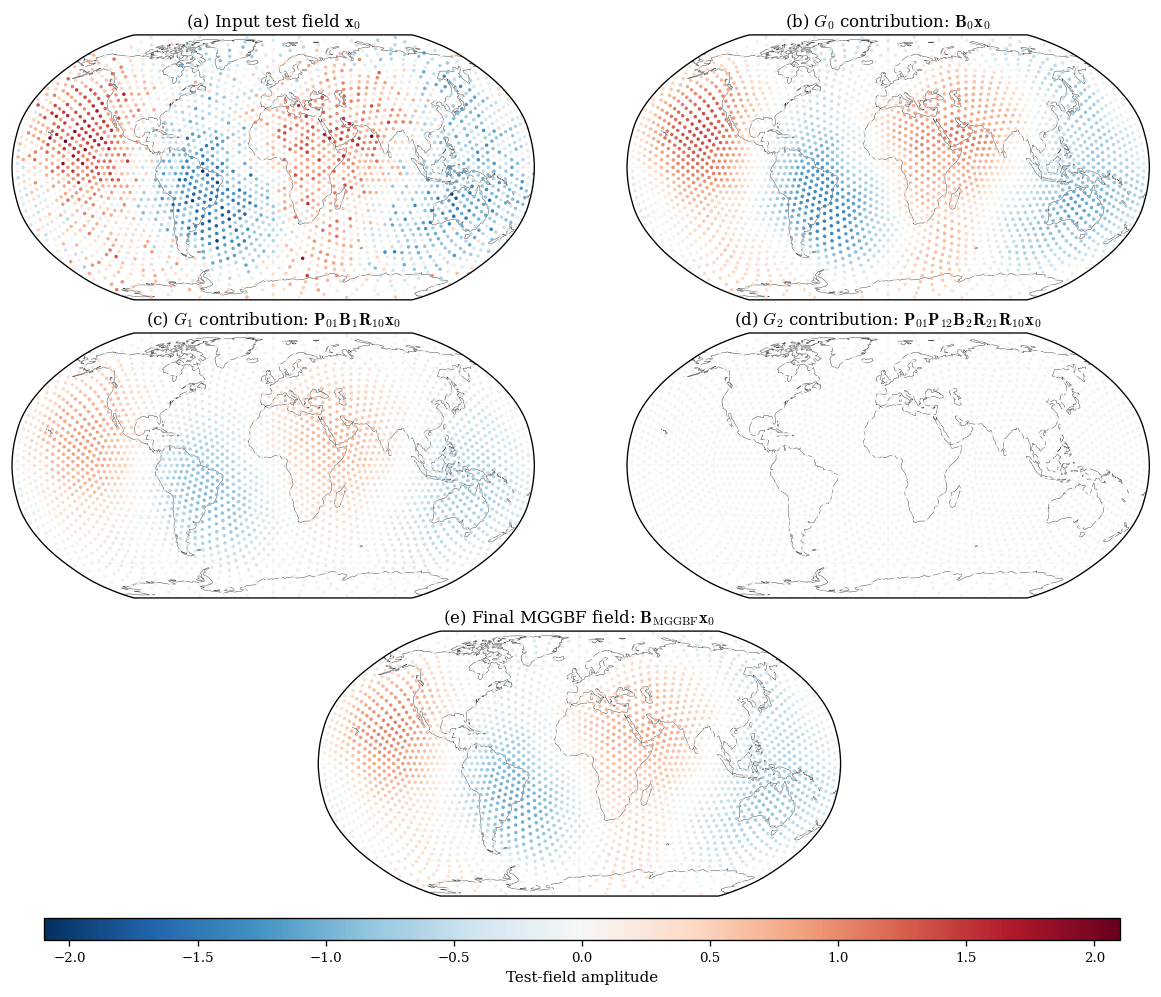

In [ ]:
# ============================================================
# Figure 8: repeated-resolvent MGGF, p=5
#
# Multilevel smoothing with B_l^(p)=[I+(mu_l/p)L_l]^(-p), p=5
#
# Panels:
#   (a) input field on G0
#   (b) G0 Graph Beta Filter contribution
#   (c) G1 contribution transferred back to G0
#   (d) G2 contribution transferred back to G0
#   (e) final weighted MGGBF field
#   (f) parameters and quantitative diagnostics
#
# The numerical operator is unchanged from
# test_multilevel_beta_filter_v2.py.
# ============================================================

# Run once in a new Colab notebook if Cartopy is unavailable:
!pip -q install cartopy

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs


# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"
os.makedirs(PAPER_FIG_DIR, exist_ok=True)

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"
G1_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub3.npz"
G2_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

OUT_DATA_FILE = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_p5_v2_data.npz"
)

OUT_PNG = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_p5_v2.png"
)

OUT_PDF = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_p5_v2.pdf"
)


# ============================================================
# Filter parameters
# ============================================================

P_ORDER = 5

MU0 = 0.50
MU1 = 2.00
MU2 = 6.00

W0 = 1.00
W1 = 0.50
W2 = 0.25

WSUM = W0 + W1 + W2

RNG_SEED = 1234

# Keep the same noise amplitude used in the validated experiment.
NOISE_AMPLITUDE = 0.35


# ============================================================
# Publication settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "mathtext.fontset": "cm",
})


# ============================================================
# Utilities
# ============================================================

def load_grid(path):
    """Load one graph generation."""

    if not os.path.exists(path):
        raise FileNotFoundError(f"Grid file not found:\n{path}")

    g = np.load(path, allow_pickle=True)

    xyz = g["cell_center_xyz"].astype(np.float64)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]

    lon = g["cell_center_lon"].astype(np.float64)
    lat = g["cell_center_lat"].astype(np.float64)
    area = g["cell_area"].astype(np.float64)

    # Convert radians to degrees when necessary.
    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return {
        "xyz": xyz,
        "lon": lon,
        "lat": lat,
        "area": area,
        "dual_cells": g["dual_cells"],
        "ncells": len(area),
    }


def build_PR(parent, area_f, area_c):
    """
    Construct prolongation P and conservative area-weighted
    restriction R.

    P maps coarse values to all associated fine cells.
    R maps fine values to coarse cells using area weighting.
    """

    parent = np.asarray(parent, dtype=np.int64)

    nf = len(parent)
    nc = len(area_c)

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Parent map contains an invalid coarse-cell index.")

    rows = np.arange(nf, dtype=np.int64)
    cols = parent
    vals = np.ones(nf, dtype=np.float64)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


def build_neighbors_from_dual_cells(dual_cells):
    """Construct cell-neighbor lists from shared polygon edges."""

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))
            edge_to_cells.setdefault(key, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]

    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            neighbors[i].add(j)
            neighbors[j].add(i)

    return [sorted(nbrs) for nbrs in neighbors]


def build_graph_laplacian(dual_cells):
    """Construct the unweighted combinatorial graph Laplacian."""

    neighbors = build_neighbors_from_dual_cells(dual_cells)
    n = len(neighbors)

    rows = []
    cols = []
    vals = []

    degree = np.zeros(n, dtype=np.float64)

    for i, nbrs in enumerate(neighbors):
        degree[i] = len(nbrs)

        rows.append(i)
        cols.append(i)
        vals.append(degree[i])

        for j in nbrs:
            rows.append(i)
            cols.append(j)
            vals.append(-1.0)

    L = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    return L, degree


def graph_filter_apply(L, mu, p, x):
    """Apply B^(p) = [I + (mu/p)L]^(-p) to x."""
    system = sp.eye(L.shape[0], format="csr") + (mu / float(p)) * L
    solve = spla.factorized(system.tocsc())
    y = np.asarray(x, dtype=np.float64).copy()
    for _ in range(p):
        y = solve(y)
    return y


def area_mean(x, area):
    """Area-weighted global mean."""

    return np.sum(area * x) / np.sum(area)


def area_std(x, area):
    """Area-weighted standard deviation."""

    mean = area_mean(x, area)

    return np.sqrt(
        np.sum(area * (x - mean) ** 2)
        / np.sum(area)
    )


def area_norm(x, area):
    """Area-weighted quadratic norm squared."""

    return np.sum(area * x * x)


def report_field(name, x, area):
    """Print compact field diagnostics."""

    print(
        f"{name:38s}"
        f" mean={area_mean(x, area):+.8e}"
        f" std={area_std(x, area):.8e}"
        f" min={np.min(x):+.8e}"
        f" max={np.max(x):+.8e}"
    )


def draw_map_panel(
    ax,
    grid,
    field,
    title,
    norm,
    cmap,
    point_size=4.5,
):
    """Draw one global field panel on a Robinson projection."""

    ax.set_global()

    ax.coastlines(
        linewidth=0.30,
        color="0.30"
    )

    ax.gridlines(
        linewidth=0.25,
        color="0.55",
        alpha=0.45,
        linestyle=":"
    )

    scatter = ax.scatter(
        grid["lon"],
        grid["lat"],
        c=field,
        s=point_size,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        linewidths=0.0,
        rasterized=True,
        zorder=2
    )

    ax.set_title(
        title,
        pad=5
    )

    return scatter


# ============================================================
# Load grids and communication maps
# ============================================================

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

if not os.path.exists(COMM_FILE):
    raise FileNotFoundError(
        f"Communication file not found:\n{COMM_FILE}"
    )

comm = np.load(COMM_FILE, allow_pickle=True)

parent01 = comm["parent01"].astype(np.int64)
parent12 = comm["parent12"].astype(np.int64)

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"]
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"]
)

P02 = P01 @ P12
R20 = R21 @ R10

print("=" * 72)
print("GRID HIERARCHY")
print("=" * 72)
print(f"G0 cells: {G0['ncells']}")
print(f"G1 cells: {G1['ncells']}")
print(f"G2 cells: {G2['ncells']}")


# ============================================================
# Construct graph Laplacians
# ============================================================

L0, degree0 = build_graph_laplacian(G0["dual_cells"])
L1, degree1 = build_graph_laplacian(G1["dual_cells"])
L2, degree2 = build_graph_laplacian(G2["dual_cells"])

print("\nGraph degree ranges:")
print(
    "G0:",
    degree0.min(),
    degree0.mean(),
    degree0.max()
)
print(
    "G1:",
    degree1.min(),
    degree1.mean(),
    degree1.max()
)
print(
    "G2:",
    degree2.min(),
    degree2.mean(),
    degree2.max()
)


# ============================================================
# Construct the G0 test field
# ============================================================

rng = np.random.default_rng(RNG_SEED)

lon0_rad = np.deg2rad(G0["lon"])
lat0_rad = np.deg2rad(G0["lat"])

# Smooth, large-scale component.
x_smooth = (
    np.sin(2.0 * lon0_rad) * np.cos(lat0_rad)
    + 0.35 * np.sin(3.0 * lat0_rad)
    + 0.20 * np.cos(
        3.0 * lon0_rad
        + 2.0 * lat0_rad
    )
)

# Spatially uncorrelated perturbation.
x_noise = rng.standard_normal(G0["ncells"])
x_noise -= area_mean(x_noise, G0["area"])

# Combined test field.
x0 = x_smooth + NOISE_AMPLITUDE * x_noise
x0 -= area_mean(x0, G0["area"])


# ============================================================
# Apply the three-level MGGBF
# ============================================================

# Restrict the input field to the coarse graph levels.
x1 = R10 @ x0
x2 = R20 @ x0

# Filter independently on each graph generation.
y0_from0 = graph_filter_apply(L0, MU0, P_ORDER, x0)

y1_filtered = graph_filter_apply(L1, MU1, P_ORDER, x1)

y2_filtered = graph_filter_apply(L2, MU2, P_ORDER, x2)

# Return coarse-level contributions to G0.
y0_from1 = P01 @ y1_filtered
y0_from2 = P02 @ y2_filtered

# Weighted MGGBF combination.
y0_MGGBF = (
    W0 * y0_from0
    + W1 * y0_from1
    + W2 * y0_from2
) / WSUM


# ============================================================
# Quantitative diagnostics
# ============================================================

mean_input = area_mean(x0, G0["area"])
mean_g0 = area_mean(y0_from0, G0["area"])
mean_mggbf = area_mean(y0_MGGBF, G0["area"])

std_input = area_std(x0, G0["area"])
std_g0 = area_std(y0_from0, G0["area"])
std_g1 = area_std(y0_from1, G0["area"])
std_g2 = area_std(y0_from2, G0["area"])
std_mggbf = area_std(y0_MGGBF, G0["area"])

ratio_g0 = std_g0 / std_input
ratio_mggbf = std_mggbf / std_input

norm_input = area_norm(x0, G0["area"])
norm_g0 = area_norm(y0_from0, G0["area"])
norm_mggbf = area_norm(y0_MGGBF, G0["area"])

mean_error_g0 = abs(mean_g0 - mean_input)
mean_error_mggbf = abs(mean_mggbf - mean_input)

print("\n" + "=" * 72)
print("FIELD DIAGNOSTICS")
print("=" * 72)

report_field(
    "Input field x0",
    x0,
    G0["area"]
)

report_field(
    "G0 contribution B0 x0",
    y0_from0,
    G0["area"]
)

report_field(
    "G1 contribution P01 B1 R10 x0",
    y0_from1,
    G0["area"]
)

report_field(
    "G2 contribution P01 P12 B2 R21 R10 x0",
    y0_from2,
    G0["area"]
)

report_field(
    "Final MGGBF field",
    y0_MGGBF,
    G0["area"]
)

print("\nStandard-deviation ratios:")
print(
    "std(B0 x0) / std(x0)       =",
    ratio_g0
)
print(
    "std(MGGBF x0) / std(x0)    =",
    ratio_mggbf
)

print("\nArea-weighted mean preservation:")
print("mean(input)                 =", mean_input)
print("mean(B0 input)              =", mean_g0)
print("mean(MGGBF input)           =", mean_mggbf)
print("|mean(B0)-mean(input)|       =", mean_error_g0)
print("|mean(MGGBF)-mean(input)|    =", mean_error_mggbf)

print("\nArea-weighted quadratic norms:")
print("<x0,x0>_A                   =", norm_input)
print("<B0x0,B0x0>_A               =", norm_g0)
print("<MGGBF x0,MGGBF x0>_A       =", norm_mggbf)


# ============================================================
# Shared color normalization
# ============================================================

fields = [
    x0,
    y0_from0,
    y0_from1,
    y0_from2,
    y0_MGGBF,
]

# Use one symmetric scale for all five maps.
vmax = max(
    np.max(np.abs(field))
    for field in fields
)

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0.0,
    vmax=vmax
)

cmap = "RdBu_r"


# ============================================================
# Publication-quality Figure 8
# ============================================================

projection = ccrs.Robinson()

fig = plt.figure(
    figsize=(10.0, 8.2),
    constrained_layout=True
)

grid_spec = fig.add_gridspec(
    nrows=3,
    ncols=4,
    height_ratios=[1.0, 1.0, 1.0],
    width_ratios=[1.0, 1.0, 1.0, 1.0]
)

ax_a = fig.add_subplot(
    grid_spec[0, 0:2],
    projection=projection
)

ax_b = fig.add_subplot(
    grid_spec[0, 2:4],
    projection=projection
)

ax_c = fig.add_subplot(
    grid_spec[1, 0:2],
    projection=projection
)

ax_d = fig.add_subplot(
    grid_spec[1, 2:4],
    projection=projection
)

ax_e = fig.add_subplot(
    grid_spec[2, 1:3],
    projection=projection
)


scatter = draw_map_panel(
    ax_a,
    G0,
    x0,
    r"(a) Input test field $\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_b,
    G0,
    y0_from0,
    r"(b) $G_0$ contribution: "
    r"$\mathbf{B}_0\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_c,
    G0,
    y0_from1,
    r"(c) $G_1$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{B}_1"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_d,
    G0,
    y0_from2,
    r"(d) $G_2$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{P}_{12}"
    r"\mathbf{B}_2\mathbf{R}_{21}"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_e,
    G0,
    y0_MGGBF,
    r"(e) Final MGGBF field: "
    r"$\mathbf{B}_{\mathrm{MGGBF}}\mathbf{x}_0$",
    norm,
    cmap
)

# ============================================================
# Shared horizontal colorbar
# ============================================================

colorbar = fig.colorbar(
    scatter,
    ax=[ax_a, ax_b, ax_c, ax_d, ax_e],
    orientation="horizontal",
    fraction=0.025,
    pad=0.025,
    aspect=50
)

colorbar.set_label(
    "Test-field amplitude",
    fontsize=9
)

colorbar.ax.tick_params(
    labelsize=8
)


# ============================================================
# Save figure and data
# ============================================================

fig.savefig(
    OUT_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

np.savez(
    OUT_DATA_FILE,
    x0=x0,
    x_smooth=x_smooth,
    x_noise=x_noise,
    y0_from0=y0_from0,
    y0_from1=y0_from1,
    y0_from2=y0_from2,
    y0_MGGBF=y0_MGGBF,
    p=P_ORDER,
    mu0=MU0,
    mu1=MU1,
    mu2=MU2,
    w0=W0,
    w1=W1,
    w2=W2,
    noise_amplitude=NOISE_AMPLITUDE,
    std_input=std_input,
    std_g0=std_g0,
    std_g1=std_g1,
    std_g2=std_g2,
    std_mggbf=std_mggbf,
    ratio_g0=ratio_g0,
    ratio_mggbf=ratio_mggbf,
    mean_input=mean_input,
    mean_g0=mean_g0,
    mean_mggbf=mean_mggbf,
    mean_error_g0=mean_error_g0,
    mean_error_mggbf=mean_error_mggbf,
    norm_input=norm_input,
    norm_g0=norm_g0,
    norm_mggbf=norm_mggbf,
)

print("\n" + "=" * 72)
print("OUTPUT")
print("=" * 72)
print("Saved PNG :", OUT_PNG)
print("Saved PDF :", OUT_PDF)
print("Saved data:", OUT_DATA_FILE)

plt.show()

# Adjusted Figs. 9, 10 and 11

GRID
Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6
Longitude range: -177.15991793333276 180.0
Latitude range: -90.0 90.0
Degree counts: {5: 12, 6: 2550}

Self-adjointness test for B = S S
Relative error: 0.01436205285021424

Impulse cells:
Equatorial cell: 38 lon/lat = 0.0 0.0 degree = 6
Pentagonal cell: 0 lon/lat = 121.717474411461 0.0 degree = 5

Equatorial hexagonal cell
Cell: 38
Longitude/latitude: 0.0 0.0
Degree: 6
Area: 199901681988.97357

Area integral:
  impulse       = 1.0
  intermediate S diagnostic = not applicable
  B impulse     = 1.003865799867584

Peak cell-integrated response:
  impulse       = 1.0
  intermediate S diagnostic = not applicable
  B impulse     = 0.1567307846619426

Shell-integrated B impulse:
  ring  0: 1.5673078466e-01
  ring  1: 4.0429668343e-01
  ring  2: 2.7593241753e-01
  ring  3: 1.1459181918e-01
  ring  4: 3.7997749096e-02
  ring  5: 1.0805576250e-02
  ring  6: 2.7105804848e-03
  ring  7: 6.3

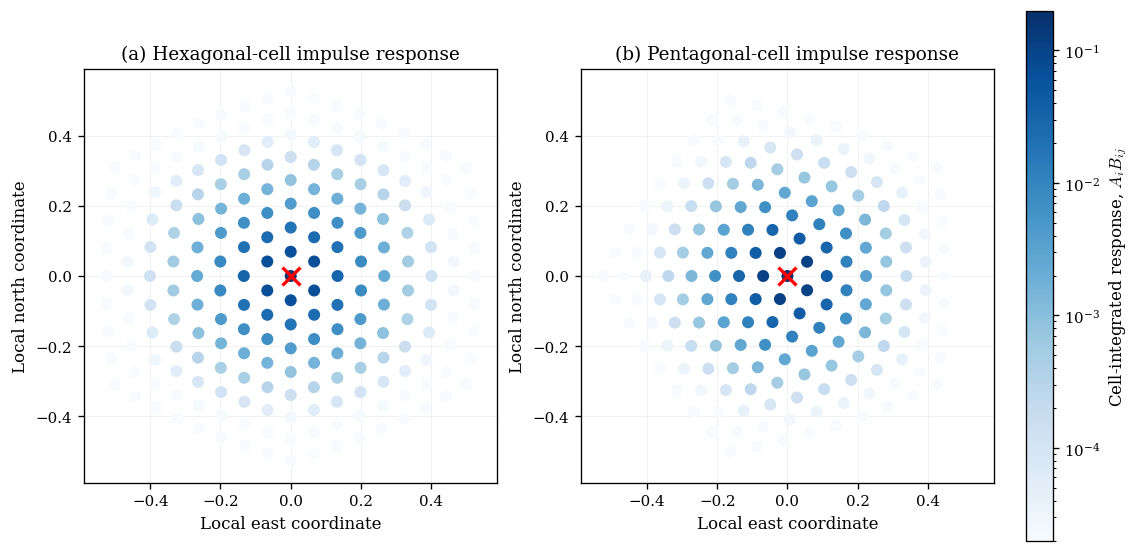

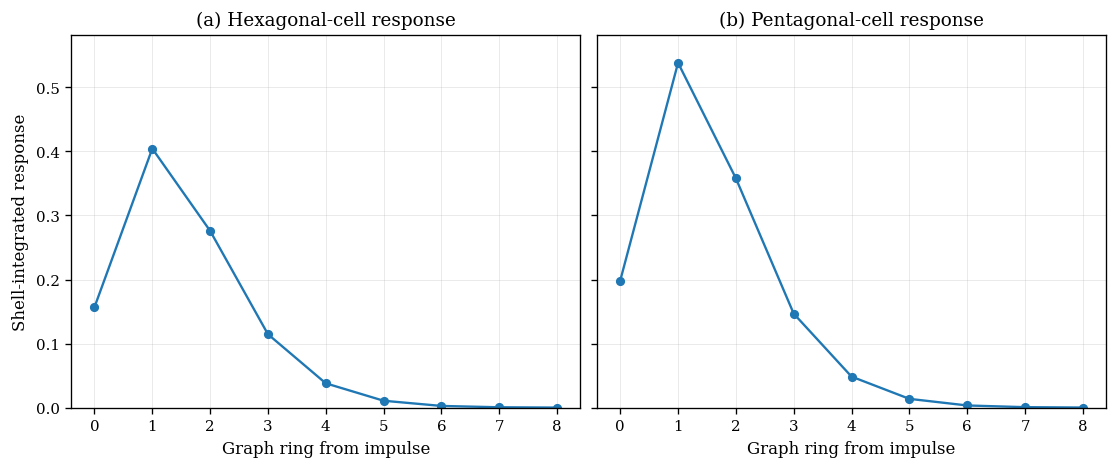

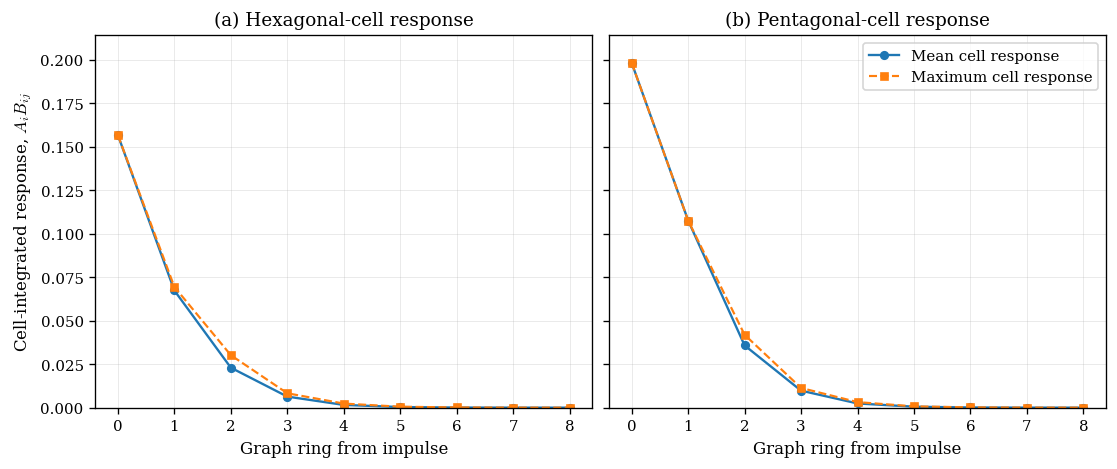

In [ ]:
# ============================================================
# Publication figures for single-level Graph Beta Filter
#
# Figure 9:
#   Localized impulse responses for a hexagonal and pentagonal cell
#
# Figure 10:
#   Shell-integrated responses by graph ring
#
# Figure 11:
#   Mean and maximum local response decay by graph ring
# ============================================================

import os
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm


# ============================================================
# Configuration
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"
PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"

os.makedirs(PAPER_FIG_DIR, exist_ok=True)

GRID_FILE = f"{GRID_DIR}/global_hex_ico_grid_v0.npz"

# Output figures
FIG09_PNG = f"{PAPER_FIG_DIR}/fig09_local_impulse_response_p5_v2.png"
FIG09_PDF = f"{PAPER_FIG_DIR}/fig09_local_impulse_response_p5_v2.pdf"

FIG10_PNG = f"{PAPER_FIG_DIR}/fig10_shell_integrated_response_p5_v2.png"
FIG10_PDF = f"{PAPER_FIG_DIR}/fig10_shell_integrated_response_p5_v2.pdf"

FIG11_PNG = f"{PAPER_FIG_DIR}/fig11_local_response_decay_p5_v2.png"
FIG11_PDF = f"{PAPER_FIG_DIR}/fig11_local_response_decay_p5_v2.pdf"

OUT_DATA = f"{PAPER_FIG_DIR}/fig09_11_single_level_p5_v2_data.npz"

# Graph filter parameters
P_ORDER = 5
MU = 0.50

# Diagnostics and plotting
MAX_PLOT_RING = 8
POINT_SIZE = 52
IMPULSE_MARKER_SIZE = 115

# Sequential colormap:
# low response -> nearly white
# high response -> dark blue
RESPONSE_CMAP = "Blues"

# Save quality
PNG_DPI = 600


# ============================================================
# Publication style
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": PNG_DPI,
})


# ============================================================
# Load grid
# ============================================================

if not os.path.exists(GRID_FILE):
    raise FileNotFoundError(f"Grid file not found:\n{GRID_FILE}")

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)

xyz = grid["cell_center_xyz"].astype(np.float64)
xyz /= np.linalg.norm(xyz, axis=1)[:, None]

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

# Auto-detect radians versus degrees
if np.max(np.abs(lon_raw)) <= 2.0 * np.pi + 1.0e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size

print("=" * 72)
print("GRID")
print("=" * 72)
print("Number of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())
print("Longitude range:", lon.min(), lon.max())
print("Latitude range:", lat.min(), lat.max())


# ============================================================
# Build graph neighbors
# ============================================================

def build_neighbors_from_primal_faces(grid_data, number_of_cells):
    """Construct cell-neighbor lists from primal triangular faces."""

    faces = grid_data["primal_faces"]
    neighbors_local = [set() for _ in range(number_of_cells)]

    for tri in faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neighbors_local[a].add(b)
        neighbors_local[a].add(c)

        neighbors_local[b].add(a)
        neighbors_local[b].add(c)

        neighbors_local[c].add(a)
        neighbors_local[c].add(b)

    return [sorted(s) for s in neighbors_local]


neighbors = build_neighbors_from_primal_faces(grid, ncells)
degree = np.array([len(nbrs) for nbrs in neighbors])

print(
    "Degree counts:",
    {
        int(d): int(np.sum(degree == d))
        for d in sorted(set(degree))
    }
)


# ============================================================
# Graph-ring utilities
# ============================================================

def graph_rings_for_cell(i0, neighbors_local, maximum_ring):
    """Return graph rings centered on cell i0."""

    visited = {i0}
    rings = [[i0]]
    frontier = [i0]

    for _ in range(1, maximum_ring + 1):
        new_frontier = []

        for q in frontier:
            for j in neighbors_local[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings


def graph_distance_from_cell(i0, neighbors_local, max_r=None):
    """Breadth-first graph distance from one cell."""

    distance = -np.ones(len(neighbors_local), dtype=np.int64)
    distance[i0] = 0

    frontier = [i0]

    while frontier:
        new_frontier = []

        for q in frontier:
            if max_r is not None and distance[q] >= max_r:
                continue

            for j in neighbors_local[q]:
                if distance[j] < 0:
                    distance[j] = distance[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return distance


# ============================================================
# Current repeated-resolvent Graph Filter
# B^(p) = [I + (mu/p)L]^(-p), p=5
# ============================================================

P_ORDER = 5
MU = 0.50

rows, cols, vals = [], [], []
for i, nbrs in enumerate(neighbors):
    rows.append(i); cols.append(i); vals.append(float(len(nbrs)))
    for j in nbrs:
        rows.append(i); cols.append(j); vals.append(-1.0)

L = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
system = sp.eye(ncells, format="csr") + (MU / float(P_ORDER)) * L
solve = sp.linalg.factorized(system.tocsc())

def B_apply(field):
    y = np.asarray(field, dtype=np.float64).copy()
    for _ in range(P_ORDER):
        y = solve(y)
    return y

def inner_A(x, y):
    return np.sum(area * x * y)

def integral_A(x):
    return np.sum(area * x)

# ============================================================
# Self-adjointness test
# ============================================================

rng = np.random.default_rng(1234)

x_test = rng.standard_normal(ncells)
y_test = rng.standard_normal(ncells)

lhs = inner_A(x_test, B_apply(y_test))
rhs = inner_A(B_apply(x_test), y_test)

self_adjoint_error = (
    abs(lhs - rhs)
    / max(abs(lhs), abs(rhs), 1.0e-300)
)

print("\nSelf-adjointness test for B = S S")
print("Relative error:", self_adjoint_error)


# ============================================================
# Select impulse cells
# ============================================================

# Regular equatorial hexagonal cell near 0° longitude and latitude
i_equator = int(
    np.argmin(
        (lon - 0.0) ** 2
        + (lat - 0.0) ** 2
    )
)

# First pentagonal cell
pentagon_indices = np.where(degree == 5)[0]

if len(pentagon_indices) == 0:
    raise RuntimeError("No pentagonal cells were found.")

i_pentagon = int(pentagon_indices[0])

print("\nImpulse cells:")
print(
    "Equatorial cell:",
    i_equator,
    "lon/lat =",
    lon[i_equator],
    lat[i_equator],
    "degree =",
    degree[i_equator]
)
print(
    "Pentagonal cell:",
    i_pentagon,
    "lon/lat =",
    lon[i_pentagon],
    lat[i_pentagon],
    "degree =",
    degree[i_pentagon]
)


# ============================================================
# Compute impulse responses
# ============================================================

def compute_impulse_response(i0, max_ring=MAX_PLOT_RING):
    """Apply B to a unit-area impulse centered at i0."""

    delta = np.zeros(ncells, dtype=np.float64)
    delta[i0] = 1.0 / area[i0]

    after_adjoint = np.full_like(delta, np.nan)  # obsolete diagnostic retained only for interface
    response = B_apply(delta)

    distance = graph_distance_from_cell(
        i0,
        neighbors,
        max_r=max_ring
    )

    return delta, after_adjoint, response, distance


delta_hex, adj_hex, response_hex, distance_hex = (
    compute_impulse_response(i_equator)
)

delta_pent, adj_pent, response_pent, distance_pent = (
    compute_impulse_response(i_pentagon)
)


# ============================================================
# Diagnostics
# ============================================================

def print_impulse_diagnostics(
    i0,
    delta,
    adjoint_response,
    response,
    distance,
    label,
    max_ring=MAX_PLOT_RING
):
    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)

    print("Cell:", i0)
    print("Longitude/latitude:", lon[i0], lat[i0])
    print("Degree:", degree[i0])
    print("Area:", area[i0])

    print("\nArea integral:")
    print("  impulse       =", integral_A(delta))
    print("  intermediate S diagnostic = not applicable")
    print("  B impulse     =", integral_A(response))

    print("\nPeak cell-integrated response:")
    print("  impulse       =", np.max(area * delta))
    print("  intermediate S diagnostic = not applicable")
    print("  B impulse     =", np.max(area * response))

    print("\nShell-integrated B impulse:")
    for ring in range(max_ring + 1):
        mask = distance == ring

        if np.any(mask):
            shell_value = np.sum(
                area[mask] * response[mask]
            )
            print(
                f"  ring {ring:2d}: "
                f"{shell_value:.10e}"
            )


print_impulse_diagnostics(
    i_equator,
    delta_hex,
    adj_hex,
    response_hex,
    distance_hex,
    "Equatorial hexagonal cell"
)

print_impulse_diagnostics(
    i_pentagon,
    delta_pent,
    adj_pent,
    response_pent,
    distance_pent,
    "Pentagonal cell"
)


# ============================================================
# Local tangent-plane coordinates
# ============================================================

def tangent_coordinates(i0, mask):
    """Project selected cell centers onto a local tangent plane."""

    center = xyz[i0].astype(np.float64)
    center /= np.linalg.norm(center)

    z_axis = np.array([0.0, 0.0, 1.0])

    east = np.cross(z_axis, center)

    if np.linalg.norm(east) < 1.0e-12:
        east = np.array([1.0, 0.0, 0.0])
    else:
        east /= np.linalg.norm(east)

    north = np.cross(center, east)
    north /= np.linalg.norm(north)

    selected_xyz = xyz[mask].astype(np.float64)
    selected_xyz /= np.linalg.norm(
        selected_xyz,
        axis=1
    )[:, None]

    displacement = selected_xyz - center[None, :]

    local_east = displacement @ east
    local_north = displacement @ north

    return local_east, local_north


def local_response_data(
    i0,
    response,
    distance,
    max_ring=MAX_PLOT_RING
):
    mask = (
        (distance >= 0)
        & (distance <= max_ring)
    )

    local_east, local_north = tangent_coordinates(
        i0,
        mask
    )

    response_mass = area[mask] * response[mask]

    return (
        local_east,
        local_north,
        response_mass,
        mask
    )


xe_hex, yn_hex, mass_hex, mask_hex = local_response_data(
    i_equator,
    response_hex,
    distance_hex
)

xe_pent, yn_pent, mass_pent, mask_pent = local_response_data(
    i_pentagon,
    response_pent,
    distance_pent
)


# ============================================================
# Shared logarithmic normalization for Figure 9
# ============================================================

all_positive_values = np.concatenate([
    mass_hex[mass_hex > 0.0],
    mass_pent[mass_pent > 0.0]
])

if all_positive_values.size == 0:
    raise RuntimeError(
        "The impulse response contains no positive values."
    )

# Common limits permit direct comparison.
response_vmax = np.max(all_positive_values)

# Do not allow extremely tiny numerical tails to dominate the scale.
response_vmin = max(
    np.min(all_positive_values),
    response_vmax * 1.0e-4
)

response_norm = LogNorm(
    vmin=response_vmin,
    vmax=response_vmax
)


# ============================================================
# Figure 9: localized impulse responses
# ============================================================

fig9, axes9 = plt.subplots(
    1,
    2,
    figsize=(9.4, 4.5),
    constrained_layout=True
)

panel_data = [
    (
        axes9[0],
        xe_hex,
        yn_hex,
        mass_hex,
        r"(a) Hexagonal-cell impulse response"
    ),
    (
        axes9[1],
        xe_pent,
        yn_pent,
        mass_pent,
        r"(b) Pentagonal-cell impulse response"
    ),
]

scatter9 = None

for ax, xe, yn, response_mass, title in panel_data:
    scatter9 = ax.scatter(
        xe,
        yn,
        c=response_mass,
        s=POINT_SIZE,
        cmap=RESPONSE_CMAP,
        norm=response_norm,
        edgecolors="none",
        rasterized=True,
        zorder=2
    )

    # Impulse location: smaller and without a legend
    ax.scatter(
        [0.0],
        [0.0],
        marker="x",
        s=IMPULSE_MARKER_SIZE,
        c="red",
        linewidths=2.0,
        zorder=4
    )

    ax.set_title(title, pad=6)
    ax.set_xlabel("Local east coordinate")
    ax.set_ylabel("Local north coordinate")

    ax.set_aspect("equal", adjustable="box")
    ax.grid(
        True,
        linewidth=0.4,
        alpha=0.25
    )

# Identical limits for direct comparison
x_extent = max(
    np.max(np.abs(xe_hex)),
    np.max(np.abs(xe_pent))
)

y_extent = max(
    np.max(np.abs(yn_hex)),
    np.max(np.abs(yn_pent))
)

padding = 1.12

for ax in axes9:
    ax.set_xlim(
        -padding * x_extent,
        padding * x_extent
    )
    ax.set_ylim(
        -padding * y_extent,
        padding * y_extent
    )

colorbar9 = fig9.colorbar(
    scatter9,
    ax=axes9,
    orientation="vertical",
    fraction=0.040,
    pad=0.035
)

colorbar9.set_label(
    r"Cell-integrated response, $A_i B_{ij}$"
)

fig9.savefig(
    FIG09_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig9.savefig(
    FIG09_PDF,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# Graph-ring diagnostics
# ============================================================

def radial_response_data(
    response,
    distance,
    max_ring=MAX_PLOT_RING
):
    rings = []
    shell_mass = []
    mean_cell_mass = []
    maximum_cell_mass = []

    for ring in range(max_ring + 1):
        mask = distance == ring

        if not np.any(mask):
            continue

        cell_mass = area[mask] * response[mask]

        rings.append(ring)
        shell_mass.append(np.sum(cell_mass))
        mean_cell_mass.append(np.mean(cell_mass))
        maximum_cell_mass.append(np.max(cell_mass))

    return (
        np.asarray(rings),
        np.asarray(shell_mass),
        np.asarray(mean_cell_mass),
        np.asarray(maximum_cell_mass)
    )


(
    rings_hex,
    shell_hex,
    mean_hex,
    maximum_hex
) = radial_response_data(
    response_hex,
    distance_hex
)

(
    rings_pent,
    shell_pent,
    mean_pent,
    maximum_pent
) = radial_response_data(
    response_pent,
    distance_pent
)


# ============================================================
# Figure 10: shell-integrated responses
# ============================================================

fig10, axes10 = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

axes10[0].plot(
    rings_hex,
    shell_hex,
    marker="o",
    linewidth=1.4,
    markersize=4.5
)

axes10[1].plot(
    rings_pent,
    shell_pent,
    marker="o",
    linewidth=1.4,
    markersize=4.5
)

axes10[0].set_title(
    r"(a) Hexagonal-cell response"
)

axes10[1].set_title(
    r"(b) Pentagonal-cell response"
)

for ax in axes10:
    ax.set_xlabel("Graph ring from impulse")
    ax.grid(
        True,
        linewidth=0.45,
        alpha=0.35
    )
    ax.set_xticks(
        np.arange(0, MAX_PLOT_RING + 1, 1)
    )

axes10[0].set_ylabel(
    r"Shell-integrated response"
)

shell_ymax = 1.08 * max(
    np.max(shell_hex),
    np.max(shell_pent)
)

axes10[0].set_ylim(0.0, shell_ymax)

fig10.savefig(
    FIG10_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig10.savefig(
    FIG10_PDF,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# Figure 11: local response decay
# ============================================================

fig11, axes11 = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

axes11[0].plot(
    rings_hex,
    mean_hex,
    marker="o",
    linewidth=1.4,
    markersize=4.5,
    label="Mean cell response"
)

axes11[0].plot(
    rings_hex,
    maximum_hex,
    marker="s",
    linestyle="--",
    linewidth=1.3,
    markersize=4.2,
    label="Maximum cell response"
)

axes11[1].plot(
    rings_pent,
    mean_pent,
    marker="o",
    linewidth=1.4,
    markersize=4.5,
    label="Mean cell response"
)

axes11[1].plot(
    rings_pent,
    maximum_pent,
    marker="s",
    linestyle="--",
    linewidth=1.3,
    markersize=4.2,
    label="Maximum cell response"
)

axes11[0].set_title(
    r"(a) Hexagonal-cell response"
)

axes11[1].set_title(
    r"(b) Pentagonal-cell response"
)

for ax in axes11:
    ax.set_xlabel("Graph ring from impulse")
    ax.grid(
        True,
        linewidth=0.45,
        alpha=0.35
    )
    ax.set_xticks(
        np.arange(0, MAX_PLOT_RING + 1, 1)
    )

axes11[0].set_ylabel(
    r"Cell-integrated response, $A_i B_{ij}$"
)

decay_ymax = 1.08 * max(
    np.max(maximum_hex),
    np.max(maximum_pent)
)

axes11[0].set_ylim(0.0, decay_ymax)

# One legend is sufficient for both panels
axes11[1].legend(
    loc="upper right",
    frameon=True
)

fig11.savefig(
    FIG11_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig11.savefig(
    FIG11_PDF,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# Save numerical data
# ============================================================

np.savez(
    OUT_DATA,
    i_equator=i_equator,
    i_pentagon=i_pentagon,
    lon=lon,
    lat=lat,
    area=area,
    degree=degree,
    delta_hex=delta_hex,
    delta_pent=delta_pent,
    response_hex=response_hex,
    response_pent=response_pent,
    distance_hex=distance_hex,
    distance_pent=distance_pent,
    xe_hex=xe_hex,
    yn_hex=yn_hex,
    mass_hex=mass_hex,
    xe_pent=xe_pent,
    yn_pent=yn_pent,
    mass_pent=mass_pent,
    rings_hex=rings_hex,
    shell_hex=shell_hex,
    mean_hex=mean_hex,
    maximum_hex=maximum_hex,
    rings_pent=rings_pent,
    shell_pent=shell_pent,
    mean_pent=mean_pent,
    maximum_pent=maximum_pent,
    self_adjoint_error=self_adjoint_error,
    p_order=P_ORDER,
    mu=MU,
)


# ============================================================
# Report saved files
# ============================================================

print("\n" + "=" * 72)
print("PUBLICATION OUTPUT")
print("=" * 72)

print("Saved Figure 9 PNG :", FIG09_PNG)
print("Saved Figure 9 PDF :", FIG09_PDF)

print("Saved Figure 10 PNG:", FIG10_PNG)
print("Saved Figure 10 PDF:", FIG10_PDF)

print("Saved Figure 11 PNG:", FIG11_PNG)
print("Saved Figure 11 PDF:", FIG11_PDF)

print("Saved numerical data:", OUT_DATA)

plt.show()

# Toward corrcted script

AREA-COMPATIBLE REPEATED-RESOLVENT TEST
B^(p)=[I+(mu/p)L_A]^(-p), p=5, mu=0.5
L_A=Ahat^(-1)Q, Ahat=A/mean(A)
cells: 2562  degree counts: {5: 12, 6: 2550}
area min/max: 134536555820.17395 238195365847.2499  Aref: 199102146397.6431

AREA-WEIGHTED SELF-ADJOINTNESS
old unweighted: 0.01077044241666608
new area-compatible: 1.4036158510508538e-16

CONSTANT PRESERVATION
old: 4.218847493575595e-15
new: 5.218048215738236e-15

--------------------------------------------------------------------------------------
OLD
hex: cell=38 degree=6 area=1.999016819890e+11
  integral=1.0038657998675840 error=3.865800e-03
  central=0.156730784662 anisotropy=1.09369193 centroid=9.554449e-18
  ring  0: 1.567307846619e-01
  ring  1: 4.042966834331e-01
  ring  2: 2.759324175296e-01
  ring  3: 1.145918191769e-01
  ring  4: 3.799774909569e-02
  ring  5: 1.080557624951e-02
  ring  6: 2.710580484776e-03
  ring  7: 6.302582131399e-04
  ring  8: 1.345576087887e-04
  ring  9: 2.806483184156e-05
  ring 10: 5.843117402798

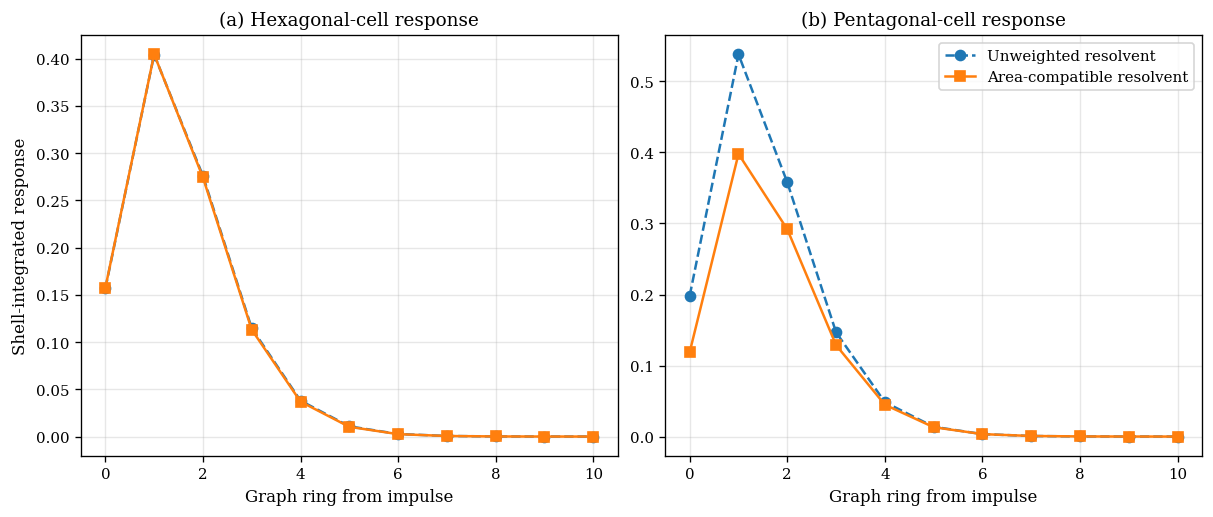

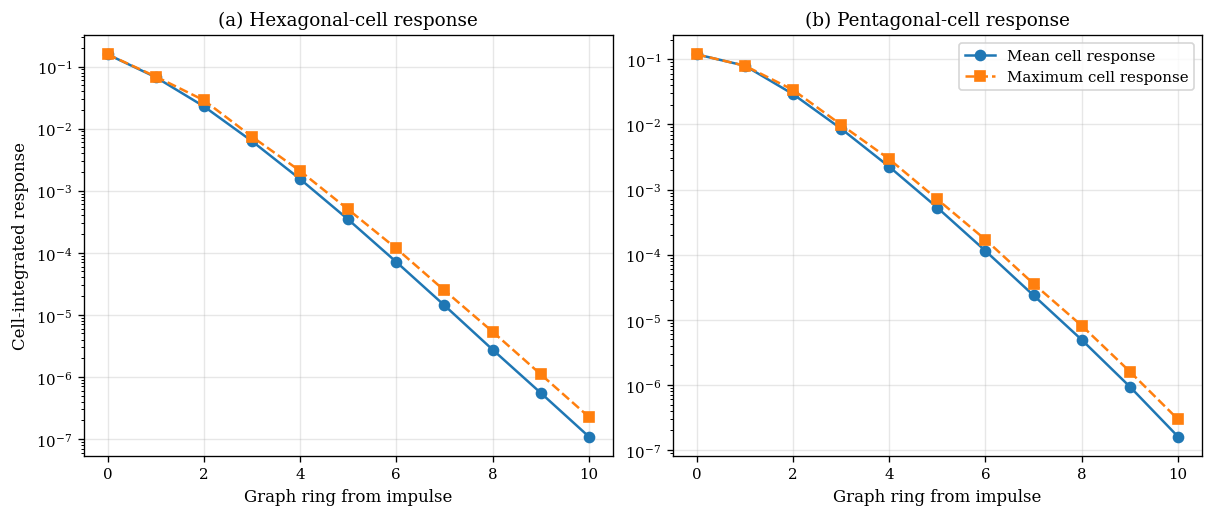

In [ ]:
#!/usr/bin/env python3
"""Controlled area-compatible repeated-resolvent test, p=5."""
from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT=Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID=ROOT/"grid"/"global_hex_ico_grid_nsub4.npz"
OUT=ROOT/"paper_figures"; OUT.mkdir(parents=True,exist_ok=True)
P_ORDER=5; MU=0.50; MAX_RING=10; RNG_SEED=12345

z=np.load(GRID,allow_pickle=True)
area=np.asarray(z["cell_area"],float)
xyz=np.asarray(z["cell_center_xyz"],float); xyz/=np.linalg.norm(xyz,axis=1)[:,None]
lon=np.asarray(z["cell_center_lon"],float); lat=np.asarray(z["cell_center_lat"],float)
if np.max(np.abs(lon))<=2*np.pi+1e-6: lon,lat=np.rad2deg(lon),np.rad2deg(lat)
dual=z["dual_cells"]; n=len(area); Aref=float(np.mean(area)); ahat=area/Aref

def neighbors_from_dual(dual):
    e2c={}
    for ci,poly in enumerate(dual):
        poly=np.asarray(poly,int)
        for k in range(len(poly)):
            e=tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)]))))
            e2c.setdefault(e,[]).append(ci)
    nbr=[set() for _ in range(len(dual))]
    for cells in e2c.values():
        if len(cells)==2:
            i,j=cells
            if i!=j: nbr[i].add(j); nbr[j].add(i)
    return [sorted(x) for x in nbr]

nbr=neighbors_from_dual(dual); degree=np.array([len(x) for x in nbr])
rows=[]; cols=[]; vals=[]
for i,ns in enumerate(nbr):
    rows.append(i); cols.append(i); vals.append(float(len(ns)))
    for j in ns: rows.append(i); cols.append(j); vals.append(-1.)
Q=sp.coo_matrix((vals,(rows,cols)),shape=(n,n)).tocsr()
L_old=Q
L_area=(sp.diags(1./ahat)@Q).tocsr()

def make_B(L):
    M=sp.eye(n,format="csr")+(MU/float(P_ORDER))*L
    solve=spla.factorized(M.tocsc())
    def B(x):
        y=np.asarray(x,float).copy()
        for _ in range(P_ORDER): y=solve(y)
        return y
    return B
B_old=make_B(L_old); B_area=make_B(L_area)

def innerA(x,y): return float(np.sum(area*x*y))
def sa_error(B):
    rng=np.random.default_rng(RNG_SEED); x=rng.standard_normal(n); y=rng.standard_normal(n)
    a=innerA(x,B(y)); b=innerA(B(x),y)
    return abs(a-b)/max(abs(a),abs(b),1e-300)
def dist_from(j):
    d=-np.ones(n,int); d[j]=0; q=deque([j])
    while q:
        i=q.popleft()
        for k in nbr[i]:
            if d[k]<0: d[k]=d[i]+1; q.append(k)
    return d
def metrics(B,j):
    delta=np.zeros(n); delta[j]=1./area[j]
    r=B(delta); mass=area*r; I=mass.sum(); d=dist_from(j)
    shell=[]; mean=[]; maximum=[]
    for k in range(MAX_RING+1):
        m=d==k; zc=mass[m]
        shell.append(zc.sum()); mean.append(zc.mean()); maximum.append(zc.max())
    c=xyz[j]; east=np.cross([0.,0.,1.],c)
    east=np.array([1.,0.,0.]) if np.linalg.norm(east)<1e-12 else east/np.linalg.norm(east)
    north=np.cross(c,east); north/=np.linalg.norm(north)
    disp=xyz-c; xe=disp@east; yn=disp@north
    cx=np.sum(mass*xe)/I; cy=np.sum(mass*yn)/I
    dx=xe-cx; dy=yn-cy
    M=np.array([[np.sum(mass*dx*dx),np.sum(mass*dx*dy)],
                [np.sum(mass*dx*dy),np.sum(mass*dy*dy)]])/I
    ev=np.linalg.eigvalsh(M)
    return dict(response=r,integral=I,error=abs(I-1),central=mass[j],
                shell=np.array(shell),mean=np.array(mean),maximum=np.array(maximum),
                anis=np.sqrt(ev[-1]/max(ev[0],1e-300)),
                centroid=np.hypot(cx,cy))

ihex=int(np.argmin(lon**2+lat**2)); ipent=int(np.where(degree==5)[0][0])
cases={(op,loc):metrics(B,j) for op,B in [("old",B_old),("area",B_area)]
       for loc,j in [("hex",ihex),("pent",ipent)]}

print("="*86)
print("AREA-COMPATIBLE REPEATED-RESOLVENT TEST")
print(f"B^(p)=[I+(mu/p)L_A]^(-p), p={P_ORDER}, mu={MU}")
print("L_A=Ahat^(-1)Q, Ahat=A/mean(A)")
print("="*86)
print("cells:",n," degree counts:",{int(k):int(np.sum(degree==k)) for k in np.unique(degree)})
print("area min/max:",area.min(),area.max()," Aref:",Aref)
print("\nAREA-WEIGHTED SELF-ADJOINTNESS")
print("old unweighted:",sa_error(B_old))
print("new area-compatible:",sa_error(B_area))
print("\nCONSTANT PRESERVATION")
print("old:",np.max(np.abs(B_old(np.ones(n))-1)))
print("new:",np.max(np.abs(B_area(np.ones(n))-1)))

for op in ["old","area"]:
    print("\n"+"-"*86); print(op.upper())
    for loc,j in [("hex",ihex),("pent",ipent)]:
        r=cases[(op,loc)]
        print(f"{loc}: cell={j} degree={degree[j]} area={area[j]:.12e}")
        print(f"  integral={r['integral']:.16f} error={r['error']:.6e}")
        print(f"  central={r['central']:.12f} anisotropy={r['anis']:.8f} centroid={r['centroid']:.6e}")
        for k,v in enumerate(r["shell"]): print(f"  ring {k:2d}: {v:.12e}")
    h=cases[(op,"hex")]["central"]; p=cases[(op,"pent")]["central"]
    print(f"central pent/hex={p/h:.8f}; relative difference={abs(p-h)/h:.6%}")

rings=np.arange(MAX_RING+1)
fig,axs=plt.subplots(1,2,figsize=(10,4.2),constrained_layout=True)
for ax,loc,title in [(axs[0],"hex","(a) Hexagonal-cell response"),
                     (axs[1],"pent","(b) Pentagonal-cell response")]:
    ax.plot(rings,cases[("old",loc)]["shell"],"o--",label="Unweighted resolvent")
    ax.plot(rings,cases[("area",loc)]["shell"],"s-",label="Area-compatible resolvent")
    ax.set_title(title); ax.set_xlabel("Graph ring from impulse"); ax.grid(True,alpha=.3)
axs[0].set_ylabel("Shell-integrated response"); axs[1].legend()
f1=OUT/"test_area_compatible_shell_response_p5_v1.png"
fig.savefig(f1,dpi=300,bbox_inches="tight")

fig,axs=plt.subplots(1,2,figsize=(10,4.2),constrained_layout=True)
for ax,loc,title in [(axs[0],"hex","(a) Hexagonal-cell response"),
                     (axs[1],"pent","(b) Pentagonal-cell response")]:
    r=cases[("area",loc)]
    ax.semilogy(rings,r["mean"],"o-",label="Mean cell response")
    ax.semilogy(rings,r["maximum"],"s--",label="Maximum cell response")
    ax.set_title(title); ax.set_xlabel("Graph ring from impulse"); ax.grid(True,alpha=.3)
axs[0].set_ylabel("Cell-integrated response"); axs[1].legend()
f2=OUT/"test_area_compatible_ring_decay_p5_v1.png"
fig.savefig(f2,dpi=300,bbox_inches="tight")

np.savez(OUT/"test_area_compatible_resolvent_p5_v1.npz",p=P_ORDER,mu=MU,Aref=Aref,
         ihex=ihex,ipent=ipent,area=area,degree=degree,
         old_hex=cases[("old","hex")]["response"],old_pent=cases[("old","pent")]["response"],
         area_hex=cases[("area","hex")]["response"],area_pent=cases[("area","pent")]["response"])
print("\nSaved:",f1); print("Saved:",f2)
print("Saved:",OUT/"test_area_compatible_resolvent_p5_v1.npz")
plt.show()


# Next expetiment with edge weighting

GEOMETRY-WEIGHTED AREA-COMPATIBLE REPEATED-RESOLVENT TEST
p=5, mu=0.5; all edge-weight families normalized to mean(w)=1
hex cell: 38 area= 199901681988.97357 degree= 6
pent cell: 0 area= 134536555820.17406 degree= 5

SUMMARY
case      SA error       Ihex-1      Ipent-1       Chex      Cpent       P/H    Cdiff%    shellL2     Ahex    Apent
U        1.404e-16    4.441e-16   -4.441e-16   0.157408   0.118990   0.75593    24.407    0.08771   1.0451   1.0000
D        7.006e-15   -1.110e-16   -4.441e-16   0.157545   0.107845   0.68454    31.546    0.12556   1.0069   1.0000
D2       1.665e-15   -2.220e-16   -2.220e-16   0.157993   0.098226   0.62171    37.829    0.16375   1.0308   1.0000
A        1.403e-16    0.000e+00    0.000e+00   0.157394   0.120459   0.76534    23.466    0.08466   1.0450   1.0000
AD       6.367e-16   -4.441e-16   -2.220e-16   0.157531   0.109146   0.69286    30.714    0.12301   1.0069   1.0000
AD2      7.768e-15    4.441e-16   -2.220e-16   0.157977   0.099376   0.62905   

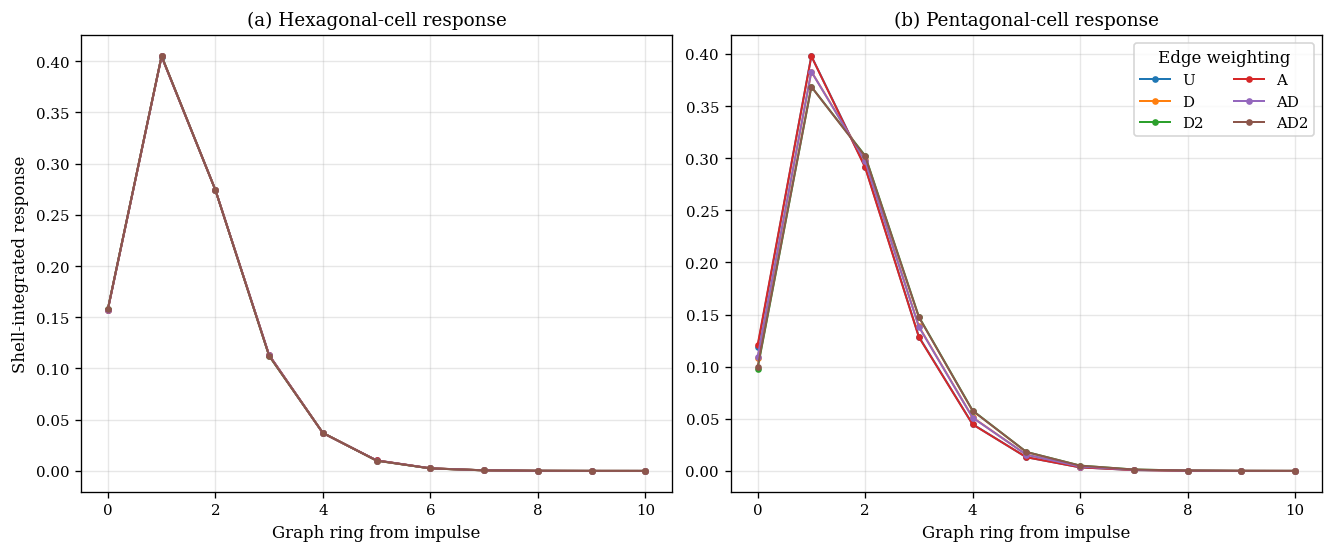

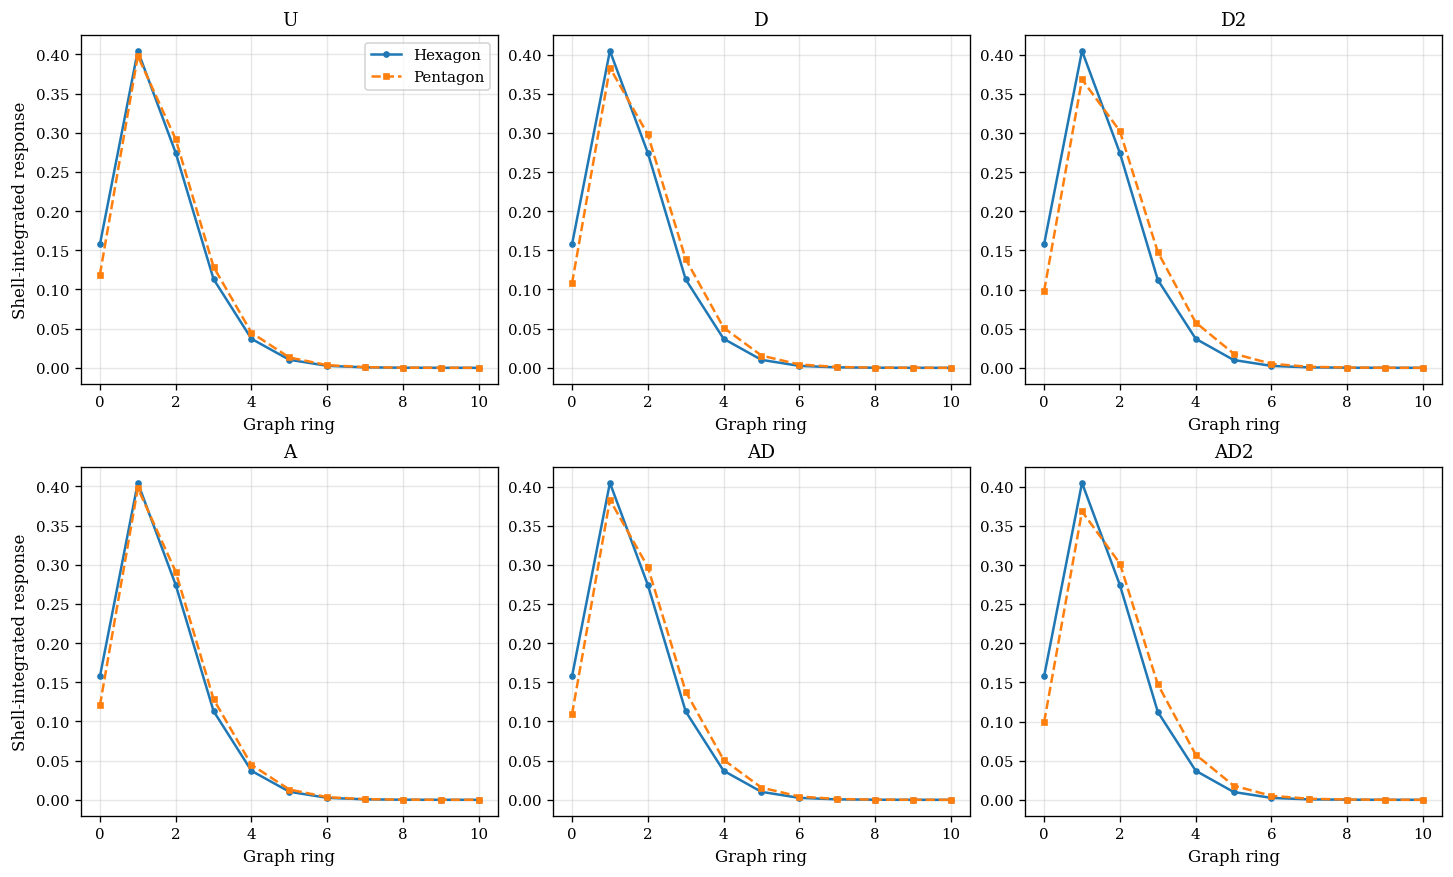

In [ ]:
#!/usr/bin/env python3
"""
test_geometry_weighted_area_resolvent_p5_v1.py

Controlled comparison of area-compatible repeated-resolvent graph filters.

All candidates retain
    L_A = Ahat^{-1} Q_w,
    Q_w = Q_w^T,
    Q_w 1 = 0,
so area-weighted self-adjointness, constant preservation, and area-integral
conservation are retained. Only symmetric edge weights w_ij are changed.

Candidates:
  U  : w_ij = 1
  D  : w_ij = 1 / chord_distance(i,j)
  D2 : w_ij = 1 / chord_distance(i,j)^2
  A  : w_ij = 2 sqrt(A_i A_j)/(A_i+A_j)
  AD : A-weight / chord_distance
  AD2: A-weight / chord_distance^2

Each weight family is normalized to mean edge weight = 1, keeping mu=0.5
approximately comparable across candidates.

Goal: identify whether geometry-aware symmetric weights reduce the
hexagon/pentagon response discrepancy without sacrificing exact
finite-volume properties.
"""
from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT=Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID=ROOT/"grid"/"global_hex_ico_grid_nsub4.npz"
OUT=ROOT/"paper_figures"; OUT.mkdir(parents=True,exist_ok=True)

P_ORDER=5
MU=0.50
MAX_RING=10
RNG_SEED=12345

z=np.load(GRID,allow_pickle=True)
area=np.asarray(z["cell_area"],float)
xyz=np.asarray(z["cell_center_xyz"],float)
xyz/=np.linalg.norm(xyz,axis=1)[:,None]
lon=np.asarray(z["cell_center_lon"],float)
lat=np.asarray(z["cell_center_lat"],float)
if np.max(np.abs(lon))<=2*np.pi+1e-6:
    lon,lat=np.rad2deg(lon),np.rad2deg(lat)
dual=z["dual_cells"]; n=len(area)
Aref=float(np.mean(area)); ahat=area/Aref

# Build unique cell-neighbor edges.
e2c={}
for ci,poly in enumerate(dual):
    poly=np.asarray(poly,int)
    for k in range(len(poly)):
        e=tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)]))))
        e2c.setdefault(e,[]).append(ci)
edges=[]
for cells in e2c.values():
    if len(cells)==2 and cells[0]!=cells[1]:
        edges.append(tuple(sorted((int(cells[0]),int(cells[1])))))
edges=np.unique(np.asarray(edges,int),axis=0)
ei,ej=edges[:,0],edges[:,1]

nbr=[[] for _ in range(n)]
for i,j in edges:
    nbr[i].append(j); nbr[j].append(i)
degree=np.asarray([len(x) for x in nbr],int)

# Geometry measures.
chord=np.linalg.norm(xyz[ei]-xyz[ej],axis=1)
# Dimensionless symmetric area-balance factor, equals 1 for equal areas.
aw=2.0*np.sqrt(area[ei]*area[ej])/(area[ei]+area[ej])

raw_weights={
    "U":np.ones(len(edges)),
    "D":1.0/chord,
    "D2":1.0/(chord*chord),
    "A":aw,
    "AD":aw/chord,
    "AD2":aw/(chord*chord),
}

def Q_from_edge_weights(w):
    w=np.asarray(w,float)
    w=w/np.mean(w)
    diag=np.bincount(np.r_[ei,ej],weights=np.r_[w,w],minlength=n)
    rows=np.r_[np.arange(n),ei,ej]
    cols=np.r_[np.arange(n),ej,ei]
    vals=np.r_[diag,-w,-w]
    return sp.coo_matrix((vals,(rows,cols)),shape=(n,n)).tocsr(),w

def make_B(Q):
    L=(sp.diags(1.0/ahat)@Q).tocsr()
    M=sp.eye(n,format="csr")+(MU/float(P_ORDER))*L
    solve=spla.factorized(M.tocsc())
    def B(x):
        y=np.asarray(x,float).copy()
        for _ in range(P_ORDER): y=solve(y)
        return y
    return B

def innerA(x,y): return float(np.sum(area*x*y))
def sa_error(B):
    rng=np.random.default_rng(RNG_SEED)
    x=rng.standard_normal(n); y=rng.standard_normal(n)
    a=innerA(x,B(y)); b=innerA(B(x),y)
    return abs(a-b)/max(abs(a),abs(b),1e-300)

def graph_distance(j):
    d=-np.ones(n,int); d[j]=0; q=deque([j])
    while q:
        i=q.popleft()
        for k in nbr[i]:
            if d[k]<0:
                d[k]=d[i]+1; q.append(k)
    return d

def tangent_metrics(j,mass,Itot):
    c=xyz[j]
    east=np.cross(np.array([0.,0.,1.]),c)
    if np.linalg.norm(east)<1e-12: east=np.array([1.,0.,0.])
    else: east/=np.linalg.norm(east)
    north=np.cross(c,east); north/=np.linalg.norm(north)
    disp=xyz-c[None,:]; xe=disp@east; yn=disp@north
    cx=np.sum(mass*xe)/Itot; cy=np.sum(mass*yn)/Itot
    dx=xe-cx; dy=yn-cy
    M=np.array([[np.sum(mass*dx*dx),np.sum(mass*dx*dy)],
                [np.sum(mass*dx*dy),np.sum(mass*dy*dy)]])/Itot
    ev=np.linalg.eigvalsh(M)
    return np.sqrt(ev[-1]/max(ev[0],1e-300)),np.hypot(cx,cy)

def metrics(B,j):
    delta=np.zeros(n); delta[j]=1.0/area[j]
    r=B(delta); mass=area*r; Itot=mass.sum(); d=graph_distance(j)
    shell=np.zeros(MAX_RING+1)
    for k in range(MAX_RING+1): shell[k]=mass[d==k].sum()
    anis,cent=tangent_metrics(j,mass,Itot)
    return dict(response=r,mass=mass,integral=Itot,error=abs(Itot-1),
                central=mass[j],shell=shell,anis=anis,centroid=cent)

ihex=int(np.argmin(lon**2+lat**2))
ipent=int(np.where(degree==5)[0][0])

results={}
print("="*112)
print("GEOMETRY-WEIGHTED AREA-COMPATIBLE REPEATED-RESOLVENT TEST")
print(f"p={P_ORDER}, mu={MU}; all edge-weight families normalized to mean(w)=1")
print("="*112)
print("hex cell:",ihex,"area=",area[ihex],"degree=",degree[ihex])
print("pent cell:",ipent,"area=",area[ipent],"degree=",degree[ipent])

for name,wraw in raw_weights.items():
    Q,w=Q_from_edge_weights(wraw)
    B=make_B(Q)
    h=metrics(B,ihex); p=metrics(B,ipent)
    sa=sa_error(B)
    const=np.max(np.abs(B(np.ones(n))-1))
    ratio=p["central"]/h["central"]
    rel=abs(p["central"]-h["central"])/h["central"]
    # Shell-shape discrepancy over rings 0..MAX_RING, relative L2.
    shell_rel=np.linalg.norm(p["shell"]-h["shell"])/np.linalg.norm(h["shell"])
    results[name]=(h,p,sa,const,ratio,rel,shell_rel,w)

print("\nSUMMARY")
print(f"{'case':5s} {'SA error':>12s} {'Ihex-1':>12s} {'Ipent-1':>12s} "
      f"{'Chex':>10s} {'Cpent':>10s} {'P/H':>9s} {'Cdiff%':>9s} {'shellL2':>10s} "
      f"{'Ahex':>8s} {'Apent':>8s}")
for name in raw_weights:
    h,p,sa,const,ratio,rel,shell_rel,w=results[name]
    print(f"{name:5s} {sa:12.3e} {h['integral']-1:12.3e} {p['integral']-1:12.3e} "
          f"{h['central']:10.6f} {p['central']:10.6f} {ratio:9.5f} "
          f"{100*rel:9.3f} {shell_rel:10.5f} {h['anis']:8.4f} {p['anis']:8.4f}")

# Rank only by hex/pent central mismatch for quick diagnostic; not a final scientific criterion.
ranked=sorted(raw_weights.keys(),key=lambda k:results[k][5])
print("\nCENTRAL-RESPONSE MISMATCH ORDER (diagnostic only):")
for k in ranked:
    print(f"  {k:5s}: {100*results[k][5]:.4f}%")

# Plot shell curves for all candidates, hex and pent.
rings=np.arange(MAX_RING+1)
fig,axs=plt.subplots(1,2,figsize=(11,4.5),constrained_layout=True)
for name in raw_weights:
    h,p,*_=results[name]
    axs[0].plot(rings,h["shell"],marker="o",ms=3,lw=1.2,label=name)
    axs[1].plot(rings,p["shell"],marker="o",ms=3,lw=1.2,label=name)
axs[0].set_title("(a) Hexagonal-cell response")
axs[1].set_title("(b) Pentagonal-cell response")
for ax in axs:
    ax.set_xlabel("Graph ring from impulse"); ax.grid(True,alpha=.3)
axs[0].set_ylabel("Shell-integrated response")
axs[1].legend(title="Edge weighting",ncol=2)
f1=OUT/"test_geometry_weighted_shells_p5_v1.png"
fig.savefig(f1,dpi=300,bbox_inches="tight")

# Direct hex-vs-pent comparison for each candidate.
fig,axs=plt.subplots(2,3,figsize=(12,7.2),constrained_layout=True)
for ax,name in zip(axs.ravel(),raw_weights):
    h,p,*_=results[name]
    ax.plot(rings,h["shell"],"o-",ms=3,label="Hexagon")
    ax.plot(rings,p["shell"],"s--",ms=3,label="Pentagon")
    ax.set_title(name)
    ax.set_xlabel("Graph ring"); ax.grid(True,alpha=.3)
    if ax in axs[:,0]: ax.set_ylabel("Shell-integrated response")
axs[0,0].legend()
f2=OUT/"test_geometry_weighted_hex_pent_p5_v1.png"
fig.savefig(f2,dpi=300,bbox_inches="tight")

# Save compact numerical summary and response arrays.
save=dict(p=P_ORDER,mu=MU,Aref=Aref,ihex=ihex,ipent=ipent,area=area,degree=degree)
for name in raw_weights:
    h,p,sa,const,ratio,rel,shell_rel,w=results[name]
    save[f"{name}_hex_response"]=h["response"]
    save[f"{name}_pent_response"]=p["response"]
    save[f"{name}_summary"]=np.array([sa,const,h["integral"],p["integral"],
                                      h["central"],p["central"],ratio,rel,shell_rel,
                                      h["anis"],p["anis"]])
np.savez(OUT/"test_geometry_weighted_area_resolvent_p5_v1.npz",**save)

print("\nSaved:",f1)
print("Saved:",f2)
print("Saved:",OUT/"test_geometry_weighted_area_resolvent_p5_v1.npz")
print("\nDONE.")
plt.show()


# Hexa/Penta Tests with modifying p

GLOBAL p-SWEEP: AREA-COMPATIBLE REPEATED-RESOLVENT GRAPH FILTER
mu = 0.5  p values = [1, 2, 3, 4, 5, 6, 8, 10, 20]
  p     SA error    const err       Ihex-1      Ipent-1       Chex      Cpent       P/H    Cdiff%    shellL2
  1    1.997e-15    1.776e-15   -3.331e-16    0.000e+00   0.293960   0.253304   0.86170    13.830    0.08820
  2    2.233e-15    2.998e-15   -1.110e-16    0.000e+00   0.213386   0.172094   0.80649    19.351    0.09035
  3    3.160e-15    2.665e-15    0.000e+00    0.000e+00   0.182793   0.142551   0.77985    22.015    0.08920
  4    2.051e-15    4.108e-15    0.000e+00    0.000e+00   0.166982   0.127748   0.76504    23.496    0.08830
  5    1.123e-15    4.330e-15    0.000e+00   -5.551e-16   0.157408   0.118990   0.75593    24.407    0.08771
  6    7.442e-15    5.551e-15    2.220e-16    2.220e-16   0.151018   0.113248   0.74990    25.010    0.08732
  8    2.352e-15    5.884e-15   -2.220e-16   -4.441e-16   0.143055   0.106229   0.74257    25.743    0.08687
 10    2.094e

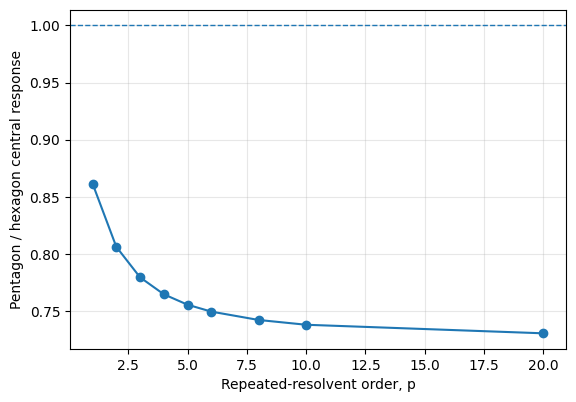

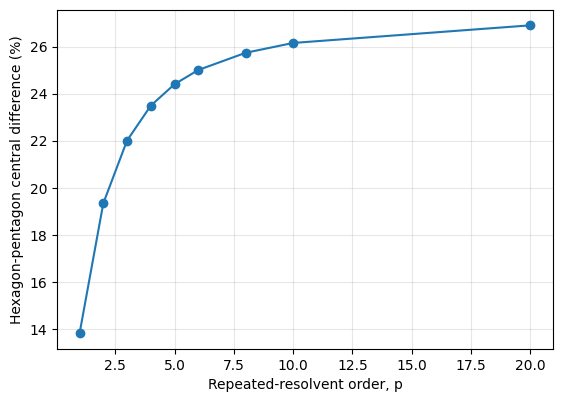

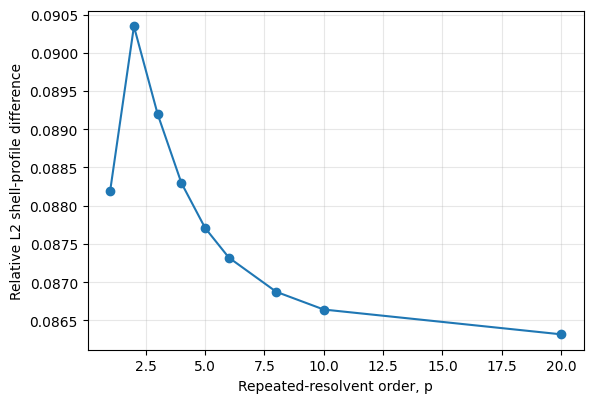

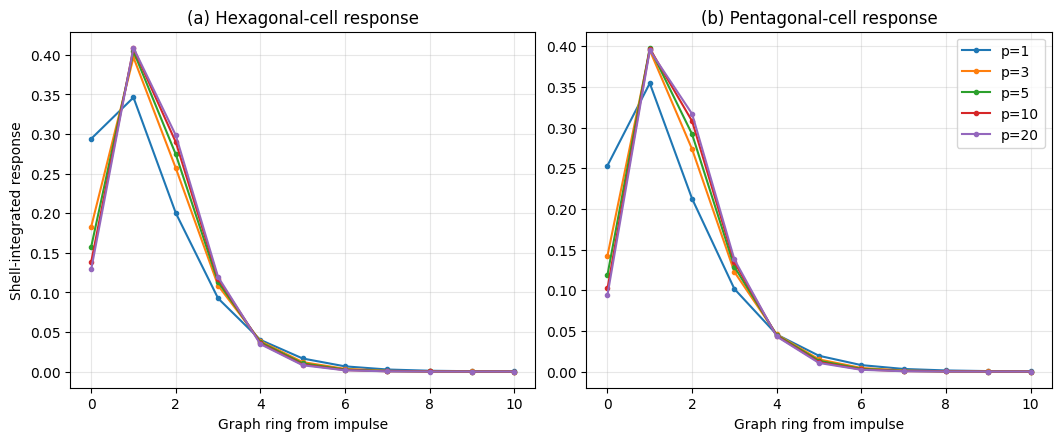

In [ ]:
#!/usr/bin/env python3
# Global p-sweep for area-compatible repeated-resolvent MGGF.
from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT=Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID=ROOT/"grid"/"global_hex_ico_grid_nsub4.npz"
OUT=ROOT/"paper_figures"; OUT.mkdir(parents=True,exist_ok=True)
MU=0.50
P_VALUES=[1,2,3,4,5,6,8,10,20]
MAX_RING=10
RNG_SEED=12345

z=np.load(GRID,allow_pickle=True)
area=np.asarray(z["cell_area"],float)
lon=np.asarray(z["cell_center_lon"],float); lat=np.asarray(z["cell_center_lat"],float)
if np.max(np.abs(lon))<=2*np.pi+1e-6: lon,lat=np.rad2deg(lon),np.rad2deg(lat)
dual=z["dual_cells"]; n=len(area)
Aref=float(np.mean(area)); ahat=area/Aref

e2c={}
for ci,poly in enumerate(dual):
    poly=np.asarray(poly,int)
    for k in range(len(poly)):
        e=tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)]))))
        e2c.setdefault(e,[]).append(ci)
edges=[]
for cells in e2c.values():
    if len(cells)==2 and cells[0]!=cells[1]:
        edges.append(tuple(sorted((int(cells[0]),int(cells[1])))))
edges=np.unique(np.asarray(edges,int),axis=0)
nbr=[[] for _ in range(n)]
for i,j in edges: nbr[i].append(j); nbr[j].append(i)
degree=np.asarray([len(v) for v in nbr],int)
ei,ej=edges[:,0],edges[:,1]
diag=np.bincount(np.r_[ei,ej],minlength=n).astype(float)
Q=sp.coo_matrix((np.r_[diag,-np.ones(len(edges)),-np.ones(len(edges))],
                 (np.r_[np.arange(n),ei,ej],np.r_[np.arange(n),ej,ei])),
                shape=(n,n)).tocsr()
L=(sp.diags(1.0/ahat)@Q).tocsr()

def make_B(p):
    M=sp.eye(n,format="csr")+(MU/float(p))*L
    solve=spla.factorized(M.tocsc())
    def B(x):
        y=np.asarray(x,float).copy()
        for _ in range(p): y=solve(y)
        return y
    return B

def innerA(x,y): return float(np.sum(area*x*y))
def sa_error(B):
    rng=np.random.default_rng(RNG_SEED); x=rng.standard_normal(n); y=rng.standard_normal(n)
    a=innerA(x,B(y)); b=innerA(B(x),y)
    return abs(a-b)/max(abs(a),abs(b),1e-300)

def graph_distance(j):
    d=-np.ones(n,int); d[j]=0; q=deque([j])
    while q:
        i=q.popleft()
        for k in nbr[i]:
            if d[k]<0: d[k]=d[i]+1; q.append(k)
    return d

def metrics(B,j):
    delta=np.zeros(n); delta[j]=1.0/area[j]
    r=B(delta); mass=area*r; I=float(mass.sum()); d=graph_distance(j)
    shell=np.array([mass[d==k].sum() for k in range(MAX_RING+1)])
    return r,I,float(mass[j]),shell

ihex=int(np.argmin(lon**2+lat**2)); ipent=int(np.where(degree==5)[0][0])
res={}
for p in P_VALUES:
    B=make_B(p); rh,Ih,Ch,sh=metrics(B,ihex); rp,Ip,Cp,spn=metrics(B,ipent)
    sa=sa_error(B); ce=float(np.max(np.abs(B(np.ones(n))-1)))
    ratio=Cp/Ch; cd=abs(Cp-Ch)/Ch; sl=np.linalg.norm(spn-sh)/np.linalg.norm(sh)
    res[p]=(rh,rp,Ih,Ip,Ch,Cp,sh,spn,sa,ce,ratio,cd,sl)

print("="*112)
print("GLOBAL p-SWEEP: AREA-COMPATIBLE REPEATED-RESOLVENT GRAPH FILTER")
print("mu =",MU," p values =",P_VALUES)
print("="*112)
print(f"{'p':>3} {'SA error':>12} {'const err':>12} {'Ihex-1':>12} {'Ipent-1':>12} {'Chex':>10} {'Cpent':>10} {'P/H':>9} {'Cdiff%':>9} {'shellL2':>10}")
for p in P_VALUES:
    rh,rp,Ih,Ip,Ch,Cp,sh,spn,sa,ce,ratio,cd,sl=res[p]
    print(f"{p:3d} {sa:12.3e} {ce:12.3e} {Ih-1:12.3e} {Ip-1:12.3e} {Ch:10.6f} {Cp:10.6f} {ratio:9.5f} {100*cd:9.3f} {sl:10.5f}")

ps=np.array(P_VALUES,float)
ratio=np.array([res[p][10] for p in P_VALUES])
cdiff=100*np.array([res[p][11] for p in P_VALUES])
shellL2=np.array([res[p][12] for p in P_VALUES])

for yy,ylabel,fname,ref in [
    (ratio,"Pentagon / hexagon central response","test_p_sweep_central_ratio_v1.png",True),
    (cdiff,"Hexagon-pentagon central difference (%)","test_p_sweep_central_difference_v1.png",False),
    (shellL2,"Relative L2 shell-profile difference","test_p_sweep_shell_difference_v1.png",False)]:
    fig,ax=plt.subplots(figsize=(6.4,4.4)); ax.plot(ps,yy,"o-")
    if ref: ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("Repeated-resolvent order, p"); ax.set_ylabel(ylabel); ax.grid(True,alpha=.3)
    fig.savefig(OUT/fname,dpi=300,bbox_inches="tight")

rings=np.arange(MAX_RING+1); selected=[1,3,5,10,20]
fig,axs=plt.subplots(1,2,figsize=(10.5,4.3),constrained_layout=True)
for p in selected:
    axs[0].plot(rings,res[p][6],marker="o",ms=3,label=f"p={p}")
    axs[1].plot(rings,res[p][7],marker="o",ms=3,label=f"p={p}")
axs[0].set_title("(a) Hexagonal-cell response"); axs[1].set_title("(b) Pentagonal-cell response")
for ax in axs: ax.set_xlabel("Graph ring from impulse"); ax.grid(True,alpha=.3)
axs[0].set_ylabel("Shell-integrated response"); axs[1].legend()
fig.savefig(OUT/"test_p_sweep_shell_profiles_v1.png",dpi=300,bbox_inches="tight")

save={"mu":MU,"p_values":np.array(P_VALUES),"Aref":Aref,"ihex":ihex,"ipent":ipent}
for p in P_VALUES:
    save[f"p{p}_hex_response"]=res[p][0]; save[f"p{p}_pent_response"]=res[p][1]
    save[f"p{p}_summary"]=np.array(res[p][2:6]+res[p][8:13])
np.savez(OUT/"test_p_sweep_area_resolvent_v1.npz",**save)
print("\nDONE. Outputs saved in",OUT)
plt.show()


# test_sinkhorn_balanced_area_resolvent_p5_v1.py

SINKHORN-INSPIRED BALANCED AREA-COMPATIBLE REPEATED-RESOLVENT TEST
p=5, mu=0.5
W is used only to construct Q=diag(W1)-W; filter remains repeated resolvent.
cells: 2562 edges: 7680 degree counts: {5: 12, 6: 2550}
hex : 38 degree = 6 area = 199901681988.97357
pent: 0 degree = 5 area = 134536555820.17406

BALANCING
case  iterations    balance err    norm factor
U              0            n/a  1.0000000e+00
S1            83      8.478e-14  5.9953162e+00
S05           80      8.225e-14  5.9999108e+00
S0            89      9.914e-14  5.9953162e+00

FILTER SUMMARY
case      SA error    const err        Qsym          Q1       Ihex-1      Ipent-1       Chex      Cpent       P/H    Cdiff%    shellL2
U        1.123e-15    4.330e-15   0.000e+00   0.000e+00    0.000e+00   -5.551e-16   0.157408   0.118990   0.75593    24.407    0.08771
S1       3.721e-16    3.775e-15   0.000e+00   2.220e-15    2.220e-16   -2.220e-16   0.156728   0.149068   0.95113     4.887    0.01705
S05      3.027e-15    4.663e-1

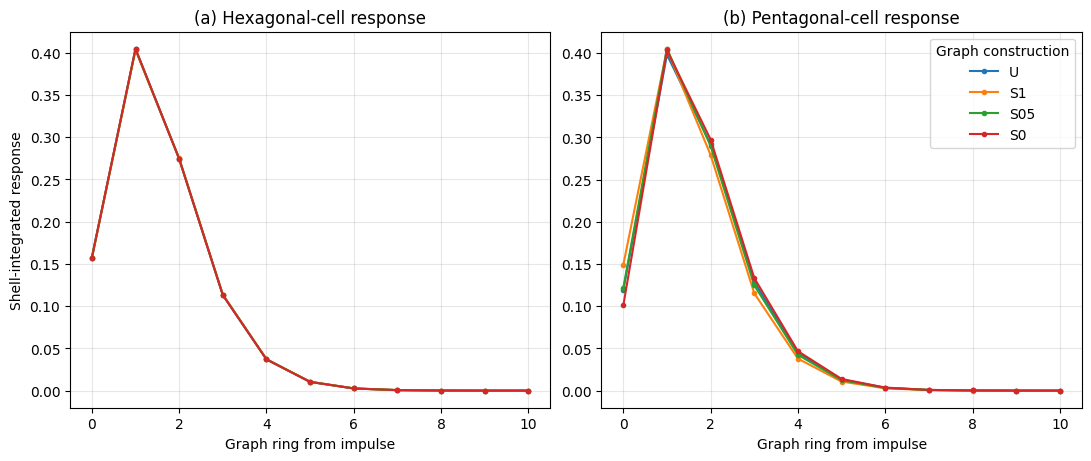

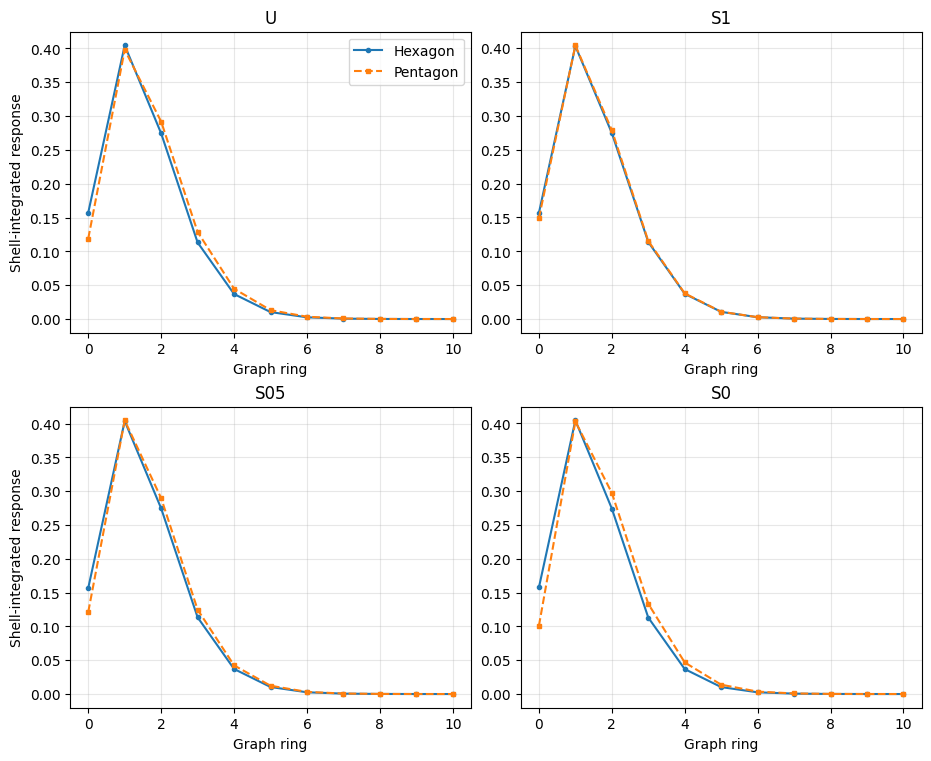

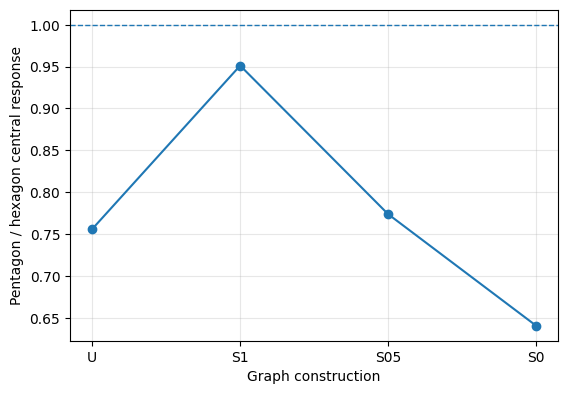

In [ ]:
#!/usr/bin/env python3
"""
test_sinkhorn_balanced_area_resolvent_p5_v1.py

Controlled test of Sinkhorn-inspired graph balancing used ONLY to construct
the graph stiffness for an area-compatible repeated-resolvent filter.

Filter:
    B^(p) = [I + (mu/p) L]^(-p)
    L     = Ahat^(-1) Q
    Q     = diag(W 1) - W

where W is symmetric. Therefore Q=Q^T and Q 1=0, which preserves the
area-weighted self-adjointness / conservation structure.

Cases:
  U   : unbalanced nearest-neighbor graph, W_ij = 1
  S1  : Sinkhorn-balanced nearest-neighbor graph, target row sum = Ahat
  S05 : target row sum = sqrt(Ahat)
  S0  : target row sum = 1

All final W matrices are globally normalized to mean edge weight = 1,
so mu remains approximately comparable between cases.

IMPORTANT:
This is a diagnostic, not a publication script. No impulse-response
renormalization is performed.
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_hex_ico_grid_nsub4.npz"
OUT = ROOT / "paper_figures"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
MAX_RING = 10
SINKHORN_MAXITER = 5000
SINKHORN_TOL = 1.0e-13
RNG_SEED = 12345

z = np.load(GRID, allow_pickle=True)
area = np.asarray(z["cell_area"], float)
lon = np.asarray(z["cell_center_lon"], float)
lat = np.asarray(z["cell_center_lat"], float)
dual = z["dual_cells"]

if np.max(np.abs(lon)) <= 2*np.pi + 1e-6:
    lon, lat = np.rad2deg(lon), np.rad2deg(lat)

n = len(area)
Aref = float(np.mean(area))
ahat = area / Aref

# ------------------------------------------------------------
# Build unique finite-volume cell adjacency
# ------------------------------------------------------------
e2c = {}
for ci, poly in enumerate(dual):
    poly = np.asarray(poly, int)
    for k in range(len(poly)):
        e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
        e2c.setdefault(e, []).append(ci)

edges = []
for cells in e2c.values():
    if len(cells) == 2 and cells[0] != cells[1]:
        edges.append(tuple(sorted((int(cells[0]), int(cells[1])))))
edges = np.unique(np.asarray(edges, int), axis=0)
ei, ej = edges[:, 0], edges[:, 1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i, j in edges:
    nbr[i].append(j)
    nbr[j].append(i)
degree = np.asarray([len(v) for v in nbr], int)

# ------------------------------------------------------------
# Symmetric off-diagonal base adjacency K0 (zero diagonal)
# ------------------------------------------------------------
K0 = sp.coo_matrix(
    (np.ones(2*m), (np.r_[ei, ej], np.r_[ej, ei])),
    shape=(n, n)
).tocsr()

def symmetric_balance(K0, target, maxiter=SINKHORN_MAXITER, tol=SINKHORN_TOL):
    """
    Find positive diagonal scaling s such that
        W = diag(s) K0 diag(s)
    approximately satisfies W 1 = target.

    Fixed-point update:
        s <- s * sqrt(target / (W 1))
    """
    target = np.asarray(target, float)
    s = np.ones(n, float)

    for it in range(maxiter):
        row = s * (K0 @ s)
        rel = np.max(np.abs(row - target) / np.maximum(target, 1e-300))
        if rel < tol:
            break
        ratio = target / np.maximum(row, 1e-300)
        s *= np.sqrt(ratio)

    row = s * (K0 @ s)
    rel = np.max(np.abs(row - target) / np.maximum(target, 1e-300))
    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()
    return W, s, it+1, rel

def normalize_mean_edge_weight(W):
    w = np.asarray(W[ei, ej]).ravel()
    fac = 1.0 / np.mean(w)
    return (fac * W).tocsr(), fac

def Q_from_W(W):
    rowsum = np.asarray(W.sum(axis=1)).ravel()
    return (sp.diags(rowsum) - W).tocsr()

def make_B(Q):
    L = (sp.diags(1.0/ahat) @ Q).tocsr()
    M = sp.eye(n, format="csr") + (MU/float(P))*L
    solve = spla.factorized(M.tocsc())

    def B(x):
        y = np.asarray(x, float).copy()
        for _ in range(P):
            y = solve(y)
        return y
    return B

def innerA(x, y):
    return float(np.sum(area*x*y))

def self_adjoint_error(B):
    rng = np.random.default_rng(RNG_SEED)
    x = rng.standard_normal(n)
    y = rng.standard_normal(n)
    lhs = innerA(x, B(y))
    rhs = innerA(B(x), y)
    return abs(lhs-rhs)/max(abs(lhs), abs(rhs), 1e-300)

def graph_distance(j):
    d = -np.ones(n, int)
    d[j] = 0
    q = deque([j])
    while q:
        i = q.popleft()
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

def impulse_metrics(B, j):
    delta = np.zeros(n)
    delta[j] = 1.0/area[j]
    r = B(delta)
    mass = area*r
    integral = float(np.sum(mass))
    d = graph_distance(j)
    shell = np.array([np.sum(mass[d == k]) for k in range(MAX_RING+1)])
    return {
        "response": r,
        "mass": mass,
        "integral": integral,
        "central": float(mass[j]),
        "shell": shell,
    }

ihex = int(np.argmin(lon**2 + lat**2))
ipent = int(np.where(degree == 5)[0][0])

# ------------------------------------------------------------
# Cases
# ------------------------------------------------------------
cases = {}

# Control: ordinary nearest-neighbor adjacency.
Wu = K0.copy()
Wu, fac_u = normalize_mean_edge_weight(Wu)
cases["U"] = dict(W=Wu, iterations=0, balance_error=np.nan,
                  target_name="none", norm_factor=fac_u)

targets = {
    "S1": ahat,
    "S05": np.sqrt(ahat),
    "S0": np.ones(n),
}

for name, target in targets.items():
    W, s, nit, berr = symmetric_balance(K0, target)
    W, fac = normalize_mean_edge_weight(W)
    cases[name] = dict(W=W, iterations=nit, balance_error=berr,
                       target_name=name, norm_factor=fac, scaling=s)

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
results = {}

print("="*126)
print("SINKHORN-INSPIRED BALANCED AREA-COMPATIBLE REPEATED-RESOLVENT TEST")
print(f"p={P}, mu={MU}")
print("W is used only to construct Q=diag(W1)-W; filter remains repeated resolvent.")
print("="*126)
print("cells:", n, "edges:", m,
      "degree counts:", {int(k): int(np.sum(degree == k)) for k in np.unique(degree)})
print("hex :", ihex, "degree =", degree[ihex], "area =", area[ihex])
print("pent:", ipent, "degree =", degree[ipent], "area =", area[ipent])

for name, info in cases.items():
    Q = Q_from_W(info["W"])
    B = make_B(Q)
    h = impulse_metrics(B, ihex)
    p = impulse_metrics(B, ipent)

    sa = self_adjoint_error(B)
    const = float(np.max(np.abs(B(np.ones(n))-1.0)))
    ratio = p["central"]/h["central"]
    cdiff = abs(p["central"]-h["central"])/h["central"]
    shell_l2 = np.linalg.norm(p["shell"]-h["shell"])/np.linalg.norm(h["shell"])

    # Direct checks on Q.
    qsym = spla.norm(Q-Q.T) / max(spla.norm(Q), 1e-300)
    qone = float(np.max(np.abs(Q @ np.ones(n))))

    results[name] = dict(
        hex=h, pent=p, sa=sa, const=const, ratio=ratio,
        cdiff=cdiff, shell_l2=shell_l2, qsym=qsym, qone=qone
    )

print("\nBALANCING")
print(f"{'case':5s} {'iterations':>10s} {'balance err':>14s} {'norm factor':>14s}")
for name, info in cases.items():
    be = info["balance_error"]
    be_txt = "n/a" if np.isnan(be) else f"{be:.3e}"
    print(f"{name:5s} {info['iterations']:10d} {be_txt:>14s} {info['norm_factor']:14.7e}")

print("\nFILTER SUMMARY")
print(f"{'case':5s} {'SA error':>12s} {'const err':>12s} {'Qsym':>11s} {'Q1':>11s} "
      f"{'Ihex-1':>12s} {'Ipent-1':>12s} {'Chex':>10s} {'Cpent':>10s} "
      f"{'P/H':>9s} {'Cdiff%':>9s} {'shellL2':>10s}")
for name in cases:
    r = results[name]
    h, p = r["hex"], r["pent"]
    print(f"{name:5s} {r['sa']:12.3e} {r['const']:12.3e} {r['qsym']:11.3e} {r['qone']:11.3e} "
          f"{h['integral']-1:12.3e} {p['integral']-1:12.3e} "
          f"{h['central']:10.6f} {p['central']:10.6f} {r['ratio']:9.5f} "
          f"{100*r['cdiff']:9.3f} {r['shell_l2']:10.5f}")

# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------
rings = np.arange(MAX_RING+1)

fig, axs = plt.subplots(1, 2, figsize=(10.8, 4.5), constrained_layout=True)
for name in cases:
    axs[0].plot(rings, results[name]["hex"]["shell"], marker="o", ms=3, label=name)
    axs[1].plot(rings, results[name]["pent"]["shell"], marker="o", ms=3, label=name)
axs[0].set_title("(a) Hexagonal-cell response")
axs[1].set_title("(b) Pentagonal-cell response")
for ax in axs:
    ax.set_xlabel("Graph ring from impulse")
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel("Shell-integrated response")
axs[1].legend(title="Graph construction")
f1 = OUT / "test_sinkhorn_balanced_shells_p5_v1.png"
fig.savefig(f1, dpi=300, bbox_inches="tight")

fig, axs = plt.subplots(2, 2, figsize=(9.2, 7.5), constrained_layout=True)
for ax, name in zip(axs.ravel(), cases):
    ax.plot(rings, results[name]["hex"]["shell"], "o-", ms=3, label="Hexagon")
    ax.plot(rings, results[name]["pent"]["shell"], "s--", ms=3, label="Pentagon")
    ax.set_title(name)
    ax.set_xlabel("Graph ring")
    ax.grid(True, alpha=0.3)
axs[0,0].set_ylabel("Shell-integrated response")
axs[1,0].set_ylabel("Shell-integrated response")
axs[0,0].legend()
f2 = OUT / "test_sinkhorn_balanced_hex_pent_p5_v1.png"
fig.savefig(f2, dpi=300, bbox_inches="tight")

names = list(cases.keys())
ratios = [results[k]["ratio"] for k in names]
fig, ax = plt.subplots(figsize=(6.3, 4.3))
ax.plot(names, ratios, "o-")
ax.axhline(1.0, ls="--", lw=1)
ax.set_ylabel("Pentagon / hexagon central response")
ax.set_xlabel("Graph construction")
ax.grid(True, alpha=0.3)
f3 = OUT / "test_sinkhorn_balanced_central_ratio_p5_v1.png"
fig.savefig(f3, dpi=300, bbox_inches="tight")

# ------------------------------------------------------------
# Save numerical output
# ------------------------------------------------------------
save = {
    "p": P, "mu": MU, "Aref": Aref, "ihex": ihex, "ipent": ipent,
    "area": area, "degree": degree
}
for name in cases:
    r = results[name]
    save[f"{name}_hex_response"] = r["hex"]["response"]
    save[f"{name}_pent_response"] = r["pent"]["response"]
    save[f"{name}_summary"] = np.array([
        r["sa"], r["const"], r["qsym"], r["qone"],
        r["hex"]["integral"], r["pent"]["integral"],
        r["hex"]["central"], r["pent"]["central"],
        r["ratio"], r["cdiff"], r["shell_l2"]
    ])
np.savez(OUT / "test_sinkhorn_balanced_area_resolvent_p5_v1.npz", **save)

print("\nSaved:", f1)
print("Saved:", f2)
print("Saved:", f3)
print("Saved:", OUT / "test_sinkhorn_balanced_area_resolvent_p5_v1.npz")
print("\nInterpretation:")
print("  U   = current area-compatible unbalanced control")
print("  S1  = symmetric balancing to row sums proportional to cell area")
print("  S05 = symmetric balancing to row sums proportional to sqrt(cell area)")
print("  S0  = symmetric balancing to uniform row sums")
print("No response normalization has been applied.")
print("\nDONE.")
plt.show()


# test_s1_global_topology_diagnostics_p5_v1.py

S1 GLOBAL TOPOLOGY DIAGNOSTIC
p=5, mu=0.5, S1 target row sums proportional to cell area
cells: 2562 edges: 7680 degree counts: {5: 12, 6: 2550}
Sinkhorn iterations: 83
Sinkhorn balance error: 8.478042082395839e-14
post-balance mean-edge normalization factor: 5.995316159250585
Q symmetry error: 0.0
Q*1 max error: 2.220446049250313e-15
area-weighted self-adjointness error: 3.72122435355513e-16
constant-preservation error: 3.774758283725532e-15
pentagons evaluated: 12
hexagons evaluated: 250

DISTRIBUTION SUMMARY
metric                 group            min          mean           std           max
integral error         HEX     0.000000e+00  4.463097e-16  3.677437e-16  2.220446e-15
integral error         PENT    0.000000e+00  3.330669e-16  2.603704e-16  8.881784e-16
central response       HEX     1.539723e-01  1.569660e-01  1.584834e-03  1.613203e-01
central response       PENT    1.490677e-01  1.490677e-01  1.022948e-16  1.490677e-01
effective radius km    HEX     7.778703e+02  8.304225e

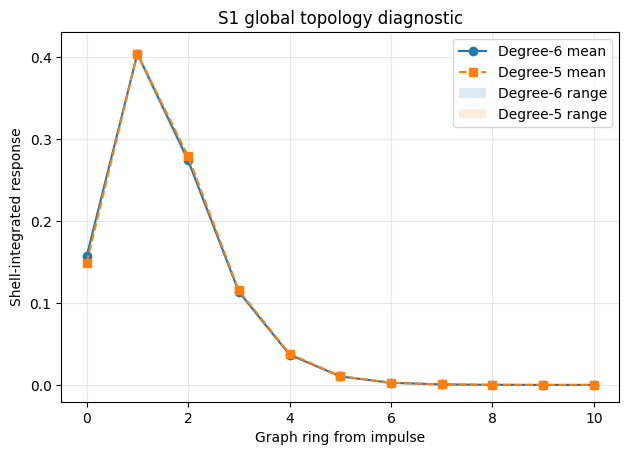

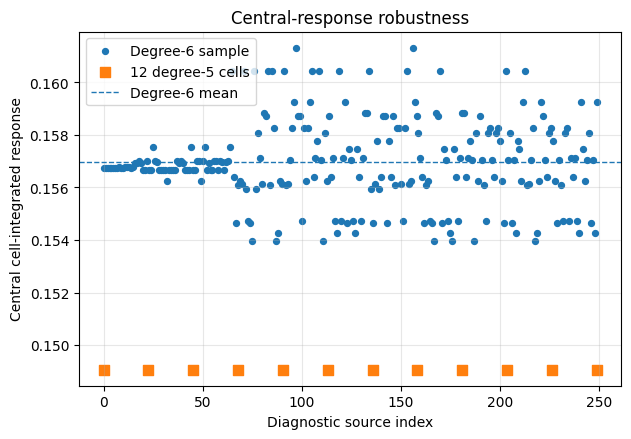

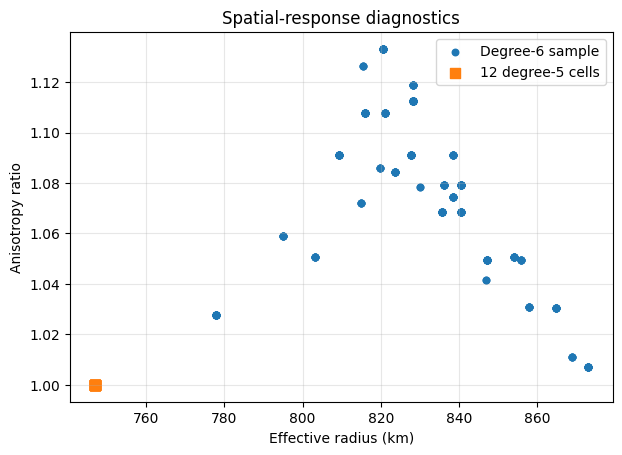

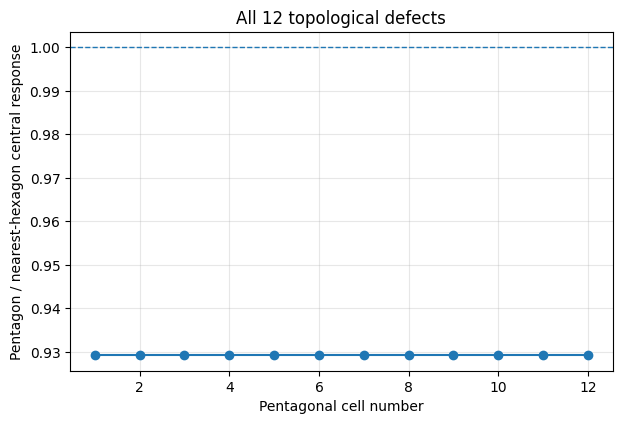

In [ ]:
#!/usr/bin/env python3
"""
test_s1_global_topology_diagnostics_p5_v1.py

Global/representative diagnostic for the S1 Sinkhorn-balanced,
area-compatible repeated-resolvent graph filter.

Purpose
-------
Test whether the strong single-pentagon result obtained with S1 is robust:
  * ALL 12 degree-5 cells are evaluated.
  * A deterministic, geographically distributed sample of degree-6 cells
    is evaluated (default 240).
  * No pentagon-specific correction or response normalization is used.

Filter
------
    W = diag(s) K0 diag(s),       W 1 proportional to A
    Q = diag(W 1) - W
    L = Ahat^(-1) Q
    B^(p) = [I + (mu/p) L]^(-p)

with p=5 and mu=0.5.

Diagnostics per source cell
---------------------------
  area integral, central cell-integrated response, effective radius,
  tangent-plane anisotropy, centroid displacement, and shell-integrated
  response through MAX_RING.

The script also reports:
  * area-weighted self-adjointness and constant preservation;
  * pentagon vs hexagon distributions;
  * nearest-hexagon comparison for every pentagon;
  * shell-profile differences;
  * publication-quality diagnostic plots.

This is a diagnostic script, not yet the final Fig. 9--11 generator.
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_hex_ico_grid_nsub4.npz"
OUT = ROOT / "paper_figures"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
NHEX_SAMPLE = 240
MAX_RING = 10
SINKHORN_MAXITER = 5000
SINKHORN_TOL = 1.0e-13
EARTH_RADIUS_KM = 6371.0
RNG_SEED = 12345

# =============================================================================
# Grid
# =============================================================================
z = np.load(GRID, allow_pickle=True)
area = np.asarray(z["cell_area"], float)
lon = np.asarray(z["cell_center_lon"], float)
lat = np.asarray(z["cell_center_lat"], float)
dual = z["dual_cells"]

if np.max(np.abs(lon)) <= 2*np.pi + 1e-6:
    lon, lat = np.rad2deg(lon), np.rad2deg(lat)

n = len(area)
Aref = float(np.mean(area))
ahat = area / Aref

lonr = np.deg2rad(lon)
latr = np.deg2rad(lat)
xyz = np.column_stack([
    np.cos(latr)*np.cos(lonr),
    np.cos(latr)*np.sin(lonr),
    np.sin(latr)
])

# =============================================================================
# Cell adjacency
# =============================================================================
e2c = {}
for ci, poly in enumerate(dual):
    poly = np.asarray(poly, int)
    for k in range(len(poly)):
        e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
        e2c.setdefault(e, []).append(ci)

edges = []
for cells in e2c.values():
    if len(cells) == 2 and cells[0] != cells[1]:
        edges.append(tuple(sorted((int(cells[0]), int(cells[1])))))
edges = np.unique(np.asarray(edges, int), axis=0)
ei, ej = edges[:, 0], edges[:, 1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i, j in edges:
    nbr[i].append(int(j))
    nbr[j].append(int(i))
degree = np.asarray([len(v) for v in nbr], int)

K0 = sp.coo_matrix(
    (np.ones(2*m), (np.r_[ei, ej], np.r_[ej, ei])),
    shape=(n, n)
).tocsr()

# =============================================================================
# S1 balancing: W 1 proportional to cell area
# =============================================================================
def symmetric_balance(K0, target, maxiter=SINKHORN_MAXITER, tol=SINKHORN_TOL):
    target = np.asarray(target, float)
    s = np.ones(len(target), float)
    for it in range(maxiter):
        row = s * (K0 @ s)
        rel = np.max(np.abs(row-target) / np.maximum(target, 1e-300))
        if rel < tol:
            break
        s *= np.sqrt(target / np.maximum(row, 1e-300))
    row = s * (K0 @ s)
    rel = np.max(np.abs(row-target) / np.maximum(target, 1e-300))
    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()
    return W, s, it+1, rel

W, scaling, niter, balance_error = symmetric_balance(K0, ahat)

# Keep same convention as previous controlled test: mean unique-edge weight = 1.
edge_w = np.asarray(W[ei, ej]).ravel()
norm_factor = 1.0 / np.mean(edge_w)
W = (norm_factor * W).tocsr()

rowsum = np.asarray(W.sum(axis=1)).ravel()
Q = (sp.diags(rowsum) - W).tocsr()
L = (sp.diags(1.0/ahat) @ Q).tocsr()

M = sp.eye(n, format="csr") + (MU/float(P))*L
solve = spla.factorized(M.tocsc())

def B_apply(x):
    y = np.asarray(x, float).copy()
    for _ in range(P):
        y = solve(y)
    return y

def innerA(x, y):
    return float(np.sum(area*x*y))

# =============================================================================
# Global operator checks
# =============================================================================
rng = np.random.default_rng(RNG_SEED)
x = rng.standard_normal(n)
y = rng.standard_normal(n)
lhs = innerA(x, B_apply(y))
rhs = innerA(B_apply(x), y)
sa_error = abs(lhs-rhs) / max(abs(lhs), abs(rhs), 1e-300)
const_error = float(np.max(np.abs(B_apply(np.ones(n))-1.0)))
qsym = spla.norm(Q-Q.T) / max(spla.norm(Q), 1e-300)
qone = float(np.max(np.abs(Q @ np.ones(n))))

# =============================================================================
# Source-cell sets
# =============================================================================
pent_ids = np.where(degree == 5)[0]
hex_ids_all = np.where(degree == 6)[0]

# Deterministic quasi-uniform sample in latitude bands and longitude order.
# This avoids a random sample accidentally clustering geographically.
order = np.lexsort((lon[hex_ids_all], lat[hex_ids_all]))
ordered_hex = hex_ids_all[order]
if NHEX_SAMPLE >= len(ordered_hex):
    hex_ids = ordered_hex.copy()
else:
    pos = np.linspace(0, len(ordered_hex)-1, NHEX_SAMPLE)
    hex_ids = ordered_hex[np.unique(np.round(pos).astype(int))]

# Ensure nearest degree-6 neighbors of all pentagons are included.
nearest_hex = {}
for jp in pent_ids:
    dots = np.clip(xyz[hex_ids_all] @ xyz[jp], -1.0, 1.0)
    jh = int(hex_ids_all[np.argmax(dots)])
    nearest_hex[int(jp)] = jh
hex_ids = np.unique(np.r_[hex_ids, list(nearest_hex.values())])

# =============================================================================
# Geometry helpers
# =============================================================================
def graph_distance(j):
    d = -np.ones(n, int)
    d[j] = 0
    q = deque([int(j)])
    while q:
        i = q.popleft()
        if d[i] >= MAX_RING:
            continue
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

def tangent_basis(j):
    r0 = xyz[j]
    # east
    e = np.array([-np.sin(lonr[j]), np.cos(lonr[j]), 0.0])
    e /= np.linalg.norm(e)
    # north
    nn = np.cross(r0, e)
    nn /= np.linalg.norm(nn)
    return e, nn

def source_metrics(j):
    delta = np.zeros(n)
    delta[j] = 1.0/area[j]
    response = B_apply(delta)
    mass = area*response
    integral = float(np.sum(mass))

    # Numerical negative values should be absent for this M-matrix resolvent.
    # Use actual mass; do not renormalize.
    central = float(mass[j])

    dots = np.clip(xyz @ xyz[j], -1.0, 1.0)
    theta = np.arccos(dots)
    dist_km = EARTH_RADIUS_KM*theta
    effective_radius = np.sqrt(
        max(float(np.sum(mass*dist_km**2) / integral), 0.0)
    )

    # Tangent-plane second moment about source.  The logarithmic-map
    # coordinates preserve local direction on the sphere.
    e, nn = tangent_basis(j)
    proj = xyz - dots[:, None]*xyz[j][None, :]
    pnorm = np.linalg.norm(proj, axis=1)
    fac = np.zeros(n)
    good = pnorm > 1e-14
    fac[good] = theta[good]/pnorm[good]
    tx = EARTH_RADIUS_KM*fac*(proj @ e)
    ty = EARTH_RADIUS_KM*fac*(proj @ nn)

    mx = float(np.sum(mass*tx)/integral)
    my = float(np.sum(mass*ty)/integral)
    centroid = np.hypot(mx, my)

    dx = tx-mx
    dy = ty-my
    Cxx = float(np.sum(mass*dx*dx)/integral)
    Cyy = float(np.sum(mass*dy*dy)/integral)
    Cxy = float(np.sum(mass*dx*dy)/integral)
    ev = np.linalg.eigvalsh(np.array([[Cxx, Cxy], [Cxy, Cyy]]))
    anisotropy = np.sqrt(max(ev[-1],0.0)/max(ev[0],1e-300))

    gd = graph_distance(j)
    shell = np.array([
        float(np.sum(mass[gd == k])) for k in range(MAX_RING+1)
    ])

    return dict(
        cell=int(j), degree=int(degree[j]), area=float(area[j]),
        lon=float(lon[j]), lat=float(lat[j]),
        integral=integral, central=central,
        effective_radius_km=effective_radius,
        anisotropy=anisotropy,
        centroid_km=centroid, shell=shell
    )

# =============================================================================
# Evaluate all pentagons and representative hexagons
# =============================================================================
print("="*122)
print("S1 GLOBAL TOPOLOGY DIAGNOSTIC")
print(f"p={P}, mu={MU}, S1 target row sums proportional to cell area")
print("="*122)
print("cells:", n, "edges:", m,
      "degree counts:", {int(k): int(np.sum(degree==k)) for k in np.unique(degree)})
print("Sinkhorn iterations:", niter)
print("Sinkhorn balance error:", balance_error)
print("post-balance mean-edge normalization factor:", norm_factor)
print("Q symmetry error:", qsym)
print("Q*1 max error:", qone)
print("area-weighted self-adjointness error:", sa_error)
print("constant-preservation error:", const_error)
print("pentagons evaluated:", len(pent_ids))
print("hexagons evaluated:", len(hex_ids))

pent = [source_metrics(int(j)) for j in pent_ids]
hexx = [source_metrics(int(j)) for j in hex_ids]

# =============================================================================
# Summary utilities
# =============================================================================
def vals(group, key):
    return np.asarray([g[key] for g in group], float)

def stats(v):
    return np.min(v), np.mean(v), np.std(v), np.max(v)

keys = [
    ("integral error", lambda g: abs(g["integral"]-1.0)),
    ("central response", lambda g: g["central"]),
    ("effective radius km", lambda g: g["effective_radius_km"]),
    ("anisotropy", lambda g: g["anisotropy"]),
    ("centroid km", lambda g: g["centroid_km"]),
]

print("\nDISTRIBUTION SUMMARY")
print(f"{'metric':22s} {'group':6s} {'min':>13s} {'mean':>13s} {'std':>13s} {'max':>13s}")
for label, fun in keys:
    for gname, group in [("HEX", hexx), ("PENT", pent)]:
        v = np.asarray([fun(g) for g in group])
        mn, av, sd, mx = stats(v)
        print(f"{label:22s} {gname:6s} {mn:13.6e} {av:13.6e} {sd:13.6e} {mx:13.6e}")

# Mean shell profiles and group difference
shell_hex = np.vstack([g["shell"] for g in hexx])
shell_pent = np.vstack([g["shell"] for g in pent])
mean_hex_shell = shell_hex.mean(axis=0)
mean_pent_shell = shell_pent.mean(axis=0)
mean_shell_l2 = (
    np.linalg.norm(mean_pent_shell-mean_hex_shell) /
    np.linalg.norm(mean_hex_shell)
)

print("\nMEAN HEXAGON vs MEAN PENTAGON")
print("central ratio P/H:",
      vals(pent,"central").mean()/vals(hexx,"central").mean())
print("central mean relative difference (%):",
      100*abs(vals(pent,"central").mean()-vals(hexx,"central").mean()) /
      vals(hexx,"central").mean())
print("mean-shell relative L2 difference:", mean_shell_l2)

# =============================================================================
# Pentagon-by-pentagon nearest-hexagon comparison
# =============================================================================
hex_by_id = {g["cell"]: g for g in hexx}
print("\nALL 12 PENTAGONS: NEAREST DEGREE-6 COMPARISON")
print(f"{'pent':>5s} {'hex':>5s} {'latP':>9s} {'lonP':>9s} "
      f"{'CP':>10s} {'CH':>10s} {'P/H':>9s} {'Cdiff%':>9s} {'shellL2':>10s}")
pair_ratios = []
pair_shell_l2 = []
for gp in pent:
    jp = gp["cell"]
    jh = nearest_hex[jp]
    gh = hex_by_id[jh]
    ratio = gp["central"]/gh["central"]
    cdiff = 100*abs(gp["central"]-gh["central"])/gh["central"]
    sl2 = np.linalg.norm(gp["shell"]-gh["shell"])/np.linalg.norm(gh["shell"])
    pair_ratios.append(ratio)
    pair_shell_l2.append(sl2)
    print(f"{jp:5d} {jh:5d} {gp['lat']:9.3f} {gp['lon']:9.3f} "
          f"{gp['central']:10.6f} {gh['central']:10.6f} "
          f"{ratio:9.5f} {cdiff:9.3f} {sl2:10.5f}")

print("\nPAIR SUMMARY")
print("P/H min/mean/std/max:",
      *[f"{v:.6f}" for v in stats(np.asarray(pair_ratios))])
print("shellL2 min/mean/std/max:",
      *[f"{v:.6f}" for v in stats(np.asarray(pair_shell_l2))])

# =============================================================================
# Figures
# =============================================================================
rings = np.arange(MAX_RING+1)

# 1. Mean shell profile with full pentagon envelope and sampled-hex envelope
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(rings, mean_hex_shell, "o-", label="Degree-6 mean")
ax.plot(rings, mean_pent_shell, "s--", label="Degree-5 mean")
ax.fill_between(rings, shell_hex.min(axis=0), shell_hex.max(axis=0),
                alpha=0.15, label="Degree-6 range")
ax.fill_between(rings, shell_pent.min(axis=0), shell_pent.max(axis=0),
                alpha=0.15, label="Degree-5 range")
ax.set_xlabel("Graph ring from impulse")
ax.set_ylabel("Shell-integrated response")
ax.set_title("S1 global topology diagnostic")
ax.grid(True, alpha=0.3)
ax.legend()
f1 = OUT / "test_s1_global_shell_envelope_p5_v1.png"
fig.savefig(f1, dpi=300, bbox_inches="tight")

# 2. Central response distribution
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.scatter(np.arange(len(hexx)), vals(hexx,"central"), s=18,
           label="Degree-6 sample")
ax.scatter(np.linspace(0, max(len(hexx)-1,1), len(pent)),
           vals(pent,"central"), marker="s", s=42, label="12 degree-5 cells")
ax.axhline(vals(hexx,"central").mean(), ls="--", lw=1,
           label="Degree-6 mean")
ax.set_xlabel("Diagnostic source index")
ax.set_ylabel("Central cell-integrated response")
ax.set_title("Central-response robustness")
ax.grid(True, alpha=0.3)
ax.legend()
f2 = OUT / "test_s1_global_central_response_p5_v1.png"
fig.savefig(f2, dpi=300, bbox_inches="tight")

# 3. Effective radius vs anisotropy
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.scatter(vals(hexx,"effective_radius_km"), vals(hexx,"anisotropy"),
           s=22, label="Degree-6 sample")
ax.scatter(vals(pent,"effective_radius_km"), vals(pent,"anisotropy"),
           marker="s", s=52, label="12 degree-5 cells")
ax.set_xlabel("Effective radius (km)")
ax.set_ylabel("Anisotropy ratio")
ax.set_title("Spatial-response diagnostics")
ax.grid(True, alpha=0.3)
ax.legend()
f3 = OUT / "test_s1_global_radius_anisotropy_p5_v1.png"
fig.savefig(f3, dpi=300, bbox_inches="tight")

# 4. Nearest-pair central ratios
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(np.arange(1, len(pair_ratios)+1), pair_ratios, "o-")
ax.axhline(1.0, ls="--", lw=1)
ax.set_xlabel("Pentagonal cell number")
ax.set_ylabel("Pentagon / nearest-hexagon central response")
ax.set_title("All 12 topological defects")
ax.grid(True, alpha=0.3)
f4 = OUT / "test_s1_all12_pentagon_ratios_p5_v1.png"
fig.savefig(f4, dpi=300, bbox_inches="tight")

# =============================================================================
# Save compact numerical results
# =============================================================================
def pack(group):
    return np.array([
        [g["cell"], g["degree"], g["area"], g["lon"], g["lat"],
         g["integral"], g["central"], g["effective_radius_km"],
         g["anisotropy"], g["centroid_km"]]
        for g in group
    ], float)

np.savez(
    OUT / "test_s1_global_topology_diagnostics_p5_v1.npz",
    p=P, mu=MU, Aref=Aref,
    pent_metrics=pack(pent),
    hex_metrics=pack(hexx),
    pent_shells=shell_pent,
    hex_shells=shell_hex,
    pent_ids=pent_ids,
    hex_ids=hex_ids,
    pair_ratios=np.asarray(pair_ratios),
    pair_shell_l2=np.asarray(pair_shell_l2),
    sa_error=sa_error,
    const_error=const_error,
    balance_error=balance_error
)

print("\nSaved:", f1)
print("Saved:", f2)
print("Saved:", f3)
print("Saved:", f4)
print("Saved:", OUT / "test_s1_global_topology_diagnostics_p5_v1.npz")
print("\nDONE.")
plt.show()


# Final correction in formulation

# test_s1_degree_correction_p5_v1.py

In [ ]:
#!/usr/bin/env python3
"""
test_s1_degree_correction_p5_v1.py

Controlled degree-aware correction test for the S1 area-compatible
repeated-resolvent graph filter.

Purpose
-------
Keep the successful S1 construction unchanged except for one symmetric,
degree-aware multiplicative factor applied to the initial edge weights
BEFORE S1 balancing.

For each undirected edge (i,j),

    g_i(alpha) = (d_i / 6)^alpha
    W0_ij(alpha) = sqrt(g_i g_j)

Then symmetric Sinkhorn balancing finds diagonal s such that

    W = diag(s) W0 diag(s)

has row sums proportional to cell area.  After normalization to mean
edge weight one,

    Q = diag(W 1) - W
    L_A = Ahat^{-1} Q,   Ahat = A / mean(A)

and

    B^(p) = [ I + (mu/p) L_A ]^{-p}

with p=5 and mu=0.5.

IMPORTANT
---------
alpha=0 reproduces S1 exactly.

This script does NOT choose an optimum from central response alone.
It reports, for all 12 degree-5 cells and their nearest degree-6
neighbors:

  * area-weighted self-adjointness
  * constant preservation
  * impulse-integral conservation
  * central-response ratio
  * effective-radius ratio
  * shell-profile relative L2 difference

The preferred correction, if any, should improve the topology-sensitive
metrics together while retaining the mathematical properties.

Expected grid archive
---------------------
Edit GRID_FILE below if needed.  The loader accepts common names for:
  cell_area / area
  cell_center_xyz / xyz
  cell_neighbors / neighbors

If your existing S1 script uses a different grid filename, simply replace
GRID_FILE with that path.
"""

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from collections import deque

# =============================================================================
# USER SETTINGS
# =============================================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid_data/icosahedral_grid.npz"
OUTDIR = "/content/drive/MyDrive/GLOBAL_SW_FV/paper_figures"

P = 5
MU = 0.5
MAX_RING = 10

# Broad enough to determine the direction and whether a useful correction exists.
# alpha=0 is the exact S1 control.
ALPHAS = np.array([
    -2.0, -1.5, -1.0, -0.75, -0.50, -0.25,
     0.0,
     0.25, 0.50, 0.75, 1.0, 1.5, 2.0
], dtype=float)

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 2000
RNG_SEED = 12345

# =============================================================================
# LOAD GRID
# =============================================================================

def first_key(z, names):
    for name in names:
        if name in z.files:
            return z[name]
    raise KeyError(f"None of {names} found. Available keys:\n{z.files}")

def load_neighbors(z, ncell):
    # Dense padded neighbor table is the preferred representation.
    for key in ["cell_neighbors", "neighbors", "cell_neighbours", "nbrs"]:
        if key in z.files:
            a = z[key]
            if a.dtype == object:
                return [np.asarray(x, dtype=int).ravel() for x in a]
            if a.ndim == 2:
                out = []
                for i in range(ncell):
                    row = np.asarray(a[i], dtype=int).ravel()
                    row = row[(row >= 0) & (row < ncell) & (row != i)]
                    out.append(np.unique(row))
                return out

    # Edge-cell representation fallback.
    for key in ["edge_cells", "cells_on_edge"]:
        if key in z.files:
            ec = np.asarray(z[key], dtype=int)
            if ec.ndim == 2 and ec.shape[1] >= 2:
                out = [set() for _ in range(ncell)]
                for a, b in ec[:, :2]:
                    if 0 <= a < ncell and 0 <= b < ncell and a != b:
                        out[a].add(int(b))
                        out[b].add(int(a))
                return [np.array(sorted(x), dtype=int) for x in out]

    raise KeyError(
        "Could not find neighbor connectivity. "
        "Expected cell_neighbors/neighbors or edge_cells."
    )

def normalize_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("cell_center_xyz must have shape (N,3)")
    nrm = np.linalg.norm(xyz, axis=1)
    return xyz / nrm[:, None]

grid = np.load(GRID_FILE, allow_pickle=True)
area = np.asarray(first_key(grid, ["cell_area", "area", "cell_areas"]), dtype=float).ravel()
ncell = area.size
xyz = normalize_xyz(first_key(grid, ["cell_center_xyz", "xyz", "cell_xyz", "centers_xyz"]))
neighbors = load_neighbors(grid, ncell)

degree = np.array([len(n) for n in neighbors], dtype=int)
pent = np.where(degree == 5)[0]
hexa = np.where(degree == 6)[0]

if len(pent) != 12:
    print(f"WARNING: expected 12 degree-5 cells, found {len(pent)}")

Aref = float(np.mean(area))
Ahat = area / Aref

# Unique undirected edge list.
ei, ej = [], []
for i, nbr in enumerate(neighbors):
    for j in nbr:
        j = int(j)
        if i < j:
            ei.append(i)
            ej.append(j)
ei = np.asarray(ei, dtype=int)
ej = np.asarray(ej, dtype=int)
nedge = len(ei)

# =============================================================================
# GEOMETRY / GRAPH UTILITIES
# =============================================================================

def great_circle_km(i, js):
    dots = np.clip(xyz[js] @ xyz[i], -1.0, 1.0)
    return 6371.0 * np.arccos(dots)

def nearest_hex_for_pent(i):
    d = great_circle_km(i, hexa)
    return int(hexa[np.argmin(d)])

nearest_hex = np.array([nearest_hex_for_pent(i) for i in pent], dtype=int)

def graph_rings(source, max_ring=10):
    ring = -np.ones(ncell, dtype=int)
    ring[source] = 0
    q = deque([int(source)])
    while q:
        i = q.popleft()
        if ring[i] >= max_ring:
            continue
        for j in neighbors[i]:
            j = int(j)
            if ring[j] < 0:
                ring[j] = ring[i] + 1
                q.append(j)
    return ring

# Cache because the same 24 source cells are used for every alpha.
source_cells = np.unique(np.concatenate([pent, nearest_hex]))
ring_cache = {int(i): graph_rings(int(i), MAX_RING) for i in source_cells}
dist_cache = {int(i): great_circle_km(int(i), np.arange(ncell)) for i in source_cells}

# =============================================================================
# S1 BALANCING AND FILTER
# =============================================================================

def build_initial_weights(alpha):
    """
    Symmetric degree-aware seed:
        g_i = (d_i/6)^alpha
        w_ij = sqrt(g_i g_j)
    alpha=0 -> all seed edge weights are 1 -> exact S1 control.
    """
    g = (degree.astype(float) / 6.0) ** alpha
    w = np.sqrt(g[ei] * g[ej])
    return w

def row_sums_from_edges(w):
    r = np.zeros(ncell, dtype=float)
    np.add.at(r, ei, w)
    np.add.at(r, ej, w)
    return r

def sinkhorn_symmetric_to_area(w0):
    """
    Find s so that W = diag(s) W0 diag(s) has row sums proportional
    to cell area.  Overall target scale is immaterial because the final
    edge weights are normalized to mean(w)=1.
    """
    target = area / Aref
    s = np.ones(ncell, dtype=float)

    err = np.inf
    for it in range(1, SINKHORN_MAXITER + 1):
        w = w0 * s[ei] * s[ej]
        rows = row_sums_from_edges(w)

        if np.any(rows <= 0.0):
            raise RuntimeError("Non-positive row sum during balancing.")

        ratio = target / rows
        s *= np.sqrt(ratio)

        # Remove irrelevant common scaling from s for numerical stability.
        s /= np.exp(np.mean(np.log(s)))

        w = w0 * s[ei] * s[ej]
        rows = row_sums_from_edges(w)

        # Compare only up to a common proportionality factor.
        c = np.sum(rows) / np.sum(target)
        err = np.max(np.abs(rows / (c * target) - 1.0))
        if err < SINKHORN_TOL:
            break

    if err >= SINKHORN_TOL:
        print(f"WARNING: Sinkhorn did not reach tolerance: err={err:.3e}")

    w = w0 * s[ei] * s[ej]

    # Same convention as previous S1 test: mean undirected edge weight = 1.
    norm_factor = float(np.mean(w))
    w = w / norm_factor

    return w, it, err, norm_factor

def build_Q(w):
    rows = row_sums_from_edges(w)
    rr = np.concatenate([ei, ej, np.arange(ncell)])
    cc = np.concatenate([ej, ei, np.arange(ncell)])
    vv = np.concatenate([-w, -w, rows])
    Q = sp.csr_matrix((vv, (rr, cc)), shape=(ncell, ncell))
    return Q

def make_filter(Q):
    # L_A = Ahat^{-1} Q
    LA = sp.diags(1.0 / Ahat) @ Q
    M = sp.eye(ncell, format="csc") + (MU / P) * LA.tocsc()
    solve = spla.factorized(M)

    def apply(x):
        y = np.asarray(x, dtype=float)
        for _ in range(P):
            y = solve(y)
        return y
    return LA, apply

# =============================================================================
# DIAGNOSTICS
# =============================================================================

def inner_A(x, y):
    return float(np.dot(area * x, y))

def shell_integrated(response, source):
    ring = ring_cache[int(source)]
    cellmass = area * response
    out = np.zeros(MAX_RING + 1)
    for k in range(MAX_RING + 1):
        m = (ring == k)
        out[k] = np.sum(cellmass[m])
    return out

def response_metrics(apply_B, source):
    # Unit-area impulse.
    impulse = np.zeros(ncell, dtype=float)
    impulse[source] = 1.0 / area[source]
    r = apply_B(impulse)

    integral = float(np.dot(area, r))
    central = float(area[source] * r[source])

    mass = area * r
    dkm = dist_cache[int(source)]
    denom = np.sum(mass)
    reff = np.sqrt(np.sum(mass * dkm**2) / denom)

    shell = shell_integrated(r, source)
    return {
        "integral": integral,
        "central": central,
        "reff": reff,
        "shell": shell,
    }

def rel_l2(a, b):
    den = np.linalg.norm(b)
    return float(np.linalg.norm(a - b) / den) if den > 0 else np.nan

rng = np.random.default_rng(RNG_SEED)

# =============================================================================
# SWEEP
# =============================================================================

print("=" * 132)
print("S1 DEGREE-AWARE CORRECTION SWEEP")
print(f"p={P}, mu={MU}")
print("g_i=(degree_i/6)^alpha; W0_ij=sqrt(g_i*g_j); then standard S1 area balancing")
print("alpha=0 is the exact S1 control")
print("=" * 132)
print("cells:", ncell, "edges:", nedge,
      "degree counts:", {int(k): int(np.sum(degree == k)) for k in np.unique(degree)})
print("pentagons:", len(pent))

results = []

header = (
    f"{'alpha':>7s} {'iter':>5s} {'bal.err':>10s} {'SA.err':>10s} {'const':>10s} "
    f"{'Iconsv':>10s} {'CP/CH':>9s} {'Cdiff%':>9s} "
    f"{'RP/RH':>9s} {'Rdiff%':>9s} {'shellL2':>10s}"
)
print("\n" + header)

for alpha in ALPHAS:
    w0 = build_initial_weights(alpha)
    w, nit, berr, nfac = sinkhorn_symmetric_to_area(w0)
    Q = build_Q(w)
    LA, apply_B = make_filter(Q)

    # Mathematical checks.
    x = rng.standard_normal(ncell)
    y = rng.standard_normal(ncell)
    Bx = apply_B(x)
    By = apply_B(y)
    sa_num = abs(inner_A(x, By) - inner_A(Bx, y))
    sa_den = max(abs(inner_A(x, By)), abs(inner_A(Bx, y)), 1.0e-300)
    sa_err = sa_num / sa_den

    ones = np.ones(ncell)
    const_err = float(np.max(np.abs(apply_B(ones) - ones)))

    pent_metrics = [response_metrics(apply_B, int(i)) for i in pent]
    hex_metrics = [response_metrics(apply_B, int(i)) for i in nearest_hex]

    ip = np.array([m["integral"] for m in pent_metrics])
    ih = np.array([m["integral"] for m in hex_metrics])
    conservation_err = float(max(np.max(np.abs(ip - 1.0)), np.max(np.abs(ih - 1.0))))

    cp = np.array([m["central"] for m in pent_metrics])
    ch = np.array([m["central"] for m in hex_metrics])
    rp = np.array([m["reff"] for m in pent_metrics])
    rh = np.array([m["reff"] for m in hex_metrics])

    # Pairwise ratios are appropriate because each pentagon is compared
    # with its nearest degree-6 cell.
    c_ratio_pairs = cp / ch
    r_ratio_pairs = rp / rh
    c_ratio = float(np.mean(c_ratio_pairs))
    r_ratio = float(np.mean(r_ratio_pairs))
    c_diff = 100.0 * abs(1.0 - c_ratio)
    r_diff = 100.0 * abs(1.0 - r_ratio)

    shell_l2_pairs = np.array([
        rel_l2(pent_metrics[k]["shell"], hex_metrics[k]["shell"])
        for k in range(len(pent))
    ])
    shell_l2 = float(np.mean(shell_l2_pairs))

    results.append({
        "alpha": alpha,
        "nit": nit,
        "berr": berr,
        "nfac": nfac,
        "sa": sa_err,
        "const": const_err,
        "consv": conservation_err,
        "c_ratio": c_ratio,
        "c_diff": c_diff,
        "r_ratio": r_ratio,
        "r_diff": r_diff,
        "shell_l2": shell_l2,
        "c_ratio_std": float(np.std(c_ratio_pairs)),
        "r_ratio_std": float(np.std(r_ratio_pairs)),
        "shell_l2_std": float(np.std(shell_l2_pairs)),
    })

    print(
        f"{alpha:7.2f} {nit:5d} {berr:10.3e} {sa_err:10.3e} {const_err:10.3e} "
        f"{conservation_err:10.3e} {c_ratio:9.5f} {c_diff:9.3f} "
        f"{r_ratio:9.5f} {r_diff:9.3f} {shell_l2:10.5f}"
    )

# =============================================================================
# SAVE NUMERICAL RESULTS
# =============================================================================

os.makedirs(OUTDIR, exist_ok=True)

alpha_a = np.array([r["alpha"] for r in results])
cr = np.array([r["c_ratio"] for r in results])
rr = np.array([r["r_ratio"] for r in results])
sl2 = np.array([r["shell_l2"] for r in results])
sa = np.array([r["sa"] for r in results])
ce = np.array([r["const"] for r in results])
ie = np.array([r["consv"] for r in results])

npz_path = os.path.join(OUTDIR, "test_s1_degree_correction_p5_v1.npz")
np.savez(
    npz_path,
    alpha=alpha_a,
    central_ratio=cr,
    radius_ratio=rr,
    shell_l2=sl2,
    self_adjointness_error=sa,
    constant_error=ce,
    conservation_error=ie,
)

# =============================================================================
# PLOTS
# =============================================================================

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.plot(alpha_a, cr, "o-", label="Central-response ratio")
ax.plot(alpha_a, rr, "s--", label="Effective-radius ratio")
ax.axhline(1.0, linestyle=":", linewidth=1.5)
ax.axvline(0.0, linestyle=":", linewidth=1.2)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Pentagon / nearest-hexagon ratio")
ax.set_title("S1 degree-aware topology correction")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f1 = os.path.join(OUTDIR, "test_s1_degree_correction_ratios_p5_v1.png")
fig.savefig(f1, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.plot(alpha_a, sl2, "o-")
ax.axvline(0.0, linestyle=":", linewidth=1.2)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Mean pairwise shell-profile relative L2 difference")
ax.set_title("S1 shell-profile topology mismatch")
ax.grid(True, alpha=0.3)
fig.tight_layout()
f2 = os.path.join(OUTDIR, "test_s1_degree_correction_shellL2_p5_v1.png")
fig.savefig(f2, dpi=200)
plt.close(fig)

# A simple diagnostic distance to (1,1,0), NOT an optimization criterion
# for publication; it only helps inspect whether all three metrics improve together.
joint = np.sqrt((cr - 1.0)**2 + (rr - 1.0)**2 + sl2**2)
fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.plot(alpha_a, joint, "o-")
ax.axvline(0.0, linestyle=":", linewidth=1.2)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Joint diagnostic distance")
ax.set_title("Combined topology diagnostic (inspection only)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
f3 = os.path.join(OUTDIR, "test_s1_degree_correction_joint_p5_v1.png")
fig.savefig(f3, dpi=200)
plt.close(fig)

# =============================================================================
# REPORT MOST INFORMATIVE CASES
# =============================================================================

i0 = int(np.argmin(np.abs(alpha_a)))
ij = int(np.argmin(joint))

print("\n" + "=" * 132)
print("CONTROL (alpha=0; exact S1)")
print("=" * 132)
print(f"central P/H = {cr[i0]:.8f}")
print(f"radius  P/H = {rr[i0]:.8f}")
print(f"shell L2    = {sl2[i0]:.8f}")

print("\n" + "=" * 132)
print("SMALLEST JOINT DIAGNOSTIC DISTANCE IN THIS SWEEP")
print("(diagnostic only -- do not select a formulation from this number alone)")
print("=" * 132)
print(f"alpha       = {alpha_a[ij]:.6f}")
print(f"central P/H = {cr[ij]:.8f}")
print(f"radius  P/H = {rr[ij]:.8f}")
print(f"shell L2    = {sl2[ij]:.8f}")
print(f"SA error    = {sa[ij]:.3e}")
print(f"const error = {ce[ij]:.3e}")
print(f"consv error = {ie[ij]:.3e}")

print("\nSaved:", f1)
print("Saved:", f2)
print("Saved:", f3)
print("Saved:", npz_path)
print("\nDONE.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GLOBAL_SW_FV/grid_data/icosahedral_grid.npz'

In [ ]:
  !grep -n "GRID_FILE" test_s1_global_topology_diagnostics_p5_v1.py


grep: test_s1_global_topology_diagnostics_p5_v1.py: No such file or directory


In [ ]:
!grep -R -n "GRID_FILE" /content/drive/MyDrive/GLOBAL_SW_FV --include="test_s1_global_topology_diagnostics_p5_v1.py"

In [ ]:
import glob
import os

files = glob.glob(
    "/content/drive/MyDrive/GLOBAL_SW_FV/**/*.npz",
    recursive=True
)

print("NPZ files found:", len(files))
for f in files:
    print(f)

NPZ files found: 81
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_operators_v1.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_operators_v2.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub2.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub3.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub4.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_hierarchy_nsub4_3_2_v0.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_geometric_communication_v0.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/multilevel_beta_filter_test_v0.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/multilevel_beta_filter_test_v1.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/multilevel_beta_filter_test_v2.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_irregular_voronoi_graph_G0_N2562_v0.npz
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_irregular_voronoi_g

In [ ]:
import numpy as np

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub3.npz"

g = np.load(GRID_FILE, allow_pickle=True)

print("Keys:")
print(g.files)

for key in g.files:
    try:
        print(f"{key:30s}", np.asarray(g[key]).shape)
    except Exception:
        pass

Keys:
['cell_center_xyz', 'cell_center_lon', 'cell_center_lat', 'dual_vertex_xyz', 'dual_vertex_lon', 'dual_vertex_lat', 'cell_area', 'primal_faces', 'dual_cells']
cell_center_xyz                (642, 3)
cell_center_lon                (642,)
cell_center_lat                (642,)
dual_vertex_xyz                (1280, 3)
dual_vertex_lon                (1280,)
dual_vertex_lat                (1280,)
cell_area                      (642,)
primal_faces                   (1280, 3)
dual_cells                     (642,)


In [ ]:
import numpy as np

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub4.npz"

g = np.load(GRID_FILE, allow_pickle=True)

print("Keys:")
print(g.files)

for key in g.files:
    try:
        print(f"{key:30s}", np.asarray(g[key]).shape)
    except Exception:
        pass

Keys:
['cell_center_xyz', 'cell_center_lon', 'cell_center_lat', 'dual_vertex_xyz', 'dual_vertex_lon', 'dual_vertex_lat', 'cell_area', 'primal_faces', 'dual_cells']
cell_center_xyz                (2562, 3)
cell_center_lon                (2562,)
cell_center_lat                (2562,)
dual_vertex_xyz                (5120, 3)
dual_vertex_lon                (5120,)
dual_vertex_lat                (5120,)
cell_area                      (2562,)
primal_faces                   (5120, 3)
dual_cells                     (2562,)


# test_s1_degree_correction_p5_v2.py

S1 DEGREE-AWARE SEED-WEIGHT SWEEP -- CONSISTENT nsub4 IMPLEMENTATION
p=5, mu=0.5; alpha=0 is exact S1 control
cells: 2562 edges: 7680 degree counts: {5: 12, 6: 2550}
pentagons: 12

  alpha  iter     bal.err      SA.err       const      Iconsv     CP/CH    Cdiff%     RP/RH    Rdiff%    shellL2
  -2.00    85   8.264e-14   3.473e-15   4.663e-15   6.661e-16   0.92917     7.083   0.96006     3.994    0.03004
  -1.50    84   9.891e-14   6.687e-16   3.886e-15   8.882e-16   0.92917     7.083   0.96006     3.994    0.03004
  -1.00    84   8.675e-14   5.565e-16   4.441e-15   8.882e-16   0.92917     7.083   0.96006     3.994    0.03004
  -0.75    84   8.051e-14   4.355e-16   3.997e-15   4.441e-16   0.92917     7.083   0.96006     3.994    0.03004
  -0.50    84   7.427e-14   2.938e-16   4.219e-15   8.882e-16   0.92917     7.083   0.96006     3.994    0.03004
  -0.25    83   9.283e-14   9.473e-16   3.442e-15   8.882e-16   0.92917     7.083   0.96006     3.994    0.03004
   0.00    83   8.478e-14   

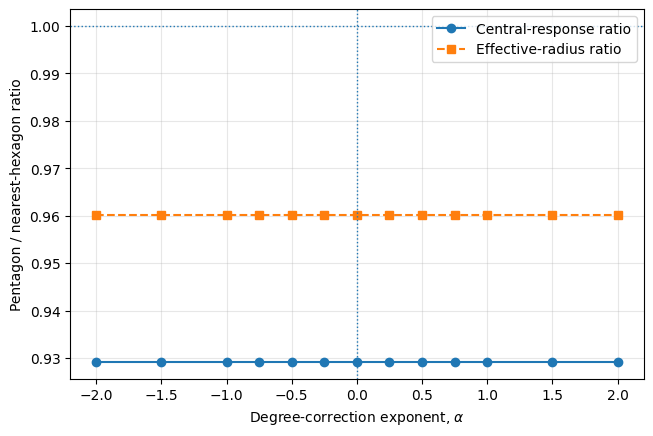

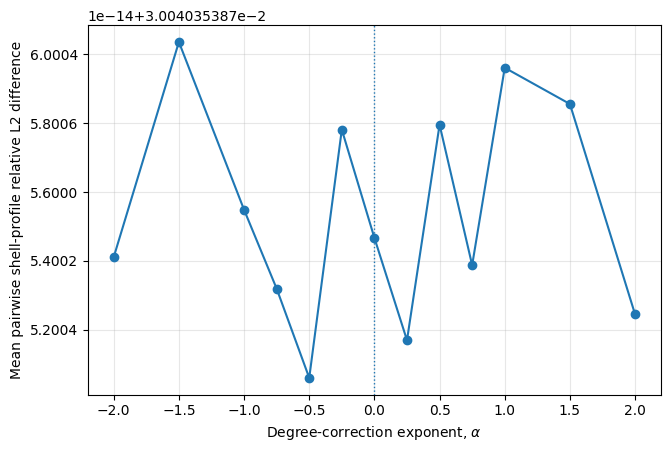

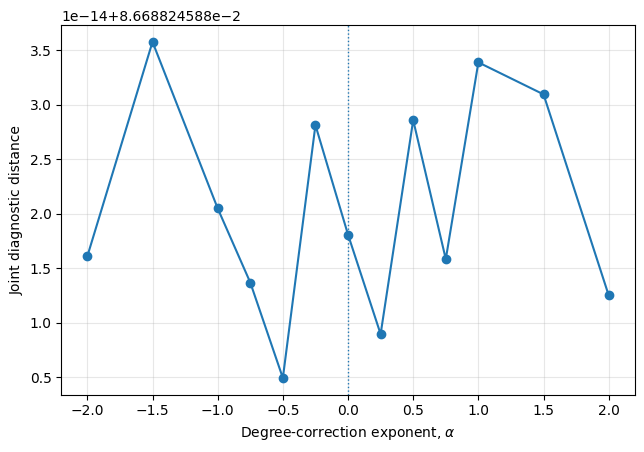

In [ ]:

"""
test_s1_degree_correction_p5_v2.py

Degree-aware seed-weight test built directly on the SAME nsub4 grid,
dual-cell adjacency construction, S1 balancing, and p=5 repeated-resolvent
formulation used in the successful preceding diagnostics.

alpha = 0 is the exact S1 control.

For each graph edge (i,j):
    g_i = (degree_i/6)^alpha
    K0_ij = sqrt(g_i*g_j)

Then symmetric balancing:
    W = diag(s) K0 diag(s),  W 1 proportional to Ahat

and:
    Q = diag(W 1) - W
    L = Ahat^{-1} Q
    B = [I + (mu/p)L]^{-p}

No pentagon-specific branch and no impulse-response renormalization.
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_hex_ico_grid_nsub4.npz"
OUT = ROOT / "paper_figures"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
MAX_RING = 10
ALPHAS = np.array([-2,-1.5,-1,-0.75,-0.5,-0.25,0,
                   0.25,0.5,0.75,1,1.5,2], float)
SINKHORN_MAXITER = 5000
SINKHORN_TOL = 1e-13
EARTH_RADIUS_KM = 6371.0
RNG_SEED = 12345

# ---------------------------------------------------------------------
# Load exactly the established nsub4 grid
# ---------------------------------------------------------------------
z = np.load(GRID, allow_pickle=True)
area = np.asarray(z["cell_area"], float)
xyz = np.asarray(z["cell_center_xyz"], float)
lon = np.asarray(z["cell_center_lon"], float)
lat = np.asarray(z["cell_center_lat"], float)
dual = z["dual_cells"]

xyz = xyz / np.linalg.norm(xyz, axis=1)[:,None]
if np.max(np.abs(lon)) <= 2*np.pi + 1e-6:
    lon, lat = np.rad2deg(lon), np.rad2deg(lat)

n = len(area)
Aref = float(np.mean(area))
ahat = area/Aref

# ---------------------------------------------------------------------
# SAME dual-cell adjacency construction used by successful tests
# ---------------------------------------------------------------------
e2c = {}
for ci, poly in enumerate(dual):
    poly = np.asarray(poly, int)
    for k in range(len(poly)):
        e = tuple(sorted((int(poly[k]), int(poly[(k+1)%len(poly)]))))
        e2c.setdefault(e, []).append(ci)

edges = []
for cells in e2c.values():
    if len(cells) == 2 and cells[0] != cells[1]:
        edges.append(tuple(sorted((int(cells[0]), int(cells[1])))))
edges = np.unique(np.asarray(edges, int), axis=0)
ei, ej = edges[:,0], edges[:,1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i,j in edges:
    nbr[i].append(int(j)); nbr[j].append(int(i))
degree = np.asarray([len(v) for v in nbr], int)

pent_ids = np.where(degree == 5)[0]
hex_ids = np.where(degree == 6)[0]

# Nearest degree-6 cell to every pentagon
nearest_hex = {}
for jp in pent_ids:
    dots = np.clip(xyz[hex_ids] @ xyz[jp], -1.0, 1.0)
    nearest_hex[int(jp)] = int(hex_ids[np.argmax(dots)])

sources = np.unique(np.r_[pent_ids, list(nearest_hex.values())])

# Precompute graph rings and great-circle distances for source cells
def graph_distance(j):
    d = -np.ones(n, int); d[j] = 0
    q = deque([int(j)])
    while q:
        i = q.popleft()
        if d[i] >= MAX_RING:
            continue
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

rings_cache = {int(j): graph_distance(int(j)) for j in sources}
dist_cache = {}
for j in sources:
    dots = np.clip(xyz @ xyz[int(j)], -1.0, 1.0)
    dist_cache[int(j)] = EARTH_RADIUS_KM*np.arccos(dots)

# ---------------------------------------------------------------------
# Symmetric balancing
# ---------------------------------------------------------------------
def make_seed(alpha):
    g = (degree.astype(float)/6.0)**alpha
    w = np.sqrt(g[ei]*g[ej])
    return sp.coo_matrix(
        (np.r_[w,w], (np.r_[ei,ej], np.r_[ej,ei])),
        shape=(n,n)
    ).tocsr()

def symmetric_balance(K0, target):
    s = np.ones(n, float)
    for it in range(SINKHORN_MAXITER):
        row = s*(K0@s)
        rel = np.max(np.abs(row-target)/np.maximum(target,1e-300))
        if rel < SINKHORN_TOL:
            break
        s *= np.sqrt(target/np.maximum(row,1e-300))
    row = s*(K0@s)
    rel = np.max(np.abs(row-target)/np.maximum(target,1e-300))
    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()
    return W, it+1, rel

def normalize_mean_edge_weight(W):
    ew = np.asarray(W[ei,ej]).ravel()
    fac = 1.0/np.mean(ew)
    return (fac*W).tocsr(), fac

def make_B(W):
    rowsum = np.asarray(W.sum(axis=1)).ravel()
    Q = (sp.diags(rowsum)-W).tocsr()
    L = (sp.diags(1.0/ahat)@Q).tocsr()
    M = sp.eye(n,format="csr") + (MU/P)*L
    solve = spla.factorized(M.tocsc())
    def B(x):
        y = np.asarray(x,float).copy()
        for _ in range(P):
            y = solve(y)
        return y
    return Q,B

def innerA(x,y):
    return float(np.sum(area*x*y))

def metrics(B,j):
    delta = np.zeros(n); delta[j] = 1.0/area[j]
    r = B(delta); mass = area*r
    integ = float(mass.sum())
    central = float(mass[j])
    dkm = dist_cache[int(j)]
    reff = np.sqrt(max(float(np.sum(mass*dkm**2)/integ),0.0))
    gd = rings_cache[int(j)]
    shell = np.array([mass[gd==k].sum() for k in range(MAX_RING+1)])
    return integ,central,reff,shell

# ---------------------------------------------------------------------
# Sweep
# ---------------------------------------------------------------------
rng = np.random.default_rng(RNG_SEED)
rows = []

print("="*132)
print("S1 DEGREE-AWARE SEED-WEIGHT SWEEP -- CONSISTENT nsub4 IMPLEMENTATION")
print(f"p={P}, mu={MU}; alpha=0 is exact S1 control")
print("="*132)
print("cells:",n,"edges:",m,
      "degree counts:",{int(k):int(np.sum(degree==k)) for k in np.unique(degree)})
print("pentagons:",len(pent_ids))
print()
print(f"{'alpha':>7} {'iter':>5} {'bal.err':>11} {'SA.err':>11} {'const':>11} "
      f"{'Iconsv':>11} {'CP/CH':>9} {'Cdiff%':>9} {'RP/RH':>9} {'Rdiff%':>9} {'shellL2':>10}")

for alpha in ALPHAS:
    K0 = make_seed(alpha)
    W,nit,berr = symmetric_balance(K0,ahat)
    W,nfac = normalize_mean_edge_weight(W)
    Q,B = make_B(W)

    x=rng.standard_normal(n); y=rng.standard_normal(n)
    lhs=innerA(x,B(y)); rhs=innerA(B(x),y)
    sa=abs(lhs-rhs)/max(abs(lhs),abs(rhs),1e-300)
    const=float(np.max(np.abs(B(np.ones(n))-1)))

    pm=[]; hm=[]
    for jp in pent_ids:
        pm.append(metrics(B,int(jp)))
        hm.append(metrics(B,nearest_hex[int(jp)]))

    Ip=np.array([v[0] for v in pm]); Ih=np.array([v[0] for v in hm])
    Cp=np.array([v[1] for v in pm]); Ch=np.array([v[1] for v in hm])
    Rp=np.array([v[2] for v in pm]); Rh=np.array([v[2] for v in hm])

    cr=np.mean(Cp/Ch)
    rr=np.mean(Rp/Rh)
    sl=np.mean([np.linalg.norm(pm[k][3]-hm[k][3])/
                np.linalg.norm(hm[k][3]) for k in range(len(pm))])
    icon=max(np.max(np.abs(Ip-1)),np.max(np.abs(Ih-1)))

    rows.append((alpha,nit,berr,sa,const,icon,cr,100*abs(1-cr),
                 rr,100*abs(1-rr),sl,nfac))

    print(f"{alpha:7.2f} {nit:5d} {berr:11.3e} {sa:11.3e} {const:11.3e} "
          f"{icon:11.3e} {cr:9.5f} {100*abs(1-cr):9.3f} "
          f"{rr:9.5f} {100*abs(1-rr):9.3f} {sl:10.5f}")

R=np.asarray(rows,float)
alpha=R[:,0]; cr=R[:,6]; rr=R[:,8]; sl=R[:,10]
joint=np.sqrt((cr-1)**2+(rr-1)**2+sl**2)

i0=int(np.argmin(np.abs(alpha)))
ij=int(np.argmin(joint))

print("\nCONTROL alpha=0 (must reproduce S1 nearest-pair result)")
print(f"  central P/H = {cr[i0]:.8f}")
print(f"  radius  P/H = {rr[i0]:.8f}")
print(f"  shell L2    = {sl[i0]:.8f}")

print("\nSMALLEST JOINT DIAGNOSTIC DISTANCE (inspection only)")
print(f"  alpha       = {alpha[ij]:.6f}")
print(f"  central P/H = {cr[ij]:.8f}")
print(f"  radius  P/H = {rr[ij]:.8f}")
print(f"  shell L2    = {sl[ij]:.8f}")

# ---------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------
fig,ax=plt.subplots(figsize=(7.4,4.8))
ax.plot(alpha,cr,"o-",label="Central-response ratio")
ax.plot(alpha,rr,"s--",label="Effective-radius ratio")
ax.axhline(1,ls=":",lw=1); ax.axvline(0,ls=":",lw=1)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Pentagon / nearest-hexagon ratio")
ax.grid(True,alpha=.3); ax.legend()
f1=OUT/"test_s1_degree_correction_ratios_p5_v2.png"
fig.savefig(f1,dpi=300,bbox_inches="tight")

fig,ax=plt.subplots(figsize=(7.4,4.8))
ax.plot(alpha,sl,"o-"); ax.axvline(0,ls=":",lw=1)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Mean pairwise shell-profile relative L2 difference")
ax.grid(True,alpha=.3)
f2=OUT/"test_s1_degree_correction_shellL2_p5_v2.png"
fig.savefig(f2,dpi=300,bbox_inches="tight")

fig,ax=plt.subplots(figsize=(7.4,4.8))
ax.plot(alpha,joint,"o-"); ax.axvline(0,ls=":",lw=1)
ax.set_xlabel(r"Degree-correction exponent, $\alpha$")
ax.set_ylabel("Joint diagnostic distance")
ax.grid(True,alpha=.3)
f3=OUT/"test_s1_degree_correction_joint_p5_v2.png"
fig.savefig(f3,dpi=300,bbox_inches="tight")

np.savez(OUT/"test_s1_degree_correction_p5_v2.npz",
         rows=R, alpha=alpha, central_ratio=cr, radius_ratio=rr,
         shell_l2=sl, joint=joint, pent_ids=pent_ids,
         nearest_hex=np.array([nearest_hex[int(j)] for j in pent_ids]))

print("\nSaved:",f1)
print("Saved:",f2)
print("Saved:",f3)
print("Saved:",OUT/"test_s1_degree_correction_p5_v2.npz")
print("\nDONE.")
plt.show()


# test_s1_degree_target_correction_p5_v1.py

S1 DEGREE-AWARE TARGET SWEEP -- nsub4
p=5, mu=0.5
target_i = Ahat_i * (degree_i/6)^alpha
alpha=0 is exact S1 control
cells: 2562 edges: 7680 degree counts: {5: 12, 6: 2550}
pentagons: 12

  alpha  iter     bal.err       Qsym         Q1      SA.err       const      Iconsv     CP/CH    Cdiff%     RP/RH    Rdiff%    shellL2
  -2.00    91   9.664e-14  0.000e+00  1.998e-15   1.242e-15   5.329e-15   8.882e-16   0.65429    34.571   0.99269     0.731    0.11832
  -1.50    88   7.824e-14  0.000e+00  2.220e-15   4.102e-16   3.775e-15   8.882e-16   0.70915    29.085   0.98635     1.365    0.09963
  -1.00    83   7.572e-14  0.000e+00  1.998e-15   1.272e-15   4.441e-15   8.882e-16   0.77287    22.713   0.97880     2.120    0.07829
  -0.75    77   8.780e-14  0.000e+00  1.998e-15   4.342e-16   4.552e-15   6.661e-16   0.80825    19.175   0.97457     2.543    0.06665
  -0.50    80   9.299e-14  0.000e+00  1.776e-15   2.939e-16   4.108e-15   9.992e-16   0.84606    15.394   0.97003     2.997    0.05446
  

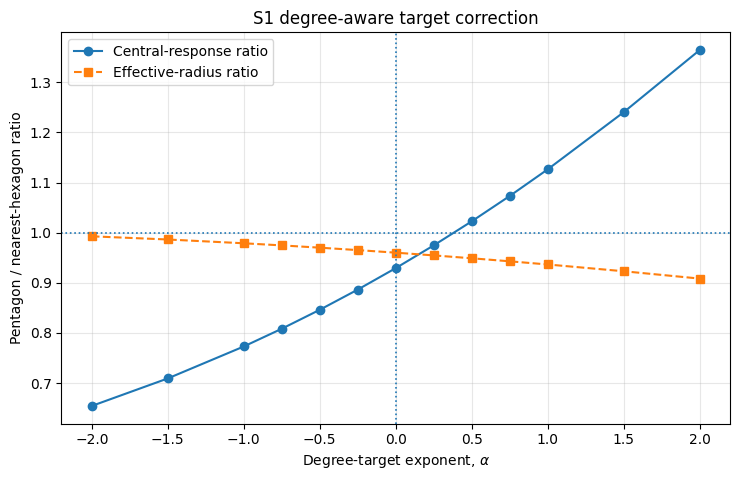

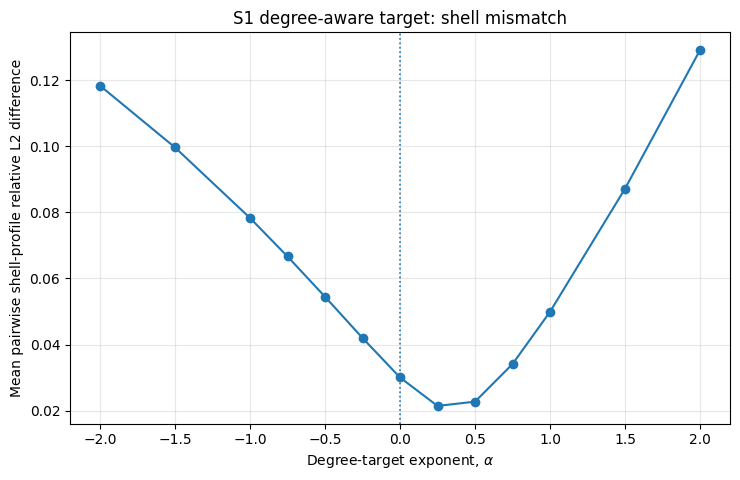

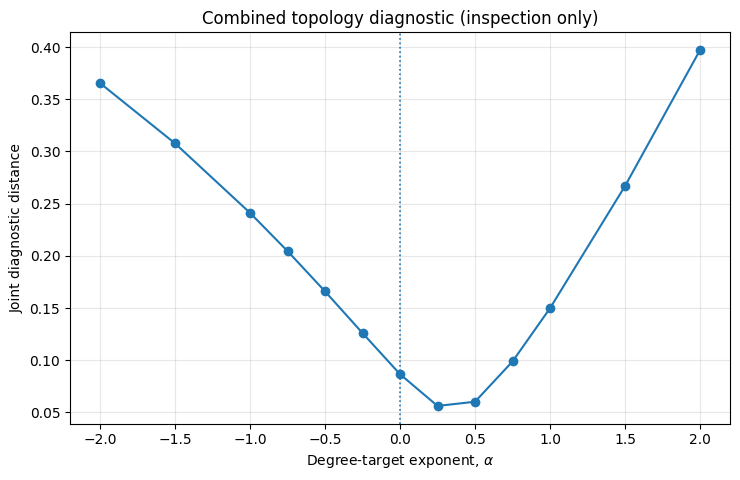

In [ ]:
#!/usr/bin/env python3
"""
test_s1_degree_target_correction_p5_v1.py

Controlled follow-up to the S1 invariance test.

The successful S1 formulation is retained, except that the prescribed
Sinkhorn row-sum target is allowed to depend weakly on graph degree:

    target_i(alpha) = Ahat_i * (degree_i / 6)^alpha

alpha = 0 is EXACTLY the present S1 control.

After symmetric balancing:
    W = diag(s) K0 diag(s),   W 1 = target(alpha)

construct
    Q = diag(W 1) - W
    L_A = Ahat^{-1} Q
    B^(p) = [I + (mu/p)L_A]^{-p}

with p=5, mu=0.5.

Because Q is symmetric and Q*1=0 for every alpha, this experiment
retains area-weighted self-adjointness, constant preservation, and
area-integral conservation.  Unlike the previous seed-weight test,
changing the prescribed row-sum target is not removable by a diagonal
Sinkhorn rescaling.

Grid:
    global_hex_ico_grid_nsub4.npz
    2562 cells, 12 degree-5 cells, 2550 degree-6 cells.

Diagnostics:
    all 12 pentagons versus their nearest degree-6 cells:
      - central-response ratio
      - effective-radius ratio
      - shell-profile relative L2 difference
      - conservation
      - constant preservation
      - area-weighted self-adjointness
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_hex_ico_grid_nsub4.npz"
OUT = ROOT / "paper_figures"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
MAX_RING = 10
ALPHAS = np.array([
    -2.0, -1.5, -1.0, -0.75, -0.50, -0.25,
     0.0,
     0.25, 0.50, 0.75, 1.0, 1.5, 2.0
], float)

SINKHORN_MAXITER = 5000
SINKHORN_TOL = 1e-13
EARTH_RADIUS_KM = 6371.0
RNG_SEED = 12345

# ---------------------------------------------------------------------
# Load established nsub4 grid
# ---------------------------------------------------------------------
z = np.load(GRID, allow_pickle=True)
area = np.asarray(z["cell_area"], float)
xyz = np.asarray(z["cell_center_xyz"], float)
dual = z["dual_cells"]

xyz = xyz / np.linalg.norm(xyz, axis=1)[:, None]

n = len(area)
Aref = float(np.mean(area))
ahat = area / Aref

# ---------------------------------------------------------------------
# Build cell adjacency from shared dual-cell edges
# ---------------------------------------------------------------------
e2c = {}
for ci, poly in enumerate(dual):
    poly = np.asarray(poly, int)
    for k in range(len(poly)):
        e = tuple(sorted((int(poly[k]), int(poly[(k + 1) % len(poly)]))))
        e2c.setdefault(e, []).append(ci)

edges = []
for cells in e2c.values():
    if len(cells) == 2 and cells[0] != cells[1]:
        edges.append(tuple(sorted((int(cells[0]), int(cells[1])))))

edges = np.unique(np.asarray(edges, int), axis=0)
ei, ej = edges[:, 0], edges[:, 1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i, j in edges:
    nbr[i].append(int(j))
    nbr[j].append(int(i))

degree = np.asarray([len(v) for v in nbr], int)
pent_ids = np.where(degree == 5)[0]
hex_ids = np.where(degree == 6)[0]

# ---------------------------------------------------------------------
# Nearest degree-6 neighbor in physical space for each pentagon
# ---------------------------------------------------------------------
nearest_hex = {}
for jp in pent_ids:
    dots = np.clip(xyz[hex_ids] @ xyz[jp], -1.0, 1.0)
    nearest_hex[int(jp)] = int(hex_ids[np.argmax(dots)])

sources = np.unique(np.r_[pent_ids, list(nearest_hex.values())])

# ---------------------------------------------------------------------
# Cache graph rings and physical distances
# ---------------------------------------------------------------------
def graph_distance(j):
    d = -np.ones(n, int)
    d[j] = 0
    q = deque([int(j)])
    while q:
        i = q.popleft()
        if d[i] >= MAX_RING:
            continue
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

rings_cache = {int(j): graph_distance(int(j)) for j in sources}

dist_cache = {}
for j in sources:
    dots = np.clip(xyz @ xyz[int(j)], -1.0, 1.0)
    dist_cache[int(j)] = EARTH_RADIUS_KM * np.arccos(dots)

# ---------------------------------------------------------------------
# Fixed unweighted symmetric seed graph
# ---------------------------------------------------------------------
K0 = sp.coo_matrix(
    (
        np.ones(2 * m),
        (np.r_[ei, ej], np.r_[ej, ei])
    ),
    shape=(n, n)
).tocsr()

# ---------------------------------------------------------------------
# Symmetric Sinkhorn balancing to prescribed target
# ---------------------------------------------------------------------
def symmetric_balance(K0, target):
    s = np.ones(n, float)

    for it in range(SINKHORN_MAXITER):
        row = s * (K0 @ s)
        rel = np.max(np.abs(row - target) / np.maximum(target, 1e-300))
        if rel < SINKHORN_TOL:
            break

        s *= np.sqrt(target / np.maximum(row, 1e-300))

    row = s * (K0 @ s)
    rel = np.max(np.abs(row - target) / np.maximum(target, 1e-300))
    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()

    return W, it + 1, rel

def normalize_mean_edge_weight(W):
    """
    Preserve the convention of the previous S1 diagnostics:
    normalize the mean undirected edge conductance to one.
    This is a global scalar and does not alter the relative degree correction.
    """
    ew = np.asarray(W[ei, ej]).ravel()
    fac = 1.0 / np.mean(ew)
    return (fac * W).tocsr(), fac

# ---------------------------------------------------------------------
# Repeated-resolvent operator
# ---------------------------------------------------------------------
def make_B(W):
    rowsum = np.asarray(W.sum(axis=1)).ravel()

    Q = (sp.diags(rowsum) - W).tocsr()
    L = (sp.diags(1.0 / ahat) @ Q).tocsr()

    M = sp.eye(n, format="csr") + (MU / P) * L
    solve = spla.factorized(M.tocsc())

    def B(x):
        y = np.asarray(x, float).copy()
        for _ in range(P):
            y = solve(y)
        return y

    return Q, L, B

def innerA(x, y):
    return float(np.sum(area * x * y))

# ---------------------------------------------------------------------
# Impulse diagnostics
# ---------------------------------------------------------------------
def metrics(B, j):
    # Unit-area impulse
    delta = np.zeros(n)
    delta[j] = 1.0 / area[j]

    r = B(delta)
    mass = area * r

    integral = float(mass.sum())
    central = float(mass[j])

    dkm = dist_cache[int(j)]
    reff = np.sqrt(max(float(np.sum(mass * dkm**2) / integral), 0.0))

    gd = rings_cache[int(j)]
    shell = np.array([
        mass[gd == k].sum()
        for k in range(MAX_RING + 1)
    ])

    return integral, central, reff, shell

# ---------------------------------------------------------------------
# Sweep
# ---------------------------------------------------------------------
rng = np.random.default_rng(RNG_SEED)
rows = []

print("=" * 136)
print("S1 DEGREE-AWARE TARGET SWEEP -- nsub4")
print(f"p={P}, mu={MU}")
print("target_i = Ahat_i * (degree_i/6)^alpha")
print("alpha=0 is exact S1 control")
print("=" * 136)
print(
    "cells:", n,
    "edges:", m,
    "degree counts:",
    {int(k): int(np.sum(degree == k)) for k in np.unique(degree)}
)
print("pentagons:", len(pent_ids))
print()

print(
    f"{'alpha':>7} {'iter':>5} {'bal.err':>11} "
    f"{'Qsym':>10} {'Q1':>10} {'SA.err':>11} {'const':>11} {'Iconsv':>11} "
    f"{'CP/CH':>9} {'Cdiff%':>9} {'RP/RH':>9} {'Rdiff%':>9} {'shellL2':>10}"
)

for alpha in ALPHAS:

    # This is the ONLY substantive change from S1.
    target = ahat * (degree.astype(float) / 6.0) ** alpha

    W, nit, berr = symmetric_balance(K0, target)
    W, nfac = normalize_mean_edge_weight(W)

    Q, L, B = make_B(W)

    # Structural checks
    qsym = spla.norm(Q - Q.T) / max(spla.norm(Q), 1e-300)
    q1 = float(np.max(np.abs(Q @ np.ones(n))))

    # Area-weighted self-adjointness
    x = rng.standard_normal(n)
    y = rng.standard_normal(n)
    lhs = innerA(x, B(y))
    rhs = innerA(B(x), y)
    sa = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-300)

    # Constant preservation
    const = float(np.max(np.abs(B(np.ones(n)) - 1.0)))

    # All 12 pentagons and nearest degree-6 cells
    pm = []
    hm = []

    for jp in pent_ids:
        pm.append(metrics(B, int(jp)))
        hm.append(metrics(B, nearest_hex[int(jp)]))

    Ip = np.array([v[0] for v in pm])
    Ih = np.array([v[0] for v in hm])

    Cp = np.array([v[1] for v in pm])
    Ch = np.array([v[1] for v in hm])

    Rp = np.array([v[2] for v in pm])
    Rh = np.array([v[2] for v in hm])

    conservation = max(
        np.max(np.abs(Ip - 1.0)),
        np.max(np.abs(Ih - 1.0))
    )

    cpair = Cp / Ch
    rpair = Rp / Rh

    cr = float(np.mean(cpair))
    rr = float(np.mean(rpair))

    shell_pair = np.array([
        np.linalg.norm(pm[k][3] - hm[k][3]) /
        max(np.linalg.norm(hm[k][3]), 1e-300)
        for k in range(len(pm))
    ])
    sl = float(np.mean(shell_pair))

    rows.append((
        alpha, nit, berr, qsym, q1, sa, const, conservation,
        cr, 100.0 * abs(1.0 - cr),
        rr, 100.0 * abs(1.0 - rr),
        sl, nfac,
        float(np.std(cpair)),
        float(np.std(rpair)),
        float(np.std(shell_pair))
    ))

    print(
        f"{alpha:7.2f} {nit:5d} {berr:11.3e} "
        f"{qsym:10.3e} {q1:10.3e} {sa:11.3e} {const:11.3e} {conservation:11.3e} "
        f"{cr:9.5f} {100*abs(1-cr):9.3f} "
        f"{rr:9.5f} {100*abs(1-rr):9.3f} {sl:10.5f}"
    )

R = np.asarray(rows, float)

alpha = R[:, 0]
cr = R[:, 8]
rr = R[:, 10]
sl = R[:, 12]

# Inspection-only combined distance to ideal (1,1,0)
joint = np.sqrt((cr - 1.0)**2 + (rr - 1.0)**2 + sl**2)

i0 = int(np.argmin(np.abs(alpha)))
ij = int(np.argmin(joint))
ic = int(np.argmin(np.abs(cr - 1.0)))
ir = int(np.argmin(np.abs(rr - 1.0)))
ishell = int(np.argmin(sl))

print("\n" + "=" * 136)
print("CONTROL alpha=0 -- should reproduce present S1")
print("=" * 136)
print(f"central P/H = {cr[i0]:.8f}")
print(f"radius  P/H = {rr[i0]:.8f}")
print(f"shell L2    = {sl[i0]:.8f}")

print("\n" + "=" * 136)
print("BEST VALUES WITHIN THIS COARSE SWEEP -- DIAGNOSTIC ONLY")
print("=" * 136)
print(
    f"closest central ratio: alpha={alpha[ic]:+.3f}, "
    f"CP/CH={cr[ic]:.8f}, RP/RH={rr[ic]:.8f}, shellL2={sl[ic]:.8f}"
)
print(
    f"closest radius ratio : alpha={alpha[ir]:+.3f}, "
    f"CP/CH={cr[ir]:.8f}, RP/RH={rr[ir]:.8f}, shellL2={sl[ir]:.8f}"
)
print(
    f"smallest shell L2    : alpha={alpha[ishell]:+.3f}, "
    f"CP/CH={cr[ishell]:.8f}, RP/RH={rr[ishell]:.8f}, shellL2={sl[ishell]:.8f}"
)
print(
    f"smallest joint metric: alpha={alpha[ij]:+.3f}, "
    f"CP/CH={cr[ij]:.8f}, RP/RH={rr[ij]:.8f}, shellL2={sl[ij]:.8f}"
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
npz_path = OUT / "test_s1_degree_target_correction_p5_v1.npz"

np.savez(
    npz_path,
    rows=R,
    alpha=alpha,
    central_ratio=cr,
    radius_ratio=rr,
    shell_l2=sl,
    joint=joint,
    pent_ids=pent_ids,
    nearest_hex=np.array([nearest_hex[int(j)] for j in pent_ids])
)

# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.9))
ax.plot(alpha, cr, "o-", label="Central-response ratio")
ax.plot(alpha, rr, "s--", label="Effective-radius ratio")
ax.axhline(1.0, ls=":", lw=1.2)
ax.axvline(0.0, ls=":", lw=1.2)
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Pentagon / nearest-hexagon ratio")
ax.set_title("S1 degree-aware target correction")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f1 = OUT / "test_s1_degree_target_ratios_p5_v1.png"
fig.savefig(f1, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.5, 4.9))
ax.plot(alpha, sl, "o-")
ax.axvline(0.0, ls=":", lw=1.2)
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Mean pairwise shell-profile relative L2 difference")
ax.set_title("S1 degree-aware target: shell mismatch")
ax.grid(True, alpha=0.3)
fig.tight_layout()
f2 = OUT / "test_s1_degree_target_shellL2_p5_v1.png"
fig.savefig(f2, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.5, 4.9))
ax.plot(alpha, joint, "o-")
ax.axvline(0.0, ls=":", lw=1.2)
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Joint diagnostic distance")
ax.set_title("Combined topology diagnostic (inspection only)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
f3 = OUT / "test_s1_degree_target_joint_p5_v1.png"
fig.savefig(f3, dpi=300, bbox_inches="tight")

print("\nSaved:", f1)
print("Saved:", f2)
print("Saved:", f3)
print("Saved:", npz_path)
print("\nDONE.")

plt.show()


# test_s1_degree_target_finesweep_p5_v1.py

S1 DEGREE-AWARE TARGET FINE SWEEP
p=5, mu=0.5
target_i = Ahat_i * (degree_i/6)^alpha
alpha=0 is original S1 control
cells: 2562 edges: 7680 degree counts: {5: 12, 6: 2550}
pentagons: 12

  alpha  iter     bal.err      SA.err       const      Iconsv      CP/CH    Cdiff%      RP/RH    Rdiff%    shellL2
   0.00    83   8.478e-14   3.721e-16   3.775e-15   8.882e-16   0.929169     7.083   0.960057     3.994   0.030040
   0.05    83   8.755e-14   1.604e-15   4.330e-15   8.882e-16   0.938040     6.196   0.958993     4.101   0.027890
   0.10    83   9.002e-14   3.055e-15   5.107e-15   1.332e-15   0.947013     5.299   0.957917     4.208   0.025896
   0.15    83   9.253e-14   0.000e+00   4.552e-15   8.882e-16   0.956089     4.391   0.956828     4.317   0.024111
   0.20    83   9.457e-14   0.000e+00   4.219e-15   7.772e-16   0.965268     3.473   0.955728     4.427   0.022599
   0.25    83   9.647e-14   1.347e-16   5.107e-15   6.661e-16   0.974551     2.545   0.954616     4.538   0.021433
   0.30 

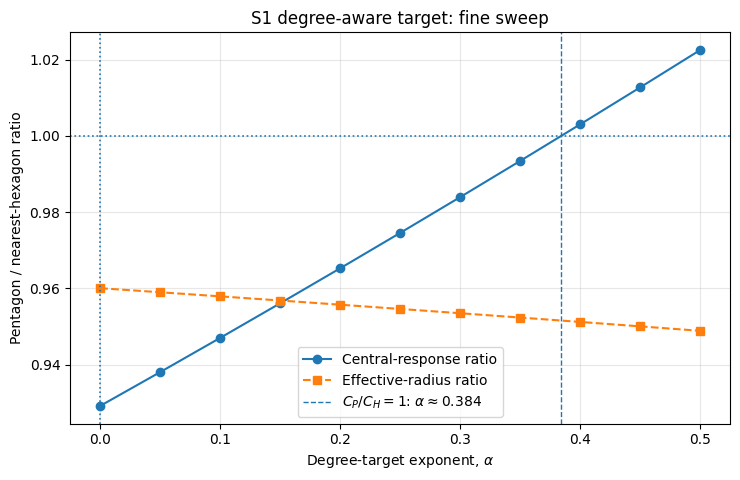

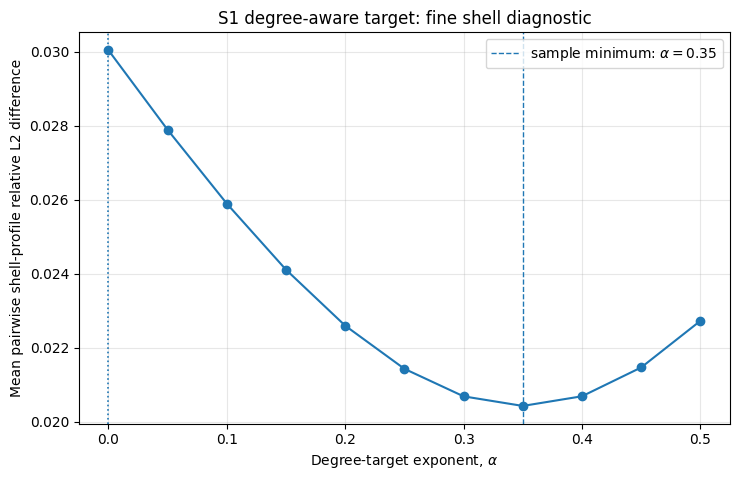

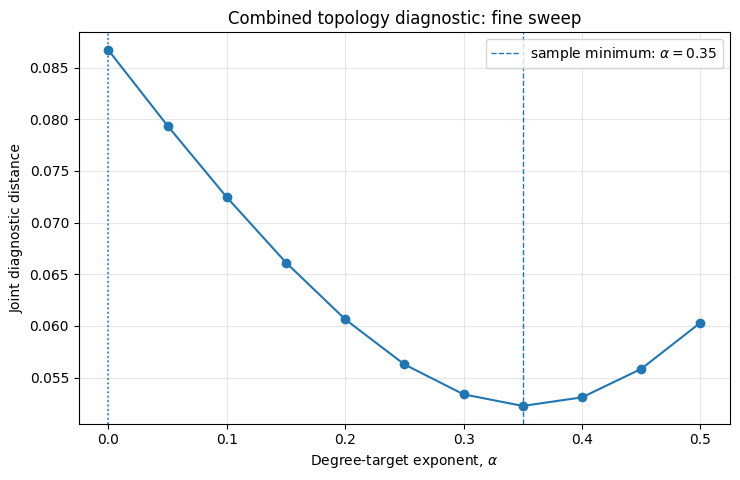

In [ ]:
#!/usr/bin/env python3
"""
test_s1_degree_target_finesweep_p5_v1.py

Fine sweep of the degree-aware S1 balancing target around the promising
coarse-sweep interval.

    target_i(alpha) = Ahat_i * (degree_i/6)^alpha

alpha=0 is the original S1 control.

Fixed:
    nsub4 grid (2562 cells)
    p = 5
    mu = 0.5
    unweighted symmetric seed graph
    area-compatible repeated resolvent
    all 12 pentagons versus nearest degree-6 cells

Fine sweep:
    alpha = 0.00, 0.05, ..., 0.50

In addition to the discrete sweep, the script linearly interpolates:
    1) alpha where central P/H = 1
    2) alpha at minimum sampled shell L2
    3) alpha at minimum sampled joint diagnostic

No formulation is selected automatically.
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_hex_ico_grid_nsub4.npz"
OUT = ROOT / "paper_figures"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
MAX_RING = 10
ALPHAS = np.arange(0.0, 0.5000001, 0.05)

SINKHORN_MAXITER = 5000
SINKHORN_TOL = 1e-13
EARTH_RADIUS_KM = 6371.0
RNG_SEED = 12345

# ---------------------------------------------------------------------
# Grid
# ---------------------------------------------------------------------
z = np.load(GRID, allow_pickle=True)
area = np.asarray(z["cell_area"], float)
xyz = np.asarray(z["cell_center_xyz"], float)
dual = z["dual_cells"]
xyz = xyz / np.linalg.norm(xyz, axis=1)[:, None]

n = len(area)
Aref = float(np.mean(area))
ahat = area / Aref

# ---------------------------------------------------------------------
# Cell adjacency from shared dual-cell polygon edges
# ---------------------------------------------------------------------
e2c = {}
for ci, poly in enumerate(dual):
    poly = np.asarray(poly, int)
    for k in range(len(poly)):
        e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
        e2c.setdefault(e, []).append(ci)

edges = []
for cells in e2c.values():
    if len(cells) == 2 and cells[0] != cells[1]:
        edges.append(tuple(sorted((int(cells[0]), int(cells[1])))))

edges = np.unique(np.asarray(edges, int), axis=0)
ei, ej = edges[:, 0], edges[:, 1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i, j in edges:
    nbr[i].append(int(j))
    nbr[j].append(int(i))

degree = np.asarray([len(v) for v in nbr], int)
pent_ids = np.where(degree == 5)[0]
hex_ids = np.where(degree == 6)[0]

# ---------------------------------------------------------------------
# Nearest hexagon to each pentagon
# ---------------------------------------------------------------------
nearest_hex = {}
for jp in pent_ids:
    dots = np.clip(xyz[hex_ids] @ xyz[jp], -1.0, 1.0)
    nearest_hex[int(jp)] = int(hex_ids[np.argmax(dots)])

sources = np.unique(np.r_[pent_ids, list(nearest_hex.values())])

# ---------------------------------------------------------------------
# Cached graph rings and physical distances
# ---------------------------------------------------------------------
def graph_distance(j):
    d = -np.ones(n, int)
    d[j] = 0
    q = deque([int(j)])
    while q:
        i = q.popleft()
        if d[i] >= MAX_RING:
            continue
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

rings_cache = {int(j): graph_distance(int(j)) for j in sources}

dist_cache = {}
for j in sources:
    dots = np.clip(xyz @ xyz[int(j)], -1.0, 1.0)
    dist_cache[int(j)] = EARTH_RADIUS_KM * np.arccos(dots)

# ---------------------------------------------------------------------
# Fixed unweighted symmetric seed
# ---------------------------------------------------------------------
K0 = sp.coo_matrix(
    (np.ones(2*m), (np.r_[ei, ej], np.r_[ej, ei])),
    shape=(n, n)
).tocsr()

def symmetric_balance(target):
    s = np.ones(n)
    for it in range(SINKHORN_MAXITER):
        row = s * (K0 @ s)
        rel = np.max(np.abs(row-target) / np.maximum(target, 1e-300))
        if rel < SINKHORN_TOL:
            break
        s *= np.sqrt(target / np.maximum(row, 1e-300))

    row = s * (K0 @ s)
    rel = np.max(np.abs(row-target) / np.maximum(target, 1e-300))
    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()
    return W, it+1, rel

def normalize_mean_edge_weight(W):
    ew = np.asarray(W[ei, ej]).ravel()
    fac = 1.0 / np.mean(ew)
    return (fac*W).tocsr(), fac

def make_B(W):
    rowsum = np.asarray(W.sum(axis=1)).ravel()
    Q = (sp.diags(rowsum) - W).tocsr()
    L = (sp.diags(1.0/ahat) @ Q).tocsr()

    M = sp.eye(n, format="csr") + (MU/P)*L
    solve = spla.factorized(M.tocsc())

    def B(x):
        y = np.asarray(x, float).copy()
        for _ in range(P):
            y = solve(y)
        return y

    return Q, B

def innerA(x, y):
    return float(np.sum(area*x*y))

def metrics(B, j):
    delta = np.zeros(n)
    delta[j] = 1.0/area[j]
    r = B(delta)
    mass = area*r

    integ = float(np.sum(mass))
    central = float(mass[j])

    dkm = dist_cache[int(j)]
    reff = np.sqrt(max(float(np.sum(mass*dkm**2)/integ), 0.0))

    gd = rings_cache[int(j)]
    shell = np.array([mass[gd == k].sum() for k in range(MAX_RING+1)])

    return integ, central, reff, shell

# ---------------------------------------------------------------------
# Fine sweep
# ---------------------------------------------------------------------
rng = np.random.default_rng(RNG_SEED)
rows = []

print("="*140)
print("S1 DEGREE-AWARE TARGET FINE SWEEP")
print(f"p={P}, mu={MU}")
print("target_i = Ahat_i * (degree_i/6)^alpha")
print("alpha=0 is original S1 control")
print("="*140)
print("cells:", n, "edges:", m,
      "degree counts:", {int(k): int(np.sum(degree == k))
                         for k in np.unique(degree)})
print("pentagons:", len(pent_ids))
print()
print(
    f"{'alpha':>7} {'iter':>5} {'bal.err':>11} {'SA.err':>11} "
    f"{'const':>11} {'Iconsv':>11} "
    f"{'CP/CH':>10} {'Cdiff%':>9} "
    f"{'RP/RH':>10} {'Rdiff%':>9} {'shellL2':>10}"
)

for alpha in ALPHAS:

    target = ahat * (degree.astype(float)/6.0)**alpha

    W, nit, berr = symmetric_balance(target)
    W, nfac = normalize_mean_edge_weight(W)
    Q, B = make_B(W)

    x = rng.standard_normal(n)
    y = rng.standard_normal(n)
    lhs = innerA(x, B(y))
    rhs = innerA(B(x), y)
    sa = abs(lhs-rhs) / max(abs(lhs), abs(rhs), 1e-300)

    const = float(np.max(np.abs(B(np.ones(n))-1.0)))

    pm = []
    hm = []
    for jp in pent_ids:
        pm.append(metrics(B, int(jp)))
        hm.append(metrics(B, nearest_hex[int(jp)]))

    Ip = np.array([v[0] for v in pm])
    Ih = np.array([v[0] for v in hm])
    Cp = np.array([v[1] for v in pm])
    Ch = np.array([v[1] for v in hm])
    Rp = np.array([v[2] for v in pm])
    Rh = np.array([v[2] for v in hm])

    icon = max(np.max(np.abs(Ip-1.0)), np.max(np.abs(Ih-1.0)))

    cpair = Cp/Ch
    rpair = Rp/Rh

    cr = float(np.mean(cpair))
    rr = float(np.mean(rpair))

    shell_pair = np.array([
        np.linalg.norm(pm[k][3]-hm[k][3]) /
        max(np.linalg.norm(hm[k][3]), 1e-300)
        for k in range(len(pm))
    ])
    sl = float(np.mean(shell_pair))

    rows.append((
        alpha, nit, berr, sa, const, icon,
        cr, 100*abs(1-cr),
        rr, 100*abs(1-rr),
        sl,
        float(np.std(cpair)),
        float(np.std(rpair)),
        float(np.std(shell_pair)),
        nfac
    ))

    print(
        f"{alpha:7.2f} {nit:5d} {berr:11.3e} {sa:11.3e} "
        f"{const:11.3e} {icon:11.3e} "
        f"{cr:10.6f} {100*abs(1-cr):9.3f} "
        f"{rr:10.6f} {100*abs(1-rr):9.3f} {sl:10.6f}"
    )

R = np.asarray(rows, float)
alpha = R[:,0]
cr = R[:,6]
rr = R[:,8]
sl = R[:,10]
joint = np.sqrt((cr-1.0)**2 + (rr-1.0)**2 + sl**2)

# ---------------------------------------------------------------------
# Diagnostic locations
# ---------------------------------------------------------------------
i0 = int(np.argmin(np.abs(alpha)))
ishell = int(np.argmin(sl))
ijoint = int(np.argmin(joint))
iclose = int(np.argmin(np.abs(cr-1.0)))

# Linear interpolation for CP/CH=1 crossing
cross_alpha = np.nan
for k in range(len(alpha)-1):
    f0 = cr[k]-1.0
    f1 = cr[k+1]-1.0
    if f0 == 0:
        cross_alpha = alpha[k]
        break
    if f0*f1 < 0:
        cross_alpha = alpha[k] + (alpha[k+1]-alpha[k]) * (-f0)/(f1-f0)
        break

print("\n" + "="*140)
print("CONTROL")
print("="*140)
print(f"alpha=0: CP/CH={cr[i0]:.8f}, RP/RH={rr[i0]:.8f}, shellL2={sl[i0]:.8f}")

print("\n" + "="*140)
print("FINE-SWEEP DIAGNOSTIC SUMMARY")
print("="*140)
print(
    f"smallest sampled shell L2 : alpha={alpha[ishell]:.2f}, "
    f"CP/CH={cr[ishell]:.8f}, RP/RH={rr[ishell]:.8f}, "
    f"shellL2={sl[ishell]:.8f}"
)
print(
    f"smallest sampled joint    : alpha={alpha[ijoint]:.2f}, "
    f"CP/CH={cr[ijoint]:.8f}, RP/RH={rr[ijoint]:.8f}, "
    f"shellL2={sl[ijoint]:.8f}"
)
print(
    f"closest sampled CP/CH=1   : alpha={alpha[iclose]:.2f}, "
    f"CP/CH={cr[iclose]:.8f}, RP/RH={rr[iclose]:.8f}, "
    f"shellL2={sl[iclose]:.8f}"
)
if np.isfinite(cross_alpha):
    print(f"linear-interpolated CP/CH=1 crossing: alpha ≈ {cross_alpha:.6f}")

# ---------------------------------------------------------------------
# Save data
# ---------------------------------------------------------------------
npz_path = OUT / "test_s1_degree_target_finesweep_p5_v1.npz"
np.savez(
    npz_path,
    rows=R,
    alpha=alpha,
    central_ratio=cr,
    radius_ratio=rr,
    shell_l2=sl,
    joint=joint,
    central_crossing_alpha=cross_alpha,
    pent_ids=pent_ids,
    nearest_hex=np.array([nearest_hex[int(j)] for j in pent_ids])
)

# ---------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5,4.9))
ax.plot(alpha, cr, "o-", label="Central-response ratio")
ax.plot(alpha, rr, "s--", label="Effective-radius ratio")
ax.axhline(1.0, ls=":", lw=1.2)
ax.axvline(0.0, ls=":", lw=1.2)
if np.isfinite(cross_alpha):
    ax.axvline(cross_alpha, ls="--", lw=1.0,
               label=fr"$C_P/C_H=1$: $\alpha\approx{cross_alpha:.3f}$")
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Pentagon / nearest-hexagon ratio")
ax.set_title("S1 degree-aware target: fine sweep")
ax.grid(True, alpha=.3)
ax.legend()
fig.tight_layout()
f1 = OUT / "test_s1_degree_target_finesweep_ratios_p5_v1.png"
fig.savefig(f1, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.5,4.9))
ax.plot(alpha, sl, "o-")
ax.axvline(alpha[ishell], ls="--", lw=1.0,
           label=fr"sample minimum: $\alpha={alpha[ishell]:.2f}$")
ax.axvline(0.0, ls=":", lw=1.2)
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Mean pairwise shell-profile relative L2 difference")
ax.set_title("S1 degree-aware target: fine shell diagnostic")
ax.grid(True, alpha=.3)
ax.legend()
fig.tight_layout()
f2 = OUT / "test_s1_degree_target_finesweep_shellL2_p5_v1.png"
fig.savefig(f2, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.5,4.9))
ax.plot(alpha, joint, "o-")
ax.axvline(alpha[ijoint], ls="--", lw=1.0,
           label=fr"sample minimum: $\alpha={alpha[ijoint]:.2f}$")
ax.axvline(0.0, ls=":", lw=1.2)
ax.set_xlabel(r"Degree-target exponent, $\alpha$")
ax.set_ylabel("Joint diagnostic distance")
ax.set_title("Combined topology diagnostic: fine sweep")
ax.grid(True, alpha=.3)
ax.legend()
fig.tight_layout()
f3 = OUT / "test_s1_degree_target_finesweep_joint_p5_v1.png"
fig.savefig(f3, dpi=300, bbox_inches="tight")

print("\nSaved:", f1)
print("Saved:", f2)
print("Saved:", f3)
print("Saved:", npz_path)
print("\nDONE.")

plt.show()


# compare_voronoi_s1_vs_s1d_p5_v1.py

GRID: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_irregular_voronoi_graph_G0_N2562_v0.npz
Keys: ['level_name', 'cell_center_xyz', 'cell_center_lon', 'cell_center_lat', 'cell_area', 'neighbors', 'adjacency_indptr', 'adjacency_indices', 'adjacency_data', 'degree', 'ncells', 'earth_radius', 'voronoi_regions', 'voronoi_vertices_xyz']
area: cell_area (2562,)
xyz : cell_center_xyz (2562, 3)
connectivity: neighbors
cells: 2562 edges: 7680
degree counts: {4: 8, 5: 209, 6: 2137, 7: 203, 8: 5}

Building S1...
Building S1-D, alpha=0.35...

STRUCTURAL CHECKS
operator iter     bal.err       Qsym          Q1       SA.err       const
S1        104    9.356e-14    0.000e+00   1.998e-15   8.965e-16   3.886e-15
S1-D       95    7.746e-14    0.000e+00   1.776e-15   1.428e-15   4.330e-15

Evaluating S1 over ALL source cells...
S1: 250/2562 source cells completed
S1: 500/2562 source cells completed
S1: 750/2562 source cells completed
S1: 1000/2562 source cells completed
S1: 1250/2562 source cells compl

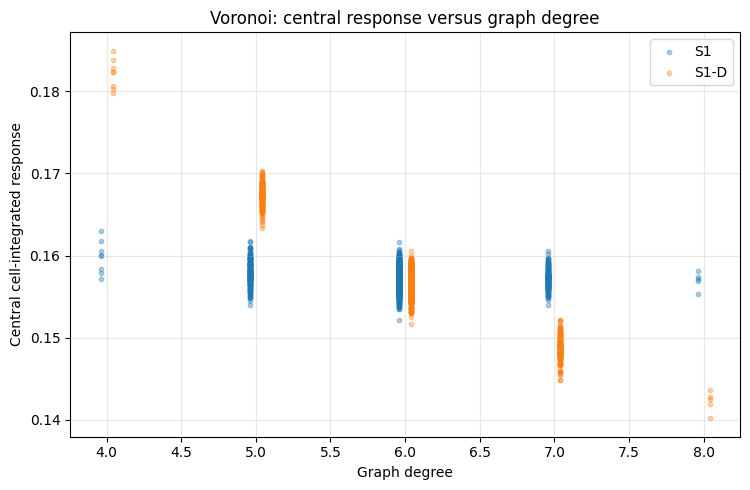

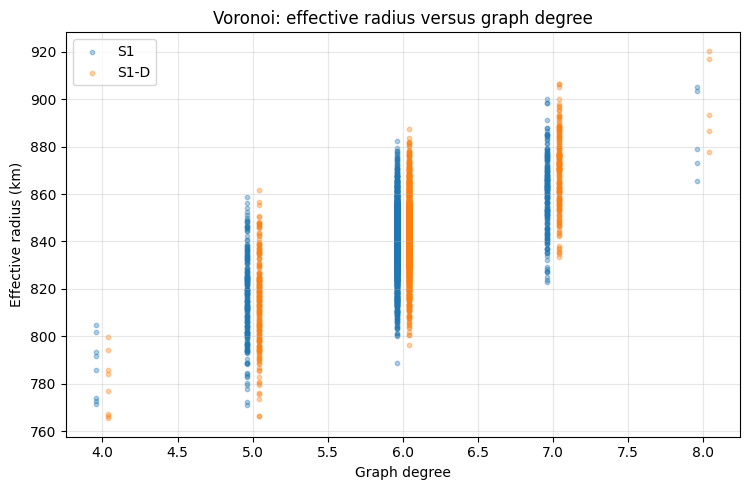

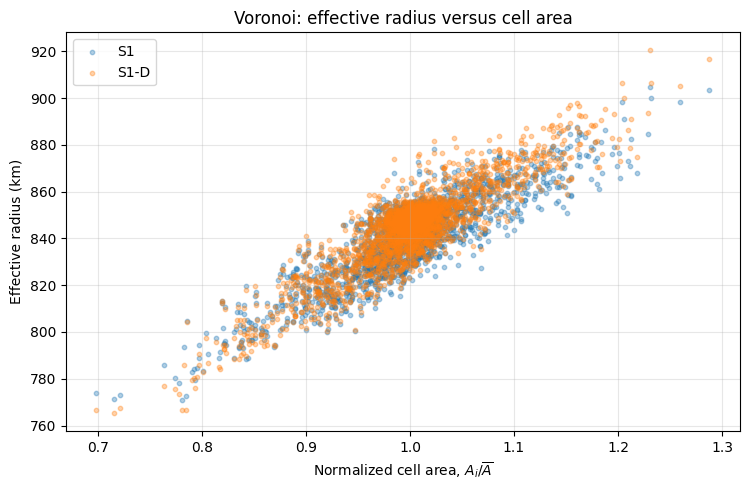

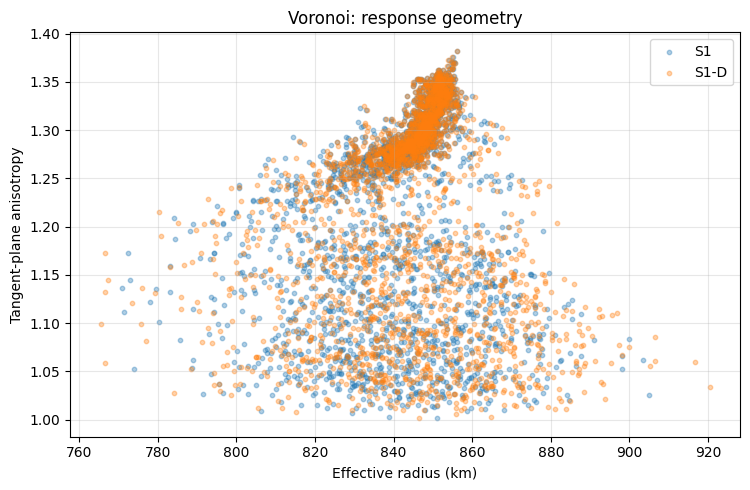

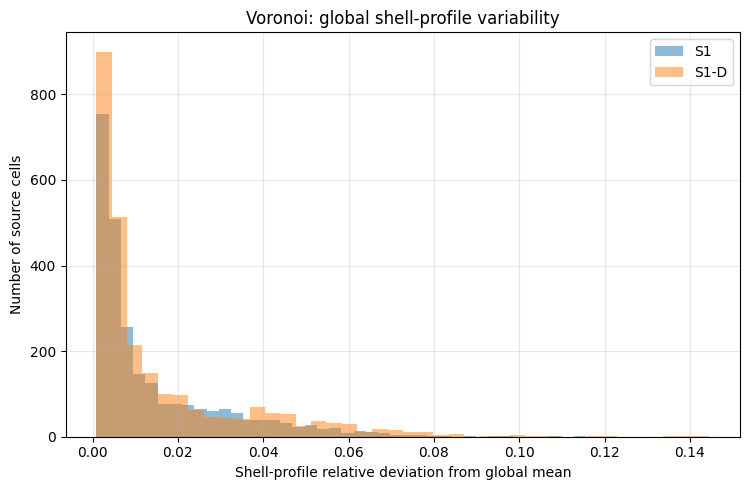

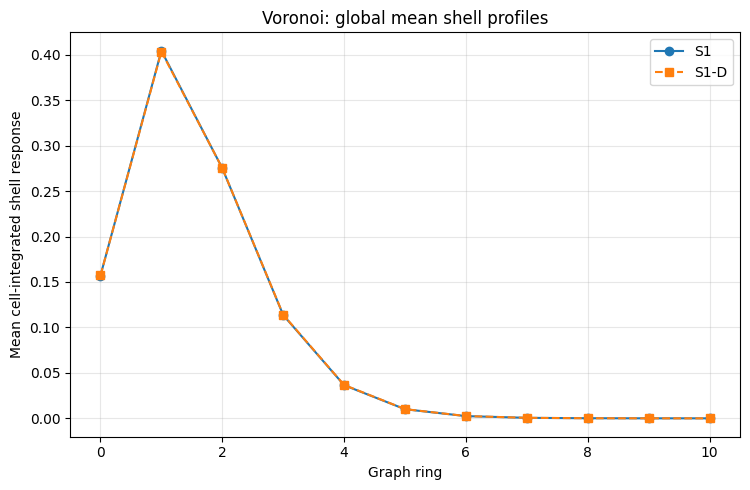

In [ ]:
#!/usr/bin/env python3
"""
compare_voronoi_s1_vs_s1d_p5_v1.py

Decisive no-retuning comparison on the existing irregular Voronoi G0 graph.

Frozen candidates
-----------------
S1:
    target_i = Ahat_i

S1-D:
    target_i = Ahat_i * (degree_i / 6)^0.35

For both:
    Q   = diag(W 1) - W
    L_A = Ahat^{-1} Q
    B   = [I + (mu/p) L_A]^{-p}

with p=5 and mu=0.5.

All Voronoi cells are used as impulse sources. Diagnostics:
  - Q symmetry, Q*1, area-weighted self-adjointness
  - constant preservation and area-integral conservation
  - central cell-integrated response
  - physical effective radius
  - tangent-plane anisotropy
  - centroid displacement
  - graph-shell profile variability
  - dependence on graph degree and cell area

No alpha or other parameter is fitted on the Voronoi grid.
"""

from pathlib import Path
from collections import deque
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid" / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
OUT = ROOT / "paper_figures" / "voronoi_s1_vs_s1d_p5_v1"
OUT.mkdir(parents=True, exist_ok=True)

P = 5
MU = 0.50
ALPHA_D = 0.35
DREF = 6.0
MAX_RING = 10
RE_KM = 6371.0
SINKHORN_MAXITER = 10000
SINKHORN_TOL = 1.0e-13
RNG_SEED = 12345

# ----------------------------------------------------------------------
# Load grid
# ----------------------------------------------------------------------
z = np.load(GRID, allow_pickle=True)
print("GRID:", GRID)
print("Keys:", z.files)

def get_first(names, required=True):
    for k in names:
        if k in z.files:
            return z[k], k
    if required:
        raise KeyError(f"None of {names} found. Available keys: {z.files}")
    return None, None

area, area_key = get_first(["cell_area", "area", "cell_areas"])
xyz, xyz_key = get_first(["cell_center_xyz", "xyz", "cell_xyz", "centers_xyz"])

area = np.asarray(area, dtype=float).ravel()
xyz = np.asarray(xyz, dtype=float)
xyz /= np.linalg.norm(xyz, axis=1)[:, None]

n = area.size
Amean = float(np.mean(area))
ahat = area / Amean

print("area:", area_key, area.shape)
print("xyz :", xyz_key, xyz.shape)

# ----------------------------------------------------------------------
# Connectivity loader
# ----------------------------------------------------------------------
edges = None
conn_key = None

# Direct edge-cell representation
for key in ["edge_cells", "cells_on_edge", "graph_edges", "edges"]:
    if key in z.files:
        a = np.asarray(z[key], dtype=int)
        if a.ndim == 2 and a.shape[1] >= 2:
            e = a[:, :2]
            good = ((e[:, 0] >= 0) & (e[:, 0] < n) &
                    (e[:, 1] >= 0) & (e[:, 1] < n) &
                    (e[:, 0] != e[:, 1]))
            e = np.sort(e[good], axis=1)
            if len(e):
                edges = np.unique(e, axis=0)
                conn_key = key
                break

# Neighbor list representation
if edges is None:
    for key in ["cell_neighbors", "neighbors", "nbrs"]:
        if key not in z.files:
            continue
        a = z[key]
        ee = []
        if getattr(a, "dtype", None) == object:
            for i, row in enumerate(a):
                for j in np.asarray(row, dtype=int).ravel():
                    if 0 <= j < n and j != i:
                        ee.append(tuple(sorted((i, int(j)))))
        else:
            a = np.asarray(a, dtype=int)
            if a.ndim == 2:
                for i in range(n):
                    for j in a[i]:
                        if 0 <= j < n and j != i:
                            ee.append(tuple(sorted((i, int(j)))))
        if ee:
            edges = np.unique(np.asarray(ee, dtype=int), axis=0)
            conn_key = key
            break

# Voronoi polygons: two cells sharing polygon edge are neighbors
if edges is None and "dual_cells" in z.files:
    dual = z["dual_cells"]
    vertex_edge_to_cells = {}
    for ci, poly in enumerate(dual):
        poly = np.asarray(poly, dtype=int).ravel()
        poly = poly[poly >= 0]
        if poly.size < 3:
            continue
        for k in range(poly.size):
            ve = tuple(sorted((int(poly[k]), int(poly[(k + 1) % poly.size]))))
            vertex_edge_to_cells.setdefault(ve, []).append(ci)

    ee = []
    for cells in vertex_edge_to_cells.values():
        if len(cells) == 2 and cells[0] != cells[1]:
            ee.append(tuple(sorted((int(cells[0]), int(cells[1])))))
    if ee:
        edges = np.unique(np.asarray(ee, dtype=int), axis=0)
        conn_key = "dual_cells-derived"

# Triangular faces whose indices directly reference cells
if edges is None:
    for key in ["primal_faces", "triangles", "faces"]:
        if key not in z.files:
            continue
        f = np.asarray(z[key], dtype=int)
        if f.ndim == 2 and f.shape[1] >= 3 and np.min(f) >= 0 and np.max(f) < n:
            ee = []
            for tri in f[:, :3]:
                a, b, c = map(int, tri)
                ee.extend([tuple(sorted((a, b))),
                           tuple(sorted((b, c))),
                           tuple(sorted((c, a)))])
            edges = np.unique(np.asarray(ee, dtype=int), axis=0)
            conn_key = key
            break

if edges is None:
    raise RuntimeError(
        "Could not infer graph connectivity. Please send the printed Keys line."
    )

ei, ej = edges[:, 0], edges[:, 1]
m = len(edges)

nbr = [[] for _ in range(n)]
for i, j in edges:
    nbr[int(i)].append(int(j))
    nbr[int(j)].append(int(i))

degree = np.asarray([len(v) for v in nbr], dtype=int)

print("connectivity:", conn_key)
print("cells:", n, "edges:", m)
print("degree counts:",
      {int(d): int(np.sum(degree == d)) for d in np.unique(degree)})

if np.any(degree == 0):
    raise RuntimeError("At least one isolated graph cell was found.")

# ----------------------------------------------------------------------
# Fixed symmetric seed graph
# ----------------------------------------------------------------------
K0 = sp.coo_matrix(
    (np.ones(2 * m),
     (np.r_[ei, ej], np.r_[ej, ei])),
    shape=(n, n)
).tocsr()

def symmetric_balance(target):
    s = np.ones(n, dtype=float)

    for it in range(SINKHORN_MAXITER):
        row = s * (K0 @ s)
        rel = np.max(np.abs(row - target) /
                     np.maximum(np.abs(target), 1.0e-300))
        if rel < SINKHORN_TOL:
            break
        s *= np.sqrt(target / np.maximum(row, 1.0e-300))

    row = s * (K0 @ s)
    rel = np.max(np.abs(row - target) /
                 np.maximum(np.abs(target), 1.0e-300))

    W = (sp.diags(s) @ K0 @ sp.diags(s)).tocsr()
    return W, it + 1, rel

def normalize_mean_edge_weight(W):
    ew = np.asarray(W[ei, ej]).ravel()
    factor = 1.0 / float(np.mean(ew))
    return (factor * W).tocsr(), factor

def build_operator(target):
    W, nit, balerr = symmetric_balance(target)
    W, normfac = normalize_mean_edge_weight(W)

    rowsum = np.asarray(W.sum(axis=1)).ravel()
    Q = (sp.diags(rowsum) - W).tocsr()

    L = (sp.diags(1.0 / ahat) @ Q).tocsr()

    M = sp.eye(n, format="csr") + (MU / P) * L
    solve = spla.factorized(M.tocsc())

    def B(x):
        y = np.asarray(x, dtype=float).copy()
        for _ in range(P):
            y = solve(y)
        return y

    return W, Q, L, B, nit, balerr, normfac

def innerA(x, y):
    return float(np.sum(area * x * y))

# ----------------------------------------------------------------------
# Geometry
# ----------------------------------------------------------------------
def tangent_basis(r):
    axis = np.array([0.0, 0.0, 1.0])
    e1 = np.cross(axis, r)
    if np.linalg.norm(e1) < 1.0e-12:
        e1 = np.cross(np.array([1.0, 0.0, 0.0]), r)
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(r, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2

def source_geometry(j):
    dots = np.clip(xyz @ xyz[j], -1.0, 1.0)
    angle = np.arccos(dots)
    dkm = RE_KM * angle

    e1, e2 = tangent_basis(xyz[j])

    v = xyz - dots[:, None] * xyz[j][None, :]
    nv = np.linalg.norm(v, axis=1)

    fac = np.zeros(n)
    good = nv > 1.0e-14
    fac[good] = RE_KM * angle[good] / nv[good]

    tv = v * fac[:, None]
    tx = tv @ e1
    ty = tv @ e2

    return dkm, tx, ty

def graph_rings(j):
    d = -np.ones(n, dtype=int)
    d[j] = 0
    q = deque([int(j)])

    while q:
        i = q.popleft()
        if d[i] >= MAX_RING:
            continue
        for k in nbr[i]:
            if d[k] < 0:
                d[k] = d[i] + 1
                q.append(k)
    return d

# ----------------------------------------------------------------------
# Structural checks
# ----------------------------------------------------------------------
def structural_checks(Q, B, rng):
    qnorm = spla.norm(Q)
    qsym = spla.norm(Q - Q.T) / max(qnorm, 1.0e-300)
    q1 = float(np.max(np.abs(Q @ np.ones(n))))

    x = rng.standard_normal(n)
    y = rng.standard_normal(n)
    lhs = innerA(x, B(y))
    rhs = innerA(B(x), y)
    sa = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1.0e-300)

    const = float(np.max(np.abs(B(np.ones(n)) - 1.0)))
    return qsym, q1, sa, const

# ----------------------------------------------------------------------
# All-source impulse diagnostics
# ----------------------------------------------------------------------
def all_source_diagnostics(B, label):
    central = np.zeros(n)
    reff = np.zeros(n)
    anis = np.zeros(n)
    centroid = np.zeros(n)
    integral_err = np.zeros(n)
    shells = np.zeros((n, MAX_RING + 1))

    for j in range(n):
        delta = np.zeros(n)
        delta[j] = 1.0 / area[j]

        response = B(delta)
        mass = area * response
        integ = float(np.sum(mass))

        integral_err[j] = abs(integ - 1.0)
        central[j] = mass[j]

        dkm, tx, ty = source_geometry(j)

        reff[j] = np.sqrt(max(float(np.sum(mass * dkm**2) / integ), 0.0))

        mx = float(np.sum(mass * tx) / integ)
        my = float(np.sum(mass * ty) / integ)
        centroid[j] = np.hypot(mx, my)

        dx = tx - mx
        dy = ty - my
        Cxx = float(np.sum(mass * dx * dx) / integ)
        Cyy = float(np.sum(mass * dy * dy) / integ)
        Cxy = float(np.sum(mass * dx * dy) / integ)

        ev = np.linalg.eigvalsh(np.array([[Cxx, Cxy], [Cxy, Cyy]]))
        anis[j] = np.sqrt(ev[1] / ev[0]) if ev[0] > 0.0 else np.nan

        gd = graph_rings(j)
        for k in range(MAX_RING + 1):
            shells[j, k] = np.sum(mass[gd == k])

        if (j + 1) % 250 == 0 or j == n - 1:
            print(f"{label}: {j + 1}/{n} source cells completed")

    return dict(
        central=central,
        reff=reff,
        anis=anis,
        centroid=centroid,
        integral_err=integral_err,
        shells=shells,
    )

def cv(x):
    x = np.asarray(x)
    return float(np.nanstd(x) / np.nanmean(x))

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < 3:
        return np.nan
    if np.std(x[good]) == 0.0 or np.std(y[good]) == 0.0:
        return np.nan
    return float(np.corrcoef(x[good], y[good])[0, 1])

def shell_dispersion(S):
    mean_profile = np.mean(S, axis=0)
    den = max(np.linalg.norm(mean_profile), 1.0e-300)
    e = np.linalg.norm(S - mean_profile[None, :], axis=1) / den
    return float(np.mean(e)), float(np.std(e)), e, mean_profile

# ----------------------------------------------------------------------
# Build frozen candidates
# ----------------------------------------------------------------------
target_s1 = ahat.copy()
target_s1d = ahat * (degree.astype(float) / DREF)**ALPHA_D

print("\nBuilding S1...")
W1, Q1, L1, B1, it1, be1, nf1 = build_operator(target_s1)

print("Building S1-D, alpha=0.35...")
Wd, Qd, Ld, Bd, itd, bed, nfd = build_operator(target_s1d)

rng1 = np.random.default_rng(RNG_SEED)
rngd = np.random.default_rng(RNG_SEED)

c1 = structural_checks(Q1, B1, rng1)
cd = structural_checks(Qd, Bd, rngd)

print("\n" + "=" * 110)
print("STRUCTURAL CHECKS")
print("=" * 110)
print("operator iter     bal.err       Qsym          Q1       SA.err       const")
print(f"S1      {it1:5d}  {be1:11.3e}  {c1[0]:11.3e} {c1[1]:11.3e} "
      f"{c1[2]:11.3e} {c1[3]:11.3e}")
print(f"S1-D    {itd:5d}  {bed:11.3e}  {cd[0]:11.3e} {cd[1]:11.3e} "
      f"{cd[2]:11.3e} {cd[3]:11.3e}")

print("\nEvaluating S1 over ALL source cells...")
D1 = all_source_diagnostics(B1, "S1")

print("\nEvaluating S1-D over ALL source cells...")
Dd = all_source_diagnostics(Bd, "S1-D")

# ----------------------------------------------------------------------
# Numerical summaries
# ----------------------------------------------------------------------
def print_summary(label, D):
    print("\n" + label)
    print("metric                     min          mean           std           CV           max")
    for title, key in [
        ("central response", "central"),
        ("effective radius km", "reff"),
        ("anisotropy", "anis"),
        ("centroid km", "centroid"),
        ("integral error", "integral_err"),
    ]:
        x = D[key]
        print(f"{title:24s} "
              f"{np.nanmin(x):12.5e} {np.nanmean(x):12.5e} "
              f"{np.nanstd(x):12.5e} {cv(x):12.5e} "
              f"{np.nanmax(x):12.5e}")

    print("correlations")
    print(f"  central vs degree : {corr(D['central'], degree): .6f}")
    print(f"  central vs area   : {corr(D['central'], area): .6f}")
    print(f"  radius  vs degree : {corr(D['reff'], degree): .6f}")
    print(f"  radius  vs area   : {corr(D['reff'], area): .6f}")
    print(f"  anisot. vs degree : {corr(D['anis'], degree): .6f}")
    print(f"  anisot. vs area   : {corr(D['anis'], area): .6f}")

print_summary("S1", D1)
print_summary("S1-D alpha=0.35", Dd)

# Degree-group means
print("\n" + "=" * 110)
print("DEGREE-GROUP MEANS")
print("=" * 110)
print("deg      N |    C_S1   C_S1D | R_S1(km) R_S1D(km) | A_S1 A_S1D | cent_S1 cent_S1D")

for d in np.unique(degree):
    q = degree == d
    print(
        f"{d:3d} {np.sum(q):6d} | "
        f"{np.mean(D1['central'][q]):8.5f} {np.mean(Dd['central'][q]):8.5f} | "
        f"{np.mean(D1['reff'][q]):9.2f} {np.mean(Dd['reff'][q]):10.2f} | "
        f"{np.mean(D1['anis'][q]):5.3f} {np.mean(Dd['anis'][q]):6.3f} | "
        f"{np.mean(D1['centroid'][q]):7.2f} {np.mean(Dd['centroid'][q]):8.2f}"
    )

sh1_mean, sh1_std, sh1_each, sh1_profile = shell_dispersion(D1["shells"])
shd_mean, shd_std, shd_each, shd_profile = shell_dispersion(Dd["shells"])

print("\n" + "=" * 110)
print("GLOBAL DISPERSION COMPARISON")
print("=" * 110)
print("metric                         S1             S1-D       S1-D/S1")

comparisons = [
    ("central-response CV", cv(D1["central"]), cv(Dd["central"])),
    ("effective-radius CV", cv(D1["reff"]), cv(Dd["reff"])),
    ("anisotropy CV", cv(D1["anis"]), cv(Dd["anis"])),
    ("mean centroid km", np.mean(D1["centroid"]), np.mean(Dd["centroid"])),
    ("shell-profile dispersion", sh1_mean, shd_mean),
]

for title, a, b in comparisons:
    print(f"{title:27s} {a:13.6e} {b:13.6e} {b/a:11.6f}")

print("\nMaximum area-integral error")
print(f"  S1   : {np.max(D1['integral_err']):.3e}")
print(f"  S1-D : {np.max(Dd['integral_err']):.3e}")

# ----------------------------------------------------------------------
# Save data
# ----------------------------------------------------------------------
npz_path = OUT / "voronoi_s1_vs_s1d_p5_v1.npz"
np.savez(
    npz_path,
    area=area,
    ahat=ahat,
    degree=degree,
    edges=edges,
    p=P,
    mu=MU,
    alpha_d=ALPHA_D,
    s1_central=D1["central"],
    s1_reff=D1["reff"],
    s1_anis=D1["anis"],
    s1_centroid=D1["centroid"],
    s1_integral_err=D1["integral_err"],
    s1_shells=D1["shells"],
    s1_shell_dispersion=sh1_each,
    s1d_central=Dd["central"],
    s1d_reff=Dd["reff"],
    s1d_anis=Dd["anis"],
    s1d_centroid=Dd["centroid"],
    s1d_integral_err=Dd["integral_err"],
    s1d_shells=Dd["shells"],
    s1d_shell_dispersion=shd_each,
)

# ----------------------------------------------------------------------
# Figures
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(degree - 0.04, D1["central"], s=10, alpha=0.35, label="S1")
ax.scatter(degree + 0.04, Dd["central"], s=10, alpha=0.35, label="S1-D")
ax.set_xlabel("Graph degree")
ax.set_ylabel("Central cell-integrated response")
ax.set_title("Voronoi: central response versus graph degree")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f1 = OUT / "voronoi_central_vs_degree_s1_s1d.png"
fig.savefig(f1, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(degree - 0.04, D1["reff"], s=10, alpha=0.35, label="S1")
ax.scatter(degree + 0.04, Dd["reff"], s=10, alpha=0.35, label="S1-D")
ax.set_xlabel("Graph degree")
ax.set_ylabel("Effective radius (km)")
ax.set_title("Voronoi: effective radius versus graph degree")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f2 = OUT / "voronoi_reff_vs_degree_s1_s1d.png"
fig.savefig(f2, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(area / Amean, D1["reff"], s=10, alpha=0.35, label="S1")
ax.scatter(area / Amean, Dd["reff"], s=10, alpha=0.35, label="S1-D")
ax.set_xlabel(r"Normalized cell area, $A_i/\overline{A}$")
ax.set_ylabel("Effective radius (km)")
ax.set_title("Voronoi: effective radius versus cell area")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f3 = OUT / "voronoi_reff_vs_area_s1_s1d.png"
fig.savefig(f3, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(D1["reff"], D1["anis"], s=10, alpha=0.35, label="S1")
ax.scatter(Dd["reff"], Dd["anis"], s=10, alpha=0.35, label="S1-D")
ax.set_xlabel("Effective radius (km)")
ax.set_ylabel("Tangent-plane anisotropy")
ax.set_title("Voronoi: response geometry")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f4 = OUT / "voronoi_radius_anisotropy_s1_s1d.png"
fig.savefig(f4, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.hist(sh1_each, bins=40, alpha=0.5, label="S1")
ax.hist(shd_each, bins=40, alpha=0.5, label="S1-D")
ax.set_xlabel("Shell-profile relative deviation from global mean")
ax.set_ylabel("Number of source cells")
ax.set_title("Voronoi: global shell-profile variability")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f5 = OUT / "voronoi_shell_dispersion_s1_s1d.png"
fig.savefig(f5, dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
rings = np.arange(MAX_RING + 1)
ax.plot(rings, sh1_profile, "o-", label="S1")
ax.plot(rings, shd_profile, "s--", label="S1-D")
ax.set_xlabel("Graph ring")
ax.set_ylabel("Mean cell-integrated shell response")
ax.set_title("Voronoi: global mean shell profiles")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
f6 = OUT / "voronoi_mean_shell_profiles_s1_s1d.png"
fig.savefig(f6, dpi=300, bbox_inches="tight")

print("\nSaved:")
print(npz_path)
for f in [f1, f2, f3, f4, f5, f6]:
    print(f)

print("\nDONE.")
plt.show()
